In [31]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ["OMP_NUM_THREADS"] = '1'
import torch
import pickle
from vmc_torch.experiment.vmap.vmap_torch_utils import RobustSVD
import autoray as ar
import symmray as sr
import quimb.tensor as qtn
from vmc_torch.experiment.vmap.GPU.GPU_vmap_utils import random_initial_config
from torch import nn
from vmc_torch.experiment.vmap.vmap_models import fPEPS_Model


# 设置默认精度
dtype = torch.float64
torch.set_default_dtype(dtype)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_cpu = torch.device('cpu')

JITTER = 1e-10
# driver='gesvd' if device.type == 'cuda' else None
driver = None
ar.register_function('torch', 'linalg.svd', lambda x, **kwargs: RobustSVD.apply(x, JITTER, driver))
# ==========================================
# 2. 参数设置与模型加载
# ==========================================
Lx, Ly = 4, 4
nsites = Lx * Ly
N_f = nsites - 2 
D = 4
chi = -1

# 路径配置 (保持你的原样)
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/vmc_torch/experiment/vmap/data'
u1z2 = True
appendix = '_U1SU' if u1z2 else ''

# 加载骨架 (这部分很快，可以在 CPU 做完再转 GPU)
# 注意：pickle load 最好只在 Rank 0 做然后广播，或者大家各自读文件(如果文件系统支持并发)
# 这里假设大家各自读文件没问题
params_pkl = pickle.load(open(pwd+f'/{Lx}x{Ly}/t=1.0_U=8.0/N={N_f}/Z2/D={D}/peps_su_params{appendix}.pkl', 'rb'))
skeleton = pickle.load(open(pwd+f'/{Lx}x{Ly}/t=1.0_U=8.0/N={N_f}/Z2/D={D}/peps_skeleton{appendix}.pkl', 'rb'))
peps = qtn.unpack(params_pkl, skeleton)

# 预处理 (CPU)
for ts in peps.tensors:
    ts.modify(data=ts.data.to_flat() * 4)
for site in peps.sites:
    peps[site].data._label = site
    peps[site].data.indices[-1]._linearmap = ((0, 0), (1, 0), (1, 1), (0, 1))


# 初始化模型并移动到 GPU
fpeps_model = fPEPS_Model(
    tn=peps, max_bond=chi, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps',
        'equalize_norms': 1.0,
        'canonize': True,
    }
)
fpeps_model.to(device) # <--- 关键：模型全在 GPU


# ==========================================
# 3. 采样配置
# ==========================================

# 并行运行的 Chain 数量 (Batch Size)
# 如果显存够，可以直接设为 samples_per_rank，这样一步到位
# 如果显存不够，可以设小一点，循环多次累积
batch_size_per_rank = 512
# 确保初始化 walkers 在 GPU 上
fxs_list = [random_initial_config(N_f, nsites, seed=42+_) for _ in range(batch_size_per_rank)]
fxs = torch.stack(fxs_list).to(device)

In [32]:
%%time
with torch.no_grad():
    amps = fpeps_model(fxs)

CPU times: user 165 ms, sys: 4.61 ms, total: 170 ms
Wall time: 165 ms


In [33]:
amps

tensor([ 8.0714e+02,  2.3921e+00, -2.8001e-01, -1.2670e+01, -3.9222e+00,
         1.2860e-02,  7.8524e+01, -1.0655e+00,  4.0112e+02, -8.9128e+00,
        -1.7447e+00, -4.9552e-02,  5.5652e+02,  4.0963e-02, -2.6232e+00,
        -1.0171e+01,  4.3000e+01, -1.0456e+03,  8.4757e+01,  1.0243e+03,
         2.3191e+01, -8.5548e-02, -2.9244e+02,  1.0224e-01,  2.9710e+01,
        -1.2155e+02, -7.1016e+00,  1.0118e+01,  9.6145e+00, -5.6416e-01,
        -3.4693e+00, -1.8247e+02, -2.2489e+02,  2.6625e+01,  1.4961e+02,
         1.2022e+02,  1.5027e+00,  6.3208e+00, -7.0998e+00, -1.9526e+02,
         1.4420e+02, -2.3442e+02, -2.2517e+01,  1.7018e+01, -2.6569e+02,
        -7.4843e+01,  5.1559e+00,  1.9097e+02,  2.6211e+01, -7.5521e+00,
        -9.2140e+01, -4.3086e+01, -8.0511e+02, -1.1668e+00, -6.0689e+02,
        -7.2792e-01,  2.2414e+02, -1.7193e+03, -1.6007e+02, -1.5613e+00,
         4.6244e-01,  4.1844e+01, -2.2348e+01, -1.3223e+02,  6.5734e+00,
        -7.0614e+00,  2.5809e+01,  3.2267e+01, -3.4

In [34]:
fpeps_model_cpu = fPEPS_Model(
    tn=peps, max_bond=chi, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps',
        'equalize_norms': 1.0,
        'canonize': True,
    }
)
fpeps_model_cpu.to(device_cpu) # <--- 关键：模型全在 CPU
fxs_cpu = fxs.to(device_cpu)

In [35]:
%%time
with torch.no_grad():
    amps_cpu = fpeps_model_cpu(fxs_cpu)

CPU times: user 86.5 ms, sys: 284 μs, total: 86.8 ms
Wall time: 83.7 ms


In [30]:
amps_cpu

tensor([ 8.0714e+02,  2.3921e+00, -2.8001e-01,  ...,  2.8830e+00,
         1.0372e+02, -1.0406e+01])

In [4]:
# 尝试编译模型
c_fpeps_model = fPEPS_Model(
    tn=peps, max_bond=chi, dtype=dtype, compile=True
)

In [5]:
with torch.no_grad():
    c_fpeps_model(fxs)

In [6]:
%%time
with torch.no_grad():
    c_fpeps_model(fxs)

CPU times: user 10.6 s, sys: 4.07 s, total: 14.7 s
Wall time: 16.4 s


In [58]:
As = torch.tensor([[[[-7.5314864758669708e-01, -3.3414727271311460e+00,
               -8.4390293723566163e+00, -8.6615591323528463e+01,
                1.1670417438341712e+01, -3.0443432510670473e+01,
                1.5219107764182599e+01, -1.1712964684377887e+01,
               -5.9301868714531851e+00, -3.2248139015678014e+01,
                2.3161223927618170e+01,  6.0470118004978817e+00,
               -4.1120856601905045e+00, -1.2914233297329144e+01,
                7.1763122919256537e+00,  1.3868821163820403e+01,
               -8.7432341086102272e-01, -6.6407285533069889e+00,
                2.9140268656883745e+00, -8.5840550051512903e+00,
               -6.1210491073468667e+00,  1.9333004789879336e+00,
               -2.8132887149035781e+00,  2.9415616972098610e+00,
                1.3979514888997343e+01, -9.4353568264751372e-03,
                9.4854322082665532e-02, -1.8138270782144174e-02,
                7.5010260687216668e-02, -2.7357395080064009e-04,
                6.9148998259446932e-04, -1.5822837145762724e-06],
              [ 3.9590418532947718e+00,  4.0817172554139258e+00,
               -1.0559041223986301e-01, -9.5527409466377000e-01,
                1.5221317769920834e-01, -3.7098318779623551e-01,
                1.8257123805267331e-01, -1.1370780224776590e-01,
               -8.4113112154879155e-02, -3.7883328517972681e-01,
                2.4784401550423910e-01,  8.3890361936154581e-02,
               -2.0668518811138212e-02, -1.2268799963287647e-01,
                8.2359009482155340e-02,  1.4998063561448413e-01,
               -5.6505294757400867e-03, -7.8891012132890667e-02,
                2.8789574891763467e-02, -1.0392150011464354e-01,
               -7.9259050253459862e-02,  2.1260554444322215e-02,
               -3.3346089947878514e-02,  3.4489503174825145e-02,
                1.5337179199083414e-01,  6.2871248173206147e-03,
               -5.0500028328438344e-05,  8.1806529025550711e-04,
               -3.1715941465556272e-03, -5.8951293892097899e-05,
                7.5861968263230971e-05,  1.9149300900129841e-05],
              [ 4.7036850797344859e-01, -9.2827907246549268e-01,
                1.2619109980666515e+02, -9.5684957457434781e+00,
                2.6341288906673528e+00, -1.6997037013433182e+01,
                2.1437267376596417e+01,  9.3989894665878086e+00,
               -3.0950113027558634e+00,  2.1523522433825470e+00,
               -5.3814862581742000e+00,  1.4081762137725518e+00,
                9.2617934243454094e+00,  5.8856069504013391e+00,
                5.1955347636051544e-02, -4.4568640859998876e+00,
                1.8841223065423634e+01,  2.3038130083011726e-02,
               -9.7742764338833873e-02,  1.0265197278824380e-01,
                3.1191593138205884e-02,  3.8299473322286552e-02,
               -1.0450413561853386e-01,  9.0491155311897539e-02,
                1.2720588521368720e-01,  2.5686791396858893e-01,
                2.0729773345680475e-03, -2.4033795543626288e-01,
                9.8004913785523762e-01, -2.2575029696513906e-03,
                7.1364735307601181e-03, -3.0625473585129580e-05],
              [ 9.7566987244921177e-01,  9.6701225859425244e-01,
                1.7517595193914941e+00,  2.6743460686332206e+01,
               -3.6157888806746818e+00,  9.4853845957381697e+00,
               -4.8410505741719030e+00,  3.7371399143935666e+00,
                1.9549319348930334e+00,  9.8119704473669263e+00,
               -7.0710727677198983e+00, -1.8565027221613013e+00,
                1.1253518215551672e+00,  3.8997524145426326e+00,
               -2.2122013891441856e+00, -4.2169232125755816e+00,
               -1.8680778910638848e-02,  2.0442672658249323e+00,
               -8.9658302777209165e-01,  2.6407546418337327e+00,
                1.8806055288528984e+00, -5.9912056958197557e-01,
                8.7211524824313558e-01, -9.1130204601110498e-01,
               -4.3211245900541702e+00, -6.0276946674195156e-03,
               -3.4523850726666756e-02,  1.5442966582071928e-02,
               -6.3316007811842448e-02, -7.5101771162341461e-05,
               -2.9150220021463140e-04, -5.9377903193268915e-06],
              [-2.0628404416176765e-01,  1.5435651660643278e-02,
               -4.2086607848282540e-02,  1.5613727182108822e-02,
               -6.9728781832442766e-03,  1.9327262090373463e-02,
               -1.4521216081781125e-02, -8.8616869866861639e-03,
               -3.8705908038509686e-03,  7.0103081152373169e-03,
               -6.1346073836798616e-03, -4.1306854679908373e-03,
                2.1064975355045033e-03,  1.9784756600829310e-03,
               -1.5970741171778442e-03, -2.0565953044868160e-03,
               -5.3701395492824968e-04,  1.6922541151538867e-03,
                4.5006487515550142e-04,  3.2447708611670176e-03,
                3.0992394692341122e-03, -2.9378912790196092e-04,
                2.4660168528034256e-04, -3.2062105591565968e-04,
               -2.3879408015940761e-03,  6.4225886631700440e-04,
               -1.2886479933266686e-04, -3.0173994981144714e-04,
                1.2232467450931179e-03, -2.8371018006175439e-06,
                1.6924249376701197e-05, -1.9423089397355484e-07],
              [-3.8656937141027886e-02,  4.1884608755467637e-02,
               -1.0435077452606646e-02,  1.1614991919091080e+00,
               -1.6110318067322982e-01,  4.3202368773030431e-01,
               -2.2834555704931556e-01,  1.3188753861535477e-01,
                8.9943358005623933e-02,  4.4325518561094901e-01,
               -3.0591291261583442e-01, -8.8203904967996669e-02,
                5.1590296030801258e-02,  1.6753827593248560e-01,
               -9.6226689597175494e-02, -1.8087156789454581e-01,
                9.6730990590989275e-04,  8.9293214804503973e-02,
               -3.7973869164576332e-02,  1.1639152841636602e-01,
                8.4018541851821449e-02, -2.5505931163751071e-02,
                3.7023377068806894e-02, -3.8785559403100904e-02,
               -1.8512514868223817e-01,  9.3577022474867360e-04,
               -6.2657228606250359e-04, -7.5154356409781698e-04,
                3.0415843594402510e-03,  1.3743736760519533e-06,
                4.8474156116035681e-06, -6.8034729423203229e-07],
              [ 2.6317144194288161e-01,  3.2180529916893148e-03,
               -9.8065381307781516e-02, -1.3679298693687503e-01,
                2.4339371902349315e-02, -6.2344496723825776e-02,
                2.9297084498350529e-02, -3.9255829053093771e-02,
               -1.7649974003507006e-02, -5.6672902715966818e-02,
                4.5667123827408791e-02,  9.2573512152345338e-03,
               -5.9682445149222820e-03, -2.3350839314226872e-02,
                1.2743429547557857e-02,  2.4433567659475845e-02,
                1.4960127965609371e-03, -1.3367926500582383e-02,
                2.1183730735502338e-03, -1.9184328930452518e-02,
               -1.5932567679676247e-02,  3.7197752700037835e-03,
               -5.7423342186826067e-03,  5.8858838364954525e-03,
                2.6344528382992997e-02,  1.2268175284450818e-03,
               -3.3796394155591049e-04, -9.6521825639501655e-04,
                3.8882528228475059e-03,  6.3195833773243177e-06,
                3.2002793730855472e-05, -5.4500523328232847e-06],
              [ 1.2073043362888876e-01,  4.1979821635625705e-02,
                9.5621036685798272e-02, -3.1796247868317869e-02,
                1.1004639167423117e-03, -3.8734283984263444e-03,
                8.1851288842787646e-03,  6.6538736856237299e-03,
               -3.5276213163183830e-04, -3.3726171763147762e-03,
               -3.0187127835383768e-03,  8.2639040650966380e-04,
                6.8969670016696344e-03,  1.4994638471988058e-03,
                1.1661959687124220e-03,  1.6548846141860055e-04,
                9.7647078161066016e-03,  1.0836012049318537e-04,
                2.0333823227690179e-03,  1.1768735647414313e-03,
                2.2838318262264892e-03,  3.4518199786555268e-04,
               -4.3335536867395612e-04,  4.3701247812634334e-04,
                2.2713101745769032e-03, -1.3086451268491659e-04,
                1.2235054423290467e-04,  5.3149402414773237e-06,
                1.7900757260935471e-05,  2.2463607588906788e-06,
               -1.4248023690968500e-05, -8.2492387056295209e-07],
              [ 4.6426237103815271e-02,  3.1866256176224503e-02,
               -1.5684860670404210e-02, -4.1009203341113222e-02,
                5.8031561665484836e-03, -1.4909145954339847e-02,
                6.7162810811897244e-03, -4.5331721018581472e-03,
               -5.2325317823138963e-03, -1.7164477894218735e-02,
                1.0519070367207197e-02,  2.8678061473403171e-03,
               -8.1465622940873319e-04, -4.7238996699138199e-03,
                2.8692576374230467e-03,  6.7697618943807734e-03,
               -1.8078565412163290e-03, -2.3332027020775401e-03,
                7.4409780105726608e-04, -4.1965044383394197e-03,
               -3.1365225922521164e-03,  7.1457308926248426e-04,
               -4.7188564419816396e-04,  7.4471779643256876e-04,
                6.7281421339667885e-03, -2.0414650611047165e-03,
               -2.0012239654526557e-04,  4.2765341238960802e-05,
               -1.7766818902588982e-04, -7.6417525660370691e-06,
                1.3413184817527126e-06,  1.2393662737051905e-07],
              [-6.4476829397852431e-02, -4.5888307696958931e-02,
               -2.3236830409594466e-02, -4.0872248600245020e-02,
                5.3221920283629386e-03, -1.2331881171306423e-02,
                4.2519172745320048e-03, -7.2436137262454391e-03,
               -3.1573970124522659e-03, -1.6327134552444549e-02,
                1.2158995731855591e-02,  2.7965292205507052e-03,
               -3.5193464992370502e-03, -7.2710997943229699e-03,
                3.4807631542909290e-03,  7.3969955629123096e-03,
               -3.0762037939398110e-03, -3.2211473485301493e-03,
                1.4642488968810896e-03, -4.2068333252484403e-03,
               -2.9848730771768967e-03,  9.3290451529777442e-04,
               -1.3031154032630073e-03,  1.3791134504328314e-03,
                6.7961346503031296e-03, -1.7250956081979124e-04,
                4.1082517236666838e-05,  4.9456145969271198e-05,
               -2.0599095585915590e-04, -1.5226667647898446e-06,
                4.0800910687947070e-06, -5.6833386150395750e-08],
              [-2.2584008996444607e-01, -3.6918728028347766e-02,
               -1.2806940109163156e-01, -8.4531598433536373e-02,
                1.1070950575916994e-02, -1.4998041871456045e-02,
               -2.7570926478968890e-03, -2.1251002147870436e-02,
               -7.2094192003741052e-03, -3.9297047326762077e-02,
                2.9456511401139394e-02,  5.1535520482217465e-03,
               -1.3716930571787711e-02, -1.9043151676795211e-02,
                7.6347119929329171e-03,  1.8750451769265711e-02,
               -1.7926656772396542e-02, -8.5010280424816786e-03,
                3.1955186499623704e-03, -9.0973280674728190e-03,
               -6.5168110548558611e-03,  2.0165344954493282e-03,
               -2.8902451676173012e-03,  3.0005642624388825e-03,
                1.4607799262779553e-02, -2.1001557457622232e-04,
               -1.2461533794182506e-04,  2.6710857945213651e-04,
               -1.0298769643648877e-03, -1.0898239293050411e-04,
               -9.6085786390993061e-06,  1.1390611571886226e-07],
              [-4.2583851394264105e-03, -1.2907873768273338e-02,
                3.7445789527995594e-03,  1.5922997295149340e-02,
               -1.5132106418990223e-03,  3.2600636107344458e-03,
               -1.2738291218343247e-03,  2.5985409152037213e-03,
                2.9839769903865759e-03,  5.9263949377307609e-03,
               -2.8908563048469903e-03, -5.8335284105832453e-04,
               -3.2760673221324401e-04,  1.4367681757528428e-03,
               -9.9290182436988055e-04, -2.2431060271206988e-03,
               -2.0619633945041387e-04,  7.1227773077073427e-04,
               -5.6553209237786761e-04,  1.0303933369899142e-03,
                5.6509129101061544e-04, -2.5744363325485095e-04,
                2.5049463905693181e-04, -3.1162556328261093e-04,
               -2.3927901900444330e-03,  5.6817084470714571e-04,
                1.4104163297498279e-04,  1.4777918910680889e-05,
               -6.4906800743824388e-05,  1.5846236409968770e-05,
               -1.9865871340226889e-06, -3.2160371410953454e-07],
              [ 6.9800211035876865e-04, -5.1777961927274747e-03,
               -1.4477088665090470e-02, -9.1507827653416573e-04,
                1.9459854206067741e-04, -1.2381083499058939e-04,
               -1.0146204611862408e-03, -1.1174674460792255e-03,
               -1.9290787538585802e-03, -2.8720367643425373e-03,
                1.0928829821832994e-03,  1.0818439890274739e-04,
               -1.0146969498549695e-03, -7.4127882018717593e-04,
                1.3394345400458669e-04,  6.3106908526353901e-04,
               -1.7262354841237218e-03, -2.1010977842764763e-04,
               -1.0874043147812835e-04, -4.0302065600512910e-04,
               -4.1678757619012389e-04,  2.7730423526996474e-05,
               -4.0060832203646956e-05,  4.9422642983116527e-05,
                2.9826929694382623e-04, -5.6182768295219557e-05,
               -1.3165749339427257e-04,  2.8955295740093808e-05,
               -1.1629153253995812e-04,  1.4050750331084021e-06,
               -2.5705307139374094e-06,  1.8977885477991275e-07],
              [-3.3424290626989865e-02, -2.8350787666796939e-02,
                8.3887158984507354e-03, -1.1575629783851481e-02,
                1.7456310797924327e-03, -5.3053739919988949e-03,
                3.5624147376865411e-03,  1.8742494451764769e-04,
               -5.4163988038724337e-04, -4.3687169226861496e-03,
                2.8555013357561589e-03,  1.0227865377240189e-03,
               -5.9290045572842575e-04, -1.5309131451772945e-03,
                9.0893539327687681e-04,  1.5663970759276580e-03,
                4.3774931074080269e-04, -8.1576779964495454e-04,
                3.5706215263209967e-04, -1.0923915857759033e-03,
               -7.7816988913276079e-04,  2.2779460438891399e-04,
               -3.0621786877339720e-04,  3.2839127374040120e-04,
                1.7021744547329239e-03, -1.0546651139429922e-04,
                1.4022687693905962e-05,  4.1093219448207640e-05,
               -1.6346602924673028e-04,  2.9196049820786869e-06,
               -5.0671997362075183e-06, -5.2099864769682285e-09],
              [ 1.8736223787270835e-02,  2.0355229443840779e-02,
               -8.1465691639630178e-03, -3.1070999550069138e-02,
                4.2241654641142750e-03, -1.0555811875147850e-02,
                4.5782834957293463e-03, -3.6125856197141899e-03,
               -5.0030514141404339e-04, -1.1587775053617352e-02,
                8.9826093693260844e-03,  2.3395140553959097e-03,
               -2.4156160031598003e-03, -5.1507547355014189e-03,
                2.6514963433505148e-03,  5.4696990263514746e-03,
               -2.1002950329018512e-03, -2.4584863985148515e-03,
                1.0839425074592695e-03, -3.1784624972764682e-03,
               -2.2656338632011572e-03,  6.9908334676157288e-04,
               -1.0021773216348799e-03,  1.0519543721365366e-03,
                5.0581795338240296e-03, -5.5008212145918582e-05,
                6.4245232537140021e-05,  5.4443374586787973e-05,
               -2.1906380158316557e-04, -6.0788495992660608e-07,
               -2.2553902325091026e-06, -5.5006376810301466e-08],
              [ 3.4373449727566384e-03,  1.5489087297054392e-03,
               -5.2389694522035710e-03,  8.6399536233138837e-03,
               -1.4300382468476990e-03,  4.4437386026086939e-03,
               -2.9885990859782941e-03, -1.8586529012711981e-05,
                1.4124828811829834e-03,  4.1433245377572323e-03,
               -2.0487165786186776e-03, -7.7533708709727120e-04,
                2.2703009845678431e-04,  9.6280529117209518e-04,
               -6.7727033277455411e-04, -1.0876826323012270e-03,
               -5.2802647383433268e-04,  6.7584124456197836e-04,
               -1.9758668427772514e-04,  9.0436612652636315e-04,
                7.2150007634228333e-04, -1.6039934219992853e-04,
                2.3745046735402020e-04, -2.6559050899180591e-04,
               -1.2807849747644429e-03,  2.3131194528787866e-05,
                6.3747376244077138e-05, -1.8087507637061274e-05,
                7.4287412165637343e-05, -1.8316620688362180e-06,
                6.0807241359688986e-07,  1.5536126976550476e-07],
              [ 1.0876665483377013e+00,  1.2007959417453560e+00,
                2.6637295479907870e+01,  1.0852441691269210e+01,
               -1.2182917744498247e+00,  1.1316637726373433e+00,
                2.0288166233051355e+00,  3.6295514875124728e+00,
                2.7089588251982827e-01,  5.1969463957029989e+00,
               -4.5146335088942866e+00, -6.2497857535561818e-01,
                2.4632010920635881e+00,  3.0887379462848918e+00,
               -1.0531341696155472e+00, -2.9433463884724316e+00,
                3.8975134717298725e+00,  9.9223095531316319e-01,
               -4.4425362720451150e-01,  1.3027161846646957e+00,
                9.2629802921144355e-01, -2.7856113972429303e-01,
                3.9526030732900491e-01, -4.1711931617267578e-01,
               -2.0450797282272499e+00,  5.4581301376852069e-02,
               -1.1113967633215741e-02, -4.6355253236681430e-02,
                1.8868602370074924e-01, -4.5383633313228803e-04,
                1.3462283681209099e-03,  1.6721653424220979e-05],
              [-6.2675495272635648e-02,  2.0123990039655959e-01,
                8.3901320118271716e-01,  3.3245083985783874e+00,
               -4.4769357156348599e-01,  1.1388224821322708e+00,
               -5.2498401695430652e-01,  5.2490139225327648e-01,
                2.6933711479194283e-01,  1.2682866622078555e+00,
               -9.1926397162792672e-01, -2.3222143236201828e-01,
                1.8327798312782437e-01,  5.1654754628595911e-01,
               -2.7956066437983490e-01, -5.4967342146202058e-01,
                7.2943602443062305e-02,  2.6014657913830341e-01,
               -1.1102900604626426e-01,  3.3801834775838263e-01,
                2.4283989405922504e-01, -7.5384521810023503e-02,
                1.0977574611747797e-01, -1.1486836475373656e-01,
               -5.4544105281166577e-01,  9.9782493395203154e-05,
               -2.9235909743692045e-03,  7.1487961646408938e-04,
               -2.9128799907345284e-03, -1.3416903613007776e-05,
                1.9658808513330990e-05,  8.9839963245062077e-06],
              [ 1.8587132965546593e-01,  3.5223185091995367e-02,
                3.9273238901609059e-01,  4.0023033831024746e-01,
               -5.3898306851832521e-02,  1.1409465882993426e-01,
               -2.6431371513720416e-02,  1.0252394601020255e-01,
                4.3957971327578137e-02,  1.6846924939785793e-01,
               -1.2727744602018268e-01, -2.5779009622422945e-02,
                3.4218741594018283e-02,  7.5813992697003077e-02,
               -3.5534713282390912e-02, -7.7267900188644406e-02,
                3.6434187045165323e-02,  3.4278675567821416e-02,
               -1.2526220348242533e-02,  4.5634488685905111e-02,
                3.3984830539840312e-02, -9.8018040329439990e-03,
                1.4301598990725934e-02, -1.4983681403654303e-02,
               -7.0713231822790240e-02, -2.8210978393251938e-04,
                1.0569713454811695e-04,  3.7315950381719415e-04,
               -1.6133644774513119e-03, -2.5258634464304205e-05,
                9.5851156912627478e-05,  1.1805668894280515e-05],
              [-1.3221126569082464e+00, -1.1837844031447378e+00,
                1.5823753964312612e-01,  7.0781019385727606e-01,
                2.9157253273955765e-02, -1.3415769781323558e-01,
                1.4829410496818599e-01,  9.9547971109191266e-02,
                2.0646020743969130e-02,  1.8287460118053600e-01,
               -7.5292674662213149e-02,  7.7906070528427915e-03,
                1.6845891091830243e-02,  8.7433580533256436e-02,
               -3.9744421992597603e-02, -1.0476748182894736e-01,
                7.6121670972273917e-02,  1.4518892290420559e-02,
               -5.6660991146781026e-02, -9.5238157136750753e-03,
               -3.9878412572831895e-02, -1.0820712550632812e-02,
                1.5042424856360972e-02, -1.6686522433901261e-02,
               -8.1149977891285044e-02,  1.7155318877126143e-03,
               -4.2316815912145936e-04, -1.5223550669114243e-03,
                6.1098902123169997e-03, -4.8074346815605647e-05,
                1.1534819661170228e-04, -6.4729700473521014e-06],
              [ 1.9503554799064021e-01, -4.4501162019134316e-01,
                1.7906141855200431e+01, -1.7335920404525208e+01,
                2.5606028718129639e+00, -8.2266412972873386e+00,
                6.1149062151302784e+00, -7.5089224014991551e-01,
               -1.5512681787029798e+00, -5.5306392714226851e+00,
                3.4214455976820024e+00,  1.3227305414813093e+00,
                6.9147831791563408e-01, -1.4558021710761517e+00,
                1.3265839275055884e+00,  1.8534002717446512e+00,
                2.7852961126156957e+00, -1.2199875416659933e+00,
                5.1674450394701343e-01, -1.5656655980324234e+00,
               -1.1254323437485072e+00,  3.6233450445837290e-01,
               -5.3570605303750218e-01,  5.5669215445389864e-01,
                2.5922239643275065e+00,  4.2689912652843442e-02,
                1.5187595524054699e-02, -4.2969037406473259e-02,
                1.7522184389817622e-01, -4.4149472978160712e-04,
                1.2951247777666702e-03,  7.7263068336930209e-06],
              [-1.5422186890891118e-01,  4.1363322479786920e-02,
                7.5065714468368283e-01,  2.6910066425423413e+00,
               -3.5151841324194222e-01,  8.8025795299430132e-01,
               -3.9627028162299727e-01,  4.5498886786891657e-01,
                2.1210571408119050e-01,  1.0058927522647316e+00,
               -7.3602959705276394e-01, -1.7331767972376014e-01,
                1.4228512316373515e-01,  4.1684405978664829e-01,
               -2.2421615015237523e-01, -4.4547415123677769e-01,
                5.6986609952535315e-02,  2.0776091113082237e-01,
               -9.2926108286482581e-02,  2.6634309751614293e-01,
                1.8826844126678824e-01, -6.1293182050619954e-02,
                8.9576783453367947e-02, -9.3469711257343838e-02,
               -4.4205842698790399e-01, -1.5459094984927499e-03,
               -2.3759978923943970e-03,  2.4366925087404481e-03,
               -9.8657880788532663e-03,  5.2192443226991890e-05,
               -1.1747285899205972e-04,  4.5433976291306677e-06],
              [-2.6534498137287998e-01,  1.8102008613709455e-01,
               -3.8798363544417652e-01,  2.5677051368605547e-01,
               -6.0274862775699760e-02,  1.9692226475829391e-01,
               -1.4802505896841101e-01, -3.5043279073215916e-02,
                1.1367734896515474e-02,  1.0662609772022093e-01,
               -6.7479984104258539e-02, -3.4295620648520847e-02,
                1.9126177328538249e-03,  2.4444379180601716e-02,
               -2.2062496331571514e-02, -2.8011634942407049e-02,
               -3.8287429153688823e-02,  2.3323986469285792e-02,
               -2.5959616645204729e-03,  3.4776086176169896e-02,
                3.0134783692027333e-02, -5.4160710464221124e-03,
                7.9110671581063448e-03, -8.1023948524124971e-03,
               -3.9190472249748469e-02,  6.7413614415723496e-04,
                2.4648199527102152e-05, -8.0039810562445495e-04,
                3.3521396405722394e-03,  5.3816422302336554e-05,
               -1.2752830417833892e-04,  4.2561012242862683e-06],
              [-6.8836010498906874e-01, -2.7020904096672987e-01,
               -1.0592263668069873e-01,  1.2639008042255775e-01,
                6.5771874195331828e-02, -1.8282431797507445e-01,
                1.1988859177070851e-01,  4.7586991251441051e-02,
                3.3956833824173652e-02, -2.3701565790847635e-02,
                5.7134101444056971e-02,  3.2345702402492502e-02,
               -3.2028831233679382e-02, -1.1359610350728785e-02,
                2.8498691416617631e-03,  6.0280065851943908e-04,
               -1.8617676681386860e-02, -1.7547813242896851e-02,
               -2.4981356760049242e-02, -4.1984429076926101e-02,
               -5.1739634519712197e-02,  3.6723235575342758e-04,
               -1.7045429410214699e-04, -2.1927213501901437e-04,
                2.7706411737236182e-04, -1.1651673800481528e-03,
                3.3475656955205419e-05,  1.1457937771493776e-03,
               -4.6758698663777187e-03,  5.9729289491495632e-05,
               -1.1416026904877204e-04, -5.4708116803893938e-07],
              [ 2.6861265812878860e-01,  5.2694109078877738e-01,
               -1.0833414233032659e+01,  1.5248170129811889e+00,
               -3.1514020573650153e-01,  1.7075262025917588e+00,
               -1.9699702904852123e+00, -7.0894595241954861e-01,
                3.2731057734287800e-01,  7.5881868388006687e-02,
                2.8433039320406545e-01, -1.6524623448211320e-01,
               -7.7209500972302136e-01, -4.0763980959605645e-01,
               -6.0969402228015529e-02,  2.7554388453015743e-01,
               -1.6267666207214266e+00,  4.8088112703524637e-02,
               -1.5156420227774829e-02,  5.7637172713872073e-02,
                4.3812418773662425e-02, -1.8784931180228649e-02,
                3.1631923928455562e-02, -3.1553301771507648e-02,
               -1.2345147471328137e-01, -2.2336871412045194e-02,
                5.7867198978376615e-05,  2.1640569337873564e-02,
               -8.8096602547145672e-02,  6.2961595070618983e-05,
               -6.2763200970220230e-04, -6.8625426450572251e-06],
              [ 3.4860115293522870e-02, -6.5486747474985785e-02,
               -3.8129974024668878e-01, -1.4556968585764651e+00,
                1.9273535506944137e-01, -4.8674552571302931e-01,
                2.2153770272138271e-01, -2.3488109609564628e-01,
               -1.1536741685893021e-01, -5.5102816626566042e-01,
                4.0028144890946565e-01,  9.8347734674710433e-02,
               -8.0095238776611177e-02, -2.2644309507560018e-01,
                1.2196748607531804e-01,  2.4089408116983477e-01,
               -3.3279347613260610e-02, -1.1321491509177863e-01,
                4.9642681555572790e-02, -1.4580179166303536e-01,
               -1.0381752013335133e-01,  3.3044237603820983e-02,
               -4.8311848497768768e-02,  5.0463931831899851e-02,
                2.3853108291255651e-01,  7.2814517577660164e-04,
                1.2522949893189752e-03, -6.1759619442742413e-04,
                2.4987849799218247e-03, -6.8423315482593024e-06,
                2.3982220670897254e-05, -3.2431630998495035e-06],
              [ 8.9606312192386291e-03, -5.0064116119323730e-02,
               -7.0447308924999966e-03, -4.6146565326004037e-02,
                1.3413301491812760e-02, -3.4100101713475960e-02,
                1.9534521756478365e-02, -2.3933632040025353e-03,
                3.0640544951069707e-03, -1.9707672862577023e-02,
                2.0016019839735746e-02,  6.7490801468951932e-03,
               -5.7765733016979176e-03, -9.6135934305343444e-03,
                4.9339488466037832e-03,  9.2610807786194307e-03,
               -2.5482713978781293e-03, -5.6214503005143765e-03,
                1.2929424199508395e-04, -8.7900569728286172e-03,
               -7.8642027398496336e-03,  1.2576276690582427e-03,
               -1.7700728649581532e-03,  1.8197632581557815e-03,
                9.0113048590682067e-03, -2.7657708036219413e-04,
                3.6948350947803521e-04,  1.4801396140312324e-04,
               -5.8844235744123904e-04,  6.2711876677335640e-06,
               -1.1365867432142463e-05, -4.1429679990484440e-06],
              [ 5.5203617966722140e-01,  4.1561804742638059e-01,
               -1.7630863099285136e-02, -2.0616024648353920e-01,
               -2.2893155625326195e-02,  7.7998820438244298e-02,
               -6.6198804106133699e-02, -3.8390217352548009e-02,
               -1.3070377676094499e-02, -3.8324502157374173e-02,
                4.8012864832349157e-03, -1.0185758765035901e-02,
                4.3763549359400597e-03, -1.8717571659919229e-02,
                9.1697643880030051e-03,  2.5879818367495741e-02,
               -1.3493553162296690e-02,  5.2085789762523836e-04,
                2.0094554151966485e-02,  1.2453389058009752e-02,
                2.2414189056584315e-02,  2.7901567699765710e-03,
               -3.7970623770416357e-03,  4.2965243724485498e-03,
                2.0314861000985313e-02,  3.7122482242449330e-05,
                1.2279380218776405e-04, -2.8574404726998898e-05,
                1.4165557984633560e-04,  6.4176566516221762e-06,
               -4.7421521455687390e-06,  1.6445218053257624e-06],
              [ 5.8378079612286485e-02,  5.1972262189140479e-02,
                1.5310575696270097e+00, -2.4371905043397057e-01,
                4.8870310934380143e-02, -2.5204101384443606e-01,
                2.8506143741135503e-01,  9.6686259892493132e-02,
               -5.0673716737031242e-02, -2.3399950993202218e-02,
               -3.2870204029987762e-02,  2.5460636322999889e-02,
                1.0772151483131641e-01,  5.3663601839521229e-02,
                1.1017093274359964e-02, -3.4774726443545997e-02,
                2.3056254024145947e-01, -9.6389541411488495e-03,
                2.9443138752424957e-03, -1.1073220890074490e-02,
               -8.4438063991788496e-03,  3.3001103390073419e-03,
               -5.5055576048844961e-03,  5.5025584978852819e-03,
                2.1914018153708231e-02,  3.4921665986529368e-03,
               -1.9830512054974208e-04, -3.0590590924398126e-03,
                1.2474608447216980e-02, -5.0022722812964752e-05,
                8.6865983682940105e-05,  1.1109941767292671e-06],
              [ 2.0501465532955596e-03,  8.9651789828834490e-03,
                5.9205978653920091e-02,  2.0119391587038088e-01,
               -2.6579545248970587e-02,  6.6888212042565162e-02,
               -2.9883548049625210e-02,  3.3977530436345112e-02,
                1.6369007641548937e-02,  7.5979182224533690e-02,
               -5.5608090150963213e-02, -1.3401451163552036e-02,
                1.1045823855080477e-02,  3.1413687370416346e-02,
               -1.6866674784466299e-02, -3.3472849362582276e-02,
                4.6854381512941683e-03,  1.5612603916605820e-02,
               -6.8216218213902257e-03,  2.0222689707258077e-02,
                1.4409744396962888e-02, -4.5799637189756328e-03,
                6.6718707929818606e-03, -6.9878156287800667e-03,
               -3.3152479013176937e-02, -3.1823399620924774e-05,
               -1.8341333257531286e-04,  1.3139483913758568e-04,
               -5.4017614094674024e-04, -2.9041515069241283e-06,
                3.6878950873255266e-06,  4.6123009562614786e-07],
              [ 3.4434067650397230e-03,  6.3062416564987397e-03,
                1.0591774886345403e-02,  1.6181066099784598e-02,
               -2.9324760873397425e-03,  7.0552486536411942e-03,
               -3.1102741333866287e-03,  3.0585329320250367e-03,
                2.3379160599484587e-03,  7.5959741087238582e-03,
               -5.3713602289569128e-03, -1.5049968098577008e-03,
                1.3684517403460448e-03,  2.8877000698473375e-03,
               -1.4942568727463739e-03, -2.9312254965411302e-03,
                8.0548032494276781e-04,  1.5219737694926675e-03,
               -3.3891492052121394e-04,  2.1673870241602331e-03,
                1.7681559361142594e-03, -3.8878031055559592e-04,
                5.6906571965718194e-04, -5.9970973581614957e-04,
               -2.8689244278583769e-03,  2.1691429419783298e-05,
                3.4719250923954741e-05, -1.7561063987756063e-05,
                6.8342199139935530e-05,  9.1710447035252758e-07,
                2.5906896581060777e-06,  3.4188993004004529e-07],
              [-8.9639979302086878e-02, -6.2106940579614182e-02,
               -7.6464788502210218e-04,  3.2021874137241453e-02,
                2.1643517481795640e-03, -7.6724773323713219e-03,
                7.0725572528035786e-03,  4.7337619161578626e-03,
                1.3148245519466356e-03,  6.9167498366213042e-03,
               -2.0072519168549208e-03,  8.8549391955103373e-04,
               -3.0640526762455852e-04,  3.1858477760354875e-03,
               -1.6170558619289408e-03, -4.1704314512259000e-03,
                1.9095855539102353e-03,  3.1910701982159056e-04,
               -2.7543376001681616e-03, -1.0727707476877882e-03,
               -2.4833454974035295e-03, -4.4506941989713391e-04,
                6.4238220011047305e-04, -7.2242851001355320e-04,
               -3.4388158389863071e-03,  1.1394130602993348e-05,
               -1.3269050688464080e-05, -9.1451043334023655e-06,
                3.0993607191107357e-05, -4.4271915486128868e-08,
                2.8747667051067810e-06, -4.8233210977533153e-07]],

             [[ 2.5495775185950242e+03,  6.7319044226202185e-01,
               -4.3993267926837099e-01, -4.7976355047324060e-01,
                4.1759042789030476e-01, -4.9061470590495642e+00,
                6.2483217668677851e+00, -7.4215671540589956e-01,
               -1.3273102128692031e+00,  2.2202019608254671e+00,
               -5.8182611247764504e-01, -2.3195856772949194e-01,
               -2.4380082720399683e+00,  1.0498890420255336e+00,
                2.0532489982277444e+00, -7.8648260549095927e-01,
               -4.5287991461395710e-01, -2.6805545052604429e-01,
               -4.1798718812792235e-01,  4.7704737647128548e-01,
               -9.2698562047425737e-01,  4.1204023109526294e-01,
               -4.0687358013939506e-01,  1.1260920836300303e+00,
               -2.0613828892424761e+00, -1.8928302212694724e-02,
                5.8415803465622015e-03, -7.8929896099054833e-03,
               -1.7034275405615015e-02, -2.2913456377970046e-02,
               -7.9985773324815196e-05,  1.6667898156506296e-05],
              [-3.5871444368834706e+00, -4.3492512575660468e-02,
                2.1830459727516513e-01, -6.3051759683541209e-02,
               -3.5530419748097911e-02,  5.5997952807138346e-02,
               -2.1609177608749866e-01, -3.8943982275439097e-02,
                2.4924736243655815e-01, -1.8830003815683272e-02,
                4.3302799359215362e-02, -3.1445473590841259e-04,
               -1.7470544054914130e-02, -4.9175839756586286e-02,
               -7.7213221487236000e-02,  3.4208274507304785e-02,
                6.4001344579294434e-02, -1.2760392633498660e-02,
                3.1961063783661550e-02,  1.8038555285778492e-02,
                8.5907548141635898e-02, -8.2278906564661938e-03,
                3.3574515897850987e-02,  3.7088311963567121e-02,
               -4.7137874080360543e-03,  9.6986959367307501e-02,
               -1.7147481145369375e-03,  1.3039242419215782e-03,
                5.6890467553185184e-03,  7.6278895573528239e-04,
               -2.8927122960247290e-04,  1.1480259362230869e-05],
              [-2.7087104618732738e+00, -1.1916343491194712e+00,
               -2.4032456378867562e-01,  3.3591360626572802e+00,
                7.5967002110210136e-01, -1.0973740192460591e+01,
               -1.0304557864039214e+00, -3.0462474923329114e-01,
                2.1309405134054884e+01,  1.5474763302714882e-03,
                2.3181417614646180e-02,  3.8074047728376781e-04,
               -2.8814045499521424e-02, -8.8109085418286402e-03,
                9.6530412786264719e-03,  5.1119180123850678e-04,
               -1.8742459522341309e-02, -1.7518921626609441e-02,
               -6.2830267360780470e-04,  8.0319133147925929e-03,
                2.2733144698257941e-02, -4.8619821148127695e-03,
               -9.7534589512041983e-03,  7.1705328359026998e-03,
               -5.3898286010411771e-03,  1.3856877253941845e-02,
               -9.5788219472252075e-03, -4.2692319295974926e-04,
               -7.7438711711348730e-03, -5.2550653021323781e-04,
               -1.5457182337575247e-04,  2.2674781904091971e-04],
              [-2.4883423822902117e+01,  3.8494861267104968e-02,
               -1.1732445459460469e-02,  1.9792564553398492e-02,
                1.7460161383180062e-01,  2.4474326871462931e-01,
               -8.9551714002603037e-03, -1.6022711249683078e-02,
               -3.5720391332354456e-01, -1.0850635221527287e-02,
                6.6077378537234685e-03, -7.5230941841729331e-03,
                1.9348804160073670e-02, -2.0862356295824596e-02,
               -1.8446298601341624e-03,  3.1924530871322641e-03,
                7.5632065170173372e-03, -9.2731504166615568e-03,
                1.5876256140819863e-03,  3.1097295555761735e-03,
                2.1465744489096737e-02,  1.4477052810664264e-02,
                9.5927817355587013e-05,  5.1267290434091912e-03,
               -2.5063131012665408e-03,  1.1475050382174629e-02,
                3.2357344790234143e-03, -1.4796216839319959e-03,
               -8.4875126605142466e-03, -1.5098152800425605e-04,
               -7.1344282723562348e-05, -4.9921858976453062e-05],
              [ 9.9866285139050243e-02, -1.0549383338765891e-01,
               -6.6669843962902417e-02,  3.6112851944295599e-01,
                7.2395736150515352e-02, -1.1421842674552238e+00,
               -8.3159428685001854e-02, -2.3463622908484100e-02,
                2.1617596865988622e+00, -4.1489493586916977e-04,
               -6.9294564471106728e-03,  6.4279732978312005e-04,
                1.5793834241078112e-02,  7.1070703212232694e-03,
                8.8555276394263992e-03, -5.4986071559957684e-03,
               -3.0834045868952933e-03,  5.1757775491335202e-03,
               -3.9650103206775389e-03, -5.4715787967182447e-04,
               -1.0701291337430441e-02,  1.2551987392066806e-03,
               -4.7811191506332631e-03, -6.3704218376962353e-04,
               -4.4723075965544022e-03, -8.6618637154260939e-03,
               -1.3902647730016844e-03,  1.9055472576897200e-04,
                1.5859423252448645e-04,  1.6956180125372110e-04,
               -1.5124519184099061e-05,  3.1624607792595727e-05],
              [-5.1861850808616183e-01,  2.7253242394141538e-03,
               -7.1434100482867377e-03, -5.1507459270871804e-03,
               -1.5921481709394333e-02, -2.1089137436397270e-02,
                1.5302153699625799e-02, -1.8455964816273456e-03,
                2.0481960517895637e-02,  2.7151206144695609e-03,
               -1.4430004498603302e-03, -1.3457911848446138e-04,
               -2.3845745624963407e-03,  1.6934449271025396e-03,
                4.4010091671490047e-03, -2.2270157419119396e-03,
               -3.5377166039875924e-03,  1.0162547903482586e-05,
               -9.3103425133924940e-04,  4.9983135985219238e-04,
               -2.1448765068249635e-03,  7.2859816803011782e-04,
               -1.0184526045038985e-03,  1.1618010856608017e-03,
               -2.8213903284881629e-03, -1.0808506290047256e-03,
                1.0384299204328264e-04, -5.8539379140043887e-05,
               -2.7542193804600039e-04, -5.2670267770170454e-06,
                1.2107923546973578e-05,  4.0773108619197747e-06],
              [ 3.5690554771117372e-01,  1.5278375354392611e-03,
                3.8930608183879488e-03, -1.0985838395427466e-02,
                1.7570460904499235e-02,  2.9737974025995904e-02,
                4.7506221102684666e-03,  1.4820340299605734e-03,
               -5.9526440097345257e-02,  1.4116237895431057e-03,
                5.8588154592561950e-04, -1.3096594219237314e-04,
               -8.7522217594842387e-03, -1.8729091114787859e-04,
                2.4320704106278333e-04, -2.9115082564760809e-05,
               -1.6116298589444438e-03, -8.6260036317978048e-05,
               -1.1239716794621981e-04, -4.8083700203180925e-04,
               -6.3855125170107991e-04, -1.3148334734768545e-04,
               -7.7937965949649744e-05, -9.9494070214317795e-04,
                1.1903177163723533e-03, -9.6313278486179492e-04,
                6.2238226431993594e-05, -2.5624100253863734e-05,
               -5.9131382341870770e-05, -8.5455233894595279e-06,
                1.1714706104594474e-05,  4.7712407167980864e-06],
              [ 1.0016862521321185e+01, -1.1017961854112331e-02,
                5.6088936818625007e-03,  4.1799119354804463e-03,
               -1.5693834584394765e-02, -4.1410965098958481e-02,
               -1.0575849139148571e-03, -2.0087554299697795e-03,
                7.2366941614432939e-02, -4.7528754125555125e-03,
               -3.2977219823399437e-03,  1.1614748030241550e-03,
                3.5045582009854026e-02,  1.2196875419654468e-03,
                1.6136533586496302e-03,  3.1484261024346755e-05,
                2.4471655640854220e-04,  2.6403700540302271e-04,
               -4.2330036663752437e-04, -6.7600219020348397e-05,
               -3.4506017318492953e-03,  2.8352390120903537e-05,
               -2.9701657107437333e-04,  4.3263153771444214e-04,
               -8.7221503251942885e-04, -1.2126880087972855e-04,
                1.1465662042197732e-04, -4.2739612958586230e-05,
               -2.5446002207612042e-04,  3.1792425780262694e-05,
                1.0898252506742921e-05, -3.3304181910837889e-06],
              [ 5.6530713527825023e-05, -1.1878154715733265e-01,
               -2.6316512266374652e-02,  1.0630191891571158e-02,
               -4.5334724431326089e-03,  3.7817132594308300e-02,
                3.8079261101575386e-04,  7.0409030283958372e-03,
               -7.8179034298831412e-02, -5.0844844300399379e-03,
               -3.1942760750985127e-03, -1.1720574355745504e-04,
                8.9870309498930896e-03,  2.6086827907992245e-03,
                3.8072111398630660e-04, -2.6774904152727153e-03,
                1.2837055883706209e-03,  5.1290036416980229e-03,
               -1.2943130795683353e-03, -6.4565616050478436e-04,
               -3.2553012784333132e-03,  5.7852495025264737e-04,
               -1.3886562557128882e-03, -1.1675858857302629e-03,
               -4.6485513437862614e-04, -4.0950151268482537e-03,
                4.5656436492095707e-05,  6.3709386085274072e-05,
                6.4608775219516674e-05,  2.1044702831935733e-04,
                2.9794603492393121e-07, -4.9899694829733117e-07],
              [ 1.9155418403209563e-02, -3.9934986927374832e-04,
               -1.4966744037963556e-03, -2.7989987552336920e-04,
                2.6704485240518059e-04, -5.3304300410021927e-04,
                2.3539211140589538e-03,  3.8537209644176872e-04,
               -2.6146415104498469e-03,  2.5792069766822625e-05,
               -5.0388286424961272e-04,  7.5541880811131105e-05,
                8.7285348425116807e-04,  4.3758120170277296e-04,
                6.4163203151197917e-04, -3.3710287544766107e-04,
               -6.0174444787929483e-04,  2.6073768022634724e-04,
               -2.8617705388809308e-04, -2.1203740609226481e-04,
               -9.1525918054489173e-04,  6.5773736300525116e-05,
               -2.7967224414562902e-04, -3.7810173943425514e-04,
                8.7342460466607083e-05, -9.3330331370541691e-04,
               -1.2500578891682595e-05,  3.7202391910768309e-06,
                2.9868352662997586e-05, -3.5961184806610485e-06,
               -2.2008622743687879e-07,  4.0363305007757871e-07],
              [ 4.6886052810141694e-02, -6.9405108789458462e-04,
                1.9092879673679114e-03,  2.6521584765649506e-03,
               -2.1607135190082538e-03,  1.2914951181109857e-02,
               -1.1033693984959724e-02,  1.6219831779220979e-03,
               -7.6702459705144232e-03, -4.3812646567417289e-03,
                7.7894902748212587e-04,  2.4438501976776301e-04,
                3.3618353102419455e-03, -1.3283483139716482e-03,
               -2.5778799988892191e-03,  1.0772712096074036e-03,
                9.9107812253988411e-04,  1.3635758488160434e-04,
                5.8662491451231397e-04, -4.0512740958500992e-04,
                1.4918669702097041e-03, -4.5861599909650990e-04,
                5.8576241837394072e-04, -1.0176515757190933e-03,
                2.1601273715227071e-03,  4.9688554876934233e-04,
                6.9420116434418528e-06,  2.6256028714735123e-05,
                1.9203386570313976e-05,  1.5947357522498577e-05,
               -1.5667419411008033e-07,  1.4123243977951379e-07],
              [-4.0514301235126859e-01,  1.3253758687757440e-03,
               -7.3072468042088324e-04, -1.2314053245314910e-03,
                7.3229546265858746e-05,  2.7073879647084697e-03,
                3.7243001333843928e-04,  4.7593471976525685e-04,
               -6.3363990537997055e-03,  2.5996087615098992e-04,
                8.4090933415563354e-06,  8.9173876141069181e-06,
               -1.5494963939692282e-03,  1.9036919835260113e-04,
                8.2280749515237013e-06, -5.5740351794344813e-05,
               -1.8518964764833526e-04,  1.3389545894040920e-04,
               -3.2671394679421590e-05, -6.2048955621055269e-05,
               -2.3587803637493561e-04, -1.6028057961663372e-04,
               -2.2874968091985318e-05, -1.4122006029772919e-04,
                1.3646754608003390e-04, -1.8921202559007530e-04,
               -1.5279002878148214e-05,  7.8629163393406036e-06,
                3.8336269657996535e-05,  1.0794312383959509e-06,
               -4.3577390288351731e-07,  2.8703712444096350e-07],
              [-1.1876277848284552e-03, -9.3855966498633634e-04,
               -9.0329348060638436e-03,  5.6384924298595821e-03,
               -8.0146891263516444e-04,  2.1887379085621168e-02,
               -9.1745247953853391e-03,  3.7939109789362144e-03,
               -3.1787509602954477e-02, -3.1323723076877121e-03,
                2.3929590475054550e-04, -3.4687348862565468e-04,
               -3.1581380293617487e-03, -3.5790696886164370e-04,
               -2.5675456509487750e-03, -4.4160628101817269e-04,
                2.2144309079840632e-03,  2.7131046792222549e-03,
                3.5740602369487880e-04,  9.0763196039178717e-05,
                9.2469060979926201e-04, -9.7688128917370137e-05,
                3.2028196414445422e-04,  2.0593119513715016e-04,
                1.6792778022121658e-04,  7.8945371679649832e-04,
                1.4296213846322684e-05,  4.6814595640193495e-05,
                5.1888144877465820e-05,  1.6158219097188898e-04,
                1.5727702164416147e-07, -3.3431999964868790e-08],
              [ 2.9733367272046056e-03,  1.2537973842627161e-03,
               -1.7426534053602589e-03, -7.1272528236485490e-04,
               -4.6221731202017745e-04,  1.0047251064158333e-03,
                2.7636020964621633e-03,  1.5113353076404783e-04,
               -5.4784233376522192e-03,  3.4736057124046531e-04,
               -3.5702068906124154e-04,  2.1231652107961382e-06,
               -1.5375400959899809e-04,  4.2229513649167695e-04,
                7.3530220522092832e-04, -3.6565146370950980e-04,
               -6.1741805330717270e-04,  8.1975032038494552e-05,
               -2.6037164651555612e-04, -8.5231934210033087e-05,
               -6.0889387681045269e-04,  9.8362584110932140e-05,
               -2.7113152670923425e-04, -1.7633425218910114e-04,
               -1.3993295238363702e-04, -7.1410298356676155e-04,
                9.2653729425504297e-06, -6.3953714916311588e-06,
               -2.4962389391581177e-05, -5.8486879498744224e-06,
                2.3234750599926485e-07, -1.0132468468152765e-07],
              [ 2.7359510405961095e-02,  1.0937762357775295e-03,
               -4.2602855871374006e-05, -1.3285083343325544e-03,
               -1.4178681984385489e-03,  2.1309740668352729e-03,
                1.5757940239735061e-03, -7.3912964926789993e-05,
               -5.1336637328610220e-03,  2.7761893242611185e-05,
               -1.5882005217412854e-04,  5.5611498701636105e-05,
                7.5776274365109615e-04,  9.6814592576002656e-05,
                2.3303207129311978e-04, -1.1805303082483909e-04,
               -3.1518698204783938e-04, -9.1542847053952887e-06,
               -9.1375120641348499e-05, -7.4640468272903489e-05,
               -1.5028825064367614e-04,  3.2384167020386156e-05,
               -1.0214674648161972e-04, -1.7294947207364684e-04,
                8.1449723592088034e-05, -3.6364655494631066e-04,
                2.4953694942911891e-06,  3.3181807669071352e-07,
                8.1786674933791449e-07,  3.1597214723005954e-06,
               -3.3055130615419682e-07, -1.7036248633312847e-07],
              [-1.2801077092635618e-01,  5.2153244827312360e-04,
               -2.1876110731022504e-04, -8.2553280491658285e-04,
               -2.7344886802092562e-04,  1.1058679119806925e-04,
                4.0304074776880815e-04,  5.7050691785815106e-05,
               -9.7516593857079113e-04,  1.0935777615081844e-04,
               -1.3147182117922840e-05,  2.9984220487431176e-05,
               -2.7638207072870304e-04,  1.2049056695889665e-04,
                1.0548185840534555e-04, -3.4250392613317317e-05,
               -1.9966352897109264e-04, -3.0879646177812965e-05,
               -1.6558977417219318e-05,  2.4133257016576036e-06,
               -1.0268088702708422e-04, -9.3014779586918459e-05,
               -1.3007860932022456e-05, -1.0145541766076083e-05,
               -2.3166114671239795e-06, -3.3294805714024928e-05,
                1.3533834548117908e-06,  5.0691821117311952e-07,
               -2.6413024158251431e-06,  3.7929594926170965e-06,
               -3.1221281593104708e-07,  3.0966189725137384e-07],
              [-2.3690967502601379e-01, -1.4731333833150378e-01,
               -6.2694122149981768e-02,  4.3195974396759274e-01,
                1.2423777184407345e-01, -1.6114708012691397e+00,
               -4.1812756218441077e-02, -5.0534010634497965e-02,
                3.0031810582320411e+00,  1.6442753856626000e-02,
               -7.1256142925514108e-03,  1.2225047891201476e-03,
               -1.5723911363325849e-02,  9.0572615512493019e-03,
                2.2911496297527568e-02, -1.2992690468251057e-02,
               -2.0646992117540886e-02,  1.5284905078676440e-03,
               -5.6400555452086071e-03,  2.0592927864843680e-03,
               -9.7671796560364083e-03,  3.0495291878454584e-03,
               -7.1081509119951857e-03,  4.3784655216817427e-03,
               -1.3983632485158706e-02, -9.0965468199336458e-03,
               -2.2127764456288421e-03,  4.0115719920381698e-04,
                6.8577783428308624e-04, -2.6971938188548053e-06,
                4.7190461950948601e-06,  1.2443017142944297e-05],
              [ 5.7707078542886137e+01,  6.4712625380933378e-02,
                1.1754545785192080e-02, -1.1099068828441580e-01,
               -6.1018585239063734e-02, -1.8478447208841599e-02,
                2.1907700137191213e-01, -4.1150211751996658e-02,
               -1.9112726551402984e-01, -1.9039504662232320e-02,
               -4.6248060089053897e-02,  1.1070734375368936e-02,
                3.3392245451822206e-01,  2.6009134976649442e-02,
                4.6949204280508909e-02, -2.4458494827301808e-02,
               -1.8442240985748468e-02,  4.1739638231250396e-03,
               -1.1713265809557394e-02,  7.3795120635798744e-03,
               -2.4741041763012908e-02,  9.3498501401826795e-03,
               -1.2039413708336286e-02,  1.7828814440681202e-02,
               -4.0621780038621075e-02, -1.2944725133596362e-02,
               -1.0884188988712020e-05,  8.0168466267519368e-05,
                1.7525303058881316e-04,  1.1830090199966986e-04,
               -6.2633234309100999e-06, -2.5024056619407780e-06],
              [-6.1239444492083699e+00, -1.8416016319261258e-01,
               -1.2351565319671940e-02,  4.8093367243181850e-01,
                1.9002094058273941e-01, -1.4603937132296685e+00,
               -1.8115547934431103e-01, -3.6416375858715030e-02,
                2.8586262540251135e+00,  1.0846707376016161e-02,
                9.3601770402992612e-03, -1.3226686451666412e-03,
               -4.2066666307437335e-02, -3.7971191489859961e-03,
               -5.0546858387278161e-03,  9.8437076988871341e-03,
                7.8426940272770113e-03, -9.9212225315548595e-03,
                1.4679905660053571e-03, -7.3961071882640381e-04,
                3.3320311437645307e-03, -2.4369007659189560e-03,
                4.7655736408904950e-04, -2.5870347732393781e-03,
                6.4598124423660376e-03,  3.0956618487629037e-03,
               -1.7043215098334122e-03, -1.4714190800897790e-05,
               -5.6105228918579991e-04, -3.0713622465527210e-04,
               -2.4579690428571760e-05,  4.9300675350762387e-05],
              [-1.7304689778469920e-01,  9.8812095267917191e-02,
                9.8097459882960248e-03, -1.7984130632429393e-01,
               -2.5095306758102745e-02,  7.4542920408055358e-01,
                4.5420309851795009e-02,  1.9398157642562412e-02,
               -1.4143113091515560e+00, -3.1680876767584804e-03,
                2.4296496775074277e-04, -6.5690527973446717e-05,
                1.3847188340179789e-02,  3.2737300553110818e-04,
               -8.9144101971778984e-03,  1.5982736469850789e-03,
                1.5333124731972113e-02,  2.6388440164007800e-03,
                1.4904949071678048e-03,  1.0934958530775306e-03,
                8.2365495796246791e-03,  5.3983958726572690e-04,
                2.1641526243388149e-03,  2.0799805023034115e-03,
               -2.2006276061612641e-03,  2.1473450777250197e-03,
                1.0767806438045672e-04,  3.8966408270214864e-04,
                2.5877512050206846e-03,  8.9740730628119872e-05,
                1.2261816925085258e-05, -3.4656546117185262e-05],
              [ 4.9501540208907278e+00, -1.4224425134061591e-01,
               -2.9541062416883812e-02,  3.8566789943940588e-01,
                6.3443721858453497e-02, -1.3115093499941370e+00,
               -9.3575915151752162e-02, -3.7642411474154806e-02,
                2.5174941499680181e+00,  5.7266771347000997e-04,
               -1.3485491069893693e-03,  1.2526619405081629e-03,
                1.1902817839116092e-02,  2.4179441240210387e-03,
                6.1883179798349949e-03, -3.4059460254631671e-03,
               -7.3673846878124158e-03, -6.7366559587731520e-04,
               -1.8737304401901524e-03,  1.0457096622758772e-04,
               -1.4353219935825845e-03,  1.0500143309376271e-04,
               -3.1117339193955738e-03, -7.7401003883528254e-04,
               -1.7009528156342491e-03, -4.7029187445816441e-03,
               -1.4840980645907617e-03, -8.4006866901750805e-05,
               -1.3312877636397136e-04, -1.3365098453475312e-04,
               -2.8275865626359966e-05,  1.5543683746473706e-05],
              [ 4.7310272419124587e+01,  2.1202855512160265e-02,
                6.5437025739764523e-02, -8.0628379182846932e-02,
               -4.2674748916656256e-02, -6.7708635923002053e-02,
                9.0910568847090867e-02, -3.8302223219537780e-02,
                6.9476331061262692e-02, -2.4943618080546008e-02,
               -2.1761654672950412e-02,  7.6518631331642228e-03,
                2.3178335578546061e-01,  4.8631703893873331e-03,
                1.4640209028793061e-02, -9.9748105100330876e-03,
               -2.7305383009804535e-03,  9.2295883819414081e-04,
               -3.0212057598964385e-04,  9.5878225154119017e-03,
                2.7715603945505955e-03,  3.9338535651335877e-03,
               -6.2772747441858203e-06,  2.1255917253397358e-02,
               -2.8326213250671695e-02,  1.5992101111304443e-02,
               -1.1432512384926812e-04,  3.0303600879864204e-05,
                3.7321674381405234e-04, -1.8132447778857125e-04,
               -8.0951314933640975e-06, -1.7298377408531558e-06],
              [-4.6173675098977887e+00,  2.4931842794295744e-01,
                8.6147395240921631e-02, -6.3288497846454173e-01,
               -1.1485150245129308e-01,  2.0855703094093196e+00,
                1.7124654054434349e-01,  4.7091171450564968e-02,
               -3.9685228483553132e+00, -1.0642336184132347e-02,
                2.7409812788736117e-03,  1.4106972585658012e-03,
                3.4277899703657001e-02, -7.0256144394552347e-03,
               -1.1406239172057244e-02,  6.1772178180257544e-03,
                2.6119896678791490e-03, -4.4910204139592567e-03,
                3.1120516384066359e-03, -2.6984503995501289e-03,
                1.0695036905078725e-02, -1.2262367757004255e-03,
                4.1774100754918249e-03, -6.9884361485492309e-03,
                1.2588536805196778e-02, -2.4674703807745071e-04,
                2.2179771650453388e-03, -2.4249731480874964e-04,
               -5.9848589240415255e-06, -3.5805779614764456e-04,
                3.5287564459008562e-05, -7.4639101349819272e-05],
              [-1.0954126073949730e+00,  7.0874489100825541e-02,
                2.3200652036949990e-02, -1.7960390475016286e-01,
               -4.3158757991607406e-02,  7.1192584192671071e-01,
                1.3215270841093814e-02,  2.4852061598434963e-02,
               -1.3244459758215372e+00, -3.8108952604960921e-03,
                4.6223641160719952e-03, -1.2404991806220361e-03,
               -1.3404643453895602e-02, -4.0010187759860951e-03,
               -1.0040909540178080e-02,  6.6989778237238114e-03,
                7.8542691670713954e-03, -1.9159778246151536e-03,
                1.9867179454218262e-03, -1.9372632725370095e-03,
                3.8779387650866703e-03, -1.8565413038431574e-03,
                2.5313855466103539e-03, -4.6014910334433818e-03,
                9.2869856783352866e-03,  1.4675201394653719e-03,
                1.0869248036437680e-03, -1.7716748261343142e-04,
               -9.0717931125309549e-04,  1.7574860409349028e-05,
               -3.7678793313503777e-05,  4.7035319997591038e-06],
              [-7.6104998747412844e-01,  7.1457355420222787e-02,
                4.4562493232768081e-04, -1.8796604301738493e-01,
               -4.9747950151015033e-02,  7.0294937588076845e-01,
                5.0087217562649319e-02,  2.5759158261111012e-02,
               -1.3579463558115390e+00, -4.0420289203104776e-03,
               -2.4235345965000240e-03, -1.4094013775713186e-04,
                8.6068746405342719e-03,  2.2120570523827313e-03,
               -6.0663856575854402e-04,  1.1488281627748153e-03,
                1.9519155156553316e-03,  1.1970234621789648e-03,
               -1.2345630238068937e-03, -2.6167281273854026e-03,
               -5.3885958149067197e-03, -1.3851565270365078e-04,
               -6.7089110410919551e-04, -5.1632667610632503e-03,
                5.0296551493764653e-03, -6.8502415120899373e-03,
                9.3625721874248248e-04, -9.0344741732284440e-05,
               -2.0808518060353665e-04,  5.3090361337534697e-06,
                5.1156110617790712e-06, -6.6169642078502320e-06],
              [-2.5606158284924831e+01, -3.9906712305037166e-02,
               -1.4150253358777514e-02,  4.6217804369073363e-02,
                2.6613889017958529e-02,  2.5904291008887269e-02,
               -8.3763508103318271e-02,  1.8970207149657647e-02,
                3.2925613881951567e-02,  9.5809571125272490e-03,
                1.8089951512523121e-02, -4.8058136929326339e-03,
               -1.4092168325386834e-01, -9.2649230231018950e-03,
               -1.7337554629050071e-02,  9.3689737744294191e-03,
                6.7815968211018488e-03, -1.4858885848379538e-03,
                3.8628205100706974e-03, -3.6391898498585457e-03,
                7.7699044760542926e-03, -3.5498557154496277e-03,
                3.9172996678296700e-03, -8.5638989494197550e-03,
                1.6914775109784636e-02,  2.1586162318001198e-03,
                2.5953457776694390e-05, -3.7127431493606022e-05,
               -1.3278330785317227e-04, -2.3076840862105467e-05,
                3.2702187177824819e-06,  1.1575373670401833e-06],
              [ 1.0272566324863217e+00, -1.1134991473581612e-02,
                1.8227311019541843e-02, -9.0841585814838716e-03,
               -2.1361308583720592e-02, -1.1220557742861190e-01,
                2.2535941771498789e-02, -1.1027693548084673e-02,
                1.8745564686871985e-01,  7.5074802096420984e-03,
               -5.4612180582671709e-04,  6.3238462241388448e-04,
                1.4151299502649347e-03,  3.8991420205214535e-04,
                6.6179277520021819e-03, -6.0689090704141074e-04,
               -6.9779231581748652e-03, -4.7464939355808889e-03,
               -5.3519309502827528e-04,  6.4705423502593501e-04,
               -1.8788840405542483e-03,  5.4114489212626611e-04,
               -3.8230535243769035e-04,  1.6575228578503500e-03,
               -2.7272126355588179e-03,  5.1301143143782141e-04,
               -1.6768328531309551e-05, -9.2273570570285682e-05,
               -9.4539062447818005e-05, -2.7193802855234110e-04,
               -1.9087852665552758e-06,  3.6869427372513898e-06],
              [ 3.0562967008024861e-01, -4.1199137175499716e-02,
               -6.7329909585094809e-04,  8.1530692518590353e-02,
                1.7455294998612814e-02, -3.4925772229395446e-01,
               -1.8354089292052567e-02, -1.2220661700122294e-02,
                6.6387796965773571e-01,  2.3790941668256622e-03,
                2.4452193186499314e-04,  1.4570340912873296e-04,
               -2.9957945360242801e-03, -5.9891763565014626e-04,
                2.8192100769644326e-03, -1.0757819507819948e-03,
               -4.3395972558386330e-03, -8.0071863120676509e-04,
                7.9622288676174549e-05,  8.4680847126358122e-04,
               -6.5981224435987236e-04,  9.2433502497845255e-05,
               -1.8687618991032763e-04,  1.9394956232602588e-03,
               -2.0834331246696045e-03,  2.3034957315380012e-03,
               -2.7139070677063783e-04, -6.6038285062998252e-05,
               -4.7235740737564718e-04, -1.1297798148124304e-05,
                5.6139759038126268e-06,  7.9123163304255987e-06],
              [ 6.6173575426995437e-02, -9.2069416399055814e-03,
               -3.3104286122712140e-03,  2.7909525734941362e-02,
                6.0466245936619091e-03, -9.8483854473842322e-02,
               -4.2538434471375685e-03, -2.9411888812317637e-03,
                1.8592747332487644e-01,  4.6083211053690786e-04,
               -3.4953791115065685e-04,  1.1243561625286680e-04,
                1.9662236361376939e-04,  4.6678564394196431e-04,
                1.1276085858349797e-03, -5.8411498810273337e-04,
               -1.1711209623523958e-03, -5.5146548586801952e-05,
               -3.2410333947623056e-04,  4.0992281357613867e-06,
               -4.5468040932225334e-04,  8.8388185183568480e-05,
               -4.3066541686385192e-04, -6.9997482345655741e-05,
               -3.8058123139753130e-04, -7.7373712699153256e-04,
               -1.1546462733505611e-04,  8.9477922827571338e-06,
               -9.2361204028324535e-06,  4.6089106444145445e-07,
               -5.1836110083966854e-07,  9.6196604075348421e-07],
              [ 3.6167664291234627e+00,  1.3344939260277137e-03,
                1.4589627951348333e-03, -6.9912980533268403e-03,
               -3.9784833975900968e-03, -3.4522537862318901e-03,
                1.3331470272812835e-02, -2.6179928698522683e-03,
               -6.9205606564760169e-03, -1.2643942869184769e-03,
               -2.7796564436190635e-03,  7.0000322475987308e-04,
                2.0342567618373514e-02,  1.4911892753414510e-03,
                2.8816282058360164e-03, -1.4710795733899895e-03,
               -1.3637007918879218e-03,  2.0172581842897825e-04,
               -6.9992829939917879e-04,  4.1290243538543965e-04,
               -1.5429107058811714e-03,  5.3701844047876598e-04,
               -7.1019614633704325e-04,  1.0097987408340930e-03,
               -2.3415778162923606e-03, -7.9258792213265429e-04,
                2.8007988268078832e-06,  5.2711608987947137e-07,
                2.3684577358604825e-06, -4.8069812305082094e-06,
                1.8949855761453334e-07,  1.0283948581686297e-07],
              [-5.3093421778665259e-02, -4.6014619733766138e-04,
                7.6854982416009708e-03, -5.1254115540861666e-03,
                4.1560713634594317e-03,  9.8676487465804742e-03,
               -2.7575380323100135e-03, -1.0885081646809514e-03,
               -1.1771778309404122e-02, -2.1427951703207723e-04,
                9.0373768317411260e-04,  1.2032957252859470e-04,
                1.5049796084062640e-03, -1.0971318885609983e-03,
               -1.2335406051193348e-03,  1.1038125105068432e-03,
                6.1735128532640468e-04, -1.1135236410187762e-03,
                5.6549639352235963e-04,  9.6401410685771605e-05,
                1.4776218835793856e-03, -2.9488489825398202e-04,
                5.7983171142166317e-04,  9.0618618689410960e-05,
                7.1247884366224337e-04,  1.3801030205992171e-03,
                2.1758233163965557e-06, -1.2508855695524940e-05,
               -2.3941462530173755e-05, -3.6830491299581873e-05,
                5.1159166704109015e-07, -1.9400769935660920e-07],
              [-4.2336058975308774e-02,  5.9221682678155521e-03,
                1.7316843213935470e-03, -1.4144195572695001e-02,
               -2.6305116151056373e-03,  4.9698054087354178e-02,
                3.7409994737354316e-03,  1.0925467951514373e-03,
               -9.4790331236720413e-02,  1.0969806326891983e-04,
                1.3155581562222419e-04, -2.1799159679661741e-05,
               -4.3621159440326482e-05, -1.2926644737982574e-04,
               -4.7373713924449030e-04,  1.4215464211165014e-04,
                6.3642286687023671e-04,  2.6306867913693688e-05,
                1.3040545329140126e-04,  7.0955814730262639e-05,
                4.8529294500287349e-04,  1.3805151213412313e-05,
                1.7816399585799574e-04,  1.5107560823810279e-04,
               -7.4102005147794032e-05,  2.9649962686747165e-04,
                2.2261026680954977e-05,  1.6318549842452753e-05,
                1.0848470655285614e-04,  6.7556999455666859e-06,
               -8.5124808338503432e-07, -1.2592418185757836e-06]]],


            [[[-1.0036921585479577e+00, -2.2126136313529871e-01,
               -4.5887917404075166e-03, -1.4954330129172175e-01,
                4.1866483505401703e-02,  1.1428116519780939e-02,
                3.1207726868236665e-02, -3.7010807055753575e-02,
                2.7361869930107519e-01,  1.6835679109047686e-04,
                2.1572299425137347e-03, -5.7026834458408044e-03,
               -1.8410342269526586e-03, -2.8930626120962275e-04,
               -1.4486839618936174e-03, -3.9526583314579796e-04,
               -9.3560188115661457e-04, -2.4624828087000290e-03,
               -2.3593320454450890e-04, -9.8524193440876345e-04,
               -9.8849725528441933e-04,  1.1694264271787917e-04,
                8.7583613740446807e-04,  1.6013588288007772e-04,
               -3.3637628010521891e-04, -1.9385818772199787e-03,
               -9.8275884236678348e-05,  5.9700343871969840e-04,
                4.3229055740659961e-04, -5.4680143222834423e-04,
               -1.5805432444202589e-06, -5.5652177433737476e-08],
              [ 7.9721318080789052e+00,  3.7864394200849194e-02,
               -8.9682306871665066e-03,  2.8865295637475294e-02,
                1.1337205653235722e-02, -2.7343717912258484e-04,
                3.5177186344988837e-04,  1.9606560230547323e-02,
               -4.1804450183193474e-02,  1.7134507944804556e-03,
               -1.9436376947072882e-03,  2.7369953495056426e-03,
                5.4624849385150324e-02, -6.6427595853549758e-06,
                2.5037107151495980e-05, -1.3947803280280115e-04,
                4.6425552526058221e-04,  4.5391312133552292e-04,
               -8.2324788583356906e-05, -1.5726853798398143e-04,
               -5.8340313078961214e-05, -8.1601474011505550e-05,
                4.5418572222309509e-06,  4.9649816335806419e-05,
               -3.4998720672040930e-04,  3.0261923805658720e-04,
               -1.0572547979345125e-04,  1.6348643424940565e-05,
               -4.6149853370221638e-06, -1.9511220423325344e-05,
                4.9038461574066550e-07,  6.6386289364588947e-08],
              [-4.7409861742663562e-01, -9.0159823468546052e-01,
               -1.5673567516226415e-02, -6.0906675572792068e-01,
                1.2742727238991244e-01,  6.1643186023368705e-02,
                1.2351112797991262e-01, -1.5466305062274541e-01,
                1.1050668410914619e+00, -8.9965535535142425e-04,
                6.9026969955899836e-03, -9.9026069324425472e-04,
               -2.8049374789992393e-02, -4.3398221471408266e-03,
               -6.3320176309769015e-03, -8.4585347758727551e-03,
                7.2139205830842575e-04, -1.6529135063808580e-02,
               -6.8935837327570152e-04, -4.3056586643024711e-03,
               -2.9018625112766064e-03,  1.1443104060631942e-04,
                2.5249784481626686e-03, -4.0930397317222626e-04,
               -1.7517757085946919e-03,  1.2219649161233413e-04,
               -5.5047300727279673e-04,  2.5040034253260069e-03,
                1.0454628175503027e-03, -2.5622224196935159e-03,
                2.2109314613548238e-06,  5.0235892689994172e-07],
              [ 9.0931573949125843e-01,  9.0932193707470160e-02,
                9.1265191576411189e-04,  6.1373226273946126e-02,
               -8.0286566503579796e-03, -7.0100556288814767e-03,
               -1.2807832625281118e-02,  1.7768252060873659e-02,
               -1.1557912415405601e-01,  2.2292246185560052e-04,
               -1.4800963645104494e-03,  1.9048210863871293e-03,
                9.0156228663322048e-03,  2.4599733851838967e-04,
                1.0455505298901924e-03,  8.4482024105925495e-04,
                7.0417796791472410e-07,  2.1455251804209717e-03,
                7.1557697636988418e-06,  6.5409084768843276e-04,
                4.2337292700207833e-04,  1.9803311005671081e-04,
               -1.6774878557196819e-04, -3.8306853522566347e-05,
                2.0777809993518837e-04,  5.6381791027921809e-04,
               -4.0764678016841833e-05, -3.8906329713761382e-04,
               -4.0687564195946390e-05,  4.3908569759212542e-04,
               -1.7550809696286271e-07, -1.6605343950508282e-07],
              [ 2.2032545103578864e+00, -8.3967742644001808e-01,
               -2.1440797185089185e-02, -5.7227033580409059e-01,
                1.0278775273651307e-01,  6.0221824726829166e-02,
                1.1960569599720741e-01, -1.3609640363567607e-01,
                1.0343426390304842e+00,  3.1526348709487738e-04,
                4.8695012648679713e-03,  1.0916072841439316e-03,
                5.2877555134925930e-03, -3.3937486726220026e-03,
               -4.5556109231147711e-03, -6.2911681501947540e-03,
                1.9294241342632725e-03, -1.0941770658233775e-02,
               -7.3385382993117979e-04, -3.7162798775951422e-03,
               -2.0917407072912771e-03,  5.2771797926387401e-04,
                1.6886237949687089e-03, -4.4390265651693269e-06,
               -2.1541790839401760e-03,  1.7852070860984942e-04,
               -4.3162884935466482e-04,  1.6414826455883119e-03,
                7.6193778233777298e-04, -1.6552019506941226e-03,
                3.6108796001233934e-07, -3.4376067805951034e-07],
              [ 2.7936567379633743e+01,  8.2209670838298034e-03,
               -2.8885583901754146e-02,  1.2232407619814476e-02,
                1.7112423477056000e-02, -3.9837152603107071e-04,
                1.4094742100068678e-02,  3.9774087612055163e-02,
               -2.6853260639233545e-03,  4.8494775824350946e-03,
               -6.8681680004122761e-03,  3.7122388177889690e-03,
                1.5154585644969612e-01, -9.6818081684247955e-05,
                3.7301763418144863e-05,  4.9253662566417001e-04,
               -9.4935632529897639e-05,  6.8512945788217578e-04,
               -6.4087055173700188e-05,  9.3029300255668740e-04,
                4.7589595407631376e-05, -8.4066434027263057e-04,
               -2.1250530641429773e-04,  1.0642255740552491e-04,
               -8.3357319250250850e-05, -2.4620966423866131e-04,
                1.1056075572450729e-04, -8.8079777221405380e-05,
               -8.2810035105905963e-05,  7.5155200233211923e-05,
               -7.0140105252703605e-07, -5.6663777212922949e-08],
              [-1.9395133549588706e+00,  3.7275636522673633e-01,
                1.1699506703421202e-02,  2.5276073278045347e-01,
               -2.4013297897134505e-02, -2.1090621532048388e-02,
               -5.2811948148450777e-02,  5.7946464192284490e-02,
               -4.5246545616803441e-01, -2.3362778939411253e-04,
               -6.0384221738081164e-04,  6.7091700949240864e-04,
               -7.7782456421584927e-03,  1.0617710032234304e-03,
                1.7875009708348641e-03,  2.1666025351957966e-03,
                6.2547692408950742e-04,  4.8528124209550978e-03,
                4.7148481102013320e-05,  9.0999914340304279e-04,
                7.3360975156643938e-04,  1.4421136425391467e-04,
               -5.4328394553936109e-04,  1.6673556814249488e-04,
                1.1871018444146521e-04,  1.3755577236932321e-04,
                7.1146996962777645e-05, -6.7523133259375374e-04,
               -1.8748035139675058e-04,  7.2276141759705268e-04,
               -6.1604281902721772e-07, -1.9514846188660188e-08],
              [-5.0447303185298231e-01,  3.7965533280827896e-01,
                8.6205829563695581e-03,  2.6029941483868541e-01,
               -6.9460784656243932e-02, -3.0199635360778739e-02,
               -5.3924639470440891e-02,  6.2207660010761404e-02,
               -4.7184759429662038e-01, -1.2668986585969021e-04,
               -2.5794912767620765e-03, -1.0262441770944126e-03,
               -2.3402478176384905e-03,  1.8889371621827059e-03,
                2.3177533890611384e-03,  3.4793460764811573e-03,
               -1.4639927381211743e-03,  6.1687268343924104e-03,
                5.1529180012020346e-04,  1.7537333898057280e-03,
                1.2285442517095074e-03, -1.6716339290957636e-04,
               -1.3937632545792309e-03,  1.5430403775195466e-04,
                1.0557123898532531e-03, -3.0689877552563449e-04,
                3.7138387443403807e-04, -1.0129636411995123e-03,
               -6.5626947194630638e-04,  9.5819917586245510e-04,
                7.4453190179886941e-07,  6.8336691778298820e-08],
              [-3.3326397528477693e-02, -2.0469544409636629e-03,
               -1.4749034667474705e-04, -1.3344841793915504e-03,
               -1.5645716531782525e-04,  1.4900831447806895e-04,
                3.7209884399191180e-04, -2.7034426421153552e-04,
                2.7651317266828433e-03,  8.5766485998096711e-06,
                1.6157898167147615e-05,  1.4134472678962841e-04,
                4.1455965004425090e-04, -5.8030166347137486e-05,
               -3.4112784447387623e-05, -7.1938533835080715e-05,
                2.1154401443771642e-05, -8.4804221628595924e-05,
               -8.2507304754561926e-06, -2.8651978693277364e-05,
               -2.9813496682875371e-06,  2.4780824745321207e-06,
                3.9858893672700861e-06,  1.6579210615460094e-06,
               -3.4204371820046337e-05,  3.8457157877628567e-05,
               -4.1904520140847987e-06,  5.8938271514102622e-06,
                2.5269471879146474e-06, -6.0591199487510083e-06,
                2.8721694294273181e-08,  9.8638176622165085e-09],
              [ 1.5254205628561565e-01,  7.0636613655100677e-04,
               -9.3278425551589827e-05,  5.5773628399290360e-04,
                6.2271150834924480e-05,  6.2923875094970114e-05,
               -6.7356606669990919e-05,  2.6545773479588264e-04,
               -8.8022906119106519e-04,  2.1488618618059937e-05,
               -3.9604703769964122e-05, -5.6095148205365973e-06,
                5.7466133846642120e-04, -2.1853065077505710e-05,
               -7.9677411845731993e-06, -8.3243003588677487e-06,
                2.7525869933660686e-05, -1.7563028174099095e-05,
               -2.1413677293843726e-06,  1.8403499432652169e-05,
                7.7665591671287550e-07, -1.1240307189789977e-05,
               -9.4513450208077152e-06,  4.8015464155291813e-06,
               -4.4508549467336244e-06, -8.5604189105296908e-06,
                4.6774790429256813e-06, -4.9949539088460907e-06,
               -3.3704910427490559e-06,  4.6507539676478277e-06,
               -3.1873749793996926e-08, -2.5447449546499664e-09],
              [ 2.9154042499120353e-01,  1.1868506319581969e-03,
               -2.5353086803839005e-04,  7.5264784253947792e-04,
                5.7327925927133812e-04, -2.4730505923434760e-05,
                3.8133285806346867e-05,  5.9645611510062444e-04,
               -1.2685074414690396e-03,  4.9443242787967269e-05,
               -5.4329507564705625e-05,  6.9805382274395610e-05,
                1.5946145622632412e-03,  4.9286210179240273e-05,
                2.7315456405331550e-05,  3.9462771752876560e-05,
                6.9315401968808687e-06,  8.0720381294852693e-05,
                5.6946914707029813e-07,  4.3792704223009654e-06,
                4.1466374982294474e-06, -9.5566101321761117e-06,
                6.7116213747259818e-06, -3.5647009079535337e-06,
                3.7071111501992582e-06,  6.4584652856794452e-06,
               -2.4889914985288172e-06,  2.9204859033162114e-06,
                2.9421319957152519e-06, -2.4563393943777225e-06,
               -3.9273739217604198e-08, -7.5308134403545420e-09],
              [-1.3381021713101928e-02,  9.9635894166984229e-04,
               -6.5119144981610702e-06,  6.9675254183739572e-04,
                1.9084445367831555e-04, -1.5428907233497503e-04,
               -9.4215715346483687e-05,  2.4436765245680809e-04,
               -1.3396412899344043e-03,  1.0258583945916780e-05,
               -2.0574192945835978e-05, -4.7478156661977250e-05,
                2.4523989969182843e-04,  2.9528933631765322e-05,
                1.5081177631369278e-05,  3.4183399830551034e-05,
               -2.4398959925872456e-05,  3.6879428407491892e-05,
                7.0089420739726255e-06,  3.8276953398792845e-06,
                7.5748490959508087e-06, -1.7733781855584770e-06,
               -4.8561178587459236e-07, -1.7999418518640676e-06,
                1.6437713252062008e-05, -1.5871094602304785e-05,
                1.2847789815942343e-06, -9.4011273080437226e-07,
               -9.8830168891993910e-07,  7.7421346497039489e-07,
               -1.7623655165991140e-08, -7.5800544053307653e-09],
              [ 1.3670177392334406e-03,  2.2332975364467426e-04,
                6.4702207676804893e-06,  1.2706917932153689e-04,
               -7.3740487338437870e-05, -1.7502677300114508e-05,
               -3.3486838897207577e-05,  3.3819033782693273e-05,
               -2.4933864767002952e-04, -2.7888451199986880e-06,
               -3.1454176386522707e-06,  9.9678016597055873e-05,
               -2.3115831285226674e-06, -1.3124837894982173e-05,
                3.2093989519919796e-06, -1.8579353786152791e-05,
                5.0683929878428593e-06, -3.7564147734093552e-06,
               -1.8510418753743376e-06, -1.3133273581859870e-06,
                3.9444434766882960e-06,  2.2259429089174751e-07,
               -2.3035724776682928e-07, -3.0923927371966925e-06,
               -6.6986329646884500e-06,  3.2816347473786898e-05,
               -3.1276502940879576e-06, -7.0793594254896403e-07,
               -4.8075475788493366e-07,  6.2351701970535213e-07,
                1.8444217880789337e-08, -3.1629479517176934e-10],
              [-3.5420101695507892e-03, -7.2681365095741946e-05,
                7.9005726028356934e-06, -7.2225857176271715e-05,
               -1.0470722353328188e-05,  1.1421120679809531e-05,
                3.6118433816812356e-06, -3.7218116192317989e-05,
                1.1731097465864302e-04, -2.4396632200476694e-06,
                3.1054492638202951e-06, -1.6313067939344498e-06,
               -8.3690656159738150e-05,  1.6437393926984860e-06,
               -9.6470540123324350e-07, -1.6792786411226926e-06,
                4.4512023614335610e-07, -4.6153084105881461e-06,
               -1.7848431008777920e-07,  6.6695254189515387e-08,
               -8.8398561641183213e-07,  6.8599433322326323e-07,
                5.7816418122698377e-07, -6.3160558730086595e-07,
                8.9214664676025359e-07,  8.1890630932368054e-07,
                8.4538766285159720e-07,  7.2763348462758857e-07,
                2.0864725294801014e-07, -8.0841663668418425e-07,
               -3.7043499193738451e-08,  1.9460394733076409e-09],
              [ 1.0180961386525736e-02,  4.9839180467055409e-04,
               -1.7930089973051436e-06,  2.7352584696001633e-04,
               -6.8893500067401868e-05, -3.8592209005047297e-05,
               -5.3124558797090178e-05,  1.0319135521246627e-04,
               -5.7738182576274190e-04,  4.4648313575581940e-06,
               -1.9634160558365011e-07,  3.3156702264351692e-06,
                6.6267820391630139e-05,  2.4675274520073191e-05,
                1.8701610678711374e-05,  3.0265412116399230e-05,
               -6.5712410503204443e-07,  6.5309083504835650e-05,
                6.9448013608524187e-08,  5.2417163550198471e-06,
                4.0899862660843727e-06,  1.1295975055193937e-06,
               -5.9812439777268663e-06,  2.4577589351754207e-06,
               -9.2160518933327228e-07, -2.4056819775778864e-06,
                1.5045889622670131e-06, -4.9346933549240212e-06,
               -2.0605794511647317e-06,  5.0711317904879197e-06,
                1.6697815560252366e-08, -1.0520809323939572e-08],
              [ 5.7795856930209131e-04, -2.2865776037537412e-05,
                7.6249547593446814e-07, -6.6740202356111857e-06,
                1.3527072765649606e-05,  6.9991814331892650e-06,
                2.0171055912674072e-06, -8.4595715382140827e-06,
                2.1345416083768473e-05, -4.9770887179306108e-07,
                9.5265312216670116e-07, -2.1865280419400155e-05,
               -1.9696446316547159e-05,  7.1744367982113275e-07,
               -2.0030669039395821e-06,  1.9440099619429814e-06,
               -1.2132669334431190e-06, -4.8526195481517605e-06,
                1.0572573914901867e-07,  1.2958137369465892e-06,
               -7.9470121889008791e-07, -1.6117531412949866e-06,
                1.1349745818118916e-06,  2.0172144701006367e-07,
                2.0083420758487407e-06, -6.6544559138339641e-06,
                5.7896370258553971e-07,  7.4307120020643777e-07,
                4.3353302123330272e-07, -7.4117488650048980e-07,
               -5.6833628531954980e-08,  1.2854691152652528e-08],
              [ 9.9682822531201418e+02, -1.5254789919131206e-01,
               -4.1928069612735860e-02, -9.1773824979714952e-02,
                6.4631860358464865e-03, -3.5164972502372623e-03,
                5.6512636769574388e-02,  2.3397929396311100e-02,
                1.9165130053717455e-01,  3.5614401054598582e-03,
               -1.5584703762879773e-02,  6.4097987542343924e-03,
                1.4575578877435336e-01, -1.3385843260723883e-02,
               -3.9893536803073081e-03,  1.7022277170078504e-04,
               -2.4872554375657092e-03, -9.8310579294285643e-03,
                6.2549120138707167e-04,  1.9162249319853910e-02,
                7.1921489276130061e-03, -2.5451143839915986e-02,
               -1.1944722858338857e-03,  2.7881369186356746e-04,
               -7.4764422672307933e-04, -6.4251119644569688e-05,
                9.4615164129526787e-04,  1.6652738634697489e-04,
               -4.1841486688020302e-04, -2.8226836932740602e-04,
                1.8372000807497159e-06,  6.8538974027658239e-07],
              [-1.1880721946986466e+00,  2.7238014719341075e-01,
               -5.7065223848554647e-03,  1.9646934393622403e-01,
               -5.8095492845896483e-02, -8.8122874980241604e-03,
               -3.2257848178147037e-02,  5.7250414245057578e-02,
               -3.2944281575576900e-01,  1.3499799876864633e-03,
               -5.1555775518988146e-03,  2.1320998162915549e-03,
                5.5740906196091990e-02, -2.4893019531850883e-03,
               -1.2845536320131514e-03, -2.3116623996686865e-03,
                1.9235601606968483e-03, -4.2124614301565760e-03,
                4.9627836406057266e-04,  8.9063521609808124e-04,
                7.9564897836480479e-04, -1.0797888361845118e-03,
               -1.8511268806384149e-03,  2.4666801677390536e-04,
                1.3942929021025892e-04,  3.0982151905310649e-04,
                5.5470977761342831e-04, -4.8894989898146481e-04,
               -9.7166317027331584e-04,  2.4181797723508004e-04,
                4.3520401936487032e-06, -1.2598037444050385e-07],
              [-2.9908343774447164e+00, -4.2903528617654727e+00,
               -8.5930046827598056e-02, -2.9255375752035677e+00,
                5.5262471495441945e-01,  2.7980781737376348e-01,
                6.0405469982884807e-01, -7.2627606801841382e-01,
                5.2909828831340793e+00, -2.0426347363664463e-03,
                3.3394936614113691e-02,  1.1923934000733333e-03,
               -9.3880049896656881e-02, -1.6997329230882745e-02,
               -2.4348813084880065e-02, -3.0764817532170589e-02,
                3.2702303988530732e-03, -5.5445724548945502e-02,
               -3.9642957913304947e-03, -1.8710345946482253e-02,
               -1.0752552924517888e-02,  1.5226441705542550e-04,
                9.7829438894382319e-03, -4.8765612777374339e-05,
               -1.1810857281455082e-02,  2.3763226501858872e-04,
               -2.3373842428475360e-03,  9.2990156482808447e-03,
                4.4823165475017237e-03, -9.3209174600547128e-03,
               -5.5624977850888838e-06, -1.4554799785169014e-07],
              [-1.2505491932032207e+01,  1.4200074573758856e-01,
                2.7216816381608138e-03,  1.0061686170131472e-01,
                3.6839633808353714e-02, -5.6002046651982273e-03,
               -1.3472383397558987e-02,  2.6159386348914820e-02,
               -1.6409030949072054e-01,  5.0807402110559445e-04,
                5.1880750887881054e-04,  2.5521535667314427e-03,
                1.8337342848637889e-02, -1.8143510780168595e-03,
               -5.8619538362111509e-04, -9.2314999053670524e-04,
                1.7494160462948765e-03, -1.3623044065504906e-04,
               -2.2606542663335046e-04, -7.1978245403465826e-04,
                7.5654999963539553e-04, -2.5727959960893576e-04,
               -3.4027492222688975e-04,  5.6339855473157687e-04,
               -1.7076308909145870e-03,  1.7157398883757671e-04,
                2.3375940788578675e-05, -3.0008739571715153e-04,
               -2.6577088900152502e-05,  3.4532991778099228e-04,
                6.2008840291336997e-06,  1.1567982761940948e-06],
              [-4.2677462448982149e-02,  4.5116217603794029e-01,
                1.1015105228874986e-02,  2.9948292734054327e-01,
               -5.8019497704811913e-02, -2.9695837444980708e-02,
               -6.3103947527212642e-02,  7.2462112556888988e-02,
               -5.4691815681806155e-01, -6.6221531219728689e-05,
               -2.7115572366284433e-03, -3.7445125587905592e-05,
               -2.0588919904226594e-03,  2.4670699034062293e-03,
                3.2073699920226661e-03,  4.2778263946694007e-03,
               -3.5889118597392925e-04,  8.3179204709175787e-03,
                3.6066983915045972e-04,  2.1144310861422200e-03,
                1.3283568202106105e-03,  1.8172672197666082e-05,
               -1.2514417165467252e-03,  1.5268512066104748e-04,
                1.0055420078578091e-03, -5.0509507612734487e-05,
                2.8376691891660347e-04, -1.1977174336854424e-03,
               -5.3783076813692017e-04,  1.2132713948294804e-03,
               -9.7295200537817322e-07, -2.9721583176047833e-07],
              [ 1.0194721623582456e-01,  2.8356261909932224e-02,
                1.5542419547811045e-03,  1.9613944436389159e-02,
               -2.5491405782308483e-03, -1.3548345997669113e-03,
               -4.4047613663677513e-03,  3.4475001250123287e-03,
               -3.5047623672188388e-02, -7.6756510991468887e-05,
               -2.6745820390352441e-07, -9.9825456873319906e-04,
               -4.1992342818009667e-03,  1.0533121780212189e-04,
               -4.0506062801304648e-06,  9.4974129119944787e-05,
                1.0286951224647508e-05, -1.4660176952478070e-04,
                6.1983624539449947e-05, -4.7768744184036020e-06,
                1.8030564149856734e-06,  4.9972486706054415e-05,
               -4.4391187881242474e-06, -4.8480271546452426e-06,
                1.6518565478257724e-04, -2.5127334415970816e-04,
                1.5416305859952741e-05, -2.2817608776981357e-06,
               -1.0817921220187500e-05,  2.0786446636102073e-09,
                1.3680776844087514e-06,  5.5890736726363466e-09],
              [-5.5118612569895156e-02, -1.4793724703780257e-02,
               -9.2266396767819463e-04, -1.0209304793358966e-02,
                5.3374405160223654e-04,  1.0695987709380937e-03,
                2.5995632939218730e-03, -1.9546954988125262e-03,
                1.9591481258658585e-02,  1.2832055101521099e-04,
                1.0861077122102769e-04,  2.7678312434903363e-04,
                2.3997832941138929e-03, -1.2176644526610166e-04,
               -1.0024052716809451e-04, -1.2272304893105749e-04,
                8.2578262431379519e-05, -7.9512814514882577e-05,
               -3.7313847937192635e-05, -8.1767943458506393e-05,
               -1.6539658090310465e-05, -1.7754612998721698e-05,
               -1.3092026348663053e-05,  3.6974782755848063e-05,
               -1.5481584658223743e-04,  2.9026233976572790e-05,
                4.8475128659695031e-06,  1.0652498097396461e-05,
                4.9057719837894239e-06, -9.5921645423790004e-06,
                1.5020946816335631e-06, -1.4453337623608418e-07],
              [-3.3859364136350267e+00, -2.2618405159493811e-03,
                1.5932638700676856e-03, -2.3020418748932138e-03,
                2.8341679567002818e-03,  8.9065034720968721e-04,
               -2.3467486570434391e-04, -2.3520458999153489e-03,
                2.3454251605576574e-03, -2.8514785708752891e-04,
                4.9328438771413931e-04, -1.9031960558877321e-04,
               -8.7209863589260920e-03,  3.0460625326860896e-04,
                8.9980206588340228e-05,  2.1041705917694789e-04,
                9.4165542873926413e-05,  3.5495366298023779e-04,
                3.0541419970345919e-05,  7.8451430906908488e-05,
                4.3134359659692264e-05, -2.2047996324277888e-04,
               -2.5461320307332764e-06, -1.6599904992613202e-05,
                2.6623602437864537e-05,  1.5970641356231111e-07,
                8.1858718476950895e-06,  4.2570184504429076e-05,
               -1.3991266711534928e-05, -5.4470607416933238e-05,
               -1.7535981148053481e-08, -2.8159555832282076e-08],
              [ 2.8123739536772526e-04, -8.7026102463973166e-04,
               -3.7220013699277747e-04,  9.6075047706240817e-05,
                1.8067621270727524e-04,  2.4331401112744586e-05,
                1.8778496580667506e-04,  4.1358073183921318e-04,
                2.0504118608328685e-04,  5.5208165248027966e-05,
               -9.5450977523794389e-05, -9.9938467286839246e-05,
                1.8101875614578858e-03, -9.3183157217715597e-06,
               -3.4644319034296711e-05, -3.0755335410199722e-05,
               -1.8048488210118309e-05, -1.4095698208532422e-04,
                8.0666326925756482e-06, -8.0065408165220545e-06,
               -1.6094513122427596e-05, -1.1111043797219990e-06,
                2.3227243804492020e-05, -1.1032773446028792e-05,
                3.4681427273899552e-05, -3.6081865493858916e-05,
               -9.0568719421697246e-07,  1.8217479402200218e-05,
                8.2389884938870365e-06, -1.8390410848875369e-05,
                9.0551094714301930e-08,  3.1798735205330478e-08],
              [-3.3966215100927114e-03, -2.6913408061283241e-04,
               -9.5713047167261867e-06, -1.9063078560394955e-04,
                1.4078432915427344e-04,  1.2147104991296902e-05,
                4.2042945264595773e-05, -2.7943029608322345e-05,
                3.1684570795236281e-04,  1.3111509240415610e-06,
               -4.3457765011403103e-06,  3.0113692412864114e-05,
                5.4257386230882670e-05, -5.5375349039144678e-06,
               -1.5097219182958242e-07, -6.9479801333484787e-06,
                2.5150745420600619e-06, -3.5794858695624003e-06,
               -2.6786086390631167e-07, -8.6231911324550251e-07,
                1.7293073657371144e-06,  9.4370826124635452e-07,
               -1.8845933832565281e-06, -4.4885567137736644e-07,
               -2.2420000077754146e-06,  9.3771002426219867e-06,
               -8.0613968290912684e-08, -8.3407887505260616e-07,
               -8.6850016209587109e-07,  6.2853719737432539e-07,
               -5.2343327780105561e-08, -2.9449876038931721e-09],
              [-1.0116188384991990e-02,  2.7094391696727419e-04,
                6.5173536407336347e-06,  1.9707200897787773e-04,
               -7.6213622654034793e-06, -3.8759941394393414e-05,
               -3.8617156326161712e-05,  3.6548935321608063e-05,
               -2.8935029842942588e-04, -1.6382805504566988e-06,
                5.6978115330102340e-06,  3.8572363954451447e-06,
                3.2774622503205491e-06, -5.0620904756832105e-06,
               -3.6331205948875266e-06, -3.3450925219146031e-06,
               -5.1067961323149971e-06, -1.9754563175107916e-06,
               -1.7827614082833616e-06, -2.7960250492846697e-06,
               -2.1490089523891311e-06,  1.2559712284288968e-06,
                3.6460388508410988e-07,  1.4414079216913173e-06,
               -5.0785596742001725e-06,  6.5355619825800307e-08,
               -5.4954315476000374e-07,  3.4453765077231035e-08,
                1.3864843547236397e-07, -3.5268215550874588e-08,
               -5.3166401565219209e-08,  1.0431190911734019e-09],
              [-5.9941149417257829e-04, -7.0903244140853267e-05,
                3.3643800043700772e-05, -5.6052557159420201e-05,
                1.2133664956969148e-04,  1.5006006081768966e-05,
               -9.8890555585057971e-06, -3.8713071535117070e-05,
                5.4654792012069822e-05, -2.4648889298239910e-06,
                5.2315778597493051e-06, -6.2984540851212495e-06,
               -1.1525608397696122e-04,  1.2437353292242712e-06,
                2.4069552288477849e-06,  1.1750223153813293e-06,
                4.0202181185942418e-06,  4.1025286160659429e-06,
               -4.0900789091616646e-07, -2.5818030650832311e-06,
               -9.5667469653624808e-07,  5.3896251868634871e-06,
                1.4187358872788347e-06,  3.0328950087611103e-08,
                2.3156034059866047e-07, -9.3530995000847102e-07,
               -9.8138164385999938e-07, -6.2628471895271585e-07,
                1.0027423700211003e-06,  1.0822941628357032e-06,
                1.4641350108854083e-08, -4.6520118695869252e-09],
              [-1.7574121637771445e-04, -1.4555440679016258e-03,
                2.0449681588612469e-04, -8.3356238140406440e-04,
               -7.3337159424416085e-05,  1.9542385941978706e-04,
                6.1275794277061249e-05, -5.5031802881498149e-04,
                1.5647909100695479e-03, -4.4152809367448740e-05,
                5.3286743867771306e-05,  1.8571234119049236e-05,
               -1.2429415654505167e-03, -4.8176044304327887e-05,
               -4.3303015741603857e-05, -9.1975461234450074e-05,
                2.0713882970832531e-05, -1.8696201326223123e-04,
                4.1851148646950885e-06, -2.9702830406698524e-05,
               -1.0898682760836811e-05, -2.0196611337433327e-06,
                2.9863930784446078e-05, -1.6514295480665514e-05,
                1.1463004044785474e-05,  2.9073413762114029e-05,
               -1.1536122097074605e-05,  2.2876049134047063e-05,
                9.9938601947306502e-06, -2.3233173595129278e-05,
                8.7998869407239419e-08,  2.1941394050595959e-08],
              [ 1.3239581842334994e-03,  6.0881318243777876e-05,
                1.0278147674017123e-05,  2.7472502332245825e-05,
               -8.4273661536938372e-05,  2.3096759367310057e-05,
               -1.7275152178413489e-05, -1.0297164563814695e-05,
               -3.1583638722141928e-05, -3.1463160023716544e-06,
                4.7301980221947954e-06,  2.8980804072349800e-05,
               -5.5602971464160127e-05, -1.1083768130247101e-05,
                5.0848937563698135e-07, -7.8499871436654586e-06,
                9.0969039627855772e-06, -3.4342138701928938e-06,
               -2.9811233243367003e-06,  4.8518975260288324e-07,
               -5.1680987442686765e-07, -7.1165584218080968e-07,
                5.5225765764519683e-06, -6.2992647358591587e-07,
               -5.2618811042960190e-06,  9.2470215336819960e-06,
               -3.7224444346124808e-06,  2.7071996009472787e-07,
                2.7768490106224603e-06,  5.1186997946022823e-07,
               -1.5778580341342895e-07,  5.9698158672174310e-09],
              [ 3.8627266270739487e-03, -8.7441638816513785e-05,
               -7.5706904388176687e-07, -5.6564660691308767e-05,
                4.6453762960757666e-05,  4.9895641095756481e-05,
                2.6781784082920261e-06, -6.3359078974875411e-06,
                6.1167986213033580e-05,  2.3168827305326303e-07,
               -5.2737949839500503e-06,  1.8636308490292263e-05,
                2.1161798875181323e-07, -3.6337847165085343e-06,
                1.8869505519592392e-06, -4.8460280449893382e-06,
                9.7843327943056627e-06, -5.4697786756124476e-06,
                3.6423121452286172e-07,  2.9327107939299905e-06,
                8.1292323023005433e-07, -2.9228009574195957e-06,
                2.0567159155561173e-06, -1.9776993298879494e-06,
                2.0808255874018648e-06,  7.0740914021078888e-06,
               -1.9233210310392617e-06,  5.4422862710854377e-07,
                2.5792000819227992e-07, -6.1573356139914953e-07,
               -8.3251586891126336e-08, -2.2298982062491863e-09],
              [-2.5313630432466021e-03, -2.0878231573419790e-04,
               -1.7633932047873077e-05, -1.3661194774766531e-04,
               -5.5563867701622301e-05, -1.3024045812445555e-05,
                2.2239949893628498e-05, -1.4810762793055519e-05,
                2.4689119883559161e-04,  1.4057942877096839e-06,
                7.6940814930205052e-06, -5.9224253825039126e-07,
                6.9213726324029407e-05,  2.1941431814132495e-05,
                3.6142006123510555e-06,  8.4558702638271743e-06,
               -1.1780840145893953e-05,  1.5694044509157721e-05,
                8.1719278048320704e-07, -7.1800846058836443e-06,
               -6.3402284968125823e-06,  6.7583284416146964e-06,
                6.2963247191221576e-07, -2.0403976126509798e-06,
                4.0708207751703474e-06,  8.0752805675222190e-08,
                6.4375161793036407e-07,  3.1872970160826197e-06,
               -1.9575753394444949e-07, -3.7771735939971753e-06,
                1.6340495848424756e-08, -7.4752008017516569e-10]],

             [[ 2.5152062926247067e+00,  8.4394439878471879e+00,
               -1.1213124636504493e-01, -2.7216556036970068e+00,
               -2.5510524099170162e-01,  2.1308079097260593e+00,
                6.7990302115141871e-02, -2.5985235461688551e-02,
               -5.8023102581250978e-02, -3.3266363218914970e-02,
                3.4322254528281099e-01,  8.9943932327295084e-02,
               -8.3963874417384163e-02,  5.4249524410822501e-02,
                1.5045742881541868e-01, -1.1552549268284816e-01,
               -4.0255521869027955e-01,  1.6899843428253167e-02,
               -4.1428206089543625e-02,  7.9581639383097952e-02,
               -6.0889770617601070e-02, -1.5829520373839442e-02,
               -1.4728015381517235e-02,  6.0155772733775835e-02,
                1.7792731806690884e-01,  3.4793784774008732e-03,
                6.7347235462195320e-03, -3.8179429642098034e-04,
               -1.1517974106626892e-02,  2.8712056917184564e-05,
                3.4584172635118546e-07,  2.0515264559200119e-07],
              [ 9.8222963042867262e-02,  5.5116547887468059e-01,
               -1.1511807010075512e-02, -1.9390293541397430e-01,
               -1.4422103187838872e-02,  1.0527632932367489e-01,
                1.5848574185627469e-02, -2.7747725821850545e-03,
               -3.4363466726958641e-03, -1.9589696095294292e-03,
                1.9667312636961466e-02,  5.7253983554638437e-03,
               -2.5766751084472382e-03,  2.6703938843957585e-03,
                7.7515229670287022e-03, -8.2690719828602301e-04,
               -7.7561623292177577e-03,  1.6490586965698067e-03,
               -2.8250341495061459e-03,  4.5869924128809610e-03,
               -3.4996764774978409e-03, -8.4716930503852097e-04,
               -1.3433211969443005e-03,  3.6609309841476290e-03,
                1.1962859913396981e-02, -4.5973220458205060e-04,
               -7.6052270475474211e-04,  4.2569882429105059e-05,
                1.3462936214875098e-03, -1.1203234094207343e-05,
               -3.9995177191509559e-07, -1.8907328241082507e-07],
              [ 4.7854571802812877e-02, -1.7120433023428271e-02,
                6.4332295791987406e-03,  2.9908937161832308e-02,
               -1.7874203642556739e-02,  6.0710765461244952e-02,
                8.7271009147510306e-02, -2.5809656735982993e-03,
                3.7765305493783584e-04, -1.3751606632218230e-03,
               -1.3032702378226594e-03,  8.2507877265724014e-05,
               -7.2697052927857644e-04,  2.5919041144252817e-03,
               -2.7311034394182128e-04, -1.3663211042247978e-03,
                1.7851313806572911e-04,  5.5871824365364244e-04,
               -3.7668116153612552e-05, -1.0085437431158327e-03,
               -5.0614051415881723e-03,  2.1806988525378647e-04,
               -3.3002087722170602e-04, -2.8329566246319512e-04,
                8.1052620503825577e-05, -4.1106305000582005e-04,
               -1.0223550837704075e-03,  7.7900704569198919e-05,
                1.7596980986695218e-03,  5.8781608595569562e-05,
                6.3206004281658598e-07,  2.9514294907607932e-07],
              [ 1.7830540448364529e-01,  1.0099779698836119e-01,
               -5.9918894204220073e-03, -3.4689642516356604e-03,
               -6.0318739524244200e-04,  1.4291299638377364e-01,
               -2.7785493215960477e-01, -1.1595665788333021e-03,
               -4.0227058644311687e-04, -1.0703609243397168e-03,
                6.9737130861330281e-03, -1.2612403832018189e-03,
               -6.5054518894173304e-03, -5.6614371305562187e-03,
                8.5331759113801281e-03, -1.2102734238682512e-02,
               -4.1461834127427703e-02, -1.1930123304416216e-03,
               -3.4442670763492423e-04,  2.3909829388216275e-03,
                1.7371649436930047e-02, -3.6239550700184833e-04,
                3.5456558736930135e-04,  7.8433972092805347e-04,
                1.0098373524153265e-03,  7.4168107574259091e-04,
                1.4738338100284420e-03, -7.3734025234123895e-05,
               -2.6164492802795967e-03,  4.9684076623205787e-05,
                5.1882057432360862e-07, -1.1457407192550014e-07],
              [ 8.5771782233191498e+00, -1.5615190000335777e+00,
                5.4452794788769832e-01,  3.6232794953804133e+00,
               -1.0668869027109367e+00,  7.0645217299364411e+00,
               -1.4927017145206292e-01, -9.7467425287076956e-02,
               -7.9742260422791408e-02, -2.9516685102110155e-03,
                1.2655383725245695e-01, -3.5253377565219519e-02,
               -2.8013773265486586e-01,  6.3219093590177508e-02,
                1.8255012365433809e-01, -6.2422790513917847e-01,
               -1.5766480082925098e+00, -2.1108305436597467e-02,
                1.7846552596626066e-02, -1.1245735191735747e-02,
               -8.0328303738148050e-03,  5.6668942186380224e-04,
                1.5238144512498690e-02, -1.3571036171272642e-02,
               -6.9727902596106159e-02,  1.5612952036649365e-02,
                2.9044201156172102e-02, -1.7408818412177488e-03,
               -5.1182260049295339e-02, -1.8801047241228733e-05,
               -9.3175538272521707e-07, -3.2619487426549087e-07],
              [ 8.6488298761048521e-02,  1.8170105707395714e+00,
               -5.3021161956456717e-02, -7.2234192012262288e-01,
               -4.0668292136444633e-03,  1.0393179177311294e-01,
               -9.0494301356762344e-04, -3.2496273572260028e-03,
               -6.0839725902969858e-03, -6.3904790667373016e-03,
                6.0713109757401754e-02,  1.8947801617098081e-02,
               -1.2616735821818119e-03,  5.8425210572657206e-03,
                2.0593824217066053e-02,  1.1673769628259540e-02,
                8.2214199008841474e-03,  4.8237812995416303e-03,
               -9.2970362882418070e-03,  1.5703885588928657e-02,
               -8.6344379941875986e-03, -2.9154328413329199e-03,
               -4.1812148575215138e-03,  1.2292183034621613e-02,
                3.9258077138838332e-02, -9.0745408744765169e-04,
               -1.6722939132286143e-03,  9.8847888386319923e-05,
                2.9494224016299669e-03, -5.6308637465924048e-06,
                2.5233320548673310e-07, -1.7633175582250240e-07],
              [ 1.5396609020418802e-02,  1.8575949227285254e-01,
                1.3780630194118924e-03, -5.9053214190893037e-02,
               -1.1053546343215411e-03, -5.2904428445276798e-03,
                8.9910713851218640e-02,  2.0263297055457012e-03,
                8.9158629994754704e-04, -3.4916405417922714e-04,
                8.7816988978403811e-03,  2.9674438165544184e-03,
               -1.3405694651505455e-03,  3.4517184636289932e-03,
                1.5002145738950670e-03, -2.7764770807040882e-03,
               -7.0104889373412086e-03,  4.6549572344431830e-04,
               -6.5075570941573280e-04,  1.7142111887049059e-03,
               -8.1219815051585664e-03, -4.3367227035617247e-04,
               -3.3855551748191223e-05,  1.3668413139155441e-03,
                3.3704006852158562e-03,  3.3810462075150200e-04,
                8.8359029946899633e-04, -6.4299160266689665e-05,
               -1.5314397825838951e-03, -3.9625039356979082e-05,
               -2.4723441103432859e-07, -4.4799738089689885e-07],
              [-1.4496925141701275e-02,  1.2918648707094155e-01,
               -4.0262958729457329e-02, -1.1559083539995831e-01,
                3.5152138140522239e-02,  2.5973763319833549e-02,
               -6.1754588298637692e-01, -3.2308853489122972e-03,
                2.8068586319874599e-03, -1.1029417189093965e-03,
               -1.6350484305468944e-03, -3.7986034446145403e-03,
                1.3933260227915038e-03, -1.7315366436140213e-02,
                7.4929266420364930e-03,  9.0062978173591456e-03,
                2.8244304338577962e-03, -6.3744273615862191e-04,
               -1.1902705514907474e-03,  3.1567428593545399e-03,
                4.3214504068631150e-02, -1.4221478740046020e-04,
               -5.5040940397998788e-04,  7.5705583849673035e-04,
                3.1510009207595204e-03, -4.5739552329092349e-04,
               -8.5560131233000040e-04,  5.6628719997280282e-05,
                1.4919425142410373e-03,  2.1680983515510162e-05,
               -1.4455485433643274e-07,  1.0620693512970732e-07],
              [ 5.1040412773712684e-02, -2.7888965955492097e-02,
                3.9379255881907211e-03,  3.2679128516822135e-02,
               -6.6999878106355363e-03,  4.2658812098730757e-02,
               -1.7196159358110045e-03, -6.3965956368835738e-04,
               -4.4387480354243309e-04,  1.1752344931355800e-04,
               -2.7198945264665620e-04, -5.0310742157555759e-04,
               -1.6631550425986036e-03,  2.9335399970877805e-04,
                8.1551090781214737e-04, -3.8840546052442272e-03,
               -9.4770080623602371e-03, -1.6104290001805606e-04,
                2.3662784142166202e-04, -3.0997810875245163e-04,
                1.8284126241699221e-04,  5.1062622158687443e-05,
                1.3963574941912763e-04, -2.6917069584846522e-04,
               -9.7463937776241794e-04,  7.7149023561980400e-05,
                1.5304449269884675e-04, -8.9387377100029768e-06,
               -2.7815488316267425e-04,  1.7977077748087949e-06,
                5.7711402388310228e-09,  1.0581756970663463e-08],
              [ 2.4816916240591952e-03,  1.0069895223375850e-02,
               -1.9179151188520056e-04, -3.2478595728705111e-03,
               -2.3059403723213635e-04,  2.3169761062821412e-03,
               -7.0027873734738045e-04, -3.8415156283723346e-05,
               -8.0097197353924749e-05, -3.8222690762356082e-05,
                3.7986346073212707e-04,  9.6641546465907707e-05,
               -9.1171612817998480e-05,  3.4552266756156386e-05,
                1.7307846300046133e-04, -1.0245759070199995e-04,
               -4.0254535751874001e-04,  2.2069164135656284e-05,
               -4.8644564656724248e-05,  9.2024530487328719e-05,
               -1.0762218197135274e-05, -1.8592385731502004e-05,
               -1.8068930004494087e-05,  6.7636045450032573e-05,
                2.0409353523969864e-04,  9.1124834510717401e-07,
                3.1740714820863592e-06, -3.6646614103465699e-07,
               -5.3135614394332580e-06, -6.0603410642935343e-07,
                6.3916531530856506e-09, -1.2032073206221075e-09],
              [ 6.7789830629696156e-04, -1.3573317793658236e-02,
                3.3915267653987556e-04,  5.4223180263653003e-03,
               -1.9863377921189394e-04,  7.4613669500119895e-04,
               -1.1093680224753123e-03, -5.9700966001659070e-05,
                9.0127291797109722e-05,  6.5347202922427610e-05,
               -4.8137967655499588e-04, -1.5329013319835381e-04,
                1.2078795057953264e-05, -7.8901982322147841e-05,
               -1.2494043853241002e-04, -5.7681035763199848e-05,
                3.1427344379980596e-06, -3.4012495895834879e-05,
                6.2172850064339205e-05, -1.2203363195977519e-04,
                1.7485761411172845e-04,  2.3808798137328421e-05,
                2.0378517449841652e-05, -9.5639006490994371e-05,
               -2.7136852709387156e-04, -1.6486784089981400e-05,
               -1.9760642149901626e-05,  1.0444381277861281e-06,
                3.5302763203956679e-05, -4.1454360174678876e-07,
               -1.3518609756781846e-08, -1.0378056275776095e-08],
              [ 3.2793798555144746e-03,  8.9002954191423579e-04,
               -8.1192612769308511e-05,  1.8167167595787884e-04,
               -4.2544238802761470e-04,  3.1798580898931630e-03,
               -2.3993325436758601e-03, -1.3196780028594312e-04,
                1.5830604629720503e-05, -1.3079341990926890e-05,
               -1.8397959206142622e-05, -2.3452375633257296e-05,
               -4.5407855820653244e-05, -5.2004659686550732e-05,
                8.6109093412391251e-05, -4.5978608562451374e-05,
               -1.6561087746518068e-04,  1.9694546326691722e-05,
               -1.3062752828492209e-05,  6.0955255478409025e-07,
                2.0088987116269135e-04,  2.2223465464153921e-06,
               -1.5172797485712178e-05, -3.6804717432808755e-07,
                3.7107182946533935e-05, -2.1848328264060084e-05,
               -3.9397539222750668e-05,  2.2427436104921183e-06,
                6.9331598870131319e-05, -3.5272831171007643e-07,
               -7.2320783995424566e-10, -1.9723894980175863e-09],
              [-1.6349960575571063e-03, -7.3251974444121307e-05,
               -1.7523274912313734e-06,  1.7268300608211560e-03,
                1.8170528026978960e-04, -1.4810820789211399e-03,
               -2.4692745854561947e-04,  1.3698948549745635e-05,
                5.9150932815476447e-05,  1.9090254420834374e-05,
               -2.6752638299261074e-04, -6.6978236224763676e-05,
                5.5246692500305112e-05, -2.8771949669845007e-05,
               -9.5949784462625459e-05,  8.9299266539024196e-05,
                2.8456499557368502e-04, -1.8320114326376448e-05,
                2.7416537532673127e-05, -5.2393599833680479e-05,
                5.3948816915315409e-05,  1.1827239175617808e-05,
                8.4359338644030030e-06, -3.8188786146706240e-05,
               -1.1607700826702856e-04,  3.5590928974514443e-06,
               -8.5539879623139036e-06,  8.8000034118112403e-08,
                9.2329873331577150e-06, -1.0430442282848893e-06,
                9.6689137795217858e-08, -4.5986328513403982e-09],
              [ 1.5823195408974365e-04, -4.7682642172995978e-04,
                1.2341216278526573e-05,  2.2716018711043922e-04,
               -1.2426578403114910e-06,  9.7438469179904398e-05,
               -1.9713316870011103e-04,  2.0932548088515539e-06,
                2.4788071500851046e-06,  2.7135245817837198e-07,
               -1.1226704619065335e-05, -7.0733616425456996e-06,
               -7.5687548737355875e-06, -4.4369448681663847e-06,
                1.6999447437785626e-06, -1.8260159675331461e-05,
               -4.9397425588926705e-05, -3.0628906340534072e-06,
                3.0376177434215518e-06, -2.3916168153211587e-06,
                1.3255661195988207e-05,  7.9017670982066193e-07,
                1.7196904054279626e-06, -2.7074877687399112e-06,
               -1.1720302650981038e-05,  2.4480439394168676e-06,
                2.6368549864723891e-06, -2.5778514247240487e-07,
               -4.9791667236197386e-06, -3.4149896005907035e-07,
                3.1700841354390333e-08, -1.0993071445481954e-09],
              [ 2.8896990080356415e-04, -5.9873799873719029e-04,
                2.3365600957417856e-05,  2.7581629474534002e-04,
               -3.9657998508570542e-05,  2.5062592542949338e-04,
               -9.4308415202489177e-05, -6.7639177739216758e-06,
                3.4388129364264797e-06,  2.2412822713492396e-05,
               -1.4883896142568417e-05, -3.9554101921323701e-06,
               -4.8162412134703134e-06, -2.6000724875486124e-06,
                6.0593766738709940e-07, -1.5187853161118351e-05,
               -3.1918942050196364e-05, -3.0388131153704976e-06,
                2.5976226912448702e-06, -3.2861410347984210e-06,
                1.2567408724546787e-05,  1.6132403826360843e-07,
                1.0875166220457808e-06, -4.1036781697749082e-06,
               -9.6871385489257439e-06, -4.7112683906353289e-06,
               -1.1587536861387279e-06,  1.9375148578995351e-08,
                2.3937643870294140e-06, -1.3346182359325584e-07,
               -3.3379964904640075e-08, -6.0478323812322018e-09],
              [ 1.2681519422688367e-04, -1.9453064764751999e-06,
                1.6170297932605585e-06, -1.8811312583373573e-05,
               -2.8736201418223762e-05,  8.1749398461735022e-05,
                2.1611881001805459e-04, -1.6665999603284081e-06,
               -4.9937684668024317e-06, -7.1543948768832306e-07,
                7.5084338036427581e-06,  2.7239670374672135e-06,
               -6.3925802294624075e-08,  5.5409442449421494e-06,
               -2.2983642306541809e-07, -1.2394735425566680e-06,
                3.3376865551682473e-06,  2.8646826214863539e-06,
               -6.3371577228778188e-07, -3.9219288085920374e-07,
               -1.4951113815948483e-05,  1.9518929872275054e-07,
               -7.9382624447302930e-07,  7.0690577457804540e-07,
                3.2590458295321241e-06, -3.9321144685101566e-07,
               -1.4085740202699599e-06,  1.5365498923989492e-07,
                2.0333010370405008e-06,  2.8253295419996939e-07,
                1.3381129018061266e-08,  6.5590024609730527e-10],
              [ 1.1486054870628293e+00, -3.7957604956493967e+01,
                1.1969539148461594e+00,  1.5868880745493204e+01,
               -3.8993627395186609e-01,  5.6889153745410082e-01,
               -1.8899671610267060e-01, -2.6847415986993608e-02,
                1.3416549071946121e-01,  1.3360478160437456e-01,
               -1.2511136165539112e+00, -4.1179419728754230e-01,
               -2.0803446406533144e-02, -1.2810147181596085e-01,
               -3.8010949712175945e-01, -3.3521550772441661e-01,
               -3.8399311686715115e-01, -9.4198277149374940e-02,
                1.9177561711457863e-01, -3.4190232572879353e-01,
                2.2212799848243617e-01,  6.5829422303001206e-02,
                7.8675733051104244e-02, -2.6359422752249123e-01,
               -8.1474605472749784e-01,  4.5741954910843647e-03,
                7.7500376545548595e-03, -4.8637143550625463e-04,
               -1.3659057759664386e-02, -7.7604576402378407e-05,
               -4.0919226405701964e-07, -5.0059438273516824e-07],
              [ 2.8501989970104347e-01, -1.1918211385490081e-01,
                1.0511031065368463e-02,  1.5162159471765074e-01,
               -1.5814069336444116e-02,  2.7487921827580830e-01,
               -3.2206858653157244e-01, -1.1329776244254741e-03,
               -5.4604730266683702e-03,  2.5084558587642705e-04,
                4.4081457969027222e-03, -3.9448876568827333e-03,
               -1.5366854027202798e-02, -4.9267881340825893e-03,
                1.1700631485605874e-02, -3.0643922454097701e-02,
               -8.8724437629698061e-02, -3.1397093891346924e-03,
                1.1251269150207026e-03,  1.3032474329746533e-03,
                1.9676222704216671e-02, -3.0419458852267654e-04,
                1.5453418402262267e-03, -5.1182664104870116e-04,
               -5.0458327520203567e-03,  1.9272891444337375e-03,
                3.5863978414238731e-03, -2.2854126721846398e-04,
               -6.3145170815144215e-03, -4.8630787040811846e-06,
                3.1709812796162452e-07,  5.9684063443987719e-07],
              [ 3.4284589106888383e+01,  4.0173520689688749e+00,
                1.8442870940120899e+00,  1.0082793371633022e+01,
               -4.2345309153557356e+00,  2.8452874958073973e+01,
               -5.7215437783867529e-01, -4.0431433200521083e-01,
               -3.5766005822464192e-01, -4.9321519569465962e-02,
                8.3841528281766375e-01, -2.8219077146211208e-02,
               -1.1125211609714931e+00,  2.8843470246487374e-01,
                8.3899974062037486e-01, -2.3901737899758078e+00,
               -6.1599282966333071e+00, -5.2801901374818647e-02,
                1.5832915064641601e-02,  4.7114135818597531e-02,
               -8.2764309444639264e-02, -1.4748252772106065e-02,
                3.5433534837741025e-02,  1.8301140720614409e-02,
               -4.4969601085851893e-02,  5.6033672721002403e-02,
                1.0447314182751873e-01, -6.2007866386540756e-03,
               -1.8375347965713310e-01,  8.6800685883357985e-05,
               -2.6655653424559212e-06, -3.7258074986086387e-07],
              [-1.0135839617772018e-01,  1.1927017365910755e+01,
               -3.6918484410183949e-01, -4.8924635161985854e+00,
                7.2383662924884545e-02,  8.9635304930469652e-03,
                1.1206944813964984e-01, -1.9231470935277563e-03,
               -3.8558481254773166e-02, -3.9641568305615889e-02,
                3.6974582182671417e-01,  1.2760352291720040e-01,
                5.3060344437362286e-03,  4.6337356572713470e-02,
                1.1932530554206179e-01,  1.0800704182901910e-01,
                1.3379089330530503e-01,  3.2242424112242360e-02,
               -6.0462971550040920e-02,  1.0490062719932657e-01,
               -6.8106169100479855e-02, -1.9941092296929717e-02,
               -2.6002962368481437e-02,  8.1582802954039871e-02,
                2.5639151815647387e-01, -3.9529439701640762e-03,
               -6.7063851823138025e-03,  3.8343684363524708e-04,
                1.1852667872709359e-02, -6.7247040982008953e-05,
                2.1892842147186152e-07, -5.2914599743280989e-08],
              [-3.4820566054451743e-03, -9.9535432835821912e-03,
               -6.9576529825933454e-04,  3.3394776076449730e-03,
                6.6361731226737041e-04,  4.4889931317661528e-03,
               -1.9898955811662507e-02, -1.9401539277886113e-05,
                4.4030790741397168e-04,  3.1356718842916783e-04,
               -1.9229375319917630e-04, -1.6046169582513260e-04,
               -3.7678751017357126e-04, -5.1029038994317817e-04,
                2.7580121703659047e-04, -4.0495305552510182e-04,
               -1.5357537495811701e-03, -1.4496633783849764e-04,
                5.3184551850452587e-05,  6.8929182639885004e-05,
                1.4282021129555810e-03, -2.6643081944299200e-06,
                4.7311842003822583e-05, -5.5796048487858435e-05,
               -1.9209713907936539e-04, -6.4021352916158837e-05,
                5.4472788665727183e-05, -9.1615908561012987e-06,
               -8.4191131354402691e-05, -1.6816004515047783e-05,
                3.1989772779066715e-07, -8.2631442270287442e-08],
              [ 4.6905534728617075e-02, -3.9277899182617826e-01,
                1.2659148637260326e-02,  1.8102831531492974e-01,
               -9.6685954814409066e-03,  4.1245791773750318e-02,
               -2.7769607547242049e-02, -1.9621618839726338e-03,
                8.0726366444236117e-04,  1.6398272757972262e-03,
               -1.5401982709132839e-02, -4.9253571723944295e-03,
               -4.7686897260110916e-04, -1.7382801828319924e-03,
               -3.4423957551336605e-03, -3.8154291331332461e-03,
               -4.8570319549589829e-03, -7.8020912140911163e-04,
                2.0065602988257312e-03, -3.8704850942165160e-03,
                4.7957939341441349e-03,  7.9034220311675223e-04,
                6.8481296577672284e-04, -2.9855584094487337e-03,
               -8.7008866139600440e-03, -2.6515646639308502e-04,
               -4.5940316390839846e-04,  2.3986038151874703e-05,
                7.9985851089373213e-04, -1.0708754305514177e-05,
                9.2168338511303766e-08,  1.3788480522498455e-07],
              [-1.2697895589010659e-02,  2.9652683714410502e-02,
               -1.6244226370367727e-03, -1.5844537824838228e-02,
               -2.1717095670264639e-03,  3.1234003481487821e-03,
                7.8505496822797900e-03, -1.1234753609827728e-03,
                1.6455409736789177e-04, -5.4788564466015194e-05,
               -5.9434543136407773e-04,  2.1571147860852791e-04,
                9.4373914391147364e-04,  1.5915160414159481e-04,
               -1.5996711031018420e-04,  2.4713284818377516e-03,
                6.5995271947248448e-03,  2.9268567287246889e-04,
               -2.6547588936658118e-04, -2.3559515271762411e-05,
               -4.8711417794514962e-05,  3.9039320751161251e-05,
               -2.9829767323695245e-04,  1.1862990596309292e-04,
                1.0061772033911820e-03, -3.4311330947002511e-04,
               -6.7175066096331450e-04,  3.7961442578146757e-05,
                1.1883271095649811e-03, -7.0631893611836328e-06,
                3.3433442997179656e-08, -5.5628711355172474e-08],
              [ 1.0150120762680567e-02, -8.7301317710640168e-03,
               -7.2344835656350476e-04,  4.0739056457744539e-03,
                2.2089784159971463e-03,  4.0972981300611104e-03,
               -3.5668734203113062e-02,  3.1220854163012364e-04,
               -1.9438965838065839e-04, -1.4646000494177811e-04,
                1.2943218694822482e-04, -4.0515684143974725e-04,
               -5.5426366746210093e-04, -8.4462908350264941e-04,
                6.3367182763296068e-04, -1.2182125175502602e-03,
               -4.3570814266390779e-03, -1.6621901436520488e-04,
                8.7462578086276057e-05,  1.5253833588352398e-04,
                2.2094434521832754e-03,  8.6035810263684827e-06,
                1.1543113019061029e-04, -1.2127415051907776e-05,
               -3.6933497594763485e-04,  2.4705788296229813e-04,
                3.0728963160225360e-04, -1.9755209674367607e-05,
               -5.3838267853885456e-04, -7.2033839432913897e-06,
                9.5456308077367788e-08,  6.2836199961430955e-08],
              [ 5.4571751375773425e-05, -5.2631809280741489e-03,
                1.9254791538351456e-04,  2.1545631007902715e-03,
               -1.1877759606418007e-04,  1.4504900244660896e-04,
                5.9935132587141452e-04, -1.6529593108321906e-05,
                1.2560340075206883e-05, -1.6752453818598550e-05,
               -1.7387993299944042e-04, -6.1866626961602108e-05,
                5.7729847768832371e-06, -5.5288852731885419e-06,
               -5.9136529877965104e-05, -2.8553499498328837e-05,
                6.0024403097375615e-06, -7.8540584477148141e-06,
                2.3950591943486015e-05, -5.6015438116856235e-05,
               -1.1432109287859415e-05,  1.1707280579974060e-05,
                6.5803171165225958e-06, -3.5550063536912050e-05,
               -1.0742662069768727e-04,  9.0549029112779119e-06,
               -4.6038312875435897e-06,  5.5032537439685482e-07,
                9.9527219764762575e-06,  2.7814272337008924e-07,
               -8.6674090628063834e-09,  8.4118194316434616e-09],
              [-1.0944324415686605e-03, -9.8476692559970212e-04,
               -3.0488487958717717e-05, -4.4393178631652990e-04,
                7.6830156966301740e-05, -8.2669527667372908e-04,
                7.2910297101111442e-04,  9.4239960832142690e-06,
                8.4219706820109157e-07,  1.9471942198628882e-06,
                2.0203321393738852e-06,  1.1687542823054801e-05,
                3.5832176262663995e-05,  6.3355361382855638e-06,
               -3.0128233830975348e-05,  8.0185648857722521e-05,
                2.2586126828512526e-04,  4.3983616876337117e-06,
               -2.6458729388380347e-06, -1.8077638625236913e-06,
               -4.5933873867063572e-05,  3.7782125273556460e-07,
               -3.1693739930142307e-06,  1.7027673908713361e-06,
                1.2558585154335406e-05, -4.5441828693341757e-06,
               -6.5680071537728494e-06,  5.5049508995386078e-07,
                1.2065518975428327e-05,  4.7458035334474962e-07,
               -2.8876320935795425e-09,  1.4860888998781834e-09],
              [-8.5026425624408764e-03,  1.7005699954983887e-03,
               -5.1211949496509539e-04, -3.5565176038785196e-03,
                9.4567202763296096e-04, -6.8052503596884974e-03,
                1.0137867587385267e-03,  7.7056335863839984e-05,
                3.0722298615289697e-05,  3.2553161995986868e-05,
               -1.3368756165271062e-04,  4.5935802049420409e-05,
                2.8858661461337871e-04, -4.5092216421331398e-05,
               -1.9489116105402075e-04,  6.3956989908023755e-04,
                1.6616759635671053e-03,  4.4740058301564336e-05,
               -1.9930200503531083e-05,  4.2362678261085654e-06,
               -3.8545049445274797e-05, -7.9302056998861952e-07,
               -1.8984690709605952e-05,  1.1348439836782913e-05,
                7.7802008812140143e-05, -2.8093687050028012e-05,
               -4.1938794702891530e-05,  2.9702534304101228e-06,
                7.2610617921398305e-05,  1.8194302945756441e-06,
                7.0478657486848801e-08,  1.0031998128980649e-08],
              [-5.5444092593042512e-04, -1.5504681156320197e-03,
               -2.7295494175716924e-05,  3.4330384735259812e-04,
                1.1257169435070672e-04, -5.2075577279091809e-04,
               -6.6843420837175819e-04,  8.5655456644198260e-06,
                1.1477824946049707e-05,  1.6606946898466564e-05,
               -6.0223478257157072e-05, -1.5192418611878652e-05,
                1.8422693121213982e-05, -2.8617080620923356e-05,
               -2.2895734587989287e-05,  3.1812138361590549e-05,
                8.2351863846358498e-05, -3.6592538992853239e-06,
                6.9993170062441946e-06, -8.2571098012126141e-06,
                5.6401214669163519e-05,  1.2214334084214698e-06,
                3.6153742498769855e-06, -1.0313845395233367e-05,
               -2.9958814015516539e-05, -5.1561946529425685e-06,
               -1.7300755132299288e-07, -8.8624014979981026e-08,
               -4.1210604792320610e-07, -8.9854955615831137e-08,
               -1.5800286644331201e-08, -3.4531007335205296e-09],
              [-2.7410469982987744e-03, -6.4092621175845029e-04,
               -2.5338235179450994e-04, -9.1295836251135813e-04,
                4.4171506151844482e-04, -2.0360378559960805e-03,
               -2.1963090977476611e-03,  1.6456325984203396e-05,
                5.6683389665353579e-05, -3.3086847246608769e-05,
               -8.8454343082996288e-05, -2.0283635477844326e-05,
                8.4352813195915968e-05, -8.4204126244532469e-05,
               -3.9430290269325612e-05,  2.0006237484375752e-04,
                4.4627914078473088e-04, -5.4153484294557135e-07,
               -3.1396256227571381e-06,  1.5423710404505157e-06,
                1.6283849576358768e-04,  1.4188299943403908e-06,
               -3.4079599441953823e-06, -2.2493802853339973e-06,
                1.4203688689927096e-06, -1.9300523166994851e-06,
               -9.4293638453944674e-06,  7.2527053502115594e-07,
                1.6553004341875271e-05,  5.5518889443137254e-07,
               -2.6424650422710033e-08,  4.7461700675576087e-09],
              [ 8.3991192295399257e-04,  3.3425981631535627e-03,
               -1.4002184613508330e-04, -1.5996361998985022e-03,
                3.5548369717082394e-05,  5.3561646541135165e-04,
               -1.0484376251827718e-03,  4.3978511099996087e-07,
               -8.2930204117058254e-06, -1.4829908036077041e-05,
                1.7276981260311435e-04,  3.5651333797711553e-05,
               -2.0756585124300035e-05, -1.7431822637238087e-05,
                7.0607324762306969e-05, -1.5718053644831559e-05,
               -1.2647314053477993e-04,  8.5543022852700164e-06,
               -2.0253380234261094e-05,  4.2273090229732479e-05,
                4.4200622043673966e-05, -7.5700734517318459e-06,
               -6.5378016873080695e-06,  2.8998418144714020e-05,
                8.4257727374376703e-05,  3.2625917828562202e-06,
                5.2904196631870554e-06, -1.6333301059299827e-07,
               -8.5542151394859226e-06,  4.4329610084698932e-07,
               -1.3344852071102716e-08, -3.7084977183536847e-09],
              [ 1.8848245999428532e-03, -2.2581728688440425e-02,
                8.3394114330509798e-04,  1.0629813573039331e-02,
               -3.7454621503793528e-04,  1.4963927640555142e-03,
               -6.0640763270522968e-04, -1.6522220240956791e-05,
                7.1444719502411944e-05,  7.3146613456186180e-05,
               -7.8793630729726092e-04, -2.6784596002964227e-04,
               -8.6412735907026464e-05, -5.8918835904176776e-05,
               -1.9198658378319626e-04, -3.5617229755152327e-04,
               -6.3739696628543441e-04, -6.4070306447849357e-05,
                1.2434407412425177e-04, -2.0928017605370271e-04,
                1.5759807454297344e-04,  4.0267421549707351e-05,
                5.5594862294891452e-05, -1.6443019534652725e-04,
               -5.2688338729978829e-04,  1.6001829274933118e-05,
                2.2014364494392181e-05, -1.4368678527611392e-06,
               -3.9141585577703206e-05, -4.6046585813881605e-07,
                2.7384372398990871e-08,  2.7295100103237774e-09],
              [-1.6966269134894702e-03,  1.1081159321996153e-03,
               -1.0359278054648113e-04, -9.0027588666680104e-04,
                2.4922118834764737e-04, -1.4200964756534889e-03,
                8.0044056137725878e-05,  4.5240652327936392e-05,
                1.7011231084880079e-05,  1.4722768862047829e-05,
                3.1051017376812511e-05,  1.9204463631694381e-05,
                3.5116514287763858e-05, -3.9191482042360582e-06,
               -2.0540515587146578e-05,  7.9263252480119795e-05,
                1.8238483276939203e-04, -6.1456121009219913e-07,
               -4.4660464535551563e-06,  1.4630513452943530e-05,
               -1.8997047764501482e-05, -3.5284859092123552e-06,
                6.2966167339847000e-07,  9.4879376501677255e-06,
                2.1486245176729983e-05,  2.9759027491511017e-06,
                8.3430620036180292e-06, -5.0639951945054327e-07,
               -1.4682364895168026e-05, -3.6507072011741637e-08,
                3.4227957557134402e-08, -2.6295887126628934e-09]]],


            [[[ 3.1810717341101768e+01, -3.6924609427849919e+02,
               -2.7098890784241675e+01, -2.5774614479591200e+00,
                7.8156553598245040e+00, -8.9938246529073709e+00,
               -5.1018169571697261e+00,  3.6927568286510430e+00,
               -2.7604418978101261e+01,  4.0303419629815469e+00,
               -1.1619495810954703e+00,  4.4300110880966033e+00,
               -5.0512553983481889e-01, -3.4072613462342702e+00,
                2.0650512275402422e+00,  2.9784426299035114e+00,
               -1.1896413463272866e+01,  1.1832585265162237e+00,
               -8.0452884687271609e-01,  4.1910920516918936e-02,
                1.3263612435856080e+00,  1.0141389146339437e+00,
                3.7342739227243960e-01, -2.3072786598932440e-01,
                1.1642871406261255e+00,  4.9872828700246175e-01,
               -1.2637934299953349e-01, -3.3355519237402725e-01,
               -1.1982805580037332e+00, -2.8418335821540574e-03,
               -1.1350512859438426e-03, -8.8261040213070898e-04],
              [-1.4119145383830014e+03,  7.6460809560144938e+00,
                3.1291906954886795e+00, -6.1695201467503598e+00,
               -5.9015385500772481e+00,  5.3425482083965807e+00,
               -2.6613244415422983e+00,  1.1684772937886210e+01,
                5.2891291160196010e+00, -4.9040091489389210e+00,
               -2.6832687609646095e+00, -1.3256630763064068e+00,
                2.0312374387545122e+00, -1.8898063213907865e+00,
               -3.4092760678485377e+00,  1.1646869928321195e+00,
                2.6529682685699156e+00,  5.9942059985149343e-01,
                1.3562169362590819e+00,  8.2218760468937102e-01,
               -5.2986911166727371e+00, -1.3599212418300835e-01,
               -4.0790905592753099e-02,  4.1766139342234075e-02,
               -2.9392836866743921e-01, -2.9196628392147407e-02,
                7.5787009782111846e-03,  1.8854772486148124e-02,
                7.0747686406762822e-02, -2.5901903304099598e-03,
               -1.3841232088555526e-03, -6.4792021733105291e-05],
              [-1.6105518280187326e+01,  5.3737588209413145e+00,
                5.3411027125972577e-01,  1.4641041288468407e-01,
                5.0647085339359486e-02,  1.9066126962978613e-01,
                8.6657578173265873e-02, -4.9097866268655832e-01,
                1.9030078731179276e+00,  2.9168614729380871e-01,
                6.8587656841559130e-01, -5.0413276948441244e-01,
               -1.0762218674938555e-01,  8.1625573854194181e-02,
               -1.9262700417261971e-01, -6.0575320568744283e-02,
                1.2942466386036691e-01,  7.6615593211362576e-02,
                1.0397681288928205e-01,  9.2726049133771624e-03,
               -1.5811314114784095e-01, -5.8042696691168641e-02,
               -8.1425818452127690e-03,  2.6052685935435659e-02,
               -1.5845698608048336e-01,  1.6659368574036142e-02,
               -2.6056616659768266e-03,  4.1354801648066592e-03,
               -1.0656942996114350e-02,  1.9547884953154571e-02,
               -2.6601218127756805e-05, -2.8750831571754325e-05],
              [-1.2285066116909280e+00, -4.1524209130108865e+01,
               -1.5140704667856679e+00, -1.0027357048543379e+00,
               -9.3338829737051576e-01,  1.8079729532126445e+00,
                1.4783300833406157e+00, -1.0649280347220632e+01,
                1.3073662605354812e+01,  7.5156708664904781e-01,
                1.0592656174370292e-01,  4.1730419708277211e-01,
               -3.5754581131222363e-01, -4.3075413717990896e-01,
                1.3636873245825271e-01,  7.3621074166637657e-01,
               -1.9241873907674503e+00, -1.3640128591694595e-01,
                3.6827142639249293e-02, -1.7588041980010329e-02,
               -5.5800129616351869e-03, -7.8371622840344796e-02,
               -2.9720221704703394e-02,  1.2636289144177460e-02,
               -7.8230281768153734e-02, -7.7412826434058821e-02,
                8.3381587419897249e-03,  2.2076127106906717e-02,
                7.7316185650548624e-02,  1.1349057141183147e-03,
                1.6444016684873076e-03,  1.0396102681877646e-03],
              [ 1.4812486306652364e+01, -1.5833305572658251e+01,
               -1.5275685335136282e+00,  5.2637963388385868e-02,
                3.3348649570583971e-01, -7.8226562840724256e-01,
               -3.7166373544851206e-01,  1.1877474782454391e+00,
               -3.6681658491365563e+00,  1.3653225843818910e-02,
               -5.0566124393767253e-01,  5.5306110578599454e-01,
               -5.6465595199661961e-02, -1.2506312847065340e-01,
                2.6513823922803614e-01,  1.2372707076172100e-01,
               -4.6341133215516178e-01, -5.4361996158216026e-02,
               -1.2680853870281475e-01, -2.4190884512691909e-02,
                2.4781134694785595e-01,  7.4147728361867726e-02,
                1.7531775608344596e-02, -2.8549064315388790e-02,
                1.6364778637154484e-01, -4.9185085306459866e-03,
               -1.1759995181426135e-03, -1.3658555682035018e-02,
               -2.1984320484377349e-02, -2.1417359061090331e-02,
                1.6227272301459886e-04, -1.9074035933839604e-04],
              [-1.3594606102135490e+01, -2.6010946779704760e+00,
               -2.2222708735391208e-01,  5.1979267175641247e-02,
                7.6476458751603038e-01, -2.9675632542689423e-01,
                5.0605752164771438e-03, -3.9429400991180474e-01,
               -8.6399705278842953e-01,  8.7079877762752292e-02,
               -3.5778736856921506e-01,  4.7249175514508474e-01,
               -2.7692730090866347e-01, -1.0304126103906755e-01,
                2.8957486532109517e-01, -3.7794020658500321e-02,
               -2.4420239903703009e-01,  3.7811596872922952e-02,
               -1.6529668577769155e-01, -2.9063537382606106e-03,
                2.9072930397380703e-01,  1.3005942745966645e-01,
                3.1710482057906407e-02, -3.7930980844674694e-02,
                2.1698824187480062e-01,  3.1551492915609283e-02,
               -7.9943300437723668e-03, -2.1175846537168013e-02,
               -7.5320089063821566e-02, -3.9939182698534086e-04,
                1.2432927018043736e-04,  4.0578917297508081e-04],
              [-5.8390036121579989e+01, -1.8640208037809924e+00,
                6.4841120534434226e-03, -7.8396403256863878e-01,
               -7.3848954598368022e-01,  4.9328147668859740e-01,
                2.3106290560403607e-02, -1.9514110975834113e-02,
               -1.2785849449188913e-01, -7.2974396212523596e-01,
               -1.2367404605689820e+00,  7.3232644573186778e-01,
                1.5707722469368385e-01, -3.1458739446653317e-01,
                1.0070750591494124e-01,  1.2116154130367814e-01,
               -2.4841837915026810e-02, -8.0675285818595181e-03,
               -1.1269334041515036e-01,  6.5966463604470338e-02,
               -1.0169337126704699e-01,  1.2390440814489556e-01,
                2.3928475565008007e-02, -4.6907172444291108e-02,
                3.0201513634029320e-01,  1.0710760586028510e-02,
               -2.9708176274467709e-03, -1.1648197688837281e-02,
               -3.2441332897094964e-02, -6.8764971833444001e-03,
                2.2947597263029767e-05,  1.3819286720664149e-06],
              [ 1.8736728105980234e+01, -8.3961382901986461e+00,
               -5.2226464082074187e-01, -1.7467026863632257e-01,
                5.4804809348411765e-01, -1.0378742354642385e-01,
               -5.2747760469848570e-01,  1.5493762931503183e+00,
               -5.7724476972292893e-01,  4.9604392917364688e-02,
                2.6188284794982031e-01, -2.6775362466055963e-01,
               -2.4471081864689417e-01, -1.5012683765025453e-01,
               -2.8425462348683922e-01,  1.4456868041091350e-01,
               -1.0833071714672385e-02,  6.0494608835144272e-02,
                1.3856247982316555e-01,  5.5383751961293456e-02,
               -4.2012734006820995e-01, -3.8941506765754530e-02,
               -8.7321608307889629e-03,  1.5064742475896748e-02,
               -9.1459882018816371e-02, -3.5594481151879258e-03,
                1.1762258563712167e-03,  5.4223468043036321e-03,
                1.4205635887242643e-02,  4.1668580589757304e-03,
               -6.2071700089049039e-05,  7.5671490492652124e-05],
              [ 1.2645177239848584e+01, -3.9584025809302950e+00,
               -3.9592793270280580e-01,  4.0628929151880239e-02,
                1.0066566242376221e-01, -2.2726366386078423e-01,
               -8.8204574148856990e-02,  2.5850960640368559e-01,
               -9.8632605347749236e-01,  2.3269528941865816e-02,
               -1.3944034010196676e-01,  1.6882470456774490e-01,
               -3.9209683986019955e-02, -3.0946738031851859e-02,
                8.8707756592939863e-02,  2.8110794426644724e-02,
               -1.3084783408805017e-01, -1.5681928590193059e-02,
               -4.3049637199385662e-02, -9.0525114129936714e-03,
                8.9853273434745473e-02,  2.5174996544680122e-02,
                6.2821776477371841e-03, -9.3590616507798364e-03,
                5.3054090316756224e-02, -7.6148236906139696e-04,
               -6.2515809017537412e-04, -5.0669812524700986e-03,
               -9.5773271012893537e-03, -6.8242300687626784e-03,
                5.9114040201424590e-05, -5.2482162538352850e-05],
              [-3.1407180886752219e+01, -8.5458656363513830e-01,
               -7.4855147560975235e-02,  1.6082141437536675e-02,
                2.4911703864355561e-01, -9.8153046013192566e-02,
                1.3908940109028768e-02, -1.5250261039419602e-01,
               -3.0181266051383432e-01,  2.3663913568803142e-02,
               -1.1971359339830386e-01,  1.5474419935801223e-01,
               -6.4461604127668257e-02, -2.7227283387539984e-02,
                1.0007436100465850e-01, -1.5551118036996088e-02,
               -8.4096852224083529e-02,  1.1321732988455556e-02,
               -5.5447321695902600e-02, -3.0918350452339713e-03,
                1.0574706993504107e-01,  4.1564784648920300e-02,
                1.0327383637901883e-02, -1.2007016709013581e-02,
                6.8888747732772287e-02,  1.0297377657256848e-02,
               -2.5794731443804994e-03, -6.8701706024902479e-03,
               -2.4424576532937343e-02, -1.7294316978985573e-04,
                6.3138607421706945e-05,  1.2817448626213019e-04],
              [-1.8848433364650383e+01, -2.9330255113108300e-01,
                2.7761396571617403e-02, -2.5032939102638713e-01,
               -2.4741011434296989e-01,  1.7038339851865286e-01,
                1.4580311626579370e-02, -2.3255527479097399e-02,
                1.4150229619373579e-02, -2.3469016583447999e-01,
               -3.8680609736439897e-01,  2.2389235283849040e-01,
                5.4104267283248415e-02, -9.7121431967809438e-02,
                2.7772683774465599e-02,  3.6294044814583357e-02,
                1.1079948269475054e-03, -2.5057186117802624e-03,
               -3.3733858109098437e-02,  2.1205314283992301e-02,
               -3.6049222298528354e-02,  3.7680664772434785e-02,
                7.1930597929137710e-03, -1.4370132154761892e-02,
                9.3112022053072355e-02,  3.2659847569531382e-03,
               -8.7905233687619075e-04, -3.3215908888321660e-03,
               -9.4406243233118407e-03, -1.7895941959517993e-03,
               -1.0892962689090769e-05,  1.1110286788348631e-06],
              [ 6.6555957090160920e+00, -6.5096740335361467e+00,
               -4.2729785748440952e-01, -9.7752613296120713e-02,
                2.3670474697671834e-01, -1.0952942043648953e-01,
               -2.0898692571343397e-01,  4.6121536692157322e-01,
               -3.7360419629128866e-01,  6.1412698559968650e-02,
                7.3183295782871360e-02, -3.7841220539965324e-02,
               -7.0924256654344542e-02, -8.9361213194147776e-02,
               -6.9178758713334412e-02,  7.6984535925011588e-02,
               -1.3967377227243985e-01,  4.0456223768942652e-02,
                3.5116030421042839e-02,  1.9025615803152315e-02,
               -1.2004222104553119e-01,  2.5590507358595042e-03,
                3.0874125424359346e-03,  1.6685824889738695e-03,
               -1.4655961444226576e-02,  6.7901190475859246e-03,
               -1.7413825029169827e-03, -3.7713531311238937e-03,
               -1.5259389862503480e-02,  1.3140809239828033e-03,
               -4.0784456897469560e-05,  1.1298943727142913e-05],
              [-1.0894888183820026e+01,  4.7339465949560884e+00,
                3.4786434978509329e-01,  3.5292071308398919e-02,
               -6.1822753414909629e-02,  1.1102969643159998e-01,
                4.3760538115684693e-02,  7.7325340296654929e-02,
                3.1886684920453140e-01, -4.7873851206421632e-02,
                7.2810182548392652e-02, -1.1558104744355685e-01,
                2.3474940426299759e-02,  5.3614184921292447e-02,
               -5.3163611470315321e-02, -4.3613719350690493e-02,
                1.7403267140076037e-01, -9.5502104063367021e-03,
                2.4709264385128785e-02,  1.2576903226974841e-03,
               -4.2992653941330998e-02, -2.2885946409595608e-02,
               -7.1890126358888449e-03,  6.7464031473325600e-03,
               -3.5899165237911555e-02, -5.2709184736225998e-03,
                1.9036510387902173e-03,  6.2984273672135726e-03,
                1.9284437223515975e-02,  2.7075120696600985e-03,
               -3.3068363553601560e-05,  1.4125251335370865e-05],
              [-1.7954671207061068e+01, -1.5790769760043707e-01,
               -2.7147726743162851e-02,  5.3731563560578281e-02,
               -2.9249674058265687e-02, -2.8660484906370721e-02,
               -2.8037572191787239e-02,  6.3213340069826318e-02,
                4.2635996363645921e-02,  5.8224534573443253e-02,
                9.1818223995678794e-02, -5.4690192445743482e-02,
               -5.6682694266521082e-02,  9.0031757152838742e-03,
               -2.3821164870085881e-02,  4.7184473920086891e-03,
                8.2192325006363656e-03, -1.2239340750585987e-03,
                1.4383470455700839e-02, -6.6665286174811796e-04,
               -2.1784853514942356e-02, -1.1438811006348172e-02,
               -2.4179027529855190e-03,  3.4774897805192220e-03,
               -2.0543676272310470e-02, -1.7732446163548268e-03,
                4.7352575326648812e-04,  1.2616647769589763e-03,
                4.5235290851012239e-03,  2.7571878151912173e-05,
               -4.2381476139721170e-05, -5.2915760299409738e-05],
              [ 7.5675515883428695e+00,  5.2504787312000378e-01,
                1.9341736771826615e-02,  9.0952678101027015e-02,
                7.7641013247149240e-02, -5.1612302127856551e-02,
                2.9006255877784847e-03,  6.8337379952855722e-03,
                5.7577919519255843e-03,  7.4297540347677077e-02,
                1.3264248989570446e-01, -8.1293087366015093e-02,
               -1.2662664912912526e-02,  3.9295093313094963e-02,
               -9.5516901538774124e-03, -1.7587001204361023e-02,
                1.3271898016502087e-02, -1.2304175622003160e-03,
                1.1542983844141307e-02, -7.7831640272620272e-03,
                1.4662833591962023e-02, -1.4381910717565985e-02,
               -3.0799610445508643e-03,  5.2577639664603982e-03,
               -3.3259726570721085e-02, -1.6793670890271305e-03,
                4.6627676275987258e-04,  1.7888153711060860e-03,
                5.0094236765638065e-03,  1.0492355311758680e-03,
                1.5360856167788337e-05,  6.0279819767698602e-06],
              [-2.9130905215524621e+00,  1.0571952349057845e-01,
                2.0108028823296814e-03,  4.1637239528171339e-02,
               -3.5332063231889387e-02, -5.1514236378206882e-03,
                6.6047036149140120e-02, -2.7603223737999932e-01,
                1.4745776255827830e-01,  3.5490617802668212e-02,
                1.0083563126345353e-02,  1.9948777697916573e-02,
                8.1035897730820719e-03,  2.0169373622520040e-02,
                3.6021309474267807e-02, -8.6575170620164215e-03,
               -3.2738657995611493e-02, -9.7870214893840679e-03,
               -1.3933374141953121e-02, -9.2713413218154985e-03,
                5.6429346333387108e-02,  3.7506976138495097e-04,
                2.6474465182234046e-05, -3.9523972026920103e-04,
                1.8685192032087440e-03, -9.9115187762063980e-04,
                8.2297820174636596e-05, -8.3219672102785160e-05,
                3.9937314171970819e-04, -5.2887720107216117e-04,
                2.5539233642937053e-05,  2.3756276581863772e-06],
              [-1.4049114023266242e+02, -3.8077203698610099e+01,
                7.0092394707333607e+00, -4.9632768508568166e+00,
                7.5687334594554500e+01, -1.3302317312606196e+00,
               -2.8729921288073683e+00,  8.7207824878188802e+00,
               -9.9694959709175350e+00, -2.0161084607524287e+00,
               -7.7744939368866495e-01, -7.4916337064332406e-01,
                1.9651261583418436e+00, -4.8230462377425559e-01,
               -3.7284397505962746e-01, -5.2140272456683656e-01,
               -5.6131711857690086e-02,  1.0385822758344196e+00,
                2.2067165195924271e-01,  3.5098607570320672e-01,
               -6.8847418297544616e-01,  1.0020977608818831e+00,
                7.3839317803426696e-03,  4.7248369943066637e-02,
               -4.1329363954563353e-01,  3.1503215125485123e-02,
               -8.0650081643649577e-03, -2.7537422645887287e-02,
               -8.4901232799641152e-02, -3.4190524130770848e-03,
                1.7332902382308825e-03,  6.9727016824902522e-03],
              [ 8.8568679108000506e+03, -3.6584527278680198e+01,
               -4.8096121034806076e+00,  4.2947665673879447e+00,
                4.6304930238699029e+00, -4.4667940593342941e+00,
                5.1428568607904177e+00, -1.6710610641325601e+01,
               -7.6741228061117521e+00,  2.7334566255572215e+00,
                1.3850859145532770e+00,  1.1289943766929273e+00,
                5.0046043222092083e+00,  2.9014141968037275e+00,
                4.0134186370483826e+00, -1.2947351794423241e+00,
               -4.0617325606370693e+00, -9.5081119848992923e-01,
               -1.3679778220886945e+00, -1.2006714051846172e+00,
                6.7231991502794690e+00, -2.4536224169130169e-01,
               -7.3371099301336631e-02,  7.7091370381246124e-02,
               -4.6671229666108877e-01, -9.2437875990629206e-02,
                1.7962835849329447e-02,  4.9173692330902685e-02,
                1.7470575925507437e-01,  3.8375535353531616e-03,
                2.9019036771209153e-04, -4.2953292840110745e-04],
              [ 8.0521251703746216e+01,  7.0861099233774114e+00,
                1.0718582231296145e+00,  1.1110369488174361e-01,
                1.4997017417052830e-01,  9.8792482101543644e-01,
               -8.4933733459694044e-02, -1.1778682852408235e+00,
                6.8329235269002266e+00,  5.3324958991850013e-01,
                1.4132446753079801e+00, -1.1482893045132050e+00,
               -1.4373075890183833e+00, -4.2969086229685295e-02,
               -6.6593816244815240e-01,  6.3766045695541007e-02,
                5.5726587357276514e-01,  1.6382136427203327e-02,
                3.2644334958581461e-01,  1.2754700910550182e-01,
               -8.8862411359243942e-01, -2.1533787847572736e-01,
               -8.4167894686515102e-02,  7.1839259072598458e-02,
               -3.3245855531194984e-01, -2.3470132203297762e-02,
                1.5690083674619919e-02,  8.4715504395492622e-02,
                1.9410152350685400e-01,  8.5373500627985779e-02,
               -4.1632048412886810e-04,  5.5040427743659821e-04],
              [-1.8641344510348446e+02, -4.3730908747386060e+01,
               -3.3528585729843692e+00,  2.4281294312731596e+00,
                3.0299284785901346e+00, -2.5212311729774570e+00,
               -1.1582967786201701e+00,  5.1391246173812577e-01,
                4.8236340542686729e-01,  3.7287333683689092e+00,
                5.5757550179928375e+00, -3.0354415898608589e+00,
               -1.0354481465700673e+00,  5.7128284426387332e-01,
               -7.4775856807393770e-01,  1.7085514501040142e-01,
               -1.4705168608069377e+00,  3.5024561654266340e-01,
                6.5709307335418510e-01, -1.7619781764484946e-01,
               -2.2240051068474467e-01, -4.2082390849890428e-01,
               -4.2736433443099200e-02,  1.9044013570346138e-01,
               -1.3178420398929158e+00,  1.5998997133020776e-02,
               -5.8106003185693037e-03, -2.0291958533139545e-02,
               -6.1954134113706573e-02, -8.3268068272960051e-03,
                1.3531788601960764e-05, -1.5181250282848846e-04],
              [ 2.8513632504823865e+00,  2.4011867238068200e-02,
                3.8129896689739928e-02, -1.9573114816675144e-01,
               -2.9488982535511732e-01,  2.3976213819118511e-01,
               -1.8968902894609514e-02, -5.2408233941298954e-02,
                4.6301097840119310e-01, -1.9029618677280835e-01,
               -3.0054854286300703e-01,  1.5685223620205088e-01,
               -9.2767425786289992e-02, -9.0644195788928641e-02,
               -3.3044406828724900e-02,  7.1713700033152153e-02,
                6.1615021370163940e-02, -3.4222231417328088e-02,
                4.0526466890404940e-03,  2.2527656520488906e-02,
               -1.1520061121063771e-01,  9.9918175450975002e-03,
               -2.2521792329084282e-03, -8.4978132783111952e-03,
                5.7109662062817229e-02, -1.5553718547745272e-02,
                2.8909863581654178e-03,  3.2835554567761270e-03,
                2.2309925327635784e-02, -8.2861680772348296e-03,
                2.5487442370415665e-04, -4.0875166882516904e-05],
              [ 1.9687477061997125e+00,  8.1902307086158217e+00,
                5.6267058557860217e-01,  6.1053089233839408e-01,
                2.7771671550812826e-01, -1.2737108598164122e-03,
                3.1657232380232697e-01, -1.0277308288280302e+00,
                1.7380756001589175e+00,  4.8844118412151444e-01,
                1.0661020218979120e+00, -7.4464813784393835e-01,
                1.2449653725692265e-01,  3.8247340637828681e-01,
               -1.2484608508889974e-01, -1.2426199697950341e-01,
                1.6779873600490186e-01, -6.5291033478376101e-02,
                1.3238699532094877e-01, -7.7905569466556870e-02,
                9.1657567535367718e-02, -1.6715605038364553e-01,
               -3.8227381335551654e-02,  5.4622067335617162e-02,
               -3.4235914492404840e-01, -3.9392240463814926e-02,
                9.2011579788930063e-03,  2.3678638170534096e-02,
                8.6474039751307227e-02, -1.0325472833705529e-03,
                1.3843764249687134e-04,  1.4709126777457806e-04],
              [-5.2331691295297107e+00, -4.7225628924596146e+00,
               -3.4441627457626933e-01, -2.7746213555791338e-01,
               -2.7958279085897209e-01,  6.0064852707634245e-02,
               -1.1841452900369964e-01,  2.7794002457589556e-01,
               -5.0388842365775033e-01, -2.4083590107745498e-01,
               -5.1678294553736337e-01,  3.5272633922271318e-01,
               -1.1938448437467540e-01, -1.6814770328061110e-01,
                5.2086130804151393e-02,  9.3760719035373419e-02,
               -7.7810395467273044e-02, -2.2200577492028941e-02,
               -5.1440763683860184e-02,  3.2627112028933994e-02,
               -6.1403973828076552e-02,  4.8824256076022768e-02,
                6.2662746679552090e-03, -2.1215184652364889e-02,
                1.4180588007449829e-01, -1.7970905581901637e-03,
                3.1752268891828308e-04,  2.7248758440153592e-04,
                2.6030216129135923e-03, -1.1898301773418018e-03,
               -6.9960063610030303e-05,  1.2842295098019580e-05],
              [ 1.4571824977926571e+01, -2.9926852254143719e+00,
               -2.9579709059615339e-01,  5.4918388590296852e-02,
                1.3765626124059188e-01, -1.8405781155682480e-01,
               -1.6022480613894559e-02,  8.3767599594009923e-02,
               -7.3990062053036443e-01,  2.7402949888223411e-02,
               -6.2036727117357533e-02,  9.4040716197177493e-02,
                3.6331394011242656e-02,  1.0827250702145387e-02,
                8.3849601254293790e-02,  4.1799613156823093e-04,
               -1.0860476341628113e-01, -1.6016503387807895e-02,
               -3.5090795496715468e-02, -1.4199763722741307e-02,
                1.0776636131667090e-01,  8.7416496412024841e-03,
                6.1657655142666060e-04, -3.6049737948489363e-03,
                2.2885292640113557e-02,  1.8731543592088610e-04,
               -2.0377178258405680e-04, -2.9591569589741413e-04,
               -7.6380022192739175e-04, -2.2986890287438289e-04,
                1.0038316646379964e-04,  3.1591592343150403e-05],
              [-1.8172588077541292e+01,  2.9287349592755705e+00,
                2.8972924405460404e-01, -1.6432795180650855e-01,
               -2.8009864361772552e-01,  2.6523359371671579e-01,
               -3.1876103987508723e-02,  1.5918230174288162e-01,
                5.9089035182008376e-01, -1.7175662277730194e-01,
               -1.3275863463094351e-01, -6.9290325431259113e-03,
               -4.1026158528655488e-02, -5.4126892536443302e-02,
               -1.0235619446407787e-01,  3.1994325421855589e-02,
                1.6310331520511551e-01, -6.0740181789266014e-03,
                3.6628710431878507e-02,  2.6793984506074130e-02,
               -1.7016024284428319e-01, -4.9696537750701548e-03,
               -3.8832527986915988e-03, -1.0287711466510901e-03,
                8.1416512807415495e-03, -9.4151347871350537e-03,
                1.9279748365940957e-03,  3.4227377921354448e-03,
                1.6361087217388760e-02, -3.1627118628315205e-03,
                5.2478570610571700e-05, -4.9869321464258670e-06],
              [ 3.2373827019109341e-01,  2.4513116938337265e+00,
                1.6141095543272069e-01,  2.2991882276838382e-01,
                1.2571300554301823e-01, -2.8819171537921223e-02,
                1.0310152944487222e-01, -3.4951132359638887e-01,
                5.5458835530311423e-01,  1.9522611571327625e-01,
                4.0054819099315681e-01, -2.7013355551676954e-01,
                4.2252137522017376e-02,  1.3659348314219338e-01,
               -4.1402658557419668e-02, -4.3812583356223907e-02,
                4.1423756186060083e-02, -1.9141516725826459e-02,
                4.6713657529487737e-02, -2.9017448203770217e-02,
                3.9383026933923426e-02, -5.8656220735500003e-02,
               -1.2857887996987503e-02,  1.9618536169679887e-02,
               -1.2410496229401800e-01, -1.2542202491499574e-02,
                2.9221085772095277e-03,  7.4736029841599690e-03,
                2.7360733437353249e-02, -3.8713726909676870e-04,
                4.9565698402959350e-05,  4.6050247517628953e-05],
              [-2.0270494445439495e+00, -2.6520279425218747e+00,
               -1.9824468393612585e-01, -1.1354407669276750e-01,
               -8.7409612243322388e-02, -7.7936593379774825e-03,
               -6.0411593968301334e-02,  1.4478138473234378e-01,
               -3.2619821466404653e-01, -8.7348031892374847e-02,
               -2.0880211920602887e-01,  1.5136285591230061e-01,
               -3.6416172147622439e-02, -7.2743766963469458e-02,
                2.8997378302561234e-02,  3.9744763584247784e-02,
               -5.8830949339235133e-02, -2.9420828836657091e-03,
               -2.4109990237683811e-02,  1.2447766605808585e-02,
               -1.4933199323970334e-02,  2.3696876996412652e-02,
                4.2452041391841128e-03, -9.2742574075414409e-03,
                6.0314009626847402e-02,  1.8922120393508742e-03,
               -5.0539842080960125e-04, -1.4645304476866383e-03,
               -4.6904082826631664e-03, -4.2382310238634347e-04,
               -3.5581999812479732e-05, -4.0044767011448372e-06],
              [ 5.6907768494727717e+00, -1.1116134161731639e+00,
               -1.1212945225745605e-01,  2.6724682386802791e-02,
                5.3547011794140710e-02, -7.0841402268669293e-02,
               -1.4877620214092126e-03,  9.6728437158067702e-03,
               -2.6687684761180314e-01,  1.3982178361011136e-02,
               -2.3188310159175239e-02,  3.8340293610793066e-02,
                7.7536524058639950e-03,  5.9287845025227494e-03,
                3.5178915046529348e-02, -3.1867664382954772e-04,
               -4.2140249567254318e-02, -8.1896447645933412e-03,
               -1.4634174603295556e-02, -6.1196658651374832e-03,
                4.5364532831037328e-02,  2.9377920541849688e-03,
                2.2294527201457244e-05, -1.3911018099193599e-03,
                9.2624274836185273e-03, -4.4030335075775749e-04,
                7.3555264248461975e-05,  2.1867789201626640e-04,
                8.9595293017038071e-04, -8.3308561478937803e-05,
                2.1377126614552958e-05,  1.3606700442982629e-05],
              [ 1.4705203752626519e+00, -5.2628607668376466e+00,
               -3.9674484739792687e-01, -6.3652280596311644e-02,
                7.2572596229501074e-02, -1.1708532348062271e-01,
               -9.9276310750817012e-02,  1.8427256114389398e-01,
               -4.9795525948544750e-01,  1.6562797952961665e-02,
               -6.7303340644530876e-02,  8.3012686254518200e-02,
               -1.5717963918453880e-02, -6.0810386497040701e-02,
                2.0741547581488062e-02,  5.0237479233160250e-02,
               -1.4605168707879662e-01,  1.1332619504528905e-02,
               -1.0283388051927918e-02,  4.6505043412224797e-03,
               -3.4986471992041897e-03,  1.5171861475660327e-02,
                4.6573040641780111e-03, -4.4176370055840223e-03,
                2.4877429937390519e-02,  4.7987382143372054e-03,
               -1.2405873325248972e-03, -3.7839373357786569e-03,
               -1.2340645941393358e-02, -1.0064714748771449e-03,
               -3.0791977710050138e-05, -3.6265943479123792e-05],
              [ 5.3130805283120841e-01,  4.5476197429378667e-01,
                2.7592486957414071e-02,  6.7138638754162844e-02,
                4.9890915727821325e-02, -2.2530969555913535e-02,
                2.7324237952536287e-02, -9.1277820229532555e-02,
                1.0260433758775686e-01,  5.9332447251718129e-02,
                1.1314974088224763e-01, -7.2221887443687682e-02,
                1.9619691547208003e-02,  3.8604031868296453e-02,
               -6.4281047465575150e-03, -1.3585344382809500e-02,
                1.5443913851249144e-03, -3.1175681102536797e-03,
                1.0821722756586504e-02, -9.0591948426484090e-03,
                1.8837467145967329e-02, -1.4684000831195951e-02,
               -2.8691175650780252e-03,  5.2016210358689094e-03,
               -3.3644241667907304e-02, -2.3444841430035196e-03,
                5.4742610209083400e-04,  1.3950279438999101e-03,
                5.1618319694913296e-03, -1.2908148420086006e-04,
                7.5802903306909819e-06,  1.0017888973736435e-05],
              [-4.4261502827183768e-01, -4.3377671971417958e-01,
               -3.3500531498367424e-02, -1.9299595936639134e-02,
               -1.9411249128670996e-02,  1.3691215948235739e-03,
               -1.2504241145236312e-02,  2.6206035579671622e-02,
               -4.3721018454680620e-02, -1.5967861213672434e-02,
               -4.0072322794215354e-02,  2.9320726669670769e-02,
               -1.8015037458822450e-02, -1.4327315583760459e-02,
                4.2992029803201447e-03,  8.5360623606961211e-03,
               -6.9825037722241095e-03, -2.3893820988933213e-03,
               -4.2862964861706812e-03,  2.7287485082374513e-03,
               -5.5156576976133544e-03,  3.8742149160547138e-03,
                4.2176567270464459e-04, -1.7695164552628602e-03,
                1.1880512626346628e-02, -4.0277116600991757e-04,
                8.0176309890909198e-05,  1.1391022665907027e-04,
                6.5570699521941050e-04, -1.8450472662143779e-04,
               -4.2381817470621954e-06,  7.5728875247473994e-07],
              [ 1.8201403035383050e+00, -2.9956818987864575e-01,
               -2.7960729066669604e-02, -1.3386646323753863e-03,
                7.7441755082717553e-03, -1.4031850466093057e-02,
               -5.4740032399531154e-03,  2.9483461209027437e-02,
               -8.0541050620120611e-02, -3.7243406567588240e-03,
               -8.4443599016368921e-03,  6.4381280973026577e-03,
                9.6580252359669463e-03, -2.3329382337732013e-04,
                4.0955130850955706e-03,  1.0839983392294044e-03,
               -7.5793982875085007e-03, -9.6491287333259500e-04,
               -1.5978782624676360e-03, -6.4870706963227260e-04,
                4.8795518801817333e-03,  3.2366591660844274e-04,
               -1.2406603693797188e-05, -1.8090482106769188e-04,
                1.0946988079340151e-03, -1.0202300411329346e-04,
                1.0068129024015204e-05,  2.3476724988260801e-05,
                1.4249045082760154e-04, -3.4157567686286968e-05,
                8.7680752324641740e-06,  4.1166781616233610e-06]],

             [[ 2.0652987508883985e+01,  1.4291755929136673e+03,
               -5.5882770309409402e+01, -2.5559164989731542e+00,
               -3.4734005948920293e+02,  1.5674496249026463e+01,
               -1.9464528761785320e+00, -6.3397171048858581e+01,
                8.8106553599803483e+00,  3.9922398560759092e+01,
               -4.0385802612099901e+00,  1.0172689827869666e+01,
               -1.2113648963310823e+01,  2.7399870250812175e+01,
               -4.6843828833942815e+00, -6.5609919504504051e+00,
                7.3969366056758403e+01, -2.7492433107810639e+00,
               -1.4196424343372398e+00, -1.4063397746707993e+00,
               -5.3598018792672253e+00,  1.9650275920231859e+00,
               -4.6406086328610779e-01,  8.9177831339979030e-01,
               -6.8234814798780741e-02,  7.2511605654986810e-01,
               -1.5660532804355216e+00,  2.2293257925555374e+00,
                7.2751769205534993e+00,  1.2255021569601823e-03,
               -2.6527413571439881e-03, -5.6447766021152637e-04],
              [-2.8376212567685280e+02,  1.2011023805039661e+01,
               -5.8648004199237924e-01, -3.8766583168698759e-01,
               -2.7736611545985990e+00, -1.1201261801769449e+00,
               -2.6959586714166289e-01, -4.3036025818823942e-01,
               -4.9991992084899323e-01,  6.2258751415443436e-01,
               -2.5277990135495237e-01, -2.4155432073518787e-01,
               -9.8103939299443416e-02, -2.7527326752274511e-01,
               -1.8147861283750372e-01, -1.6511012088984187e-01,
                5.9105967931742165e-01,  2.3795167937386139e-01,
                1.6073409688880183e-01, -1.7259525653608863e-02,
                5.2942283636366205e-01,  1.4959395088977534e-02,
                9.8169294352838832e-02,  2.9072664932833030e-03,
                4.9150435574219487e-01,  5.6539088937551385e-03,
               -1.2529012582833938e-02,  1.7691221463334544e-02,
                5.7046916729695717e-02,  7.2875673142927620e-04,
               -1.8816721522360531e-04,  1.5467548126521574e-08],
              [ 1.0079410660823960e+01,  3.9659681099086441e+00,
                1.6493304196647782e-01, -8.9295765535851523e-01,
               -3.7863266209004476e-01,  1.5526530406514130e+00,
                1.5135877423765734e-01, -1.8322946413908865e-02,
                4.8604823405727632e-01,  2.6568443811177649e+00,
                6.6849957231997670e-01,  7.7565044265384520e-01,
               -5.7105618555867033e-01,  1.1134120729657462e+00,
                4.9800663656725541e-01, -3.5020549018577202e-01,
                4.7781629063976150e-02, -5.3340627142841479e-01,
               -3.3250990837588307e-01,  5.8616762724941840e-01,
               -1.5386873485253989e+00, -1.1169566284184571e-02,
                7.1090141811669672e-02, -6.1480467752273830e-03,
                3.2427618814580023e-01, -4.4350682851126196e-04,
                1.4203210758972204e-02, -1.5242353884581459e-02,
               -4.8699419047956355e-02, -2.6572128978654959e-03,
               -1.3967451064777817e-03, -2.0351780865853615e-06],
              [-1.7683929371571991e-01, -3.8627428798888013e+00,
               -1.2735432679272690e-02, -9.2808438630835466e-01,
                2.0040224374317868e+00, -5.7555175403940400e+00,
               -2.4659054842926798e-01, -3.0992825002425239e-01,
                1.2481346507174131e+00,  1.3429325868487632e+00,
               -7.3999220297271673e-01, -1.6827581593494645e+00,
               -5.7324840968766544e-01, -2.7074871310633188e+00,
               -1.0743533562939851e+00,  2.2997973685179279e-01,
                9.3702583515572813e-02,  1.3628369307562238e+00,
                8.7544115709513259e-01, -8.5793272843427038e-01,
                3.5606677488294642e+00,  1.4842267080393177e-02,
                1.3247998857721771e-01, -9.8717861321497249e-05,
                6.4915768457802692e-01,  3.9920835486035320e-03,
               -9.2383965499052440e-03,  1.3717047238385047e-02,
                4.4726618369702070e-02,  1.6595436731931887e-04,
                2.7729888099974027e-04,  7.2576557167801316e-06],
              [-2.7564063942749346e+01, -1.6977815432878302e+01,
                6.8008290207951172e-01, -5.0025410196948372e-01,
                4.3819719956719752e+00, -1.2649131681930663e+00,
                2.1454907575242349e-01,  7.9346036037884382e-01,
                1.0206275491148862e+00,  5.3404062683562092e-01,
                6.0568771757337957e-02, -3.8491241689166966e-01,
               -1.2028825484131997e-01, -8.2132263956674023e-01,
               -7.6897888978449666e-02,  1.5345060226172358e-02,
               -1.0092743255729746e+00,  2.6892641800474582e-01,
                1.6396743478078585e-01,  1.4752135860327223e-04,
                5.8994395378767905e-01, -5.1393265739675661e-02,
                7.3453480524643608e-02, -2.5933600103573706e-02,
                2.9459023192745742e-01, -1.8819538674378501e-02,
                3.9682832739417008e-02, -5.8282527720110888e-02,
               -1.9079377008004780e-01,  1.0764260509460932e-03,
               -3.1253453271661957e-04, -1.5486280524393242e-05],
              [ 1.5553010730035258e+01,  9.7373420715503727e+01,
               -3.2720683239722352e+00, -9.3079451603614460e-01,
               -2.1710440833792546e+01,  1.5862733202041621e+00,
               -9.9280161751278539e-01, -5.0981480310765654e+00,
               -1.5343882268468236e+00,  6.1642041226442048e+00,
                1.2732041519592979e-01,  1.3954558446297871e+00,
               -1.9695364723155193e+00,  3.0169552902226013e+00,
               -1.0681172569591990e-01, -3.0822822500549485e-01,
                5.7642344818439382e+00, -6.3464393000827823e-01,
               -3.2531414186231555e-01, -2.5227915136659684e-01,
               -1.2561164520270975e+00,  4.1778655996508252e-01,
               -9.5216902169443243e-02,  1.8644104318029087e-01,
               -2.4945456825635089e-02,  1.5283423412707958e-01,
               -3.2542679265839064e-01,  4.6310383038199937e-01,
                1.5115709379164770e+00, -2.5818371358592211e-04,
                5.9692605435868401e-05, -9.2295256272456398e-06],
              [-1.8963152982754476e+01, -3.3122220292807620e+00,
                1.5044983578268220e-01,  7.2741221420865554e-01,
                2.2739771174197110e-01,  1.6272092036278318e+00,
               -6.4733714531481037e-02,  4.4722426389292791e-01,
               -1.3861378679315077e+00, -2.0619176899285474e+00,
               -1.2107981746794022e-01,  3.6546103435490185e-01,
                7.4753740797867463e-01,  6.8629340027307506e-01,
                3.4067130811297819e-01, -9.9285722346146049e-02,
               -2.7666299370453507e-01, -3.7973689899793067e-01,
               -2.2972921980701869e-01,  2.9436192068378086e-01,
               -1.0109000516554272e+00,  2.0406675211688000e-02,
                6.7091000597718628e-03,  8.0689137319193242e-03,
                4.8889432403767447e-02,  8.1636993561982688e-03,
               -1.0217103237730400e-02,  1.7310690384838026e-02,
                5.7621383421594327e-02, -2.1670313270764113e-03,
                3.7200289291841084e-04, -8.2814025718652587e-06],
              [-9.1953356122861276e+00, -1.4113037339198563e+01,
                5.7078451954160447e-01, -2.0181076032377301e-01,
                3.5645793433214621e+00, -5.6631448167644394e-01,
               -2.7219644648671720e-03,  6.4723306166971828e-01,
                7.4191507565836465e-02,  1.1869864723822521e-01,
                8.1344516420121304e-02, -1.8086919916550570e-01,
               -4.7476791190247114e-02, -4.4208553041534004e-01,
               -5.4347017987585000e-04,  6.5128382089850750e-02,
               -7.9135235975390272e-01,  1.1359083975816835e-01,
                6.1741105365618290e-02, -2.0483349404732936e-02,
                2.4315778092555868e-01, -2.9646407331757132e-02,
                1.6973882792780760e-02, -1.2156289749958174e-02,
                4.8671816224345160e-02, -1.0218933739015352e-02,
                1.9533583490975830e-02, -2.8109018948198377e-02,
               -9.2336051945137762e-02,  1.0813452701114979e-03,
               -4.1658006491066300e-04,  6.6111951346400383e-06],
              [-7.2326872427443121e+00,  2.0010694513700578e+01,
               -7.9836184280999067e-01, -2.0273210747940418e-01,
               -4.7609051628696761e+00, -4.2582757168662982e-01,
                2.4762198699596338e-02, -9.3768607065911624e-01,
                5.5759884402581383e-01,  8.3840784941403768e-01,
               -1.1206524714137867e-01, -4.6586014900698795e-02,
               -2.5997603319097989e-01,  6.9637067281888967e-02,
               -1.8385279857876174e-01, -9.2163351366614674e-02,
                1.0556366003948368e+00,  1.2296415808548400e-01,
                8.0812721794960268e-02, -8.7980007540037000e-02,
                3.2130798296994845e-01,  1.5209297033173171e-02,
                1.6683975091334385e-02,  6.0747624439948184e-03,
                9.3194948667185598e-02,  5.6291273727962646e-03,
               -1.2731637964057645e-02,  1.7442265875791275e-02,
                5.6713364983509373e-02,  4.0190063285340402e-04,
               -9.0244782824628944e-05, -1.7019075003652697e-06],
              [ 7.3234913421322405e+00,  3.1149090739672516e+01,
               -1.0561103780027912e+00, -2.4055637291416504e-01,
               -6.9976341651548220e+00,  5.3558810502416576e-01,
               -3.0687480744852186e-01, -1.6227311343177899e+00,
               -5.0097812553290066e-01,  1.8054185042563915e+00,
                1.6931354478829087e-02,  4.3788275729864862e-01,
               -5.8271421592421846e-01,  9.5980219233643271e-01,
               -3.6902400636638445e-02, -9.3565896193476827e-02,
                1.8408290175496236e+00, -2.0117551947647128e-01,
               -1.0354548849717966e-01, -8.5850465143890789e-02,
               -3.9487194792569524e-01,  1.3266711089754560e-01,
               -3.3022722641206745e-02,  5.9348070611694372e-02,
               -2.1462426575916585e-02,  4.8576396234951941e-02,
               -1.0337168134840866e-01,  1.4709198282337993e-01,
                4.8011406086663716e-01, -8.3288505358905215e-05,
                1.4764961065176795e-05, -4.5162064316086044e-06],
              [-5.8038442685256655e+00, -4.9461125094321789e-01,
                3.5156145812243661e-02,  1.9566406398699884e-01,
               -3.2642302641004164e-02,  5.3581156052345613e-01,
               -2.3260410984089038e-02,  1.1390816636619876e-01,
               -4.2627321144005303e-01, -5.3621766857024977e-01,
               -2.0956505102515927e-02,  1.3514179900840184e-01,
                2.0603918311147831e-01,  2.4780268935430388e-01,
                1.1503094234111370e-01, -4.0754428836257420e-02,
               -5.7384015616959008e-02, -1.3058176582788855e-01,
               -7.8724235743111270e-02,  1.0327634718880223e-01,
               -3.4915762817715712e-01,  7.6654669660190383e-03,
                3.9109480881444388e-03,  3.0357052496783458e-03,
                2.5240489775252683e-02,  3.0721909311427469e-03,
               -4.1623297682204293e-03,  6.8256937678885443e-03,
                2.2652697852792489e-02, -7.2317208496413610e-04,
                1.2872629445293690e-04, -1.9975061428572265e-06],
              [-2.9236142574158013e+00, -4.4372239207179973e+00,
                1.7670369142525583e-01, -7.2011343643502798e-02,
                1.1303076517163642e+00, -2.5569359861544100e-01,
               -1.3697855496870074e-04,  1.9790547435697720e-01,
                5.0985737452539349e-02,  4.2808069181649422e-02,
                1.3229751708566183e-02, -8.1051485522590991e-02,
               -1.9163895816156105e-02, -1.7703944030161720e-01,
               -1.5619523054449781e-02,  2.3878304081739642e-02,
               -2.4611157875534195e-01,  5.5035763103186038e-02,
                3.1740666771503799e-02, -1.8775042156319748e-02,
                1.2698978854318838e-01, -9.3284463671380168e-03,
                6.9832202143910813e-03, -3.9189991513812611e-03,
                2.3098663406922758e-02, -3.2455459111004775e-03,
                6.1573778913618753e-03, -8.8788783003107916e-03,
               -2.9160893095877386e-02,  3.4248298563399084e-04,
               -1.3488925563734798e-04,  1.7584678009409446e-06],
              [ 7.4577424440138680e+00,  2.9207940698552530e+00,
               -1.1724298604117180e-01,  5.6659840349999484e-02,
               -8.4774719024621292e-01,  5.1589666372280529e-01,
                6.5016741821692065e-02, -7.9664870624675005e-02,
                6.2284468241406335e-02, -5.2477679735195577e-02,
                6.5791792071166297e-02,  1.4800450383063024e-01,
                4.9421867715670337e-02,  2.5470566437509934e-01,
                8.1077504138525366e-02, -6.1809487377559195e-02,
                1.2872293177971000e-01, -1.0933019288289519e-01,
               -7.2101487732822753e-02,  1.0596710572237596e-01,
               -3.0539037604180730e-01, -1.7391238462110263e-02,
               -3.7754194059494116e-03, -7.7872352321318797e-03,
               -3.4539589721198229e-02, -6.6840385799297767e-03,
                1.4167341317094235e-02, -2.0066309752673196e-02,
               -6.5451601367366385e-02, -4.4713594726399194e-05,
                3.2048576541713753e-05, -2.7599702566462310e-06],
              [-1.6613005591615801e+00, -1.2308383635199005e+01,
                3.7440036505126789e-01,  3.6143238008685780e-01,
                2.5456005164563371e+00,  1.6975042260153898e-02,
                1.6748481479778859e-01,  6.5863125639133979e-01,
                1.4865475562335514e-01, -1.4157813705559770e+00,
               -8.3911654661654553e-02, -1.7668894629199852e-01,
                4.1474243239537761e-01, -3.5213753337252229e-01,
                1.3287951607280302e-02,  7.6529722185459392e-02,
               -7.3176006695497831e-01,  6.2598436485046871e-02,
                2.7015654136232692e-02,  2.4137733952850474e-03,
                1.3702935646147221e-01, -5.2994963252979546e-02,
               -1.0728524918335725e-02, -2.2636409551810042e-02,
               -1.0624709459623859e-01, -1.9226376039917604e-02,
                4.1281894036423301e-02, -5.8737779129099006e-02,
               -1.9171763786285656e-01,  1.0121028771776298e-05,
               -6.2589206796803323e-06,  1.0446227333551333e-06],
              [ 1.8058725139341101e+00, -2.5147709738860197e-01,
                5.8266026766147921e-03, -1.1229265792013669e-01,
                1.5420602603449335e-01, -2.8650299889750286e-01,
                2.3555490401292794e-03, -3.5197427101299798e-02,
                1.8414388337024143e-01,  2.9098378953769299e-01,
                1.3073242899715237e-02, -6.9585002850216640e-02,
               -1.0622480665758287e-01, -1.3119495602192136e-01,
               -5.4161696384404823e-02,  1.7804483497812617e-02,
                5.5906752973522832e-03,  6.5982853422077353e-02,
                4.0168088655652877e-02, -4.7102144293462669e-02,
                1.7327383947109185e-01, -3.4635858147669071e-03,
                8.3493550737218341e-04, -1.4898528302818509e-03,
                1.2648977602977398e-03, -1.4360904834917192e-03,
                1.9009927093044854e-03, -3.0577997579688495e-03,
               -1.0137459441980167e-02,  3.0679090920710461e-04,
               -5.3173226785194791e-05,  2.5155621606971298e-07],
              [ 1.7244260101802722e+00,  1.8143363310768987e+00,
               -6.4669546797295141e-02,  3.2346902902372139e-02,
               -4.6742926150623171e-01,  2.0100294491735202e-01,
                1.0872108340938434e-02, -7.4588187640465611e-02,
               -1.3454235460210850e-02, -5.4249481445614398e-03,
                1.3125752901023614e-02,  6.5188680981797309e-02,
                8.1796462807992680e-03,  1.2153729027340432e-01,
                2.7177426308849756e-02, -1.4646870233989945e-02,
                9.4421288419804822e-02, -4.7818712411337914e-02,
               -2.8891574146733181e-02,  2.4473987442981970e-02,
               -1.1840639534662489e-01,  4.2171486214429730e-03,
               -4.3906181133610885e-03,  1.8513687734419471e-03,
               -1.6405161563619316e-02,  1.4949545054501131e-03,
               -2.8232388199966492e-03,  4.0796518766456685e-03,
                1.3406565928101674e-02, -1.6957868601665747e-04,
                6.8748643609470094e-05, -3.1864375678677192e-07],
              [-2.3974686220494736e+01, -5.7200868118171729e+03,
                2.2692278063925406e+02,  3.8244852451031668e+00,
                1.4000368105430521e+03, -5.9619413333518942e+01,
                7.0096996804660183e-01,  2.5862424376424048e+02,
               -5.6662511391371602e+01, -1.3712888903065888e+02,
                1.9891696055688236e+01, -3.5640943899570317e+01,
                4.0988943789792614e+01, -1.0335489927199187e+02,
                2.2156490359662378e+01,  2.7998542559481479e+01,
               -3.0316824988406790e+02,  7.0584684487918592e+00,
                3.5055333650066558e+00,  5.1113612085868025e+00,
                1.2769251550137945e+01, -5.5587451156042418e+00,
                1.5226509749159258e+00, -2.5238707280672044e+00,
                1.5541453683765976e+00, -2.0473266718960903e+00,
                4.4063954615868370e+00, -6.2718097373936423e+00,
               -2.0469149398672201e+01, -6.0188934325170395e-04,
               -1.5334711038838704e-04,  1.1606195160413838e-04],
              [-8.5185715110719087e+01,  1.7733767237017862e+01,
                2.7405884454682521e+01, -1.9337133414564354e+00,
               -1.6797223437894679e+01,  3.3802660457348298e+02,
                1.6846739391173973e+01,  2.4784684067850705e+01,
               -4.9012487170416776e+01,  6.1876053823106112e+01,
                6.3987912983755805e+01,  1.1620089447978692e+02,
                4.9980549741906293e+00,  1.8084186838127474e+02,
                7.7589929511753780e+01, -2.9901867544109262e+01,
               -1.3003737164326633e+01, -9.1069978902481552e+01,
               -5.6878967525802686e+01,  7.2469151126735511e+01,
               -2.4612370301226596e+02,  3.8148867557892902e-02,
               -2.4089162176806844e-01,  2.3488387862642075e-02,
               -1.1171940796307911e+00,  9.1721496676950478e-03,
               -2.8371424181102018e-02,  3.6945345598662069e-02,
                1.2369389755219179e-01, -2.3143594349154472e-03,
                8.6865800304029746e-03, -1.2720475839202427e-04],
              [-5.8258382562964947e+01, -3.9754248287998415e+01,
                1.3617993094592769e+00,  2.3493395369717382e-01,
                1.0196010653995966e+01, -3.6551886258032442e+00,
               -1.2244232829588475e+00,  1.7868361737165039e+00,
               -3.8157440434596421e+00, -2.0214878219939303e+00,
               -6.6904431006208209e-01, -1.2458446693847320e+00,
                4.8385339210803602e-01, -2.1447420800757766e+00,
               -4.6239857784146293e-01,  3.8222140593611437e-01,
               -1.9178910819577550e+00,  7.9178962429032418e-01,
                5.1775113398013717e-01, -5.5111787163597581e-01,
                2.1072437544279556e+00,  4.8011204539040855e-02,
                7.1407815482108006e-02,  1.7159561967626330e-02,
                3.8120812290336092e-01,  1.7123004798632498e-02,
               -1.8772486499251801e-02,  4.2047046660922481e-02,
                1.4031079350302705e-01, -6.4669573871997182e-03,
               -7.0209181296881093e-04,  6.4364366937516229e-05],
              [ 4.6915802318582237e+01,  1.8319004760012651e+03,
               -6.7210037497844908e+01, -3.7524218354067926e+00,
               -4.3351276654429904e+02,  2.6941355897613086e+01,
               -9.8285132385059892e+00, -8.5497753356117940e+01,
               -1.1798592399757014e+01,  6.4357289891864383e+01,
               -4.2253981137435606e+00,  1.8539982565417365e+01,
               -2.1091191618436710e+01,  4.4627862683898130e+01,
               -4.0081658500252066e+00, -5.7195895331045969e+00,
                9.8315424914479692e+01, -7.5821983654505267e+00,
               -3.8781351410313598e+00, -4.5123121453603474e+00,
               -1.4389931567967961e+01,  5.3795859500549099e+00,
               -1.5209354405852462e+00,  2.4740433315344696e+00,
               -1.6712947478037139e+00,  2.0059910215794559e+00,
               -4.3209214640582534e+00,  6.1487027852635308e+00,
                2.0068098996245645e+01, -9.3469348347658028e-04,
               -1.3910467250090866e-03, -1.0962040278431139e-04],
              [ 2.0726354625856755e+00,  2.5431858418760367e+00,
                3.1983262815831492e-03, -1.2050790677766524e-01,
               -5.4473423336317028e-01,  7.9850325798813937e-01,
                1.6107160769363832e-01, -1.1625697048611769e-01,
                3.8778180306620957e-01,  5.0517091298145755e-01,
                1.8713295861027204e-01,  3.0668587394061420e-01,
               -7.6956949634987434e-02,  4.8743025939449874e-01,
                1.7730414169855357e-01, -1.0523947181447685e-01,
                1.4023824277816024e-01, -2.2496452697894306e-01,
               -1.3599659568466643e-01,  1.9639710839401528e-01,
               -6.0650730939688779e-01, -2.9784183681226240e-03,
                8.5699031008545281e-03, -1.8692910187773054e-03,
                3.9372393378524911e-02, -1.5241041600690581e-03,
                1.6308129774324589e-03, -2.9327201441578300e-03,
               -9.4370602124680091e-03, -2.9505787637749858e-05,
                4.3608703206097089e-04, -6.8202061008853002e-06],
              [-1.4540536987447032e+01,  3.6560982041485872e+01,
               -1.2848934906388658e+00, -1.0111317617369604e-01,
               -8.6411780417500079e+00,  8.6690154669293007e-01,
               -8.8700383612636213e-02, -1.7915059646949458e+00,
                5.3147356338336255e-02,  1.3967157931441554e+00,
               -2.6924292026623432e-02,  4.8353667128408112e-01,
               -4.3242099521482463e-01,  1.0809681557825017e+00,
               -2.0505782153420631e-02, -1.5586866778674394e-01,
                2.0576662639121603e+00, -2.3156324611326146e-01,
               -1.2918104819342013e-01, -2.0949285864037319e-02,
               -5.0628465951005930e-01,  1.0162383634449329e-01,
               -3.1407212484022451e-02,  4.7622139017512118e-02,
               -3.9969496417270350e-02,  3.8541158263542555e-02,
               -8.2694064708207379e-02,  1.1797700058285755e-01,
                3.8498162824070858e-01,  4.9076722850064272e-05,
               -3.5153788840475467e-04, -5.3549501442366435e-05],
              [-5.2150995143579530e+00, -2.1213764704253970e+00,
                2.1165086135584075e-02,  8.9449907900899187e-03,
                4.9709029209654348e-01, -3.9673921614813601e-01,
               -1.2789982007123774e-01,  9.9972576657883741e-02,
               -3.1771738954984374e-01, -9.5163080444932852e-02,
               -4.7683078952273660e-02, -1.4598793885605676e-01,
                7.4704570023292711e-03, -2.5207590850518269e-01,
               -7.9339021745454444e-02,  3.7198262476795002e-02,
               -1.0448737037476828e-01,  1.0904996128921064e-01,
                6.6582035863628999e-02, -6.7783739414118638e-02,
                2.8152390581907394e-01, -1.2143141104028523e-02,
                1.1892974876869598e-03, -6.2427102252718414e-03,
               -5.2540534308270865e-03, -5.9618011710749937e-03,
                8.6018688709080544e-03, -1.3437180982476185e-02,
               -4.4165572630547205e-02,  6.9380036077107236e-04,
                2.5663895963519862e-04, -2.8418072732625722e-06],
              [-4.3564336991346941e+00, -4.3304760165825751e-01,
                4.8194842412473411e-02, -1.5808572135103921e-01,
                2.1199844473140772e-01, -2.3969326122724136e-01,
                1.0522522176044267e-01, -1.5546273488312732e-02,
                4.3525657314847999e-01,  2.5174477229616748e-01,
               -1.2000962188419824e-02, -4.7038641767804340e-02,
               -4.4689029360932934e-02, -8.0668745509789974e-02,
               -1.7042024937524599e-02, -4.4498013126021731e-02,
                9.2889507353213947e-04,  4.6736058460651410e-02,
                2.9851446505902261e-02,  2.3829377768090257e-02,
                8.1757396216746631e-02, -3.8457056585185327e-03,
                2.7649089828733583e-02, -4.2324888002046547e-03,
                1.2981749560285630e-01, -3.8196793355324016e-03,
                2.1510758134407606e-03, -4.3490488781175642e-03,
               -1.4742446932563026e-02,  1.0093622966104259e-03,
               -1.0854571659327446e-04,  7.0955816642580950e-06],
              [ 8.4753292423289288e+00,  5.7684769859570995e-01,
                1.4103845567667301e-02, -1.6291528539694570e-02,
               -1.3621245178688249e-01,  3.3231186472018198e-01,
                6.0042412680511234e-02, -2.1805132930022206e-02,
                1.1935109557283516e-01,  1.1678464596842951e-01,
                6.9042271913090147e-02,  1.1666338032343843e-01,
               -1.0507612947454949e-02,  1.8404873353472725e-01,
                7.0176013452364683e-02, -3.3284738012320431e-02,
                2.9574493415141342e-02, -8.8857877095227120e-02,
               -5.4519717798271528e-02,  7.2414447425001763e-02,
               -2.3656004834468930e-01, -2.0985199854477330e-03,
               -2.8418842092673202e-05, -9.7315517395373712e-04,
               -1.9696744119332022e-03, -8.4823345476842018e-04,
                1.4864697843249887e-03, -2.2722938115972290e-03,
               -7.3546970097875652e-03, -4.3913627317170308e-05,
                1.2347695212428634e-04, -2.7115473452064811e-06],
              [-2.8611135979585915e+00,  1.3922668082493182e+01,
               -4.9107742480673672e-01, -3.8915671640328810e-02,
               -3.2876082003867624e+00,  3.0641201733108486e-01,
               -3.6130236637746088e-02, -6.8607496088547559e-01,
                2.2147606179338562e-02,  5.3397471704721311e-01,
               -1.3610579196706815e-02,  1.7661393789673036e-01,
               -1.6731374626196224e-01,  3.9992704969960330e-01,
               -1.3462789976571890e-02, -5.6910856568246869e-02,
                7.8655985301441234e-01, -8.1952838788306781e-02,
               -4.5243339173640720e-02, -1.3527511884105428e-02,
               -1.7566530669161146e-01,  3.8803167901463972e-02,
               -1.2159801867112232e-02,  1.8182267260649893e-02,
               -1.6294511186054846e-02,  1.4721312084316386e-02,
               -3.1559074847998095e-02,  4.5014903067118701e-02,
                1.4689346097850001e-01,  1.2880895290823011e-05,
               -1.2260099058359722e-04, -1.5803696767609891e-05],
              [-2.1142024553909131e+00,  1.5502183161140751e-02,
               -2.2966804469048394e-02,  1.4523216367726773e-02,
               -1.6509670329630480e-02, -1.2504992339030452e-01,
               -4.6179500388386488e-02,  1.4057210961930999e-03,
               -1.1767848925375321e-01, -4.8254470415946028e-02,
               -2.5474053496610586e-02, -4.6875180857957353e-02,
                5.7086479730401578e-03, -7.3102077910514041e-02,
               -3.0906436552000944e-02,  1.1647883587049277e-02,
                3.6464598844684281e-03,  3.6499753730128114e-02,
                2.2413532722377054e-02, -2.7229061232845273e-02,
                9.6866448171951239e-02, -2.2173190226952902e-03,
               -7.1012735596975298e-04, -1.2304791650789512e-03,
               -4.7343439313597482e-03, -1.3356609846979506e-03,
                1.4479769508658970e-03, -2.4060447293569030e-03,
               -7.9601131839051945e-03,  2.3867749875682671e-04,
                5.2761093194898662e-05, -5.7011409974802642e-06],
              [ 2.7290214126099060e-01, -7.6632179363190289e-01,
                2.2880379738274843e-02,  5.1278712312836164e-02,
                1.3609787989300437e-01, -3.8861832110665982e-02,
                5.2170395374046281e-02,  3.1082362111312638e-02,
                1.1698924174322679e-01, -2.2879207942125931e-01,
               -4.5887600721638416e-02, -3.5444123237146581e-02,
                7.2470679181384459e-02, -4.7365307254730787e-02,
               -1.0178871025032815e-02, -6.2760285660642501e-04,
               -3.2008221020277283e-02,  2.0416900175686592e-02,
                1.1963376178340706e-02, -4.2414375790015019e-03,
                4.4879494001273994e-02, -2.6985205287628372e-03,
                3.7959863595531250e-03, -1.8303063225876420e-03,
                1.6072417153448783e-02, -1.8637722852740946e-03,
                1.8438130953595229e-03, -3.0135914157597274e-03,
               -1.0067082507129578e-02,  3.9434707834193783e-04,
               -3.0098488365979386e-05,  2.8164284920900611e-06],
              [ 3.1889810905959198e-01,  9.8134913648528899e-01,
               -2.2059738997657848e-02, -2.2246129161448271e-02,
               -2.2240918934293202e-01,  1.1253055515071837e-01,
                2.4379013300366060e-02, -4.8402908790279427e-02,
                7.1957035698068120e-02,  9.6941853347589910e-02,
                2.3794509028982416e-02,  4.6643515400805600e-02,
               -2.1167253735750461e-02,  7.8977294393971886e-02,
                2.1438753174314394e-02, -1.6422844554341513e-02,
                5.4493761039050174e-02, -3.0659954897459922e-02,
               -1.9072553180899343e-02,  2.3242749646619373e-02,
               -8.3116397077237697e-02,  1.3742110512126166e-03,
                3.3776743792724416e-04,  5.2352631901971685e-04,
                3.2116654857899385e-03,  3.1889296187316535e-04,
               -1.2795857394189067e-03,  1.7087485379820688e-03,
                5.5495280895604343e-03,  6.7855735185831558e-05,
                1.0375477889735744e-05, -4.3253234157516730e-06],
              [-5.8783143670408950e+00,  4.3160610904467509e+00,
               -1.5272199332673533e-01, -1.0865858042313528e-02,
               -1.0176855275448189e+00,  1.2704289243489805e-01,
               -5.7575179571065409e-03, -2.1409643317070939e-01,
                1.5906716727333535e-02,  1.6664730513986095e-01,
                7.5819829622325553e-04,  6.5166506648262984e-02,
               -5.1660899841916776e-02,  1.4097967827585819e-01,
                1.7817128617135932e-03, -1.8402067487339340e-02,
                2.4505685095806484e-01, -3.3743271658296062e-02,
               -1.9123193507568921e-02, -1.5459952085778380e-04,
               -7.5149715916665027e-02,  1.3017411972964268e-02,
               -4.6867500988712002e-03,  5.8888534659716930e-03,
               -8.7544980295314115e-03,  4.7159550702112456e-03,
               -1.0245392618109637e-02,  1.4617072824710316e-02,
                4.7694148612082980e-02,  1.1097747373980729e-05,
               -2.4985259663655472e-05, -2.8828667001565172e-06],
              [-8.3738258466061910e-01, -3.2208624415122572e-01,
                5.9758159605270405e-03, -2.8657877306334460e-03,
                7.6883740484267646e-02, -3.9578731393220483e-02,
               -1.5494350585899907e-02,  1.6813481850678116e-02,
               -4.0204872800951898e-02, -1.3528422697830099e-03,
               -1.7831726016010736e-03, -1.4036617741419977e-02,
               -9.2304333108814954e-04, -2.6159936423701610e-02,
               -6.5206742422270767e-03,  3.0993021019104128e-03,
               -1.7677035676807340e-02,  1.0426674720257927e-02,
                6.2772635348225629e-03, -4.8549422952190334e-03,
                2.5741513901353125e-02, -1.7359433156912457e-03,
                4.7876645770885041e-04, -9.1136638986351966e-04,
                6.9102106564851266e-04, -8.4379298896693103e-04,
                1.2380808177928076e-03, -1.9608232277011531e-03,
               -6.4492078088350868e-03,  1.1232293138265439e-04,
                3.2652294141363154e-05, -2.5687783545853085e-07],
              [-7.1485833000813237e-01,  5.0913927807161496e-01,
               -9.2452607001545228e-03, -3.0276585725224733e-02,
               -1.0042288710813510e-01,  4.9483646050773470e-03,
                2.6006395658192835e-02, -3.0357953674391060e-02,
                1.0104916755364636e-01,  7.9586993002921796e-02,
                6.6234775577418770e-03,  1.0676492222034631e-02,
               -1.8183329749078131e-02,  1.9091691506327616e-02,
                3.2883716160599370e-03, -1.0568492615545854e-02,
                2.9751247317974405e-02, -4.4794457164475049e-03,
               -2.3676903250457694e-03,  8.7546609770441253e-03,
               -1.5556053856971775e-02,  9.3440028790518141e-04,
                3.2405855874672092e-03,  6.4505780905368439e-05,
                1.6658884544615386e-02,  2.0718748371590054e-05,
               -8.4345568619596291e-04,  1.0146707885186437e-03,
                3.2778094686214004e-03,  5.2207852670191998e-05,
               -1.3908329953910197e-05,  4.6147366957861870e-06]]],


            [[[-9.6630825956325161e-02,  1.7345268000022031e-02,
               -5.7954275909292807e-02,  2.1482979367256443e-02,
                1.9798768181927762e-02, -1.4590415236705741e-02,
               -1.2634026859593240e-02, -1.4608114395777834e-02,
               -2.9989938908648817e-02, -2.8399054713999492e-03,
                1.6941822834989086e-03,  5.5155811929588775e-03,
               -3.3618818731034599e-03,  2.9722303620596216e-03,
               -2.1165195384327202e-03,  5.2790202162092230e-04,
               -1.8915083170150823e-02,  1.1273860748661080e-04,
                1.3906144384379961e-03, -2.1466706033542276e-04,
               -7.6075646685186632e-04,  7.2274768867142548e-04,
               -1.1146808957796636e-03,  1.7695593686308829e-04,
                6.4139173997946979e-04, -4.0759468414301064e-04,
                8.0606664872105141e-04, -2.2661206117689427e-03,
               -5.6062060885432351e-03, -4.0296750454600128e-04,
               -1.6914449935347597e-05,  2.3871780315447669e-05],
              [-5.0401561225907143e-01, -2.6107127194295005e-02,
                5.3514836988165351e-02,  4.1897528522948377e-03,
                1.2170925185392482e-02,  4.7374009072920810e-02,
                1.1871112024100232e-02,  1.1691383107227959e-02,
                2.8449146168713379e-03,  4.8492789134333856e-03,
               -2.6753307276973040e-03, -8.9041519515381164e-03,
                7.9353737921115455e-03, -2.4135269946772404e-03,
                1.9258236679443256e-03, -6.9547137429845467e-04,
                3.2387522047196374e-02, -1.2960230836915449e-03,
               -3.5934544044973734e-03, -6.9642401127142456e-05,
                9.0093362953557732e-05, -1.0135633071950984e-03,
                1.7165367677231076e-03, -1.1754094911349409e-04,
               -1.5375348299590356e-03,  6.8428256459535910e-04,
               -7.0546454221945493e-04,  3.2271154422074400e-03,
                7.1724675655155997e-03, -1.1508221088683162e-04,
               -1.0601847918768183e-03, -1.6812488083221122e-05],
              [ 5.0457579279025730e-03, -1.8261700981168953e-03,
                3.9397151963522321e-03, -7.1954884757863850e-03,
               -1.6558863283373942e-02,  6.0552089147293152e-03,
               -3.6534878915525111e-04, -1.1321119157029266e-03,
               -4.2657753345836475e-03,  4.3055087380209126e-04,
               -6.3179756272284350e-04, -4.6181512481480391e-04,
                3.4780825321353106e-03, -1.1819907652655245e-03,
                1.6773387500785850e-04, -2.8242591066799234e-04,
                1.4205900556155436e-03, -2.7114352468066513e-04,
               -7.7235758530513627e-04, -3.1924989263749096e-04,
                1.9556694283025147e-04, -8.4258338403559561e-05,
                3.1999183582700596e-04, -1.6935765612105121e-04,
                3.2127629467562034e-04, -2.0899299151780785e-05,
               -1.3177044987864841e-04,  4.3742740495702576e-04,
                6.8323807133079204e-04, -1.3758294452922873e-04,
               -2.3086219615525529e-05, -2.6430172389133394e-05],
              [-4.9427559983280786e-02, -8.4264680135497910e-03,
                2.2730159959525747e-02,  3.5258201651263275e-02,
                8.1471509494111777e-02,  1.5168995159869506e-02,
                9.6400788378016317e-03,  1.3163348963955759e-02,
                2.2034465917205502e-02,  2.7932805688183002e-03,
               -1.5392410947957192e-03, -4.5411826112202987e-03,
                5.0484480071134041e-03,  6.9333349330377475e-04,
                4.0655319731236261e-04, -1.6717531636176725e-04,
                1.8200131614801253e-02,  6.0053407629671854e-05,
               -1.0170291342304653e-03,  3.1315320075435394e-04,
               -6.5628589133500032e-04, -4.4246946787734811e-04,
                7.4919762106515130e-04, -3.1809558899228791e-05,
               -1.8532185238979892e-04,  2.8184840508681762e-04,
               -3.8462929705444446e-04,  1.2749597024584532e-03,
                3.1749300856176526e-03,  2.3733256594639984e-04,
                2.7761287572940996e-05, -2.8515262202264546e-05],
              [-3.6400472878370949e-03,  5.2512052392827604e-03,
               -1.5392786107283608e-02, -2.8125684036456370e-03,
               -1.5586904674124463e-02, -8.6464422107247422e-03,
               -7.4707644357981723e-03, -5.7894535946192791e-03,
               -6.1634737125485809e-03, -8.8256671141895119e-04,
               -7.9864292900421190e-04,  1.4064629708136591e-03,
               -9.4459446129471823e-04, -5.6736017146986539e-03,
                1.7051860946125296e-03, -1.1661815709465427e-03,
               -1.0459747975875665e-02, -2.4745301586958534e-04,
               -6.1828729065701324e-04,  4.5098455231908254e-04,
               -1.2403853168696188e-03, -3.3811608342859890e-04,
                5.7587135015493352e-04, -2.1620702152551751e-04,
                1.8499850210639988e-03, -5.1139572152964061e-04,
               -9.1256277998982960e-05,  3.2534542156576959e-04,
                8.3200470463665145e-04,  1.4948176806135799e-05,
                8.3761025894020042e-05,  5.3198511166779658e-06],
              [-2.0088433215964524e-01, -6.5020318987752687e-03,
                2.9449567860988474e-03,  6.8286084911770859e-03,
                4.7285673065614996e-03, -1.8794882751628000e-03,
               -5.1117995446263121e-03,  9.4789357181293869e-04,
                2.4606974465610806e-03, -2.6625447429003124e-04,
                2.0856185146996380e-03, -6.8739561607308354e-04,
               -2.6454611314004743e-03, -5.9588788463862803e-05,
                1.2738809809291448e-03, -1.0008693518519609e-03,
               -5.5802861378034970e-04, -3.6978970964437471e-04,
                7.8304079585691209e-04, -9.6966251085482233e-05,
               -2.7901038176881394e-03, -7.6328128535532659e-05,
               -2.8145044611675588e-04,  7.7341873481779331e-04,
               -3.1168784945814535e-03,  6.0081054000754434e-04,
                6.1870404366648306e-04,  5.4129434826161464e-04,
                1.2776789329491092e-03,  6.5239167361570813e-05,
                3.0283487967603588e-04,  1.7249977060387032e-05],
              [ 4.6786457676118200e-02, -8.2214707715798051e-03,
                1.9824498834640773e-02, -9.2634473227727349e-03,
               -3.5463117266988947e-02,  2.3645836228670735e-02,
                2.0248567247147208e-03, -6.0351263656967962e-04,
               -2.0746055118223163e-02,  1.8611726737486245e-03,
               -8.5432892965884525e-04, -1.9357967769328536e-03,
                3.0176842825025770e-03,  4.5739549904802480e-03,
               -1.9054525585101446e-03,  6.5582901922061297e-04,
                1.1817610044263368e-02, -1.2770456519519996e-04,
               -6.7861902059090321e-04, -6.1826960629181933e-04,
               -1.6199504458157271e-04,  1.9137113208204985e-04,
               -1.2599142346469028e-04, -1.9804948304259494e-04,
                1.4024035949405822e-04, -3.2471519182150838e-04,
                2.6779990094487691e-05, -6.8392642095298250e-06,
               -9.0785169062413621e-04, -4.5912890658670642e-04,
               -1.3264125863871870e-04, -1.4581036966810200e-04],
              [-6.0575974951787591e-02, -2.3328158581697950e-03,
                8.6500773099946818e-03,  3.9551822864599285e-03,
                1.1384355874607255e-02,  2.5227252122653528e-03,
                2.1699695140273774e-03,  3.4979621169002211e-03,
                7.7046797878947458e-03,  5.2806075549755808e-04,
               -4.3554892286976142e-04, -1.0755776969174791e-03,
                1.5476496247678608e-03, -2.5969105015980257e-04,
                2.8302939120589880e-04, -8.4319276446903933e-05,
                3.9581315095326827e-03, -7.1356800265501557e-05,
               -3.2974234699114437e-04,  1.3118736700666524e-04,
               -2.7043822236135862e-04, -1.4449905214090395e-04,
                2.4049279805142123e-04, -5.2564692843534765e-06,
               -1.3461321378203608e-04,  2.8627202828310731e-04,
               -1.6525696520777803e-04,  4.1081301579822476e-04,
                9.1651785230192342e-04,  1.9847691305947394e-05,
               -1.6471578934111416e-04, -5.4919715658678173e-05],
              [-2.2856289831508481e-03,  3.7221143112852809e-03,
               -1.0739145389473950e-02, -2.0352077949778815e-03,
               -1.1177933742715229e-02, -6.4904225463010062e-03,
               -5.4195998894009268e-03, -3.9442443202129711e-03,
               -3.8688644671952357e-03, -6.3724553370897029e-04,
               -5.0112188358197700e-04,  1.0573860348370113e-03,
               -5.8945466266473320e-04, -3.8437038062781423e-03,
                1.1388064609265925e-03, -8.1019836070901619e-04,
               -7.5000301116731598e-03, -1.3894703191261922e-04,
               -4.2189235133470568e-04,  3.1032941848134536e-04,
               -9.7056358273481637e-04, -2.1939563337697592e-04,
                3.7601267463532227e-04, -1.2983751744057850e-04,
                1.2346891126070738e-03, -3.5826055370713586e-04,
               -4.2701943892586240e-05,  1.9178894237813427e-04,
                4.9675444285258768e-04,  5.6998990024395472e-06,
                5.1125878344520857e-05, -8.5982629735920815e-07],
              [-1.0778934932918559e-01, -4.2153253318183842e-03,
                1.9480355417790815e-03,  4.7495806378621474e-03,
                3.7568060313619648e-03, -1.2954112718050110e-03,
               -3.6278142296289947e-03,  8.1682299739599634e-04,
                2.1192463546622631e-03, -2.1074062940805270e-04,
                1.5583543955482999e-03, -4.8552955811270487e-04,
               -1.6498342411074116e-03,  8.9918868741330692e-05,
                8.3956562973176230e-04, -7.0364136975848877e-04,
               -3.2916889271101038e-04, -2.4882155108382639e-04,
                5.6419227190309122e-04, -8.9852255990985943e-05,
               -1.9903763063592286e-03, -5.3265498158467276e-05,
               -2.3360950079972682e-04,  6.1396032117810677e-04,
               -2.3476998334703847e-03,  4.8943483343846436e-04,
                4.7475267904467975e-04,  3.2816379912505353e-04,
                9.0029247418333931e-04,  8.9926604021583827e-05,
                1.9662570222912283e-04,  2.9859290211180103e-05],
              [ 3.2033931268360190e-02, -4.5902889111694061e-03,
                1.1664769279159621e-02, -7.4422799030359026e-03,
               -2.6776649822858167e-02,  1.5017359356436480e-02,
                1.0701850846664036e-03, -1.1787595219390123e-03,
               -1.5452207071373769e-02,  1.0988529631622190e-03,
               -4.5111986386356146e-04, -9.8498257817868280e-04,
                1.8792300949907231e-03,  3.3756243874539234e-03,
               -1.3723352526582935e-03,  5.2850923353827881e-04,
                7.0542959061062165e-03, -6.5339256576516007e-05,
               -2.1942107626950230e-04, -4.1042212974544678e-04,
                3.6945603413331103e-06,  1.7675316730827060e-04,
               -1.4080152322986668e-04, -1.1450759967162957e-04,
                1.5426492155398914e-04, -2.4440795818327684e-04,
                6.1328525515647213e-05, -1.4464215606095537e-04,
               -9.4693110232844046e-04, -3.2305758952289190e-04,
               -7.7615089963636646e-05, -9.7275543851018452e-05],
              [-4.7617551008258568e-02, -1.5082378750695706e-03,
                5.4889397002014497e-03,  3.4603076628831990e-03,
                9.4552715589244062e-03,  1.5069979326132069e-03,
                1.4163919047457917e-03,  2.4217057401921113e-03,
                5.7017671374606374e-03,  3.5582434871384461e-04,
               -3.5491840783358458e-04, -7.4721454780997344e-04,
                1.1024970058715142e-03, -4.3784351662266250e-04,
                2.8691319195202331e-04, -1.0675039041507443e-04,
                2.5523129508498816e-03, -5.9399820179104000e-05,
               -2.7701907175518414e-04,  1.0507751349533546e-04,
               -2.0753033698779304e-04, -1.2024213290708007e-04,
                2.0263424047115548e-04, -1.8098173488808733e-05,
               -4.1480042224941753e-05,  1.9218838440439591e-04,
               -1.3097764430431186e-04,  3.3412678340889870e-04,
                7.3115399652787878e-04,  9.8531446115585766e-06,
               -1.1797663929223498e-04, -4.1839636759208414e-05],
              [ 4.5778215856036281e-04,  1.3027785068621192e-04,
               -6.0644131708857060e-06,  3.1281418153156828e-04,
                5.0696857272772918e-04,  2.9878514770853223e-05,
                1.1656822890676382e-04,  3.8540823858725903e-05,
               -1.0159441996248175e-04,  1.9954751195886750e-06,
               -1.1063582612145291e-06,  1.2807847749286863e-05,
               -2.6864741397921516e-05,  2.0885397197947128e-04,
               -9.9332349285643205e-05,  3.2508233350154928e-05,
                1.0144949155919765e-04, -1.0008687135015408e-05,
                3.5391590202201280e-05, -1.9798253939301179e-05,
                1.4228359377606797e-05,  1.1953843555074595e-05,
               -1.6061813591272441e-05,  1.6654352827959889e-05,
                3.2428604515935806e-05, -4.2931391117138274e-06,
                2.4650527720635473e-05, -5.6824425877100421e-05,
               -1.1900102126601503e-04, -1.8763994375615103e-06,
                3.4477714286070750e-07,  2.0490523725158778e-06],
              [-1.7066030995219008e-03, -2.2773418479649719e-04,
               -9.3926673765381833e-05,  1.8802044429733030e-04,
                2.7557009514508258e-05,  2.7884161278294591e-04,
               -2.7164282747331390e-05, -1.1528342485093900e-04,
               -3.8338361254145983e-04,  3.0806672887407587e-05,
               -5.1742215595692741e-05, -2.0667038184477140e-05,
                9.7325311102238911e-07, -1.0620370945785597e-04,
                3.7899010790403846e-05, -1.3214642625985748e-05,
                5.9359247115227700e-05, -2.9255055409699165e-05,
               -5.9347384855494844e-05, -2.0820066165450462e-05,
                1.0044669014241566e-05, -2.3442077305058788e-06,
                1.0219371360660913e-05, -2.0187781096194274e-05,
                4.1864389365898191e-05, -5.1520991104663550e-05,
               -3.8435711072329402e-06,  5.0674281621208690e-05,
                3.0462338617718904e-05, -3.1030709972397265e-05,
               -2.5786686623368077e-05, -2.1220397321097156e-05],
              [ 1.4000737377711286e-03, -3.9801012250054841e-04,
                2.5280575496109927e-04,  1.0076926111502192e-04,
               -5.0403749000166107e-05,  3.1068285153376169e-04,
               -5.5344363742446601e-05,  2.4508034051067497e-05,
               -1.0003515430757727e-04,  3.2724615790669596e-05,
               -3.4731614509139012e-05, -6.1533635831191580e-05,
                2.4395689660977404e-05, -1.2052101734862358e-04,
                3.8775458571159948e-05, -4.0042580361315348e-05,
                1.3235983124791295e-04,  2.2003478862788768e-07,
               -5.5028007521254333e-05, -3.4916871087096042e-06,
               -3.6165956559204984e-05, -1.3009095838444021e-05,
                1.7841875308508313e-05, -2.4170360778475648e-05,
               -7.0310226829070114e-07,  6.9716824900243424e-06,
               -1.2749481476413575e-05,  4.8789437307307035e-05,
                8.6025790680042602e-05, -1.1012685176263800e-05,
                1.5112479286615814e-05,  4.8216087732565316e-06],
              [-4.7541863462610391e-04, -2.3051569346842251e-04,
                2.4236476855412498e-04,  1.2992680632204908e-04,
               -6.6343644999913978e-05,  4.0351926868850718e-04,
               -1.1390145815536421e-04,  1.2977891141127299e-05,
               -1.8470450896715667e-04,  3.3718936932311681e-05,
               -1.8607451607626159e-05, -7.7197096934731685e-05,
                2.1795977124409336e-05, -1.2332621498840915e-04,
                5.7722490712637063e-05, -3.7715075746141463e-05,
                1.4549116556894967e-04, -3.0363091110719383e-06,
               -4.8987623691349485e-05,  1.8959832276411569e-05,
               -6.5070145875957878e-05, -1.3638414543412381e-05,
                2.2758868807337045e-05, -1.2858179848013865e-05,
               -2.3696589589639454e-05,  1.6047668058044198e-05,
               -1.7118758947794311e-05,  4.7956881922560357e-05,
                1.1048536053362232e-04,  2.1803191596249374e-06,
                9.5915968995635476e-06,  7.2409206169014047e-06],
              [-3.6056844772754609e+01,  5.6109165599669764e-01,
               -1.9312948136187131e+00,  2.3923810469655585e-02,
               -2.9283352583405564e-01, -1.5181953926032286e+00,
               -7.3617931550172344e-01, -4.8801838856144059e-01,
               -3.8575015047698377e-02, -1.6962107832661100e-01,
                7.5979268694441437e-02,  2.0529494457287722e-01,
               -4.1118658152834958e-01, -4.2826057804774775e-01,
                1.9307797224921550e-01, -7.7060162221820092e-02,
               -1.2329055885324023e+00,  1.6221652962058599e-02,
                6.6802361511065236e-02,  2.7660876077636818e-02,
               -1.1727282850457856e-01, -1.1723743631215535e-02,
                1.0965686466827943e-02, -2.5451516128663213e-03,
               -5.0520945172542499e-03,  3.8077361516079562e-03,
               -6.3453942587151958e-03,  1.9060341751390087e-02,
                4.3079556992517316e-02, -6.5528743090055477e-04,
               -6.5794201056000303e-03,  2.7237015357389332e-04],
              [-7.3781276523342831e-01,  4.2215513200752203e-02,
               -4.0876665604312835e-02,  5.0263116364691451e-03,
                1.8577944756667211e-02, -3.2462410410144457e-02,
               -2.7746046023271532e-04, -7.9176685873082620e-03,
                1.3066161204819163e-02, -9.3828202025677708e-04,
               -1.3799615972863589e-02,  4.9236327186472535e-03,
                8.4860104273524178e-03, -2.4349816267519527e-02,
                3.1361444963728660e-03, -1.5230298589328855e-04,
               -2.8562089279309727e-02,  1.8577723756716014e-03,
               -7.6978947918229096e-03,  4.5925870025625096e-03,
                4.2205930144978698e-03, -1.7077320466045475e-03,
                3.8529660952109105e-03, -6.2223343742501625e-03,
                2.0912857974593590e-02, -4.2011145721771465e-03,
               -5.6944155973402870e-03,  8.0574152696867313e-04,
                1.4843300136425817e-03, -2.4863686129404990e-05,
                9.4841246431723561e-05,  9.1005578532971041e-05],
              [-1.9217825545711695e-01,  3.9950549343363097e-02,
               -1.6904592952548952e-01, -3.8936909644700528e-02,
               -1.4951281804101324e-01, -1.6758304132310529e-02,
               -3.7558349896119031e-02, -6.5105780087901313e-02,
               -1.5760774703997738e-01, -1.0253419268511130e-02,
                7.5014919845109397e-03,  1.7790813249360358e-02,
               -1.7185596882809646e-02,  1.1526057411704661e-02,
               -7.7941538330812861e-03,  3.1976847912175204e-03,
               -5.9303556093026864e-02, -2.8612766698067562e-05,
                5.1025780036914273e-03, -2.7726037294197596e-03,
                5.4996284001345291e-03,  2.7587356227105069e-03,
               -4.9612697678370404e-03,  1.1345018289715561e-03,
               -1.6165192758775203e-03, -7.4187233709495761e-04,
                2.6290084493042535e-03, -7.5223995531819819e-03,
               -1.8109633512903636e-02, -1.0890864189404626e-03,
                1.5835991031065581e-05,  4.1461207074640578e-05],
              [-1.4270033080509512e-01, -1.4325302243832480e-02,
               -7.0416567028389315e-03, -1.9292740370304737e-01,
               -1.9782888288451586e-01, -2.6786607550587978e-02,
                5.2043690419492833e-02, -1.8092442756122609e-02,
                2.3353339643982573e-02, -5.6700956037399096e-03,
                7.4853743968218461e-04,  5.2466723966621788e-03,
               -1.0263040773165942e-02, -1.6672557505983704e-02,
                3.4566081646455579e-03,  2.5288957890743972e-03,
               -1.9852143265872930e-02, -2.2710443966454524e-03,
                1.1178356404539249e-03, -8.7949949994472441e-03,
                3.8505380878318056e-02, -1.5413049412293131e-03,
               -4.1941729263347974e-03,  3.9421732843188416e-04,
               -1.8026773776251737e-03, -1.8969176219869882e-04,
               -2.7202008402074673e-04,  1.8803284857616225e-03,
                4.0633335639354432e-03,  2.0665306772203623e-04,
               -5.1480662952737449e-04, -3.6298596183244016e-04],
              [ 2.7411627394259680e-03,  1.0197407135249350e-02,
               -1.4327336670378421e-02,  2.1402451269573056e-03,
                2.8433511275391707e-03, -4.2082795914306819e-03,
               -2.4275212754844206e-03, -3.5720734649881168e-03,
               -4.2774238112143238e-03, -6.9361178461643433e-04,
               -9.7897452421960118e-04,  8.8979414940120849e-04,
               -1.2640820623909727e-03, -3.2281669609046872e-03,
                4.8769813059878467e-04, -6.2294407556943564e-04,
               -6.0918445413841171e-03,  2.6620118840353760e-04,
               -7.0629886398162599e-04, -3.4400475076077724e-04,
                5.7900055281744490e-04, -2.1469819082517422e-04,
                3.3929318661120387e-04, -2.0184070454559513e-04,
                1.2224576970594669e-03, -1.0997261352033558e-04,
               -4.6097524068918994e-05,  2.2625831571157845e-04,
                3.2865962747774985e-04, -9.3970762126848714e-05,
               -3.1708610773979992e-05,  6.3697864439538959e-06],
              [ 2.1929166138800519e-03,  6.1031412594710283e-04,
               -1.3896167419498906e-03, -7.6454823790713078e-05,
                1.1290090002458139e-05, -1.1792435906200387e-03,
               -3.0706269810228701e-04, -2.8356072970646791e-04,
                2.6909415154237939e-04, -1.0747235568008284e-04,
                1.9816485081204732e-05,  2.2442749662178203e-04,
                1.2119649361090964e-04, -1.6187038140773183e-04,
                2.7499094547842902e-05, -1.0997678768092326e-06,
               -8.4012594965110618e-04,  1.5413652250687519e-05,
                1.5650933288967817e-05,  2.9149172905368871e-05,
                1.1243909701943490e-05,  3.4434243812417281e-06,
               -8.0205365967436652e-06, -2.9166609261950103e-05,
                9.6333812837906061e-05, -4.4425786713363043e-05,
               -3.4400101815256518e-06, -3.2416655793457803e-05,
               -1.0624583390889729e-04, -1.2269876417769120e-05,
               -9.0789808301916831e-07,  7.2233946711231256e-06],
              [ 3.4052807281030350e-03,  1.1624979590809899e-04,
               -5.8180966824797136e-06,  1.0858664426232002e-03,
                1.9951077541449707e-03,  2.2063030716690151e-04,
                1.0930163388803034e-04,  1.3573640021710765e-04,
                1.0416335377637995e-04,  6.1949822364633326e-05,
               -5.1148879083507999e-05, -5.3213466920308129e-05,
               -2.1736156255506757e-06,  7.2907054621349353e-05,
               -4.2286237808822562e-05,  4.2617698555078166e-06,
                2.0942123274549017e-04, -1.8436832932976370e-05,
               -9.2233107259050463e-06, -1.7027113702171521e-06,
               -2.9466777978337915e-05, -4.7437123539499985e-06,
                4.8337316615875533e-06,  6.8958180730996779e-06,
                5.3157953730381358e-05,  1.3076665017867982e-06,
                4.2637046476671816e-06, -1.9766783158682836e-05,
               -2.0599272697676246e-05,  4.4003646856127664e-06,
               -5.1930442415223999e-06, -1.5417161924374651e-06],
              [-1.7683792494669819e-02, -4.4736835106134646e-04,
                7.4249438194568332e-04, -1.0770155268062635e-03,
               -1.6015147096302966e-03,  7.7334466267458201e-04,
                2.4193130208456100e-04, -5.3912942532075494e-05,
               -3.8554467274577666e-04,  2.5110393132950864e-05,
               -1.7191945487613649e-05, -1.0790411845580783e-04,
               -3.6207857768217777e-05, -8.7837719425391066e-05,
                4.9711062208017009e-05,  6.3640831714952701e-06,
                3.3969844454785001e-04, -1.5620180121780843e-05,
               -4.3194676793936019e-05, -2.4774789933461880e-05,
                1.2610455957850445e-04, -2.5474070458127062e-05,
                2.2754845460679489e-05,  1.5671637090433942e-05,
               -4.7725561608907384e-05, -2.0993916578065065e-06,
               -1.5839489174673274e-05,  5.3283593243468806e-05,
                1.1504989695978913e-04,  3.1081187802691920e-06,
               -1.8383907991443016e-05, -8.4910569589703032e-06],
              [ 1.3386114440085840e-02, -2.8894440169243692e-02,
                1.1930683304259776e-02, -1.3418875152843098e-02,
               -2.1713531885434432e-02, -1.4800851552003655e-02,
               -4.3911610110259625e-03,  2.9930991536487764e-03,
                1.6990884430751491e-02, -1.0076272511200855e-03,
                4.5440497114045781e-03,  9.3741067679304875e-04,
               -1.6789434154872314e-03,  1.6988457645002045e-03,
                1.8086256261979274e-03,  6.4678875084656518e-04,
               -3.3094741875541512e-03, -9.2306559049936190e-04,
                2.7348630085830181e-03,  1.5155529743311770e-03,
               -3.0898514151640457e-03,  4.9724542276695296e-04,
               -8.7553706693083079e-04,  6.3921041566141553e-04,
               -4.2048594577725274e-03,  5.0923184054553028e-04,
               -5.6324380214487625e-05, -3.4471780976871554e-04,
                1.3853302453139254e-05,  4.4892351714951716e-04,
               -6.8077662109779254e-05, -3.1046658989311207e-06],
              [-2.9226751554774284e-02, -1.9248126322304960e-03,
                6.4777006763163340e-03, -8.1292303379967184e-04,
               -2.3135484175498015e-03,  4.5074327729002356e-03,
                1.3245414962169695e-03,  1.1044160876486626e-03,
               -4.9278001582365603e-04,  4.8040468449140722e-04,
               -5.5621577493424718e-04, -9.7076606593260288e-04,
               -1.3737696401648478e-04, -3.3728590370718178e-04,
                1.3644762985056796e-04, -1.4830605235819096e-04,
                2.9970226494819316e-03, -5.0061645450528576e-05,
               -2.6935554704628770e-04,  1.4545686038606766e-05,
                1.8053107200240514e-05, -1.1545024028433566e-04,
                2.3917132159882035e-04, -3.0572649917387152e-05,
                2.2776421081863209e-04,  1.4611668175283079e-04,
               -1.0810420893588600e-04,  2.7219500449852821e-04,
                7.3688580738793272e-04,  5.1802119444085160e-05,
                3.9382058275992772e-05, -4.7971738172855431e-06],
              [-2.6888135683398540e-02, -7.1863220059024567e-04,
               -7.2154585924884458e-04, -4.5337022587983991e-03,
               -7.7081241092865713e-03, -8.7511685873477665e-05,
               -1.6263317635057886e-04, -8.6251848997570459e-04,
               -1.3371139077650164e-03, -2.3825816583815011e-04,
                1.6442019811897590e-04,  1.5028390815713326e-04,
                5.4097001145413206e-05, -4.9942135735582462e-04,
                2.1655652098153967e-04, -2.6772340482736976e-05,
               -7.1623775633695215e-04,  4.3693509661967038e-05,
                3.2087969501910377e-07, -8.4634763497044372e-05,
                3.8006607675849906e-04,  1.0699374872812551e-05,
                9.5722197774388817e-07, -2.9112533706370153e-05,
               -2.3544291006545885e-04,  5.9481837492951134e-06,
               -3.4518865664025059e-05,  1.1621367955705208e-04,
                2.1190739114401499e-04, -2.0713547368099942e-05,
                1.8288672166370522e-05,  9.7329067398743798e-07],
              [ 8.9796327172578461e-02,  1.4463180703551473e-03,
               -4.2391565956407763e-03,  4.9440618181272409e-03,
                1.2215435455779479e-02, -1.8109015047448325e-03,
                1.1179983232622883e-03,  1.9412084029669536e-04,
                1.4142459717629971e-03, -3.2578231276548042e-05,
                4.7008328094193484e-05,  3.7495042060598112e-04,
                4.8818389816957560e-04,  7.2874251420448801e-04,
               -4.2526493040037443e-04,  1.6943990560176907e-04,
               -3.3828652729202778e-04,  2.0148174319336781e-05,
                2.3762288013727629e-04, -1.7697798524412973e-04,
                5.6061860711303327e-04,  1.2537330178692896e-04,
               -1.8785898336207585e-04, -4.9122448720705499e-05,
                1.5857958586133370e-04, -8.5368134275074607e-06,
                7.6080618630528196e-05, -2.3595422455708565e-04,
               -5.4976228215655807e-04, -2.5630713702485928e-05,
                1.0570093046477427e-04,  2.6184658019031450e-05],
              [-1.1601176460501450e-03,  2.9773007554494591e-03,
               -3.4827050468195699e-03, -9.0834100980500306e-05,
               -4.5288760202242730e-03,  9.5449416664698306e-04,
               -1.1309236994101206e-03, -1.7812790639775155e-03,
               -6.5672686186037631e-03, -1.1835774485620757e-04,
                2.4367093777758256e-04,  6.5895224893914250e-04,
                1.0483816662588781e-04,  1.4470539869714000e-03,
               -3.8929283226368105e-04,  2.7505915316129899e-04,
               -6.1934838818529113e-04,  4.1207916620113785e-04,
                5.9214374957898455e-04,  2.2002236404456961e-04,
               -1.3392503898711436e-04,  1.3695047567766563e-04,
               -2.2078138863618649e-04,  5.5492878539773743e-05,
                1.1502926060506994e-04, -1.5390627242408523e-04,
                1.6064367584004845e-04, -3.2591268574923499e-04,
               -8.9154715987055410e-04, -5.7708248773709407e-05,
               -2.9660586939619489e-06, -3.3670727668500387e-05],
              [-5.1035534344274769e-03,  2.0739074882981628e-04,
               -8.4420183510568116e-04,  8.1274417947541902e-04,
                1.3990827537745960e-03, -5.9872093022133689e-05,
               -1.8949054902366795e-04, -9.8989644076791558e-05,
               -3.4889096430096067e-04, -1.6538472904021057e-05,
                1.1612774980817503e-04,  6.5803281262201050e-05,
               -1.6035990024989257e-05,  2.2022715085168371e-04,
               -5.2775233469132592e-05,  4.0043000899941284e-05,
               -6.9707018363959904e-05,  1.5230019494093449e-05,
                5.2581458597151251e-05, -5.0882110898880799e-06,
               -6.4526045478499830e-05,  2.1207055848067858e-05,
               -5.5261266576887821e-05,  2.6748152067226025e-05,
               -1.0855979201879395e-04, -4.8319844675480638e-05,
                2.6760772580033773e-05, -5.9708740873443241e-05,
               -1.0750515224500252e-04, -3.9747363206558278e-06,
                4.1146511210073046e-06,  2.5986586824805523e-06],
              [ 2.3321678997182591e-03,  3.0672531360087188e-04,
               -4.2333960980789294e-04, -3.6871790400974181e-04,
               -4.6820594409122281e-04, -5.8411488135344948e-04,
               -7.1581098233283234e-05, -6.6072130548653512e-05,
                2.2641249506844005e-04, -5.7860597741850318e-05,
                1.9723410515935956e-05,  9.5579493437271268e-05,
               -9.5493976002446291e-05,  5.8557121516012369e-06,
               -3.3470573295266426e-05,  2.1413626245691184e-06,
               -3.6420909463981947e-04,  2.3179771226793680e-05,
                1.0755560936527480e-05, -7.4974840147346542e-06,
                2.7135705439675303e-05,  1.3119053272397591e-06,
               -1.7600419281577103e-05,  1.2649674028682758e-06,
                9.6603122174279577e-06,  7.7299998231050554e-06,
                1.0578687322523103e-05, -3.3628919969067794e-05,
               -7.2425652932121075e-05,  3.2773920197835530e-06,
                6.5809800276985437e-06,  6.2863807991424794e-06],
              [-2.0993468728712241e-02, -3.1383757084296092e-04,
                6.7411405912282032e-04, -7.1993998471825172e-05,
               -1.3687756109827466e-03,  4.0046304773181589e-04,
               -4.7854891836713736e-04,  1.5563977626557172e-05,
               -3.2507561568711601e-04,  2.8960630950382301e-05,
               -2.4761777843161224e-06, -8.0247637761159278e-05,
                3.5086576083928231e-05, -1.7442593407457230e-04,
                1.1954601345144105e-04, -7.1817075237861467e-05,
                8.4463158023192453e-05,  9.4539613542544197e-06,
               -6.0333576227608353e-05,  7.1443211507434546e-05,
               -2.6267314176240368e-04, -4.5478086954401057e-05,
                1.2421549050409186e-05, -3.1989915976501714e-05,
               -3.9437805587493254e-05,  8.8136418900264832e-06,
               -2.1250745554867583e-05,  6.7092201212355562e-05,
                1.4091512212992363e-04, -3.5495808068172986e-06,
               -3.2515616164816090e-06,  1.2288473233636384e-07]],

             [[-1.8659358949302274e-01, -3.9419638250465094e-01,
               -1.1998256997116901e+00, -1.5578077671093418e+00,
                3.4326334845765633e-01, -5.5105048235340137e-01,
                4.3364864481784414e-02, -5.6908613965983436e-02,
                6.6358349395868127e-02, -8.7319474932674945e-02,
               -1.7764076127537373e-02,  8.0177965955350428e-02,
                9.1134689658037921e-02, -9.8136085006406328e-03,
                2.2616665314951427e-02,  3.3844107098041734e-03,
                2.2942235491201038e-01, -3.2404868675436106e-02,
                1.4823258286421668e-02,  1.3736471757329869e-02,
                4.5470130319480761e-03, -1.8982299376382305e-03,
                8.6120631670072976e-04, -2.4291378628606926e-02,
                1.4347484946067104e-02,  7.3393072986186704e-03,
               -3.8929692050543247e-03, -2.2672631489783376e-02,
                8.0906943600966993e-02,  1.0605041416210286e-04,
               -7.4972953857611156e-05, -2.1335808403954510e-04],
              [-1.4125805903741602e-02,  2.4582156660879859e-02,
                2.3976108343858155e-04,  1.2900525455895847e-02,
               -4.3370637651317137e-05,  3.7893949163006271e-03,
                2.0532305084652557e-04,  5.5598281486367628e-03,
               -5.7722124665034328e-03,  5.8534075305396432e-05,
                6.4611786045348028e-05, -3.5567462335377494e-03,
               -3.3064255253977345e-04,  9.2442596657010701e-03,
                4.5910665984180907e-03,  1.4162920651775450e-03,
               -6.0019933127913533e-03, -2.6548086579411042e-03,
                1.3797551782369635e-03,  1.7689348785419859e-03,
               -3.8694999857785234e-04,  3.9714458461489685e-04,
                7.2419910646256253e-04, -1.2462987776700679e-03,
               -1.7221437302166593e-03,  4.8241122241196317e-04,
               -2.5529277052576495e-04, -1.3690739601139306e-03,
                4.6116466443502993e-03,  6.2273425316482247e-05,
               -1.5722574042329973e-05,  3.0041145848431140e-05],
              [ 2.0062390158608001e-02, -3.2307434359234631e-02,
               -2.4027432924003191e-02, -5.8465587515416910e-02,
                2.8422299184904871e-02, -1.4928650987568253e-02,
               -1.5169529030251290e-02, -5.8086268197378122e-03,
                8.3781184586014003e-03, -2.0191050266802173e-03,
                2.9777854229841856e-03,  7.1017146368054541e-03,
               -6.6300044065211979e-04, -2.5732146302711492e-02,
               -1.2653035176968100e-02, -2.0636499872629123e-03,
                1.5822738805717496e-02,  2.2787334725931506e-03,
               -2.5395958227842452e-03, -1.2120727973691597e-03,
               -7.6167722654634723e-03,  3.6342286936293962e-04,
               -3.2942523464113050e-05,  3.0724294994820354e-03,
               -2.3586630607769312e-03, -9.5347232315290019e-04,
                5.0866595229512649e-04,  2.8655860059240783e-03,
               -1.0126832512818021e-02, -3.4050193457183528e-05,
                1.5095623185157553e-05,  2.5768873794666168e-05],
              [ 5.7242872387630782e-02,  5.4279010912008353e-02,
                1.2729645826926642e-01,  1.7086665460893749e-01,
               -3.8824656047051237e-02,  5.9964981504746544e-02,
               -2.8301981235957181e-02,  2.6517272140725068e-02,
               -1.0954040137714945e-02,  1.0310582595245572e-02,
                1.5513054963484914e-03, -5.8875353928993348e-03,
               -7.6411966457954426e-03,  1.5261683177778795e-02,
               -6.6914437551703952e-05,  4.6083017519051948e-03,
               -3.0520822612994099e-02, -9.1117369322828352e-04,
               -2.1793063974296593e-03, -2.0067194262840196e-04,
               -1.1913424068829668e-02,  1.7344612752115721e-04,
               -8.3829825148193276e-05,  9.8790919609477294e-04,
               -7.0865066300314437e-04, -2.4368759130401132e-04,
                1.6243956113340716e-04,  9.9722664673672291e-04,
               -3.5539229767842188e-03, -9.3829291225171771e-05,
                5.7182851439263640e-05,  7.9410747373867668e-05],
              [ 3.5778666703147471e-02,  9.7901573088381308e-02,
                9.3945516052282740e-02,  7.5676935435712397e-02,
               -6.9174518409756284e-03,  3.4848815867005015e-02,
               -1.5529084396178524e-02, -2.1517890181524779e-02,
                2.8258335948604343e-02,  4.2933479981616283e-03,
                1.4954453195629039e-02, -1.7659306481129854e-02,
               -3.2338663710764527e-02, -8.2592989335850131e-02,
               -3.0512967364733638e-02, -1.1423958082156894e-02,
                2.1356564989743502e-03,  2.3929739214826624e-03,
                1.8609987127475496e-04,  3.4261937290577314e-03,
               -1.0600257174531799e-02,  6.2641619311372609e-03,
                5.2457952043450679e-03,  1.2447383579427439e-02,
               -3.3453818887183615e-02, -3.3028701446475065e-03,
                1.9865878166036941e-03,  1.0293183878339596e-02,
               -3.5500991424969014e-02, -1.6620155705196086e-04,
                1.3879795630590409e-04, -6.3391347527694302e-05],
              [-2.0870208181118332e-03,  1.1289011330498717e-02,
                2.2807284660833777e-02,  2.3350647192852021e-02,
               -9.7459447639260920e-03,  8.1664052427916859e-03,
               -1.0681163829131172e-02,  7.1927128457077577e-03,
               -8.6357009008427525e-04,  1.6881679253707923e-03,
                7.9877172832301668e-04, -2.0886326111045804e-04,
               -1.8003676614347084e-03,  6.9027374485903376e-04,
               -1.4944801954911995e-03,  1.2229996776027163e-03,
               -4.2431968970426020e-03, -7.7340871107209233e-04,
               -5.8507787987276550e-04,  2.1928585836289077e-04,
               -5.1006034192468252e-03,  2.4544674514960204e-04,
                1.4175855688235053e-04,  4.6603954118827851e-04,
               -1.1869729628155128e-03, -9.7590750137515275e-05,
                1.3610805698650223e-04,  3.8980857623661578e-04,
               -1.2519056829643081e-03,  1.3089234613713053e-05,
                7.1341952097283781e-06, -1.9199552986438087e-05],
              [-2.0892746597988161e-05, -3.8012451135722790e-02,
               -7.6155048257441529e-02, -1.0616347621637846e-01,
                2.9461425697021051e-02, -3.5990147538948629e-02,
                1.5704160958197228e-02, -1.9618312081378562e-02,
                1.0747321477715758e-02, -6.1417460671187090e-03,
                2.6505370227588183e-04,  3.9710068105886292e-03,
                3.6604729079011233e-03, -1.7980408094252626e-02,
               -3.8078718951876909e-03, -4.0457874496608488e-03,
                2.1349134404357824e-02,  1.8810687474693335e-03,
                6.9111760312909841e-04, -3.0043768029122171e-04,
                6.5739049705682492e-03,  8.8489975453050432e-05,
                1.7138900481223164e-05,  6.4229865319229650e-04,
               -6.5866800930529043e-04, -2.0926499451358392e-04,
                1.0629966476986914e-04,  5.7587153050304182e-04,
               -2.0265134770030479e-03, -6.0214497354897544e-05,
                1.4781303396458952e-05,  2.5316816278797237e-05],
              [ 5.1153748452741718e-02, -1.8353079048173970e-02,
               -8.0472783467794490e-02, -8.8999140074711824e-02,
                1.9025775511420193e-02, -3.3181638954252572e-02,
                6.0917069337373293e-03, -1.2746731744619900e-03,
                8.5604312197783649e-04, -5.3498623422194623e-03,
               -2.2786954785921276e-03,  3.9119940597773430e-03,
                6.6738832298780439e-03,  7.6361114573532890e-03,
                5.1323871583204934e-03,  1.1169139779360745e-03,
                1.0927891720973363e-02, -2.7945046073269532e-03,
                1.5599604952507078e-03,  1.0712953905347622e-03,
                2.0754334543398121e-03, -3.7390499370735240e-04,
                3.1006261435729403e-05, -2.6008879427448189e-03,
                2.1333889879771718e-03,  7.8557935924521507e-04,
               -4.2623951699068005e-04, -2.4463302143561188e-03,
                8.6858106330037141e-03, -8.4494722954839600e-06,
               -4.7272131942789648e-06, -4.9902052820937856e-06],
              [ 6.7379122966113785e-04,  7.4766072248515725e-02,
                5.2794562126466930e-02,  4.2233629117687729e-02,
               -3.8612236021629549e-03,  1.9162485931501973e-02,
               -1.0627098715877321e-02, -1.1927529987152392e-02,
                1.9274130181744967e-02,  2.0280925322070527e-03,
                9.8658061246878273e-03, -1.2817664122737818e-02,
               -2.1414695214563764e-02, -5.1487860233498869e-02,
               -1.8062650106355615e-02, -6.9431828216626685e-03,
                8.0394062844557483e-04, -3.1487273480878007e-04,
                1.0312737249939918e-03,  3.3580558193120808e-03,
               -7.6234502585919434e-03,  4.4610533522670415e-03,
                3.9018211302632405e-03,  7.5721519347344045e-03,
               -2.3488033098172375e-02, -1.9785815367770881e-03,
                1.1952477843363003e-03,  6.1011777531765187e-03,
               -2.0905332611750885e-02, -6.1632530017383534e-05,
                9.6767644851890097e-05, -5.4258511303594815e-05],
              [-9.7205352125170647e-04,  8.7496917337226907e-03,
                1.7405555498304259e-02,  1.9533901718585843e-02,
               -8.0330980914589990e-03,  6.5686832352368106e-03,
               -7.6317409124276193e-03,  6.0386525408755859e-03,
               -1.2078619180726660e-03,  1.3231242837049015e-03,
                3.5629433409035467e-04, -2.3536386764780879e-04,
               -1.0310902524486674e-03,  2.2994620974096515e-03,
               -4.0948681487625645e-04,  1.1401676618323570e-03,
               -3.9049876405866783e-03, -7.1044113035628482e-04,
               -3.8169125236819359e-04,  1.6041431574301198e-04,
               -3.5818106542157969e-03,  1.0966873040298321e-04,
                5.7373776304206473e-05,  1.2432159268127493e-04,
               -4.8817860983706954e-04, -6.4491071025652192e-08,
                6.4956822195232937e-05,  9.5102814099133590e-05,
               -2.5654259575640586e-04,  7.5478298575699873e-06,
                3.6937327698042422e-06, -1.5524569716676524e-05],
              [ 5.1241641612406947e-04, -2.9663628239669091e-02,
               -5.8172713339802874e-02, -8.2602270074815701e-02,
                2.2647743691206392e-02, -2.7816944814497230e-02,
                1.0486852586680358e-02, -1.4479793799092647e-02,
                8.3456788102555402e-03, -4.6927261292763183e-03,
                3.1400593349585783e-04,  3.4108035799359530e-03,
                2.7891085283661262e-03, -1.4297049546173335e-02,
               -3.3698373313004420e-03, -2.9987046902873915e-03,
                1.6660732428120016e-02,  1.4045993222544162e-03,
                3.9081704020044216e-04, -2.4331437361524005e-04,
                4.2952662659558978e-03,  8.0185217103272797e-05,
                1.3072664828226213e-05,  5.7452634900925586e-04,
               -5.7122815568818556e-04, -1.8851565979562449e-04,
                9.4610314038157719e-05,  5.1637824629699935e-04,
               -1.8202520184451784e-03, -4.8024443586778406e-05,
                1.0831484185046022e-05,  1.9780414841925531e-05],
              [ 4.0971279135312025e-02, -1.2057326149902502e-02,
               -5.5352189586850127e-02, -5.9291707515602747e-02,
                1.2894481070680352e-02, -2.2346493304447209e-02,
                6.3853537150042831e-03, -1.8788441797467600e-03,
                4.0956077887628557e-04, -3.6807476796363080e-03,
               -1.6685958675750172e-03,  2.2074303195329234e-03,
                4.5612428953996382e-03,  5.5716634057310140e-03,
                3.9991330799661442e-03,  5.6016832834081265e-04,
                7.2177460543899697e-03, -1.7960817744154707e-03,
                1.2400181561526577e-03,  7.2625453053516481e-04,
                2.4905099712982394e-03, -2.6214139950767317e-04,
                1.3096887546474327e-05, -1.8481712294497563e-03,
                1.5316330121330397e-03,  5.5868461946923453e-04,
               -3.0208092397001008e-04, -1.7319412909719740e-03,
                6.1517050608174556e-03, -9.3502423222477172e-06,
               -1.4816921666709211e-06, -3.6431632245190822e-06],
              [ 4.0459355692839847e-05,  2.3486637764104606e-03,
                4.4476521825118260e-04,  3.7754152385307714e-04,
                7.5249085429723812e-05,  3.8282072308766296e-04,
                3.7436990195981930e-05, -2.0138141041036890e-04,
               -1.1713549180844425e-04,  5.0420101458695180e-05,
                1.8834543704526302e-04, -4.4273142716637988e-04,
               -4.5646536190057502e-04, -7.3677810900799480e-04,
               -1.8762849855244945e-04, -1.1379390595219141e-04,
               -1.0163794278761412e-04, -4.2729736895529728e-05,
                1.0763626522299275e-04,  1.7557007938130158e-04,
               -7.7624411921926189e-05,  1.0489578091314559e-04,
                1.1500206178728932e-04,  9.4569123666201041e-05,
               -5.5458667324656595e-04, -5.2085303072718106e-05,
               -1.0019609865350921e-06,  6.8894713360549757e-05,
               -2.3398030307862581e-04,  1.0047559685908268e-05,
                7.3166475539451587e-06,  1.2919200997891687e-05],
              [-1.7003979382073162e-04, -5.2036231087037135e-04,
               -1.4213064747427315e-03, -1.9393271103311310e-03,
                9.9269395926081683e-04, -5.8354994789450003e-04,
                1.3940022830743080e-04, -3.3953212343736116e-04,
                1.1659640112155427e-04, -9.2875740839899011e-05,
                3.8668378004592447e-05,  6.6437162053528882e-05,
                1.8113958062209862e-05, -4.5393151300273494e-04,
               -1.2914613271290508e-04, -7.5452516218195748e-05,
                3.9623866130965725e-04,  2.2866820027182020e-05,
                9.2044387089708782e-06,  1.0953074235386244e-05,
                3.8898362434108312e-05,  1.1408116012555973e-05,
                8.6799414917595297e-06,  3.1971194451824010e-05,
               -7.3511400744377428e-05, -1.2299365805359767e-05,
                5.8244066294808910e-06,  2.6123716613249627e-05,
               -9.1228149585451896e-05, -4.2633903183184610e-06,
                8.0267668441656877e-07,  3.5908475300366027e-06],
              [ 7.4051047457842690e-04,  1.5939366979138080e-04,
                8.2604200722660465e-04,  1.0767836051962878e-03,
                1.2341815711479237e-04,  4.3000079305823263e-04,
               -2.2540305643710200e-04,  1.6276207569244043e-04,
               -1.6068116446087089e-04,  7.7916789271104017e-05,
                2.0194056540125084e-05, -1.5516030242723905e-05,
               -4.3451545643984918e-05,  2.2076873715463833e-05,
               -4.2984095427049211e-05,  2.3156112964311323e-05,
               -1.8142100779067064e-04,  7.4670194590507104e-06,
               -3.1323784376644438e-05, -9.3234100673292499e-06,
               -1.0172345720311683e-04, -3.2309128133596302e-07,
               -1.4794731592460907e-06,  1.8387298493673218e-05,
               -4.1901221854842270e-06,  3.1072393121646577e-06,
                3.1368413438074222e-06,  1.8541930656207630e-05,
               -6.7898544502066095e-05, -2.6528658045414604e-06,
               -2.6191715533651143e-07,  1.4526117782128105e-07],
              [ 6.1798941664184797e-04,  1.1789059672889543e-03,
                2.2419271390225937e-03,  3.3414410835113898e-03,
               -7.1495865294812040e-04,  1.1954149584144039e-03,
               -3.0078681561994494e-04,  4.0059846537389058e-04,
               -2.1279461527045826e-04,  1.9990694815097862e-04,
                1.1012790919907020e-05, -1.6391282573971375e-04,
               -1.4154247503153742e-04,  3.6528774889629443e-04,
                7.1716300559409327e-05,  6.8203550190932538e-05,
               -6.2981955722310825e-04, -1.1646503113008606e-05,
               -2.1845041830068836e-05, -6.6113362407321972e-06,
               -1.0781917559104335e-04, -1.6128830930854976e-06,
                1.8124823492097650e-07,  8.1312874338413316e-06,
                1.7312982294949011e-06, -2.7442809247804413e-07,
                7.7810399451226964e-07,  8.5212487465841743e-06,
               -2.8847021248793147e-05,  1.3415910287361651e-06,
                1.7941052039687247e-06,  9.8513707602565443e-07],
              [ 1.5188608797278453e+00, -5.6481394525647843e-01,
               -1.8543719057613900e-02, -3.9899557192235077e-02,
                1.1100277605396228e-02,  2.5217072142852169e-03,
                1.6498693280226989e-02,  7.7216498998536175e-03,
               -8.0641240739230957e-02,  9.2907924419108560e-03,
               -3.4955144680423010e-02,  8.6280538177991667e-02,
                8.9578981665060509e-02,  1.2491380342246161e-01,
                1.6828533165032963e-02,  1.6131157817244859e-02,
                1.6094452731629030e-02,  4.0849386143512294e-02,
               -2.9698506245060992e-02, -4.0430296490009836e-02,
                2.8187831204732679e-02, -2.4963917161138167e-02,
               -2.4826847003221467e-02, -1.4533109018818682e-02,
                1.2272995658415704e-01,  2.7451584446813340e-03,
               -1.9632217524439043e-03, -7.2901789091419844e-03,
                2.1875949129441224e-02,  6.0941115547840307e-04,
               -2.0590541046648981e-04,  4.9589910921505221e-04],
              [-1.8682974909602852e+00,  2.9383988123264780e-02,
                4.8111566715864923e-01,  3.6898658244146609e-01,
               -6.9148837698367840e-02,  1.5089996682915507e-01,
               -3.3296923417107264e-02, -1.5896751949936894e-02,
                7.3616253684004335e-03,  2.7076150026459529e-02,
                1.4793641131101654e-02, -1.2393776380472751e-02,
               -4.6776001808556934e-02, -8.4355566572457366e-02,
               -4.1514301585804284e-02, -1.2541593103729813e-02,
               -3.2105836075755415e-02,  1.9823861620529227e-02,
               -1.0324786953937723e-02, -6.9837021396211068e-03,
               -1.2021409645200806e-02,  2.8235121703824775e-03,
                1.4961008404702710e-04,  1.9348172942833496e-02,
               -1.6080990262571770e-02, -5.2939760213497195e-03,
                3.0223165924006352e-03,  1.7595378777373400e-02,
               -6.2474575515586266e-02, -4.6760015292292084e-04,
                3.1399989487232292e-04,  5.8236026911161404e-04],
              [-6.7375638345610644e-01, -1.3157443876908999e+00,
               -3.9029494343083182e+00, -4.8996075080959214e+00,
                1.0193337017785267e+00, -1.7600093053322297e+00,
                2.1140364109166815e-01, -1.3177127276063283e-01,
                1.4532703393147028e-01, -2.7864940799780857e-01,
               -8.9051221928138025e-02,  2.6040909444497984e-01,
                3.4335510073403042e-01,  1.7585704511915251e-01,
                1.5845914688426072e-01,  3.4347456412372968e-02,
                6.7806875328416161e-01, -1.1333485290011619e-01,
                5.4724443613825495e-02,  4.1807099880638993e-02,
                5.5709021918125531e-02, -1.7104901758376624e-02,
               -5.7016892571479750e-03, -1.0592888371839346e-01,
                1.0574075398030813e-01,  3.1107195728166795e-02,
               -1.6978528293895734e-02, -9.6721853550006287e-02,
                3.4299398662871500e-01,  5.6477966120029857e-04,
               -4.3467985179079978e-04, -6.4902146511086232e-04],
              [-5.2630668577535678e-01,  3.1294941126985309e-01,
                1.1787525459115158e-01,  2.7876660228595018e-01,
               -7.4191041545378700e-02,  7.1328480263439034e-02,
                3.8853351087655190e-02,  2.3123662057875680e-02,
                3.2366442113702432e-03,  6.3843392546513184e-03,
                1.1436620833585049e-03, -5.6793749168429664e-02,
               -3.1622501902993642e-02,  4.5789531411027221e-02,
                3.5687564356224374e-02,  2.0528163549636959e-03,
               -6.8635044390310984e-02, -2.1439629457742075e-02,
                1.8764174998275849e-02,  1.6753899005239426e-02,
                1.4397609237063515e-02,  7.6601329901405260e-03,
                7.7952540164188903e-03, -4.4214496904242135e-03,
               -3.4825277195390643e-02,  1.5464365729688436e-03,
               -5.1051156075013616e-04, -5.9036656891038371e-03,
                2.3806207773175655e-02, -4.4440065770939738e-04,
                9.1555821964356049e-05, -6.7879615166872018e-04],
              [-2.7170131095184532e-03,  1.2065999905408833e-03,
                2.4393443468536617e-03,  3.6388198942563926e-03,
               -5.1008961817294092e-04,  1.2698096888313555e-03,
               -1.4492061562256906e-03,  1.3167767398168560e-03,
               -8.6884890138818596e-04,  2.6684416480492960e-04,
               -2.6699911049674588e-05,  4.8968886949355754e-05,
               -6.8009804296889566e-05,  1.0618188889238705e-03,
                5.3600581741440374e-05,  3.2797284939043537e-04,
               -7.6232491861879539e-04, -3.3902422633509964e-05,
               -2.9530630423405546e-05,  1.2289929532434662e-05,
               -6.4664447176537138e-04, -1.8772413244426311e-05,
               -6.6504016789950329e-05, -4.4081952541580965e-05,
                1.4643928232721187e-04, -2.2209172255171407e-04,
               -1.3460843790305429e-05, -5.7465296403816150e-05,
                1.9017642751420231e-04,  3.9131441906371122e-06,
               -2.5463526312539812e-06, -9.2754816732263277e-07],
              [-8.0474013801020896e-03,  6.6073673865064469e-03,
                1.2342862330336048e-02,  1.5312713067764081e-02,
               -2.3728460926836729e-03,  6.0133404695127445e-03,
               -2.0472254121237819e-03,  1.0276030807564367e-03,
               -4.3936614739484466e-04,  9.6769749992371321e-04,
                5.1483098269791694e-04, -8.9055392871758155e-04,
               -1.4426176950581332e-03, -1.0165253735627282e-03,
               -8.0397526362631334e-04, -3.2574395319427479e-05,
               -2.2941417103975867e-03,  2.0221353721222856e-04,
               -1.8241658074642171e-04, -3.8253484335652872e-06,
               -8.7853616468431986e-04,  1.5563795664844067e-04,
                9.0329498339198285e-05,  4.3022852828745610e-04,
               -7.2775743463847212e-04, -1.2944464996121177e-04,
                7.8010201662981500e-05,  3.6606967319431080e-04,
               -1.3332047824810048e-03,  1.4294678244246347e-05,
                6.1714091766447913e-06,  1.3391127901503490e-05],
              [ 2.0040632133425740e-03,  1.1734714205082031e-03,
                2.5073356709913743e-03,  3.5907672541159279e-03,
                2.4227333242472471e-06,  1.9629138885082875e-03,
                7.5746475528551199e-04, -5.6302284832790352e-04,
               -5.6118358892898635e-04,  2.6511322310405274e-04,
                8.7682504331467395e-05, -4.5544232915107865e-04,
               -3.6636518360384540e-04, -3.3382993112660519e-04,
                4.2117286565335470e-05, -1.8768734100027494e-04,
               -6.2290292766705997e-04,  4.6165967703479783e-05,
                5.3124938210485479e-05,  4.6961121812452133e-05,
                3.9434778314448722e-04, -9.1311230041221817e-06,
               -6.7530309123354747e-05,  1.4195210936401604e-04,
               -1.0695146680921570e-04, -2.8226126227098751e-05,
                4.0377682606585747e-05,  1.0645319124593927e-04,
               -3.6532539253547966e-04, -1.5922067190392376e-04,
               -3.2152686461766414e-06, -5.1695711912899790e-06],
              [ 5.2703687821564877e-06, -4.5255793324845266e-04,
                2.6800330521777136e-04,  4.4069028258156051e-04,
               -4.9695328420385821e-04,  1.0336466809923720e-04,
               -3.2490514121557575e-04,  5.3093710340017318e-04,
               -1.4759223389894857e-04,  1.8598762419457632e-05,
               -1.1417101586314430e-04,  1.1086506828898320e-04,
                1.7579890770348436e-04,  7.4966289152659615e-04,
                2.3882721769813976e-04,  1.4043037036771012e-04,
               -2.7567592426455895e-04, -1.2261002052605375e-04,
               -4.7736283615515498e-05, -1.2223104278819534e-05,
               -1.2412608855911440e-04, -5.9998184775189389e-05,
               -2.7692907555384531e-05, -8.8962733855571681e-05,
                2.1199971165848373e-04,  1.3207107481726999e-04,
               -6.2157592134472749e-06, -6.9080456649920998e-05,
                2.5359455284902518e-04, -3.0326665961093323e-05,
               -2.0873307971186758e-06, -4.0854197834461121e-06],
              [ 1.8436210673445787e-02, -2.6474484350912280e-03,
               -3.8292663783023200e-03, -7.5400144276883884e-03,
                1.2222038962848294e-03, -1.8267601213602348e-03,
                4.6232538837460467e-03, -4.5005710268767891e-03,
                1.0375445222234954e-03, -5.8659083362634710e-04,
                3.2309462673697352e-04, -4.2441280225111118e-04,
               -1.9036987648184216e-05, -3.8777019977949594e-03,
               -4.3834361680679059e-04, -1.1615402056149231e-03,
                1.8407650659045527e-03,  2.9424622134913749e-04,
               -6.3393499155540178e-05, -9.5400647464929491e-05,
                2.0760942570897515e-03,  7.4730923623374286e-05,
                2.8416762265830246e-04,  2.6528188531545888e-04,
               -5.8355283026758785e-04,  8.7247228264129449e-04,
                5.7503670530195965e-05,  3.0463900203430100e-04,
               -1.0965940543812439e-03,  1.9146800319895658e-05,
                3.2740462286457592e-06, -2.0010649360261854e-07],
              [-1.4340075446903130e-02, -2.1752976282152812e-02,
               -3.5248688398088784e-02, -4.4590898860905281e-02,
                5.7292799236024925e-03, -1.7694946054045448e-02,
                9.0635445966434965e-03, -4.7165185387476423e-03,
                1.2557027498240670e-03, -2.8806827774680646e-03,
               -1.8194788906329541e-03,  2.2925419278459315e-03,
                4.1839603875416494e-03,  3.1469684678665814e-03,
                2.9033636280050468e-03, -2.3830133657735630e-04,
                6.8131357488962563e-03, -3.1646066268120252e-04,
                6.9373477919530528e-04, -7.0871816609324411e-05,
                4.0847905190794483e-03, -5.3580121471426376e-04,
               -3.3835667210029246e-04, -1.3154515114842341e-03,
                2.4252523463265114e-03,  4.0792283846326010e-04,
               -2.3391915214077534e-04, -1.1090065057477989e-03,
                4.0787813558438414e-03, -7.5521809068570763e-05,
               -2.4562707608049347e-05, -5.0287646299574332e-05],
              [-2.9344835200066258e-03, -1.4447245245386108e-02,
               -3.0374549497525986e-02, -4.3786526354285503e-02,
                8.2299210528469866e-03, -1.6486854169998486e-02,
                2.1928180816741869e-04, -3.2343379435388802e-03,
                4.6067329625599975e-03, -2.5543877795570235e-03,
                9.9514952339744668e-06,  3.0011689016105243e-03,
                2.0114065639621043e-03, -4.8339718601030836e-03,
               -1.7940102075818636e-03, -4.7013346616644309e-04,
                8.3584686039909345e-03,  4.1022360285773913e-04,
               -1.5347298507839338e-04, -2.7342355006640368e-04,
               -3.0691202854963835e-04,  1.1098944306830769e-04,
                3.3972027399815810e-04, -1.8039545234761734e-04,
               -5.9628520101578422e-05, -2.4014693391065628e-05,
               -1.0859642327284291e-04, -8.2617342976363617e-05,
                2.1446527393223058e-04,  6.8746289198311748e-04,
                1.4262836853917352e-06,  2.4565570945397217e-06],
              [-4.3879032705884530e-03,  7.1346364383142048e-04,
               -1.0244348539842024e-02, -7.4459580130799910e-03,
                1.7333231931212006e-03, -3.7120030434756790e-03,
                7.8122041624925712e-03, -4.2109089481847115e-03,
                1.0369679314907690e-03, -7.2348844994737471e-04,
               -4.0930159757630413e-04, -1.1600818170047654e-03,
                2.7209530013275283e-04,  2.5745322469582465e-04,
                1.4856990483449349e-03, -7.4964803233806463e-04,
                1.2778974614551227e-03,  3.0838022937080590e-04,
                8.9469264248440540e-04,  1.7336578715917660e-04,
                3.6048335644631824e-03,  1.0201561102930848e-04,
                1.5278529857198432e-05, -3.1587520230789225e-04,
               -8.4400313931434699e-05, -3.4318128594897811e-04,
               -7.0336163996291209e-05, -3.2029896415247585e-04,
                1.1503270682284967e-03,  8.5984625010017654e-05,
                1.1108449697471914e-05,  1.0757843986212473e-05],
              [ 2.9984760713488001e-03, -3.7816669417803724e-03,
               -7.6911108946250643e-03, -1.1095146039625445e-02,
                2.5018244802740962e-03, -3.7771965631860352e-03,
               -2.7687554016834348e-04, -4.7762995291825079e-04,
                8.7391640776439243e-04, -4.6381448585794004e-04,
               -3.6710584595965189e-05,  7.8524086563150212e-04,
                5.3888438842197221e-04, -8.4839134461992774e-04,
               -2.8228652154666932e-04, -3.5354822506523279e-05,
                1.8814196640508107e-03, -8.9780499590103469e-05,
                5.7851814857994051e-07,  3.4647747622643354e-05,
               -2.3475088864767296e-04, -1.2776191226438282e-05,
               -2.9356781386604764e-05, -3.7766846988122824e-05,
                7.5373748619783743e-05, -3.6715514199675694e-05,
               -1.7469198102246078e-06, -3.1999061748362530e-05,
                1.3653577429280321e-04, -7.7815016739224854e-06,
                3.1963838611685848e-06,  8.1434841719552832e-06],
              [ 4.4024281137111081e-03,  3.7571768047790569e-03,
                2.9117368813283894e-03,  3.4709056407311537e-03,
                1.0753464593582640e-04,  1.0782926521442663e-03,
                8.0715730056528650e-04, -9.6097346333037206e-04,
                1.0513181954691344e-04,  7.9495062161662682e-05,
                3.0850447725739487e-04, -6.9509347793437972e-04,
               -6.3985773719826551e-04, -1.3574415662017663e-03,
               -3.1811774175906338e-04, -3.2694343891950253e-04,
               -1.6577713104475310e-04,  9.3615214128336133e-05,
                1.1992628767674500e-04,  1.1488254123105131e-04,
                3.3320948491840285e-04,  1.3082977147840219e-04,
                1.2051216563122720e-04,  2.1257364833132236e-04,
               -6.7359707436957079e-04, -5.2770588466839884e-05,
                3.4181720607919090e-05,  1.6028546077473971e-04,
               -5.7054938202501780e-04,  4.1704459766175199e-06,
               -7.2589280802413990e-08,  6.1248722831853998e-07],
              [-1.2974431443958244e-04,  2.2690592518659993e-03,
                3.7671863260321193e-03,  6.1611957545780003e-03,
               -1.3334260026466424e-03,  1.9871917459960645e-03,
               -8.1681297645354463e-04,  1.4040241675697715e-03,
               -7.5229910418276571e-04,  3.4647878914785850e-04,
               -1.0659492978782695e-04, -2.5862086850551115e-04,
               -5.0474841542210108e-05,  1.7269544846569478e-03,
                5.1550611322526390e-04,  3.3315319538291388e-04,
               -1.4250213272877725e-03, -2.2395454364879686e-04,
                1.3147265511740188e-05,  5.8767167433858426e-05,
               -3.2893437441091543e-04, -3.4614271392884976e-05,
               -3.7878504546918241e-05, -1.3024198667721429e-04,
                1.6320689535042748e-04,  4.6651109856846179e-05,
               -1.5278805171134832e-05, -1.1513234212966581e-04,
                4.2200922653191610e-04, -4.4910057378697322e-05,
                5.8128272126332440e-06,  7.7047130199777395e-06],
              [-3.6912875115466747e-04,  7.3844704365174665e-04,
                1.7750775881419476e-03,  2.0962383293640623e-03,
               -1.5613579819518582e-04,  7.7333551058819889e-04,
               -3.1549715002250828e-04,  1.0499181020548014e-04,
               -1.5119835982171700e-04,  7.0360776766732421e-05,
                7.2632071197819659e-05, -1.0721471092814522e-04,
               -1.9280025356760070e-04, -2.4204202917412401e-04,
               -1.7882876540133765e-04, -1.2162323017937442e-05,
               -2.4486706730143104e-04,  5.2544993628779540e-05,
               -4.6798384567480801e-05, -2.0834835570585986e-05,
               -1.3595739549490554e-04,  1.4893103845409510e-05,
                1.8580347903057916e-05,  6.7434677181791265e-05,
               -1.0487952958521129e-04,  4.7262110237536023e-06,
                9.5865267097946717e-06,  5.7740049898421257e-05,
               -2.1518393976324628e-04, -3.9459186773084603e-06,
               -7.4286458274608501e-07, -2.8661021228665209e-06]]],


            [[[ 2.7523837936773127e-01, -3.7215180641191427e-02,
                7.9142133870008912e-03, -2.4349837835227324e-02,
               -1.2992153899817060e-01,  2.4896501671680341e-02,
               -1.3947632242449519e-02,  3.1595686401973473e-02,
                1.3294271028144050e-01, -7.0239720113216128e-03,
               -5.5163398509768613e-03,  3.6045718754165853e-04,
                4.1614001471715475e-03, -1.7342933296549314e-03,
                6.4173887758920238e-03, -4.7651971392403212e-03,
                9.9983863374999687e-03, -1.4843514000639779e-02,
                2.0608278389256641e-03, -3.0458199023643408e-03,
               -6.0419257006290999e-03, -1.3850727851065989e-03,
               -9.6646619225344529e-04, -2.1794600624436200e-03,
               -4.9254483024701399e-03,  8.5663219517729009e-04,
               -8.1574448942920309e-04,  6.4658949131010820e-04,
                2.5847317975278222e-04, -3.6378722897124826e-03,
                1.2776000513060884e-04, -9.6237371664249338e-07],
              [ 3.4586186712444245e+00, -5.5050154424269738e-03,
                5.1471010024504949e-03, -4.7653664836168211e-03,
               -2.8375461943278370e-02,  2.4312089640572626e-03,
               -4.9240300794936602e-03,  7.5083583265066608e-03,
                3.0683662116280179e-03, -2.4143007318659900e-03,
                1.5392000469351727e-03,  5.0715649655339893e-03,
                2.0561723378772181e-02, -5.1699772299617741e-04,
               -1.2305332953395658e-04, -1.6019147547057079e-03,
                5.4346134751244802e-03,  1.2552921998212965e-03,
                2.7249479879668225e-04,  3.8837252937095170e-04,
                1.5242156428258754e-03, -1.9272033307051104e-03,
                6.4159275415342273e-05, -1.3693172712535591e-04,
               -5.3963802146707969e-04, -2.2379401026427852e-05,
                3.3055902234496621e-05, -3.9422741973661957e-05,
                1.1817776757497006e-04, -1.0934942356356852e-05,
                3.2537760972877804e-06,  2.1748969587580173e-06],
              [-1.0579286821742881e-01,  8.0068046524090484e-04,
                1.7297238384354091e-03, -4.6489199656853135e-03,
               -1.8390412917000023e-02,  3.3155731528084769e-03,
               -9.7921882653025203e-04,  2.5217819371398270e-03,
               -2.7039742929251013e-03, -3.5089637114176769e-03,
               -1.1879317110113285e-03, -1.5274884842461525e-03,
               -1.0423233184595601e-03, -9.6009786560082857e-04,
                1.9830701680805744e-04,  4.0291962292059545e-06,
                3.9482463151282454e-03,  1.7786658395492689e-03,
               -3.1993308231077463e-04, -3.1788469298766117e-04,
               -2.1147870314406647e-03,  4.6843748183732090e-04,
               -9.5434464169372800e-05, -1.2348228301700830e-04,
               -2.2630959295434628e-05,  4.7836198587960293e-05,
               -1.5218452806804877e-04,  2.1776771147108832e-04,
               -6.8231481445738538e-04,  2.0430954050572052e-04,
                1.5126448898428395e-05, -5.5256970849209610e-07],
              [-1.1479357316792156e-03, -4.4984929575425702e-03,
               -2.9521781352891069e-03, -2.2296471724470444e-02,
               -1.1956163516389023e-01, -1.4964477192934087e-02,
                1.0931864420691613e-02, -1.2374695810203017e-02,
               -5.1959426739610959e-02,  4.2642516929353586e-03,
                1.9024389755814683e-03,  1.2657372977305467e-03,
                1.1614481218794111e-03,  3.0093390674098376e-04,
               -3.5723245075796714e-03,  4.0580340434992288e-03,
               -8.1439651865766998e-03,  9.4430781515072101e-03,
               -1.5489321316132132e-03,  9.4603887479296892e-04,
               -1.3045762197588721e-03,  1.3374873952854741e-03,
               -1.4176249213816397e-05,  8.0798547073972248e-04,
                2.9328736994362402e-03, -5.3334444772608529e-05,
               -1.3609688108230650e-04,  3.8526378124102321e-04,
               -2.0336065497362612e-03,  1.8591530143850291e-03,
               -7.1917861105935373e-05,  8.0291702780741267e-07],
              [ 1.7921071283564934e-03,  1.5561044392813824e-02,
               -6.8236368492841570e-03,  3.7150850328910683e-02,
                1.8879458092887844e-01, -2.0334294071814364e-03,
                4.8894384226630362e-04,  8.9341962330425208e-04,
                8.0764630091512881e-03,  6.8642377745488392e-04,
               -3.7456769853295107e-04,  7.0823210723150172e-04,
               -1.0503330063379632e-03,  7.1094992636743439e-05,
                4.7586047143048855e-04,  2.4825743366772759e-04,
               -6.1286175233047984e-04, -3.1452393078074684e-04,
                2.1664730725101634e-04, -2.7401463658291512e-04,
               -1.0397722842510162e-03, -2.9711165186412282e-04,
                7.6270674020360179e-04, -3.1514950618892473e-04,
               -4.4396286562265315e-04, -1.2937932592482959e-03,
               -1.5932618151325012e-04, -1.2809221485054161e-04,
                5.0335693298140627e-04, -2.7781575734565412e-04,
                1.8330746977443573e-07, -3.1390529266839612e-06],
              [ 5.6091065958471645e-02, -3.8443942973056737e-03,
                3.8926115094765281e-03, -1.2996338992972261e-02,
               -5.3412042645936776e-02,  5.1097862390059017e-03,
               -2.2755110673314165e-03,  1.0466483301809332e-03,
               -1.5213909126787831e-03, -1.6294355652437180e-03,
               -3.9507453695748946e-04, -9.1053030718505224e-04,
                5.5015743261895499e-04,  2.5927782210766778e-05,
                3.1416378645254730e-04, -9.3041135350023746e-04,
                2.3428061220893376e-03, -7.7102207893183059e-04,
               -6.8999331496944413e-06,  3.0818889919156315e-04,
                1.2769731574433984e-03,  6.0959563258361526e-04,
               -9.5208639756794091e-05, -3.5090803913613993e-05,
               -1.3831382374478919e-04,  1.3962306435466893e-04,
               -9.8977622379551800e-06,  4.2600033751270481e-06,
               -3.5446205253742936e-05, -1.6848774221316695e-05,
               -3.0276384680593311e-05, -1.4763435648560143e-06],
              [-2.2880305080630565e-02, -4.6709071580130134e-03,
                1.1385375774043756e-02,  3.9973295922502372e-02,
                1.9565893109348062e-01,  3.6620205611906306e-02,
               -2.9355055555977363e-02,  3.0440339793605758e-02,
                1.2754867478510129e-01, -1.5086036343344380e-02,
               -8.9882839442864335e-03, -6.9249106578420320e-03,
               -5.2767321009707189e-03, -1.3891948997813285e-03,
                9.7618590438821283e-03, -1.0457580901484258e-02,
                2.1046377917957795e-02, -2.5608468182060470e-02,
                2.1872220174173058e-03, -2.5333223356017618e-03,
               -2.1202038767044111e-03, -2.5941521083110227e-03,
               -1.6265264604907604e-03, -2.6281226919580678e-03,
               -4.7697325595469822e-03,  1.4206255066786001e-03,
               -1.3275215693427918e-03,  1.1051128480188243e-03,
               -8.2404218103919683e-05, -5.4572019601621304e-03,
               -2.3359842640984012e-04,  4.2155982219629995e-06],
              [ 1.1590396986239609e-01, -6.2887983706998883e-03,
                1.4829082815426959e-03, -1.1383861641656058e-02,
               -5.8725009222002043e-02, -4.9997642656086807e-04,
                5.8916490544840081e-04, -5.5729904425063834e-04,
               -4.0786684634221467e-03,  9.6995398945862025e-04,
                1.0069572947080413e-03,  6.2736720999622818e-04,
                1.7219365308468525e-03,  2.2117760994996475e-04,
               -4.4268169417001124e-04,  2.4144142815788830e-04,
               -5.9185860426075906e-04,  1.2704975164700011e-03,
               -6.3794682038047736e-05,  1.1838096003654608e-04,
                1.2908833826057264e-03,  4.7797060267460334e-04,
                2.9031755094201894e-05,  3.4665154807905161e-04,
                1.2224919053243312e-04,  2.0767475508838475e-04,
                3.5505965793880643e-04, -3.4722329118182726e-04,
                8.1614660662934801e-04,  2.1779020604155349e-04,
                2.4386581210252110e-05, -3.6812886199694848e-06],
              [-2.6887519799688158e-03, -2.8842855867263585e-04,
                8.2208851339264286e-05, -5.8900562010432670e-04,
               -3.0356974259929028e-03,  6.0791007395282489e-06,
               -6.8285604911482503e-07, -8.0524150165115169e-06,
                3.6821967408993278e-05,  2.1235628736626547e-05,
                6.9200178665379210e-06,  1.1030915821785725e-05,
                3.7532387481720760e-05,  9.6731079584499431e-06,
               -6.9710963390302772e-07, -8.2798646178354642e-06,
               -2.5406246625789805e-05, -1.6292622801616671e-05,
               -2.4156165782622427e-06,  7.5297339602227676e-06,
                3.4079736007817447e-05,  9.5720706492620846e-06,
                3.5027769987550485e-07, -5.5224662468104818e-07,
               -2.0383034612436170e-06,  3.9274623276992389e-07,
                5.6525443102450730e-07, -1.2985878381156776e-07,
                1.0337154461062352e-06, -1.2254530770012247e-06,
               -6.8855966100287193e-08, -2.2176357116930821e-08],
              [-2.0207992313953725e-04,  1.2294616193563553e-04,
               -5.2721097903870868e-05,  3.6067377080477964e-04,
                1.7170515495214531e-03, -1.9870062652215194e-05,
               -1.4106623560275502e-05,  9.9621853011694761e-06,
                5.0737106363002951e-08, -1.4562992631657081e-05,
               -1.6618206820166901e-05,  3.1973916172790401e-07,
               -8.2438958919431563e-06, -6.4039418003666499e-06,
                5.3935960168696007e-06,  9.7670955590468542e-06,
                1.8177943549982652e-05, -5.0829696835894906e-06,
               -3.7931838184548062e-06, -9.8693596281994648e-06,
               -4.2162897561038616e-05, -1.0270972266244230e-05,
                2.9986032989105154e-06, -1.1459544277662119e-06,
               -1.2909814225436219e-06, -5.5023049035945887e-06,
               -1.2699095603335089e-06, -2.5021239952723442e-07,
               -5.3889148231342628e-07,  2.1047122811867364e-06,
               -2.2716592766635432e-07,  5.8436609129110724e-08],
              [ 3.6828349168174068e-02,  7.8742218418333386e-05,
               -3.5693337278916573e-05,  1.7548570895201784e-05,
                2.7397723658715054e-04, -9.5106819440886112e-05,
                9.0126216206192866e-05, -9.9771461183104422e-06,
               -3.3087083537236973e-04,  2.8588689705653617e-05,
                5.9141819365291065e-05,  8.6155019039088575e-05,
                2.5762069582210638e-04, -2.6232645297014050e-06,
               -4.3405875087873978e-05,  8.9792822017665155e-06,
               -3.4713543353907919e-05,  1.1763371095101958e-04,
                6.9521510747379989e-06,  2.3531548482702831e-05,
                4.0133733221454042e-05, -1.4506255292190733e-05,
               -2.8253915995063917e-07,  6.3805206965720139e-07,
                6.4722918891645611e-06, -1.2994592007741058e-06,
               -2.5853578150596098e-06,  4.8751954787814754e-06,
               -2.0357944124630894e-05,  1.5003949862442182e-05,
                3.4530810982745702e-06,  1.2580400613970019e-07],
              [-1.6085678488691703e-03,  1.2582951476929803e-04,
               -6.5647968087603412e-05,  3.2896984115789179e-04,
                1.7281241443251149e-03, -3.8488742617766591e-05,
                3.0572748679635490e-05, -4.4079910739186373e-05,
                1.6933527525161098e-05,  5.1180390834219041e-05,
                1.5816925895516902e-05,  1.8411356915120069e-05,
                5.8932655826738086e-06,  1.0971441470661272e-05,
               -5.3473858246418291e-06, -3.3722416035279314e-07,
               -6.7677671514511690e-05, -1.9695097234349750e-05,
                3.4434254032900760e-06,  6.8646339365310513e-06,
                3.1050730339306856e-05, -1.2350218382944337e-07,
               -1.4860097275343148e-06, -1.7566145473941270e-06,
               -4.2861677951106876e-06,  1.7462649960680328e-06,
               -8.4613985847624247e-07,  5.3908063107881016e-07,
               -5.1327768396119971e-07, -1.9869068422955917e-06,
               -1.1519614029954036e-06,  1.3563891511241741e-09],
              [ 5.8113721038177473e-04,  2.3671003905125044e-04,
               -7.2595343996188419e-05,  5.4397273435482108e-04,
                2.7944089388828057e-03, -1.9582494424315264e-05,
               -1.3837725368074792e-06, -8.9165005558635152e-07,
               -1.5819337990984954e-05, -4.9718745367922059e-06,
                3.8255486802717981e-06,  3.7693689688463688e-06,
                4.6705155672914317e-06, -2.5067956453830042e-07,
                7.8733335900556263e-07, -8.6399223582392733e-06,
                6.2767201483523473e-06,  2.1977315034538180e-06,
                6.3850804826438638e-06,  4.3478679708325004e-06,
                1.1301950626604018e-05, -5.3294439901428139e-06,
                3.3665677481639953e-06, -4.1636213714289688e-06,
               -4.8935641663161024e-06, -8.0358627870000358e-06,
               -3.2655777848817287e-06,  1.1092841591932041e-06,
               -1.1044553653559156e-06, -3.3630270492788471e-06,
                3.9740109529535822e-07, -6.5565203775763807e-08],
              [-1.6469711565365492e-03, -8.0163689789784385e-05,
                8.9288626992336728e-05, -2.1310534891225507e-04,
               -9.7990557785903026e-04,  7.8820247440292479e-05,
               -6.8588788435431107e-05,  1.4517765309065236e-05,
               -1.0872267754928463e-04, -4.9307452298378385e-05,
               -3.0802267999592314e-05, -2.5122742578826074e-05,
               -2.0483993480540805e-05, -6.9512229005839048e-06,
                1.5010099442834638e-05, -4.5522496414849791e-06,
                6.6532404162191730e-05, -2.4079312017634966e-05,
               -6.3744302543692769e-06, -7.1869554196257152e-06,
               -2.8080133989484925e-05,  6.2501134982652316e-06,
                1.3025392249634464e-06, -9.5593353655607811e-07,
               -3.5379851629085093e-06, -1.6118836451883668e-06,
                1.8138730217372237e-07, -7.4921711133179549e-07,
                3.9485033759346524e-07,  1.8957914395725980e-06,
               -1.3753256340937577e-06,  4.5650481287403171e-09],
              [ 2.8430523610120184e-03,  3.0243671463956988e-05,
                1.5027440716089516e-04,  5.9337948942212522e-04,
                3.0550179653237581e-03,  5.2885472113664241e-04,
               -3.9219932578701101e-04,  4.3735207153866893e-04,
                1.6871654509041769e-03, -2.2570027651651068e-04,
               -9.8327541942611781e-05, -9.6361203382429992e-05,
               -4.0458595307103503e-05, -2.1973640484587626e-05,
                1.2501840133379407e-04, -1.5734505177615284e-04,
                3.1682319498462191e-04, -2.9977818121582485e-04,
                3.7173301293840434e-05, -2.7167131259156975e-05,
                1.2645660404573948e-05, -2.7249522338673101e-05,
               -2.1609672389232043e-05, -3.4639441055833232e-05,
               -6.5348277286418949e-05,  2.0664981184699116e-05,
               -1.6562402905477903e-05,  1.3177544154212635e-05,
                5.4588374213801791e-06, -7.7188276828699443e-05,
               -2.4529626899360495e-06, -7.0904808936045949e-08],
              [ 2.0954930428966948e-03, -1.1127763995558642e-04,
                5.1111161760269166e-05, -1.7198087975891501e-04,
               -8.9409566104999623e-04,  2.4723703371267934e-05,
               -2.7417518293883603e-05,  2.4228143639708769e-05,
               -2.4778724297597883e-05, -7.7798028986881827e-06,
                9.9507873092573186e-06,  1.1612205313545348e-05,
                6.0135102026411238e-05, -8.9363692134016653e-07,
                1.4988571221831148e-06, -6.6396666142211979e-06,
                2.7144926128586123e-05,  1.2219806046665523e-05,
               -1.1263321340740764e-06, -7.7266288582934157e-07,
                1.7720942762082746e-05,  5.6922921565839136e-06,
                6.6124886183204197e-07,  2.4880220985271756e-06,
               -4.2403652629598930e-06,  1.5785248489959163e-06,
                4.7566274821311197e-06, -5.3255099063678319e-06,
                1.4375753059550238e-05, -7.4948154435554055e-07,
               -1.0377317364983355e-06, -3.4865302057122729e-08],
              [ 1.2041006232185353e+02,  3.3191197607915300e-02,
               -2.0641976351501865e-02,  1.0516887745587847e-01,
                1.3032635987256780e-01, -9.3061446406124848e-02,
               -9.9448385989145752e-04, -3.5617361683782198e-02,
               -1.0120342257423061e-02, -1.0723032030531847e-03,
                2.4650139597711063e-02,  3.7683432054824682e-03,
               -7.8437447785934082e-03,  6.1933055109017069e-03,
               -8.8741777395260138e-03, -2.0912687891909004e-02,
                1.3557690116358644e-02, -2.1261180925562267e-02,
                8.6846594696703781e-03,  1.1998666589973976e-02,
                4.1426296137162866e-02, -5.8935189583121626e-02,
                6.0838609870949960e-04, -4.6948245724863573e-04,
               -4.2224499324933256e-04,  3.0786009420531762e-04,
               -3.2280281104665195e-04,  5.4711868102448569e-04,
               -8.0705433914595413e-04, -6.7669444092428540e-04,
               -4.7656756400584582e-05,  7.7228923350366164e-06],
              [-2.6850670496511342e-01,  2.4461933849395823e-02,
                7.7032075336937724e-03,  3.1268499934362856e-02,
                1.9019342234205106e-01,  5.6977911481874473e-03,
               -7.1154070947958914e-03, -1.0201336953986836e-02,
               -6.0508451390261474e-02, -9.8337712706602094e-03,
               -1.4169532805815112e-03, -5.0370798046943891e-03,
                2.1242744640126185e-03, -8.3350100279012951e-04,
               -9.5122532877725969e-05, -7.3145527673322847e-03,
                6.7238694619015694e-03, -3.9221513381121793e-03,
                1.2882230183964560e-03,  3.7476943511816131e-03,
                5.5868198922001764e-03, -2.5204649866785601e-03,
               -2.6814271252749034e-03, -2.2051884838671498e-03,
                7.4523385008684953e-04,  2.0484086042821164e-03,
               -3.0521505407223454e-03,  3.7380044734699716e-03,
               -9.0193353908045292e-03, -1.6917233024037357e-03,
                4.7733995093860053e-05,  9.7121906366244499e-06],
              [ 2.7531579442759413e-01, -5.5619746715552858e-02,
               -5.3047610925227766e-03,  1.2601054413250232e-01,
                6.5111802279486863e-01,  1.1021059439411490e-01,
               -5.3479715904911108e-02,  1.2754744407231761e-01,
                6.2582676484864941e-01, -2.6253987392561715e-02,
               -1.8421395470629133e-02, -9.9815669498901395e-03,
               -2.7018857126315989e-02, -4.3248410292134635e-03,
                2.7902938106619202e-02, -2.8325410310640044e-02,
                3.9823560782134185e-02, -7.2504179385100787e-02,
                1.2173449306700066e-02, -9.5396777148821360e-03,
               -5.4058825230716787e-03, -8.6098079547307603e-03,
               -3.8181794390276186e-03, -1.0140413741337312e-02,
               -2.5324907293650546e-02,  3.5418721517840629e-03,
               -2.9240247490020092e-03,  1.7064811599171884e-03,
                5.1404514661638279e-03, -1.7771442622405469e-02,
                6.2155430569715755e-04, -1.4449578920567121e-05],
              [-5.6319640891399736e-01, -5.5144042593438421e-03,
                1.1995367337354210e-02, -3.0658333621306894e-02,
               -1.2271122439248615e-01,  2.4039795576214319e-02,
               -1.2765925051847106e-02,  1.4116162031082827e-02,
                1.8768296812933957e-02, -1.0840134834382672e-02,
                6.7500730538187317e-05, -5.2718978917693452e-03,
               -1.3333408048337540e-03, -2.3034937248051830e-04,
                1.7403168892082509e-03, -4.3096696264924156e-03,
                2.0715888474673143e-02, -5.3982621885377110e-05,
                3.7875537876789350e-04,  6.2087988853751881e-04,
                8.0863261763799987e-03,  1.0553545142369114e-03,
                1.7740991948655494e-03,  1.1634707076998035e-03,
               -1.0602156302884831e-03, -1.3882654224273126e-03,
                1.8914253150126464e-03, -2.3598131919740019e-03,
                5.8669146210038230e-03,  6.9961354157376530e-04,
               -8.6891381986556503e-06,  8.0222544771815642e-06],
              [ 1.9755454206737161e-02,  1.3513700132706983e-02,
               -4.7475347990986920e-03, -8.4938764500220830e-03,
               -4.0785838318719007e-02, -1.5033228703750163e-02,
                1.1964961560847743e-02, -1.3328169934734298e-02,
               -6.0905615988403480e-02,  5.4052123437540395e-03,
                3.7345708651407706e-03,  2.3229278738656125e-03,
                9.4418938328253636e-04,  3.4321893014265041e-04,
               -4.1720113421457299e-03,  4.6738061801661129e-03,
               -7.1560885533327517e-03,  1.1891682514311984e-02,
               -1.1184604640111949e-03,  8.7060927214151055e-04,
                4.0231880863610391e-04,  1.0289252972947476e-03,
                8.7761384455500825e-04,  1.2934181400084349e-03,
                2.0199085513838656e-03, -6.8864411619508673e-04,
                8.3487274390600219e-04, -6.8692819329705149e-04,
                4.8128455569324344e-04,  2.5773441785394476e-03,
                1.3042365838821692e-04, -3.8565460770670246e-07],
              [ 6.1461916030565292e-02, -1.6339783493847242e-03,
                9.8371318673508550e-04, -7.5178322134161844e-03,
               -3.4947882569225146e-02,  1.2100956548459302e-04,
                2.5813413415782171e-04, -1.0530674889764166e-03,
               -3.5324381407501335e-03,  1.6842402324439263e-04,
                4.3852571899870508e-04, -1.9042973275123275e-04,
               -1.4624269693720021e-04,  1.9176490245033641e-04,
               -1.8732483821916833e-04, -4.2436328174412491e-04,
               -1.7611436051561302e-04,  1.8196979556105874e-04,
                1.5211100782677167e-04,  4.1408261206852469e-04,
                1.4107938598244363e-03,  7.8867771660416882e-05,
                1.1379914903835237e-05, -1.7737256247422075e-05,
                1.0118931271685661e-04, -7.4025660284821268e-05,
               -5.4672989215301775e-05,  4.1850540273960187e-05,
               -8.9197133407059020e-05, -4.9462508744746649e-05,
               -8.2535197263810086e-06,  1.4195079939151632e-06],
              [ 3.7306323395658120e-02,  3.6077338404427619e-03,
               -2.1740714281526827e-03,  9.2372979739438893e-03,
                4.8160270991495439e-02, -5.7922643167363202e-04,
                9.1899014262007759e-04, -4.3781119448664664e-05,
                3.3911511604995748e-03,  9.3281189444657472e-04,
                7.0181445388904629e-04,  2.5432839878170293e-04,
               -3.8171775388304112e-04,  2.1945444446762362e-04,
               -1.9541904387415659e-04, -7.0937325275704404e-05,
               -6.7638333242281672e-04,  2.8239673517447503e-04,
                1.1563969484542105e-04,  1.5555905566363119e-04,
                1.1539322641889648e-03, -6.5193045513524140e-05,
                1.4915128686351367e-04,  6.2448497664998467e-05,
               -2.1034048360884622e-04, -9.7342819045198313e-05,
                1.6045065216362212e-04, -2.0099806595486253e-04,
                5.1925081332100849e-04,  3.0417115202373472e-05,
               -7.6335534223577840e-06,  1.1379004601204421e-06],
              [-4.0633041262792768e-01, -2.9544771048156193e-03,
                7.7724684125698854e-04, -6.5139382964154160e-03,
               -3.3110537144836215e-02,  1.3234310671753975e-03,
               -9.3421884843173042e-05,  1.1436932312704421e-03,
                2.7007669681473855e-03, -1.9693038554016765e-03,
               -7.8048658505060846e-05, -1.4796989166738386e-03,
               -1.8730987769269044e-03, -1.6956219850062425e-04,
               -1.0198694836131652e-04, -8.4547210417898900e-04,
                2.2267310905334185e-03,  4.2866187248112505e-04,
                1.1821812352047979e-04,  4.0905466498088969e-04,
                7.9875355110042563e-04, -4.1920786121103364e-04,
               -2.0112319684239204e-04, -7.5179753984793511e-05,
                2.8072841192656279e-04,  1.0732833267246409e-04,
               -2.0083690505820565e-04,  2.5229521963602924e-04,
               -6.3412286946875924e-04, -5.7160289206486452e-05,
                1.1542557375364534e-05, -5.9272985885287876e-08],
              [ 2.4494107828629806e-03, -6.4897267702114622e-04,
                3.7758929351586526e-04,  1.6077897098126516e-04,
                1.1160664137128747e-03,  1.9918359239728446e-04,
               -5.2179343501629317e-04, -8.3181737544196115e-05,
               -6.7218310454845629e-04, -5.0925215417119606e-05,
               -9.1033948426842996e-05,  4.1834838358452592e-05,
                3.6992381900721304e-04,  2.2691710011115758e-05,
                9.5091583059871151e-05, -6.6641908098303979e-05,
                1.0891517963612371e-04, -3.2555132067745154e-04,
               -2.3638152385202536e-05, -2.9823492325502359e-05,
               -1.4745114451036758e-05, -7.8793538133679235e-06,
               -1.7912907439289804e-05,  4.4074499835257306e-06,
                3.0070264417763711e-05,  2.0050683484792688e-05,
               -8.7515182378245781e-06, -1.6043675139386436e-06,
                2.3988378452874661e-05, -4.6144038463492141e-05,
               -1.8939718684511133e-05,  1.4312181151952348e-07],
              [-1.1570503654491802e-03,  1.5962852257667980e-04,
               -1.8211070499607954e-05,  3.4685743133568993e-04,
                1.8049075354480352e-03,  1.3832436523493172e-05,
               -5.7675094637756158e-06, -1.2669836949609871e-06,
               -3.2070131224016506e-05, -1.4917126094775173e-05,
               -2.0362428630173068e-05, -7.5934855637098996e-06,
                2.4627779982838357e-05, -1.5813441784687114e-06,
               -2.1763169799848423e-06, -1.7610266812946987e-06,
                5.0950678108930828e-07, -2.4018047444824907e-05,
               -9.1366915097594986e-06,  7.4501964058709936e-06,
               -1.0798422161232088e-05,  5.7064379853030745e-06,
               -8.2821169907548773e-06, -2.9002984958701101e-06,
                1.4165622956694818e-06,  1.0532640042456868e-05,
               -5.0009031192588938e-06,  9.4511631612927362e-06,
               -2.8434189777322698e-05,  7.9617440103642281e-06,
                2.0519033170897358e-06, -7.8543683613159878e-08],
              [-9.4976710382080302e-05, -1.2163880813355044e-04,
                6.1499747687852497e-05, -3.1681345897455697e-04,
               -1.5406333575781932e-03,  4.0290490524891893e-05,
               -1.1525527687651002e-05,  7.3671204688497980e-06,
               -3.2873760307943308e-05, -3.1064954921019130e-05,
               -1.1430424842669471e-05, -1.7417473725895567e-05,
                5.6477869962093131e-06,  3.1868624466170926e-06,
               -2.2512333777414499e-06, -1.3194847623818730e-05,
                2.8591844176030621e-05, -1.2491786179545052e-05,
               -3.6356429668155752e-06,  1.3605159475729796e-05,
                2.2574519019983510e-05,  4.5992887951159803e-06,
               -1.9091660250261286e-06, -1.4674932663686157e-06,
                1.5880718175906988e-06, -1.2304619432634463e-06,
               -3.4218639248303648e-06,  4.2366618685667817e-06,
               -1.4472557616134343e-05,  6.8340131087580215e-06,
                2.5234589369021466e-06, -1.6338281206343285e-07],
              [-4.6490289962128478e-03, -2.5351135415938006e-05,
                2.8085357279992680e-05, -7.9750338632910762e-05,
               -3.0800764956256455e-04,  3.7325870313076807e-05,
               -1.5219039565112884e-05, -1.2580129299595333e-05,
               -8.2310790713896584e-05,  6.7389237607638642e-06,
               -9.2358998280691702e-06, -8.0405214042778442e-06,
               -3.6874028402863545e-06, -4.1207947423056953e-07,
                7.2887743706028194e-06, -2.3714113503445265e-07,
               -1.7980409749670131e-05, -1.9825852720113238e-06,
               -6.9008157751456770e-07, -3.3300835683618569e-06,
               -1.8292507179764872e-06,  3.5709815419331449e-05,
                2.4977964381017238e-07, -1.7170892864280004e-06,
                1.4177931398321442e-06,  3.2753928461975146e-06,
               -2.4272996660986237e-06,  2.2454034181848307e-06,
               -2.6539013739394937e-06, -6.9550443519514035e-06,
               -1.2149552262762183e-06,  1.2731409392255376e-08],
              [ 2.9010191034155747e-04,  1.0819529434464155e-04,
               -1.6961060260079047e-04,  9.0008800985398498e-06,
                3.6802303774968070e-04, -6.7387988612223576e-05,
                1.6014369573381809e-04,  5.0935816988841250e-05,
                2.1083246070920255e-04,  5.3083477914824651e-05,
                3.1452182726372041e-05,  6.0319445762150068e-05,
                5.2611549583078484e-05, -4.1410478626589518e-06,
               -2.8144981651848804e-05,  2.8742313586972853e-05,
               -7.9971728034062436e-05,  1.0568479155772244e-04,
                2.6911885265772313e-05,  9.8195113689962966e-06,
               -1.1073823125018019e-05,  5.2339251441695003e-06,
                1.7053225527915707e-05, -7.9576072377659504e-06,
               -4.0358021852624821e-06, -3.7896421403629024e-05,
               -1.1690620911480595e-05,  1.9885512599215268e-06,
               -6.5691542010339397e-06,  6.1116601979801999e-06,
                7.0390568512762119e-06, -2.0454819869851848e-08],
              [ 2.0806851898804693e-04,  5.0440047790880402e-05,
               -2.5270309534473814e-05,  1.1724000849150739e-04,
                6.0646582465552175e-04, -1.2865806020623722e-05,
                1.0788519178872308e-05,  4.5802900808698067e-06,
                2.3014133244596055e-05,  1.1261161331654002e-06,
                4.2962891981214186e-06,  3.4356428798359986e-06,
                4.5238064804872595e-06, -1.1323536024686244e-06,
               -1.9036833740294525e-06, -6.9453515055937220e-07,
               -4.1545527983143899e-06,  7.9656003939431149e-06,
                3.5163765190616068e-06,  6.3423776122214855e-07,
               -1.8385536162984183e-07, -4.2392742928829130e-06,
               -1.9339642520255871e-06, -1.5005504447306927e-06,
                6.3159556860862074e-07, -2.3497817942676661e-07,
               -2.1632174567777699e-06,  1.7641875655328342e-06,
               -3.7613582095025845e-06, -2.0033679347937475e-06,
               -6.6081373460143018e-07,  1.0484446922205317e-07],
              [-1.4282804685488478e-04, -2.3539050508920688e-05,
                1.7416283824701579e-05, -5.7317012856771176e-05,
               -2.4920497437694561e-04,  2.1569847159210915e-05,
               -1.2234005400184897e-05,  1.1126230284300721e-05,
               -1.3970106174064913e-05, -9.1901241651687728e-06,
               -6.3724232064757503e-06, -4.9740250120612556e-06,
                4.0728139406030116e-06, -1.9076448858333858e-06,
                3.9658405125397588e-06, -9.3567675414546272e-07,
                1.1494786830087442e-05,  5.3594806452501518e-06,
               -2.0140998754901530e-06, -2.0871838331066535e-06,
               -3.4483102929412600e-06,  1.3859258464903381e-05,
                2.8501148028610007e-06, -8.2923980546937220e-07,
                1.4912039237659881e-07, -2.6611486087989604e-06,
               -7.6152814329649727e-07, -3.8791506818045384e-08,
                6.3806087376592809e-07, -1.3407658169967496e-06,
               -1.0961609382754904e-06,  2.0826097890927417e-08],
              [ 6.1733059068431366e-04,  1.5739621476253021e-05,
               -2.8861206829261153e-05,  1.4587850254951487e-05,
                1.0876388546188288e-04, -2.9060380121876554e-05,
                3.2748660382339238e-05, -1.3146509309957421e-05,
               -9.3864063254916124e-06,  1.7938861355662005e-05,
                1.2083314726636535e-05,  1.3358978425647327e-05,
                7.7317013418721760e-06,  1.4139535691081163e-06,
               -8.1302855616788956e-06,  5.0205464073267929e-06,
               -2.4257593889562743e-05,  1.3254990974285065e-05,
                4.3726112854024707e-06,  2.4698663941538569e-06,
                3.1174887959477044e-06, -9.7139687531110893e-06,
               -1.6548127046216516e-06,  1.4238187189592297e-07,
                3.3960010407343930e-07, -9.3644959478412186e-07,
               -6.1871294960336948e-07,  4.6417325215234284e-07,
               -1.9931933097613818e-06,  1.7622076383362590e-06,
                1.4792648761212090e-06,  1.3632437641956431e-07]],

             [[ 5.0166219489846089e+00,  2.2449863374845425e+00,
                1.8999377527577517e+00, -5.6777834387001747e-01,
                3.9234241507363832e-01, -2.4765094691624907e+00,
                1.9168021669602104e+00, -1.4435972955400309e+00,
               -4.7822133219587010e-01, -1.0597709499391184e+00,
                1.6090947122683741e-01, -5.9605834253323409e-01,
                5.7472453708796145e-01,  3.3413088899852855e-01,
                2.6486943851802547e-01, -7.6698754203318209e-01,
               -3.0859802709186663e+00,  1.6793378826251260e-01,
                1.1534269626193483e-01, -1.8471906490283155e-01,
               -1.7024153417194005e-01, -1.0075447670794846e-02,
                1.3605595680086771e-02, -1.0746398564643386e-01,
               -2.3346736539576175e-02,  3.5235360323834994e-02,
                5.2103403573372037e-02, -6.3424370515780426e-02,
               -2.8999776524344284e-01, -5.6815723617050764e-05,
                2.5771076931870258e-06, -5.9101611737581227e-06],
              [ 1.6031781389728833e-01,  6.4320408576174409e-02,
                6.9466037740354911e-02, -2.0206727917485345e-02,
               -3.5754559531419676e-03, -3.5233947813222879e-02,
                3.9939057336937075e-02, -2.4362370323777981e-02,
               -1.5618852549689682e-02, -3.6690667554732714e-02,
                3.9337285321845569e-03, -7.3372767293570793e-03,
                2.8215412509124967e-02,  5.3016144915527426e-03,
                1.6224793544969491e-02, -1.6746175601938928e-02,
               -9.8739518793434733e-02, -2.5722841223856818e-02,
               -3.1160051485665695e-03, -9.3475151554345999e-03,
                2.4962007547381922e-02, -2.0729192432926164e-02,
                3.0231637934536947e-04, -7.0503888598254629e-03,
                3.3462186762127193e-02, -1.5425375143319788e-03,
               -2.1600563131573504e-03,  2.5815687843841603e-03,
                1.2058600074640175e-02,  1.4266709579221674e-04,
               -5.9045020222665383e-07,  1.2460781353243880e-06],
              [ 8.8073978998606750e-02,  4.7887552052241232e-02,
                2.5279045635444850e-02, -2.7824502987231377e-02,
               -3.1956609163377779e-04, -3.2045852338814261e-02,
                1.8028423569476867e-02,  1.5302768465856838e-03,
               -1.6601728708222584e-03, -1.4697662316366612e-02,
               -1.0564795209271833e-03, -3.7163690061138531e-02,
                1.3217100962410447e-02,  4.1627034588736199e-04,
                1.7201924363100748e-02, -3.4709946545284857e-02,
               -8.5225678738432301e-02,  7.2406012778893176e-03,
                1.8243011758695252e-02, -2.7887623556203851e-02,
               -3.2708203563914830e-02,  9.1888422848376502e-04,
                1.2735214424701742e-04, -8.1426886851922447e-04,
               -1.6857434016850205e-03,  4.2240013101835613e-04,
                6.3691961281616186e-04, -7.7162103532481415e-04,
               -3.5454299979976772e-03, -9.0755975233354780e-06,
               -2.6880229906541244e-07,  7.1839768203072669e-07],
              [ 1.2309548453843733e-01, -4.2873474577281780e-02,
                1.0231935852205870e-01,  1.3446018844164190e-01,
                6.2972994547368072e-02, -1.0399938336061436e-01,
                1.4793873109331362e-01, -2.2865802233528620e-01,
               -5.5629139879442249e-02, -7.5605898537293881e-02,
                5.1500520499797892e-02,  1.8951777704788828e-01,
               -1.5597687548132384e-03,  3.8951466148155048e-02,
               -8.7734662498776581e-02,  1.3978362986804016e-01,
                1.6276600046217621e-01, -3.7579370271797356e-02,
               -1.2918738218876716e-01,  2.0062222576607405e-01,
                2.2862775260414334e-01, -7.2350499886196821e-04,
                1.0366256162598791e-04, -9.3979335966411996e-04,
                1.2165935923389834e-03,  1.2495172316158196e-04,
                2.3347284071607890e-04, -3.2413283120310562e-04,
               -1.2714903273333064e-03,  1.1689991862495705e-04,
                4.3787522305189526e-07, -1.6095475385118979e-06],
              [ 2.1668410510243730e-01,  1.4692951712363725e-03,
                1.0194863942796628e-01, -8.0795586200223021e-02,
               -3.1964478076352158e-02, -4.9628039700117983e-02,
                5.6206052778867477e-02, -9.8933225377844415e-03,
               -2.9158004444817542e-02,  1.8908771934609995e-02,
               -6.5831436851766581e-02,  1.0156194625382512e-02,
                3.7385050852510301e-02,  3.2229020965219762e-02,
                3.9587299419596440e-02,  6.7194752758533306e-03,
               -1.4679784646747190e-01, -9.6167824557694750e-02,
                1.1835595591390516e-02, -9.1881005766551421e-02,
                8.3993113018284687e-02, -1.0741614964101648e-01,
                3.9553607555693733e-03, -5.5390511951748302e-02,
                1.6638329890164433e-01, -1.0686265954207613e-03,
               -1.6345424509025949e-03,  2.1368772335316503e-03,
                9.0222272707152877e-03, -5.3964746223631044e-05,
               -1.2231131086802311e-06,  1.2637722008821558e-06],
              [ 9.9846904174442572e-02,  3.2179074931384583e-02,
                3.5939110034237186e-02, -2.3601496714024716e-03,
                6.2534214192985068e-03, -1.0253783857063980e-02,
                1.9003052316876708e-02, -1.5383055918586935e-02,
               -7.0537508544334070e-03, -3.7341008774137603e-02,
                1.6984967088955104e-02, -6.8061612030898694e-03,
                1.8889964097363762e-02, -2.2311377126700243e-03,
                8.0896872310707874e-03, -1.5579630205423304e-02,
               -5.8539192741464775e-02, -7.8829369263507237e-03,
               -6.2664988800056227e-03,  9.8803733597832236e-03,
                9.7084909517415677e-03,  1.2136752810568167e-04,
               -6.2573164035400379e-04,  4.7819819804490417e-03,
                1.3385406792813218e-03, -1.5545515422062907e-03,
               -2.3774144996503337e-03,  2.9627674979779699e-03,
                1.3175740273906408e-02, -2.0464047829577071e-04,
                1.2124700581254206e-06, -1.4643805252753487e-06],
              [ 1.0817898933279228e-01,  5.1993928339268525e-02,
                2.5103216750406492e-02, -2.8249754559296510e-02,
               -5.1136783279400883e-03,  2.8766566760019879e-03,
               -2.6867094623646425e-03,  2.2478915848264207e-02,
                1.7598204004955389e-03, -3.3748006097670161e-02,
                1.1654621473891081e-02, -4.4872651043160294e-02,
                2.4298923346187780e-02, -9.9721169991047222e-03,
                2.6364643536513185e-02, -4.6464777130915187e-02,
               -1.0452908575675605e-01, -1.7679430053392387e-03,
                1.6563071051445378e-02, -2.4860806936915732e-02,
               -3.2023032460335117e-02,  1.7985953931067211e-03,
               -7.6110445913146838e-04,  6.4493917529466526e-03,
               -2.3983002989605534e-04, -1.9071715016979033e-03,
               -2.8729001840236560e-03,  3.4062791677645838e-03,
                1.6023881660537476e-02,  2.4643950093586629e-04,
                4.9617614844487836e-06, -5.3838955904541949e-06],
              [ 1.4126074490592946e-01,  4.4028964274152031e-02,
                5.7504497649328634e-02,  8.8235845841469814e-03,
                2.0138278825799851e-02, -7.3855900071023856e-02,
                6.7467772684946054e-02, -6.9870020674781166e-02,
               -1.9499842398597249e-02, -3.3329565200064644e-02,
                1.0634354872031907e-02,  1.7346633119841918e-02,
                1.1459528583675178e-02,  1.4577736884113051e-02,
               -8.9553742660155172e-03,  6.1729159888826018e-03,
               -4.0167109262830653e-02, -8.9192417801869255e-04,
               -1.7506130102970710e-02,  2.7237277100771621e-02,
                3.1624637113333416e-02, -1.2156828093558515e-04,
                3.9115578045495047e-04, -3.1277372759514997e-03,
               -9.7364887353694257e-04,  1.0898890192210422e-03,
                1.5623359826456157e-03, -1.8611377271053483e-03,
               -8.7147815935616144e-03, -1.2011445408916121e-04,
               -2.0347124776724303e-06,  7.2173846993991408e-06],
              [-5.9345431595433061e-04, -1.7923813306937647e-05,
               -1.8581108671579354e-04,  5.6558294195991959e-04,
                2.5313976962626413e-04, -2.9026015522592898e-04,
                1.9871270635924072e-04, -5.4858317363568846e-04,
               -3.1713602645313921e-05, -1.1957603648967448e-04,
                3.0279239240657189e-04,  2.8352698128316235e-04,
               -1.9957112667545000e-04,  1.1342585128269763e-05,
               -3.5012086888798851e-04,  2.2603008007062979e-04,
                8.4217342719844089e-04,  4.2715178560080865e-04,
               -2.3767680776976284e-04,  6.8206058976705232e-04,
                8.5280245316762259e-06,  4.4628534602081810e-04,
               -1.1125045677109818e-05,  1.8395951841453055e-04,
               -7.0294816646186502e-04,  1.4207140971831650e-05,
                2.8724910687070644e-05, -3.8422754575605889e-05,
               -1.6882798892259038e-04,  3.0254922497967575e-06,
                1.0480294257350030e-06, -5.8948421458001433e-07],
              [-6.4922387362888548e-04, -2.2814381402567311e-04,
               -2.5373430817230319e-04,  6.4207940144997026e-05,
               -1.8663662473353900e-04,  2.6332420589770357e-04,
               -2.4653032718663143e-04,  2.1405035681246160e-04,
                7.0421425776075010e-05,  2.0625127303729570e-04,
               -7.7148773104917528e-05,  4.9347599755711444e-05,
               -1.0024814225717194e-04, -2.7489804523681643e-05,
               -2.3739570567504658e-05,  9.1670189174595945e-05,
                3.8724751576115147e-04, -4.8584015211209240e-06,
                2.5948905435644324e-05, -5.2341202909706513e-05,
               -2.2219518988629946e-05, -2.5631431079766825e-05,
                5.3799874826766674e-07, -1.0150830995977065e-05,
                3.1182402402031775e-05, -6.2291368092463257e-07,
               -4.6221514341462848e-07,  2.6094606710482837e-07,
                1.1010884021199835e-06,  3.3017673461100546e-08,
               -6.5200554808179413e-08, -2.7668198820639371e-08],
              [-2.2516072072045418e-04, -7.0131577894448746e-04,
                9.6665049893044581e-05,  8.5866076818096851e-04,
                2.1806264225720460e-04,  3.3253728346710303e-04,
                1.2924649355137955e-04, -6.3633133224383636e-04,
               -1.1687638700189537e-04, -6.0918670147693519e-04,
                5.8062524646021213e-04,  8.2027370379648317e-04,
                5.1488443179326773e-05, -6.3662044648054108e-05,
               -3.8142962678463030e-04,  5.3892847392267231e-04,
                1.0142492382509381e-03, -1.5436548251584109e-04,
               -6.8386964395953146e-04,  1.2174382322357709e-03,
                9.5937994068450393e-04,  2.2219972969655393e-04,
               -2.3394771116858684e-05,  2.3122188812930793e-04,
               -3.0463295473795389e-04, -3.7560786594697044e-05,
               -5.5479982234029621e-05,  6.8367539408190807e-05,
                3.0745141433394983e-04, -3.0708486377929927e-06,
                1.3022356139964053e-08,  1.8169641703534218e-08],
              [-3.5736567623137618e-04, -1.7404663508932485e-04,
               -3.6747722668910545e-05,  2.1151866100412912e-04,
                9.6869205430695807e-05,  3.0480170696056496e-04,
               -1.3692401018061668e-04, -1.8041371539807135e-05,
                1.1901487748561065e-05, -4.7837940746109955e-05,
                1.0166786497702271e-04,  2.6514175355838462e-04,
               -3.1174330984117972e-05, -3.2301019280088439e-05,
               -9.8891468117987609e-05,  2.0372663293969070e-04,
                4.7818979340881192e-04, -7.6239220174689637e-05,
               -1.7287700017320844e-04,  2.7921525615257065e-04,
                2.8759324027556604e-04,  4.3492051120582705e-06,
               -6.2498485068176742e-06,  4.6507193303733013e-05,
               -4.6634981719706046e-06, -1.4406192470720015e-05,
               -2.0229721081199609e-05,  2.4998737556805192e-05,
                1.1174719827323199e-04, -9.1234840152842337e-07,
                1.2496415600444067e-07, -2.2309522106723378e-07],
              [ 6.8420881769889574e-04,  2.4173958539167314e-05,
                5.7240211671739482e-04, -8.0620793391291735e-04,
               -5.8640596360946546e-04,  2.7687494016436035e-04,
               -4.9667357643369148e-05,  4.9680095825993824e-04,
               -1.4511571885245832e-04,  5.6416491668162365e-04,
               -8.0939032358932320e-04,  1.3475371885471028e-04,
                2.6580377898298852e-04,  2.4510953980717593e-04,
                4.4239501471308708e-04,  1.7240091072823685e-04,
               -9.0176131945820224e-04, -1.0834584812154497e-03,
                1.9884763050802750e-04, -1.1246632619874920e-03,
                8.0605779987153803e-04, -1.1912106248507391e-03,
                3.8348067432372531e-05, -5.7918093582106517e-04,
                1.8628113024895003e-03, -2.9550777975709184e-05,
               -3.8369528081671787e-05,  4.3238852326047070e-05,
                2.0056102902079782e-04,  1.1636098512808721e-06,
               -9.8364070898456869e-08,  5.7512623215979634e-07],
              [ 8.7481015544764603e-04,  3.8133762965647842e-04,
                3.6201335611226587e-04, -1.7633836458124833e-05,
               -1.4841324013153653e-05, -1.0783529331216388e-04,
                1.9476119597636117e-04, -1.4439139420494552e-04,
               -6.6324822009448760e-05, -3.3947538100060297e-04,
                1.3978090262297177e-04, -8.5122446037794199e-05,
                1.7018977961707555e-04, -1.3240194244307102e-05,
                8.5846988411269909e-05, -1.6112313655194477e-04,
               -5.9368072353537112e-04, -6.9915007143181917e-05,
               -4.1942211001217711e-05,  6.1180808502304731e-05,
                7.0626870483779958e-05, -7.7325422489023586e-06,
               -5.2080936622223252e-06,  3.6408294422610919e-05,
                2.3845636847029162e-05, -1.3447180997701295e-05,
               -2.0292297221999198e-05,  2.5706073512268946e-05,
                1.1198353284029856e-04, -3.3769942315825752e-06,
               -6.8255451413429204e-08,  4.9283432891894589e-08],
              [ 1.4174380045172061e-03,  4.7453907968857719e-04,
                3.6775713706002318e-04, -2.2196959655174857e-04,
                1.3412231166099749e-05,  4.0504832074694910e-04,
               -1.9111409664208752e-04,  3.4856289349561399e-04,
                3.4049582236928509e-05, -7.7297073164777274e-04,
                4.1754907417481421e-04, -5.0147941082187163e-04,
                4.4067303560620314e-04, -2.5027561473752320e-04,
                3.5159575478248219e-04, -6.2014519499443152e-04,
               -1.3710895874983488e-03, -1.4015562385368024e-04,
                5.3888683923204741e-05, -2.5111838633752988e-05,
               -2.2042064364331823e-04,  9.2729351466972387e-05,
               -2.4389786506516859e-05,  2.1245815376377057e-04,
               -7.6776037817637597e-05, -5.7277554675570910e-05,
               -8.3275607239635940e-05,  1.0047690263360217e-04,
                4.6403078292316579e-04,  2.6408443763219896e-06,
               -6.3213584427782885e-08, -7.4877182721411385e-08],
              [ 2.0881659631193637e-03,  6.6717069445500123e-04,
                8.3144101284383422e-04,  1.4020043463041119e-04,
                1.9830572398596942e-04, -9.6914074244222300e-04,
                9.0927593667960559e-04, -9.3529629228039526e-04,
               -2.7048453481189001e-04, -5.0311935150603414e-04,
                1.6620073177920505e-04,  2.3366263165077619e-04,
                1.8507670259138216e-04,  1.8883854939015507e-04,
               -1.0092807209528637e-04,  6.5031018794664346e-05,
               -6.1816628469833291e-04, -3.7728250467887928e-05,
               -2.4786522386801375e-04,  3.7627113988112271e-04,
                4.5985245717520813e-04, -1.9450719817090355e-05,
                3.8872232411428391e-06, -3.6735651170462020e-05,
                1.4583953345632475e-05,  9.6787870130078348e-06,
                1.4127030758193624e-05, -1.6648108399038847e-05,
               -7.9205238401067508e-05, -1.9561075154883531e-06,
                2.0500603522631053e-08,  8.8143867891937730e-08],
              [ 2.6364548625642037e-01, -5.6992190579626179e-02,
               -1.4299910787639697e-01,  2.4906118025180213e-01,
                1.9955128794371543e-01, -2.2935351575027593e-01,
                1.2563559724152015e-01, -2.3677560202291964e-01,
                3.0465374827098504e-02, -3.6410331369603971e-01,
                3.5920198529223507e-01, -1.6017712966050732e-01,
               -9.5532437647401006e-03, -8.8929011523532997e-02,
               -1.0351267823714243e-01, -1.9848930900272171e-01,
               -4.4939884182251373e-02,  4.0832730574917248e-01,
               -5.2522389083128798e-02,  3.9582747925041922e-01,
               -3.5673434466840631e-01,  4.6119498374281320e-01,
               -1.6758817164789035e-02,  2.3534166987413607e-01,
               -7.1317073870264236e-01,  5.2920921148437161e-03,
                8.0039147013236112e-03, -9.6927338873566832e-03,
               -4.4582183730701316e-02, -2.2221568174823306e-04,
                4.0173455511463367e-07,  1.2740187532101722e-07],
              [ 9.2222038409289409e-01,  3.7042493400866222e-01,
                3.6061238364039355e-01, -5.3226046924182979e-02,
                1.1033471345133486e-01, -4.9527414664319824e-01,
                4.0315268078789901e-01, -3.5366207372529490e-01,
               -1.0840554076124810e-01, -1.8081407302245381e-01,
                2.5771336879474804e-02, -1.7226840317893313e-02,
                8.3656075317594919e-02,  8.5324953894471534e-02,
                2.5279331366374288e-03, -6.0035760021342865e-02,
               -4.3756273573280680e-01,  1.8884209880346756e-02,
               -2.6957431848030042e-02,  3.5343295989961020e-02,
                6.2872080686271967e-02, -9.5563358332568741e-03,
                3.6642418097679150e-03, -3.0800819098418079e-02,
                6.0726470100170103e-03,  8.7820615439727304e-03,
                1.2891052460302097e-02, -1.5604474222142256e-02,
               -7.1787252897405562e-02, -2.2756635232515926e-04,
                8.4337415227111377e-08,  1.6370324380639981e-06],
              [ 1.9465204263256616e+01,  8.7237327014475579e+00,
                7.3116329981362087e+00, -2.2912861440017425e+00,
                1.4019450073012818e+00, -9.2677024863290107e+00,
                7.1803671101908044e+00, -5.2841497301444385e+00,
               -1.7922613714529001e+00, -4.2033177761453748e+00,
                6.8625140668908680e-01, -2.4997692047281634e+00,
                2.3217752948438712e+00,  1.1910826132405421e+00,
                1.1622962234604890e+00, -3.1610172623377029e+00,
               -1.2251417346899714e+01,  5.9507859058864121e-01,
                5.2232138081804647e-01, -8.3712555386955867e-01,
               -8.0007268622840932e-01, -4.4368573001991110e-02,
                4.5876645999503793e-02, -3.6473191077776479e-01,
               -6.2941427173174996e-02,  1.1785198730106604e-01,
                1.7423632078699317e-01, -2.1196625019056217e-01,
               -9.6982500119324544e-01, -4.5886122844006653e-04,
                9.7909911629406452e-06, -2.5962623634337042e-05],
              [-2.1829274500244730e-01, -8.7554476055110589e-02,
                2.4944934870984162e-02,  3.2847392182838983e-02,
               -7.4741997199540888e-02,  2.3357484938266407e-01,
               -1.0222801580962426e-01,  7.1475208218030217e-02,
               -7.2803091801359535e-03,  3.6488884546498818e-02,
               -3.3193375241813372e-02,  1.4595566260128123e-01,
                1.9870476863743540e-02,  6.6134903325239453e-05,
                3.4379653050500597e-03,  1.2070740788647298e-01,
                1.5060518847532101e-01, -1.7611963641471448e-01,
               -6.7327862021542048e-02,  1.7278303002961931e-02,
                2.3694840665775840e-01, -1.2796212439709767e-01,
                9.6849503818009547e-04, -3.6643121110363754e-02,
                2.0877036353830872e-01, -1.1423240244729226e-02,
               -1.6849775210522361e-02,  2.0385215060170200e-02,
                9.3877505942571646e-02,  3.9658913590875548e-04,
               -2.3427446478567110e-06,  6.8222780496947434e-06],
              [-1.0369132348596549e-03, -6.3672866961318585e-03,
                5.1241921427679169e-03,  1.1325830512174024e-02,
                3.5802575784546153e-03, -2.7744625141716056e-03,
                7.5144973460163971e-03, -1.4471790135508041e-02,
               -3.4357013224177997e-03, -4.8021009354444017e-03,
                4.3492793553201381e-03,  1.5193142021017880e-02,
               -5.8169421272053488e-04,  2.0369172244210907e-03,
               -6.8153862992380862e-03,  1.1512068764784701e-02,
                1.6482191522181805e-02, -3.6608797384606513e-03,
               -1.0217917424002283e-02,  1.5869851278346534e-02,
                1.7937003222058046e-02, -4.2195301048660215e-05,
               -7.2632689874265914e-05,  4.1780814844721978e-04,
                2.3236864734080460e-04, -2.2973741602971969e-04,
               -2.3439708767831764e-04,  2.6560803243417944e-04,
                1.1817299330038880e-03, -3.9410798214554408e-05,
               -2.3107362039589001e-06,  2.9420581171610834e-06],
              [ 4.5873089081935291e-02,  1.9657689389641613e-02,
                1.6961271297352882e-02,  5.2302260148788474e-03,
                8.5169175263302751e-03, -1.2075846635266967e-02,
                1.4252853580226257e-02, -1.6287845869721086e-02,
               -4.2770348446995628e-03, -2.2039142889929916e-02,
                1.3007497867880578e-02, -1.6377386123784905e-04,
                7.6777388334742973e-03, -5.4514863568220996e-04,
               -4.4138696787922234e-04, -5.6304313832684525e-03,
               -2.0931661095709892e-02,  1.9421477454273598e-03,
               -6.4657608224127239e-03,  1.4479008848381408e-02,
                4.6831348915400842e-03,  6.4776318810177945e-03,
               -4.5887004422003318e-04,  5.0302158134993618e-03,
               -9.4163937407052735e-03, -5.2841282838025048e-04,
               -7.5814386618007414e-04,  9.2251358822442048e-04,
                4.2190247855079270e-03, -1.3320296930969427e-05,
                2.7913914861755640e-07, -3.3041277375825266e-06],
              [-6.3633870212942811e-02, -2.6483756223658214e-02,
               -2.0364163519557728e-02,  8.1025062726143571e-03,
               -1.4726460604254981e-03,  1.8817270794661715e-02,
               -1.5377374136333827e-02,  8.8039150170152215e-03,
                4.0061003014190350e-03,  1.5217792774456427e-02,
               -3.9788484764354476e-03,  1.1847878764220013e-02,
               -9.0450786513229294e-03, -9.0177073784603946e-04,
               -6.5326758379275745e-03,  1.3957915540643606e-02,
                4.3104761103862958e-02, -9.4411617335488508e-04,
               -3.1787287783864369e-03,  4.7450154570140915e-03,
                5.6814939055879433e-03, -2.0079389707449542e-04,
                3.7817873266187560e-05, -3.8790278889485545e-04,
                1.0498514717201910e-04,  1.3298232182019102e-04,
                1.5433767740773206e-04, -1.4604131039423461e-04,
               -8.6370287814347237e-04, -9.9876414483978325e-05,
               -7.9818046395763974e-06, -8.4936132552340477e-06],
              [ 5.2503453875817722e-02,  2.5158945544081272e-02,
                1.6505308857972016e-02, -1.1470645318042882e-02,
               -3.5026669228376792e-04, -2.1477622177617495e-02,
                1.3754532595562597e-02, -5.2028480260447067e-03,
               -2.5976450437358964e-03, -9.4511069794987954e-03,
                1.9368787330859347e-04, -1.4938791526258046e-02,
                6.9522866134270082e-03,  1.4927267024974961e-03,
                7.0936184821779524e-03, -1.4939969582005068e-02,
               -4.1796751852100161e-02,  2.9440947883248476e-03,
                6.6128621028956744e-03, -1.0307952298210941e-02,
               -1.1446133123579434e-02, -2.2748443937322104e-07,
                1.1049046266683064e-04, -7.8074095568041169e-04,
               -2.3434503974422907e-04,  3.0679559256251778e-04,
                3.8877763616020403e-04, -4.7984492084800863e-04,
               -2.1211415809756426e-03,  4.4551856244219883e-05,
                1.2193741885834053e-06,  7.1860255338992244e-07],
              [ 1.3360424962183843e-03,  3.1825690368171312e-04,
                4.5939996087043279e-04,  1.4167342395916122e-04,
                1.0048363993221680e-04, -3.2289908467973466e-04,
                4.0971275793427362e-04, -4.3998574537522459e-04,
               -1.1934523566383239e-04, -5.9446797998544360e-04,
                3.0106907507564454e-04,  2.7870180379735246e-05,
                2.1854456429353956e-04, -6.3343495578155104e-06,
                5.1365803259303418e-06, -1.2453539770612804e-04,
               -5.9696973835893295e-04, -1.2800160959643793e-05,
               -1.7818445956995624e-04,  3.4947231382031048e-04,
                2.0512494767073902e-04,  9.9363828708732934e-05,
               -7.9232726007330212e-06,  9.7953401409898500e-05,
               -1.4407887374976152e-04, -5.4223759683539565e-06,
               -1.9828123930172487e-05,  2.8264400217234965e-05,
                1.2379360469939670e-04,  1.6494311897402655e-06,
                1.6903948326678681e-07, -5.2127244695799250e-08],
              [-1.1143529918932781e-03, -9.8831247898209127e-04,
               -5.5384370963284309e-04,  2.2929509754091205e-04,
               -1.0008232614512651e-04,  5.4825452939375992e-04,
               -3.9018598227675199e-04,  2.2951434080309644e-04,
                9.0936265297556951e-05,  2.4626917858032899e-04,
               -2.9297092912073869e-05,  2.4268035847131052e-04,
               -1.6215657397980682e-04, -5.9766466135541201e-05,
               -1.1988644160824633e-04,  2.6687700086848638e-04,
                8.7100299877550388e-04, -3.9558639423601446e-05,
               -8.7209137096199259e-05,  1.3934242028289207e-04,
                1.4257643501229688e-04,  8.3999419107145625e-06,
               -2.4911515977719795e-06,  2.0739691539630992e-05,
               -3.1097940673085652e-06, -6.6742037478742588e-06,
               -8.8301518369599703e-06,  1.0416365642665015e-05,
                4.8954128068814586e-05,  1.7299725939172261e-06,
               -9.8476259522957709e-09,  3.3210394119783870e-07],
              [-6.4704244609319148e-03, -2.8697129233662901e-03,
               -2.7001500636507007e-03,  5.0211969948808701e-04,
               -7.4627636656815130e-04,  3.6360889617966857e-03,
               -2.9243412115308939e-03,  2.4678635454058744e-03,
                7.3640987581306166e-04,  1.3705901502223646e-03,
               -2.1679385049006424e-04,  3.1491039958409043e-04,
               -6.6404027970396416e-04, -5.8523448485953860e-04,
               -8.1603067346884713e-05,  5.8826005396849272e-04,
                3.4542998338281459e-03, -1.5131698341119327e-04,
                1.1658965590988322e-04, -1.5940815865764536e-04,
               -2.5103115867348372e-04,  1.9157746839131940e-05,
               -2.3207786474621092e-05,  1.9294731456445855e-04,
                4.2369940340885521e-05, -6.2936408142242708e-05,
               -9.3711745186039974e-05,  1.0880968722638288e-04,
                5.2215198435801447e-04,  1.2306682537762295e-05,
                6.4612530124114608e-07,  1.5788073283600002e-06],
              [ 1.1021983037017293e-04,  2.9195872315011763e-05,
                1.4025147956906882e-04,  9.5022537527590431e-05,
                1.4828066094534222e-05, -4.6458458703457583e-04,
                3.4837714982329405e-04, -3.8033714296512505e-04,
               -9.2501635083696137e-05,  8.0032727052808334e-05,
               -6.9315221289241593e-05,  1.5753389056818697e-04,
               -7.7759052480691842e-05,  1.2702407721362931e-04,
               -1.2677857369393665e-04,  1.5626459444303790e-04,
                1.5468070833663132e-04,  7.1490349574390588e-05,
               -6.0077187832798402e-05,  9.4344331167155524e-05,
                1.1974440388376696e-04,  1.1771691399776599e-06,
                7.8672133039913702e-06, -6.4300079830997367e-05,
               -2.5098483360099124e-05,  1.8925484929766965e-05,
                3.2682197244618828e-05, -4.1174534333150625e-05,
               -1.8529074271623057e-04,  6.1000860148347503e-07,
               -7.0453114484988559e-08, -2.2153396893477764e-07],
              [-1.7492570918559757e-05,  2.1576007881213648e-05,
                4.4403653293129942e-05,  6.4149778758588525e-05,
               -1.4181963932536228e-06,  4.4333969730689883e-05,
                1.3514494398729855e-05, -4.1920698672524192e-05,
               -1.1512764665931971e-05, -4.4224868161629421e-05,
                4.2322031085672189e-05,  4.6349311829488615e-05,
                9.7795568624894943e-06, -4.8028529989439057e-06,
               -1.9247044463480478e-05,  2.6193310904362213e-05,
                3.8929595582587330e-05, -9.7961317994464016e-06,
               -4.1692244712939887e-05,  7.3220910775484511e-05,
                6.0761215842511707e-05,  1.0519179203910756e-05,
               -1.7392024893257941e-06,  1.4757588815730677e-05,
               -1.5254466673740340e-05, -4.1668295833021518e-06,
               -4.2432409502746377e-06,  4.7101571644997497e-06,
                2.3206660738369076e-05, -2.2514668079382623e-07,
               -7.7020627462811955e-08, -6.4486037735447435e-08],
              [-2.9004154788391998e-04, -7.4129641244787463e-06,
               -3.5935218878130255e-05,  2.1201634398217446e-05,
               -3.0878094201927446e-05,  1.1448819159495768e-04,
               -1.0500740292185401e-04,  7.4885918512144678e-05,
                2.3017078134140041e-05,  7.2231232745426549e-05,
               -2.3730986403387791e-05,  4.6237039246837040e-05,
               -3.1658290551628873e-05, -1.0759034334338867e-05,
               -1.3301710587038780e-05,  5.5942035606876741e-05,
                1.7575507610505145e-04, -2.5978261511462791e-05,
               -8.0710468875030959e-06, -7.1542552192456950e-07,
                3.1331918229870742e-05, -1.8387514008181181e-05,
                1.6186866406921387e-07, -5.3468982851332392e-06,
                3.0744685630401279e-05, -1.8190610098251871e-06,
               -2.6162942315456487e-06,  3.2329001218842540e-06,
                1.4385217780329203e-05, -1.9452161113183384e-07,
                5.0011603670157725e-08, -2.4752844890203972e-07],
              [-6.4830549212345891e-04, -6.3044102701266059e-04,
               -3.8095131617478506e-04,  4.3933740386310896e-05,
               -7.5846852111080947e-05,  4.2340140817698842e-04,
               -3.3257808888419681e-04,  2.9421179503574232e-04,
                8.5231607995388178e-05,  1.3613080847623077e-04,
                1.2538469922794809e-05, -4.5678275374908107e-06,
               -6.0333146632800838e-05, -8.5628561000235877e-05,
               -2.7272114104692203e-06,  3.2782987401946643e-05,
                3.3447660616198465e-04, -1.7181414378314387e-05,
                1.7888981562556833e-05, -1.1248452700772122e-05,
               -6.8525886490393176e-05,  2.8432160690821389e-05,
               -4.7168345994699001e-06,  4.1306263276878862e-05,
               -3.6654757238359865e-05, -1.0812032205106289e-05,
               -1.2304103442636670e-05,  1.6432089195798457e-05,
                6.8911001035207718e-05, -2.2280244666387286e-06,
               -3.3930625253004791e-07, -2.9352680369033069e-07],
              [-2.8078248066521714e-04, -9.1498551391012476e-05,
               -6.0465066795384604e-05,  6.1294555275204573e-05,
                1.2863382575054316e-05,  5.5669475294320210e-05,
               -4.8520025106515536e-05, -4.9833329962513418e-06,
                7.9201202974986898e-06,  5.7667894274716272e-05,
               -1.2198690908724544e-05,  9.3146963165483614e-05,
               -4.5647977498290480e-05,  5.0578530319372791e-06,
               -4.6391652550356073e-05,  9.1946228980440339e-05,
                2.3585853164396066e-04, -4.3947384423069071e-06,
               -3.7838097317451948e-05,  5.8544548785937463e-05,
                6.9663611471345509e-05, -2.4680469091004117e-06,
                4.3716672584732435e-07, -2.9106753198407114e-06,
                1.3353152200359996e-06,  1.3841875378159223e-06,
                9.3491660883942367e-07, -1.0881933878519841e-06,
               -5.5584456566237648e-06,  3.2066293546474476e-07,
                2.1212351911131673e-07, -3.1162915999791743e-07]]],


            [[[-3.9005619966435234e-01,  3.2498883320691153e-02,
                6.0892599421278285e-03, -4.1623234139792499e-02,
                1.6386230232520633e-02, -8.4129548637594618e-03,
                6.1532495625499818e-03, -5.2813674373697831e-03,
               -4.7484614055341035e-03, -2.7944948385019062e-03,
               -5.5198902403316525e-03, -1.5313796603630376e-04,
               -1.0519387698469376e-02, -2.5048932187187573e-03,
                9.2842687140328979e-04,  3.3242374331977076e-03,
               -1.2725974402147545e-03, -1.0909987412270633e-04,
               -1.3479465487762309e-03,  2.0294674357687159e-03,
               -3.5953647400140667e-03, -7.5131551963333984e-04,
                9.6646927877108658e-04,  3.7370804277407209e-04,
               -2.2432075004313653e-03,  4.0253577126031313e-03,
                2.0994459466465568e-03,  3.8918372438796567e-06,
               -9.3460006751255577e-05,  8.7543346769275226e-05,
                3.4514432352023610e-05,  7.4523038215113944e-07],
              [-2.1676300974651722e-01, -1.9372375104048101e-02,
               -1.6718990684602929e-02, -4.9657148092340526e-03,
                7.2516419341791538e-03,  7.2280567884469901e-03,
                4.8375322474634438e-04,  1.6003340990716427e-03,
                1.7506661041278408e-02, -4.1054146480405912e-04,
               -5.6754925260031489e-04, -9.7786626213808390e-05,
               -9.3301832144759703e-04,  4.4717742169927076e-05,
                4.3481445528074088e-05,  3.0300113068464741e-04,
               -3.6366644822722829e-04,  4.0194569903950029e-04,
               -2.3516616802523913e-04, -8.3009888714164615e-05,
                1.7555871527061916e-04,  3.2196664870057701e-04,
               -2.7624090373387324e-04, -4.3894995178600467e-05,
               -2.5689699514579861e-04,  4.4394212491087869e-04,
               -4.2421478165977990e-05, -4.6302988187705822e-05,
                1.7433470336802314e-04, -4.7990437224240313e-05,
                2.3708283647351132e-05,  2.4978688319371192e-07],
              [ 4.5054525920081009e-02, -6.5974790528085625e-01,
               -5.1620681301901428e-01, -1.4548108981639873e-01,
               -3.7930006109474640e-02,  2.9532446578034227e-01,
                9.6108909999353068e-03,  9.4930985094847140e-02,
                5.7737001477052929e-01, -2.3813491789026297e-03,
               -8.5102214707557155e-04, -3.5705564216681257e-03,
               -6.5206115320080721e-03,  6.5669765521535921e-04,
               -6.5951563404530230e-03,  4.3121659646546866e-03,
               -1.4509009654431641e-02,  3.2908746342558241e-03,
                9.8495966238317575e-03,  1.4793155047869236e-03,
               -1.2689367769222243e-03, -1.4190903315359881e-03,
               -1.9021319021640735e-03,  2.4941837943129783e-03,
               -7.5383059169021101e-03, -2.8814522474266691e-03,
               -4.0477862256872379e-04,  1.5439285054879243e-05,
                5.0814302611407820e-04, -7.2121680429943792e-04,
                6.6882052192649625e-04,  1.0864057090855522e-06],
              [ 3.3412003406312213e-01, -1.5571197434798690e-02,
               -7.1632713098929912e-03,  1.1027627143152438e-02,
                7.7498862229447745e-04,  2.5234942111558700e-03,
               -1.1761147236839605e-04,  1.3004490313624248e-03,
                7.6658026273407707e-03, -2.4892694323324430e-03,
               -3.5516133031999802e-03, -8.7777819971393946e-04,
               -7.6727597760247882e-03,  6.2692477477324714e-04,
               -1.2252682853349255e-04, -1.0129782844333938e-03,
                2.7217458870212695e-04, -3.9243572865326143e-04,
                1.0907059247536599e-04,  3.1367374919380758e-05,
               -6.5648683312515287e-05, -2.6161423112609056e-04,
               -3.5198185599739809e-04, -8.7726717690146536e-05,
                5.9382276178684935e-04, -7.3852157498647446e-04,
               -6.2040919977585606e-04, -3.4375845342524125e-05,
               -6.3270793774356121e-06,  1.5684211159453846e-04,
               -4.0498147209483756e-05,  1.1959339672987245e-07],
              [-1.2170845413637739e-01,  1.9547518150220061e-01,
                1.7065767772107118e-01,  4.4971008574342185e-02,
                5.7086660674341054e-03, -1.0039884564323250e-01,
               -3.4722734486534461e-03, -1.5898371247755200e-02,
               -1.7955741832944769e-01,  3.3550792365365039e-04,
                9.5497875835236809e-04,  1.4272235724563861e-04,
                1.3885613482978478e-03,  2.3059462651064495e-03,
                8.0308214617232348e-04,  8.1888839377893756e-04,
                1.8960178233877803e-04,  2.3820699079137924e-03,
                8.9133436498778189e-04,  3.4742101798957759e-04,
                5.7780033776168424e-04, -3.1292728022322652e-04,
                5.8244763070078266e-04, -5.3737660947624454e-04,
                2.6085731286167608e-03,  1.0141649812578002e-03,
               -6.4995626903112955e-05,  7.2179727376440127e-05,
               -9.8711382954357703e-04,  4.7025030718666984e-04,
               -6.6946325433800966e-05,  5.5511756829719054e-08],
              [-4.1168763934881136e+00, -6.6013834671115254e-03,
               -6.2046105491489392e-03, -1.4069717847112161e-03,
                1.6159557570669256e-02, -3.2752607438625062e-03,
                4.3153174184400083e-03, -5.5982906994314467e-04,
                1.0224196578697520e-02, -9.7099297529227562e-03,
               -1.5008463110728062e-02, -3.3639776117411766e-03,
               -3.1515827625249591e-02,  8.1110792569993713e-05,
                4.3495638367855751e-05,  2.6266381317451835e-06,
                6.2236316382576040e-05,  3.0363140228517618e-06,
               -5.0073003679459787e-06, -9.5560951807522277e-06,
               -2.1469707966764690e-04,  2.4335606809462658e-04,
               -1.2020644046741316e-04, -1.7049473623854304e-05,
                4.6179776959038325e-05,  5.4891377157273145e-05,
                4.9914411712567888e-06, -1.3750299998022982e-06,
               -3.4906950798818472e-06,  1.9873463139447157e-05,
               -1.5905977086942104e-06,  1.4009272050078011e-08],
              [ 3.8120545221900609e-01,  2.0422689782723151e-02,
                1.4731307080656253e-02,  5.0945518625094988e-03,
               -5.6024715775296165e-03, -1.0328100277546937e-02,
               -4.5239963267670674e-04, -4.2304080930081582e-03,
               -1.9589413766063591e-02,  2.4709470852764492e-04,
                1.6363303322720915e-04,  2.3426517844781728e-04,
                5.6849751333609081e-04,  7.5014034632108362e-05,
                4.7244651667955722e-04, -2.3711252840283027e-04,
                8.8393636958686512e-04, -2.3791810917764248e-04,
               -6.2376026174073315e-04, -1.5391127914393397e-04,
                2.2293454311531768e-04,  9.2302568149393077e-05,
                1.7614155396872318e-04, -1.9904484459802176e-04,
                6.5624571944929557e-04,  1.6400736330595488e-04,
                3.0481445308911129e-05,  8.6550413878836727e-06,
               -7.9389612315945704e-05,  3.7689386124647458e-05,
               -4.8740801611846960e-05, -1.4118426822279974e-08],
              [-5.1739892832466723e-02, -8.8950185036203624e-02,
               -7.9099702635135702e-02, -2.0539518879320567e-02,
                1.9447050525069932e-03,  4.8442236490337083e-02,
                1.4933427026279959e-03,  7.3286120438316648e-03,
                8.4140231745811922e-02,  8.0864465330607275e-05,
               -1.6061868658813990e-04,  2.9051844131975859e-06,
                9.7005775151414068e-05, -1.2966454292217323e-03,
               -4.4556184244466543e-04, -5.1598813106349685e-04,
                1.3410953623878055e-04, -1.2636471599123734e-03,
               -4.4464809934888639e-04, -2.6247462287352246e-04,
               -1.1099670170592255e-04,  1.6657019655784690e-04,
               -2.8095068998442959e-04,  2.7550197154682123e-04,
               -1.4783238512430176e-03, -5.4170221826518178e-04,
                1.0282192515414774e-07, -6.6966866107639420e-05,
                6.4975395525229890e-04, -2.2591374925498128e-04,
                4.3350789145002203e-05,  8.9341435023160669e-08],
              [-6.5474526695372362e-02,  1.2577479669158070e-02,
                1.1076144886962838e-02,  2.8234290144104933e-03,
               -2.3245325065221717e-03, -6.8270044815066377e-03,
               -2.7197278413136720e-04, -1.1453771997888770e-03,
               -1.1450546880589631e-02,  1.1555122075167335e-04,
                2.1694305600457992e-04,  4.1355532736017104e-05,
                3.7675792758032415e-04,  1.2025259258203288e-04,
                3.0565408016210746e-05,  7.0004539781658216e-05,
               -1.2365366685726284e-04, -6.9650548894366622e-06,
                5.3276655385711951e-05, -8.2388557300968355e-06,
                2.8702603631157571e-05, -9.7616216003379105e-06,
                1.8976688491520989e-05, -3.8365513783385048e-05,
                1.4308743281733213e-04,  3.4829176035683068e-05,
               -7.2165420858715888e-06,  9.1813544240024070e-06,
               -4.4371092903683925e-05, -3.7222964389765273e-06,
               -2.7395897261058145e-06,  2.1804292307689514e-08],
              [-1.2165943247189390e-01, -3.6150414864699744e-03,
               -3.2699606630452183e-03, -7.8905978286613904e-04,
                7.8414926330018779e-04,  1.6011743908392571e-03,
                3.2890793109433745e-04,  2.5146160476289788e-04,
                3.3292775496628108e-03, -6.1554214284619121e-04,
               -9.5985608549934711e-04, -2.0413093499577843e-04,
               -1.9805947647712771e-03,  8.8892697711543128e-06,
                3.0669284069104110e-05, -7.6435873438928239e-06,
                1.3017076520901918e-04, -1.3398354640669608e-05,
                5.4669778987761179e-05, -1.9591909250925009e-05,
                4.7190807001302941e-05,  7.7040705569917163e-06,
                3.7291348682389737e-06, -2.2529523806124290e-05,
                4.3239695683826915e-05,  4.4864843192702430e-05,
               -5.4512734677237119e-06,  4.3459529774917174e-06,
               -6.7722048359874337e-06, -1.6106746660931805e-05,
               -2.7200606760569901e-07,  1.8813867617012287e-07],
              [ 1.0477822771884897e+00,  2.5238443688956405e-04,
                3.0013181039547591e-04,  1.9442220698128669e-04,
               -5.8177743916303050e-03,  2.0316782538735852e-03,
               -1.0316051822144275e-03,  5.2917900862908700e-05,
               -1.4942405543296410e-03,  2.3770214522038074e-03,
                3.6324757283140011e-03,  8.2537618018959074e-04,
                7.7017137655228177e-03, -7.1535066280147222e-05,
                2.1292595385563741e-06, -8.3647550953668763e-05,
                1.8248042104441006e-04, -4.6108893679249946e-05,
               -2.6460380295053702e-05, -4.2998091655343739e-05,
                1.0713439660616931e-04, -2.6157401087354393e-05,
                3.3463882300256917e-05,  6.5358121302285692e-06,
               -2.4494071859361990e-05, -6.2772635188095929e-05,
               -1.1760247327367530e-07, -4.5098565580306522e-07,
                1.9449299080823803e-05, -1.4920347386862729e-05,
               -1.5134895709688728e-06,  3.4096845541745026e-08],
              [-6.4987352662348327e-02, -5.1756992075610783e-03,
               -4.3756292906597591e-03, -1.1552595817264776e-03,
                1.7951464156747206e-03,  2.3201090342267095e-03,
                1.9756988895767671e-04,  3.5717503777718155e-04,
                4.8062603958059467e-03, -2.5924442963568537e-04,
               -4.2188661876988766e-04, -8.9013012367052257e-05,
               -8.7260996154757279e-04, -6.8668352736398603e-05,
               -1.5095239526410059e-05, -9.8360655337710913e-06,
               -2.1991234421619049e-05, -1.0633913586111828e-04,
               -1.1616722168749765e-05, -5.0536327534144362e-06,
               -3.9544127456078043e-06, -4.5741254496277228e-06,
               -1.5427505254289738e-05,  8.3013144945731574e-06,
               -7.0870788474882869e-05,  3.1210196735316982e-06,
               -3.9067367465500152e-06, -1.2905156815806565e-06,
                2.8852594662905205e-05, -1.6557479166655377e-05,
                2.0601280665422382e-06,  7.1426188035291524e-10],
              [ 5.7128349213801083e-02, -6.0809407051430403e-03,
               -5.2885815061517313e-03, -1.0967624537241234e-03,
                2.8741169453266329e-03,  3.3790869995314375e-03,
                1.3832782413394625e-04,  6.4879947458069780e-04,
                5.4232619552530758e-03, -1.3152316886186097e-04,
               -2.1649621165539197e-04, -5.0900892831528352e-05,
               -4.1497604627778169e-04, -3.0467252326094269e-05,
               -1.4908700355924486e-05, -5.3585838453632400e-05,
                1.1090745664543489e-04,  8.4462617396900252e-05,
               -1.9331569460583742e-05,  6.7907285091961322e-06,
                2.3741133188298578e-06,  3.8483016860065972e-06,
               -1.5469718823899020e-06,  1.8894971489979644e-05,
               -4.9191139333401334e-05, -2.6928528056632617e-05,
               -4.2531800029253813e-06, -7.5049288877724434e-06,
                1.7516610667659679e-05,  1.8964328952090692e-05,
               -1.1498519880509588e-07, -3.2660190424961826e-08],
              [-2.0768345251949785e-02,  3.5085640024075837e-03,
                3.0442872386165594e-03,  6.2307641017516127e-04,
               -1.7581699098215620e-04, -1.6934887677585880e-03,
               -1.7079068481931715e-04, -2.9590203210611661e-04,
               -3.0000398122186698e-03,  3.0936681009591466e-04,
                4.7803258415268763e-04,  1.0743504273536133e-04,
                9.8154471093310708e-04, -1.7163111811023657e-05,
               -2.0449634640263366e-05,  1.7232249736915383e-05,
               -1.1732363745167116e-04,  1.7087779525475027e-05,
               -6.6556353126262136e-05,  2.9169466265570348e-05,
               -7.3340209481664002e-05, -4.4389460120351286e-06,
               -8.4418552084927722e-06,  1.8064566711675900e-05,
               -4.9970560947446273e-05, -7.9303333919970897e-06,
                7.6996918790499038e-06, -4.7351947371481188e-06,
                1.1644645814748205e-05,  1.6378868873594937e-05,
               -9.2782770351731997e-08,  5.4338758783504527e-08],
              [-1.0889459215199251e+00, -6.9117954712917661e-03,
               -6.6082722478910481e-03, -1.4271187637607383e-03,
                5.7397048602628913e-03,  1.5022564795902085e-03,
                1.1910410419612206e-03,  5.4773976092464822e-05,
                7.7754645512461184e-03, -2.5171059778023317e-03,
               -3.9005068702420900e-03, -8.5007875924245839e-04,
               -8.2016742633570228e-03, -6.4070327689108543e-05,
                7.8410466487925694e-06, -3.1064424130287151e-05,
               -6.1599264189256820e-05, -1.4329438143613422e-04,
               -1.4468484028961939e-04, -1.2406861904660745e-05,
               -1.1445110038800502e-04,  6.7559422947348769e-05,
               -5.5395724821894013e-05, -6.3467141653514062e-06,
               -4.6180064514037635e-05,  9.8811132685142316e-06,
               -9.2922833341568720e-06, -4.0759027646591361e-06,
                4.4473832771188880e-05, -1.5412839135888329e-05,
               -3.3059609635625414e-06,  2.2241890694274002e-08],
              [ 7.5632092810733825e-02,  2.1047414298467266e-03,
                1.5979517519617281e-03,  3.4171777874902724e-04,
               -1.8153938908554185e-03, -5.9928465105216753e-04,
               -1.4287125918782778e-04, -9.8124834047626317e-05,
               -1.8803816020294022e-03,  2.7650312791387946e-04,
                4.3241357986756074e-04,  9.2963280088091728e-05,
                9.1756952184228599e-04,  2.0617041214549493e-05,
                5.7188418103320115e-06, -1.6163106648289986e-06,
                3.4028049889118715e-05,  7.5107273691813324e-05,
               -3.5109149197134162e-06,  6.4626729984252059e-06,
               -1.1677217653539519e-06,  8.3098878896513184e-07,
                4.5650971874404095e-06,  4.0445831122722058e-06,
                1.5768830564910846e-05, -1.0304772156058196e-05,
                9.0159557861197976e-06, -9.3814790019954759e-07,
               -1.0871761688308236e-05,  1.3549436217357593e-05,
               -2.5867691613364393e-07, -1.1431422304228801e-08],
              [ 9.3227637277344783e+01, -5.3843020102329088e-02,
               -4.4362073210814937e-02, -1.2074519996425238e-02,
               -3.0416975542253307e-02,  2.7614476095263039e-02,
               -5.6556474356173250e-03,  6.0817773962038163e-03,
                3.8485823974518767e-02,  9.2796087892246231e-03,
                1.4707684471730929e-02,  2.4301911657740875e-03,
                2.9522945712367389e-02, -1.4737666402574953e-03,
                2.3000072931886534e-04,  4.3850182665403526e-04,
                7.9450442308866222e-04, -2.8897878440808369e-03,
                1.8299145751579106e-03, -7.8466023297267074e-04,
                7.3514770492914844e-03, -3.3801500736322333e-03,
                2.9186393205636024e-03, -1.1699141280553843e-05,
                6.8426232844407924e-05,  3.9730936144517815e-05,
                2.0971008049247829e-05,  1.8341388004974718e-06,
               -5.8273875685023283e-05, -7.6181334734114932e-05,
               -1.2025750146035837e-06, -2.5876537263461686e-07],
              [ 6.9148399655840992e-02,  2.6981034814978221e-02,
                2.2813324006021925e-02,  5.3639984398041636e-03,
                2.1742491989484896e-04, -9.2169979190254731e-03,
               -4.3676694648175105e-04, -2.6932389316257515e-03,
               -2.1994405397705842e-02,  2.6881102333710128e-04,
                5.4060849289139083e-04,  7.2169455481009659e-05,
                1.1778206460779624e-03, -3.4195227888780697e-04,
               -5.6144046906294803e-05, -2.3727038954194377e-04,
                3.9617223061255724e-04, -2.2492406537725647e-04,
                1.3715088568764573e-04,  5.0965019945351046e-05,
                3.0544759951075178e-04, -2.2547741632955733e-04,
               -5.4767659231202329e-06,  9.7614327331354436e-05,
               -2.2631372463282861e-04, -9.0224005462905988e-05,
               -5.3230958365541030e-05,  7.1725883940651559e-05,
               -1.6699916562778927e-04, -1.6908994001652733e-04,
               -6.6031977060766409e-06, -5.7485227536430578e-07],
              [-2.6872637941032940e-01, -6.5415054730833944e-01,
               -5.6453148162025113e-01, -1.4018828879040870e-01,
               -1.6677137269168980e-02,  3.2911632655614875e-01,
                1.0536328418678366e-02,  5.3371323086573545e-02,
                5.9728038495333102e-01, -1.8611404943405074e-03,
               -4.2088258437178085e-03, -1.0635803369014021e-03,
               -7.4041477405274187e-03, -7.5215454083728426e-03,
               -3.0752993372573983e-03, -3.1769860442908593e-03,
               -1.4851566805971421e-03, -8.1873991718294428e-03,
               -3.0405827094155012e-03, -1.5500727925696640e-03,
               -6.3097487303915276e-04,  8.7086712987479982e-04,
               -2.0674101110049236e-03,  1.8008859039253145e-03,
               -8.8691225027122227e-03, -4.0148318271708934e-03,
               -3.2625022294746343e-04, -2.6911762836595950e-04,
                3.5288840521332057e-03, -1.6284678431431711e-03,
                2.2761189771706528e-04, -9.5365895591617585e-08],
              [-7.8717431976900454e-01,  2.3685313429040629e-02,
                1.8961604066345061e-02,  4.4157301054723206e-03,
                5.1951637379856865e-03, -7.2403366152763386e-03,
               -6.1718604577319744e-04, -2.0713611059430450e-03,
               -1.8502983998604405e-02,  7.8184018730912167e-04,
                1.2460530344298385e-03,  2.6146146774531118e-04,
                2.9463710609850717e-03, -2.5043847816934414e-04,
               -1.5288686530593114e-05, -1.7530005142733215e-04,
                4.4586315377251139e-04,  1.9013492171338889e-04,
               -3.8054062837293412e-05,  1.1538435517522893e-04,
                2.7551931623026480e-04,  1.3551966410740891e-05,
                2.3328122014234780e-05,  1.6450658005629895e-04,
               -3.1988471203468061e-04, -1.3860615066009981e-05,
                6.4446139159354054e-06, -4.0038182548117769e-06,
               -9.0759982479715073e-05,  8.6249281744058185e-05,
               -7.1719885355028408e-06, -7.6615514892152632e-07],
              [-1.7918579910346615e-02,  4.5766525661301866e-01,
                3.6620082379894331e-01,  1.0038924616339504e-01,
                2.1522380354377941e-02, -2.1473839712809689e-01,
               -6.3216323301584281e-03, -5.7395450138564806e-02,
               -4.0510821900990857e-01,  1.3528219417086591e-04,
               -1.0349662137044897e-03,  1.4891540689754336e-03,
               -4.5235423597602672e-04,  1.5293513970478091e-03,
                4.0834691259019123e-03, -1.4592289167202636e-03,
                7.3620917694407024e-03,  1.1031198026302850e-03,
               -4.9079086231866428e-03, -1.0692692137258475e-04,
                4.5001422806129141e-04,  3.5712803129808317e-04,
                1.4309002681881797e-03, -1.6179422091844625e-03,
                5.9389468975729635e-03,  2.4302088960534724e-03,
                2.8330843642344384e-04,  5.9585701082409283e-05,
               -1.2304462621523910e-03,  8.5200899568278288e-04,
               -4.5762606454412936e-04,  2.6093709468720985e-07],
              [ 2.5768554307296426e-01,  2.7994889768238534e-02,
                2.1416329835539052e-02,  2.0138475489858746e-03,
                1.0991780677825705e-03, -1.2201671250028081e-02,
                7.9345455103705569e-05, -3.3441080506435936e-03,
               -2.3124192189080527e-02, -1.2961019617193503e-04,
               -3.5300712470653998e-04,  4.9179884307690203e-05,
               -4.3125086215045454e-04, -9.5425611092974057e-07,
                2.9350858586765831e-04,  2.6595010763224528e-04,
                4.0936185436235990e-04, -1.9813124473382331e-04,
                8.3891515721345037e-05, -6.5378661369388569e-06,
                2.8629463041962990e-06,  8.7534021281536828e-05,
                1.7125641302742281e-04, -7.4920839357146986e-05,
                2.4838514873419824e-04,  3.2676622004862346e-04,
                2.1783661852661638e-04,  1.2585144480528508e-06,
               -7.3655361310407278e-05,  4.6268821936683034e-05,
                5.0154305381149219e-06, -4.8811283477659073e-07],
              [-2.0542769392573557e-01, -1.1244393356992618e-02,
               -1.0180581418605998e-02, -3.1483435131596394e-03,
               -9.8632642117379467e-03,  5.8448531632472912e-03,
               -1.4726325721270265e-04,  8.5547387398726801e-04,
                1.0336889014380662e-02,  5.5788000933418899e-04,
                7.3348314792516826e-04,  1.1229778761604058e-04,
                1.6755121652320187e-03, -2.7114655737193197e-04,
                2.0084909460325411e-05, -1.1243995299204862e-05,
                1.5509080981983428e-05, -1.0807778917014879e-04,
               -8.2882273688431629e-05,  2.2442323734601975e-05,
                3.7438757940238399e-04, -1.0808346435719580e-04,
               -5.6789602496719366e-05,  9.9672082748381800e-05,
               -2.8338005671598809e-04, -9.2987016011049345e-06,
                2.6274721458517456e-05, -1.3425546831208703e-05,
                2.3091532584767154e-05,  3.6801170307398726e-05,
               -1.8358354177760930e-06, -8.0506393403491426e-08],
              [-2.1622977346258412e+00, -7.3487351459976700e-03,
               -6.8658743915883808e-03, -2.1585147738926156e-03,
                7.2984823687932800e-03,  1.7220032563693510e-03,
                1.6765073631010686e-03,  5.2469805683472885e-04,
                7.4481327930619162e-03, -2.6748034369436782e-03,
               -4.2003480035885622e-03, -8.0505474645696810e-04,
               -8.9763894743105452e-03,  1.6198404670883664e-04,
               -2.3676905674369721e-04,  6.8902463321951482e-05,
               -7.3328937994574170e-05,  2.5966088726400548e-04,
               -1.2299802619871491e-04, -6.0591460628761605e-05,
               -5.4093453712304143e-04,  4.8328571544279514e-04,
                5.8032458655390246e-04, -4.5726918256993679e-05,
                6.0713976054124385e-05,  1.0590972711726185e-04,
                1.3611254970623489e-05,  9.9323489567370151e-06,
               -2.0199712278565638e-06, -4.3184464099193624e-05,
                8.3442155897998017e-06, -1.1563637601897690e-08],
              [-4.2508999292298095e-04, -6.8715975673500226e-04,
                3.3581259272076218e-04,  1.7046536150696764e-03,
                7.1042146830197753e-04, -1.8074053882421176e-04,
               -6.3257785762275959e-05, -3.0993798220197631e-04,
                2.6462839563110705e-05, -2.9930377153010446e-04,
               -4.4874312106623856e-04, -1.4078926860900735e-04,
               -1.0034975644057941e-03, -1.4954304352190793e-05,
               -7.7862135903920612e-05, -1.9142673816974757e-04,
               -7.1258573829870767e-06, -2.1445545205730736e-04,
               -8.7446754793282512e-05, -1.7122218329244975e-04,
                1.0237040635100448e-04,  1.1986779006015954e-04,
               -2.8702168783778783e-05,  7.3678662268998068e-06,
                1.1688604540942184e-05, -3.3213783319373128e-04,
               -5.2824145321215701e-05, -5.7339923900963409e-06,
                6.8459552921264021e-05, -3.2716989282278346e-05,
               -3.9944069604740472e-06,  6.5316027822421445e-08],
              [-6.5024102388608167e-04,  1.5569777179082452e-04,
                3.5495298850895289e-05, -3.5457389452511306e-05,
                6.0001887346505183e-05, -6.9974395570671004e-05,
                1.0217197933152770e-05, -3.0229660852951051e-05,
               -9.4021216393717764e-05, -4.2499106795093955e-06,
               -1.5145322280345690e-05,  3.5067233011177850e-06,
               -1.8524155641545642e-05,  1.6407504628074325e-07,
                9.5559553540115774e-06,  6.2350616281576734e-06,
                9.3245328488383178e-06, -1.2127047982608271e-05,
                4.1633258474719310e-06,  9.2940101868418565e-06,
               -7.2417923860010478e-06, -8.4282084733852846e-06,
               -2.7670005977181450e-07, -4.0233860273978070e-06,
                5.3955385044063024e-06,  2.3116558570383191e-05,
                7.3077546447435856e-07,  1.9416122937099455e-07,
               -2.5210156368247234e-06,  2.7112280669907294e-07,
               -2.4231363543707451e-07, -8.2699507162380866e-08],
              [ 7.5474842135710889e-03,  1.8044766669545687e-04,
                1.9004865795140956e-04, -3.8434787902579143e-05,
                5.2197923758381564e-05, -1.2191600097867573e-04,
               -1.1459142664835467e-05,  6.1101179605192789e-05,
               -1.5686845304908816e-04, -4.1070973281543985e-06,
                8.6206829952311762e-06, -3.4458960403613561e-06,
                2.3030708525027036e-06,  5.4526859191253691e-06,
                1.9484810687322812e-06,  1.9061769519642502e-05,
               -1.5669421381574940e-05,  2.4309165141807744e-05,
                1.0617748260208011e-05, -1.4342903081195119e-05,
                2.4757518104138012e-05, -1.4028376548015030e-06,
               -8.3840416773427138e-06, -6.7437382104261116e-06,
                1.7670815767263262e-06,  5.9820920732731412e-06,
                2.7601908556110778e-06, -8.5776765308543433e-07,
                1.1785481424525245e-05, -4.2865231421674549e-06,
               -2.2862592795038442e-06,  5.3923630131778972e-08],
              [ 1.0241586261265862e-02,  1.0443944564392584e-04,
                2.4633789630559394e-05, -4.0494226735247572e-08,
               -1.5726496929858525e-04,  1.4323513780981674e-05,
               -5.2390724621538023e-06, -4.1239818678283812e-05,
               -6.4630443948398872e-05,  4.1565885138203034e-05,
                5.9778449322214990e-05,  1.9317270291070160e-05,
                1.3779586439156063e-04, -5.1840935289287812e-06,
               -8.8791661497216653e-07, -7.6423056509656045e-06,
                8.9974158590059162e-06, -6.1840564868468158e-06,
               -8.9619057298058422e-06,  1.3132925344135505e-05,
               -2.2803911699513283e-05,  8.5092689336473761e-06,
                9.1571505737227041e-06,  6.8151812101383669e-06,
               -5.4119746598329465e-06,  2.6088136405495108e-06,
                1.2568558853123414e-06,  6.5077946274426627e-07,
               -1.0079751576921431e-05,  6.4012980438429221e-06,
               -1.3935829542949132e-07, -2.6605443219734003e-08],
              [ 2.3253867052228832e-04, -2.6677260978586327e-04,
               -4.5816836789000399e-05, -9.2345200757921358e-04,
               -4.7260996349526570e-04,  8.4398164550968799e-05,
                3.8090780915047853e-05,  2.7481673692809005e-04,
                1.9611359145000525e-04,  1.8653366569533754e-04,
                3.0851352156827252e-04,  1.2350108875463348e-04,
                7.3880232070914467e-04,  2.8006976338161769e-05,
                5.7860959178371737e-05,  1.4957397156815035e-04,
                1.0133319023398957e-05, -6.1428807978577621e-05,
                2.2271363610702950e-04,  1.0071119824500924e-04,
               -6.5178871689087562e-05, -9.2977020803983049e-05,
               -1.2883143510217842e-05, -4.8021451894359680e-05,
                5.4445090128189735e-06,  3.2089797884449732e-04,
               -5.3836192951315000e-06,  4.0889320102558495e-06,
               -7.5173284100312152e-06, -3.2198112147966767e-06,
                9.9238719964338694e-06, -1.8640436066282077e-07],
              [-1.4612089832282751e-03, -2.6529209645581619e-04,
               -1.3787579389093493e-04,  1.0546129716764665e-05,
                3.7925069302089254e-06,  8.6519066849303385e-05,
               -3.4168413194549496e-06,  2.5676275409358967e-05,
                1.4769356335721524e-04,  4.0067249986312254e-06,
                1.4287451043357363e-05,  5.1039736590426380e-06,
                2.9255844787439767e-05,  4.4916649559954074e-06,
                3.3210881675470768e-06, -1.9463385965871685e-06,
                7.2101668686223902e-06,  1.7192852840131091e-06,
                5.3299016867630792e-06,  3.1759372926334867e-06,
                3.0516619345958942e-07, -1.4431385847092937e-06,
               -5.5697274857365259e-07, -2.1453331829366223e-06,
                6.3326779419526832e-06,  8.6031123881754911e-06,
               -4.1046054397412101e-06,  4.0241861934632852e-07,
               -3.1952392815176430e-06,  4.6430065997451353e-07,
               -4.3675263094689617e-07,  1.9376029798165351e-07],
              [-2.3269412977269420e-03,  2.7246077784107500e-04,
                1.8836896035058308e-04,  1.9274948287942661e-04,
                9.6509930454095330e-05, -9.7981237183781170e-05,
                5.6575149487253675e-07, -1.0389312833212184e-04,
               -2.3811884247472998e-04,  4.8145437884718095e-06,
               -4.7493946256376262e-06,  4.4285318049770125e-06,
                2.6540575430280016e-06,  2.8987011034225554e-07,
               -3.6672744805108657e-06, -2.2319303827712973e-05,
                1.6563561298847456e-05, -2.3499973504645853e-05,
               -1.0513066299764611e-05,  1.3057741802388459e-05,
               -2.3724164465790388e-05,  3.8035678962790286e-06,
                1.3103147960543258e-05,  5.2556210637193554e-06,
                3.7573052035275710e-06, -7.4378197075105150e-06,
               -5.7514981668274472e-06,  9.9329525228532370e-07,
               -1.2741940290444449e-05,  5.3118457915935231e-06,
                2.5578734347650665e-06,  1.9877952940799806e-07],
              [ 1.9019579824874550e-03,  2.5584216722277094e-04,
                3.0788399773023654e-04,  9.1391179488503941e-05,
                1.5368125449028640e-04, -1.5506840833517959e-04,
               -6.5215378100088675e-06,  3.5918163382850518e-06,
               -2.5059893601389957e-04, -2.7312323492967926e-05,
               -4.2005922632793769e-05, -1.6914362443432161e-05,
               -8.2870941162972587e-05,  7.8102362840950389e-06,
                5.3971666167243044e-06,  6.0624468361820204e-06,
                1.3633424648729704e-06,  1.0730774683640195e-05,
                1.7674692357343807e-05, -7.3477907341043941e-06,
                2.9358159523904993e-05, -6.3617363982777892e-06,
               -2.1152803692070882e-05, -3.2122846220259159e-06,
                2.2400664209308957e-06,  1.3045409349628692e-06,
               -2.4584965348007280e-06, -8.5019517182750130e-07,
                4.4456916526710367e-06, -2.1068256181651509e-06,
                1.3574211958918925e-06,  1.9621274615379475e-09]],

             [[-4.8765340189675176e-02,  3.9519534125069300e+00,
               -2.0519862759710961e+00,  1.0574650169506697e-01,
                1.8077813654723121e-02, -7.2823351811868320e-01,
               -2.1265315801152365e-01,  4.0515452591698080e-02,
                7.0041133151864249e-02, -6.5684816150153924e-02,
                1.2766952938068590e-01, -3.8347239570297253e-01,
                9.2956035234332948e-02, -3.9235229817495977e-02,
               -1.7636318657698654e-02, -9.2952678460167915e-02,
               -4.4296836612956860e-03,  6.2222379428069879e-02,
                7.1267498636719273e-02,  1.5724291977583990e-01,
               -3.5552511627256034e-01,  1.1883170425027091e-01,
               -5.3312553847507792e-02,  1.2897386032390648e-01,
                8.6590045807890481e-01,  3.0050851713984706e-04,
               -1.9366879200236574e-03,  3.4576019332719092e-04,
                5.5872779896238020e-03, -3.5814258828695821e-05,
                1.8937862457245348e-06,  4.4956872956133161e-07],
              [-4.7660289842197633e-02, -6.5341621955286477e-02,
                3.3043347906868505e-02,  7.2759164192584243e-04,
                1.9024375429234863e-02, -6.9424738274809486e-03,
                1.1014517998455201e-03,  1.6349030665618988e-03,
               -2.0718342858900500e-04,  6.6555107034763176e-05,
               -1.9626775815734655e-03,  3.7031236626168551e-03,
                3.6063091384071207e-03,  6.2282344116467098e-03,
                7.0476389321397746e-04, -4.5759990497300299e-03,
                1.3287788768159361e-02, -7.0069453016263273e-04,
               -3.5321638096505979e-04, -1.9746644914813666e-03,
                5.7140305551130503e-03, -1.4879998428290449e-03,
                1.3802241921959057e-03, -1.6138732730332996e-03,
               -1.2361381585474078e-02, -8.3734866613816429e-05,
               -3.0315575256015871e-04,  7.0004422302898355e-05,
                8.4308216714660774e-04, -6.1849416815526698e-05,
                4.3776331606021119e-06,  4.8571494232745516e-07],
              [ 1.8534190491049748e-02,  1.1947413908953134e-02,
               -2.8414268178958593e-03,  1.8370926169884983e-03,
               -1.4458031495962807e-02,  1.3732281735232957e-02,
                1.5905489810276779e-03, -1.4424454915858491e-02,
               -1.1553580954884637e-02,  9.3331860183150320e-03,
                2.8166181351988537e-03,  4.0556554867326978e-04,
               -1.1098741820916326e-03, -7.3154970696835415e-04,
               -4.4779952175642775e-04,  1.1304830288351077e-03,
               -1.1189522067841353e-03,  4.5263190861094182e-06,
               -2.8926366160707479e-04,  5.4352673872655824e-04,
               -1.7052596323009219e-03,  3.6796998189598151e-04,
                7.6226230236060291e-04,  5.6172381466976768e-06,
                9.0304301501575282e-04, -6.1705602941404482e-04,
               -1.8281892278645693e-04,  1.1404039340081728e-04,
                1.0240836441143741e-03,  8.8945673259385416e-06,
               -4.2190117993635295e-06,  4.2630168248957494e-05],
              [ 8.8662741863125352e-02,  6.2056617436136455e-02,
               -2.1798448721294047e-02, -4.6381375669551873e-03,
               -2.8555633133942764e-02,  1.4621993317396696e-02,
               -1.5103072831035877e-03,  1.7566005990724672e-02,
                2.1912664345674604e-03, -5.4339746678749574e-04,
                3.0480142848963048e-03, -1.1079557376464226e-03,
               -8.5465685708169415e-03, -1.3243527415974019e-02,
               -5.7767660264529744e-04,  1.1032353670297243e-02,
               -3.0504840450364071e-02,  3.6382104304353809e-04,
               -8.1717257174675217e-04,  1.3162769529750636e-03,
               -3.3328779821167193e-03,  7.2153055089971155e-04,
               -3.0591530587310910e-03,  1.1209923504404644e-04,
                9.1061954195616138e-03, -2.8364499592802966e-04,
                1.3452928543705711e-03, -2.4771283550977321e-04,
               -3.8435569710073289e-03,  5.2261161724799392e-05,
               -1.2274150359755866e-07, -1.1288567165250783e-06],
              [-1.7213941609547752e+00, -9.9932991466711385e-01,
               -1.8579610207956646e-01,  4.5501593883700175e-02,
                9.9332090951880869e-01, -7.4071414159276228e-01,
               -3.4201943131426979e-02,  1.5592770282031522e-02,
               -2.4987947223755774e-02, -2.8070031503132208e-02,
                6.6962728056896605e-03, -4.8345576661498191e-02,
                1.8033165652527566e-01,  2.2352119560827327e-01,
                1.3263292755786579e-02, -2.3593083903025364e-01,
                5.2897633380178677e-01, -9.7524003222438337e-04,
                5.2454333039204269e-03, -6.8899726973437091e-03,
                2.7390561707471769e-02, -4.7797692241761929e-03,
                1.4161125748315960e-02, -2.5853823977013335e-03,
               -5.2596791959869264e-02,  1.0803242339591675e-03,
               -5.7546606526635386e-03,  9.8828519132232624e-04,
                1.6660863294526356e-02,  7.6903853210067124e-06,
               -6.8538699577175499e-08, -6.5676331000010345e-07],
              [-6.3008095167655334e-02, -2.0997092647007476e-01,
                1.6514083266765320e-01, -6.7784793385000774e-03,
                2.0126203412268708e-02,  3.1692329988863906e-02,
                1.3203035754349213e-02, -2.2729193354952435e-03,
               -5.5953882664784302e-03,  3.5066457624235532e-03,
               -7.8515749873936166e-03,  2.3640571791261770e-02,
               -3.0685914527425087e-03,  6.4601726094031505e-03,
                1.2143087760844772e-03,  1.6721130607620510e-03,
                9.1929567685744597e-03, -4.0023922374726843e-03,
               -4.7181453166361522e-03, -1.0120553232345291e-02,
                2.2516754275650992e-02, -7.6493445653046050e-03,
                3.3031200820429225e-03, -8.2861893294586229e-03,
               -5.5408938725068427e-02, -6.7955638575955813e-06,
                1.7953320406257028e-04, -3.2407302041432186e-05,
               -5.1602831269869417e-04,  5.3319935628417950e-06,
               -2.9304079055580310e-07, -6.0799311630230501e-08],
              [-1.6344362541429094e-02, -2.9183891588026725e-02,
                1.9485510333488203e-02,  3.6050886213912761e-04,
                6.7396607116425474e-04, -1.8343930774710527e-03,
               -1.6492216353861506e-03,  1.4967735470831980e-02,
                6.6402814267093766e-04,  1.0824789630209581e-04,
               -7.4573416117789553e-04,  2.6529160426149848e-03,
                4.7661964198899713e-04,  1.0251572364988551e-03,
                5.8960233323620767e-04, -3.3523778480381548e-05,
                6.3767965634500584e-04, -1.0515294961547416e-04,
                4.1820310904131929e-04, -8.7554111254133495e-04,
                4.9749288055923879e-03, -9.0868247787840369e-04,
                4.3851368335768426e-04, -9.0855023666784715e-04,
               -6.5622676588406202e-03,  7.3689060869769896e-05,
               -2.3806041392429959e-05, -1.8246274287466772e-06,
                3.7538333141454282e-05,  5.9314145292116009e-07,
                2.6121698404430673e-07, -2.9703647166412174e-06],
              [-1.7807888536322428e-02, -3.8836064633380941e-02,
                2.5133227449663998e-02, -6.1499067312198851e-03,
                2.5069484622615108e-02,  2.1040743751610972e-02,
                1.7261813567884636e-02, -7.5258896229316780e-02,
               -7.8280265513050659e-03, -2.2663817717975114e-03,
               -3.6422593105985587e-03,  3.5606369311089797e-03,
               -2.0852901135727381e-03,  3.2648006438962957e-03,
               -1.8469342467065291e-03, -1.9627990287928733e-03,
                1.1953897337919557e-02, -2.8796522603445362e-03,
               -5.1927435401832832e-03, -3.3677998370346242e-03,
               -7.5938800120801345e-03, -1.2235132448633504e-03,
                5.2458937822359535e-04, -1.3146163692467389e-03,
               -8.9063694648100471e-03,  2.1003578288492574e-05,
                2.5716458610747447e-05, -4.0697508576593809e-07,
               -8.4312424210834268e-05, -1.3745123471903501e-05,
               -1.1871162137637312e-07,  1.3871323654974759e-08],
              [-5.5464600056782033e-02, -2.5359672269285965e-02,
               -1.6002221736447834e-02,  2.8789349818869525e-03,
                3.4643393918372380e-02, -3.1452798457942029e-02,
               -3.4840134773710756e-03,  7.0281376146365303e-03,
               -1.6053617938365428e-04, -1.0074954091399207e-03,
                7.2886690497204500e-04, -3.0787443779203608e-03,
                7.5573868528364882e-03,  8.5077165010488294e-03,
                6.6271318422710123e-04, -9.2585156257624802e-03,
                1.9829548732104449e-02,  4.2568752100197703e-04,
                9.9103234731024847e-04,  4.4720036950794277e-04,
                9.8850961198909291e-04,  2.4870981528609353e-04,
                5.3265244129384944e-04,  4.1095153982724525e-04,
                8.4186058445230865e-04,  6.7606301879807315e-05,
               -3.1666793267984966e-04,  5.3615931993886255e-05,
                9.1737914410558853e-04,  2.4006237900857554e-06,
                3.6293649876102097e-08, -1.6731591187548125e-07],
              [ 5.3830036578002673e-03, -7.4232306674823483e-03,
                9.8218660714369591e-03, -4.8992291061049559e-04,
               -3.2602033093854159e-03,  5.4029421495898552e-03,
                1.0767642867936238e-03, -1.6257278188819364e-03,
               -4.8694321801719456e-04,  2.5954300921094049e-04,
               -5.6976515933169927e-04,  1.4973012745861393e-03,
               -8.9137726481420447e-04, -4.3269694376322154e-04,
               -1.5673419385817558e-05,  9.8500545052721228e-04,
               -1.2932224612291826e-03, -2.3610759130433660e-04,
               -2.8932493722654505e-04, -5.4259155539240799e-04,
                9.7687511198873587e-04, -3.8897763870024562e-04,
                1.9079696441673348e-04, -4.0496267106150669e-04,
               -2.8266347796391499e-03,  1.1076363727298301e-05,
               -4.5996072025687873e-06,  1.4232930279347155e-06,
                1.1872968726949736e-05, -2.1949074994050801e-06,
               -3.0780790082617074e-08, -2.2041876518809646e-08],
              [ 3.2968479194880763e-03, -2.4660660905446396e-02,
                2.5311427264185518e-02, -6.9198475297117194e-04,
               -4.5464622070748766e-03,  9.2799661820340724e-03,
                1.7576344962449018e-03,  1.8617958581069156e-04,
               -8.2794432031953267e-04,  7.1733272836587900e-04,
               -1.4339301279427568e-03,  3.7934039921603420e-03,
               -1.1057685759110979e-03,  1.3514683948342160e-04,
                1.7126237658813864e-04,  1.3557172707722553e-03,
               -8.3399283107708636e-04, -5.2654629612415159e-04,
               -4.6197299935446902e-04, -1.3883524930587102e-03,
                3.4981733695317188e-03, -1.0586651540343381e-03,
                6.3587241568061363e-04, -1.1137514609936175e-03,
               -7.9699356180876063e-03,  1.1572676311367676e-05,
               -6.3215287028536502e-05,  1.2759081179025535e-05,
                1.7550365742940806e-04, -7.8026048363771438e-06,
               -8.6588274307747990e-08, -2.0127051486850416e-07],
              [ 6.8560881719385708e-03, -7.3086929406727063e-04,
                4.2231039317492738e-03, -3.0502512910378821e-04,
               -3.7040085744896086e-03,  4.8712615358026904e-03,
                9.7608693245073222e-04, -3.3744457746810977e-03,
               -1.4743482111875350e-04,  1.6400340634342564e-04,
               -4.0265681772180676e-04,  7.2774420358234716e-04,
               -7.8753249726764771e-04, -5.2391791717611689e-04,
               -1.0366527935294763e-04,  8.4998356312841262e-04,
               -1.2435366326404673e-03, -1.5001526739080517e-04,
               -2.0661283596675698e-04, -2.3389470557712156e-04,
               -1.2052921198697892e-05, -1.2590832462881644e-04,
                1.1459936344304688e-04, -1.1637476499172233e-04,
               -9.8047858034479968e-04,  9.0043469198977676e-06,
               -2.8167333969953583e-05,  5.5359574508112556e-06,
                7.9905216443111794e-05, -2.3797991223759188e-06,
               -4.9713328305483301e-08, -1.6247887198397733e-08],
              [ 7.6993966497704326e-03,  2.1282659675796060e-02,
               -2.3212374845917188e-02, -3.5487632654879030e-04,
               -1.8258412108441086e-03, -6.8007223193724663e-04,
                1.1240345717984663e-04, -6.5857406886747592e-03,
                2.2966322257074408e-04, -9.1588658887605001e-04,
                8.5500548328140745e-04, -2.7297637156080399e-03,
               -6.9701840213352839e-04, -1.5973605761088871e-03,
               -4.3168079105263902e-04,  5.2484955848426283e-04,
               -2.5396708857094693e-03,  1.9972087535157415e-04,
               -5.0720436598129627e-05,  1.0392954635016040e-03,
               -4.1325402819911939e-03,  9.1113479928161818e-04,
               -6.7474985400211391e-04,  9.6099597682147491e-04,
                7.0734624807887482e-03,  1.0545301235770022e-05,
                1.0551821127738524e-04, -1.8871930725717690e-05,
               -3.1562589575210236e-04, -2.7936910786555968e-06,
               -7.4996254443607090e-08, -7.7251499590457527e-07],
              [-8.2966407469299858e-03, -4.2452067937250619e-05,
               -4.1462734480615044e-03,  2.8528783577781827e-04,
                4.2120295478188016e-03, -4.6000735487973839e-03,
               -6.8007606659432624e-04,  1.7633472011846670e-03,
                3.1427659195814184e-04, -1.4689275604013154e-04,
                3.1284838202652620e-04, -7.0229231915130345e-04,
                8.4957024616956250e-04,  7.2300012708141268e-04,
                6.8809128591578993e-05, -9.9869943953797050e-04,
                1.7567352418762579e-03,  1.0332282802539227e-04,
                1.4316051269319305e-04,  1.9574598720525316e-04,
               -1.6125549425414018e-04,  1.2529096739479327e-04,
               -7.2454446609725799e-05,  1.2041028354706546e-04,
                9.0226559635394872e-04, -9.1796081111683237e-06,
                8.0979345846145953e-06, -1.9789065201517368e-06,
               -2.3305570709821454e-05,  1.8215538442050996e-06,
                6.2746383724704023e-08,  9.7917299813957577e-09],
              [-3.1648638365683666e-03,  2.4768558459650373e-02,
               -2.5658884577318217e-02,  7.4018973977461443e-04,
                4.2026038350219232e-03, -9.3428366234292754e-03,
               -1.8839203868548776e-03,  3.0062505591175196e-04,
                9.6676162793933932e-04, -7.7755857625238047e-04,
                1.4106840600145675e-03, -3.8243210637527664e-03,
                1.1088032302386879e-03, -1.6378396516596833e-04,
               -1.5915516841357507e-04, -1.3257158729444649e-03,
                7.2640331709226806e-04,  5.4853415553609479e-04,
                5.1011452461257006e-04,  1.4192682255263157e-03,
               -3.4587016677791156e-03,  1.0748114455929804e-03,
               -6.3465482597329563e-04,  1.1353690785622329e-03,
                8.0772367678502727e-03, -7.4269279364732201e-06,
                5.7952767712506173e-05, -1.2950057455912071e-05,
               -1.6171040827331340e-04,  9.4191263701889060e-06,
                1.2462593357623401e-07, -1.6291692039745587e-07],
              [-7.1398112846790054e-03, -1.3137897490251261e-03,
               -3.9799991994234046e-03,  4.7438459457912074e-05,
                4.6843509897843468e-03, -4.3450646920643763e-03,
               -4.1348585652924039e-04,  9.9131567494326186e-04,
               -9.8084624703917940e-05, -2.6466043371011682e-04,
                3.3554000032310868e-04, -6.6809002354331496e-04,
                6.9377054882821087e-04,  5.5207639181852183e-04,
                3.3323073277128742e-05, -8.8520576214167184e-04,
                1.4951734786092521e-03,  5.8062384479520914e-05,
                1.7877994033071318e-05,  1.3650602130596925e-04,
               -3.0199883636061688e-04,  9.5799903943109027e-05,
               -1.3519532783423966e-04,  7.5528009842127478e-05,
                8.0374928060227653e-04, -1.1630686233520770e-05,
                4.5184244171458307e-05, -8.4247423221681979e-06,
               -1.2957454554543172e-04,  2.2482533157252367e-06,
                1.1723190889784857e-08,  3.1890135896636252e-08],
              [-4.6301269610024959e-01, -2.8365020815644160e+00,
                2.4449376771634626e+00, -9.4611724224239593e-02,
                1.1929633360041859e-02,  6.6001546708409831e-01,
                2.0031580863551401e-01, -7.5570310951422220e-02,
               -6.6656459308670452e-02,  6.0359158222810780e-02,
               -1.1938749926359540e-01,  3.5113565350797732e-01,
               -7.9365039168831558e-02,  4.6541073724203470e-02,
                1.6165585297046894e-02,  7.6156243624966063e-02,
                2.9764372944828924e-02, -5.8126428685174071e-02,
               -6.6083156286905809e-02, -1.4513308222145885e-01,
                3.2308916586521708e-01, -1.0902633093587683e-01,
                5.0796167534632286e-02, -1.1783011683619306e-01,
               -7.9726646152789016e-01, -7.7593660781233239e-05,
                8.4125617557788955e-04, -1.3998502979376337e-04,
               -2.4426182505535268e-03, -1.6035831613638041e-05,
               -1.7078511289060058e-07, -1.0083378626260572e-07],
              [-7.2109183961270393e-03, -2.0570255155064943e-02,
                1.9700859285439298e-02, -1.2585888605985301e-03,
               -7.0695247512902780e-03,  6.4295167489653799e-03,
               -5.2381403518930497e-04,  1.3394630673430340e-02,
               -7.5221004954815400e-04,  3.7119812621922392e-04,
               -2.2765478873283142e-04,  3.0850543993590791e-03,
               -2.5503122763351391e-03, -2.5640213678645050e-03,
                2.6232673965445732e-04,  3.1321171031749016e-03,
               -7.1698945251185576e-03, -1.7627000070187036e-04,
               -1.8539341706264500e-04, -8.0355932725610397e-04,
                3.8441725722751625e-03, -8.7620319173711543e-04,
               -1.4479133857993247e-04, -1.1071761166420069e-03,
               -5.5426816120691539e-03, -1.2353051787231928e-04,
                2.8106871028477716e-04, -4.8773657034239300e-05,
               -8.1581714947444751e-04,  8.6556253306377942e-07,
                3.8819724260952584e-08, -2.4162894249248410e-08],
              [ 4.2414232112434700e+00,  1.8432774291629646e+00,
                7.5523803376426801e-01, -1.2032216059879126e-01,
               -2.4643872790594741e+00,  1.9338832860732893e+00,
                1.1139595911166265e-01, -3.7834295000292249e-02,
                5.0938835994466358e-02,  8.0278297416607122e-02,
               -3.8801601126797654e-02,  1.7695299528117028e-01,
               -4.5251527957733823e-01, -5.3724554239720357e-01,
               -2.9131519998986884e-02,  5.9024821714206643e-01,
               -1.2878503726810477e+00, -5.7059643834738915e-03,
               -2.0225389512086238e-02, -5.8814911963060677e-03,
               -9.4988191945434928e-03, -5.6151335805143653e-03,
               -2.3803898437531303e-02, -1.1815389502645506e-02,
               -2.1424238469914627e-03, -2.3960333672228464e-03,
                1.2866599266176395e-02, -2.2181593388275371e-03,
               -3.7264960187706864e-02, -1.8629653568432635e-06,
               -3.5226795385502170e-08, -4.7637566363144212e-07],
              [ 8.0156469113461068e-02,  8.3788813160635878e-01,
               -7.5026710675504327e-01,  3.1431549376761674e-02,
                2.8869250121050655e-02, -2.2640744223046433e-01,
               -6.3282258881619424e-02,  2.7032633536928020e-02,
                1.9616587134216382e-02, -1.8589535630245343e-02,
                3.4929238984254422e-02, -1.0699858494776968e-01,
                3.0472966696866367e-02, -3.8265770885792302e-03,
               -4.6514478215262511e-03, -3.2514736433537625e-02,
                1.2266849321500947e-02,  1.8029591170089940e-02,
                2.1079139111393350e-02,  4.4237739027684041e-02,
               -9.6365705532785520e-02,  3.3151573858888832e-02,
               -1.4349335895220439e-02,  3.6011184908283013e-02,
                2.4082949260522890e-01,  3.5269732623920918e-05,
               -7.7951836342074921e-04,  1.3127951420491450e-04,
                2.2567200052459558e-03,  9.0173251011093125e-06,
                1.6650892200684898e-07,  1.1849749385335865e-07],
              [-4.6730957059567334e-02, -3.0488316539216416e-02,
                1.4281348523497010e-03,  1.8711473017194841e-03,
                1.2068075999967459e-02, -1.3066248925869647e-02,
               -2.4205120600178601e-03,  1.0028797862591749e-02,
                4.8731716573544442e-03, -2.9138472223904847e-03,
               -1.8357063460733639e-03, -1.2197044862464756e-04,
                3.5377956411360737e-03,  4.3611993695418690e-03,
                6.0947220800192418e-04, -3.9053566864675573e-03,
                9.2018003738248005e-03,  2.4557072670049716e-04,
                1.0917004212364974e-03, -2.7983015704153094e-04,
                3.0011033489830185e-03, -2.4447428341606558e-04,
                6.6342340030413598e-04,  1.0227552062667937e-04,
               -2.5450948962679265e-03,  3.6622026460962946e-04,
               -3.7478645474506577e-04,  3.5679569429488305e-05,
                8.8790897983075578e-04, -1.2096344213313638e-05,
                9.6073868887526256e-07, -1.5605545537152182e-05],
              [ 3.1171181368984634e-03, -2.3858602706814450e-01,
                1.3639222991781449e-01, -4.9592844605039089e-03,
               -7.1934644517064111e-03,  4.6021309822446808e-02,
                1.1401933713880506e-02,  7.6086357988865367e-03,
               -4.6810096437514747e-03,  5.0072068132194945e-03,
               -8.6766950457923629e-03,  2.5414828952910157e-02,
               -4.6005655826702315e-03,  3.8578056552520598e-03,
                1.0712254431607387e-03,  5.4129380273486693e-03,
                1.7677619977785129e-03, -3.6102700437960216e-03,
               -3.4747519442575214e-03, -9.8587472159295270e-03,
                2.5275534308470283e-02, -7.6407523459963182e-03,
                4.0564904340206010e-03, -8.1784211952540611e-03,
               -5.6624479458015589e-02,  5.8026248235421410e-06,
               -1.8173490644080592e-04,  3.0197706151297513e-05,
                5.1735706549108952e-04, -6.4214848418457025e-07,
               -5.8240213948452006e-07, -2.1794109663501013e-07],
              [-2.8075308325927365e-02,  1.0369986289540648e-02,
               -1.3437733263677922e-02,  2.6629188945729199e-03,
                4.6854429225384889e-03, -9.2087848761512030e-03,
               -2.3408806968252538e-03, -1.7712092960091901e-04,
               -2.4183205709688767e-04,  3.2202845533307916e-04,
                1.4633615308040689e-04, -2.3820877973327707e-03,
                3.2950863588975766e-03,  3.5943907674538481e-03,
                1.3182926056147238e-04, -3.6083140963852752e-03,
                8.0055649191046064e-03,  5.7721910972688320e-04,
                1.2334157254478839e-03,  1.0330490533407707e-03,
               -1.0401667333094717e-03,  7.8174838502318203e-04,
                6.0792655116201127e-04,  1.0790551824567394e-03,
                4.3290182935472182e-03,  1.1025503404455803e-04,
               -4.8262234547391568e-04,  8.3530253439829637e-05,
                1.3978409708615325e-03,  2.4938514036220754e-06,
                3.7481710518491004e-07,  3.9388895367457074e-07],
              [ 2.3787612425806643e-02,  3.0594506838468431e-02,
               -1.5575828540305439e-02,  3.4235769929750955e-04,
               -7.7752342291162293e-03, -1.8456243885703681e-03,
               -2.7556994409099187e-03,  1.0356393436406711e-02,
               -9.6228143423692414e-04,  1.6829312808643655e-03,
                2.0706674216638484e-03, -1.8824571084793886e-03,
               -1.0946649612281949e-03, -2.8967195042003454e-03,
                1.6642765587327241e-06,  1.8401708546985529e-03,
               -6.7385725841954784e-03,  7.2384323342133906e-04,
                6.0914870061251907e-04,  1.1826137783288754e-03,
               -1.0893756233280321e-03,  6.9911500157120632e-04,
               -7.3077952289876864e-04,  5.7738247510725517e-04,
                5.5421128432680718e-03, -1.1246113895102688e-04,
                2.4253833537156357e-04, -2.3983234614068682e-05,
               -6.0143930794619182e-04, -1.2937424984562100e-06,
               -3.1934245841591800e-06,  8.7747794689398914e-06],
              [ 1.8651325663859408e-03,  2.1041376695561183e-03,
               -1.8170167677198418e-03,  1.5779931992980813e-05,
               -5.7544706240729166e-04,  4.4770167510774870e-05,
               -6.1038115445144161e-05, -1.7710771308048300e-04,
                1.4671539574305536e-04, -1.7598717704989339e-04,
                1.8254387009017510e-05, -2.1105501128924884e-04,
               -5.5479447313957253e-05, -1.4296093036410013e-04,
               -2.1099447468156941e-05,  7.7766263285531357e-05,
               -2.7865103527544618e-04,  2.4452907449391416e-05,
                3.4586613366560177e-05,  9.3730272264681339e-05,
               -2.6690236526731554e-04,  7.7208444389726891e-05,
               -4.2260005768982174e-05,  8.7791025873445300e-05,
                5.7600759524898380e-04,  7.5852497608157723e-06,
                1.3606975383030164e-06, -1.0545225503933385e-06,
               -4.0663695379335731e-06,  8.6010182010768898e-07,
               -1.2105571911254686e-07, -4.0538743522718177e-07],
              [ 2.0110633054829302e-03, -1.2707946461114005e-03,
               -3.0207329840155263e-04, -4.3824456876302835e-05,
               -8.4061267461926423e-04,  7.1912993964828853e-04,
                8.9046820748361406e-05, -2.0887999719518458e-04,
                2.5649173641803801e-05, -7.6538558131897305e-06,
               -2.5506265533183311e-05,  4.9908925134461406e-05,
               -1.5321470400527130e-04, -1.9596368974311040e-04,
               -1.4411410306803997e-05,  2.0228926807385427e-04,
               -4.2595754306405111e-04, -3.1801971829168964e-06,
               -2.1645068244147831e-05, -8.1684103558174588e-06,
               -2.6973351771326173e-05, -5.4516352993476578e-06,
               -6.3340290680186862e-06, -5.3214383157259815e-06,
               -1.1687535294441424e-05, -2.5509787382748027e-07,
                4.4375192533337002e-06, -1.2282636571065461e-06,
               -1.2464130035516232e-05,  2.0722261741400378e-07,
               -1.7685012237441259e-07, -2.1508723647770692e-07],
              [ 7.6346805131185316e-03,  7.3974618626075125e-03,
               -3.4225682482850262e-03,  2.1983479703898480e-05,
               -3.4883525570709537e-03,  1.6308313825457979e-03,
               -1.4866155473043018e-04,  3.8136812007952843e-05,
               -2.0405454839810737e-04,  4.7776010200922873e-04,
                3.5551148862712068e-04, -3.7743363035520563e-04,
               -5.4058338417930618e-04, -9.5731860469467018e-04,
               -8.0134306071310375e-05,  7.5392604389710387e-04,
               -2.0586495986194115e-03,  8.6286338698371155e-05,
                3.7441602474583991e-05,  2.6372192767980035e-04,
               -6.0563125761896916e-04,  1.7951884119608659e-04,
               -1.4215980676251817e-04,  1.4527955349233311e-04,
                1.3793116469638985e-03, -5.1360320801353190e-05,
                3.9841312271561121e-05, -1.7442913287483276e-06,
               -9.6212446483467405e-05, -1.4248304986101227e-06,
               -2.4561353544327722e-07,  2.7289388313418661e-06],
              [ 1.1850381421510694e-03,  1.5405337224301944e-03,
                4.1748813046685632e-04, -1.9018377495119216e-05,
               -7.7211065542652664e-04,  7.8541756422968007e-04,
                1.2995837491083030e-04, -7.4539152884546826e-04,
               -1.2370223124499581e-04,  6.6327842522057482e-05,
               -3.2549900260124704e-05,  2.3876953400878769e-05,
               -1.2490261566719114e-04, -1.0924246587029900e-04,
               -1.6785949082084237e-05,  1.3411435546563258e-04,
               -2.3406910927290637e-04, -2.2448780414715897e-07,
               -2.3919428888244251e-05,  5.2664935819932992e-06,
               -1.2080476210792327e-04,  1.6569060334269841e-05,
                9.7875092625675271e-06,  1.4135174706394338e-05,
                7.8919629247700367e-05, -4.5820106241238734e-06,
               -6.5902086447745037e-06,  1.2248252442626024e-06,
                2.2795065318484377e-05,  1.9370640499539514e-06,
               -3.4754631081951149e-07,  2.6561369618237087e-07],
              [ 1.0929964131381638e-03,  4.5091327556838533e-04,
                1.0763175686728833e-03, -6.8434863660967276e-05,
               -7.8274576434116659e-04,  8.7213934988700670e-04,
                1.1530264384705601e-04, -3.4323325174857351e-04,
               -2.0678179172924768e-04,  1.8148075886866436e-04,
                5.1506803946466898e-05,  1.3819017909260953e-04,
               -1.4688835842952531e-04, -1.3407414533305712e-04,
               -1.9716459735170067e-05,  1.8986213245653416e-04,
               -3.2679660254673892e-04, -1.8345265228101971e-05,
               -2.8710202380679440e-05, -4.1941698128607045e-05,
                3.6001826899090341e-05, -2.5216765127343224e-05,
                1.4809682051038515e-05, -2.2728260869380090e-05,
               -1.8936578336456222e-04,  5.7136299696999266e-06,
               -1.7004810291857839e-06,  1.7426077334466308e-06,
                5.3007857535164839e-06, -1.8450907595121260e-06,
                2.5745736277065870e-08,  5.3235319685929197e-07],
              [-1.7332668699108730e-03,  1.1175819382418699e-04,
                1.5085688995834111e-03, -1.0052925339597794e-05,
                2.5707913088278628e-04, -7.4133759120946919e-05,
                1.9314873508293690e-05, -1.2157830023890730e-04,
               -3.7420349683380387e-05,  1.9661496077142923e-05,
                1.4140592825532110e-05,  9.3254534456258789e-06,
                1.1870833500440957e-05,  3.7455398366828247e-05,
                7.9555349867793245e-06, -3.3519626443632247e-05,
                1.0283587621919143e-04, -1.9510516092477410e-05,
               -8.6459756638435595e-06, -1.6713061804406649e-05,
                1.0738988082625893e-05, -7.1801806845698051e-06,
                2.9177809781813291e-06, -9.7562287933676144e-06,
               -7.0289617584919989e-05,  8.1839648489635179e-07,
               -1.1615360473679898e-07,  7.0845644553889406e-07,
               -3.8436983993103537e-07, -8.7683565171743474e-07,
                1.2208659555267964e-07,  2.7555548364816199e-07],
              [-2.1090094567036369e-03,  1.5491436309499373e-03,
               -4.1469214705103057e-03,  1.0281207638189491e-04,
                1.9046222887007741e-03, -2.1822842556102904e-03,
               -2.8458312936079354e-04, -1.9358989482320838e-04,
                3.1527091756385338e-04, -5.1944246368518926e-04,
                9.6001091921360421e-05, -5.6496181538083566e-04,
                4.2225371785020136e-04,  3.7270276048835543e-04,
               -9.3064889358863801e-06, -5.2918225085110291e-04,
                9.8806201451443008e-04,  5.2599117731841998e-05,
                9.9675049837170073e-05,  1.5117810450421821e-04,
               -4.4043681721578592e-04,  1.3771816209361780e-04,
               -4.9586721175785745e-05,  1.8755093494641066e-04,
                1.0013696843238990e-03,  4.8785683021262448e-05,
               -1.8545745589882798e-05, -7.3176138571754207e-07,
                4.1075967834678220e-05,  4.4295971543893085e-07,
                2.3622676731842575e-07, -2.3290059385985298e-06],
              [ 1.2695504723461668e-04, -1.2509374484538055e-03,
                1.3741446626136362e-04,  4.0945783397413470e-06,
               -5.0086575278563184e-05,  7.0556743996522749e-05,
                7.8869311854446929e-06,  1.7511213375977588e-04,
                7.0628137634825929e-05, -4.7396071312935359e-05,
               -6.1710937933426947e-05,  6.6023760352296521e-05,
                5.6751464239653673e-06,  7.3911049695469224e-06,
               -8.6989329451439226e-07,  1.4026224811302274e-05,
               -4.9731741537500325e-07, -8.9494502100836014e-06,
                3.1137541803037858e-06, -2.3477234610052044e-05,
                9.4892670388338496e-05, -2.3962165546301543e-05,
                1.5284440603245706e-05, -2.2098215489115973e-05,
               -1.6347168196224744e-04, -1.6074454272288122e-07,
               -3.0636048526624098e-06, -2.7414066809482902e-07,
                4.5575640731170530e-06, -8.1222611556245307e-07,
                3.6451458772092799e-07, -4.3021384926998013e-07]]],


            [[[ 5.0098280560830348e+00,  3.9865162901731317e-02,
                8.8101012913617965e-02,  1.2695114934587379e-01,
               -1.0982866410193906e-01, -8.0597677131304248e-05,
               -7.8460909350922037e-02,  4.4297172515506108e-03,
                2.2815493772361395e-01, -4.3336630796808287e-02,
               -6.3326392765382334e-03,  2.3685402521065855e-02,
               -1.5516745227391779e-02,  5.4281197647139193e-03,
               -7.3562655957782252e-03,  9.9640580406783526e-03,
               -5.3857688151972963e-02, -2.0759037040123190e-03,
               -8.9776496449975752e-04, -6.3772304654194081e-03,
                2.7916182176283041e-04, -6.7745641843614925e-03,
               -3.4543664365593628e-03,  7.9763186982742030e-04,
                1.6052976466504468e-03,  1.3628304745307442e-02,
               -1.1947465871980359e-02,  5.7984716224440090e-03,
               -1.7883677474450514e-02,  2.8396470067539570e-03,
               -4.6211661231070560e-04, -1.7011091004346495e-05],
              [ 4.2497407010031644e+01,  2.2251963877836314e-02,
                7.2815445608223756e-02, -4.4599492874012298e-02,
               -2.5999929451203864e-02,  1.4780490149664854e-01,
               -8.7670573522018375e-02, -1.8562865102109050e-01,
               -1.2150877040123804e-02, -1.3617852195471114e-01,
               -4.4060800570665824e-02,  7.1191916333623276e-02,
                9.7624212569853042e-02,  1.6812034314219197e-03,
               -2.2766380205999867e-03,  1.4644685673644087e-03,
                7.4614487436783115e-03,  3.9489197310043174e-03,
               -5.0835046477505927e-03, -6.6958656560295944e-04,
               -2.5279139354482411e-03, -8.3958922854426648e-04,
               -1.6942204092777294e-04,  5.6844429413129179e-04,
                1.1313461920028410e-04,  1.0042199330009445e-03,
                1.0760611888958507e-03,  1.7365949619567653e-04,
                1.7382844032125933e-04,  1.5277651209861314e-03,
               -1.4544266290625511e-04,  3.8069947801096082e-05],
              [-4.5727840022687669e+00, -7.9988758643370364e-02,
                6.9575056673341351e-02,  3.3102955457959417e-02,
                4.9792724218201842e-02,  3.6529183035450483e-02,
               -4.6427092988805541e-02, -1.3326512160766786e-02,
                1.7001681559653911e-02, -1.6668282335556124e-02,
                1.1421927238112754e-02, -5.1548953948399260e-03,
               -8.9802450238022791e-03,  1.0140532785028201e-02,
               -3.5164188129891694e-02,  1.6915948122694775e-02,
                2.1955129372477226e-02,  9.6130108597753464e-02,
               -3.2702545601037518e-02,  1.3278117393190202e-03,
                1.2466488911657686e-04, -2.0376731344203319e-03,
                4.5086187627394505e-04,  5.9212325111583641e-03,
                4.6215557597136629e-03,  1.0596359034926946e-02,
                8.4234913575883929e-03,  2.0736073566588690e-03,
               -9.9708841428318169e-04,  2.0006571765838643e-02,
               -7.7976778615802936e-05, -1.2416700416516908e-04],
              [ 8.8411042843180898e-01,  2.7140110697790130e-02,
               -3.1719091449987802e-02, -8.0252125877207828e-02,
               -1.3720885623397306e-02,  1.5694991283253291e-02,
                2.3198259807829059e-02, -2.3486455807787219e-02,
               -1.0595089137392281e-01,  3.9616798702198702e-03,
               -6.1508910789394959e-03, -2.8988988352860656e-03,
                9.2834210972732537e-03,  6.6340311763305544e-04,
               -1.5426578602244859e-06, -4.4744736557165484e-03,
                3.1964938957717327e-02, -3.9131163909965870e-04,
                2.2296361338026683e-03,  1.3808010428091984e-04,
                1.1051155389724917e-03,  1.5976864147963588e-03,
                1.1946706050185547e-03,  1.0337094997328411e-03,
               -9.5171536315315707e-04, -4.2559585279076748e-03,
                5.3182688558261618e-03, -2.5769906404913162e-03,
                9.3595898213987058e-03, -2.7773261638698752e-03,
                1.3148207286571539e-03, -4.4374601604194601e-05],
              [-6.6416474533794534e-01,  3.9299853829427203e-02,
               -8.1847296130432762e-02, -6.4972067878503598e-02,
                8.2336182160486007e-02, -5.8109177180502274e-03,
                4.9457110209725548e-02,  8.0427372865235942e-03,
               -1.0273996279317095e-01,  4.1528169749693401e-02,
                2.4572829903433655e-02, -4.7105522459054937e-03,
                3.6345454379679231e-03,  2.8251241327360462e-03,
                1.1175521044716793e-03, -3.4821494208114143e-03,
                2.5241735248683294e-02,  2.4830814844926039e-03,
               -1.8519537090845480e-02,  1.7110927467439616e-03,
               -2.9805524531067284e-03,  4.8011834166206933e-03,
                1.4376453792878414e-03, -1.4719242226663924e-03,
               -1.6068159515016309e-03, -9.9273855854989726e-05,
                7.2272326979448010e-03, -4.5886218565649077e-03,
                8.6365412444730973e-03,  7.0545373618872867e-04,
               -2.4489485319056383e-03,  9.0977126991483525e-05],
              [-1.9343428971285697e+01, -1.9357816352964460e-02,
               -6.1370198627557302e-03,  1.2636594514963368e-02,
                1.5844289518408050e-02, -6.5320562985620542e-02,
                3.9963414879396246e-02,  8.1852588955652797e-02,
                2.6064023729921023e-03,  6.1788203498674296e-02,
                1.7891525655547316e-02, -3.1939592671564397e-02,
               -4.4345831018526703e-02,  1.1976772588055593e-03,
               -6.9711073644954937e-04, -6.9409529412134993e-04,
               -2.4779728698363281e-03, -1.8511984827662385e-03,
                6.3781862993125067e-04, -8.5040148564723348e-05,
                1.6983781598454658e-03, -1.1011048108928037e-04,
               -1.0283632405107916e-03, -2.5808746224700635e-04,
                3.4935942586121477e-04, -4.4598285945954795e-04,
               -5.2977380026390125e-04, -2.5568512084833105e-05,
                1.3196579316546511e-04, -3.8595200301432718e-04,
                1.0247948938823585e-04, -1.7032303918512863e-05],
              [ 2.5924412940972235e+00, -2.9112334008159443e-03,
               -1.8702462663967325e-02,  9.6020860098946642e-03,
               -2.5385844336719504e-02, -1.1085190268787614e-02,
                5.0894802641888595e-03,  7.6710860592226083e-03,
                3.6054166289151236e-02,  1.3454148021006859e-03,
                3.6649410202457032e-03,  4.7774932533088676e-03,
                4.7182452639696684e-03, -2.1457154258621028e-03,
                1.0870899666277191e-02, -3.1164189519983835e-03,
               -1.3086295547668932e-02, -2.4413382065192789e-02,
                4.8393185973279185e-03,  1.1056051512049925e-03,
               -4.6535314254371137e-04,  6.4047635679563542e-04,
                8.0446148762294248e-04, -2.0436967493370367e-03,
               -1.6528731317584241e-03, -1.9990309203482370e-03,
               -2.5953377753714156e-03, -1.2437001652153536e-04,
               -2.4149966481160591e-03, -4.2682606505222761e-03,
               -8.7129814966204269e-04,  6.1775667758523915e-05],
              [-7.1376437933883319e-01, -3.4732717503935508e-02,
                3.6195881089867300e-02,  3.8985862451002398e-02,
                1.3913996099760651e-04,  4.3934173340461243e-03,
               -2.4253718304880458e-02, -4.8971804432319539e-03,
                4.3304843278446720e-02, -2.2138400200746335e-02,
               -1.3016680671592220e-02,  1.6677162653758078e-03,
               -5.6679713454285468e-04, -2.8532434812010813e-03,
                3.5214147780576906e-04,  1.9059160461179017e-03,
               -1.4730266869299347e-02, -4.3240760745815403e-04,
                9.8193264154544380e-03, -3.3827939678634470e-04,
                8.0406410373254442e-04, -2.1578810688466232e-03,
               -5.4470561922247928e-05,  8.1507629385566894e-04,
                1.0824440485065520e-03, -5.2223880166799572e-04,
               -3.5781194069327300e-03,  2.5202127450960734e-03,
               -4.5901389038036523e-03,  9.9342710906283614e-05,
                1.3997815326772963e-03, -6.9135221526999674e-05],
              [-2.0647281746792900e-01, -2.4280503754376077e-02,
                4.4475655278696027e-03, -7.9420814035237909e-03,
                6.7268654234657289e-03, -3.7090580044811240e-04,
                3.0530205303608729e-03, -4.9013318927211655e-04,
               -2.7233323996957548e-02,  2.9669337047151192e-04,
               -9.3870911639393293e-03, -6.6277358962529564e-03,
               -4.4975346025071450e-04, -2.7170474772619966e-03,
                2.1534220511630251e-04, -1.8351461379374843e-03,
                6.4796199768153602e-03, -4.0461780403711555e-04,
                8.2041960260110340e-03,  2.6444493768522370e-04,
                1.0392880336130609e-03, -2.7145650209110448e-04,
               -1.9371835015881699e-04,  2.8846276006057493e-04,
                5.4668662205541445e-04, -3.6958291168262842e-03,
               -7.2937373912918365e-05,  2.3343458625978548e-04,
                1.7947686185579629e-03, -1.1973111280079239e-03,
                1.2658826006712160e-03, -3.8318982134884739e-05],
              [-5.2043457714978318e+00,  3.0287321975240038e-03,
               -2.0970912598027962e-02,  7.6893535956211526e-03,
                2.0433577056950701e-03, -1.7712855251801617e-02,
                1.0748592927457784e-02,  2.2375049832283500e-02,
                1.1306608569313693e-03,  1.5726806464830573e-02,
                6.5426141984065425e-03, -8.3778533069420440e-03,
               -1.1301865209343684e-02, -9.8077298903847133e-04,
                1.0942426042405541e-03,  6.1152448871023563e-07,
               -1.2407816188593035e-03, -2.5057855450790010e-04,
                1.2043252729449876e-03,  3.0705838663418341e-04,
                9.4901743504008054e-05,  3.0512139767002543e-04,
                6.1485421081442643e-04, -1.6474235101354849e-05,
               -2.1654624620627287e-04, -5.2561058900625520e-05,
                7.1036910026553343e-05, -6.3604949225690545e-05,
               -4.1834239633046377e-05, -2.6879026001398114e-04,
               -2.9406704735157501e-05, -3.0627638618474448e-07],
              [-2.2265869226541665e-01,  1.5992660632754341e-02,
               -1.2667738157684925e-02, -4.0008942464502973e-03,
               -6.5037335217282615e-03, -1.0744863282244653e-02,
                1.0541017204071475e-02,  7.6094428055059398e-03,
               -2.8988632371103632e-03,  7.7840229829179578e-03,
               -1.8692622283826782e-03, -1.3035121008694356e-03,
               -1.5746738206989374e-03, -1.2523987378451073e-03,
                5.3913777149049756e-03, -3.2662124036110457e-03,
               -3.3170072353620383e-03, -1.7209409041896846e-02,
                5.0720140004740094e-03, -5.0863462623613033e-04,
                2.0574640130451542e-04,  2.5103921572362749e-04,
               -4.6185226580133126e-04, -1.0887469635867573e-03,
               -6.0025597440154269e-04, -2.0517455654119414e-03,
               -1.7574090535242843e-03, -2.9578314163683733e-04,
                2.5178257672806904e-04, -3.5371278713898445e-03,
                1.2038334136433356e-04,  5.8374730149007511e-06],
              [-7.6916105476121419e-02,  5.8096400128936822e-03,
               -5.0184889373802045e-03,  7.2700784651870921e-03,
                7.4340464429906864e-03, -2.7466543726638107e-03,
                1.3767839889761259e-03,  3.7514865582252330e-03,
                1.3891722741593395e-02,  3.7953914642368061e-03,
                6.7661167326874957e-03,  2.2397464072180526e-03,
                5.6137400134001589e-04,  1.1124691245257645e-03,
                1.3132183248120325e-04,  7.3468991606752984e-04,
               -3.4067859894805460e-03,  2.4243397171115272e-04,
               -5.0283221639862612e-03,  3.1595895713545772e-04,
               -5.2540966012432858e-04,  4.0005005842395431e-04,
               -1.2515649666113566e-04, -6.0288821362603504e-04,
               -2.7918029094925619e-04,  1.4480214762405293e-03,
                1.0944717489922815e-04, -3.0815640385077354e-04,
               -8.9580331521378924e-04,  8.4304401698867093e-04,
               -1.0171455860222244e-03,  4.5841121337199657e-05],
              [ 8.1133791030756977e-02,  5.0340419336196863e-03,
                2.9545630678644217e-02,  1.2153068896702091e-02,
               -4.4809116328313338e-02,  3.7825543059380536e-03,
               -1.7074878445512615e-02, -4.2720491230516253e-03,
                1.9696486707922740e-02, -1.2604394938311701e-02,
               -1.1903316274937077e-02,  1.0330060380163682e-03,
               -4.3466924629084296e-03, -9.7426492779387056e-04,
               -2.5186428158235456e-03,  1.0267546132240225e-03,
               -5.7388040063197001e-03,  1.7977251500859751e-04,
                7.6442828942829347e-03, -2.0396460088482685e-03,
                6.9841679758896600e-04, -1.9805331458494619e-03,
               -1.1668826140052476e-03,  8.5610516400136524e-04,
                9.8375624585503177e-04,  8.4946873757467194e-04,
               -2.7580136037993149e-03,  1.5954035062631343e-03,
               -2.2636749071535817e-03, -4.1448804432587665e-04,
                1.2221844898318692e-03, -4.4118063567877721e-05],
              [ 5.1376006843454354e+00,  4.6912514280573990e-03,
               -3.3063314760656977e-03,  8.2925954756919856e-05,
               -4.2713305575184249e-03,  1.6268296064493135e-02,
               -1.1184006418875058e-02, -1.9680739496006672e-02,
                3.5661158742226161e-03, -1.5671628850919214e-02,
               -4.1655424747254607e-03,  8.0362650357389421e-03,
                1.1284340829654998e-02, -4.2965691803784832e-04,
                1.7308014284294509e-04,  4.1569157275100183e-04,
                5.8131239153174849e-04,  7.6962586916859410e-04,
               -4.6975227234453281e-04,  1.2624541443553080e-04,
               -4.8214527342946382e-04, -4.5018985764587825e-05,
                4.8888738689457977e-04,  1.0962985035087849e-04,
               -9.8018374165032598e-05,  1.6073736793188650e-04,
                9.6393996869098360e-05,  1.1470983664151829e-04,
               -2.9452486020880452e-04,  2.8064719962101804e-04,
               -3.4226434677431887e-05,  6.4311802443292225e-06],
              [ 8.5080773962886574e-02,  1.8459275699117809e-02,
                7.1931473864510443e-03, -2.8963729480642332e-02,
               -4.9433892357811735e-03,  1.8050962228208081e-02,
               -1.6916018681957337e-03, -1.8846473483238046e-02,
               -4.5379533636837978e-02, -4.2669797586156050e-03,
               -2.1868083972281273e-03,  1.7230503688719181e-03,
                3.7197891259255138e-03,  2.1722000916380929e-03,
               -7.7220484683124258e-03,  1.6102449214627167e-03,
                1.3895934979567230e-02,  1.7516017497340788e-02,
               -6.3876554383601311e-03, -1.1941014089275057e-03,
               -6.5043368203228987e-04,  4.4205032614448315e-04,
               -5.9583706617513980e-04,  1.3383315259222690e-03,
                8.2827576826275816e-04,  1.9824739347100661e-03,
                3.2346410161514386e-03, -8.6344941479512313e-04,
                3.8224204260822697e-03,  2.8913178821762088e-03,
                2.5949598484001943e-04, -3.3745986999482093e-05],
              [ 4.8563187196339541e-03,  5.8017826469942768e-03,
               -1.5552250508749076e-02, -9.0752922452943061e-03,
                3.1322807978174016e-04, -6.4873367237698798e-03,
                1.1177630935195327e-02,  9.5431715763919425e-03,
               -8.0592171608774004e-03,  1.2057243840762004e-02,
                7.7379993934843577e-03, -2.5259603317514534e-03,
               -2.6976357118896352e-03,  1.3353865007645609e-03,
                8.2787299977341033e-04, -5.5598021382736627e-04,
                2.7075230416456673e-03, -9.1220054567006182e-04,
               -4.3442879357020424e-03,  5.5164731135113438e-04,
               -3.2492214024071575e-04,  7.8398753220785926e-04,
                2.1459496513502680e-04, -4.5504096713429835e-04,
               -5.3291225944584499e-04, -1.0609784347902476e-04,
                1.2279312035205806e-03, -8.7622760768302872e-04,
                1.2460894296436062e-03, -1.0696246919062488e-04,
               -6.4344190439890908e-04,  3.3735475776724050e-05],
              [ 1.0710491600188197e+02, -1.9408223970915051e-01,
                3.2622603226445401e-01, -9.5335876728757624e-02,
               -6.9331293106890485e-02,  3.8664129581715730e-02,
               -2.4832090992549318e-02, -1.8756739808909260e-02,
                3.1319594502643301e-02,  1.7516685833955187e-02,
               -1.3846044611724718e-02,  1.3986418520933300e-02,
                1.4160693634120054e-02,  2.2942144877796503e-02,
               -2.4603933100835487e-02, -2.8133491899075633e-03,
                1.7329823411591252e-02,  8.7687563278414041e-03,
               -4.3657780035996623e-02, -5.0201925060966495e-03,
               -2.6291394037976645e-03, -1.3777706079635488e-03,
               -1.5490009552187307e-02, -4.4426938073169253e-03,
                4.9705577625443744e-03, -5.2231481057992866e-04,
               -3.2823559424364286e-03, -6.4209019005932949e-04,
                9.1128034222661000e-04,  6.5281057314385479e-03,
               -2.8925086499402169e-03, -2.8462226740273194e-05],
              [-2.1909091896378445e+00,  1.2084366858255638e-02,
                1.1588190850698999e-03, -4.4682311789901296e-03,
               -5.1039834092714547e-03,  1.1680210513584791e-03,
                2.6748585338451361e-03,  3.1340720387625556e-03,
               -4.6843086474213291e-03, -4.9492984213058188e-03,
                5.9240184650955837e-05, -1.5926943894731267e-03,
               -4.0018349402100801e-03,  2.2774797403796480e-03,
                2.6680801293752416e-03,  1.9367812316174614e-03,
               -3.6439417522414882e-03, -1.2576442064890548e-03,
               -1.2945470287571734e-03,  1.2302906257324006e-03,
                6.8067374400039376e-04, -6.8583315741901202e-04,
                4.7170319035693629e-04,  1.5869620678042665e-03,
               -6.6859243524734280e-04, -3.6061779089659326e-04,
                1.3175734116414113e-03,  5.0870592460019949e-04,
               -2.2199978747277087e-04, -4.1974353226673208e-04,
                8.7890618657029214e-04, -6.5020615227257483e-05],
              [ 4.6532157878191072e-01,  3.5633475161174087e-04,
               -2.5183568374041156e-02,  4.3156265861399361e-02,
                2.9121688175551969e-02, -2.9869195875412410e-02,
                1.7106522811087613e-02,  4.3137165762220514e-02,
                1.0139941351685250e-01,  2.3283814097969611e-02,
                4.4077172687701935e-02,  3.8652661420751308e-04,
               -6.3266949563770747e-03,  7.8615819936840390e-03,
                7.7130316854684446e-03,  4.8358778360352494e-03,
               -1.8867383757754635e-02, -5.9997693324794334e-04,
               -2.4366821216012826e-02,  5.6334210452238277e-03,
               -1.0699957792269345e-03,  2.5471678346683027e-03,
                2.0984872289038330e-03, -1.7941567738258524e-03,
               -3.1032432518336493e-03,  4.7239059559471457e-03,
                3.3898616853183091e-03, -1.5573440981071988e-03,
               -4.7541209841701982e-03,  3.5172369403204339e-03,
               -4.5620468971161524e-03,  1.8801745321744706e-04],
              [-1.1180880373450477e+00,  5.2522046211725213e-03,
               -7.2625167976455929e-03,  3.8012859151409367e-03,
                1.7033261852975552e-02, -8.5912577301962081e-05,
                7.9745833798147529e-04,  3.9387494521659263e-03,
                1.8129351358049173e-03,  4.1808604088163902e-03,
                7.1816855664092859e-03,  1.7353917385315304e-03,
                8.9087906997916083e-04, -1.8491982843615880e-05,
               -1.0042977047425782e-03,  8.9693015704144831e-04,
                2.1486076572778035e-04, -1.3293109073905041e-03,
               -1.9276207890294827e-03, -7.2541910631369910e-04,
                9.7525448721437577e-04, -1.6221304269598170e-03,
                2.3826897862521426e-04, -7.9510181456976818e-04,
               -3.6303647986317753e-04,  8.0138164334219868e-06,
                2.0088337916209320e-04, -6.1747319125887257e-04,
                4.1926238324885593e-04, -2.8534091905204473e-04,
               -7.9412474826606912e-04,  9.2593023590054551e-06],
              [ 4.1558370437456367e-02,  3.4148834279511653e-01,
               -7.8962006910035953e-01,  2.6807093243335400e-01,
                2.3567573550644826e-02,  7.3502987103760686e-02,
               -9.3878684212806693e-02, -5.4369034778900489e-02,
               -3.0327750777063866e-03, -1.6918278234550971e-01,
                6.1411016441434083e-03,  3.8416789229169471e-03,
                1.5508954886516083e-02, -6.0561776624995955e-02,
                4.2086398103714000e-02,  2.9381712490156160e-02,
               -4.3462482719632899e-02,  7.5598532399475046e-02,
                7.8164378337393120e-02,  1.4552585908464040e-02,
               -1.5499296691845738e-02,  2.5919414107766158e-03,
                4.7212654776793817e-02,  2.0894797997822942e-02,
               -8.3117969779652502e-03,  1.2490890403168566e-02,
                1.7910975345211834e-02,  5.8812619159440581e-03,
               -6.2959257346657423e-03,  5.5837616369916873e-03,
                9.5520903440504731e-03, -3.7599397105425810e-06],
              [ 5.1493960355529289e+00, -5.9813830114561227e-02,
                1.2105369268549644e-02,  9.7274530331912610e-03,
                1.0548410737068860e-02,  8.5764512217086052e-03,
               -1.0794707466677891e-02, -1.7877239628164437e-02,
               -2.2931571220334273e-03,  1.4394017218513082e-03,
               -4.4937768027142160e-03,  6.2269775832133594e-03,
                1.9335696661628484e-02, -9.5376334470664553e-03,
               -3.8199946194378167e-03, -6.3598620454144951e-03,
                4.4362168028099459e-03,  4.6741366536807022e-05,
                9.2569433986601762e-03, -1.6693337845684534e-03,
               -9.5632115046360771e-04,  9.7541689459521019e-04,
               -1.2647587625523678e-03, -5.1191472223768991e-03,
                1.4636621101786387e-03, -3.1112037269611405e-03,
               -4.8709667518668370e-03, -9.9785341353698541e-04,
               -4.8136125130640909e-04, -9.0981948904247966e-04,
               -2.1709820672021086e-03,  2.6080547707826499e-04],
              [-1.5892535877223730e+00, -1.5671111533619986e-01,
                1.5264130908605811e-01,  4.5608924422246018e-02,
               -1.1236195113574868e-01,  2.9245159742268181e-02,
               -8.7031618416005999e-02, -4.3146416635964288e-02,
               -2.5735498649242190e-02, -6.6716267520938552e-02,
               -1.1617364762211853e-01, -1.4227839528229881e-02,
               -9.3365863888879453e-03, -2.2445596729458072e-02,
               -1.3083423351163966e-02, -8.9168138766848107e-03,
               -2.5839048141295664e-03, -1.0273698723284789e-02,
                7.6992298075107504e-02, -1.0639206123182043e-02,
                6.3371696741522879e-03, -1.1250436570138389e-02,
               -5.9129589507933601e-03,  3.4250432878817241e-03,
                9.3843935556541715e-03, -1.5891469148893188e-02,
               -1.9481836378017158e-02,  1.0313756001075147e-02,
               -4.4126594199954414e-03, -9.1893504536617269e-03,
                1.2529133071144102e-02, -4.4207621121642403e-04],
              [ 1.9742091325558027e+00, -2.2617757156564732e-02,
                2.2396171718933711e-02, -1.0474909963687732e-03,
               -2.0336189223426782e-02,  1.3575565063508771e-02,
               -1.6333000951269969e-02, -1.6599958371397595e-02,
               -8.9823657985600106e-03, -2.1212699956729551e-02,
               -1.5474058434161437e-02, -6.6041518966534194e-04,
                1.1488617292078967e-03, -1.2229394565762589e-03,
               -4.3573283125663562e-03,  2.5672071314133947e-03,
                3.1772775945524798e-03,  7.2937085172362489e-03,
                8.3633828671054750e-03, -1.3839831284062488e-03,
                2.0823426519143286e-03, -2.6206527143249675e-03,
               -4.0619383524997986e-04,  1.8399993638015565e-03,
                1.0720837737346767e-03, -2.8867856542799891e-04,
               -2.1909696257380065e-04,  1.2372862013750549e-03,
               -6.3558887158322977e-05,  9.8036584535686044e-04,
                1.9961156053039586e-03, -1.3321001052964053e-04],
              [ 2.3021537613515813e-02, -7.4409755833234087e-02,
                6.5807251858874816e-02,  3.4676496989133408e-02,
               -3.4659576323625492e-02, -4.8844854007884964e-04,
               -2.5642686379257856e-02,  1.0632393690829354e-02,
                6.9148525500550118e-02, -6.9359081327250230e-03,
                3.0969097063737836e-04, -2.4785318845051418e-03,
               -6.3105034577491566e-03,  2.9177608070562297e-03,
               -8.3295896911778529e-03,  5.3678774659672631e-03,
               -7.0561533852196712e-03,  2.0078219254287072e-02,
               -7.2295509925606139e-03,  7.6987067288765030e-04,
                6.7049127073218542e-04, -1.9424708993473381e-03,
               -5.2886191963689229e-04,  1.1174247566992574e-03,
                1.8762623387460645e-03,  2.0269179280143668e-03,
               -9.1222617443284981e-04,  2.1259759895651473e-03,
               -4.4849020905635972e-03,  5.5519669404947508e-03,
                1.2058214782472397e-04, -2.3672297914166643e-05],
              [-2.6037478903286310e-01, -6.7920713826755269e-03,
                5.0752897833542974e-03,  7.2653052853141544e-04,
               -9.4814369653099893e-03, -5.3891458914880248e-04,
               -1.3897320962071085e-03,  2.1325394261770122e-03,
                5.7279435182389250e-03, -5.8008596479439524e-04,
               -6.4017371274349092e-04, -8.0966010141179663e-04,
                2.1921506556440306e-04, -3.0527191705054230e-04,
                4.6903050959196368e-04,  5.1195089681431457e-05,
                3.0052550084660258e-04, -4.7946506753552697e-04,
                7.8632974113456236e-04,  4.2409356113819619e-04,
                4.3012318002851708e-04, -3.6600757247082845e-04,
                5.3717029726292954e-05,  6.8985909664513154e-05,
               -1.0075047786804350e-04, -7.5446760516286848e-04,
               -2.1390287228767490e-05,  1.2473819997628480e-04,
               -1.8918860042705637e-04, -2.8661044257617376e-04,
                1.4505157266272078e-04,  8.5483061524164491e-06],
              [ 2.6114481560654518e-02,  6.4926710746408354e-03,
               -3.6084859171687180e-03, -2.8439606161404824e-03,
                8.8002706405589603e-04, -7.9000040244846899e-04,
                3.3118925456045913e-03,  1.0649278014302648e-03,
               -2.0388723798938566e-03,  1.6683260131840614e-03,
                3.4368990051680936e-03,  5.1229743211041619e-05,
               -2.2483888724289969e-04,  7.3551264720223268e-04,
                5.2196230513582584e-04,  2.1645897839254915e-04,
               -1.7938577754201580e-04,  5.7812306015444181e-04,
               -1.9323414984858940e-03,  3.9885403337534505e-04,
               -1.9771866215351428e-04,  4.6777584203966258e-04,
                1.8641783573922615e-05, -8.7482871463967396e-05,
               -3.6468182403329852e-04,  5.4578944531672661e-04,
                5.7671909322243450e-04, -3.0207412487023844e-04,
                1.0455650793930518e-04,  2.0003770381896350e-04,
               -3.7725040056425118e-04,  3.3389977356662149e-05],
              [ 2.6107455505381152e+00,  3.7845304633585021e-03,
                4.6556757121466348e-03, -7.9224031284872408e-04,
               -5.9871628934450062e-03,  5.6990830609869661e-03,
               -4.2231057189647510e-03, -5.3554398601791823e-03,
               -8.5951907613030095e-04, -4.9309719199110242e-03,
                9.1547896488730835e-04,  2.8508446471229762e-03,
                3.1241448724223411e-03, -2.4139911544863142e-04,
               -1.3338353868732468e-03,  1.0445233839734213e-03,
                2.1179257956088855e-04,  2.6222331143863038e-04,
                5.1496904997230689e-04, -7.6639294956807897e-04,
                1.0755980886807625e-03, -1.5615997051131941e-03,
                6.8588208470032240e-05, -2.1045776909833170e-04,
               -5.4190569691250040e-05, -9.5339350728789927e-05,
                6.8430265433211957e-05, -1.8641933445972400e-04,
                2.9838386230961677e-04, -1.0560903472678632e-04,
               -1.4538754561066819e-04, -2.2505197614248975e-05],
              [-8.2563277142620115e-03, -1.2218431212952310e-02,
               -9.9136172724527925e-03,  8.1236641662476208e-03,
               -3.3820825443071321e-03, -6.8218383948348811e-03,
               -2.6758083798544114e-04,  1.5806063470067275e-02,
               -5.4751255380309539e-04,  9.1036709589538863e-03,
                5.6740537327216551e-03, -8.6879710228828268e-03,
               -1.0698707619838025e-02,  5.9760531765465168e-05,
               -5.0667128460525407e-03,  3.2135348197241224e-03,
                3.7186821611509941e-03,  1.7306104633753979e-02,
               -3.8778770022888319e-03,  4.0234100478824821e-04,
               -5.3362764391906190e-04, -7.0429211845988532e-05,
                1.0432123078874882e-03,  1.4053042500814801e-03,
                7.0684106253022171e-04,  1.9029353236006800e-03,
                1.8252343533432679e-03,  3.4927565379514695e-04,
                1.5379851628229415e-04,  3.6077529833980731e-03,
                2.4062612706918606e-04, -1.0485249184496004e-05],
              [ 2.4258726732640820e-01, -4.8418175736726242e-03,
                3.3436176163131721e-03, -9.7874035330087995e-04,
               -1.0572645691532911e-02, -1.3226314048111493e-03,
                2.5935606019235888e-04,  2.2663484917595984e-03,
                9.8575527143349401e-04,  9.3012198030145243e-04,
               -8.8908476831605067e-05, -1.1644836637135759e-03,
               -3.0244083682125255e-04, -5.6848007699556542e-04,
                2.2182113499417123e-04, -1.8347320038282903e-04,
                1.8397533983538161e-04, -1.9233312925358292e-04,
                1.0104453543898935e-03,  2.2962098750447770e-04,
                2.7859997666448700e-04, -1.5760113340741451e-04,
                1.5680534989545455e-06, -1.1217648226599308e-04,
               -3.0552823170920671e-05, -5.7714749229884684e-04,
               -1.7723970878172116e-04,  5.3509754869994054e-05,
               -1.2449539921271935e-04, -2.1757265965802839e-04,
                3.6820777633137201e-05,  1.3870557658612696e-05],
              [ 4.9508915183890612e-02, -3.7640300301349312e-03,
                3.0105328590942617e-03,  1.0085094917966608e-03,
               -1.3502747096248761e-03,  8.4588876565136006e-04,
               -1.8296493147663951e-03, -9.6423913787958176e-04,
                4.5769505954836373e-04, -1.3687033128990875e-03,
               -2.3981196491271333e-03, -3.3543619274384963e-04,
                1.2770500279167126e-04, -3.0402855570060806e-04,
               -1.5462643578178026e-04, -2.4871803048460419e-04,
                2.3368786083672439e-04,  2.3035630461426940e-05,
                1.2057752980148618e-03, -2.1708569013944313e-05,
               -8.1198864990215326e-06, -3.2939757106986409e-05,
               -2.0183957988210624e-04,  5.4923630146447490e-05,
                1.4407512668775425e-04, -2.7637267409314376e-04,
               -3.5844075214213559e-04,  2.2130771458104173e-04,
               -2.0509482089096158e-04, -7.0430699255508356e-05,
                1.9996713709117560e-04,  3.2254717331501371e-06],
              [ 6.1839201877158710e-02,  1.8848904817697195e-04,
                3.0583143460033986e-03, -6.2177509112144879e-04,
               -5.8034630779749165e-03,  2.4241658458850350e-03,
               -2.5697059506248864e-03, -9.9843869593448510e-04,
                1.7147502700312780e-05, -1.6766864784004000e-03,
                2.3850144198325516e-04,  7.1295859726452904e-04,
                6.2132417789504887e-04, -1.7855157302969283e-04,
               -1.1071575062299264e-03,  7.3880322587920315e-04,
                7.2350227527180372e-04,  4.0991747726633137e-04,
                5.0929438054904234e-04, -5.5773320592285519e-04,
                6.7780534988865534e-04, -1.1125509647922384e-03,
                2.4045561992203766e-06, -2.6009156909826577e-05,
                3.5037558032861859e-05, -7.1852909303878344e-05,
                2.6801027218400547e-05, -5.1206090229476374e-05,
                1.7270637888756231e-04, -1.2693172479328644e-05,
                1.2718415638765302e-05, -1.5083976298966344e-05]],

             [[-5.2784955365118744e+00, -2.6822338842015925e+00,
                2.9444480733840384e+00, -4.0635421693816293e-01,
                4.4664791354087996e-01,  8.6830631484367675e+00,
               -3.4703906462562122e+00, -1.3165337259787095e+00,
                2.5112539758086450e-01, -1.8754338003091910e+00,
                2.4983141535698525e+00,  1.2313628268053021e+00,
               -2.3089896683941640e+00, -7.5844821204815438e-01,
                2.3271832533758863e-02, -4.0439288681878764e+00,
               -5.2965109599287574e+00,  3.1017480402555669e-01,
                2.7144188335303693e-01,  3.3620347483001545e-01,
               -4.2410695617363364e-01, -1.0308748409249956e-01,
               -2.3133876545842202e-01,  2.1637321238274881e-01,
               -8.4245089967389941e-02,  4.9770398504613463e-03,
                2.4570953338921797e-01,  7.4671984045600437e-02,
               -5.1635093759453743e-01,  3.9526818766195325e-04,
               -1.0396684672486212e-03,  5.0923241662530997e-04],
              [-7.1411809697080453e-01, -5.4758739295327430e-01,
               -6.4754761718163995e-02,  7.3772816933540586e-01,
                7.9399995195083742e-02, -2.3294581968176742e-01,
                1.3568392110705726e-01, -7.0614884555922020e-02,
               -4.8980342746652555e-02,  2.2751377728758429e-01,
               -4.4788944240679647e-02, -2.9045745867722062e-02,
                7.5179624996650221e-02,  9.8109303890772964e-02,
               -1.5443661864178002e-01,  1.2060542824996839e-01,
                1.3834027232027438e-01, -1.1459066802142422e-02,
                4.5457271392733138e-02, -9.2215288896713363e-02,
               -4.0933839243528024e-02, -8.9297658732752597e-02,
               -2.7013315493353438e-02,  1.0132151879667213e-02,
                1.3589170415103052e-01, -4.8382601234036807e-04,
               -1.6929386946407252e-02, -5.1555652487132618e-03,
                3.5280349332392116e-02,  1.1354590168093224e-04,
               -1.8353886436910680e-04,  6.9229524795664848e-05],
              [-6.9245826264040855e-02, -9.8938671997913785e-02,
               -2.6689455837158588e-01,  2.1544783887931782e-01,
               -6.4731808076434083e-01,  3.4428234042705186e-01,
                8.0630670273989263e-02,  5.0881656739315800e-02,
               -3.3303551746396397e-03,  1.1241753212914938e-02,
                6.5409149040370389e-03, -1.6625378395926556e-03,
                1.5483316576147307e-02,  1.9210752515696344e-02,
                1.1547852401104911e-03, -1.6135460074362794e-02,
               -8.1233888164645666e-03,  2.3789514047535816e-03,
               -5.4265425325035824e-03,  9.2785148430721397e-03,
               -3.4733771697558688e-02, -2.3640832058570592e-03,
               -9.2836915140553217e-04, -1.8943921540400606e-04,
                2.5929474208075190e-03,  2.4823563905350111e-04,
               -8.3827647105496586e-04, -6.8306977229329454e-04,
                5.6192409023295966e-04,  2.3130963493157753e-03,
               -7.0446508709571252e-04, -2.2836831328973948e-04],
              [-4.0614401600846295e-01, -4.4262904303816270e-01,
                1.0871978061832399e+00, -7.2824828201452563e-01,
                2.5352034813406883e+00, -1.1258187186123247e+00,
               -3.4581256231066182e-01, -3.0284201758025392e-01,
                3.7106838700176448e-02, -8.1147652027447573e-02,
               -8.7504147665611026e-03,  2.2086755483824484e-02,
               -1.2135015525292908e-01, -1.1134281431955477e-01,
               -2.9732146797183855e-02, -4.5199574434510413e-02,
               -1.1234726766982238e-01,  1.0595742832349368e-02,
                1.3409091126555393e-02, -4.6733293697606731e-02,
                1.4537368953427640e-01, -7.8223562253013357e-03,
               -3.9474948187654740e-03,  2.8084280407801115e-03,
                8.4739440896632948e-03,  6.2768439175338450e-05,
                1.3604602737282759e-03,  4.5845243394778258e-04,
               -2.6679553269782141e-03, -2.0412216008692773e-04,
                1.1346511380861918e-04, -8.8899966000280029e-05],
              [ 2.3038653572918006e+00,  2.4124807789729372e+00,
               -1.2791361031540742e+00,  5.5484184987323459e-01,
                9.5304206764842400e-02, -4.1744784962012043e+00,
                1.5979468037633620e+00,  5.2804516918852351e-01,
               -1.6709516805986130e-01,  9.6937506576335919e-01,
               -1.1485924811993637e+00, -5.8119836538086811e-01,
                1.0878551983029816e+00,  4.0034156373652863e-01,
               -1.0728138233119533e-01,  1.8909273460498952e+00,
                2.4671161076551291e+00, -1.3735579778794491e-01,
               -8.8415399975142375e-02, -1.9797468029105605e-01,
                1.6803688516184950e-01, -7.8917592633467332e-03,
                8.4200567757464748e-02, -8.7904698552429855e-02,
                1.2125448037131482e-01, -2.3200636685058698e-03,
               -1.1799533006941047e-01, -3.5861019930779350e-02,
                2.4497359844126296e-01,  1.0715512174583940e-03,
               -9.9769861596039097e-04,  1.0514532796860076e-03],
              [ 3.7091253336031865e-01,  1.9115621076152417e-01,
               -1.9211831100952419e-02, -3.2645047898821544e-01,
               -3.6894514578451498e-02,  1.0942169468795000e-01,
               -6.1333113870514780e-02,  2.8498202758969936e-02,
                2.1671183849706004e-02, -1.0266053413255734e-01,
                2.0201711231839635e-02,  1.2848377032013575e-02,
               -3.4964634342688254e-02, -4.3736330943556057e-02,
                6.7642264411222119e-02, -5.5810561796782079e-02,
               -6.4419200043129399e-02,  5.8838409974240804e-03,
               -1.9361279027715231e-02,  4.0807770506777391e-02,
                1.7722490858897443e-02,  3.9496153289563490e-02,
                1.1737653936638661e-02, -4.3064301420177161e-03,
               -5.9613457740417881e-02, -3.1526964102001270e-04,
                7.8683703541832031e-03,  2.1495931838029603e-03,
               -1.5871198523692443e-02, -8.6988084899898108e-05,
                1.3612694233608512e-04, -8.5411073044410079e-05],
              [ 9.9291862419502247e-02,  8.7325621601113651e-02,
                6.5623258328474127e-02, -8.8940983268098253e-02,
                2.0276398638276136e-01, -3.0455289300992233e-01,
                5.8031088129066877e-02,  1.1811071950684806e-02,
                1.0073196571975963e-02,  3.1088344023103748e-02,
               -6.0949528889644070e-02, -2.2462909702824663e-02,
                4.2841568488637960e-02,  4.7102099557160410e-03,
                5.4578625773666145e-03,  9.3311159907769378e-02,
                1.1680081908042969e-01, -9.7260661582402857e-03,
               -8.1378431251103740e-03, -1.2356317114243781e-02,
                2.8548438708337516e-02,  5.7912130803155475e-03,
                7.7941857988840200e-03, -6.9635242681141451e-03,
               -3.6117187392609851e-04, -1.9593831289578574e-04,
               -7.2849005937600207e-03, -2.1350106185526493e-03,
                1.5545671466359863e-02, -4.6698316013629975e-04,
                1.2847865102321224e-04,  6.5240118206708912e-05],
              [ 1.0819310445369872e-01,  2.1686955932543520e-01,
               -4.1064333074706744e-01,  2.9793732198617279e-01,
               -1.0532155357997544e+00,  5.3337800197769702e-01,
                1.1505003509187077e-01,  1.1808883863517043e-01,
               -1.7615236112528340e-02,  1.8545973191084072e-02,
                2.2685634506014442e-02, -1.3867198375074911e-03,
                3.4780650862573710e-02,  4.2504676419890079e-02,
                1.1981450792271964e-02, -1.1280991114212970e-02,
                7.8085529402291184e-03, -1.1763142574343123e-03,
               -2.9605426339605607e-03,  2.2883718279519263e-02,
               -6.6361010979561930e-02,  1.3337430167114103e-03,
               -2.7784917154669773e-04,  8.6786619323568116e-04,
               -4.8738956667129596e-03, -1.5174251042566378e-05,
                2.2790110970431930e-03,  6.4466539032070566e-04,
               -4.6829508991119827e-03,  1.0602696423311602e-05,
               -3.4035798461604413e-05,  2.1511385865173885e-06],
              [ 7.7529716149279937e-01, -1.1203384971723319e-01,
               -4.9335096316203320e-01,  2.9368612365543788e-02,
               -6.2510622828518634e-03, -1.1012344771982048e+00,
                4.2565648254281035e-01,  1.5949514988076821e-01,
               -2.5121352292970141e-02,  2.3204585079858550e-01,
               -3.1309841179529607e-01, -1.5097311855949699e-01,
                2.8213845797996379e-01,  8.9590785455752206e-02,
               -3.7676958867130226e-03,  5.0260131693072108e-01,
                6.5572797808339645e-01, -4.0401432293895811e-02,
               -3.5215361582640436e-02, -4.4648470168749614e-02,
                5.7491687401889889e-02,  1.3822072203530751e-02,
                2.9035674716087513e-02, -2.7204852318797761e-02,
                7.9690664635456918e-03, -7.0999089990135252e-04,
               -3.0151520290641668e-02, -9.1745708383057373e-03,
                6.4655707516729458e-02, -5.9219275627929045e-04,
                7.2797864714551025e-04, -6.3154565988291043e-04],
              [ 5.3471213757186685e-02,  8.7091216564043117e-02,
                3.6114705835234566e-02, -9.1354667967213879e-02,
               -2.3858561234971539e-03,  2.4572378793767464e-02,
               -1.7373670197890226e-02,  8.6525580509572483e-03,
                6.1375115559015279e-03, -2.7352164550955960e-02,
                5.7236779064943569e-03,  3.8205635294702002e-03,
               -9.1053840511783751e-03, -1.2148394910872792e-02,
                1.8993313386433033e-02, -1.4494225781667846e-02,
               -1.6736404758027658e-02,  1.1471870514339593e-03,
               -5.7813153266513314e-03,  1.1085798465652939e-02,
                5.4389045362194790e-03,  1.0796065712720963e-02,
                3.3091796071626459e-03, -1.2669046526804246e-03,
               -1.6634317429415634e-02,  2.9645771065961977e-04,
                1.9148261059399809e-03,  6.9348879214893946e-04,
               -4.2267623925110794e-03,  8.6990218354310184e-06,
               -1.8766599090266503e-06,  1.6068808130861467e-05],
              [ 2.3465908478022966e-02,  4.1234511907097461e-02,
                2.0666294455754793e-02, -1.2107687164013323e-02,
                7.8555269305201833e-02, -6.0049284386722281e-02,
               -3.4562072793606902e-03, -4.1428449600166648e-03,
               -3.1245878041991277e-03,  5.8323939759594243e-03,
               -4.9896003717537028e-03, -2.9440727674012630e-03,
                3.7282080208577333e-03,  1.3668592778682224e-03,
               -3.1825862378483142e-03,  1.0905542998191960e-02,
                1.2684046386513943e-02, -7.3668119985148941e-04,
                1.4029452428792166e-03, -2.5217580368902402e-03,
                2.9633535742308046e-03, -1.0404729410130658e-03,
               -1.3286840767034883e-04,  1.2013023775338872e-04,
                1.7009083228149075e-03, -7.3218818692894744e-05,
               -1.6835406076830712e-04,  1.8218998984789406e-05,
                5.4312288046121516e-04, -4.0238310825969345e-04,
                9.0090740299329352e-05,  3.7357179386225602e-05],
              [ 7.9664986217853437e-02,  2.8311046656338702e-02,
               -1.5877987835865406e-01,  9.1442046256182435e-02,
               -3.0937002661293744e-01,  1.3910152042652155e-01,
                4.1114334906093147e-02,  3.6280394154233460e-02,
               -5.4065865076311252e-03,  1.0199276665574346e-02,
                1.6230493470527040e-03, -2.8923608023525664e-03,
                1.4340143816066428e-02,  1.3474669570740064e-02,
                2.9803748515843903e-03,  4.6700425313518376e-03,
                1.2820009476803574e-02, -1.0470046339490376e-03,
               -1.3495251457334833e-03,  6.2347819164407601e-03,
               -1.8150622275184554e-02,  1.2051581489978824e-03,
                5.7673233248302869e-05, -3.6238421427121411e-05,
               -9.6311018012953519e-04,  1.0551925463583636e-05,
               -3.9237885261053086e-05, -1.1304920224070891e-05,
                6.1453275451371318e-06,  5.6745435236452313e-05,
               -1.7768552113664591e-05,  2.0078180500688198e-05],
              [-8.7172641055581215e-02, -1.2550395776749235e-01,
                3.1751710151617613e-01, -5.1832144841500138e-01,
               -6.2192924573170834e-02,  1.1187826697397025e+00,
               -4.3734599958800485e-01, -9.5045127407613200e-02,
                8.5163810601595433e-02, -3.4675323916651246e-01,
                2.9373518942055338e-01,  1.6075864481180535e-01,
               -3.0530569030876875e-01, -1.5133250801715142e-01,
                1.0835922970706892e-01, -5.1240570399150032e-01,
               -6.6202216823635440e-01,  3.3609975082916924e-02,
               -6.3752748273269225e-03,  8.7176865566635064e-02,
               -8.4542203246328225e-03,  4.9943229654097643e-02,
               -3.2580688172726847e-03,  1.2584485027914824e-02,
               -9.6807466587908605e-02,  8.6234758615519715e-04,
                3.3018355803986058e-02,  1.0212336603299735e-02,
               -6.8540100980076929e-02, -4.8144194156856881e-04,
                5.3862219288266882e-04, -5.3012755294447030e-04],
              [-8.8015008905216574e-02, -1.9846357174488915e-02,
                8.6831137757364292e-03,  7.7930672001057411e-02,
                1.1250748165917307e-02, -3.9519699220969214e-02,
                1.8267183582923039e-02, -4.8714875839969939e-03,
               -6.1756790463457500e-03,  2.6920741283165895e-02,
               -7.9095539388057239e-03, -4.8388523657863104e-03,
                1.1696334908785100e-02,  1.1678817916371447e-02,
               -1.6422833769903156e-02,  1.8723286975575657e-02,
                2.2548746975317092e-02, -1.7527520714897566e-03,
                4.2378430211091967e-03, -9.9260452570812466e-03,
               -3.8919547772114506e-03, -9.3232907988131646e-03,
               -2.6334365531366843e-03,  8.5863637059512856e-04,
                1.4255542121219801e-02,  1.9420349924192801e-04,
               -2.1313445823948640e-03, -5.3482978120552389e-04,
                4.1494545119279492e-03,  7.2684475322863477e-05,
               -5.1123740731321080e-05,  4.3029261230127195e-05],
              [-2.3487714990468610e-02, -2.6870113705354325e-02,
               -9.0715374938368596e-03,  4.4557732334775686e-03,
                6.4970763152460628e-03,  1.4341635819147666e-01,
               -6.4293759932514669e-02, -2.2762351881039530e-02,
               -8.1388817448784876e-03, -3.0205583053046551e-02,
                4.1520087605660991e-02,  1.4956888153150015e-02,
               -3.5714683435076416e-02, -9.8599010394424674e-03,
               -3.5995396694376730e-03, -6.7473488753635708e-02,
               -8.6630004425961915e-02,  8.5042486113817515e-03,
                6.2537955502831631e-03,  9.1409801490907605e-03,
               -1.2728174074417975e-02, -2.9629781985868846e-03,
               -5.8767585325621985e-03,  5.4640487217235455e-03,
               -2.3527128579613251e-03,  1.8748628566914828e-04,
                6.2633804354706056e-03,  1.8434823747919735e-03,
               -1.3269228391458103e-02,  3.2049931885742291e-04,
               -7.5694788818708009e-05, -3.7899844622544537e-05],
              [ 4.9902787798075214e-03, -3.2461719429514833e-02,
                7.2029035007753706e-02, -5.8978503024440201e-02,
                2.0520991486958745e-01, -1.6929461999339715e-01,
                5.3728262637339390e-03, -1.4348014111283631e-02,
                5.4741791558519694e-03,  1.0038489344018719e-02,
               -2.3481334601234458e-02, -7.4991968040517077e-03,
                9.0863827059539815e-03, -4.2067378241637809e-03,
               -1.3451989060969045e-03,  3.2178856082947162e-02,
                3.7183923526040191e-02, -2.9176391300646466e-03,
               -2.2102494686756795e-03, -8.0010331001929679e-03,
                1.8545240764193598e-02,  1.2212022118030751e-03,
                2.3445767306787481e-03, -2.3522340934206735e-03,
                1.7097916185570734e-03, -9.3897227422830163e-06,
               -3.0264805416853079e-03, -8.8517413438188991e-04,
                6.2875746468469646e-03, -1.3772031727082649e-05,
                2.3445883417268940e-05, -7.7579452079784019e-06],
              [ 5.8849637641285812e-01,  1.1779514708154442e+00,
                4.5898171333495008e-01, -1.0062048479748638e+00,
               -3.5621024899833476e-01, -4.9203969086271981e-01,
                2.5904615029526007e-01,  2.4074420263273580e-01,
                1.2204477103903134e-01, -1.3274885399271491e-01,
               -2.1576230068533159e-01, -6.2244080729483106e-02,
                1.2511983389265705e-01, -7.3005057317193603e-02,
                2.3225749489572942e-01,  2.5762072472604503e-01,
                3.5679687327796900e-01, -3.4741083622111722e-02,
               -1.1245463032129252e-01,  7.2281621765438564e-02,
                1.3558286847748441e-01,  1.4072228992674876e-01,
                7.5175391720063142e-02, -5.0161757271928037e-02,
               -1.7536491557401471e-01,  3.6996343342698607e-03,
               -1.9189544261548220e-02, -4.0678892160258577e-03,
                3.6013257819898635e-02,  7.5259021518126411e-04,
               -7.2332136471337015e-04,  1.8492612055637689e-04],
              [-4.5036977676727701e-02, -1.2364882416051458e-01,
                1.0920125072921259e-01, -8.5980832789185335e-02,
                3.0970701315596733e-01,  2.5977629213662843e-02,
               -1.0549565757426399e-01, -5.7367806608259596e-02,
                6.8896303408706883e-03, -4.1144290659986128e-02,
                4.7128185848444006e-02,  2.5082378772171114e-02,
               -5.5000023512464587e-02, -2.5150745090706948e-02,
               -2.7140631053319238e-03, -7.9009950267426451e-02,
               -1.0915039870713369e-01,  6.8399111838429137e-03,
                6.8511287819857658e-03,  1.0605415419929769e-03,
                8.3773384088681579e-03, -2.7517703986041672e-03,
               -4.7474072047545028e-03,  4.1562587816091501e-03,
               -1.1315660617756661e-04,  4.6012921485077763e-05,
                4.4999769820734644e-03,  1.3222560243062861e-03,
               -9.4961165589476839e-03,  8.1849794846592416e-05,
               -8.7272810620330477e-05,  8.8414940791221318e-05],
              [-2.5437722236324882e+00, -1.5178905834069023e+00,
                1.3679073807077475e+00, -1.5107778029913668e-01,
               -1.7390238374778150e-01,  2.5623043879824916e+00,
               -9.2839911961071764e-01, -3.2888347408188728e-01,
                8.2987145852171096e-02, -5.5275938289417836e-01,
                7.0007518772615063e-01,  3.4548161276159961e-01,
               -6.3634684736199043e-01, -2.1635419221656790e-01,
                4.7394364906162126e-02, -1.1336164868844341e+00,
               -1.4760968818927354e+00,  8.7719236534473680e-02,
                6.6256140007580275e-02,  1.1029447704843001e-01,
               -1.1799528747464851e-01, -1.6813738756719272e-02,
               -5.5128890218901744e-02,  5.4794324581291791e-02,
               -3.8975278154440601e-02,  8.5398485358920378e-04,
                6.5850571212921372e-02,  1.9481098894327954e-02,
               -1.4025801600414226e-01,  1.5875493881417917e-03,
               -1.7897793871080561e-03,  1.5899346998923878e-03],
              [-2.8725165733656643e-01, -4.7223077648798018e-01,
               -7.7944519157938735e-02,  2.9813346671032664e-01,
                5.3412310769955132e-02,  2.3276840109859828e-01,
               -8.6181369606911848e-02, -7.4558700381562509e-02,
               -2.2958532084278806e-02,  2.6860738882904942e-02,
                8.1619079466133893e-02,  3.1967321073601847e-02,
               -5.2998764363056131e-02,  1.3779904208697256e-02,
               -6.0899319002131649e-02, -1.0324462485902103e-01,
               -1.4204609839008370e-01,  9.4971989887503751e-03,
                3.3174441338546135e-02, -2.2014350614618372e-02,
               -3.8764522159880951e-02, -4.1161629233120590e-02,
               -2.1718089003298188e-02,  1.4516877230004676e-02,
                5.0987597571976254e-02, -1.0010554444551945e-03,
                5.5171966117981358e-03,  1.2618029899026475e-03,
               -1.0045795330424382e-02, -4.7566164035521818e-04,
                5.2455171252873203e-04, -2.0601449745543860e-04],
              [ 3.3525957737370798e-01, -2.0970237203719071e+00,
               -4.0178970727269675e-01, -3.0616353691725717e-01,
                4.3903413301863475e-01,  1.6919090410230755e+00,
               -8.2144966258434182e-01, -2.9124902212732995e-01,
                3.8300507706326981e-02, -4.2995796620325677e-01,
                5.3511599311080960e-01,  2.5142796578034660e-01,
               -5.0536996579314597e-01, -1.8979107385862173e-01,
                4.9200393712309505e-02, -8.6900107018409989e-01,
               -1.1343402810746805e+00,  7.8745926081424125e-02,
                5.9043472971870063e-02,  9.2758997909942659e-02,
               -7.5402392115214281e-02,  2.3731134382107368e-03,
               -4.4930795935453016e-02,  4.6477760822253959e-02,
               -5.0095841344031354e-02, -9.8892654905361928e-03,
                6.4875062791569738e-02,  1.4258681108505516e-02,
               -1.2469722462670976e-01, -2.6763734855781823e-04,
                1.7666470823678355e-03, -8.7150679647300373e-04],
              [ 2.5356300020926575e-02,  6.7931627136392425e-01,
               -1.7063016759590588e-01,  2.4159677627858109e-01,
               -5.9565786674768417e-01,  2.1381364069045011e-01,
                9.2137930376256255e-02,  6.9710857510885710e-02,
               -3.1641511371011385e-02,  4.2781006836926136e-02,
               -1.0963957246783968e-02, -1.8801742132240659e-02,
                4.6293656996858980e-02,  4.3816584409044665e-02,
               -1.5991694083159577e-02,  3.5462681712133078e-02,
                5.9358025866916901e-02, -6.9653371638673731e-04,
                3.6718897092392440e-03,  7.3747034883254138e-03,
               -4.6240339731410687e-02, -7.0647744340125778e-03,
               -4.1497141676640542e-03,  3.3736370113378713e-03,
                8.1340855437472201e-03,  3.0213770743085430e-04,
                1.3704867381454646e-03,  7.5491698168671164e-04,
               -3.3285443896833799e-03, -3.3775213320090070e-04,
                2.9848150379953683e-04, -3.2376468830972420e-04],
              [ 1.7147251472320093e+00, -1.7172404980540745e+00,
               -1.2624040914828174e+00, -1.1880611730294369e-01,
                6.3176076267248651e-02, -9.7174005599811847e-02,
                2.1285459026053343e-02,  2.3950526862048162e-02,
                4.5540368611359926e-02,  1.0443875482035710e-02,
               -3.9916424973243068e-02,  6.0244734015858521e-03,
               -8.3598787233965487e-03, -2.2834636308314744e-02,
                3.1706469306093968e-04,  3.6720528761581675e-02,
                3.5322197954738080e-02, -2.0536301064474221e-02,
               -1.9334696136921001e-02, -1.5359064799486529e-02,
                2.6215374124739038e-02,  1.8398522587973924e-02,
                6.6345760292226422e-03, -5.5150551053461602e-03,
               -2.9632316081747708e-02,  3.4145880997207004e-04,
                1.1462771387126237e-03,  9.8419984304418139e-04,
                6.2363676999238251e-03, -4.4467798791038545e-03,
                4.9714349841413607e-03, -4.5692355690781323e-03],
              [ 2.9352723717536566e-01,  1.0115023883273437e+00,
                1.5142614500109793e-02,  4.8130094718450103e-02,
                1.4836861566977042e-01, -1.1146728444305065e+00,
                3.8811015726210119e-01,  1.2861878533367688e-01,
               -3.0893663225852911e-02,  2.2407691358079959e-01,
               -2.9682122534870392e-01, -1.4359927806263267e-01,
                2.6759243774757135e-01,  9.3620117963900032e-02,
               -3.2113534954750812e-02,  4.7445284850731234e-01,
                6.1671243702046830e-01, -3.7666676299631448e-02,
               -2.8885044792016094e-02, -4.8027388591542118e-02,
                5.2689742443449518e-02,  2.2922195260161372e-03,
                2.3745772240992898e-02, -2.3959060062570349e-02,
                2.3831966355965673e-02,  2.4356208892916112e-03,
               -3.1933614242384639e-02, -8.2211737184160558e-03,
                6.2701126217882763e-02,  4.1592840541643489e-04,
               -1.2830129387572092e-03,  7.6423990942126551e-04],
              [ 2.8570730182818287e-02,  1.0419916320661418e-01,
               -4.4429598851066288e-02,  3.1171014041730411e-02,
               -8.9769257494613314e-02, -7.1148446501684507e-03,
                2.9731436910053616e-02,  1.4448260273165370e-02,
               -5.5456690728464941e-03,  1.1593900475257098e-02,
               -1.4383800330850025e-02, -9.3039040585023020e-03,
                1.7012360751476996e-02,  8.2775676407180285e-03,
               -1.7533364336201390e-03,  2.1915087217815123e-02,
                3.0865497959727244e-02, -5.6039781420419530e-04,
               -2.1046980621037834e-03,  3.6461091432943944e-04,
               -3.6702260058848108e-03, -4.1819652164425749e-04,
                5.1154460101146201e-04, -6.8791952304968001e-04,
                3.7532535709199701e-04,  3.9840610008480917e-04,
               -9.5407614521195183e-04, -2.4020661515633307e-04,
                1.5268488384692837e-03,  4.5119029761563268e-04,
               -1.1883457866288533e-04, -4.8770780973700114e-05],
              [-8.2180777390004414e-03,  1.0534974995259429e-01,
               -3.6141618479699163e-02,  7.9958411090026882e-02,
                3.7196900398386343e-02,  5.2298906606781569e-02,
               -3.3502285615637867e-02, -2.1250082208866570e-02,
               -1.6670437212815779e-02,  6.7393310945151903e-03,
                2.3399474455416885e-02,  4.8403802684233513e-03,
               -1.3081156605444524e-02,  6.9337721216078301e-03,
               -2.0438070786788436e-02, -2.8537214666707219e-02,
               -3.7898957264760405e-02,  4.7622610308698573e-03,
                1.0420705930267620e-02, -2.6958548001411384e-03,
               -1.4667995561951454e-02, -1.1653655249878431e-02,
               -7.5778433504984175e-03,  5.4416913910114613e-03,
                1.2907152035501348e-02,  1.3218154638989192e-04,
                3.1186954324470485e-03,  9.7181467383455542e-04,
               -6.5702750733985524e-03, -3.2191093753742383e-05,
               -1.6645758206426843e-05, -8.6475547785556639e-06],
              [-7.4983885625496793e-02,  5.9375706906873472e-03,
                7.6720711121995647e-02, -4.4911114352646470e-02,
                1.8687190826434961e-02,  6.5050540752154717e-02,
               -3.2460457206429004e-02, -9.7144334804565337e-03,
                5.5354469233800637e-03, -2.5920332077374666e-02,
                1.9703996471236516e-02,  1.0610955512648344e-02,
               -2.1242612909023628e-02, -1.1075380493525334e-02,
                7.9162779841242155e-03, -3.5168641473691670e-02,
               -4.5521634292444768e-02,  2.8932109477200199e-03,
               -1.4374379688063718e-04,  6.1020465962619373e-03,
                8.0543636721888798e-04,  3.2070101113382821e-03,
               -9.1092411786961248e-05,  8.1877912363546683e-04,
               -6.1959331127732827e-03, -2.3386188455080699e-05,
                2.1383224138865177e-03,  6.1430368405411388e-04,
               -4.6484203023534464e-03,  7.4526404321034170e-05,
               -1.8662860967334598e-04,  1.2115412340439538e-04],
              [ 2.1579429511666592e-02, -5.6015911057453885e-03,
               -2.3942145715728540e-02,  2.2013147300652271e-02,
               -3.3383640952988049e-02,  9.3153415200636011e-03,
                7.7105602499630797e-03,  4.8347731601564850e-03,
               -1.3468554370897599e-03,  6.3528652393476399e-03,
               -3.6008271776000373e-04, -5.1354561051179316e-04,
                3.6994520929680866e-03,  3.8499968096556586e-03,
               -1.5500663075941556e-03,  4.4099530323651690e-03,
                6.0951525206978533e-03, -9.3461370407305945e-04,
                1.0716207780944531e-03, -1.0586795347058344e-03,
               -2.8796890200037547e-03, -1.2600457834065957e-03,
               -2.2203038680828656e-04,  8.1359845929180537e-05,
                2.2213381662506584e-03, -1.3100151807396893e-04,
               -3.3679959894133971e-04, -8.9372649798348197e-05,
                8.4808241231733392e-04, -1.9626948970630852e-04,
                8.5700996043264235e-05,  2.7068460050296746e-05],
              [-1.0284717744614784e-03, -3.1895090217867732e-02,
               -2.4336485631448652e-02,  2.0934688411978052e-02,
                1.4656332174491160e-02,  3.2765691911450560e-02,
               -1.7057904589088707e-02, -1.1073558940497915e-02,
               -4.0205701466215129e-03, -3.1511285338483132e-03,
                1.0883414024053741e-02,  3.3854760559702277e-03,
               -9.0926273218442759e-03, -8.2335614711333445e-04,
               -5.7920623631764635e-03, -1.7742923872144437e-02,
               -2.3368951600070610e-02,  2.7670495653073905e-03,
                3.1839042498139048e-03, -6.4121575203339066e-06,
               -4.4561364725048758e-03, -3.6634704761779385e-03,
               -2.7377411525828198e-03,  2.0488471204190410e-03,
                3.3010199053605952e-03, -1.0379575377151999e-04,
                1.5676080887296385e-03,  3.2781096721097716e-04,
               -3.2038531262552619e-03,  2.5792299212304914e-04,
               -1.1660548356999740e-05, -6.0581444377790412e-05],
              [ 7.4660597452930804e-03,  7.2066506494813096e-02,
                1.5852289151083675e-02, -1.0477268326047855e-02,
                4.8226126830224507e-03,  1.5613584610862317e-02,
               -7.7745191449261229e-03, -1.6265036261068413e-03,
                1.9825181794964858e-03, -5.8381652160238821e-03,
                5.1127412596862192e-03,  3.1010370355056683e-03,
               -5.0262991809607470e-03, -2.2093164744047297e-03,
                1.8834380196012454e-03, -8.2776807064672085e-03,
               -1.0818445680734506e-02,  2.5786282656000938e-04,
               -2.2579807007899698e-04,  1.1846836115952674e-03,
                4.7999918464158359e-04,  1.0136795102874167e-03,
                8.3732738876607593e-05,  7.0083582002731314e-05,
               -1.4802874584172036e-03,  5.6152367304362741e-05,
                3.4298289721040187e-04,  1.3489342608266874e-04,
               -7.7906726036700415e-04, -1.8334965054251336e-05,
                1.3999621349415053e-05, -1.2760462196520080e-05],
              [-4.5103775070070150e-02, -1.4112594052197472e-01,
                2.9150227540729819e-02, -3.1852633062077862e-02,
                6.1699242591761072e-02,  1.0524290657186879e-01,
               -6.2240995722996642e-02, -2.4908193920854541e-02,
                2.9855435617148155e-03, -3.2315506005566076e-02,
                3.6772111052270913e-02,  1.7968191864559072e-02,
               -3.7619576646407485e-02, -1.4888304896608766e-02,
                8.1121191666674321e-04, -6.1848027211503079e-02,
               -8.1788476821281750e-02,  5.3112755934285856e-03,
                3.9628552704266216e-03,  5.7849518793232383e-03,
               -3.5144343209798719e-03, -4.9764061735937438e-04,
               -3.5092892976837328e-03,  3.5289590322131682e-03,
               -3.7829606070624196e-03,  7.4372411797892795e-05,
                4.5186920162463718e-03,  1.3759325951029743e-03,
               -9.2656720294823133e-03, -9.2835106918359855e-05,
                9.1693732744216002e-05, -8.3584623744005466e-05],
              [ 2.3141133553659858e-03,  1.4307525777911285e-02,
               -1.3890204235950320e-02,  2.1097941555759059e-02,
               -4.9482597636226089e-02, -8.2975993090170716e-03,
                2.0300991642956717e-02,  1.0306540134233105e-02,
                3.1405739276329136e-04,  1.0059622279660636e-02,
               -7.9046662635821347e-03, -3.3606170330926391e-03,
                1.0182970816434609e-02,  5.4339374106793705e-03,
               -4.8206473982299213e-04,  1.5317165957672839e-02,
                2.0521601432265807e-02, -2.1913509484977139e-03,
               -8.1854627522986100e-04, -1.8085525122336480e-03,
               -1.0662195794155348e-03, -2.7540920260691156e-04,
                9.6176016136174675e-04, -9.8164632467696075e-04,
                1.7726651195328785e-03,  1.1596658890088335e-05,
               -1.4379951697261267e-03, -3.7864665386087501e-04,
                2.9720878198558668e-03, -1.2006738806031031e-04,
                9.5603720660260226e-06,  3.7015345512654664e-05]]],


            [[[-4.4665163631535954e+01, -1.7041940247478021e+01,
               -1.0404464280677965e+01,  3.3623984129682766e-01,
                3.5367548566424882e+00,  6.4354554747635007e+00,
               -9.7899493085589597e+00,  1.0522206393666623e+01,
               -5.9090723502204604e+01, -1.9141580479958908e+00,
               -2.5390866650768068e-01,  9.4192362857596454e-02,
               -1.2270939045424729e+00, -8.9861909102782489e-01,
                8.0939878224293993e-01, -9.6564103105559032e-02,
                2.8770262978185701e-01,  1.1271604136586659e+00,
                1.3035848995438770e-01,  8.7572705217316998e-02,
               -1.3328273336633474e+00,  2.2616718003638243e-02,
                4.6424900301957983e-01,  3.5960569704281997e-01,
                9.4694923143831677e-01,  1.1744435065357122e-02,
                2.9796202903775311e-03,  2.9127130940758077e-02,
                1.1752553432531340e-01,  1.2786494327639819e-01,
                1.0727486202374892e-04, -6.1401776728779782e-05],
              [-7.4794155241221995e+02, -4.7813228137871649e-01,
               -3.3582920878456664e+00,  4.3080779541243013e+00,
                9.7847907225977837e-01,  1.4729746913121652e+01,
               -1.2679511081703609e+00, -1.7729559365914465e+00,
               -1.1130114642135156e+00,  1.0768755636713434e+00,
               -8.9587098695950329e-01, -9.8312589445466711e-02,
               -5.1914945701219404e+00,  1.6448623319757014e-01,
               -2.1158999184152505e-01,  8.5611579897089507e-02,
               -2.0809447648538542e+00, -6.7753985313514023e-02,
               -1.5630996859546537e-01,  1.5220786060174870e-02,
                3.0359257368037934e-01,  7.9776112438080901e-02,
                3.4380001642419077e-02,  1.9429435505340494e-02,
                3.5158457457670392e-02, -4.1585210486555842e-02,
                2.3826419928707136e-03,  3.1257909695952553e-02,
                7.4879472524088136e-02, -2.6101993290536139e-03,
               -8.3589297369959083e-06, -1.3520864690475260e-06],
              [ 4.0339247596778158e+01, -3.3695784242004040e-01,
               -3.0007630389791613e+00,  7.8954211416688276e+00,
               -4.4757465177309435e+00,  1.5236862380896351e+01,
                7.0960250326483926e-02, -1.5581617182878871e+00,
                2.5904158992958831e-01,  3.3372475209359920e-01,
               -1.4552669077080185e+00, -5.9875921000602617e-01,
                4.4795651245437368e-01, -1.5657600906879698e-01,
               -3.3129251142716372e-02, -5.8439182437759002e-02,
               -2.2739577314375077e+00,  8.6658662666079772e-02,
               -6.2535841980408175e-05,  4.1037568419615866e-02,
               -1.2958286382876666e-01, -8.4796331967585625e-02,
               -9.7705641473162779e-03,  1.9807070380362505e-02,
                9.2167078230008040e-02,  1.0223307083052155e-01,
               -5.7989158495029124e-03, -7.2883885450817490e-02,
               -1.7512383186121669e-01,  3.7376562616280367e-03,
               -2.2309887289232582e-05, -1.1814152611149235e-05],
              [ 1.0289405606408586e+00,  8.8692868736044979e+00,
                4.9496740895228823e+00, -4.2093161155528698e+00,
                3.7355207209597210e+00, -6.6520142680580880e+00,
                4.3034474607628752e+00, -4.2990817387678275e+00,
                2.6008004897436567e+01,  1.1897840000633282e+00,
                4.6836960246859410e-01,  1.0041230148680681e-01,
                2.8290114024717866e-01,  6.8886292317703823e-01,
               -4.5100241720706968e-01,  1.3297384986230240e-01,
                9.9527296723021505e-02, -6.7266007506632142e-01,
               -1.2991293540903931e-01, -4.2588285494174580e-02,
                8.8735307319900214e-01,  4.5762572981957281e-02,
               -1.9094594810343829e-01, -1.6928744141004329e-01,
               -4.8638109700548365e-01, -1.1113323721197711e-01,
                4.4404361638368268e-03,  5.9746226946291926e-02,
                1.1788881293772317e-01, -7.2861466910077513e-02,
               -5.5175301788936275e-05,  3.8615558151286883e-05],
              [-1.9151264007680108e+01,  1.7505466621175960e+00,
               -9.7014842374702404e-01, -2.8524767909399213e+00,
                9.0013982300559601e+00,  7.7750224278626074e+00,
               -5.9505198831466022e-01, -3.2527761884295797e-01,
               -3.1952062568020261e+00,  8.9683128624422126e-01,
               -1.0085853334547890e+00, -6.4406720743456780e-01,
                6.6289553491347475e-01,  9.3632763563065213e-01,
                4.6025443943769212e-01, -7.0808154601848916e-02,
               -2.6205772238712406e+00, -7.0930248420078529e-02,
                1.5405456097077475e-01, -8.9149559775453566e-02,
               -2.1304117089058272e-01,  1.7060685202269973e-01,
                9.4479401060380955e-02,  2.2274118051535778e-02,
               -4.9475406829318509e-02, -3.0632673343346078e-01,
                1.3539175745591141e-02,  1.6128754849744967e-01,
                3.9095330022896679e-01, -2.2035970578504222e-03,
               -4.6663615068145216e-05, -3.5663015872262970e-05],
              [-2.6877301833997944e+01, -3.1267719830710644e-01,
                1.3059700763159712e+00, -2.3792166697039150e+00,
               -3.6495824046494391e-01, -7.2209076829618493e+00,
               -3.0862517518680316e-02,  9.7515262320754215e-01,
               -9.3356929363263419e-01, -4.4237235080319665e-01,
                8.0071062774410107e-01,  3.6429278744289201e-01,
               -1.7654263943860898e-01, -1.8840927764289156e-01,
               -5.6706876740463270e-02,  9.1463789200235037e-03,
                1.5729373326788483e+00, -1.1344031824033582e-03,
               -1.5190189932117739e-03, -2.7861002406394022e-03,
                1.3985758299241121e-02, -1.8796918232815329e-02,
               -3.4675561245945154e-02, -1.9703588402408552e-02,
               -3.3115201314798011e-02,  5.1394735973715779e-02,
               -2.7759918386166152e-03, -2.8881538558099142e-02,
               -7.0167744607418037e-02, -4.9804199484194251e-04,
               -1.2218200172099514e-07, -1.4979009457054177e-05],
              [-2.9962040364136735e+00,  1.9137998903045943e+01,
                7.2014963749574612e+00,  1.8999860930863652e+00,
                7.1300991442200718e+00,  1.8327843127273788e+01,
                1.0581765196450679e+01, -1.3659294070628532e+01,
                6.3158346211453178e+01,  1.8948648769703722e+00,
               -1.6769549165231687e+00, -8.2504112104418403e-01,
                2.6125350755556220e-01,  6.3538309494502523e-02,
               -9.3691491070271382e-01, -9.9189270757893785e-02,
               -2.5121600260730568e+00, -1.3550169222511819e+00,
                6.0718563643345075e-02, -5.7508218133472407e-02,
                7.6988346985421863e-01, -4.1855070216151163e-01,
               -7.4347757605422182e-01, -4.4329910479759094e-01,
               -9.7505498036750948e-01,  4.7811832364711143e-01,
               -3.1919586020436576e-02, -3.8287847576925133e-01,
               -9.9739884549016056e-01, -1.8910390104447231e-01,
                3.1440997424157688e-04, -2.1641538050197324e-04],
              [ 1.1007928313386875e+01, -6.5053895822197239e-01,
                6.5983742178624971e-01, -1.8945952425422463e+00,
                3.7641700386907523e-01, -5.4158280509927161e+00,
               -3.3089753991923843e-01,  5.2833678389775895e-01,
               -4.1873347176434378e-01,  6.3363307556710113e-01,
                1.7984615401898832e-01, -6.6573968687751062e-02,
                7.4648365621716695e-01,  9.2600397749183627e-01,
                1.8373552142732105e-01,  1.3592272620617346e-01,
               -7.4237139776202943e-01, -8.7951288890342760e-02,
               -5.9443115890649587e-02, -6.5806363982899685e-02,
                2.4644281959647538e-01,  2.4988609921974372e-01,
                1.7661016986905612e-01,  5.6888441565774682e-02,
                2.1480799337497424e-02, -3.2430809693716439e-01,
                1.9690309457582180e-02,  2.4594474208004680e-01,
                5.9733393470485219e-01,  5.4906853479647503e-03,
               -9.5209513996761118e-05,  2.0609898401574836e-05],
              [ 7.5160425284200616e-01, -3.6377269156752912e-03,
                3.8876337392271636e-02, -5.0500741929611702e-02,
                6.3391934472425568e-02,  3.3167552212662169e-03,
                2.7070210057552101e-03, -1.3251284744620204e-02,
                7.5028341717046074e-02, -7.4830160733749046e-03,
               -1.4170205798446915e-03, -2.6566509268673762e-03,
               -7.6509505159804937e-03,  2.6897633879095040e-03,
                1.0186535475530381e-02, -2.8898320309806835e-03,
               -2.1648885635163063e-03,  1.7933143666305754e-03,
                5.3682920521089051e-03, -1.6499490691705046e-03,
               -1.3872395401122792e-02, -1.1588313027574728e-04,
                5.2056193239953248e-04,  5.1936255834999254e-04,
                1.3047556578405924e-03, -3.0380614221093785e-04,
               -1.6559886413875871e-06, -4.5882283665383526e-05,
               -1.1846669632908170e-04, -3.9751371028944431e-05,
               -3.6265379631205540e-07,  7.8866563987164235e-09],
              [-1.9230091063360119e-01,  2.3300389519765461e-02,
               -1.0711995560155238e-01,  1.3743075716925551e-01,
                1.3721949772907274e-02,  3.5654749887439513e-01,
                7.7225502006148547e-04, -3.3897304055671727e-02,
               -1.5123572519324514e-02,  2.2143927735082978e-02,
               -3.1591895579079855e-02, -1.1177293161949904e-02,
                4.3721363759679360e-03,  7.0795434912276250e-04,
               -9.5725090853729933e-03,  2.2390106474172973e-03,
               -5.8606791016871593e-02,  6.2527796121519884e-05,
               -5.6813460637631392e-03,  1.6857286415097132e-03,
                1.2572568818439583e-02,  3.1683357712432064e-04,
                3.3268271600385120e-04,  2.9713987352565397e-04,
                7.1651236769258405e-04, -1.1498937314693653e-04,
                1.3890016106579462e-05,  2.3277468775212128e-04,
                4.7499090576801517e-04, -2.3790143748148496e-04,
               -1.3933445879018926e-06,  4.4438470273483679e-07],
              [-5.3189937824911535e+00,  2.5827886175459874e-02,
               -3.2138272393089092e-02,  2.2747126635683029e-01,
               -1.7609314932040979e-01,  4.6643866879238732e-01,
                1.3010326828579624e-03, -5.9802260933003087e-02,
                5.4997072578051115e-02,  1.3546455244875258e-02,
               -4.2538065993860980e-02, -1.9537424797043020e-02,
               -2.5375992428983786e-02,  5.0566201698605834e-03,
                7.8817955592436467e-03, -4.4184533016864242e-03,
               -7.3231571337054935e-02, -8.3684309803013651e-04,
                5.6498055922864950e-03, -1.6253421522290697e-03,
               -1.3563389700723105e-02, -1.2655225066647631e-03,
               -1.4796893436587286e-03, -7.3510675895361720e-04,
               -9.3550217250855145e-04,  2.6547972993566276e-03,
               -1.4095834289336889e-04, -1.7853115444407496e-03,
               -4.2203403041187184e-03,  2.8525824124698250e-04,
                1.7516464073358460e-06, -2.1078412170653400e-06],
              [ 2.4411048303326835e-01, -1.5906206502841493e-02,
                6.6190870450081596e-02, -1.6846594815075437e-02,
               -1.0061760039199832e-01, -1.4437447604784839e-01,
               -3.5174186774428531e-03,  1.3172858344547872e-02,
                1.4985604800730853e-02, -1.3327497684137695e-02,
                1.2661492431963907e-02,  3.0048150221144471e-03,
               -5.6116409542136276e-03,  2.8633185885559398e-03,
                9.6327700756099408e-03, -2.1791408021738234e-03,
                2.2416947453671808e-02,  2.1334942172534339e-04,
                5.3116159902730203e-03, -1.8458701034416740e-03,
               -1.2685756177002929e-02,  5.3155897876232879e-05,
                2.2420291824094756e-04,  9.0558630905281356e-05,
                2.6135212369433577e-04,  1.6242152664594660e-04,
                6.9373719931237594e-06,  7.9305519537347687e-05,
                2.5905406175473109e-04,  1.8594891912748280e-04,
               -6.8697146925639751e-07,  3.0006569343153962e-08],
              [ 6.3852325161429191e-02, -1.6897703381874931e-02,
               -4.7078720190346828e-03,  3.6105913994692478e-02,
               -6.9709792294690182e-02,  2.1864270964765372e-03,
               -7.9755281665155296e-03,  9.6267834968261686e-03,
               -5.1098965134054382e-02, -4.1197284930455241e-03,
                1.7224883080397429e-03,  1.2538361926009176e-03,
               -5.3605835575434874e-03, -3.7012965571479391e-03,
                1.2238632095868248e-03, -9.8631186055211885e-04,
                6.1744107757808527e-03,  1.6181853123409626e-03,
                5.6935223596286466e-04,  5.1066629012520425e-04,
               -2.5906555062945704e-03, -2.9926688725310613e-04,
                3.8760208145004076e-05,  2.8483611617211626e-04,
                7.2595910077071087e-04, -5.5322887824008570e-04,
               -3.8204416297004609e-05, -6.5314773835408325e-04,
               -1.5019390491035269e-03,  1.4523755370132613e-04,
               -5.6318208299775375e-07, -5.8620731087121874e-07],
              [-8.6275785364812652e-01,  2.9971564204664312e-03,
               -3.5578491972915606e-02,  3.6743073263331850e-02,
                2.7116442284972654e-02,  1.2488357413216013e-01,
                9.5025617836693897e-04, -1.6403820129417341e-02,
                1.4983054691342873e-02,  8.0662764863867926e-03,
               -1.0514498218500579e-02, -3.0549152372019209e-03,
               -7.3107500645833131e-03, -5.6696612439860049e-04,
               -3.6449394132610437e-03,  8.9316861200080210e-04,
               -1.9496102117912865e-02, -1.5440405596396206e-05,
               -2.2125084970819209e-03,  7.5467408850312442e-04,
                4.7083121291784094e-03,  4.2506568477978588e-05,
                1.4244606934247622e-04,  1.5751413761015399e-04,
                4.0488380628348191e-04, -8.1388033693779917e-05,
               -6.4927816129938556e-06,  2.0228096290833360e-05,
                2.3668409958581098e-05, -6.6091266729997831e-05,
                6.2234971664946440e-07,  2.8718359361119263e-07],
              [ 1.1086587679580266e+00, -8.4858505946476301e-02,
               -6.4311116399847656e-02,  9.6882336051797316e-02,
               -7.8376923756314110e-02,  1.7576523185609869e-01,
               -4.4889072794148763e-02,  3.9921184993499642e-02,
               -2.9518513291873311e-01, -3.2084282437155275e-03,
               -1.6290441243818350e-02, -8.1773783229749722e-03,
                1.3869389502005169e-02, -6.0919332269686473e-04,
                5.8829523733680651e-03, -9.3444672441148275e-04,
               -2.5931331437091070e-02,  7.4947298665991224e-04,
                2.4113772512220195e-03, -7.0932390392189568e-05,
               -9.8113529911093792e-03, -6.1381524345994511e-04,
                1.4943300499457341e-03,  1.3744413780160654e-03,
                3.8777974011322855e-03,  6.1458924997823236e-04,
               -3.1946930729265687e-05, -4.0346013728436396e-04,
               -8.4489830128802867e-04,  3.8005264149558319e-04,
                6.3309034277075042e-06, -3.2196302991750563e-06],
              [-1.9499238723771667e-01,  1.3935028262403755e-02,
               -2.7643797984509581e-03,  2.0060535022563754e-02,
                7.1510441486447845e-03,  8.0994178805125563e-02,
                5.4399494505211502e-03, -1.4539563843526381e-02,
                3.5615661064514699e-02, -7.4955111064539811e-04,
               -6.4391821007337615e-03, -2.4480496640519409e-03,
               -5.2413679121381005e-03, -2.7725368059708078e-03,
                1.1962057590895510e-06, -9.6933258959148864e-04,
               -6.7413255789676892e-03, -1.4510152933645796e-04,
                1.0124472427199430e-03, -1.2381341070655388e-04,
               -2.6451587090559649e-03, -1.3319952426654408e-03,
               -1.0666655205980532e-03, -4.3071753642200345e-04,
               -3.4651464350327201e-04,  2.1934646751102845e-03,
               -1.0400825924373524e-04, -1.2580255486181844e-03,
               -3.0779488089189241e-03, -6.9494307606052808e-05,
               -1.8457306744787669e-08,  7.3951761834363193e-08],
              [ 2.6154468930543830e+04,  7.1140670299758737e+00,
                6.0265194306403727e+00,  1.0927861792828857e+01,
               -5.6836901167659928e+00,  3.9656469977285887e+01,
                1.2570676463631985e+00, -2.8520331458043708e+00,
                7.8878295372019547e-01, -5.8469113446279608e-01,
               -5.4367139116843619e+00, -3.4047908022130140e+00,
                7.1507305277825299e+00,  8.7914369031113260e-01,
                3.0598192834013496e+00, -1.4326870677014996e+00,
               -7.4521025713573286e+00,  1.1427160760429406e-01,
                2.1656669301906133e+00,  2.8766387913668479e-01,
               -3.7198070594365436e+00, -1.9263722605882856e+00,
               -2.9190768407720635e-01, -1.2969089606854270e-01,
               -1.7597177184881208e-01,  4.4933668529502147e-01,
               -2.1281341547128671e-02, -3.1660574061993424e-01,
               -7.7527083785560325e-01, -9.3393241127260242e-03,
                2.7375746128267120e-04,  8.2897096921261384e-05],
              [-3.1801347284036304e+01, -3.3780012818087304e+00,
               -1.2989763985959006e+00,  3.2225325442277200e+00,
               -9.2774772466062299e+00, -9.3996699467620868e+00,
                6.3804590999397603e-01,  2.8430030818851053e+00,
               -6.5028535737218389e+00, -4.0156885551365171e+00,
                2.3628540226389196e+00,  1.8273035541256852e+00,
               -1.8458565361550372e+00, -4.6970261768830541e+00,
               -1.5925120560311230e+00, -1.6789294315159856e-01,
                8.9698281743873594e+00,  3.2604874373814291e-01,
               -2.3824487787537330e-01,  4.4325650562979457e-01,
               -1.4302873858845978e-02, -1.0668144550037615e+00,
               -6.7314711989240350e-01, -1.9440624728865188e-01,
                4.6429903937626839e-02,  1.4545173629299191e+00,
               -8.1564083534066550e-02, -1.0125632134634646e+00,
               -2.4539846755081118e+00, -5.2045543332600317e-03,
                2.6286108781362831e-04,  9.6704615485021322e-05],
              [ 1.7767764487800988e-01,  9.2973966893439311e+01,
                2.6606945789488432e+01,  1.5193186398529287e+01,
                2.2859296705143770e+01,  7.7595145277319361e+01,
                4.7204888269402304e+01, -6.1301902181081850e+01,
                2.8044204292620924e+02,  1.2925548177651944e+01,
               -7.8176097137553313e+00, -3.6337142582437405e+00,
                1.0924299352801012e+00,  2.8326711615745177e+00,
               -5.3657399059531361e+00,  1.2299524587800754e-01,
               -1.5264367037775749e+01, -5.2463585924192984e+00,
               -9.6756800900794293e-01, -6.7594309167062452e-02,
                7.1046099348902079e+00, -8.8585134600020377e-01,
               -2.7715899330052554e+00, -1.9341121160645154e+00,
               -4.7193925002501143e+00,  9.3113627159787626e-01,
               -6.7907064261691227e-02, -8.0464672134336113e-01,
               -2.1869799541363903e+00, -6.4922872277317811e-01,
               -5.2739169767620359e-04,  3.3081670947886433e-04],
              [-2.2227089401181675e+02, -9.2044768436916247e-01,
               -5.6922381981745573e-01, -1.7917821032362049e+01,
                1.6712921353194549e+01, -3.8194763296760449e+01,
                2.3082621132532766e-01,  3.4431143537965161e+00,
                8.5852393083151213e-01,  9.9952608135536947e-01,
                3.8499481743565740e+00,  2.1272400800466982e+00,
               -1.6020680931168598e+00,  1.3039572558786522e-01,
               -1.7609536743482450e+00,  8.4111118194659429e-01,
                5.3408023827534485e+00, -2.8053048251736679e-01,
               -1.2078934228749056e+00,  3.0242918824750342e-01,
                3.1329749816571875e+00,  3.9648630995946155e-01,
                2.2060609994370617e-01,  3.6224997044158741e-02,
               -1.1077760557306679e-01, -5.3024566126976458e-01,
                3.0194396579958076e-02,  3.7625208191082748e-01,
                9.1945281258623757e-01,  2.3652810028700993e-02,
                3.5312904294601132e-04,  1.0225242303365664e-04],
              [ 2.6128242947893789e+00, -7.8895819077374574e+00,
               -1.8373752526815184e+00, -3.1528253911347264e+00,
               -1.8793957868703204e+00, -1.1541035518261433e+01,
               -4.8125716514896455e+00,  6.4371361774888260e+00,
               -2.7938690815186817e+01, -1.3663401801781814e+00,
                1.0893236764337604e+00,  4.8886569129930224e-01,
               -3.5976914073115207e-01, -1.7011053769252249e-01,
                6.3204347144229500e-01, -3.3274187475857926e-02,
                1.9370058980031615e+00,  6.7255440439915870e-01,
                1.0892816978727460e-01, -6.5535766268657054e-03,
               -7.2035725673958018e-01,  1.4931994801300627e-01,
                3.1973915672764230e-01,  2.0215862569611506e-01,
                4.6768049796479016e-01, -1.5953448345476773e-01,
                1.1090722371452501e-02,  1.3186376930295657e-01,
                3.5138925725316972e-01,  8.6446099063915260e-02,
               -1.2182376557652877e-04,  1.1392127203764619e-04],
              [ 3.8163417458837507e+00, -2.3425915446001999e-01,
               -4.7656089444849764e-01, -3.4681948963952453e-01,
                6.0726586239519620e-01, -8.2943953326204833e-01,
               -1.0373149074793200e-01,  2.4999985193307955e-01,
               -9.0016338266440232e-01,  3.5000427457226846e-04,
                1.4876419278635827e-01,  1.1676365233531552e-01,
               -2.0635280901989164e-01, -1.2162944983877651e-01,
               -1.3370815380350506e-01,  3.8386843330949168e-02,
                3.0950472482377950e-01, -3.8086352716457414e-03,
               -7.2639911486515218e-02,  3.0444926146124332e-02,
                1.5429514617453408e-01, -6.6281766809697124e-03,
               -2.2696403550432572e-03,  2.1765927231133823e-03,
                8.9895739457901292e-03,  5.4445636832703339e-03,
               -7.4578292644141746e-04, -9.2508299699969928e-03,
               -2.2669185429709873e-02, -7.0841746230841131e-04,
                8.0413886941544532e-05, -6.5459480387336214e-06],
              [ 1.7023916668340813e+00,  2.9527322289827812e-01,
                2.6836334298089681e-01, -6.6583891531462369e-01,
                3.3904238561006772e-01, -1.6751658459744752e+00,
                1.5226715204121793e-01, -1.6721347557398108e-02,
                8.8926866448243436e-01,  1.0180546403873715e-01,
                1.4126911766525069e-01,  6.3195738719445532e-02,
               -5.6817304031079215e-03,  6.6103820871324159e-02,
               -4.9627537579025688e-02,  2.6222537113727185e-02,
                1.4361105659940260e-01, -1.7657394632299143e-02,
               -3.5717457398976644e-02,  2.7953825373002498e-03,
                1.2402703394071572e-01,  2.3120182764841644e-02,
                5.6206930646349081e-03, -4.1747522145690425e-03,
               -2.4318289560438824e-02, -3.4234498043186588e-02,
                1.9070272824318018e-03,  2.3978418493414345e-02,
                5.7491313863116546e-02, -1.2909685031521280e-03,
                8.0691643761540634e-05,  6.2066557580065586e-06],
              [-8.7327050931026719e+01, -3.2963662031625490e-01,
                6.4807242013521493e-01, -1.0376341082908493e+00,
                8.2388404330360404e-02, -2.9491531363469377e+00,
                1.6920643415908368e-01,  1.0363941404993489e-01,
                1.1735082379415980e+00, -3.9780848712525096e-01,
                4.0344825099835185e-01,  2.4568762155066429e-01,
               -5.7408135215876621e-01, -3.5723624163853868e-01,
               -8.2435002821772851e-02, -2.0834326568036993e-02,
                1.0530848435444995e+00,  5.2295715540290756e-02,
                8.8118377147599649e-05,  2.7683412974923178e-02,
               -3.6969869849229668e-02, -7.9356932081908138e-02,
               -4.6014023824038477e-02, -1.2540935174644503e-02,
                5.3209746998370000e-03,  9.8762490447208348e-02,
               -5.6001550078245577e-03, -6.9813275338646910e-02,
               -1.6970905247864304e-01, -1.8955829417247141e-03,
               -2.7438333316312302e-05,  4.4777219537203692e-06],
              [-7.1310967672187409e-01,  2.7554317611946233e-01,
                1.0203930918266681e-01, -5.4461477487202710e-02,
                1.7089458925366240e-02, -1.4437187850459982e-01,
                8.7847353599207756e-02, -1.0197957601365068e-01,
                5.7976359364165442e-01,  1.6708379204260375e-02,
                1.8233754942570745e-02,  1.2570477924732920e-02,
               -6.5118340088662297e-02, -1.5395510417666621e-03,
               -1.6044527966401462e-02,  1.2753847124104666e-03,
                3.0198953902509491e-02, -3.7136497979275793e-03,
               -5.4225468212835432e-03,  1.0324928297935684e-03,
                2.2544675926686152e-02, -7.6118380335470710e-04,
               -5.0440656479689766e-03, -4.0309714825025522e-03,
               -1.0000828351587344e-02,  1.8159929877282195e-03,
               -9.5065221827771740e-05, -1.0679750419866677e-03,
               -2.7198240674999119e-03, -3.7509323709401999e-04,
               -9.5928188086037434e-06,  7.1617611677305117e-06],
              [ 7.9105338505665646e-02, -2.1609002018098547e-03,
                2.1994683955465177e-02,  3.3242935794437663e-02,
               -9.1292030302526250e-02, -1.8746486043460717e-02,
               -1.2727031088746650e-03, -2.1399862428273889e-04,
                8.6824457123279748e-03,  2.0137131479679941e-03,
               -5.6228983923636009e-04, -2.2031972677401795e-03,
                3.2869584003638636e-03,  7.2177671921758741e-03,
                4.9682752738219827e-03, -6.7135213552322974e-04,
               -7.3185854186909706e-03, -3.8589412048895694e-04,
                2.0120531732619996e-03, -1.0780026808595226e-03,
               -3.5111869492618982e-03,  1.2599393684909063e-03,
                7.7610509609535034e-04,  1.8487992893339631e-04,
               -3.0479107809573539e-04, -2.1532554668341150e-03,
                1.0700472928424716e-04,  1.3369242622362412e-03,
                3.2152564531737998e-03, -6.4092515534020417e-05,
                1.5559785376254813e-06, -1.2899853823148097e-07],
              [ 1.2890720058575747e-01, -1.7053392318278241e-02,
                1.2463415588948994e-02, -1.2064981176675690e-02,
               -1.5024472486491084e-02, -5.7899366749854762e-02,
               -9.8856259513106304e-04,  6.1284774568722052e-03,
                3.3912251167102880e-03, -5.8695879921465887e-03,
                5.7503210250683104e-03,  2.6438701850182572e-03,
               -9.0402508993111239e-04, -2.8717990381184216e-03,
                9.8556623375921381e-04, -1.4840854895500493e-04,
                1.2694887256418217e-02,  7.6649890269603761e-04,
                5.5283570029102504e-04,  1.8187802799538125e-06,
               -2.4647437365521480e-03, -4.2585532127969279e-04,
                1.4945196781074118e-04,  2.9391386271503459e-04,
                9.7583025512797974e-04,  5.1163194284974578e-04,
               -2.8287085922424732e-05, -3.4183670040402296e-04,
               -8.4288819605212438e-04, -2.7386010361311796e-05,
                2.4062764955079154e-06, -7.1461215160794078e-07],
              [ 1.7038275269610865e+00,  8.5258239647770587e-03,
               -7.4556638117658919e-03,  2.5887844412618280e-02,
               -9.9007961034934758e-03,  6.8966377113885036e-02,
               -4.6111231723453103e-04, -4.5227807613771398e-03,
               -9.8043134447780411e-03,  2.6291851555962321e-03,
               -8.4733076256088401e-03, -4.9776963247058570e-03,
                1.2133373487109177e-02,  3.1299704076134904e-03,
                2.4932074027131305e-03, -6.9581893813644685e-04,
               -1.6153155593854530e-02, -2.1976098583201435e-04,
                1.2227931267483735e-03, -3.6159415875680595e-04,
               -2.6091874080155079e-03,  6.3814253146049718e-05,
                2.1653421257828771e-04,  6.2325866967087202e-05,
                3.4701316122267732e-05, -3.3577172348127804e-04,
                2.1987104208090116e-05,  2.4970930397569209e-04,
                6.3044655303599775e-04,  6.1509895760549770e-05,
               -2.3031106250635985e-06, -5.8061558967425531e-08],
              [-2.3442723067449672e-01, -1.1795452366825309e-02,
               -1.1570677621145841e-02,  2.1131908592227130e-02,
               -8.0278242527487310e-03,  5.3501965188906986e-02,
               -5.3963622098035522e-03, -4.8268361871909036e-03,
               -7.4566485458091945e-03,  2.7085268245235477e-03,
               -1.0263333733992693e-03,  1.0725532142610648e-03,
               -2.6505950232565668e-02, -1.8027066126057923e-03,
               -3.4000037599701454e-03,  1.7284069573367128e-03,
               -1.4820667099015217e-03, -5.7903411858909936e-03,
               -6.6270846095597350e-04, -5.3201989772795164e-05,
                1.4373939439281083e-03, -1.5513606044487811e-03,
               -1.1020928700226228e-03, -3.0304822671442966e-04,
                7.3155923882792779e-05,  2.4771540822684452e-03,
               -1.0845221262045138e-04, -1.0313663519060513e-03,
               -2.8059705988465679e-03, -7.4558024997663545e-04,
                6.1570515001909150e-06, -5.2113982060375856e-06],
              [ 3.4302715530260569e-02, -7.8300005584430836e-03,
                1.4791275180366758e-02,  5.7446226757797971e-03,
               -4.5827286594642899e-02, -4.4203214584144446e-02,
               -2.8128317234771419e-03,  4.9816090747388450e-03,
               -3.9158559700888662e-03,  6.1488425696111374e-04,
                2.8079597878994545e-03,  2.5138162009022630e-04,
                7.3723758054265883e-04,  4.3747000956288473e-03,
                2.3838024055667130e-03,  2.2763607854741185e-04,
                4.6525536406449348e-04, -5.5430414073565147e-04,
                7.0054477209776788e-04, -6.0698674413305076e-04,
               -1.0729068596527353e-03,  9.3533207644109150e-04,
                7.2068470631491723e-04,  2.2520148497649569e-04,
                7.7973542906365501e-05, -1.2688033092464572e-03,
                8.2010648940699648e-05,  1.0339282219957199e-03,
                2.5086604487216074e-03, -6.3275980360286241e-06,
               -9.2305621264838102e-06,  7.5567118033379258e-07],
              [ 8.7627167262837716e-02, -7.8112164652388094e-03,
                1.5098960679971246e-02, -1.6449607268868613e-02,
               -4.5184194027530905e-03, -4.7324216347579641e-02,
               -1.6292404860324301e-04,  3.5456597810125737e-03,
                9.2648304479074177e-03, -3.1610953950595767e-03,
                3.9437965227871949e-03,  1.3250838035772008e-03,
               -1.2664660756162065e-04,  1.1791919655253052e-04,
                1.7014966800225910e-03, -1.8103243673557104e-04,
                7.0988948245218151e-03,  1.0832179809391324e-04,
                8.7498670950738103e-04, -2.9505012178171930e-04,
               -2.1885851698554646e-03, -8.6112935092713119e-05,
                1.9543404315530027e-04,  1.2841608905469218e-04,
                3.4111437486813409e-04,  6.0585979227563378e-05,
                5.4554349376873803e-06,  1.1191480615029837e-04,
                2.6319749822612448e-04, -1.3774094967955843e-05,
               -1.0629120414254803e-06,  7.6962909523166326e-08],
              [ 2.6092874991495122e-03,  1.1276668419682812e-03,
               -4.4431657337249677e-03,  5.4016736006064934e-03,
                7.5987438384181498e-03,  2.7114096932155676e-02,
                1.3744989052688974e-03, -3.5408860147563802e-03,
                4.2938301032148796e-03, -5.8822914972251749e-04,
               -2.0848602156446610e-03, -6.6715316160575685e-04,
                2.7740796379027293e-04, -1.6257723009524103e-03,
               -4.7537990023217716e-04, -2.4136086797097968e-04,
               -1.7888927066610119e-03,  2.5369970799662674e-04,
                1.8244884129455188e-05, -3.4259217552717010e-05,
               -4.5927251549434333e-04, -2.4060334791663239e-04,
               -3.6110968625186553e-04, -9.5805376359606750e-05,
               -4.4573084824623357e-06,  6.5606876290046903e-04,
               -3.7954172996917359e-05, -4.7183180916068521e-04,
               -1.1671985801176043e-03, -6.7862446679497571e-05,
               -8.7767038534490368e-07, -3.3683759067646903e-07]],

             [[ 4.5286099214106025e+02,  5.5718160196708379e+02,
               -1.7402391341171431e+03,  5.1395070780950596e+02,
                3.4914673721499452e+02,  1.0179384992466693e+03,
               -6.1112103207878860e+01, -3.8228515740864117e+02,
                5.1246955174022926e+00,  4.6761136505707277e+01,
               -6.3343439089188863e+01,  6.7945965779673912e+01,
               -7.4479562586665722e+01, -2.1465424248558524e+01,
                5.2663322467074615e+01,  4.6199174394811280e+01,
                2.5836358606216368e+02,  1.2336448605984102e-01,
                7.1033523088141655e+00, -3.5215468949369164e+00,
               -6.7327404008710812e-01, -1.2421313036134227e+00,
                1.0475448510297181e+01,  1.5307436098183347e+01,
                3.0959968314123190e+00, -4.3863596536762595e+00,
               -2.3204499425800922e+00, -7.0151473787303364e-01,
                2.4067113629606169e+01,  5.1914050677901126e-03,
                5.3150992285044374e-04,  1.6997971770600055e-05],
              [-6.7974129450040204e+00, -1.6215269883034448e+01,
               -2.8006111845504627e+01,  1.5010919508934501e+01,
                7.0702129179262725e+00,  1.2365405100739839e+01,
               -4.6172182792572798e+00, -4.6556247275080578e-02,
                1.5041130275018961e+00, -3.3593367814871944e-01,
               -1.5538733749449118e+00,  3.2488715750950132e+00,
                7.5952034722083150e-01, -2.1499834915054494e+00,
                6.3729153658531978e-01,  2.8096721170998595e-01,
                4.3167867622386886e+00,  1.2650981150646159e+00,
                1.3670456621624114e+00, -1.4113085010321291e+00,
                1.0908664564160460e+00,  9.5696123173438374e-01,
               -4.2206308765244183e+00, -1.2473689252893270e+00,
               -2.6350310080311847e+00,  2.0054939330087437e-01,
                1.0173636798952874e-01,  3.1567057254792766e-02,
               -1.0554265762571859e+00, -3.2791318552915080e-03,
               -3.2563275958964860e-05,  1.6508505339639155e-05],
              [ 1.7312801903567681e+00,  5.0983296379099707e+00,
               -1.7075376091369503e+01,  3.1125200133203696e+00,
                2.2960798232529562e+00,  1.1482487242422543e+01,
               -3.0117090073856723e+00, -4.1092523124249709e+00,
               -1.5647986765225392e+00,  2.8646768328258193e-01,
               -9.7137736861554991e-01,  1.3513753817529355e+00,
               -1.3204301130060658e-01, -1.8725416134773187e-01,
                2.3062845813788213e+00,  8.4006473617288491e-01,
                3.0870958752435453e+00,  3.9696995152066400e-01,
                1.9077996108682954e-01,  1.7541240145824094e-01,
                2.4466583432217561e+00,  1.9092888772820941e-03,
               -6.8241704323453778e-02,  1.7780827755722747e-02,
               -5.1475655964081810e-02,  8.7773620729191665e-04,
               -4.9848003126186377e-03, -1.8435948150122491e-03,
                5.1199103507517774e-02,  1.3774663573307439e-03,
               -5.4548251984376196e-06,  1.6411187277172105e-05],
              [ 1.1515141433347829e+00,  2.4069729713793127e+00,
               -1.0823344942304953e+01,  2.6789265877872278e+01,
                2.1857275749731770e+00, -3.7072836020591038e-01,
                1.7779800939506860e+01, -4.7904242036711903e-01,
               -1.4158821632356386e+00,  3.1301711656671332e+00,
                2.2752696391985818e+00, -9.0193484650384659e-01,
               -5.4579599513649955e+00, -4.7574503511885241e-01,
               -1.2343385336658683e+01, -2.5696047229880987e+00,
                3.5909450764563022e+00, -3.4123178437499013e+00,
               -1.0862184002676838e+00, -1.7290171427898173e+00,
               -1.9821657728084844e+01,  4.7757467795255741e-02,
               -2.2384320959364662e-01, -1.0899059411115584e-01,
               -1.2953661760050850e-01,  2.1426820109173735e-02,
                1.3245912710768014e-02,  6.3037092906530513e-03,
               -1.3396653633251718e-01, -9.0722000338648197e-03,
                4.9286191651523809e-06, -6.3080060498992676e-06],
              [-2.8596560283430229e+01,  1.1817962172543753e+02,
                8.4271192148896397e+00, -3.4121875249011964e+01,
               -5.0738347683448008e+00,  3.3902018909263565e+00,
                1.9730155033528501e+01, -2.1758150733147801e+01,
               -1.1074627542755884e+01,  9.0296731373245827e+00,
                4.9313722479723223e+00, -1.8464944584494971e+00,
               -9.8754895577640482e+00,  1.0647599919919523e+01,
                2.7994295115650010e+00,  1.3081248932069631e+00,
                9.5750970285792754e+00, -6.3386096513334733e+00,
               -7.8116846696013651e+00,  7.1002972359834500e+00,
               -8.5102166209018257e+00, -4.5427427103516562e+00,
                1.9277282230119752e+01,  4.1080658299205188e+00,
                1.2488693497410981e+01, -3.6993025562854231e-01,
               -1.8319519959670588e-01, -6.1050042115111343e-02,
                2.0380040760655587e+00,  6.9863585888776400e-03,
                4.1778739652324130e-04,  2.9804361721540549e-05],
              [ 8.7776938841853569e-01, -1.7295055899377587e+00,
                3.2514562301715126e+00, -1.4334346448613180e+00,
                1.9247614748816682e+00, -3.6752343590179888e+00,
                1.1183026158512830e+00,  1.2030525987253509e+00,
               -2.1034275663470961e-01, -2.9057789617024832e-01,
                2.7948688234839908e-01, -9.0933840580793524e-01,
                1.0460388017792236e-02, -3.6970139964067700e-02,
               -1.0434048143923189e+00, -3.0129112915317446e-01,
               -1.7092159086113252e+00, -1.2484672415548802e-01,
                2.2362644826291859e-02, -1.1255486691424009e-01,
               -8.5011614649738199e-01, -1.3826153875731700e-02,
                6.9421346193104347e-02,  1.3033503671007102e-01,
                1.0416098855564174e-02, -4.3715580736675058e-02,
               -1.9568084054166324e-02, -3.8234342138104855e-03,
                2.0709610451150043e-01, -8.4456904172146557e-03,
               -1.3422174703208594e-04, -9.1042764335788434e-06],
              [ 1.0916818536730558e+01, -2.4019752452649286e+00,
                4.4988904239584899e+00, -3.5832606487233104e-01,
                1.9357067642454248e-01, -2.3562107652619382e+00,
                1.6632911932483956e+00,  4.1705831912005942e-01,
               -1.5992574165169748e-01, -7.3501629013767800e-01,
                1.0321585668902628e-01, -2.1386587049034373e+00,
               -1.0419751539723381e-01, -2.4240357140026772e-01,
               -1.8248276849156226e+00, -3.0608285547812580e-01,
               -3.1696891168589016e+00, -2.3173921342385737e-01,
                1.7679731067541696e-01, -2.4433733742007546e-01,
               -1.2678913793389446e+00,  2.3195275491553918e-03,
                3.2891925053829224e-01,  5.2203650013224479e-01,
                9.6755989490627636e-02, -1.1019543618601380e-01,
               -8.2106455843418025e-02, -3.1039950507556934e-02,
                8.3993751491974167e-01,  2.5165744317656571e-02,
                6.2191687696829985e-05, -1.0080497067318663e-05],
              [-4.1992523694011714e+00, -1.0987503761663275e+01,
                3.6580638363017393e+01, -1.3528948411043537e+01,
               -7.6787211056635325e+00, -2.1180808876605585e+01,
               -1.0948533581854629e+00,  8.2857360962401287e+00,
               -6.3914181908941561e-02, -8.9982495962427556e-01,
                1.1422330724832614e+00, -2.0487858920644006e-01,
                2.2225955645943976e+00,  6.7506962889296052e-01,
                9.4369260397216248e-01, -6.2439282930593742e-01,
               -4.2105625689490633e+00,  4.1528556612941592e-01,
               -1.8316065812268420e-01,  3.6815995452411038e-01,
                2.4176249273452255e+00,  4.5404702995192149e-02,
               -3.9326528922228138e-01, -6.3637507646451552e-01,
               -9.8328839924697251e-02,  1.8367006203097902e-01,
                9.7114610996250850e-02,  2.8790166598386815e-02,
               -1.0110683998838643e+00,  2.6711887995754168e-03,
                4.2105120218846961e-04, -2.3869565674696136e-05],
              [ 1.4949020502263038e-01,  8.1673817070508758e-01,
               -3.5810909217259379e-01, -1.3080839015035237e-01,
                1.0621132008044526e-01,  2.0607908402436370e-01,
                9.4889268087827480e-02, -1.9380665316497664e-01,
               -2.9443153052629276e-02,  6.4377676814126858e-02,
                1.7017483680150491e-02,  1.2771451313356573e-02,
               -7.3505815556060922e-02,  5.9632221646487758e-02,
                3.9719233954593897e-02,  1.7865907714640712e-02,
                1.1965845040797446e-01, -4.3013570481598158e-02,
               -4.7460705550691956e-02,  4.3019888014772537e-02,
               -4.0081756602355398e-02, -2.7386633776113438e-02,
                1.1473789312166727e-01,  2.4099157524543516e-02,
                7.4590061418313980e-02, -2.3816491236203051e-04,
               -1.0362371523967137e-03, -1.0298741280501684e-04,
                1.1516899931405830e-02, -8.4212916644591071e-04,
                4.4421551616847740e-05, -1.8556143042011198e-07],
              [ 1.8662863970197374e-01,  1.0882360862581264e-01,
               -3.8822394145302713e-01,  1.1296224235377184e-01,
                1.2621077099351241e-01,  1.9247921038163679e-01,
                7.7763621666377273e-03, -7.3495344992853970e-02,
                4.0833383509059282e-03,  5.8430583350003755e-03,
               -1.1664918954889183e-02, -1.8684853439487694e-03,
               -1.5298910024875446e-02, -6.9911224698073569e-03,
               -8.6487098512894461e-03,  5.7574204320951549e-03,
                3.3436996859274551e-02, -4.0675958064980994e-03,
                2.2799917401195809e-03, -4.1450362338014378e-03,
               -1.9958663511298283e-02,  4.2242911211638691e-04,
                3.2601311403942430e-03,  6.3897380274556383e-03,
                5.8424787075999707e-04, -1.6236940813599775e-03,
               -1.0157102890709026e-03, -3.2823140041535849e-04,
                1.0393204972073666e-02,  9.9821602577728090e-05,
                3.3733969532061086e-06, -1.9778751955946812e-07],
              [-1.2333742434389788e-01,  1.0398997480986411e-01,
                3.0685518147434560e-01, -3.8581402562213797e-02,
               -1.2878703293155386e-01, -1.7901489096280343e-01,
                7.2880430067972984e-02,  5.0378144504218937e-02,
               -4.7748141299100648e-02,  3.5852035921022429e-02,
                2.9069081607316569e-02,  4.2338651778986873e-02,
               -1.7554664904703823e-02,  2.6117251161357938e-02,
               -9.2041966425335034e-03, -1.2210026268046622e-02,
                5.9746937731545359e-02, -1.4819617824726052e-02,
               -2.3973543122848724e-02,  9.6777369316551395e-03,
               -6.2206208062584228e-02, -3.7297911118938905e-03,
                1.2559464449523303e-02, -1.5098951611961437e-02,
                1.3266426115356233e-02,  6.1284350543994266e-03,
                2.8761852664682549e-03,  8.6662969926163205e-04,
               -2.9813345898461213e-02, -1.7555729163342229e-07,
               -5.8804716513747863e-06, -2.7676374296229450e-08],
              [-3.4919104196272660e-01,  1.0459449347383182e-02,
               -7.2122316851566115e-02, -9.9399459464672435e-03,
                4.3256570149804358e-02,  4.1779533465049236e-03,
               -2.1665224235159600e-02,  8.4577437807478086e-03,
               -1.4899183129205948e-02,  7.5273179091173946e-03,
               -5.5694852407484042e-04,  2.8860676789124774e-02,
                4.1318986965461404e-03,  2.7059362985897362e-03,
                2.3130848617121190e-02,  2.5187447690449218e-03,
                3.6638608742557324e-02,  2.6452022465552976e-03,
               -2.3808161275106761e-03,  1.6717471152051678e-03,
                1.6465953724889699e-02,  2.2217053718871145e-03,
               -8.0370333497784777e-03, -8.8620802298941970e-03,
               -3.1049615289538779e-03,  2.7638029741014272e-03,
                1.2747578829961203e-03,  3.5228518572109761e-04,
               -1.3325556346386819e-02,  1.3895250593222845e-04,
                6.0652676765386920e-06,  1.2428929510108591e-08],
              [ 5.2859758178801980e-02,  3.0916221239136904e-01,
               -2.4269219973701257e+00,  7.7996248230544940e-01,
                5.1928656268568119e-01,  1.3856411477875670e+00,
               -1.5503160783818135e-01, -4.6101295883835708e-01,
                3.8596911635823294e-02,  3.4252103391137975e-02,
               -1.0323045341427309e-01,  9.6439596165377756e-02,
               -6.8669182511704077e-02, -6.1541679397517271e-02,
                7.1517757185447617e-02,  6.1332217319899948e-02,
                3.1935237255372489e-01,  2.2705403616824393e-02,
                3.3894775704693070e-02, -2.4948109264442898e-02,
                3.8778136595623174e-02,  1.1871846436059525e-02,
               -4.1598585794719513e-02,  9.7250358420908258e-03,
               -3.2414488517003431e-02, -6.3732588057920465e-03,
               -2.4067070860798669e-03, -8.5509922684004068e-04,
                2.8237691903644165e-02,  6.3567209048400359e-05,
               -7.9668255293531198e-05, -2.8804711685911456e-07],
              [ 1.0017225172661465e-01,  2.5289217610347355e-02,
               -1.8900001212019185e-01,  7.6110832853350630e-02,
                3.3351466182978691e-02,  1.1035488249024999e-01,
               -7.2529274036666983e-03, -3.5598334708437589e-02,
                3.2167831470365543e-03,  3.3841140078946373e-03,
               -7.8643384390775020e-03,  7.2949974806808945e-03,
               -5.4050770831781210e-03, -5.6649348910090885e-03,
                1.3036722114122068e-03,  4.1279552268249139e-03,
                2.6622043875028697e-02,  4.5901995284003183e-04,
                2.8246802329837386e-03, -2.7799942881561609e-03,
               -3.6661572063537416e-03,  1.1756534929336729e-03,
               -4.5486904719861483e-03,  4.2617358777545430e-04,
               -3.3151345407677443e-03, -3.1547082480701846e-04,
               -1.7967294210873277e-04, -1.1163153618016548e-04,
                2.0376767174256172e-03,  1.9065424948288206e-04,
               -1.0461926609179018e-05,  4.9013553312051756e-07],
              [-2.8152462201703157e-02, -1.3253651837783225e-02,
                3.5115217430352598e-02,  8.2763862951451342e-03,
               -3.7751876755702726e-02, -6.8612944113616570e-03,
               -7.1882809627997696e-03,  7.7651858060984102e-03,
               -2.3292444692286557e-02,  4.9444199416199906e-03,
                9.7870661820726986e-04,  1.7845050250728769e-02,
                1.5254217898731683e-03,  1.9712277335535247e-03,
                9.3927610745456469e-03,  2.3734973772272290e-05,
                2.1456937012236214e-02,  2.3391665685445718e-03,
               -2.3655222085358484e-03,  7.7728151421198452e-04,
                4.0379238076677527e-03,  8.8740524682262881e-04,
               -5.6695222999918081e-03, -5.9001245539570544e-03,
               -2.1866402597730339e-03,  2.8147455979156324e-03,
                8.4104281468226172e-04,  3.0543348345700932e-04,
               -8.7350109446565002e-03, -1.8664287928748811e-04,
                4.7440418714298893e-06, -9.7753595859403178e-08],
              [ 3.0565830491973110e-02,  4.1201571811091846e-02,
               -1.5581644331539915e-01,  6.7383211344007779e-02,
                5.5669214758203842e-02,  6.4401658331560141e-02,
                2.1549401043828170e-02, -2.4916900136966652e-02,
               -1.1864235703403637e-03,  5.8881790511263084e-03,
               -1.2293983339808083e-03,  7.5050191345033969e-05,
               -1.2208836456042222e-02, -2.9788415549159702e-03,
               -1.6029768158767433e-02, -8.9226373617200196e-04,
                1.6908852923185978e-02, -5.0733378102158404e-03,
               -3.9542945841650792e-04, -3.2405848542357485e-03,
               -2.8313584362495776e-02,  4.3463733344162740e-05,
                6.9033585044487859e-05,  1.5494703274005334e-03,
               -4.1391810484108036e-04, -4.4357668384639297e-04,
               -2.5162883623435319e-04, -6.1558103866152979e-05,
                2.7004980116383621e-03, -6.6550705835042220e-05,
               -2.8872882217093450e-06, -2.2048356412854210e-07],
              [ 1.0261731345550170e+02, -5.0689908923916460e+02,
               -7.8697526597145455e+01,  1.6393445079970707e+02,
                2.3384320357620201e+01,  1.8985000552509018e+01,
               -8.2205798138377688e+01,  7.8503289556028946e+01,
                5.2589772701895910e+01, -3.8451547770986821e+01,
               -2.3058703165802623e+01,  4.6297793179902298e+00,
                3.8544939389260932e+01, -4.6443686551791927e+01,
               -1.4246105339708413e+01, -4.4201205697321289e+00,
               -3.9333170786047688e+01,  2.6177104707683061e+01,
                3.3906840797431563e+01, -3.0810867966083801e+01,
                3.3458018136093678e+01,  1.9123325351358286e+01,
               -8.0183207234694066e+01, -1.5295568155378030e+01,
               -5.2450226784708967e+01,  9.6498955868041214e-01,
                5.0937275415728012e-01,  1.6051441311611717e-01,
               -5.3029119910511326e+00, -2.3642366127068028e-02,
               -1.0933842853473774e-04, -8.3797736060432156e-06],
              [-5.6308873719267183e+01, -4.4343204175684534e+01,
                1.3800814479871684e+02, -5.1806177889212627e+01,
               -2.1319603879681907e+01, -8.5862147954011874e+01,
               -8.8542180731577624e-01,  3.3033485030143545e+01,
               -3.0345096290094546e+00, -3.6434860535860425e+00,
                4.9596903216215704e+00, -2.2539986314903455e+00,
                7.5696417637784599e+00,  2.3799430048019370e+00,
                8.5039400310491120e-01, -3.0521107167008208e+00,
               -1.8472037309096411e+01,  1.0049955339550309e+00,
               -6.9087575277533608e-01,  1.0331852952938603e+00,
                6.1929900624256318e+00,  1.5301506021930877e-01,
               -1.4991438369018875e+00, -2.2076648119091504e+00,
               -4.4137003910209760e-01,  6.2865577147732243e-01,
                3.3587202613487960e-01,  1.0460473993701555e-01,
               -3.4783501535723800e+00, -1.3935791831590239e-02,
               -5.4128764211353420e-05,  1.8013067312605476e-05],
              [-1.6306455327114354e+03, -2.1157498604421744e+03,
                6.5694406493421020e+03, -1.9383729587360710e+03,
               -1.3047993436160798e+03, -3.8439104852371111e+03,
                2.3814919308292511e+02,  1.4410181111106153e+03,
               -1.7948456554556984e+01, -1.8192421914324709e+02,
                2.3833735827500823e+02, -2.7129867083344840e+02,
                2.8088330089790213e+02,  7.8386104601342780e+01,
               -2.0987333557941233e+02, -1.7566273501304255e+02,
               -9.9584414828658919e+02, -9.8434503970066556e-01,
               -2.4706229983234405e+01,  1.1363816608899610e+01,
               -3.2299761609281830e+00,  4.6371723641433293e+00,
               -3.7706369264772604e+01, -5.3706109431411683e+01,
               -1.1532215683973018e+01,  1.5355347012751741e+01,
                8.1154313144051642e+00,  2.4498332203896669e+00,
               -8.4177628277718995e+01, -3.6284581731095139e-03,
               -1.9251657382502400e-03, -5.3033560149575418e-05],
              [ 2.7159175604763778e+01,  1.7340162804866097e+02,
               -3.5279941076917552e+01, -3.5054310958412252e+01,
                2.5343667192789519e+00,  3.7675299864594237e+01,
                2.0802681906738247e+01, -4.1720687680426238e+01,
               -1.3902312231534673e+01,  1.0173956069220768e+01,
                3.3611844322187414e+00, -5.7867176028229244e+00,
               -1.3377165738990016e+01,  1.2510040886959045e+01,
                5.1062511103147470e+00,  3.5631236718322077e+00,
                1.1580594365549848e+01, -7.2008084987983390e+00,
               -8.7649642549168671e+00,  9.0399833231292916e+00,
               -6.7579339104127696e+00, -6.1000424768564150e+00,
                2.6414196760201470e+01,  7.5575199614743189e+00,
                1.6559083779129168e+01, -1.1636520142116173e+00,
               -5.9329323719770266e-01, -1.7886099346539142e-01,
                6.1631537555409919e+00, -1.6004578587332399e-03,
                1.5761789839602826e-04, -2.7651243923266056e-05],
              [-3.1082504868101561e+00, -5.7440997795580317e-01,
                2.3540971369521864e+00, -1.8770586752120864e+00,
               -8.5772926123709370e-01, -5.7653308811456583e-01,
               -9.1577712244432241e-01,  1.8895220057506470e-01,
                4.8236943692487738e-01, -2.6755336763494980e-01,
               -9.4342514182326989e-02, -1.9813390222730937e-01,
                3.1420306305102136e-01,  1.7588252784827861e-02,
                5.7204694390224209e-01,  1.1252681245402839e-01,
               -6.3407670335627120e-01,  1.7999841704826183e-01,
                9.2151901601836034e-02,  8.5021411861952015e-02,
                1.1161860798392329e+00, -1.4151944567723437e-02,
                7.5908889978216307e-02,  6.9736945629645553e-02,
                2.7448752546189555e-02, -5.1932456838561153e-02,
               -8.9613219806681087e-03, -1.1786506459831741e-03,
                9.6586357181129928e-02, -6.0372516363624718e-03,
                2.3335643357708869e-04, -1.7080581215235513e-06],
              [ 7.0106855948520410e+00, -7.6072747491113297e+00,
                2.4318098593562838e+00, -1.9004812486450695e-02,
                8.9783804373078002e-01, -1.8691710018926868e+00,
               -1.0491609385769365e+00,  1.5761774110706579e+00,
                2.4898889099885821e-01, -1.0123254923244531e+00,
               -2.8145594350546027e-01, -9.9176768737518228e-01,
                8.7291501403774840e-01, -6.5143774140665800e-01,
               -5.2638564455612025e-01, -1.3586579789763753e-01,
               -2.4224317294030495e+00,  4.2487953102715975e-01,
                5.6862416811470295e-01, -4.2188593048591144e-01,
                7.7286916390370075e-01,  2.2189230479185948e-01,
               -8.6230378423057041e-01,  4.7023085486386909e-02,
               -6.2556921029002965e-01, -6.2923226554873965e-02,
               -3.0637903293171301e-02, -8.1518581244638608e-03,
                3.1271292313528143e-01, -3.5559867279131036e-03,
                7.8115479312418237e-06,  1.2026690422635956e-05],
              [-7.0881412940983368e-01,  2.7893334118390856e+00,
               -8.0929204997186410e+00,  2.2087696194863913e+00,
                1.8989145310763422e+00,  4.6204336334365976e+00,
               -1.7316359911668161e-01, -1.8060847543318028e+00,
                8.0474138222806968e-02,  1.6999765777207015e-01,
               -2.8793828981083786e-01,  1.3781098605697983e-01,
               -3.4567532265338413e-01, -1.0360474626088048e-01,
                1.5379966199411932e-01,  2.0424264943896894e-01,
                9.8667217983690969e-01, -7.0991397512761276e-02,
                3.7014446843591772e-02, -1.9991996666866081e-02,
               -5.8342916427956498e-02, -2.3138146144322105e-02,
                1.1542849596035039e-01,  1.2592281874408820e-01,
                4.4805548005275267e-02, -3.4936817127531300e-02,
               -1.7823189437006226e-02, -3.5255114890960265e-03,
                1.8815923685953831e-01, -7.3617697756680252e-03,
                1.5820343832885917e-05,  1.3074545478831752e-05],
              [-1.6590824201442018e+00, -3.0548652514369254e+00,
                9.2246541774348074e+00, -2.0927539425713841e+00,
               -2.7898064163380254e+00, -4.7494169383605218e+00,
                2.5784861043777985e-01,  1.8253474948076338e+00,
               -2.3310725024819200e-02, -1.9498495644986186e-01,
                2.9125184758146050e-01, -2.1709333149522383e-01,
                3.4519751088860345e-01,  1.0204266046966742e-01,
               -2.2133396477439271e-01, -2.2008962376289101e-01,
               -1.0852049083268760e+00,  2.2435645266221767e-02,
               -4.7641013243490696e-02,  7.8260613529243690e-03,
               -5.2340393972757542e-03,  2.0576177025054505e-02,
               -9.7463513070609242e-02, -1.0622609789937346e-01,
               -3.5815300189970811e-02,  4.9416358456990182e-02,
                1.5131485651993279e-02,  4.6349175004610889e-03,
               -1.5786989938743684e-01, -1.1967601877926425e-04,
                2.1964026263321560e-05, -3.9502304411695418e-06],
              [ 3.8600153450644339e-02,  9.0837130353390777e-02,
                1.6747018614985454e-02, -1.3784505591973570e-02,
               -5.1993907793756327e-04, -2.5004933038707992e-02,
                2.6028851019086079e-02, -2.2982266539726000e-03,
               -4.7545053760238943e-03,  1.3974170162500547e-02,
                8.6077943813569133e-03,  9.4482094347451279e-03,
               -7.8499076110850642e-03,  9.4781118216666887e-03,
               -2.0825181699125777e-03, -1.8990626414185233e-03,
                2.3767713291971672e-02, -6.8081337062453990e-03,
               -7.1635651638586022e-03,  4.5578374135577509e-03,
               -2.1381494024394435e-02, -2.8456808628487501e-03,
                1.0946474657120519e-02, -1.4623934409632952e-03,
                7.6988475018568295e-03, -1.7814057921326971e-03,
                4.9201574098919182e-04,  1.6103521900851620e-04,
               -5.8741126419135439e-03,  3.7641009771870725e-05,
                3.1145981728341800e-06,  2.1083764960774931e-07],
              [-4.6657777429009249e-02,  6.9960601528233149e-02,
                2.0057828973280242e-01, -7.2726886200020616e-02,
               -6.6631667523072202e-02, -1.0676618858817669e-01,
                2.3691593354587669e-02,  2.5190707382898889e-02,
               -4.0524584868482172e-03,  1.0437646004702169e-02,
                1.3077016253735620e-02,  7.5528252963846226e-03,
               -2.8609412255641144e-03,  1.4364624476395691e-02,
                3.3881550197276023e-03, -3.7440779130016948e-03,
                5.5593711981011497e-03, -6.6397922805211214e-03,
               -1.0693462789974557e-02,  7.9798555331384996e-03,
               -1.0302297544982974e-02, -3.8529778362329501e-03,
                1.3413462915968304e-02, -2.7967195077340319e-03,
                1.0290570429616404e-02,  1.8207831387164755e-03,
                7.9959751198300946e-04,  2.7634506951165359e-04,
               -8.5199717510448681e-03, -1.0851546280778839e-04,
               -7.6986121849507759e-07, -2.9183081841033022e-07],
              [-3.8030303269163146e-01, -5.4429979189532995e-01,
                1.6947444203091073e+00, -5.1769533022506364e-01,
               -3.6421499477262187e-01, -9.8677256722971918e-01,
                2.6164710534052660e-02,  3.8227933367888295e-01,
                2.5472343599054832e-02, -4.2037983788534072e-02,
                5.9449404503007806e-02, -4.0872063839015337e-02,
                7.9560507643189171e-02,  2.2985283377508138e-02,
               -2.1517880442670074e-02, -4.1128305731720737e-02,
               -2.2193672207896903e-01,  5.8173236189161483e-04,
               -8.4930929692484027e-03,  5.6652669015943768e-03,
                3.0145607113779314e-02,  2.4312715013974913e-03,
               -1.7324092204053194e-02, -2.2231759038104173e-02,
               -6.1363294616261265e-03,  6.3611660743230648e-03,
                3.3853734859737241e-03,  1.2161699777383146e-03,
               -3.4616022822703554e-02, -8.3249601277023610e-04,
               -5.3995919125834213e-05, -2.6143759575897739e-08],
              [ 6.3471742566981473e-02,  4.2713510687929279e-02,
               -1.2954849973075241e-01,  4.0585796975154881e-02,
                6.9375571496437777e-02,  4.4606612577345307e-02,
                2.4387813828251448e-02, -2.2073086503851001e-02,
               -2.2705151201793078e-03,  1.0098727362555520e-03,
               -8.4902604449554832e-04, -1.1705479643109697e-02,
               -1.0514019772061973e-02, -2.4342357232806150e-03,
               -1.9530787912552697e-02, -1.4142011226275909e-03,
               -2.9391684824537981e-03, -5.3461266690002455e-03,
               -2.6062659599096700e-04, -2.6088375673665545e-03,
               -2.5951012073805367e-02, -6.0727872353794619e-04,
                4.3265328800099617e-03,  4.7780586982276814e-03,
                1.8718488117107259e-03, -4.1054790980301346e-04,
               -6.9769963071554845e-04, -2.2601315827203914e-04,
                7.3712614748818661e-03,  5.5227492614650675e-05,
                1.3368383533824386e-05, -6.2251023824287171e-08],
              [ 5.9485728192805801e-03,  4.0872880687106219e-02,
               -3.8858799975779207e-02, -5.0801851544118506e-03,
                3.0811279332009604e-03,  2.8899912407342243e-02,
               -6.4914373156916422e-03, -1.4923571438352878e-02,
               -2.7485728630272104e-03,  2.5019299010872278e-03,
               -1.5617495622276712e-03,  4.5538497747911874e-03,
               -1.9274281610005013e-03,  2.4373760144925619e-03,
                9.4750609133525138e-03,  2.9353210384515183e-03,
                1.1283649317076460e-02,  2.3386090342886906e-04,
               -1.5047685945484943e-03,  2.5724851003260797e-03,
                7.9321797129186904e-03, -1.0538900909465060e-03,
                4.2915812422863776e-03,  6.3732294860318597e-04,
                2.8685934988240476e-03,  2.1096570927980017e-04,
                2.9051201900425019e-05,  7.0701382426552942e-06,
               -4.5209523120118621e-06, -3.1944114785811997e-05,
               -9.1429653087814932e-06, -2.2156974314703744e-07],
              [-4.7248538761128542e-02, -4.8083579408717395e-02,
                1.3404509198236184e-01, -4.3800106803526501e-02,
               -2.3666678015232485e-02, -7.8584533803717840e-02,
                4.7358473625301193e-03,  2.8612184102944038e-02,
                3.9654501968237211e-03, -4.6190913304869881e-03,
                4.6048989502160990e-03, -8.0432374635912938e-03,
                5.7865855577504616e-03,  1.4479807083910324e-03,
               -4.6670718909482102e-03, -3.4336298100487387e-03,
               -2.3886749519925365e-02,  1.8856862225594221e-04,
               -3.0361432057677689e-04,  3.6639008444711940e-04,
                9.5492818977757502e-04, -7.6642486199051305e-05,
                3.2023487521929751e-04, -2.3766736623752644e-04,
                2.8936144073803057e-04,  1.9026908244307241e-04,
                6.2966380475294858e-05,  1.6449630315256869e-05,
               -4.7410652505833342e-04, -6.4835664754555916e-06,
                4.5129242282012142e-06, -1.5473671981437859e-07],
              [-6.9048548716843031e-02, -2.1896631508640294e-01,
                5.4389279991399919e-01, -1.4993477333286306e-01,
               -1.1563282182191396e-01, -3.1984272934783098e-01,
                1.6257302052390712e-04,  1.3258973082027189e-01,
               -5.3992374695730047e-04, -1.7396515576848740e-02,
                1.7042388382540380e-02, -1.0644747100231711e-02,
                2.9796501753709934e-02,  3.3105518419716583e-03,
               -8.3475738878064937e-03, -1.3976447995903120e-02,
               -7.4521519440857401e-02,  4.6913864409708506e-03,
                3.3960009179744737e-04, -1.2273016856390968e-03,
                1.2962126368894811e-02,  3.0514679588922681e-03,
               -1.4780532471662887e-02, -9.5708457211557980e-03,
               -7.6447399263250854e-03,  3.2117258533110467e-03,
                1.1972272760899377e-03,  3.9374221493589882e-04,
               -1.2748976130097922e-02, -7.6460943719382883e-05,
                1.0221666014516309e-05, -2.1568198298935968e-07],
              [ 8.7521875251081859e-03,  1.3005424198623673e-02,
               -3.2971282107669496e-02,  9.0075366410423113e-03,
                2.0974061078060897e-02,  5.8942428964907298e-03,
                7.2727201072887524e-03, -2.8141152904379357e-03,
                3.4772882510389251e-03,  1.5685716363945900e-03,
                6.2647910730294939e-04, -9.9750592607834106e-04,
               -2.5633519090484430e-03, -1.4449848085022515e-04,
               -4.7664133734984428e-03, -8.0993660773432839e-04,
                2.1042215613361467e-03, -1.7696671329990223e-03,
               -4.5271996706099555e-04, -7.1991579903517072e-04,
               -7.9999956648448625e-03, -7.9520616730066157e-05,
                7.9174021351574293e-04,  4.6779569469297992e-04,
                3.7817222166374777e-04, -4.0763742389172963e-04,
               -6.1858602307172903e-05,  1.4580489939967258e-05,
                5.4347715923236026e-04, -1.0270031637677810e-04,
                1.6318046238727845e-05,  7.8005428024564492e-08]]],


            [[[ 2.8149118029043119e+00, -7.0548106492390597e+00,
               -1.1636367222379583e+01, -1.5621913152907081e+00,
               -1.5098629672350250e+00,  2.7211483098689779e+00,
                2.7178859837390017e+00,  1.1286340532887906e+00,
                3.6021249345326756e+00, -8.4699300970969045e+00,
               -4.2216914220178197e+00, -1.6854976516852767e+00,
                3.1249321080849444e+00, -2.2259385192091963e+00,
                2.0615644179026640e-01, -2.6508028305839306e+00,
               -8.2406797338175608e-01, -1.1269998351740642e+00,
               -2.7869495087747345e-03, -2.8066852934829412e-02,
               -1.2272080148178242e-01, -1.6671543421407722e+00,
               -2.3809793426092563e-01,  2.7793928718418087e-01,
                5.0997783201003584e+00, -1.2602844697632712e-01,
               -5.7837987873661123e-02,  3.1148842037037022e-02,
                3.6738896139916022e-01,  5.5596502143311863e-05,
               -1.4489897275919082e-04,  5.3405142742736706e-04],
              [ 1.8928414022470421e+00, -1.1107063058589179e+00,
                3.8700690641094843e-01,  2.6333976667086787e-02,
                1.3977293325698517e-01, -3.3627426521754678e-01,
               -4.4715874633370695e-01, -6.7256098874377088e-03,
               -1.0064347299553610e-01,  1.9705744539303319e-01,
                1.8736554321252094e-01, -1.0976983453769452e-01,
                8.4539677552066123e-03,  2.1521166275139070e-01,
                3.9425983058528555e-02,  3.1154275781437500e-02,
                3.0133062239335984e-01, -4.2388592663931531e-02,
               -2.6966308205731786e-03,  8.1311673243043437e-03,
               -3.5440795127532579e-02,  4.8535831159094963e-03,
               -1.5667867370702773e-03,  2.5516530517485413e-03,
                7.1832187950717830e-02, -4.3281369006335370e-02,
               -1.9110670753353935e-02,  1.1086147076397566e-02,
                1.2679968436315750e-01,  1.2591787240845217e-04,
               -1.2995998012245265e-04, -3.9391736060236066e-05],
              [ 2.9383785838976092e+02, -7.8947995607911903e+00,
               -2.5573546489820334e+01,  5.3900916245287798e+00,
                1.5797091249851945e+01, -2.9978186587780165e+01,
               -4.8576993332804776e+01, -7.3102798120389529e+00,
               -1.2260171907412818e+01,  2.0511143330105721e+01,
                1.8537340806611137e+01, -1.3107194180195696e+00,
                4.9264519046179194e+00,  3.0498680396785314e+01,
               -2.2021889292719474e+00,  2.2630352350233384e+01,
                5.0681079722279286e+01, -4.8619991606662899e-01,
               -2.9721227754799101e-01,  7.4206245700808582e-01,
                4.9327622085028295e+00,  1.3712689780519141e-01,
               -8.6090689790567956e-02,  1.3746850462116347e-01,
                3.9682261826546914e+00, -2.2103901949096469e+00,
               -1.0143334337477854e+00,  5.6554197919600668e-01,
                6.4626868524254526e+00,  1.3376184647178937e-04,
                6.3266301817273756e-05, -3.5391005709657305e-04],
              [-5.6898189807418813e+00,  2.3288646170888287e+00,
                4.0116514284990794e+00,  4.0420514846336114e-01,
                2.5194163750975734e-01, -3.9746649965972697e-01,
                1.9253660454880483e-01,  9.7432674852844271e-03,
               -8.2763243646177420e-01,  2.3075548183647756e+00,
                9.0298523692801691e-01,  7.4500693932130724e-01,
               -8.0635963381464415e-01,  1.9508640960009888e-01,
                1.8990004873325780e-01,  1.6827369434059947e-01,
               -5.4739192815988658e-01,  2.5362162557209794e-01,
                2.2294188465386066e-02, -4.7343748826629645e-02,
               -6.0744918670037262e-01,  4.9887066655774337e-01,
                7.6027732565103590e-02, -9.0291652419043189e-02,
               -1.7224751570167078e+00,  1.3805977905040931e-01,
                6.3311178690257167e-02, -3.4676587237250173e-02,
               -4.0224606376926214e-01, -1.5179713761085211e-05,
                5.3126356159080268e-05, -5.7808203780573603e-04],
              [ 1.3224488225340645e+00, -2.8395919285979506e-02,
               -1.3448256114986032e-01,  2.2800360063295950e-02,
                7.4861885793831240e-02, -1.4915713625810728e-01,
               -2.3951479266106662e-01, -3.4073941424302749e-02,
               -6.1481699237456375e-02,  1.1278757238437520e-01,
                8.1313228814073088e-02, -3.2301955823773099e-02,
                1.6591402006396642e-02,  1.4227534461628694e-01,
               -1.0044563869891339e-02,  9.7134505889970288e-02,
                2.3113689021154546e-01, -4.7721150323019124e-03,
               -1.9854959301719246e-03,  5.1157994487574408e-03,
                2.8766042740275947e-02,  2.9592808762369925e-04,
               -6.4814294017009086e-04,  9.8846910521445722e-04,
                2.8712072022991229e-02, -1.5029618694292172e-02,
               -7.3141561524595585e-03,  3.9870605940425614e-03,
                4.3924061682533710e-02,  4.5380570409063491e-05,
               -1.7488114317711949e-05,  9.3815993608892031e-05],
              [-1.0539930918699210e-01,  3.4140218089993929e-01,
               -1.7522399150655729e-01, -9.8398028972134857e-02,
               -8.4856730539436126e-03,  2.4163836730803436e-02,
                8.7245964468042891e-03, -1.7481970111076210e-02,
               -8.5543309950346402e-04, -1.1285583790167406e-02,
               -3.4003760057121531e-03, -2.3697832290034636e-03,
               -1.2790185830754390e-02, -4.9193239915445624e-03,
               -1.9393471276984216e-02,  2.2013885641872007e-02,
               -8.6766199831773451e-03,  1.0543146349280382e-02,
               -8.0901548831777191e-04,  2.0489263267934525e-03,
                4.0762617323951221e-02,  4.7061017333181434e-04,
                5.5643673337584077e-05, -2.5224549946102696e-05,
               -7.2855417429206826e-04, -2.8393979016603816e-04,
               -1.5006838191169533e-04,  8.1722589265546095e-05,
                8.9672278997835744e-04,  2.0091749396670334e-06,
               -7.8496675054844535e-06,  5.3463789639640959e-07],
              [ 1.5829032116891090e-01, -4.0848312700880067e-02,
                1.8926874690743115e-02,  1.9424717583072234e-02,
                1.1272469108106939e-02, -2.2375752307026951e-02,
               -2.6884627953095475e-02, -2.4843526798398611e-04,
               -7.8421238548936050e-03,  1.7080732287984537e-02,
                1.4210557645357594e-02,  2.1005019902029859e-03,
                2.6083034093424286e-03,  1.6810257715735615e-02,
                3.3980244721677944e-03,  7.3987590997839150e-03,
                2.5656792567654203e-02, -1.1076981581448553e-03,
               -6.3324015857403717e-03, -9.3120476056142453e-05,
               -6.8494983091699213e-03,  1.3351688903533161e-03,
                1.0591027446063700e-04, -1.0903658159921484e-04,
               -2.2721380215783753e-03, -8.3825743897199593e-04,
               -3.2863639548174240e-04,  1.9042473899008629e-04,
                2.4163565346027077e-03,  5.0222808876948103e-05,
               -3.9395229406746497e-04, -2.2656829418638495e-05],
              [-7.6366703470707287e-01,  2.0921111762878156e-02,
                6.5077218558022121e-02, -1.4818899464758801e-02,
               -4.1018628798614037e-02,  7.8359657648357631e-02,
                1.3699146689627653e-01,  2.5461972540103014e-02,
                3.6558062531549862e-02, -6.2720819584278678e-02,
               -4.8052425019321429e-02,  1.7607944441381695e-02,
               -4.4575159363508228e-03, -8.0340217443279238e-02,
                1.0928806856902298e-02, -6.4142555265037773e-02,
               -1.3037952518013068e-01, -7.6889949138416412e-04,
                1.4282699767408107e-03, -3.6712628494803682e-03,
               -2.8590172872350630e-02, -8.8502768078925476e-04,
                2.9335919108925600e-04, -4.7119143021323519e-04,
               -1.4546525870971811e-02,  8.6967726721149646e-03,
                4.1078538341767640e-03, -2.2963086081711692e-03,
               -2.5387379254652401e-02, -3.4671918980437077e-05,
                2.4303003254351078e-05, -4.1687633726786342e-05],
              [ 2.7014542258422553e-01, -1.9945701986066613e-02,
               -1.0851082111348206e-02,  6.4736110947530593e-03,
                1.6076473352598004e-02, -3.5673614880140390e-02,
               -5.0623965475014118e-02, -8.0128750752778057e-03,
               -1.5105308015135769e-02,  2.7601356678232609e-02,
                2.0320691002836903e-02, -8.8056545116354749e-03,
               -9.6574627073040692e-04,  2.9924104679621841e-02,
               -4.9068559101406103e-03,  2.0957185228756489e-02,
                4.5178199116443975e-02,  4.2511152333250242e-05,
               -3.9742880928357404e-04,  1.5330974735476160e-03,
                9.3936632744799787e-03,  1.0430233270699895e-03,
               -2.0183487496445849e-04,  4.1735511435557525e-04,
                4.5701297646872320e-03, -4.0406136304431579e-03,
                1.6056967708049099e-04,  1.0120885328815511e-03,
                1.1423946872691240e-02, -3.4436215973088374e-06,
                9.7622351781120111e-05,  2.2184934279351630e-05],
              [ 5.8116822329299248e-03,  8.3204436991483041e-02,
               -2.5549518534069900e-02, -1.9476027284117507e-02,
                1.3343551303486387e-03, -5.3403284819539092e-04,
               -1.0038104086853862e-02, -8.8193792573236663e-03,
               -7.2991323114856115e-03,  1.1246378791185625e-02,
                7.7334962198906346e-03, -6.6350252820225847e-04,
               -8.7821787600580060e-03,  5.4947394789579690e-03,
               -7.0078185031255784e-03,  1.4060858776309372e-02,
                5.0237748674616138e-03,  4.7880795131250891e-03,
               -2.9605589505392579e-05,  9.3768191111933243e-04,
                1.5511791001277243e-02,  2.4547675468350309e-03,
                2.8800121288670503e-04, -3.3530441296598636e-04,
               -5.5928832156313590e-03, -7.7932737875460701e-04,
               -3.5354162884373476e-04,  2.0047821170832798e-04,
                2.2736811792197606e-03, -6.8065737060896020e-06,
                3.1817828831447015e-05,  1.7862196569267898e-05],
              [ 3.5468006847923372e-01,  8.6889351041613494e-02,
               -8.8284432897655515e-02, -2.9537309312404204e-02,
                1.4984020643244946e-02, -1.6125534179782755e-02,
               -7.4782092536453973e-02, -1.6597580310229496e-02,
               -1.6713490298467259e-02,  2.3961398316081156e-02,
                2.3623013399020405e-02, -7.2097140639603274e-03,
                3.3099423178168624e-03,  3.9117570104221393e-02,
               -8.1672334435091889e-03,  2.8791957310677008e-02,
                6.2655227894375901e-02, -2.3507385069135782e-03,
                2.8028109875877876e-02,  8.7299727794425022e-04,
                1.3791902283996607e-02, -1.4918871150932614e-04,
               -2.0948697057626602e-05,  1.2472185647130238e-04,
                8.1587984931216686e-03, -3.8027932472587344e-03,
               -1.9286652387717933e-03,  1.1214309524249441e-03,
                1.1302418139187469e-02, -2.0198363236081574e-04,
                1.7633861144402720e-03, -6.4407897628491917e-05],
              [-1.5521609179280565e-01,  2.7939066770173286e-03,
                1.6280705925071064e-02, -1.8471024644178577e-03,
               -8.8667260036479414e-03,  2.1620730923171998e-02,
                2.8973523492819436e-02,  1.3008385597011328e-03,
                6.8268324023620930e-03, -1.3968861274445925e-02,
               -1.0743423464953770e-02,  5.5473565181667793e-03,
               -2.1021656154605866e-03, -1.6119327040585805e-02,
               -5.8832318052411147e-04, -5.7499955998622440e-03,
               -2.4468230198531987e-02,  2.1939954383720667e-03,
               -2.5501311585657147e-04, -3.8331592721121917e-04,
                1.4361222171228808e-03, -5.8913953303175877e-05,
                1.0299678919201331e-04, -2.4810305909562564e-04,
               -4.2749114258933745e-03,  2.3147706496277048e-03,
                4.4527819147322385e-04, -6.0243008177295878e-04,
               -6.6498189398574003e-03,  1.5930039807740031e-06,
               -1.1549655502926866e-04,  7.2182132668447903e-06],
              [ 8.9801947299493076e-02, -8.1524538112307098e-03,
               -9.0576384271446961e-03,  1.2943140127053706e-03,
                4.6018714388702982e-03, -8.0180008420231378e-03,
               -1.2488929239339908e-02, -1.1145357663627411e-03,
               -2.4766151416355528e-03,  4.2204823787173450e-03,
                3.6444183258978313e-03, -4.1874253012116886e-05,
                3.3181832612648667e-03,  8.7248429406036176e-03,
               -4.5060698016427504e-04,  5.7481313576811565e-03,
                1.5635101926123690e-02, -5.9682376581023826e-04,
                3.3496985839510848e-05,  9.7367537907495203e-05,
               -2.6461862660331534e-04, -5.0665535692355664e-04,
               -1.2234340896252792e-04,  1.7398877389856963e-04,
                2.1264094954975858e-03, -3.8019746446970215e-04,
                2.5601628493254687e-04,  8.7741070513232608e-05,
                1.0043464475798687e-03,  3.4510217923274091e-06,
                1.8712307899838204e-05,  1.2248113796171396e-05],
              [-4.3065594196244877e-03,  3.9533275214732946e-03,
               -1.6434692681956437e-02, -7.1306970861819800e-03,
               -1.7636818254795554e-03,  4.5858938554301639e-03,
                4.4673410351781717e-03,  7.4437808033651540e-04,
                3.7962419627663650e-03, -9.0847532555519590e-03,
               -4.9647734248781791e-03, -8.6370886933966355e-04,
                3.1703349057399322e-03, -2.5921268010398119e-03,
               -2.8882701438144262e-04, -1.9450240301269774e-03,
               -1.3052585777881221e-03, -7.1919249287214924e-04,
                1.0909009119749397e-04, -9.1354030009833072e-05,
                6.0465140532342120e-04, -1.6692335303704192e-03,
               -2.3067543349512154e-04,  2.6396007711571712e-04,
                4.5528514940437054e-03,  1.5633730185042404e-04,
                8.6556035576282293e-05, -4.8459999562759865e-05,
               -4.6106445119738329e-04, -9.3821865210239249e-07,
                7.7639380252955405e-06,  7.0138448277621109e-06],
              [-1.6878952199348848e-01,  2.6037982419993357e-02,
                1.7448652346186273e-02, -1.0096047571269959e-02,
               -9.3177670386419727e-03,  2.4145560910369741e-02,
                2.4650611772774601e-02, -7.4726033525107411e-04,
                3.1268014432257693e-03, -4.9492572907655526e-03,
               -8.6190939532928140e-03,  4.3159368837370560e-03,
               -5.9640529742610686e-03, -1.4708767263448949e-02,
               -2.2641960423113363e-03, -4.6542622596939089e-03,
               -2.5701941691246299e-02,  2.6788911773363666e-03,
                6.3415316123481055e-03, -3.9435684576280495e-04,
                2.7638534250598963e-03,  1.3764907100889949e-03,
                3.3029211432025144e-04, -4.0969938412992185e-04,
               -7.9998232390305051e-03,  2.0574478294546859e-03,
                8.8625994866810102e-04, -4.8732887234320790e-04,
               -5.9773757540790961e-03, -3.8159486849057994e-05,
                3.8389119737505410e-04, -1.0217644204472714e-05],
              [-2.0152650247938959e-02,  6.4131872583813633e-04,
                1.2735011040825588e-03,  2.6525689869690315e-04,
               -8.7804583674509567e-04, -2.0412194356430042e-05,
                2.6528715143646097e-03,  1.9840409871906598e-03,
                1.0655788295967862e-03, -7.9255254316320742e-04,
               -7.7499167394143894e-04, -2.4861797135043325e-05,
                3.3563923654507876e-04, -2.0695111915624777e-03,
                1.7549601019321752e-03, -4.1855340032198570e-03,
               -3.8782871116453564e-03, -8.8060723168726859e-04,
                3.2612159415172440e-06, -2.0796738222870467e-04,
               -3.5818974990797217e-03,  8.1043758176297738e-06,
                1.1266185952672501e-05, -2.7925996640932500e-05,
               -1.5512952372356424e-04,  7.8116700359718850e-05,
               -9.4638844935478149e-05, -1.8941527572981907e-05,
               -1.9947016261232618e-04,  1.2145797449782849e-07,
               -2.5609531440892393e-05, -8.7410438400666797e-06],
              [ 1.3775873026593786e+02, -7.8525836334470522e+00,
               -9.8920012348702659e+00,  3.7091036531552741e+00,
                7.4833720473327912e+00, -1.4551681339608226e+01,
               -2.3135543675834764e+01, -3.2214381790630435e+00,
               -5.7593186790903346e+00,  9.7848009712903359e+00,
                8.8621932398441743e+00, -9.3476861118407528e-01,
                2.2971651281990288e+00,  1.4322084332671002e+01,
               -8.2124383853543881e-01,  1.0119068427722546e+01,
                2.3638451402557028e+01, -3.9215145082110275e-01,
               -1.6416371623426718e-01,  3.5288570450919388e-01,
                1.9491621965746555e+00,  6.5427593096027165e-02,
               -4.4667366015207426e-02,  7.0597401815236438e-02,
                2.0320383759217613e+00, -1.1254362337759538e+00,
               -5.1625826253878959e-01,  2.8767638766143844e-01,
                3.2891578321598045e+00,  2.7800813704407097e-04,
               -1.4148602678465960e-03,  5.3273026728579661e-04],
              [ 1.3433835352636117e+00,  5.2676800777436794e-01,
                8.2464843647552200e-01,  1.5402582290281416e-01,
                2.0237708519897080e-01, -3.4252740169228518e-01,
               -3.6655410320100268e-01, -8.1728084257891437e-02,
               -3.2681410720653059e-01,  7.7991450219971659e-01,
                3.9291597732703021e-01,  2.3106627531023294e-01,
               -1.5665499828317958e-01,  3.2829673757330674e-01,
                9.7708976390431714e-03,  3.0786955875366201e-01,
                3.5463551484840222e-01,  7.8647405261238562e-02,
                3.3479397234217464e-03, -6.4961347213551464e-03,
               -9.1440640477689197e-02,  1.3283785699719253e-01,
                1.9787558770775857e-02, -2.3322572793169682e-02,
               -4.4118379261407714e-01,  2.7580897588318502e-02,
                1.2919732013429797e-02, -7.0096754848140508e-03,
               -8.0423432288239255e-02,  5.1395923798400012e-06,
                3.9958457813817854e-05, -1.3671252038989452e-04],
              [-1.2824293386610641e+00,  6.1511932314545222e-02,
                1.5052214769906394e-01, -4.4259796305105341e-02,
               -9.7362528851323946e-02,  2.6645772922585115e-01,
                2.9281583453566512e-01, -4.0375951185578775e-02,
                5.9467363981959134e-02, -1.6806404866602437e-01,
               -1.0256724752137919e-01,  8.2007519369737339e-02,
               -4.1900304669195788e-02, -1.4810244339830092e-01,
               -6.2457026991931064e-02,  4.4904657570591568e-02,
               -2.0929751807746572e-01,  5.3683400873874479e-02,
                3.5838831168706435e-04, -6.0248455669463616e-04,
                1.2237846272660154e-01,  7.9545190219706616e-05,
                1.2785975814475772e-03, -2.0168051169795003e-03,
               -5.3531799078683918e-02,  2.7060029580297774e-02,
                1.2342861037519449e-02, -7.1220923216014000e-03,
               -7.8677216581792692e-02, -2.1558455772507618e-05,
               -3.2834733111665197e-06, -2.1034413879119249e-04],
              [ 1.0526162818664146e+00,  2.0858920040731302e-01,
               -2.9354016629770779e-01,  1.3234813012051241e-01,
                3.3954839979998719e-01, -1.1305495439333391e+00,
               -2.5280632425481253e-01,  8.8993337101296199e-01,
                8.3538228114916707e-02,  5.5945093089052422e-01,
                2.1024906087037684e-01,  3.0597180637769436e-02,
                5.2031881532910240e-01,  1.5726494324086618e-01,
                8.6843279638393323e-01, -1.3907416778684654e+00,
                4.3936975851703114e-02, -5.0899840472099733e-01,
                3.4857077559107282e-02, -1.0309176376454780e-01,
               -2.0021108823864342e+00,  7.7202852772389717e-03,
                1.8710960263021604e-03, -1.5190966605153737e-03,
               -3.0812214520802125e-02,  4.1194227200670704e-03,
                1.9026474895837801e-03, -1.0398088884589140e-03,
               -1.1958713230176096e-02, -2.0620023196076993e-05,
                1.2201766867196046e-05, -4.9116825730934030e-05],
              [-7.7615812355763040e+01, -4.8314430970250095e+00,
                1.0845998780165798e+01,  5.7448285170723079e-01,
               -4.1299580072477760e+00,  7.7792215536482372e+00,
                1.3154208251883704e+01,  2.2555871395053328e+00,
                3.3162627974404124e+00, -5.2935829985127878e+00,
               -4.9532822997477224e+00,  5.5454033115398849e-01,
               -1.1160201224258570e+00, -8.1437699635756466e+00,
                8.7576693588465526e-01, -6.4335464532148583e+00,
               -1.3565684440512621e+01,  3.9862644550027878e-03,
                5.8473563886111239e-02, -2.4801412501374492e-01,
               -2.0328329342685216e+00, -1.9646751941331447e-02,
                2.7807817464163963e-02, -4.3516914759029787e-02,
               -1.2184174206543341e+00,  6.4463864928835046e-01,
                2.9641015190639841e-01, -1.6522941868090940e-01,
               -1.8859741704055741e+00,  2.2011462612337842e-04,
               -2.5702686177295868e-03, -2.1282195466859778e-04],
              [-9.9715730793326418e-01, -3.0176614643371391e-01,
               -4.5714246536770387e-01, -9.0043568287340239e-02,
               -1.2472408473514619e-01,  1.9889938306789126e-01,
                2.3608372615291506e-01,  6.4789766564006257e-02,
                1.9763421614719470e-01, -4.5304299573015089e-01,
               -2.3488733685137414e-01, -1.4051005414176287e-01,
                9.0024259762789785e-02, -2.1013180964126843e-01,
                8.4871673465441166e-03, -2.1778473152219302e-01,
               -2.4564267763172126e-01, -5.3150972024342338e-02,
               -2.1199834675944863e-03,  2.5266069327326795e-03,
                2.3152165462907395e-02, -7.6328180280987534e-02,
               -1.1383652943906570e-02,  1.3592514833168617e-02,
                2.5453114799987442e-01, -1.6338887472821622e-02,
               -6.9462941991974905e-03,  4.2289072210561661e-03,
                4.7748738218438405e-02,  4.4027301840216833e-05,
                7.6923034645283030e-05, -2.7906904007067362e-04],
              [-4.2628928103205812e+00,  1.1145969902303496e-01,
                3.3117222599168816e-01, -8.3210157399833118e-02,
               -2.2983089047946634e-01,  4.0452495161430124e-01,
                7.6436142140387464e-01,  1.7341184752208513e-01,
                2.1858272208779803e-01, -3.6747060472643128e-01,
               -2.6727564429211798e-01,  7.4173089052767413e-02,
               -1.4586412975604894e-02, -4.6427552276396261e-01,
                8.8314077308810399e-02, -4.2639481235643845e-01,
               -7.6168953184138211e-01, -2.4712003662996220e-02,
                7.6564684591201989e-03, -2.2375207747696448e-02,
               -2.1062525567220081e-01, -8.7994223062463350e-03,
                7.5246428331399965e-04, -1.7523577850817251e-03,
               -5.8057647755301540e-02,  4.2780976257439984e-02,
                1.9601030786963996e-02, -1.1272195195534655e-02,
               -1.2464976446538757e-01, -1.4772870146791733e-04,
                4.7817600982566497e-06, -5.3820021674939422e-04],
              [-6.8894589892944758e-01, -5.5202852971474550e-02,
                1.3330783725775033e-01, -9.2314563408656361e-02,
               -1.9632393772981391e-01,  6.3614700285428050e-01,
                1.5073112924157489e-01, -5.0471235862046859e-01,
               -4.6423436506196340e-02, -3.2120822388703013e-01,
               -1.1994806903170899e-01, -2.6106472090679168e-02,
               -3.0188034001224490e-01, -9.5693502628676569e-02,
               -4.9542788097117063e-01,  7.8543292258053210e-01,
               -3.8026878825312360e-02,  2.8949213207389679e-01,
               -2.0537471669280612e-02,  5.9670107215077720e-02,
                1.1449975992093431e+00, -4.5434544237638319e-03,
                2.5391306694061715e-04,  1.0902053493572253e-03,
                2.1195766359395032e-02, -4.3873196499352469e-03,
               -2.0106799890221901e-03,  1.0707721549174664e-03,
                1.2712800746158163e-02, -2.7793736827012835e-05,
                8.2428170532380586e-06,  1.5822140237013130e-04],
              [-6.7126869536462341e-01,  1.8191099023444365e-01,
               -4.5909204355988620e-01, -8.3800798868043216e-02,
               -7.5452677647174643e-02,  1.3084306809349328e-01,
                1.8585356254863525e-01,  5.8339626737636312e-02,
                1.2828242999335807e-01, -2.7437079263746295e-01,
               -1.5444812037392061e-01, -4.7481381607753136e-02,
                7.2599414721201461e-02, -1.4072358996954329e-01,
                1.9413220106514206e-02, -1.4805436567222846e-01,
               -1.5529316245725477e-01, -3.5425938267941333e-02,
                1.6771793041440218e-03, -3.0640052891741216e-03,
               -3.5043150915292656e-02, -4.4397468717274242e-02,
               -6.1568374941241098e-03,  7.1208870850142658e-03,
                1.2886524127639770e-01,  1.0374592133264278e-04,
                1.5125122069005127e-05, -1.9773668523005266e-04,
               -3.4412279286391567e-04,  2.8486968212164493e-05,
                5.8360864027807889e-05,  2.8117680792116272e-06],
              [-2.5337149621023353e-01,  2.1404364897602115e-03,
                1.5583170076895679e-02, -1.0424881233010563e-02,
               -2.2473854532729400e-02,  5.7185902892095818e-02,
                5.6874127955156152e-02, -1.0115215573743673e-02,
                1.3750306717152981e-02, -3.8724304856863838e-02,
               -2.7771271487522894e-02,  6.2002211641072284e-03,
               -7.8318336732002957e-03, -3.1657556997718481e-02,
               -1.5329536317323615e-02,  8.9732815277496162e-03,
               -4.2845720023587192e-02,  1.0575086255126735e-02,
               -1.9229893814317093e-04,  7.8240141607605713e-04,
                3.3073947948571998e-02, -2.0437244472176178e-03,
               -1.0043490113229229e-04,  5.0871518191350975e-05,
               -1.4753780000812454e-03,  3.7446941606218620e-03,
                1.6950333077768148e-03, -9.5873575635605510e-04,
               -1.0892849153071390e-02, -2.1938168877419206e-05,
               -2.2112443857493045e-06,  1.2431417953004208e-05],
              [-3.1574848301409381e-01,  4.9903187039079680e-03,
                3.3000160141899132e-02, -3.3949117679869397e-03,
               -2.3563987049659865e-02,  1.0670105537045737e-02,
               -2.5531927407914615e-02, -3.3178226545950554e-02,
               -1.0458719973848866e-02, -8.3661057739520296e-03,
                1.3162562534835292e-02, -6.5777055834371267e-02,
               -5.9370563001623328e-02, -2.5281456062618869e-02,
               -3.1828444759936757e-02,  9.1689116412967502e-03,
               -6.3843635056583942e-02,  1.2558437758789523e-02,
               -3.3818837598088634e-03,  8.9577250365598486e-03,
                9.7937028235282511e-02,  3.1214492233296851e-03,
               -3.9740393317603108e-04,  7.4616276835474081e-04,
                2.5090080014400599e-02, -1.7389998953302888e-02,
               -7.9208804829390272e-03,  4.4600970503164295e-03,
                5.0549897756162594e-02,  9.1832831576074112e-05,
                3.7790126214188481e-06, -1.9586839977579007e-05],
              [-9.5711765435981394e-02, -2.3098004471220384e-02,
                1.5579275614968188e-02, -3.8135005038519494e-03,
               -5.8580271443642567e-03,  2.7314691673300199e-02,
                2.3553844535010686e-02, -6.5145030356007806e-03,
                5.4642747934088897e-03, -1.7750833752367530e-02,
               -1.2582041689375731e-02,  5.2481277091046717e-03,
               -1.9598088265797811e-03, -1.1269702965740364e-02,
               -8.4458409119267542e-03,  9.9493198768794873e-03,
               -1.2002459574369623e-02,  5.6947312310986096e-03,
               -7.5573793621994459e-05,  3.8342925611243548e-04,
                1.7542576144975810e-02, -1.3153528245368948e-03,
               -1.0014106492722361e-04,  3.6836558265039121e-05,
               -6.2100640222956434e-04,  2.2071814728041178e-03,
                1.0155666768273449e-03, -5.7753322742785408e-04,
               -6.5185875777111057e-03, -1.5808669173290932e-05,
               -1.6031931974396448e-06,  2.6031842411482106e-05],
              [ 3.0501941126148062e-02,  8.0647024547904733e-02,
                1.6044416269803438e-01,  5.6916709727303720e-02,
                2.2100140764389785e-02, -4.0579929466051087e-02,
               -3.8176450166772895e-02, -1.3025229391227159e-02,
               -4.8568498486031758e-02,  1.1675134861047860e-01,
                5.6951393745679035e-02,  2.4379983386576435e-02,
               -3.9129264710145162e-02,  3.2578185187032468e-02,
               -4.2816756864140151e-04,  3.4275918047482604e-02,
                1.5770311476460307e-02,  1.4096999076228385e-02,
               -7.5745426909921271e-04,  6.6497338562596325e-04,
               -4.2325217493580335e-03,  2.2293961692650029e-02,
                3.1991923086271130e-03, -3.7750252021426134e-03,
               -6.9122314706073329e-02,  2.0717819934757574e-03,
                8.2965341353098384e-04, -5.6022131547185357e-04,
               -6.1422914001612108e-03, -5.0900225340013173e-06,
               -6.5362674279834714e-05,  1.3025999348140072e-04],
              [-1.6140077249832355e-02, -2.9648572368321191e-05,
                2.3677971240376743e-03, -2.5624361141974005e-04,
               -6.0076408108513768e-04,  1.3801442940131279e-03,
                1.5806637464139159e-03, -5.4737034585358604e-04,
                1.0858650792512028e-04, -6.0761329266963409e-04,
               -3.8817506404378242e-04, -6.5689090005415982e-04,
               -1.2657142710751064e-03, -1.3557313680126145e-03,
               -6.4868650691581042e-04, -7.4424656326323890e-06,
               -2.5574883582294831e-03,  4.2936419633057620e-04,
               -6.3356552945165534e-05,  1.2717318634349143e-04,
                1.7811739892621881e-03,  1.1796993579272231e-04,
                1.3743137568521403e-05, -9.1221391600804606e-06,
               -1.1513502257986495e-04, -1.1790555968947635e-04,
               -4.4206864576869986e-05,  2.4114226920152289e-05,
                3.4119222317738178e-04,  4.7388166161596670e-06,
                1.4162690630349513e-06, -4.4978308030674852e-06],
              [-2.6942623680961106e-02,  4.1664713361471732e-03,
                7.0070981915534153e-03, -1.7369804055000592e-04,
               -1.0498947612970998e-03,  3.9288976603669310e-03,
                7.6014620941275242e-03,  1.5623931404878829e-03,
                9.2722700366398652e-04,  2.0940544600605188e-04,
               -2.0959086176222923e-03,  4.5648104137810380e-03,
                4.8555542443104867e-04, -2.5685383183124601e-03,
                1.1247552164442944e-03, -1.6440974389518195e-03,
               -4.2159959667160919e-03,  3.0189698011575972e-04,
                1.8791525539462337e-04, -5.0670564745976363e-04,
               -3.8894706150968852e-03,  4.9686269540783422e-04,
                1.3105674275133206e-04, -1.6920467894068877e-04,
               -3.9021483628719406e-03,  1.2448091300187294e-03,
                5.6210115782530791e-04, -3.1547211596027645e-04,
               -3.6027139402810614e-03, -1.9683758910035093e-05,
                1.0709550724272681e-06, -1.2160293008006130e-05],
              [ 4.6064673815658388e-02,  5.7671503570602810e-03,
               -8.2739661849154534e-03,  1.5346631894672213e-03,
                3.6346987528190558e-03, -1.1180719766490837e-02,
               -1.2066666152700615e-02,  1.4498060806294951e-03,
               -2.4582864620304569e-03,  6.2564199619841790e-03,
                5.5066858582341217e-03, -3.6986826684320753e-03,
                4.5211438065486385e-04,  5.3432306509019886e-03,
                2.3422026237129622e-03, -2.4098722551622858e-03,
                6.5125221024365798e-03, -2.0712437240129598e-03,
               -5.1151150945914817e-05,  1.0371849356029630e-04,
               -4.1467680672471587e-03,  2.2775727498701496e-04,
               -1.1759419989487734e-05,  4.5027591148634331e-05,
                2.0112609826139238e-03, -1.3601217848412301e-03,
               -6.2455279044520105e-04,  3.4839733391858719e-04,
                3.9804736082432162e-03, -2.8055977202742236e-06,
                4.8955523957605911e-06, -3.9347875692902173e-06]],

             [[ 1.1048543485788955e+03, -1.8562455032370617e-01,
                2.5105715758552832e-01,  2.7526334844122329e+00,
               -5.5788360018488969e-01,  5.8011532875527266e-02,
                4.2951811670526904e-02, -8.8833326249014702e-02,
                3.9972928077834924e-01, -3.1016014049512326e-02,
               -4.7612373109742846e-02,  3.1301989391828579e-02,
                4.0859724243899814e-01, -1.0806907126501501e-01,
               -1.5633824053956386e-01, -2.3390913759542301e-01,
                1.1630751267064948e-02,  5.2768387007661166e-01,
               -4.4617629907728940e-01,  6.0805352898873857e-02,
                3.8894576420429428e-02,  1.2026596598408200e-01,
                7.9756474606121314e-02,  3.0889693301309864e-03,
               -1.0545796602297965e-02,  1.4141170377796322e-01,
               -7.7369140440580408e-02, -3.9455507454726146e-02,
                9.1461497766206993e-03,  5.2891484405607189e-02,
               -8.7954004231138583e-02,  1.8892160850208935e-03],
              [-2.5858878882866787e-01,  1.7606956262931989e-01,
                2.3760540406547171e-02,  5.1055592530492418e-02,
               -5.2278848984775285e-02, -6.8736979944864884e-02,
               -7.0157904199732975e-03,  9.1926486075043778e-03,
               -2.0983513524550931e-01,  1.0836471506970513e-02,
                3.0981738892207427e-03, -1.1018430851940902e-02,
                4.6492126087756651e-02,  1.3449165431071575e-02,
               -7.9404330883090964e-03, -1.4371345681130503e-02,
               -1.4622926321628165e-03,  4.2178942880140308e-03,
               -3.1016373842936294e-03, -9.5765265976140712e-03,
               -1.1280248258787255e-02,  4.6827527702491102e-04,
                1.0526202963421145e-02, -2.1084852569589604e-03,
               -1.1503736040511317e-02, -4.4687021531474948e-02,
               -5.1241347611920918e-03, -2.1089625242089373e-05,
                2.8976819029930621e-02,  6.2685673961100771e-04,
                2.1507900003871240e-03, -3.9879165371202051e-04],
              [-1.3164765451964144e+00, -5.8499131928837871e+00,
               -5.6665916461424848e-01,  2.0470391142487968e-01,
                8.9696813538111431e-01,  1.9829199037845728e+00,
                2.2322168092180564e-01, -3.5589788080905072e-01,
                7.8816318160709917e+00, -3.7335681987239730e-02,
                2.1054154194117713e-02,  4.1283157731532280e-02,
                5.4256445102546947e-03, -4.2861529887077032e-02,
               -1.5239765761908912e-02, -1.1554577028941377e-02,
                7.0920088897084829e-02,  1.1307003154527748e-01,
                9.9888860054345260e-02,  3.4126796217814207e-03,
                1.2304897477000046e-02,  2.1753378687773359e-02,
                2.7326841766502556e-03, -7.4357154696215160e-03,
                1.5467723653292050e-02,  4.3554092759688790e-03,
               -2.7694873008640989e-02, -6.3732023197060443e-04,
                2.7148251262840831e-02,  5.4900660823983198e-02,
                3.5389309825295208e-02,  7.4167772205526990e-04],
              [-6.5383496607859133e+00,  5.1686070112751316e-02,
               -3.6119512114639969e-03, -4.0499178100114261e-02,
                7.4422556504751713e-01, -4.0987728454660949e-02,
                4.4165750812832161e-03,  3.7346907562701816e-03,
               -6.6556167151058096e-02,  3.1432499231445997e-03,
                2.8054488042518816e-03,  2.0787697625561574e-03,
               -6.8621808229847106e-03, -1.2005233904188865e-02,
               -3.4815680229892544e-02,  1.5641385182030725e-02,
               -2.6161514286818285e-02, -7.2988799077600593e-03,
                1.4177258082186790e-02,  8.9357748673027596e-03,
               -9.3209085819362016e-03, -4.3186046912526262e-02,
                2.7609639270068754e-02, -1.8781396310524000e-03,
                5.0597930127831651e-03,  5.6090298553188251e-03,
                8.2290435884655230e-03, -1.0214374909586141e-03,
               -9.8570093087268374e-03, -3.8981622070678743e-03,
                2.0836948854408440e-03,  1.5597562348941183e-03],
              [-5.2805180961586637e-02, -2.4177909940501542e-02,
               -1.1557493710707663e-01, -9.4149064741607180e-01,
                1.6890804126545747e-01,  1.6928870152583819e-02,
               -3.4654498729635684e-02, -1.4255912125428677e-01,
                1.4782252888737062e-02,  4.9562632445761826e-02,
                4.4040065853705984e-02, -5.1400187431610014e-04,
                1.7838213300342649e-02, -4.5168211484513093e-03,
                1.9758105609775090e-02,  9.7345875196976919e-02,
                1.2108548804904213e-02, -1.7348810708118284e-01,
                1.5116683930870869e-01,  2.2132942994437541e-01,
                1.1033413467481871e-03, -2.1402946119057575e-03,
                9.4780101493348833e-03,  6.9422302897240347e-04,
                3.1803624719459906e-05, -1.4432662739582887e-02,
                9.5610369792558172e-04, -3.7499781396954459e-03,
               -8.5968156325931015e-05, -1.7249270164167052e-02,
                2.4827861064103032e-02,  1.4975064132499098e-02],
              [ 4.5573670790459020e-01, -2.6158360877674317e-04,
               -5.9840412136320266e-04, -1.0341871272574589e-02,
                5.9066038085268373e-03, -2.8044305004160473e-03,
               -2.5052711194376189e-04, -9.9180785967283936e-04,
               -1.4273526632958022e-03,  1.2090457649828815e-03,
                1.8184838815876849e-03,  3.2878432396000671e-03,
                1.0361918729977588e-03,  1.4874841457370876e-03,
                5.3459604962651939e-04,  9.0031019935547937e-04,
               -8.6805339577128774e-04, -3.2058494284861660e-03,
                1.3155335800381931e-03,  3.1335363984612689e-03,
               -1.6825933606404431e-05,  6.0353467511144933e-05,
               -1.6456650035458562e-03, -1.9578118399255908e-04,
               -7.2027179043959515e-04,  6.4194312274183010e-03,
               -5.1173842249458085e-03, -2.9659755098403340e-03,
                1.9256497719665361e-04,  4.4331738693544949e-04,
               -6.0715283469276740e-04, -3.7315397434568420e-04],
              [ 5.1190201094642528e-02, -6.3451198972076048e-03,
                2.0687167027654658e-04, -2.9544860060339191e-03,
                1.0215924755413056e-02,  5.0234789049648865e-03,
                2.9607730224261641e-04, -1.0385894039950396e-03,
                9.3884490276019122e-03,  4.3583604381350463e-04,
               -2.8046401188002460e-04,  2.2038728329155797e-04,
               -1.1829224178003519e-04, -4.2453393009985369e-04,
               -1.6875044108748921e-03, -2.5849797540331522e-05,
                1.3652356008909653e-03, -7.9869726982828863e-04,
                8.3089176195840484e-04,  1.1475176293989280e-03,
                1.8942470746955033e-04, -1.3743923918755454e-03,
                9.9699995947580560e-04,  5.2686381904342111e-04,
               -1.7539328872054458e-04,  3.1866615191063728e-04,
               -5.6972298040269169e-04, -2.6437200495657776e-04,
                2.7344711356141121e-04,  1.2319679664560506e-04,
               -7.1970546742615649e-05,  1.0667766432326462e-05],
              [ 1.1590576761627254e-01, -2.1859103118766453e-04,
               -1.3225340421110550e-02, -5.3862323290172027e-03,
               -9.3627294862418785e-03, -1.3238859051495403e-03,
               -1.5090149342623352e-03, -2.4425416263128366e-03,
               -3.0565578531330028e-04, -2.3713123141351905e-03,
               -1.4425492223620349e-04, -1.2322946825354811e-04,
                3.9115325580115943e-04,  3.2367041925122136e-03,
                1.4066669548266695e-02, -6.7594486513770176e-04,
                1.8762426042783782e-03,  1.7203323368724880e-03,
               -2.6425760079459158e-03,  2.5647146887812920e-03,
               -4.6048766068450575e-05,  1.3713837288328486e-02,
               -1.0883902548776411e-02, -5.4138708437755107e-03,
               -2.2481401003639628e-06,  4.9145604409721387e-04,
               -2.4644996938868628e-04, -1.7654590288396902e-04,
               -6.8080332022248534e-05,  4.9973893644945401e-05,
               -1.0974757708789635e-04, -3.8311921005652053e-05],
              [-1.0640404330280119e-01, -6.9247743520206698e-02,
                9.3927144595116016e-02, -2.0041832975376883e-01,
                5.4821847040413645e-02,  2.5154300487463633e-02,
               -4.8814574953129292e-03, -3.2764015942813175e-02,
                8.1384018224938959e-02,  1.0435325060372532e-02,
                6.8101299163758925e-03, -2.4228356465745172e-05,
               -4.3798864655147755e-03, -1.6401018141438588e-03,
                2.5205520528341100e-03,  1.9704421563267845e-02,
                3.5926538713305194e-03, -3.5071264421245037e-02,
                3.2522882835643828e-02,  4.6226936185871530e-02,
                2.5378004315668813e-04, -1.4401353110613125e-03,
                2.7785806856730493e-03, -2.6570366209495048e-04,
                9.9582887309102876e-08, -3.2801783729479012e-03,
                1.0211977994747420e-04, -6.1502025975866442e-04,
                4.3563276914754359e-04, -2.7451994587044367e-03,
                5.1309803473663191e-03,  2.9377985671457801e-03],
              [ 8.0603173590438573e-02, -9.1708722508747342e-04,
                8.5653878527067683e-04, -2.8050358167857723e-03,
               -2.1346942735826501e-02, -3.6166537177144019e-04,
               -5.1492646174442432e-05, -1.8862339953308729e-04,
                2.6685301426268804e-04,  3.0007274489677460e-04,
               -4.1368922249869302e-05,  5.9693321712008256e-04,
               -7.3251828349807510e-04,  1.0095977913507473e-04,
               -1.7129980415762973e-04,  3.0376697547025987e-04,
               -3.3712895379509674e-04, -8.5226606174888515e-04,
                5.1096757941253073e-04,  6.2619690336081148e-04,
                4.8853934073092014e-05, -2.8406785915840354e-04,
               -1.0376705258237274e-04,  8.7538979998136841e-05,
               -4.9459872435498264e-05,  1.3568909453086770e-03,
               -7.7429897844949838e-04, -5.1974498427052635e-04,
               -1.4973840051939790e-04,  1.5066244374568535e-04,
               -2.1302477670444390e-04, -1.2449343601845335e-04],
              [-4.3387701268642297e-02, -6.5530445480106909e-04,
               -1.7845728238431193e-03, -1.3994463773774196e-02,
                1.2103822361106702e-03,  9.7680090287347770e-04,
               -1.8105075902700394e-04, -7.2930392523362804e-04,
                1.0381257192824849e-03,  7.4278778235497105e-05,
                1.1183581404955053e-03, -6.7286857930511112e-04,
               -2.4953543282182266e-04, -4.3721427990847099e-05,
                8.1141303734333218e-04,  8.7760011231029407e-04,
                4.0600511697350540e-04, -2.0906165396470623e-03,
                2.1736715867672089e-03,  6.2337222953660833e-04,
                1.1010115500687048e-04,  3.5634058551722788e-04,
                8.8824159783900631e-05, -8.8685473372451286e-05,
                1.8376958066710413e-04, -1.3402878189990408e-03,
                1.1206986675577611e-03,  8.0101120706404898e-04,
               -1.1743839402577327e-04, -5.1545132954586294e-05,
                1.3907206081329509e-04, -1.1439343297429959e-04],
              [ 4.2204774199057976e-01, -2.2441753848845680e-03,
               -4.0572035077243631e-03, -5.3249015758749336e-03,
                6.9611058488147778e-04,  1.2174165099444787e-04,
               -1.3117377731147075e-04, -1.1059803863647892e-03,
                2.8859349391973889e-03, -5.2503156720734297e-04,
               -4.8145732204020411e-05,  2.8153234583455847e-05,
                1.1144641876157792e-03,  5.3507770375594091e-04,
                2.6534742821886300e-03,  1.1694386891545729e-04,
                1.5747611145593862e-04, -2.0967068323545483e-04,
                7.4119866538377674e-05,  1.0986137859022088e-03,
               -7.0048597892577764e-05,  2.5337372618842550e-03,
               -2.1326185796545984e-03, -1.0308620898556817e-03,
                5.9821754404858870e-05,  3.0176491605303279e-04,
                9.1123613920806215e-05, -5.1979019531450404e-06,
               -1.8023321545950882e-04,  9.5109390573054991e-05,
               -1.8725790513479703e-04, -1.0478004575720980e-04],
              [ 4.8472593913281889e-02,  4.1783352692176798e-02,
                2.6728770276925044e-02, -3.1202875749703738e-02,
                8.2610919206533781e-03, -1.3156185425460171e-02,
               -3.0292092681442969e-03, -5.1174062735170741e-03,
               -5.7050393457134273e-02,  1.8590940175254830e-03,
                2.0733514524282214e-03,  4.1468256926412745e-05,
                6.3077790043470899e-03, -4.3476817482602023e-04,
               -5.4601823613531757e-04,  3.2242592032379713e-03,
                7.7298899798273612e-04, -6.3727067210432439e-03,
                3.5677192849791427e-03,  1.1700104738595236e-02,
                8.1174267097615569e-05, -4.6562708447725595e-04,
                4.8182193937756635e-04,  2.4260822529398343e-05,
               -1.5758451603489478e-04,  3.6856721789483231e-04,
               -3.8050724427282992e-04, -3.6754890691056107e-04,
               -1.6006114884017952e-04, -9.4333745064364386e-04,
                2.6501005893659360e-04,  7.3092415672693512e-04],
              [ 4.2146258385219265e-02,  8.6870231957622687e-04,
               -4.8314851982463633e-04, -1.2968222640758699e-03,
                1.3672941995495080e-02, -1.5811664620999383e-04,
               -3.8485579928619309e-05, -2.6331117591518258e-05,
               -8.5757049077057835e-04,  5.2751277373271450e-05,
                1.2597475892710947e-04,  9.4123254007829181e-05,
                5.2216575531416668e-04,  9.8379948406542212e-05,
               -1.0740632095638057e-05,  1.0536600476851641e-05,
                3.6095581238807694e-05, -1.9368268708317519e-04,
                1.3536730625570361e-04,  1.3700358466835108e-04,
               -1.6438745316449258e-04, -6.5590642561660605e-05,
               -5.8615667403166119e-05,  1.0769118397260276e-05,
               -7.3381188951816929e-05,  1.0317560705001887e-04,
               -1.9333874845414766e-04, -1.3238396259533981e-04,
                8.4566930666089024e-05,  9.3358957648859195e-06,
               -3.1929410306180049e-05, -3.0548735581373867e-05],
              [-4.9283287565962119e-02,  2.0433565441825896e-04,
               -3.8893177328775237e-04, -3.3786982113266522e-03,
               -5.9946187702534679e-04,  4.0070374340702146e-04,
               -3.7176136311189188e-05, -1.6835404786483927e-04,
               -8.1411942575146458e-05, -4.9999408860338401e-05,
                2.4216336506688565e-04, -9.6967354946591564e-05,
               -3.7791218266820563e-05, -9.7482824163485789e-05,
                2.2284347717050921e-04,  2.3357731659152660e-04,
                1.6240771438052670e-04, -4.4605385494004022e-04,
                5.2197993889645169e-04,  1.9132611703946088e-04,
                1.4916423736598128e-05,  1.0827852300926473e-04,
               -3.3452405304821224e-05, -5.8586009393474955e-06,
                1.1140500972306520e-04, -9.6709739948174685e-05,
                2.6201733460899391e-04,  1.7510983289773340e-04,
               -1.4674445327083602e-04,  1.2501941438925497e-05,
                1.0833812167133271e-05, -2.7052147383892228e-05],
              [-2.8484741928537277e-01,  1.0932847443272425e-04,
               -7.9050432773147665e-04, -5.2842554635045816e-04,
               -1.7759596413034775e-03, -2.5431375487409757e-04,
               -7.3920702514646930e-05, -7.8406759472251752e-05,
               -5.2765375668345417e-04,  9.4050174182446348e-05,
               -2.9633775290574218e-04, -3.0659626985333795e-05,
               -1.2480746462868455e-03,  1.5210750408293551e-04,
                4.4504982429370598e-04,  5.9900637831299746e-05,
               -5.6893481261999347e-05, -1.4574939124341305e-04,
                2.4141159506827883e-05,  2.9654588234034255e-04,
               -1.3508462948187461e-04,  3.9790557876538202e-04,
               -3.0822770994981557e-04, -2.8606838529619192e-04,
               -1.5780497165780564e-05, -1.8441909626994918e-05,
               -4.8117339836176473e-05, -5.3028981870799556e-06,
                3.9388146528585119e-05,  4.8966657358609717e-06,
               -4.9892758792092681e-06, -1.3838440026493287e-05],
              [ 5.1725469292932234e+00, -2.0431049232715797e+00,
               -1.6753051115025863e-01,  1.1768930576883370e-01,
               -7.8317371928397481e-02,  6.3179363990456894e-01,
                7.8600287480404596e-02, -1.1588101145368371e-01,
                2.7153243894206209e+00, -8.2365481793765863e-03,
                2.1220358514091004e-02,  3.9349245671374974e-02,
               -2.6433249326548590e-03, -8.1141255571145297e-03,
               -7.2996523272181400e-03,  5.1871218720675990e-03,
               -5.5657651690153862e-03,  3.3246491883967472e-02,
                2.9677241778562218e-02,  5.1983293347318800e-03,
                8.3422441453116238e-04, -3.1676570581493837e-03,
               -7.4929281629623644e-03, -5.1454287804331015e-04,
                4.7738701033862704e-03,  5.4321082932911408e-02,
               -3.9353353706447755e-02, -2.1967236376679532e-02,
                1.6793346962900664e-03,  1.8901482765281738e-02,
                1.0131158569055505e-02, -3.4921303623571367e-04],
              [ 5.4426716558606223e+01,  4.6139995943220963e-02,
               -6.6915743025995787e-03,  1.6892485802770099e-02,
               -3.5029818020873744e-02, -6.5151166513436318e-02,
                5.0587542039270518e-03, -1.9226394090787056e-02,
               -6.0167664884421598e-03, -1.6298967007600335e-02,
                7.6879696760959640e-02,  6.9729219035164821e-03,
                3.4583512689311707e-01,  1.0528081078014101e-03,
                9.1011230044477456e-04,  9.2299197775289304e-04,
               -1.1867823535403943e-02,  1.5949540138646022e-03,
               -3.7940758932642755e-03, -4.3755129737673192e-03,
                4.2834212873815638e-03,  5.0121129974177812e-03,
                6.8010853244310073e-03,  3.8974349290914363e-04,
               -1.0526645290660985e-03,  6.4695210613214885e-03,
               -6.2100648298668952e-03, -3.2111291377667096e-03,
                1.2520894782348513e-03, -3.1647395396661285e-04,
                1.8083784225853073e-04,  1.6885396035692970e-04],
              [-2.2245857964913442e+00,  1.2599059853991007e-01,
                1.0218846305743035e-01,  1.1768279314390921e+00,
                2.1238346405852856e-01, -4.4673210331519796e-02,
                3.9365781039457128e-02,  1.8045269160857491e-01,
               -1.2972112975313033e-01, -6.2478700025689088e-02,
               -5.2068506868051111e-02, -7.8523519099720624e-04,
               -2.0718262562951405e-02,  4.7305702073600102e-03,
               -2.2872422202537390e-02, -1.2039629647911038e-01,
               -1.3434250645883775e-02,  2.1902572379716861e-01,
               -1.9257659668524410e-01, -2.7289694538697112e-01,
               -5.4842862845605533e-05,  4.1703091873664154e-03,
               -1.3962559944440504e-02, -1.3606877118952487e-03,
                1.4315227740539470e-03,  1.5495359985686550e-02,
                1.0733822194329968e-03,  4.3451588543370889e-03,
               -7.3528774514758214e-04,  1.9534396145093419e-02,
               -2.8940045522653415e-02, -1.6941785373413999e-02],
              [-9.4391303341874699e-01,  9.3991039649647079e-01,
                8.6257238525552851e-02, -5.3673230466431375e-02,
               -1.0997228808448857e-01, -3.1124123871311449e-01,
               -3.7280213253911461e-02,  5.2644540755573906e-02,
               -1.2661744823622618e+00,  6.4982782885177953e-03,
               -1.3670109581494488e-03, -1.5572623912655464e-02,
                2.2038761534630923e-02,  8.4093413761737752e-03,
                1.9799644998747127e-03, -6.2994565145600278e-04,
               -1.0177310878196140e-03, -2.3895953981704663e-02,
               -1.6591556504967457e-02,  3.7343164988703690e-04,
                1.1547485223805066e-04, -2.4853466667961225e-03,
                2.9456332403991190e-03,  7.9625886297774319e-04,
               -3.8521568949995374e-03, -2.0720080967969467e-02,
                1.1731109839886645e-02,  6.6908129456955687e-03,
                1.0084026059175297e-03, -1.1631774743587391e-02,
               -4.7071068549580201e-03,  8.5038111802567819e-04],
              [ 4.5802610621623989e+00,  1.1459398583813554e+00,
                1.1685940487368013e-01,  1.2755886979214000e-03,
                5.5828518643281380e-02, -3.4600697560946547e-01,
               -4.1452236077833403e-02,  8.5204143627144652e-02,
               -1.5492468601543914e+00,  2.2288972309767077e-02,
                4.7906204045384858e-03,  3.0119251894876607e-02,
               -7.6604894271044069e-02,  2.0644012855432135e-02,
                2.4185443548886782e-03, -2.8065874161333714e-03,
                8.1498929149197777e-03, -3.1012211217103576e-02,
               -2.6643281468971495e-02,  6.7892578810983270e-03,
               -3.7837759879338498e-03, -7.1364136640765571e-03,
               -1.4215290646978603e-02,  3.2207638665858115e-04,
               -1.3038355645827235e-02,  7.5948415790848919e-02,
               -6.0934154601987651e-02, -3.7398567250575179e-02,
               -6.4900874334071078e-04, -7.7095300022330037e-03,
               -1.0267628079443784e-02, -2.0744580320434924e-03],
              [-3.1083274055029726e+01, -2.7801103265134477e-02,
               -1.6786405203390482e-02,  1.3791722194605161e-02,
                1.5864295529215939e-02,  3.7917720349153389e-02,
               -1.7512312786577126e-03,  1.4151150064686301e-02,
                7.9065523336381369e-03,  7.8178685095732156e-03,
               -4.5473234427232480e-02, -3.7578003462008088e-03,
               -1.9484599988609216e-01, -1.2563218268083347e-04,
               -2.3348539779058384e-03, -3.8743621980467614e-03,
                7.0448526455325813e-03,  3.1187010046165170e-03,
               -1.6810602633398773e-03, -3.0712201678707606e-03,
               -2.2120392240090208e-03, -3.0926352736709681e-03,
               -3.9358578797755346e-03, -2.2747278545638683e-05,
                4.3592686856394028e-04, -3.2174170356222757e-03,
                2.6937547363554415e-03,  2.0409248686974876e-03,
               -1.7590903982183870e-04,  1.1563735792254218e-03,
               -1.4344933587986497e-03, -8.8567264475065521e-04],
              [ 3.9348692629353663e+00, -1.1576171313796441e-01,
                1.9422873144913416e-01,  2.1336840590295094e+00,
               -6.4260917261129036e-01,  9.5175947285438822e-03,
                8.1875172251981904e-02,  3.0259371156578563e-01,
                1.9011092824877612e-01, -1.1061503190146249e-01,
               -8.9819212235135698e-02,  3.8051222326281162e-04,
               -2.3782843481164422e-02,  8.2725339684301367e-03,
               -4.1344002940502396e-02, -2.1389908081121822e-01,
               -2.8420774234776576e-02,  3.9188821523321576e-01,
               -3.3563294499391566e-01, -4.8692676383511913e-01,
               -3.1229095146411250e-03,  7.8635388662890039e-03,
               -2.0688309275734000e-02, -1.8248033960419541e-03,
               -2.4010680269016024e-04,  2.7342447045907260e-02,
                1.6556822927448403e-04,  7.8436938814612535e-03,
                5.6200757766564254e-04,  3.6973789677273827e-02,
               -5.0850525575727827e-02, -3.0667158522194628e-02],
              [-1.2781267748170304e+00, -5.2713051509626208e-01,
               -5.9636744975946315e-02, -3.5958109522090415e-02,
                1.3979913158287799e-01,  1.6926980143473269e-01,
                1.9191947567718113e-02, -4.4034116062355758e-02,
                7.2377307028014282e-01, -7.5479052443139568e-03,
                7.8348274569491009e-03, -6.5301740941336884e-03,
                4.0185856514031768e-02, -1.0747809610669451e-02,
               -2.0279363393598546e-03,  7.3884159523476536e-03,
               -1.5589590992120196e-03,  8.5167071460270777e-03,
                2.0830816878286088e-02,  7.1283990094294543e-03,
                2.4224498501638357e-03,  5.7106261851349596e-04,
                7.7327191815530381e-03,  9.2510315236736778e-04,
                5.7399815963282757e-03, -2.1999322077642842e-02,
                1.8964307784578020e-02,  1.0855204808921361e-02,
               -1.2055642114871066e-03,  3.2719444393016590e-03,
                7.4288259217709244e-03,  2.0792178856276320e-03],
              [ 4.1736312901994299e-01, -2.1972646700170947e-02,
                7.4458145152088307e-03,  9.0636281526809241e-03,
               -2.5001313044174173e-01,  3.9583193877383606e-03,
                3.1075946647510038e-05, -1.0622254552918981e-03,
                2.1691271724821132e-02,  1.0577652384506223e-03,
               -3.0815248640066965e-03, -2.4506513370522115e-03,
               -7.4308344415700174e-03,  3.5140045370320926e-04,
                3.1117253257316956e-04, -3.6313777403416720e-04,
               -8.0133714471421213e-04, -4.3036025422637586e-04,
               -1.9447975969316456e-04, -6.1447860413597422e-04,
               -5.0818179096114960e-05,  4.7633076218234590e-04,
               -1.2112993820425754e-04,  2.3124203515249704e-05,
               -4.9416883101329877e-04, -4.8860347420184684e-03,
                2.7653803836832466e-03,  6.5238111453199332e-04,
                9.1880280780420995e-04,  6.5319910577513798e-05,
                8.4632818212222516e-05,  1.6781699705288973e-05],
              [ 1.2347149899806117e-01, -3.2492333234234096e-02,
               -4.7299474274471939e-03, -2.3918618075273500e-03,
                4.0884959068576490e-02,  2.1736913216742312e-02,
                1.4330940684062537e-03, -1.8230372914247838e-03,
                4.6179455798359130e-02, -5.9260043647134820e-04,
               -2.4376836880533667e-04, -6.1207200433586757e-04,
                8.1757115094234587e-04, -8.0136211427468023e-04,
                4.0441336793452618e-05, -9.8627323738237132e-04,
                5.0997960035338409e-03,  3.2406138778598480e-04,
                7.4404486469583622e-04, -6.0497930198875893e-05,
               -1.5395761891803599e-03,  1.9323188323727789e-05,
               -2.8725697592820641e-04, -2.5908471449840085e-06,
               -4.3839993849477849e-04, -1.0241304317871846e-03,
                4.1727763444314632e-04,  6.9047848432298827e-05,
                3.7171264087627621e-04,  3.4825734460686131e-04,
                1.1455967498806979e-04,  5.5737849865474707e-06],
              [ 1.2071405850184351e-01,  2.8884165524766203e-01,
                3.5175614902663625e-02, -9.5908820019621518e-02,
               -4.3369121438995117e-01, -8.8794863024740545e-02,
               -1.3076184369695147e-02,  1.3279847030333823e-02,
               -3.9437223937428950e-01,  6.8412692376346486e-03,
                4.3810853669645098e-03, -2.7596806325000532e-03,
                3.0705736837298076e-03,  4.0515984241674416e-03,
                4.5507763906298760e-03,  7.0415964325299760e-03,
                5.0820957851999433e-03, -2.5278554087153009e-02,
                9.9445370955412223e-03,  6.9158116401580863e-03,
                3.6035427692986756e-04, -1.3462957591282869e-03,
                1.4394154332047950e-03,  1.2174046989143316e-04,
               -5.9332099283815950e-04, -3.5406594182621435e-03,
                3.4170335056525641e-04, -1.8971249466919219e-04,
                1.7740993918618158e-04, -5.9998811519790807e-03,
               -3.7253784886631121e-04,  3.7065703930631752e-04],
              [-2.2149474494721583e-01,  7.1947371378461940e-04,
               -7.2088665049209748e-04,  5.7358467940096423e-04,
                2.6692403762161174e-02,  3.7698247705633707e-03,
               -9.6119185815877095e-05,  6.4786213904196970e-04,
                9.1471946745692119e-04,  1.3702453246381655e-03,
               -1.4982665542427683e-03,  4.2935139775295174e-04,
               -8.6175074202010787e-03,  1.5904967926046551e-03,
               -5.9064330266765642e-04, -1.9471467838329552e-03,
                3.0982943797105431e-03, -1.6443017964229843e-04,
                5.1457819766967394e-05, -4.4602717990886395e-04,
                1.4805473129960258e-03,  8.4752985453019777e-04,
                6.4743573887363363e-04, -5.6180505150562547e-04,
               -1.0231496277404971e-03, -1.2547915710263823e-03,
               -3.1763349898993728e-03, -6.4133092133527699e-05,
                2.7907495733549290e-03,  1.3673551053432515e-04,
               -1.0079700483426258e-04, -2.2374322981151921e-05],
              [ 7.5141189936838326e-02,  4.0848075877245443e-06,
               -1.0239850715642604e-03,  3.0900887226094283e-04,
                3.2610864411629699e-02,  1.7455211326579073e-04,
               -9.2168787336315660e-06,  4.6167356385298626e-05,
               -1.6278347435351765e-04,  2.5479709527307282e-04,
               -1.8788735453428203e-04,  6.1512167216218035e-05,
               -1.4879808357753359e-03, -1.1473807329061415e-04,
               -6.9910899313231780e-05,  1.5137528162018893e-04,
               -1.8009043459614205e-04,  6.6141437005217507e-06,
               -8.9602521697566752e-05,  6.7485954168026080e-05,
                3.7363846539036184e-05, -2.4983518342961715e-04,
               -2.8209336158689733e-04,  1.3649219454623458e-04,
               -1.6108590679636225e-04,  3.5333580048551444e-04,
                1.5598991872199208e-04, -6.9633907740666964e-04,
               -2.1302859889475517e-04, -4.2250110214026880e-05,
               -1.3556318721630700e-05, -2.9712832105157377e-05],
              [-4.9787948968687101e-02,  2.9090248881904987e-03,
                1.1322466599091851e-04,  1.7554447581621332e-03,
               -1.9400897462742192e-03, -1.4445355871703278e-03,
               -8.9417302904310278e-05,  2.3189234670037184e-04,
               -3.8734970715016996e-03, -8.2278207798830986e-05,
                1.8597968311759419e-04,  1.7198349276513654e-04,
                2.0028452230624389e-04,  9.3739913701359180e-05,
               -9.3454078747300754e-06,  6.3820957562451378e-05,
               -2.2707518245739162e-04,  3.3772174595903485e-05,
               -1.4319889300270925e-04, -2.4970356230619475e-06,
                8.5511511695281539e-05, -5.4658262912668129e-05,
               -2.1794270619475913e-05, -9.9467101890903356e-06,
                6.3210898232038526e-05,  2.9219513156922045e-04,
               -2.3338545245872171e-04, -5.2666717403260750e-06,
               -6.5995812517819364e-05, -3.0479694254615613e-05,
                2.5918677035159481e-05,  1.4049095901870210e-08],
              [-3.4992997254914010e-01, -7.5460374375595496e-02,
               -7.1423585740478515e-03,  5.6847724799462037e-03,
                8.4069200374979492e-03,  2.2453348526065058e-02,
                3.7040256260212250e-03,  1.0260822846380594e-03,
                9.9999633634128060e-02, -1.0035453395581160e-03,
               -1.1492339610344423e-04,  6.3512274767246518e-04,
               -4.1053967076861951e-03,  4.4491718831722929e-04,
                1.1547491854904462e-03, -6.8196979035692730e-04,
               -9.9628592076628653e-04,  2.1165096776873359e-03,
                9.5926804196070096e-04, -8.3466245465611908e-03,
                2.3845973759932824e-04,  7.7317399029647763e-05,
               -1.9000708939094765e-04, -9.8679739573218688e-05,
                2.5348691680987474e-04,  2.2323656100327666e-04,
               -1.3811527989727619e-04, -2.5115741550567909e-05,
                3.5486670693644467e-05,  8.2459044676572591e-04,
                4.9003449810813338e-04, -5.2807890226314611e-04],
              [ 1.3543401165781541e-02, -1.2048350062123913e-03,
                1.1892124750291182e-04,  1.5725731943894112e-04,
               -6.6867680142603031e-03, -2.6616815445541640e-04,
                4.4259898267340350e-05, -2.8799025301701523e-04,
                1.4628831475381194e-03, -2.8840988630577475e-04,
                2.4960125500340805e-04,  2.2411168143196675e-05,
                1.2440491997838222e-03, -1.9014419231747512e-04,
                3.6015221699617249e-05,  2.0161152911961423e-04,
               -3.1738585862531370e-04,  1.3181406053033021e-04,
               -2.5896143573607044e-05,  2.1823584075088284e-04,
                7.0489038877616833e-05,  1.9980868075795032e-06,
               -2.0663340584219237e-06,  4.9946535151221134e-05,
                2.1981836457872142e-04,  2.2145604597806644e-04,
                2.6900144406452836e-04,  1.9205170798905198e-04,
               -3.5382552833045875e-04, -3.4599412961126278e-05,
               -7.4758548188300695e-06,  2.9039567077721817e-05]]],


            [[[-2.7635594643471233e+00, -1.1219843870962306e+01,
               -1.3347741287386242e-01,  1.0151622121612744e+01,
               -1.9363529980659177e+01, -2.4497598894076475e+01,
                7.8801467830772980e+00,  5.2130155091352783e+00,
               -1.1651219851176589e+00,  1.5169741125416900e+00,
                1.0496348374511820e+01,  3.8351684815814263e-01,
               -5.3100411969225836e-01,  2.1260357613785148e+00,
               -2.0151590595385409e+00,  2.3803759979715116e+00,
               -1.9889812280177215e+00,  1.5971764434772697e+00,
                2.4714982862971005e-01,  1.1199704527203702e+00,
               -7.2816337774438111e-01, -8.7342708524982615e-01,
               -3.3531629973969557e-01, -1.0077618296660804e-01,
                3.8496445202064598e+00,  2.6610860620202431e-03,
                3.9927965387133741e-03, -4.5073903032458885e-03,
                2.0484121748350285e-02,  4.7382817081935057e-06,
               -2.3053818419319731e-07,  6.4685393764241428e-08],
              [ 1.4586061080596152e-01, -3.7613256333708289e-01,
               -2.8207942198377849e-02,  4.1271600713644069e-01,
               -6.2517403829837850e-02, -9.7416068159265193e-02,
                1.0900785954290179e-01,  1.1170687155021222e-02,
               -3.1019163093044103e-03,  5.9191633393892223e-03,
                6.7557849548373836e-02, -1.5448801234113467e-04,
                4.5470625154476032e-03,  1.6046320695000813e-02,
               -2.1832639052434117e-02,  3.9931546629483741e-02,
                2.1263782554009389e-02,  1.4167881768265009e-02,
               -7.1637794588351109e-04,  7.8542825053842871e-03,
               -1.1567726416453537e-02, -7.5880156340268849e-03,
               -3.3182110171718613e-03, -1.8020484436812544e-03,
                3.4202427119849547e-02,  1.1135695585551034e-03,
                1.0347403686834463e-03, -1.0787904994021503e-03,
                5.0494913816461501e-03,  4.6878840118690084e-05,
                3.2645022227288011e-07,  4.1950181089342928e-08],
              [ 1.2732816586293378e+01, -2.5673060868948284e+01,
               -2.8326591325645505e+00,  2.8042269843722739e+01,
                1.0791792978766068e+01,  9.0096243263863638e+00,
               -2.4675413190669042e+00, -3.2422289971309932e+00,
                8.8757572817342056e-01, -7.0210741620476436e-01,
               -2.4975020465867539e+00, -2.3631026669113980e-01,
                8.1001840351730803e-01, -2.2186005240350670e-01,
               -3.3109505975505205e-01,  1.3582789488255016e+00,
                3.3912586466651082e+00, -4.3317118946399613e-02,
               -2.5759798994296229e-01, -2.2602430455254088e-02,
               -8.4901392571369555e-02,  1.0420634871253434e-02,
               -1.6280557540680293e-02, -7.0284587359525419e-02,
               -1.0864844953312257e-01,  5.8782360641587254e-02,
                7.3079440374760510e-02, -8.1557464102601424e-02,
                3.7036196088278406e-01, -1.2885375751720370e-05,
               -4.1320426166003253e-06, -1.8032428277629035e-07],
              [ 1.0886159424166704e+00,  4.0175152880724134e+00,
                6.9441957934117199e-02, -3.5384167752723759e+00,
                6.0456818280281830e+00,  7.6875485863657351e+00,
               -2.5339185043093302e+00, -1.6293367201722975e+00,
                3.6094129248667733e-01, -4.7133693820193051e-01,
               -3.3075770929512838e+00, -1.1873942375286624e-01,
                1.7448018564630233e-01, -6.6534891463494006e-01,
                6.4754653998292522e-01, -7.7906458278025836e-01,
                5.9546375029561072e-01, -5.1163501497098751e-01,
               -7.3160522056071639e-02, -3.5666569103469009e-01,
                2.3751447619698010e-01,  2.7938543500162977e-01,
                1.0773842237802815e-01,  3.3995768554722430e-02,
               -1.2297081705823203e+00, -1.8592879942894384e-03,
               -3.0595872208248756e-03,  3.4028533849859116e-03,
               -1.5560423628185818e-02, -3.3245676380592049e-05,
                2.0049290453719861e-07, -7.6562008529238861e-08],
              [-5.4652189926449053e-02, -1.5041239995809433e-01,
                2.5489173072657163e-03,  1.4916027092000239e-01,
               -3.4103272809346002e-01, -4.2431065328531675e-01,
                1.4308087826574628e-01,  9.2747162334832059e-02,
               -2.1342088512746365e-02,  2.5845522277565765e-02,
                1.8250412664638321e-01,  6.1724773549695720e-03,
               -9.3426433224511711e-03,  3.6470323287425749e-02,
               -3.4210607337540416e-02,  3.9345191173300889e-02,
               -3.7777152496439120e-02,  2.7436953578188979e-02,
                5.1076882900045577e-03,  1.8849564343622074e-02,
               -1.2578338046292782e-02, -1.4757338014438730e-02,
               -5.6575666623770431e-03, -1.4487525868429624e-03,
                6.6052897360610346e-02,  1.7901891899696864e-04,
               -1.8527992056216973e-04,  2.1442877176368916e-04,
               -9.1225010656532750e-04,  1.8693495460962502e-05,
                2.6578029514545192e-07, -1.8868626970203759e-08],
              [-1.3061828305805408e-02,  1.3816982538121989e-01,
                9.3074498438242958e-03, -1.3810019028145185e-01,
                4.4507547206789115e-02,  6.9242744226094929e-02,
               -3.0609549172239472e-02, -1.1025100857008458e-02,
                2.3286977696281371e-03, -3.3959646174090354e-03,
               -3.5317693126806618e-02, -1.0098676461566436e-03,
               -4.2476558887333309e-04, -8.0152185236685818e-03,
                9.3652579382690667e-03, -1.4717748155222716e-02,
               -3.1876885257943409e-03, -6.7787223311395750e-03,
               -3.0149484355825192e-04, -4.4164095992413558e-03,
                3.5953842225016626e-03,  3.6364647311592189e-03,
                1.4547766399702203e-03,  6.2876543998480487e-04,
               -1.5843221722253272e-02,  1.5192799980137438e-06,
               -2.3565531209319599e-04,  2.3130575633016040e-04,
               -1.1454557958446654e-03, -2.9596119510155135e-05,
               -1.7755306523414156e-07, -3.2140742934851504e-08],
              [-3.9564343725688406e-01,  6.2487633919362062e-01,
                9.3494886522667034e-02, -6.4559482251161071e-01,
               -7.3379035178207275e-01, -8.2016223532799537e-01,
                1.7720890527210834e-01,  2.1408220428434424e-01,
               -5.3296662397409864e-02,  5.7996538421325204e-02,
                3.0507186942486036e-01,  1.6394590225980474e-02,
               -3.3727369568471811e-02,  5.5178702048343881e-02,
               -3.2085047113675672e-02,  2.8151912379823039e-03,
               -1.5315523554788502e-01,  3.4998481363855159e-02,
                1.8239593988798805e-02,  2.5782658101876528e-02,
               -7.3137052182808745e-03, -1.8286642273881968e-02,
               -6.0173280630987742e-03,  1.7275953135891151e-03,
                8.5103863492017914e-02, -3.1038651408423811e-03,
               -3.8774516282575788e-03,  4.3202875614540975e-03,
               -1.9612441919225086e-02,  2.6786823270797175e-06,
               -8.7961980510245286e-08,  1.4385093564089545e-07],
              [-5.1066999115957461e-02,  7.2976172673853618e-02,
                1.1850820761708351e-02, -8.7299510053069615e-02,
               -7.2402009539205933e-02, -4.0638918278919092e-02,
                8.3029547849914898e-02,  1.8401928877705719e-02,
               -3.9383535543956712e-03,  1.4459719123843591e-03,
                2.1565246799148230e-02,  7.0895321495735618e-04,
               -4.5519166019785317e-03,  2.0373040977952343e-03,
               -1.2763577988607092e-03,  1.8640776424211111e-03,
               -1.2627269502221407e-02,  2.6341826925834564e-03,
               -1.2566158426676306e-04, -1.7008591412635908e-04,
               -5.0107972293673871e-03, -1.3234574499351253e-03,
               -6.1286251813988954e-04, -4.4821928127247707e-04,
                5.8233772475884222e-03,  2.4125371730171708e-04,
                3.1257704769763477e-04, -3.3255909366108004e-04,
                1.5567802556461822e-03,  1.4876327250855893e-05,
                3.0052512419152622e-07,  4.9186415234820103e-08],
              [ 1.8010462653678769e-02,  1.8050930072564181e-01,
                4.1235090515253509e-03, -1.8658339554502193e-01,
                2.6786000995246811e-01,  3.5469928729262218e-01,
               -9.5464519851855542e-02, -7.3305007381139445e-02,
                1.7122123050463907e-02, -2.1768216940342689e-02,
               -1.5221862066017616e-01, -5.5862713950001900e-03,
                6.3327530646620127e-03, -3.1508454695514380e-02,
                3.0034376214129504e-02, -3.5421244069488989e-02,
                2.6349593523742047e-02, -2.3402381197973068e-02,
               -4.3986278449530958e-03, -1.6848095858441801e-02,
                9.4221695721386604e-03,  1.2756809070812848e-02,
                4.8318366890461820e-03,  1.1987719951660728e-03,
               -5.6569173710655861e-02,  1.8739567319314313e-04,
                2.0166231385549478e-04, -2.5306753183463161e-04,
                1.0839883228996483e-03, -1.9842786886988844e-05,
                3.1864819500520516e-08, -2.5581881015254142e-08],
              [ 5.5521985265002766e-02, -7.8257970594836732e-02,
               -5.9670156388530633e-03,  9.5312686387764231e-02,
                1.3204474994684766e-02,  1.0914805716609707e-02,
                1.5466150438483928e-02, -4.0861392327149991e-03,
                1.6495627581337782e-03, -9.1704786820497475e-04,
                2.6089101100932690e-03, -2.4504367611195821e-04,
                1.9098704317146060e-03,  1.0162069745228565e-03,
               -2.6654300558724892e-03,  6.8410906209924877e-03,
                8.0265937646194288e-03,  1.5178221128291486e-03,
               -4.9924929281800096e-05,  5.0431169569421232e-04,
               -1.7624639733074682e-03, -8.2057722061544926e-04,
               -3.4774584592159921e-04, -2.1248344905620551e-04,
                3.5396100202962555e-03, -3.0111545175528091e-05,
                1.2268991885953026e-04, -1.1731787145379524e-04,
                6.0511952747442101e-04,  2.2288300475238079e-05,
               -1.6921491826282589e-09,  2.2731395207892197e-08],
              [ 3.6162155357709208e-01, -7.9089955607366558e-01,
               -8.1977754244250231e-02,  8.3481825935731846e-01,
                1.2213151996421497e-01,  7.6728940710302104e-02,
                8.1872882938253247e-02, -4.8122451838699939e-02,
                1.6611059305338537e-02, -9.9865524305978639e-03,
                1.3638668930595900e-02, -4.4613410165321495e-03,
                1.7058628583674289e-02,  8.6765562129868610e-03,
               -2.5036140524311083e-02,  6.1461852542040778e-02,
                8.0908196568287030e-02,  1.1747283852964290e-02,
               -8.8232129028868837e-03,  6.2247637642347678e-03,
               -1.4465517552552322e-02, -7.1139116706066792e-03,
               -3.5918903331962231e-03, -4.0906560104494016e-03,
                2.7659572453526564e-02,  2.8231015400934237e-03,
                3.3977061175828297e-03, -3.7956293921761987e-03,
                1.7255843045146688e-02,  5.9756675020605521e-06,
               -5.0814850784582946e-07, -1.9470829622261631e-07],
              [ 2.3704598191805520e-02, -1.4198388212714906e-02,
               -7.6715078696263719e-03,  2.1652876393470494e-02,
                7.2791360892838650e-02,  5.6596817799109550e-02,
               -7.5065574306078325e-02, -1.8858885751149673e-02,
                4.2017390507082175e-03, -3.0299867695941490e-03,
               -3.0035400387196143e-02, -6.1628309614195759e-04,
                3.2172008573323405e-03, -4.5608328204000872e-03,
                4.2963705553437977e-03, -6.2380474957006689e-03,
                9.6535324957887254e-03, -4.4051480702617888e-03,
               -6.1104598908673965e-04, -1.3711071306495659e-03,
                5.0468384681757305e-03,  2.2497732993686762e-03,
                9.3207691605105641e-04,  3.9769394909386845e-04,
               -1.0150279138138081e-02, -2.6335478550283274e-04,
               -1.5646489652722796e-04,  1.6751050856721102e-04,
               -7.9503085940753381e-04, -1.0300599628903417e-05,
                6.3385859977732694e-07, -2.4025166174109904e-08],
              [ 3.9298580845727654e-02, -9.0985093267722444e-02,
               -8.7346257004238016e-03,  1.0195752606250906e-01,
               -3.2932929073527760e-04, -3.1792929560360096e-02,
               -2.4856511911569786e-02,  6.8628302834247723e-04,
               -3.7021173181500109e-05,  2.7596644375734087e-03,
                1.3163589692062765e-02,  3.9935120046634821e-04,
                1.5556534230886951e-03,  4.0366229449490835e-03,
               -4.9344761364101706e-03,  6.6420204284320166e-03,
                4.7986148382705308e-03,  2.6428785052868106e-03,
                5.6057885752947912e-04,  2.9379871049790333e-03,
                6.2283536303757924e-04, -1.5718506479876968e-03,
               -5.6162806215037024e-04, -6.7928955151390493e-05,
                6.9064957369511732e-03, -6.9585507507304159e-05,
               -1.0352840910061619e-04,  1.2061154983454411e-04,
               -5.2113648465956948e-04,  7.5032319513817162e-06,
               -1.6682562176665697e-07, -2.7318543925506579e-09],
              [-4.2547872675838733e-02, -1.7514890452120284e-02,
               -1.8833472734132175e-03,  3.2296205376975630e-03,
               -4.1654563860244812e-02, -5.9391323088848841e-02,
               -3.0769361487938707e-05,  1.0857584894234088e-02,
               -3.3051497204576348e-03,  2.9892174717234764e-03,
                2.1076836398787192e-02,  9.6730830020525730e-04,
               -1.5005417531284715e-03,  4.5585562204384913e-03,
               -3.8393974522708042e-03,  3.2810581304378722e-03,
               -5.1341007061780570e-03,  3.1686742220431003e-03,
                1.8372658957271839e-05,  2.6873937007029151e-03,
               -4.1267396745643306e-04, -1.6734560087644211e-03,
               -6.5966245542995751e-04, -2.7023156764184689e-04,
                7.2415359926541094e-03,  3.6922253176305173e-05,
                8.7428299821385320e-05, -9.5213452644017535e-05,
                4.3830562437927132e-04,  1.9161177398038388e-06,
                1.4922663117972673e-07,  1.5036690150967107e-08],
              [-6.2470227782821110e-02,  4.4396639795482784e-01,
                1.2844481470262882e-02, -4.7858578673859525e-01,
                6.5373210619710986e-01,  8.1759363587905898e-01,
               -3.1891062488631111e-01, -1.7274759011084606e-01,
                3.7066412136766660e-02, -5.1649640853800721e-02,
               -3.6514385167089397e-01, -1.2462718113702484e-02,
                1.3579962082704516e-02, -7.5013030877005102e-02,
                7.2611533145502394e-02, -9.2334074005073791e-02,
                5.6314651145119313e-02, -5.6202607704181770e-02,
               -7.9518847458749375e-03, -3.8248457549218552e-02,
                2.9207043245920043e-02,  3.1044251564082772e-02,
                1.2015202617474659e-02,  3.9609034183764385e-03,
               -1.3646185861236276e-01, -4.5454505394878781e-04,
               -5.0858601449494647e-04,  5.9166070496201100e-04,
               -2.6804655131537347e-03,  1.4800857826537531e-06,
               -7.2870301833883197e-07,  1.4800709950234726e-07],
              [ 2.1880312336966322e-02, -6.3203181357463126e-02,
               -2.6231289501766559e-03,  6.7902423270038689e-02,
               -2.3605617922719316e-02, -3.7033259743212324e-02,
                1.3615279942280198e-02,  6.5443385669029502e-03,
               -1.9962140988196045e-03,  2.4092615356923288e-03,
                1.9288416187901291e-02,  3.4481654207259142e-04,
                4.5002423656655149e-04,  4.4378676259880859e-03,
               -4.7414433097466794e-03,  6.9366273049588619e-03,
                3.2568667621022469e-04,  3.4935402227560474e-03,
                1.0064728316240416e-03,  2.2719164316195063e-03,
               -1.5577001309047740e-03, -1.8302461377696312e-03,
               -6.6842614706896027e-04, -8.3014863466487481e-05,
                8.1963810684513045e-03, -3.6583211503440770e-05,
               -1.1709532214329021e-04,  1.3126738584677357e-04,
               -5.9732070360179470e-04, -1.1226773390185804e-06,
               -1.1201312491100271e-06, -2.9550241425778697e-09],
              [-1.0155206181178925e-01, -3.6055408966356763e+00,
                1.9476242699624779e-03,  3.8836408326098280e+00,
               -8.6017550045624311e+00, -1.0747736981075750e+01,
                3.5656250446448916e+00,  2.3209029111470714e+00,
               -5.2206737462751585e-01,  6.6648364012951300e-01,
                4.5918241544800917e+00,  1.6885538208514508e-01,
               -2.5146504166949496e-01,  9.1936212781679183e-01,
               -8.6848772879647518e-01,  1.0140939747014523e+00,
               -9.2139843069251226e-01,  6.9427397967546789e-01,
                1.0905028887998004e-01,  4.8376412551261627e-01,
               -3.2165612861022336e-01, -3.7942970941595877e-01,
               -1.4553305811101755e-01, -4.3730266294547321e-02,
                1.6730192971900066e+00,  1.2841130437211200e-03,
                1.1519376955159346e-03, -1.7436173103346981e-03,
                7.9223642686055747e-03,  1.5715133898515841e-06,
               -1.2551191436331842e-06, -1.6786978074005785e-07],
              [ 3.3232843717982997e-02,  1.5363919740370846e-02,
               -4.6711883891750504e-03, -1.4749252635452587e-02,
                5.8517292014281649e-03, -9.3303795647674682e-05,
               -2.0204819891086627e-02, -2.4265087729876899e-03,
                1.3122401153055222e-03, -1.2437974878781479e-03,
               -4.6435899105233616e-03,  1.5337153181017657e-05,
                3.8998655697978650e-04, -8.1633509124797246e-04,
                7.9955477634546920e-04, -1.8411726003007547e-03,
                1.1585476585334977e-03, -5.9243203803793928e-04,
               -1.4339381593231938e-03,  1.3283848762658996e-04,
                1.2265035329123881e-03,  4.3217418536247327e-04,
                6.9579624142248321e-05, -2.5693947475676008e-04,
               -2.0275849313520257e-03,  1.4509391865251528e-04,
                2.9194345378289735e-04, -3.4236703211444706e-04,
                1.4947367215306423e-03, -1.8275458672473765e-05,
                7.1635278675339353e-07,  1.3658955519165987e-08],
              [-5.0039865683318245e-02,  3.1751929056091949e-01,
                7.5265352749965368e-03, -3.5054453445589312e-01,
                2.6563443700732065e-01,  3.8717827949021133e-01,
               -8.8679507026235740e-02, -7.6698612433354546e-02,
                2.8051055250943979e-02, -1.5996307612312962e-02,
               -1.7605684721761830e-01, -7.5656665227763036e-03,
                2.1396852509959065e-03, -3.9320356644023162e-02,
                3.5654668988902551e-02, -4.4804494167945956e-02,
                2.2307290888318381e-02, -2.8838418682690322e-02,
               -9.2037616898448336e-03, -2.0312619186535895e-02,
                9.4061703968758709e-03,  1.5477168343838306e-02,
                5.3688490661336803e-03,  4.1065958543699940e-04,
               -6.7378165652959829e-02,  2.1884599299224262e-03,
                1.3994661097935100e-03, -1.5240363813910983e-03,
                7.0281345011480399e-03,  3.4149171336177526e-05,
                9.5438122253517319e-07, -2.9466607066301897e-07],
              [-2.3443516567593713e-02,  1.9372490679858259e-02,
                5.0676518825257619e-03, -7.0698488544782660e-03,
                8.2032985021415726e-03, -1.7983894708093473e-02,
               -5.6025935468701653e-02,  1.5554383686556678e-03,
                5.0975707567463807e-05,  3.1949580204434958e-03,
                1.2984629486515727e-03,  1.0771530127277587e-03,
                7.5293528910530376e-05,  1.5672014139088957e-03,
                4.5815603953810677e-04, -4.2628434716636479e-03,
               -4.0662294921396860e-03, -1.9000663630572431e-04,
                2.7307592471943936e-03,  1.3219492749671721e-03,
                4.1989002549090949e-03,  9.5866341741676075e-05,
                3.4944934353646468e-04,  9.0871148935912699e-04,
               -3.2768280535152298e-04, -9.9049761341907390e-04,
               -9.1460930299675283e-04,  1.0366067124168575e-03,
               -4.6506337691573129e-03,  1.7302784159543185e-05,
               -6.0744981693156151e-07,  2.2881912273165079e-08],
              [-3.4242024709139585e-01,  1.4510967608687584e+00,
                5.7526919102099065e-03, -1.4362001882955655e+00,
                1.7331401223931200e+00,  2.1086061643860390e+00,
               -1.0218870373218163e+00, -4.6810968931228453e-01,
                1.0074889442215809e-01, -1.3375986693612182e-01,
               -9.8660337504351447e-01, -3.1472305143917551e-02,
                3.8558328646831543e-02, -1.9761484384520378e-01,
                1.9773996528748769e-01, -2.6251893048404862e-01,
                1.4734990893556643e-01, -1.5487440788761980e-01,
               -3.0056085390623877e-02, -9.9196141363683557e-02,
                8.8993922063792280e-02,  8.5220791021747483e-02,
                3.2423447221253433e-02,  9.1222843707444295e-03,
               -3.7543796994918649e-01,  1.1566291323496274e-04,
                4.1115127783951117e-04, -3.4375235921573632e-04,
                1.6905137349100372e-03,  3.4811686066528582e-05,
                9.4932377372058187e-08, -8.2470216807951410e-07],
              [-4.5210841035580297e-02,  9.7015759896230597e-02,
               -1.5515199018472535e-03, -1.0668223911257840e-01,
               -1.7218287446446573e-02, -2.3966147803186139e-02,
               -3.2158186600576115e-02,  3.1629990829398526e-03,
               -1.0797458085735248e-03,  7.6686675871085591e-04,
               -3.3939376647383170e-03,  6.8973963877537280e-05,
               -2.5278344802504879e-03, -1.3995920337977297e-03,
                2.0500407489870993e-03, -6.8210671532412514e-03,
               -6.8254139003402986e-03, -1.6253578239328519e-03,
               -2.2181326787546287e-03,  2.9080296716128400e-04,
                2.3327336834041250e-03,  6.8167504304404735e-04,
                1.4761831499821788e-04, -3.8840590281030512e-04,
               -3.7393367824223810e-03,  6.7972407282413825e-04,
                5.0527536782028184e-04, -5.6835685669669991e-04,
                2.5579366518691015e-03, -7.7639708802381602e-06,
                2.1377178315613824e-07,  1.6788511421843864e-10],
              [ 1.1939544004205117e-01,  1.0600089661528342e+00,
                1.5882798097666243e-02, -1.0074391253587409e+00,
                1.6490282045330633e+00,  2.1190403882385711e+00,
               -6.4893721308626207e-01, -4.4604793667156606e-01,
                1.0005177250096284e-01, -1.3619102176896505e-01,
               -9.1514423047607207e-01, -3.2675556765748660e-02,
                3.7837735789654339e-02, -1.8843431737366798e-01,
                1.7678360280546607e-01, -2.0937490212642734e-01,
                1.6547501698272718e-01, -1.3981953349595747e-01,
               -2.5040824027849882e-02, -9.8170759189662449e-02,
                6.0709974026067412e-02,  7.6038025356513467e-02,
                2.8887100955263253e-02,  7.7086265679023125e-03,
               -3.3595531435959292e-01,  3.7966424563018496e-04,
                6.6423938877244247e-04, -8.3608244439727487e-04,
                3.4594150233655126e-03, -1.0590337610124705e-04,
               -4.2419572716207865e-07,  4.0465990633081380e-07],
              [-2.7946935373933311e-02,  8.1353799110554834e-02,
               -8.1625793251886309e-03, -9.5560709392749202e-02,
                3.4116284296230662e-02,  2.7133805079704126e-02,
               -6.5573286478713841e-02, -1.1204063685434034e-02,
                9.8563571667058454e-04, -2.0038969329220558e-03,
               -2.7378695929664115e-02, -6.4075175313800493e-04,
               -9.6057042976945798e-04, -6.0922733288098123e-03,
                5.2170923954645487e-03, -1.0052983006561041e-02,
                1.5236350464755543e-03, -5.0106175422059869e-03,
               -3.7181060475337665e-03, -1.3153050389388104e-03,
                4.4918628156441227e-03,  2.3751548708533070e-03,
                7.2378761870243004e-04, -4.2731768534470436e-04,
               -1.1256161437475045e-02,  7.7012497044871430e-04,
                7.1980406189401259e-04, -8.1560492972315300e-04,
                3.6643308562680590e-03, -1.1272530014638077e-05,
                1.2399769127272990e-06, -8.1423128877607278e-08],
              [ 9.0378217501050656e-02, -6.0954567695802472e-02,
               -2.2888740744842359e-02,  9.0845690125320719e-02,
                2.3749891770925272e-01,  2.5403071322890147e-01,
               -1.1435402395084224e-01, -6.6945836294756256e-02,
                1.5216439407467329e-02, -1.7649585666700947e-02,
               -1.0683543735111500e-01, -4.4704470147949697e-03,
                9.6281620096115746e-03, -1.9130160994942195e-02,
                1.4833278236558610e-02, -1.2691517306557650e-02,
                3.9700479458054043e-02, -1.4069524024350039e-02,
               -4.9725200854624525e-03, -8.7504420802016168e-03,
                7.4588343013291198e-03,  7.5893273798483957e-03,
                2.7176979908466012e-03,  1.8044033456206273e-04,
               -3.4067552209573436e-02,  4.6155683475908066e-04,
                6.7258407693163115e-04, -7.4683328507420049e-04,
                3.3974405768793362e-03,  1.9027813584405744e-06,
               -1.3841648354234368e-08,  8.3021126827250221e-08],
              [ 7.8354556641020061e-04,  2.4121652447937802e-02,
               -1.5907542184728560e-04, -2.3448737929283255e-02,
                2.8548511716311144e-02,  3.5237728349850450e-02,
               -1.5658389511608695e-02, -7.8063041972352559e-03,
                1.7401411539211607e-03, -2.2998209343911081e-03,
               -1.6403362982358505e-02, -6.0629570700688399e-04,
                5.5574939981051165e-04, -3.3903597300384714e-03,
                3.1964951151391119e-03, -4.1541589067951240e-03,
                2.5897017443998879e-03, -2.5576431210864018e-03,
               -6.0102763091629812e-04, -1.6462242096751364e-03,
                1.3402213169935754e-03,  1.3811812880516294e-03,
                5.1831363021100454e-04,  1.1101929583460265e-04,
               -6.1628460097030253e-03,  7.2942536030050839e-05,
                4.6676023888200241e-05, -5.2625638569951472e-05,
                2.3629238640313801e-04, -8.0890927134413568e-07,
                1.1337027131727996e-08,  5.7100738450476770e-09],
              [ 1.3961973222211583e-02,  1.1152001311871312e-01,
                1.3675131209802253e-03, -1.0603501431582452e-01,
                1.7607283885999470e-01,  2.2528900449813241e-01,
               -7.0655760136565021e-02, -4.7662702207708539e-02,
                1.0852759982256738e-02, -1.4414045999064373e-02,
               -9.7534530674198594e-02, -3.5271726413950641e-03,
                4.0615916743137219e-03, -2.0061450954554673e-02,
                1.8756549639572993e-02, -2.2261901890130997e-02,
                1.7784304477290343e-02, -1.4914881475050639e-02,
               -2.7173738737944026e-03, -1.0407792991084141e-02,
                6.5345409673325900e-03,  8.1039103077467020e-03,
                3.0722722567110509e-03,  8.1238744116937005e-04,
               -3.5771462576314070e-02,  8.1784757265745365e-05,
                8.1588467058343721e-05, -1.0175327799172037e-04,
                4.2401563689422245e-04, -1.1747961705964978e-05,
               -6.0330689632250098e-09,  2.1404973796039294e-08],
              [-5.7928320925856704e-03,  7.9106301895916116e-03,
                8.9488040404066228e-04, -1.0955227205829692e-02,
                4.3573707496350573e-03,  1.1807841634676663e-02,
                6.8265199800604994e-03, -1.4190341715411220e-03,
                3.5225227183064274e-04, -7.1388835511863858e-04,
               -4.0200664354311591e-03, -2.4305022157617174e-04,
               -7.2249969288396121e-05, -1.1600747972684718e-03,
                9.2949605930529205e-04, -7.5782112007713779e-04,
                3.5523899273443211e-04, -6.3096831575275639e-04,
               -2.4919249292566271e-04, -7.1303462969246460e-04,
               -3.3851856364052379e-04,  3.3287161869262940e-04,
                1.0867654720043195e-04, -3.0671291797457689e-05,
               -1.5373431328684929e-03,  7.8906334914956424e-05,
                7.0289861360200835e-05, -7.9932922346937901e-05,
                3.5849902929206793e-04, -1.2677561452134419e-06,
                1.5755310298668854e-07, -2.2701526952186608e-09],
              [-2.6216256298368774e-02, -1.9023156093641417e-02,
               -4.1343481367203958e-03, -3.7029477753966864e-03,
                1.1077716286070277e-01,  1.3222100291359756e-01,
               -4.2685988463948506e-02, -3.0327953378045808e-02,
                6.8877778466587547e-03, -8.6933939469857786e-03,
               -5.4599971366497836e-02, -2.1538387862767338e-03,
                3.8501084619948947e-03, -1.0546975336553159e-02,
                9.2234324759446987e-03, -9.3516008731057056e-03,
                1.5009544601487812e-02, -7.6956128597305048e-03,
               -1.5980954008860359e-03, -5.4081245138096565e-03,
                3.4303326745677596e-03,  4.2094521574178563e-03,
                1.5872767570686609e-03,  3.7884205810638575e-04,
               -1.8727936674442520e-02,  2.5765200112130542e-05,
                1.0658105495296408e-04, -1.0255169625181488e-04,
                4.7176153111889708e-04,  1.9940256286635416e-06,
               -7.3179854363950348e-08, -2.9594544799357383e-07],
              [ 7.6819246314419835e-04,  1.6752743704467464e-03,
                6.1930753662002393e-05, -1.5353609825731482e-03,
                5.1507777744819573e-03,  6.3575766127167317e-03,
               -1.9957261304514480e-03, -1.3450087583837204e-03,
                3.1914559434682345e-04, -3.9287856048844785e-04,
               -2.6318997402836044e-03, -1.0167536259466609e-04,
                1.4936859445824908e-04, -5.2905894872898687e-04,
                4.8959246259410458e-04, -5.5483832909504797e-04,
                5.5165706933200183e-04, -3.8176589535296170e-04,
               -2.7034958585850012e-05, -2.7748203061064917e-04,
                1.8148587463872850e-04,  2.1176607348166279e-04,
                8.4549917397876639e-05,  3.3157547632831689e-05,
               -9.3797988203481641e-04, -8.4980941698635987e-06,
               -9.3542485795154520e-06,  1.0862335739626012e-05,
               -4.8302460197266619e-05,  1.0461878342565276e-07,
               -1.1424673076410696e-08,  6.5757060384169529e-09],
              [ 4.7812933441430971e-04, -2.9881280181324489e-04,
               -1.6267962342056674e-04,  5.3643778044910916e-04,
                5.1423879493043840e-04, -2.6306980249888370e-05,
               -9.5364362096948124e-04, -1.1396130495202421e-04,
               -3.0377040075239251e-04, -1.7729549645890437e-04,
               -1.0206341654997042e-04,  9.3803526169449817e-05,
                2.2730075565931446e-05,  2.8919158072655770e-05,
                3.2695959129223693e-05, -3.3532662442020397e-05,
                5.9665181422911056e-05, -1.3977211898767472e-05,
                1.2304391210745523e-05,  2.7035620870637323e-05,
                7.1489015799648082e-05, -1.0933728824600000e-05,
                4.2769878629182329e-06,  2.8745679885699142e-06,
               -2.7858800841144644e-05, -5.5893815511772426e-05,
               -6.4924233342845684e-06,  7.5307620075753182e-06,
               -3.2600719376031908e-05,  4.1456286285175381e-07,
               -6.0620208028462911e-08,  1.7997259631648654e-08],
              [-5.0950671757927872e-04, -9.5566197654815062e-04,
                1.7069079621091670e-04,  1.2000051935893836e-04,
                5.8993580634526441e-04,  2.8023616564477058e-03,
                3.5387260174402162e-03, -2.4556294817902787e-04,
                1.2652435735286974e-04, -1.4582997375416944e-04,
               -5.3923472993338065e-04, -6.1517210276125248e-05,
                1.1716233812430035e-05, -1.8908188215501190e-04,
                1.0918558067698111e-04,  1.1052126630853221e-04,
                2.1537315334969328e-04, -4.6240922798082046e-05,
               -3.8067108105119135e-05, -1.6040120247028808e-04,
               -2.2631252759086699e-04,  2.8012678121064732e-05,
                6.1775238345225096e-06, -1.6093949874679085e-05,
               -1.5125852555285794e-04,  1.5955029466583391e-05,
                1.9849022430939975e-05, -2.2274938156963214e-05,
                1.0110998422496501e-04,  8.4986167418320894e-08,
                1.2601584445807203e-07, -6.0942260497438105e-09]],

             [[ 9.2130838688368954e+02,  4.3896017431410460e-03,
               -7.7102818311330062e-02,  3.5832155244362568e-03,
               -2.6767230589694723e-02,  5.8115420875523441e-03,
                4.9767387453263909e-02, -5.5742407288445435e-02,
               -6.6692791806656233e-03,  5.9984713471509920e-03,
                7.7920217844545296e-03,  3.2302820004832290e-02,
               -2.1688006305704452e-01, -4.0456860376946339e-02,
                5.3778460156200622e-02, -3.5835334959084322e-02,
                7.8923984334949834e-02,  1.6266059421889321e-02,
               -3.7113168484645284e-02,  1.8153869409863285e-02,
                2.1659628317993571e-01,  2.6649976617757955e-02,
                1.2849461243012979e-03, -1.0625694018411729e-03,
                3.8391825960862789e-03,  8.1738056649585807e-04,
               -1.9449365987453678e-04, -8.4098169428456257e-05,
                1.3723571210950234e-04, -3.5158039922406704e-04,
               -9.1205250991351298e-07, -2.3434694268336743e-06],
              [-1.5310357943063405e-01,  2.6228489618546319e-02,
                1.1845581598575792e-02,  5.6880286709606397e-02,
                2.0501797105954019e-02,  2.1393547262748918e-03,
               -1.0893742664678560e-02,  2.5020180507562190e-02,
               -9.2792253891709531e-02, -9.2950525312853968e-04,
                3.3755908666372150e-03, -1.7864268992291231e-03,
               -5.3275637502262019e-03,  1.4903560601592181e-03,
                6.3042846955342919e-03, -4.3450049949949237e-03,
                9.7032249810167035e-03,  2.0451394865100697e-03,
               -1.1210159133291139e-03,  7.2893139282713740e-04,
                3.4592507333715021e-03,  9.7734240071849394e-04,
               -5.9596437159203439e-05,  1.0597318323126746e-04,
               -7.6383213057154185e-04,  1.5530900715150965e-05,
               -1.5727632391798287e-05, -1.1132876333343813e-04,
                2.0742076829176294e-04, -6.8958886407130212e-04,
               -1.5843238990626967e-07,  4.5925449301818515e-08],
              [ 1.3012430978695344e+00, -1.3093856821965608e+00,
               -6.4436123799044376e-01, -3.4828147998793968e+00,
               -9.5871551290931967e-01, -5.1306255898825703e-01,
                1.6677026488762584e-01, -1.7263497926653735e+00,
                5.9158889848337379e+00, -2.2072714640085211e-02,
                1.1962054480847104e-01, -1.5545414246803951e-01,
                7.0703828513712805e-02,  1.4026231343983547e-01,
                1.8480682503065907e-01, -1.1232062578486185e-01,
                3.1679262455279383e-01,  5.8375511025475918e-02,
                9.9098136971690239e-03, -1.2010216948524892e-03,
               -5.9963141198949551e-03,  2.0442081352342926e-03,
                2.0606767492952591e-03,  1.7109856526012627e-03,
                6.8191089196827792e-05,  1.0409791634259954e-03,
               -3.4943854907462874e-04, -5.9718470330676317e-03,
                1.3689657036914391e-02,  1.1693799824449317e-02,
               -6.8632845084983689e-06,  5.6961551784854528e-06],
              [-4.6911220007551000e+00,  2.0743740571015686e-02,
                9.0451456339018851e-03,  3.1794963444495276e-02,
                1.1439109931606862e-02,  2.8385161857124924e-03,
               -4.3189566491983016e-03,  1.9681488877282466e-02,
               -5.1184246027805434e-02, -1.2970253232659518e-03,
                2.3478720378580691e-04, -3.3994884203231521e-03,
                9.2246213415560097e-03,  5.7077321802049327e-04,
                3.6494825881981949e-03, -2.2678594477378825e-03,
                3.9928092459011752e-03,  1.4583387921131466e-03,
               -2.5591145988197088e-04,  2.3079793172806477e-04,
               -2.0696384377905694e-03,  8.1571641973603257e-04,
               -9.7102355140898651e-04,  7.1541501329228606e-04,
               -2.0467298715891777e-03, -8.3020514635795785e-04,
                1.3831716813627676e-05,  1.7445878539079475e-04,
               -3.8325409057655746e-04, -5.1490689196548257e-05,
               -1.4698624132483547e-06, -1.6579033402331185e-07],
              [ 3.2989643978501404e-02, -4.7593406056393846e-02,
                3.8053392415436121e-02, -1.1308282335563678e-01,
               -5.6236953951505395e-02,  1.8140260890810573e-02,
                1.2259904562553049e-01, -2.3287729529353825e-02,
                1.7476040614291491e-01, -9.0268231923207754e-03,
               -2.4677479341054975e-03, -3.8097781990270439e-02,
                1.7629574817058374e-01, -1.4743967443837964e-03,
                1.1520147566129013e-03, -4.7555152042710143e-04,
                1.1022565073183254e-03,  2.3615878550077232e-04,
               -8.9145766072620889e-04,  4.6897312743956224e-04,
                5.1793203787262503e-03,  7.2397331399544709e-04,
               -2.7268924277132356e-05,  6.2634244206085038e-05,
               -1.5854783963078714e-04, -5.6952405495607882e-05,
               -2.9140594558224288e-05, -4.1822485426908800e-05,
                7.8295390250262263e-05,  3.3149411051531365e-05,
               -1.2545005516046632e-06,  1.6238658922647554e-06],
              [-2.0327435329840787e-01, -5.0076686459972399e-04,
               -1.3189737917130315e-03, -9.6647783451215292e-03,
               -2.6319393841411488e-03,  7.8971402388748526e-04,
                1.9076069228461897e-03, -6.5573010568050136e-03,
                1.9539535913142683e-02,  2.1389725992536441e-05,
                2.1479064041300986e-04,  2.3206925022359958e-04,
                3.1262228581940496e-04,  3.4534124741105663e-04,
               -1.5189294717834762e-03,  6.5752887223769656e-04,
               -9.4127936391835340e-04,  6.9590356480120436e-05,
                2.8762579623085632e-04, -7.8992266044520227e-05,
                1.1958085643860136e-04, -1.1356060563808451e-04,
                1.6438405078582610e-04, -1.5890928372567679e-04,
                7.4090084567282437e-04,  1.0657338761023317e-04,
               -5.1499234470674811e-06, -5.0405033826008207e-05,
                1.1105285730040701e-04,  1.0160777252180479e-04,
                1.9999217068967000e-08,  9.8221313698279361e-09],
              [-1.5616810179831293e+00, -6.2878383952717375e-04,
               -8.7298998362088712e-04, -8.0824317088309602e-04,
               -1.8421493662450273e-03, -2.2099876502689598e-03,
               -9.6064497312921520e-04, -4.8340844685809144e-04,
                3.7469968131711153e-03,  7.6108780717768954e-05,
                1.3542965731847635e-04, -8.0480712283646750e-04,
               -2.3381967614592497e-04,  2.5720850384206701e-04,
                1.8719930612768794e-03, -7.7343772410709913e-04,
                1.7383460742521910e-03, -1.4187378099628491e-04,
               -1.0180980259404624e-04, -3.8645224712693216e-05,
               -6.5935809219455459e-04, -1.2660552830735921e-05,
               -2.1894034204991149e-04,  1.9950512141622557e-04,
               -6.1100640618918080e-04, -1.8921788264802893e-04,
               -7.0681634990799347e-06, -1.5576654357756014e-05,
                3.5721140613849366e-05, -3.1421791305212215e-05,
                4.9977358441951124e-07, -2.6164727228114180e-07],
              [ 8.3446233277638948e-02, -4.7268005217060887e-03,
               -3.9588780905053999e-03, -1.0139723644300611e-02,
                3.4099806683647836e-03, -1.0058918719764445e-03,
               -3.0809156495438168e-03, -6.9119524369983349e-03,
                1.7604799672788319e-02,  4.9957219383576210e-04,
                4.9716597686099584e-05,  2.4073460833307614e-03,
               -9.4516078656929070e-03,  7.9339605740069483e-06,
               -7.4378837976160845e-04,  4.6024368112509078e-04,
               -7.0513851242230360e-04, -2.8770756481358973e-05,
                7.5067936724377310e-05, -4.2960528636941624e-05,
                7.8146835011519520e-04, -1.8470948762155950e-04,
                3.0224501738150967e-04, -1.9408380541552784e-04,
                5.0874101384996387e-04,  2.6499282720561534e-04,
               -3.0571351588884814e-06, -7.6499149608565134e-05,
                1.7241280859420430e-04,  9.9549766625961502e-05,
               -7.8644325673157148e-08,  5.6248430645633731e-08],
              [-2.9729085657118879e-02,  3.1436508224637193e-02,
               -4.6700259238107653e-02,  4.7573202773055420e-02,
                3.4919391748858782e-02, -2.0715840123074890e-02,
               -1.0781720997110660e-01, -9.7056453721182847e-03,
               -6.2369973879235999e-02,  8.3376503167891299e-03,
                3.8590379801879001e-03,  3.5508335004619432e-02,
               -1.6462558137771055e-01,  2.4433324079678712e-03,
               -3.1195872939780082e-03,  7.3078215256312936e-04,
               -8.8516360957328389e-04,  4.0327132859921194e-04,
                1.1995234815309875e-03, -5.0577144017279743e-04,
               -3.6135481489061425e-03, -8.2193036773040484e-04,
                3.8169343266023469e-04, -4.1092922572726276e-04,
                1.7143261443003193e-03,  2.6342400300567080e-04,
               -8.3249429274087612e-06, -3.7137505083821169e-05,
                6.6767278792435094e-05,  2.4612466786694507e-05,
               -2.2331468829608954e-07, -7.8862621448036453e-07],
              [ 3.1076878269330749e-01,  6.1336382309039523e-04,
                7.3504733775448916e-04,  8.6120137345539020e-03,
                2.0717420018678528e-03,  5.7852284626683267e-05,
               -1.5909913048086500e-03,  5.2305238580650044e-03,
               -1.5590234446782699e-02,  1.0616492305059206e-05,
               -4.6502946213044274e-04,  1.9513065242106865e-04,
               -1.1857544134753339e-03, -4.2796901369384922e-04,
                8.5930016132270120e-04, -2.4672553363654505e-04,
                2.3131868384475876e-04, -8.8983179475573101e-05,
               -1.9637971801127904e-04,  5.2778770124761470e-05,
                1.5726797132585471e-04,  1.1858659572002327e-04,
               -1.4030171819897182e-04,  1.3849297418227043e-04,
               -5.4219073337772531e-04, -1.1041466778460251e-04,
                9.2886747921703376e-07,  3.4527561648930756e-05,
               -7.2012487331619057e-05,  1.8882221816044570e-05,
               -2.1580787289922702e-07, -3.0787715033664090e-08],
              [ 1.2626416985110465e+00, -2.4288730976995822e-03,
               -1.3516559164601697e-03, -6.6961000431417358e-03,
                1.1123877439246775e-04,  2.3946028462373239e-04,
                8.0099806077185535e-04, -2.8452343212862765e-04,
                7.0177974101273688e-03,  9.9120181829387958e-05,
               -7.4778918434825173e-04,  3.4647064026980319e-04,
                6.5190930358178601e-04, -6.2703659456342614e-04,
                3.9136559349281513e-04, -5.9813918509775157e-06,
               -4.0007806465364024e-04,  2.1648653601795547e-04,
               -1.9113183912530289e-04,  1.3035421998530008e-04,
                4.5502848974283272e-04,  1.8905903072369788e-04,
                2.9744884668506872e-05,  5.5030536218173237e-05,
               -5.0101919475244313e-04,  5.3385845106784281e-05,
               -3.3807749235951818e-06,  1.1372261800789513e-05,
               -1.9455613809825669e-05,  3.3759405813319750e-05,
                5.6680189326103544e-07, -2.2159467366301970e-07],
              [ 1.3120267659497434e-01,  1.5402529862638056e-03,
                2.0541893365246455e-03,  3.1279528512742150e-03,
               -5.0397887828610337e-03,  9.6600682353732042e-04,
                4.8123524975921608e-03,  3.3383782509540513e-03,
               -5.9324123143914536e-03, -3.7897623389800307e-04,
               -7.6064609911205723e-04, -1.5054626550119060e-03,
                8.1103775675693875e-03, -6.0655990129671619e-04,
               -7.1934502196549109e-05,  3.0989280326412647e-04,
               -8.3337356297995692e-04, -4.8452370054868275e-04,
               -9.8799861448485124e-05,  3.5859208579626325e-05,
               -2.6026716477418741e-04,  9.3498519967035159e-05,
               -1.5112159182970966e-04,  1.0452241687971414e-04,
               -3.2010785310708387e-04, -1.2430883943703735e-04,
                1.9956655020039796e-06,  2.9941851180218214e-05,
               -6.9445287601131871e-05, -7.2759452623833663e-05,
               -4.5553785141357157e-07, -3.5295663416288896e-08],
              [ 7.6350217713724829e-03,  1.0193928607799860e-02,
                1.6514537123732739e-02,  2.0765876580930348e-02,
                2.0282970635452932e-03,  7.4222916649323706e-03,
                2.2097292932612249e-02,  1.8563141655170968e-02,
               -3.8668480264659306e-02, -1.7990377202683945e-03,
               -2.2391038574725987e-03, -7.5298201834692272e-03,
                3.7750859129659683e-02, -1.6918404013574770e-03,
                3.9178594703527254e-04,  4.6998569823764258e-04,
               -1.7790878599069772e-03, -9.3600321814204948e-04,
               -4.1746184191410754e-04,  8.4928445809846908e-05,
               -1.9161469217314709e-04,  2.0286654264885294e-04,
               -4.3081996824464124e-04,  3.0917352955473393e-04,
               -1.0420631212464811e-03, -3.0746475931346456e-04,
                4.1475182569584442e-05,  9.3938938182817533e-05,
               -1.9230382297838724e-04, -6.3142179440158248e-05,
                6.5175058100914207e-07,  7.9567313055398570e-07],
              [-2.3376323985427186e-01, -6.9031117422541414e-04,
                5.9926895967642982e-04, -1.9056001965770874e-03,
               -2.9406755098595463e-04, -7.2590367267559293e-04,
                4.0116197372010837e-04, -1.2944598178108370e-03,
                1.7664243265086213e-03, -5.3735231240589678e-05,
                7.4444925952924478e-04, -5.0050025645479649e-04,
                1.2259705971856248e-03,  4.4568323364244420e-04,
               -8.8943937267253384e-05, -2.5272378606364153e-04,
                5.7145884395171543e-04,  8.8006135840673343e-05,
                5.8983611814435676e-05, -2.6230818391536927e-05,
               -2.8050041008654056e-04, -1.1790245439145483e-04,
                8.8129716075495065e-05, -1.0370144338745323e-04,
                3.0658691259066560e-04,  8.6899856691533478e-05,
                3.5706502291789994e-06,  2.8063876947295084e-06,
               -1.6035269765080091e-05, -1.3646948018511895e-04,
                5.6044307414770268e-07,  5.7498097669454307e-08],
              [-4.7777585146853853e-02,  4.4747015680021854e-03,
                2.9858584948165138e-03,  1.1177461095746686e-02,
                2.3364219651007380e-03,  2.1122032352956458e-03,
               -2.4578155019251252e-04,  1.6545799567822268e-03,
               -1.5596219781121407e-02, -8.0186746486650903e-05,
                7.5146261400644567e-04,  4.2149016830417903e-04,
               -6.4553789044150759e-04,  5.3370502502471568e-04,
               -2.4748017980587476e-03,  8.6907777056751138e-04,
               -1.3919777389109801e-03, -1.8548595388991946e-04,
                3.7186215263270312e-04, -1.3668566497459763e-04,
               -1.9765138895839195e-05, -2.4261766329310944e-04,
                1.9035803456122818e-04, -2.7489337618605107e-04,
                1.2635507609490002e-03,  1.2860443117253273e-04,
                1.0399360050730089e-05, -1.6788227853322011e-06,
               -4.3269575552896663e-06, -9.1338536061715296e-06,
               -7.5504739167649074e-07,  4.2046334794381584e-07],
              [ 5.2802409784771062e-02,  3.2646583687842221e-03,
                1.9470568696346978e-03,  7.3994271149353877e-03,
                3.3172705740399126e-03, -5.2478602884530033e-05,
               -2.7588079690499031e-03,  3.2166368802738804e-03,
               -1.2135772903530623e-02, -7.1141944080579055e-05,
                1.1083223193895134e-03, -7.6669922443341806e-04,
               -2.0769354469535764e-04,  8.4941899394244680e-04,
                9.8881481746194858e-04, -1.0370834840862332e-03,
                2.1423076023086105e-03,  7.6998539832868747e-04,
                1.7711074884302942e-05,  1.1300994555908692e-05,
               -2.3455498092159630e-04,  9.3105196563597156e-05,
               -1.2184904124128253e-04,  6.0944950175807770e-05,
               -7.4610232713440239e-05, -1.2099553193467100e-04,
                5.5100658881280039e-07,  4.6440391414362208e-05,
               -1.0205127363938250e-04, -8.6824215045196091e-06,
                5.1377214534756666e-07, -3.6835155874153280e-08],
              [ 1.7699216055000508e+00, -7.3185040793987098e-03,
               -1.9536974638979271e-02, -2.6277224660164477e-02,
               -6.9091205714419705e-04, -8.8285571763629354e-03,
               -3.1438003206996153e-03,  4.4770895304104101e-02,
                1.3243021091722580e-02,  4.9270852787773036e-04,
               -2.1605129437103576e-02,  2.5787134300264930e-04,
                1.3166778449762693e-02, -1.4811958321369155e-02,
                2.6622966555537076e-02, -3.9829322926471728e-03,
                3.4194505099778474e-04, -2.6183956051046265e-03,
               -5.1175330544268142e-03,  2.0949658530976926e-03,
               -5.7252807674723185e-03,  4.1278409087946851e-03,
               -3.9047365817763764e-03,  4.7484656093964052e-03,
               -2.0416737934979022e-02, -2.7287618580592288e-03,
               -6.4180245616125297e-05,  8.7331689690801724e-05,
               -1.2573164797814856e-04, -1.3320876806806304e-04,
               -9.6116126834576087e-07,  1.9382160732205847e-07],
              [-1.4614847149684005e+00,  4.9878627490578765e-03,
               -6.8043900575783195e-04,  6.8411569164531427e-03,
               -4.9242623428649452e-03, -3.3353931338764460e-04,
               -4.2075173242942174e-03, -4.7048587134852823e-03,
               -9.5210269735045271e-03,  1.3921539896634465e-04,
                3.0777139455106916e-03,  1.1885953420058242e-03,
               -8.5069946388892943e-03,  1.8591096965260914e-03,
               -2.9678492178455357e-03,  1.7031644475939687e-04,
                6.0539561154542097e-04,  3.3450857008181527e-04,
                4.0828280960533502e-04, -1.7937474807052243e-04,
                1.1680240713507642e-03, -4.2764451542252874e-04,
                3.6933799046010837e-04, -5.9404917096580741e-04,
                2.5748021557902710e-03,  3.2748560423288180e-04,
                7.9625356738705129e-05,  2.2696811933202367e-05,
               -4.5569252279871442e-05, -8.0053827351032655e-05,
               -3.5516703642622049e-07,  3.0223835112819941e-08],
              [-1.3396584914464137e+01,  5.1246276675753910e-01,
                2.2078067045214728e-01,  1.3706409621155249e+00,
                3.9173222464537072e-01,  2.1396771978240650e-01,
               -8.1874748435825997e-02,  6.7713489943232696e-01,
               -2.3211740312492801e+00,  1.5036855680997507e-02,
               -6.7634505314912705e-02,  9.8065748158251892e-02,
               -9.9344959675730038e-02, -7.7358963754305329e-02,
               -1.0438753842158191e-01,  6.4608820455482593e-02,
               -1.7777573365503385e-01, -3.4185360443394798e-02,
               -4.6641608947384410e-03,  4.4881084958857132e-04,
                7.5260350504395275e-04, -4.6246386703092837e-04,
               -2.5652875951619252e-03, -1.3760173125551529e-04,
               -8.6479318689203387e-05, -2.0462294468743284e-03,
                1.9760424978860594e-04,  3.2471302914714377e-03,
               -7.4098265157841684e-03, -5.8184445238226787e-03,
               -6.4781088032150571e-06,  1.3798424517673503e-06],
              [-1.1297353509244632e+00,  2.2949819635742128e-03,
                5.3679913705834371e-03, -1.8935365844539780e-03,
               -1.1438490682540265e-02,  2.0213877206958094e-03,
                4.2374578102251648e-03, -2.2819863340386756e-02,
                1.3722823911448388e-02, -8.9808135772881999e-04,
                9.8745981326896631e-03, -2.2678930326957988e-03,
               -1.3363073316806514e-03,  6.9808194327669604e-03,
               -7.7819011586756567e-03, -3.9464163947541334e-05,
                3.8505808347619624e-03,  1.8115789412943316e-03,
                1.8088519769753656e-03, -7.2960582374447186e-04,
                3.3947012133143449e-03, -1.6414275772554574e-03,
                1.7999578665405503e-03, -1.9603123817732550e-03,
                7.9808359832893427e-03,  1.3298670349977623e-03,
                9.6339967369914144e-06, -1.5867078885252846e-04,
                3.2471686686757860e-04,  2.0766054371659204e-05,
                7.8509875741240737e-07, -9.9888720563814966e-08],
              [ 2.0807438323968768e+00, -2.3522629617640945e-02,
               -9.5704585021337888e-04, -3.6215293527772446e-02,
                2.3179052246726090e-02,  6.8354327158349024e-03,
                6.5842085290351172e-03, -2.3870431977768690e-02,
                7.2156252277531766e-02,  6.8311675808220367e-04,
                2.6556285272499511e-04,  4.6602767993725192e-03,
               -5.1606066638025553e-03, -9.6592714070067322e-04,
               -9.7946819824227833e-03,  3.3011685971297260e-03,
               -8.3132706310678570e-03,  8.6043512385962026e-04,
                7.6932180426383143e-04, -3.5928439311680541e-04,
                1.4037604468992843e-03, -4.1565481461293315e-04,
                9.6248472304132752e-05, -4.9830033475290706e-04,
                3.0730346576706047e-03, -6.1267207078629141e-05,
                1.4533435172296750e-05,  7.2305979263552470e-05,
               -3.7000380266945211e-04,  2.0822447185329086e-04,
                7.0448232109025863e-08, -7.5524843652758043e-07],
              [-3.4870204384820331e+00,  2.2376496808360478e-02,
                1.9885264847060144e-02,  6.7993435174492703e-02,
                1.7015149373418720e-02,  9.8763349520602384e-03,
                6.7095534869735466e-03,  3.4615216727904026e-02,
               -1.0826295874323230e-01, -5.2806731182308180e-04,
               -3.2388065323916367e-03, -2.1517473548664551e-03,
                1.9849001491292404e-02, -2.0199422292532850e-03,
               -4.1060272008621194e-03,  3.1079617943719777e-03,
               -7.5396353048881410e-03, -2.3944585151044035e-03,
                6.3083209474946750e-04, -4.7826958553964197e-04,
               -4.5094457132037833e-03, -4.8767807881619756e-04,
               -5.5319666123026222e-04,  2.9098173704232756e-04,
               -3.5906435276860152e-04, -5.4304390085980743e-04,
               -5.6965313347047847e-07,  1.7298129901824200e-04,
               -3.7616953061416007e-04,  3.2462224867375068e-05,
               -9.3661840409241252e-08, -1.9675866885235846e-07],
              [-7.0546352314967592e+01, -1.0804620250254117e-01,
               -1.7848477816504404e-01, -3.3315659676356862e-01,
               -2.9481418910742248e-02, -1.1780721352884597e-01,
               -2.0664180826787540e-01, -2.1283988861440628e-01,
                5.8076545651694056e-01,  1.4883886195549147e-02,
                1.0612405621953584e-02,  5.7757835546991029e-02,
               -3.2639322440849577e-01,  1.4419975497909923e-02,
                1.8030273609629489e-02, -7.5281788358950935e-03,
                2.3529526132598746e-02,  8.2103362041646764e-04,
                3.4329829751845791e-03, -1.4575742636023495e-03,
               -2.1220978730573842e-02, -1.5903187894252199e-03,
               -3.6907689252104630e-04,  8.7022029656881139e-04,
               -3.3726932996193952e-03, -2.2600616191505334e-04,
               -1.3748534071377605e-05, -5.3323200830476748e-04,
                1.2046231729638734e-03,  9.0654817944436092e-04,
                1.0702050504642118e-06, -1.0983215575832176e-05],
              [ 2.9613442964874639e+00,  3.8118903453938612e-03,
                2.8328169921323447e-03, -3.2785167811391603e-03,
               -1.9200468399184933e-02,  9.2758181663131576e-03,
                1.4700911127940239e-02,  4.1053672202577083e-03,
                3.8084538242997004e-03, -1.0436550486579489e-03,
               -1.0563129309853262e-03, -2.6815808358604141e-03,
                2.1579044151976309e-02, -5.9396013173314852e-04,
               -3.1883202707527437e-03,  1.3209116195577132e-03,
               -4.1093389033438317e-03,  5.3443139033805391e-04,
                3.9386693025399643e-04, -3.1766862341155497e-04,
               -1.3275954725445287e-03, -4.9378564198702436e-04,
                8.4336784908242487e-05, -7.9751231886052910e-05,
                3.6600624288574585e-04,  4.1762681688527476e-05,
                5.6756331932616713e-06,  5.6353543850798327e-05,
               -4.0250764104462214e-05,  2.1102385861905844e-04,
               -1.0973174098237611e-06,  4.1375798045771919e-07],
              [ 2.4232118638822486e-01, -1.0475074952647859e-02,
               -4.2293483055196850e-03, -2.5356736124068326e-02,
               -3.3951179932252937e-03, -2.6055848986428561e-03,
                1.6365855394872258e-03, -1.2404359888597083e-02,
                4.3630615119180191e-02, -8.4149101798427730e-05,
                5.1515875272678882e-04, -5.0808298980376736e-04,
                1.5734628304607428e-04,  5.8928937068953105e-04,
                4.9145852560007611e-04, -4.2670745171923815e-04,
                1.1388992037747539e-03,  4.2190815656857389e-04,
                7.6355648165651980e-05, -2.0665030778298123e-05,
                1.1292385423541890e-07,  1.7435588245729042e-05,
               -2.8843247106529291e-05,  2.0192974389797434e-05,
                5.2795965877455049e-05, -3.6350188082885450e-05,
               -1.2237457008826428e-06, -2.4029081425004583e-05,
                3.9477201560828447e-05,  8.8374416259605308e-05,
               -7.9921203891575075e-08, -3.8618312399522686e-08],
              [ 4.5857559144438742e-01,  2.1498987865143857e-03,
                3.3762407645020675e-03,  7.2797209037842531e-03,
                1.3129642497937777e-03,  1.7466327743564263e-03,
                3.3517309776762102e-03,  4.7136543839168023e-03,
               -1.2012737755448834e-02, -2.4052139605712600e-04,
               -5.7480061975117322e-04, -1.0446947104788020e-03,
                6.0489066044523629e-03, -4.1111832652383236e-04,
               -2.2260552336159813e-04,  2.9480825917835551e-04,
               -7.8472596567713375e-04, -2.7787468765094991e-04,
               -2.0145460639727101e-05, -1.4164766458381748e-05,
               -2.3166735614371447e-04,  8.7793905796478904e-06,
               -8.8599017377420612e-05,  6.4147103601989083e-05,
               -1.7627033947073954e-04, -7.7534725822776820e-05,
                8.7213675856073519e-07,  1.8477551968435869e-05,
               -3.9222022486009540e-05,  3.7026769971405579e-06,
               -1.1268776598220390e-07, -2.3215698287406538e-08],
              [-7.4468654376256218e+00, -9.2219831950506228e-03,
               -1.8119315436877267e-02, -3.0521952661470030e-02,
               -1.4958577299221268e-03, -1.1224357710281359e-02,
               -2.1632245226340517e-02, -1.9909177352028871e-02,
                5.3640909212287723e-02,  1.6286440211785993e-03,
                5.8186650214593215e-04,  6.6658725048452201e-03,
               -3.4617216427342883e-02,  9.6397580762742181e-04,
                1.2350314303313451e-03, -3.4808473588991359e-04,
                1.2645463859569871e-03, -1.2549441902278856e-04,
                3.2233526323654767e-04, -1.4298575410095064e-04,
               -2.2178547885269096e-03, -1.4882583228649531e-04,
               -7.9469337323644068e-05,  1.1122392502565311e-04,
               -4.0429797052588787e-04, -5.8394725350898069e-05,
                6.8122751096761289e-09, -3.8204948501881667e-05,
                8.6517846195271350e-05,  6.9946706685113352e-05,
               -1.3328796012590182e-07, -8.3449208422782761e-07],
              [ 3.0557817484960742e-01,  3.7799527147761845e-03,
                2.1713611464810852e-03,  9.7485910268327158e-03,
                5.6962706916553676e-04,  2.5550992512800232e-03,
                1.1600475969952462e-03,  5.1064054849667704e-03,
               -1.6634864503173714e-02, -2.6847953407693620e-05,
               -3.9150937834781251e-04,  2.6546528222873181e-04,
                1.9116682611676613e-03, -4.6161136682415098e-04,
               -1.1571205419905915e-03,  5.6281745720455976e-04,
               -1.5458216305447388e-03, -1.4136839733906620e-04,
                3.9050577574366122e-05, -3.9936206116859839e-05,
               -8.2711732894836550e-05, -8.1708292170637833e-05,
                2.6410013004074285e-05, -4.4997912573797091e-05,
                1.7072006415834928e-04,  1.7720355160787261e-05,
                1.5602347605608925e-06,  2.5026763089245717e-05,
               -5.0305991135254463e-05, -2.3554345939137032e-05,
               -3.6128706298412339e-08,  6.4358296455539298e-09],
              [-1.6671826391779251e-03, -1.5007745345262465e-03,
               -2.4183437770797334e-04, -3.9479408456015632e-03,
               -1.3929462004420023e-03, -2.5920460953584592e-04,
                3.3748096304530846e-04, -3.8482863975046176e-03,
                7.6224154162369438e-03, -3.4291949999453480e-05,
                9.3451862743659916e-04, -1.9043376598822668e-04,
               -3.3532653507600997e-04,  7.0776535136601935e-04,
               -7.0642438253486152e-04, -2.7867598590738238e-05,
                3.9472099845396424e-04,  2.1782216479162607e-04,
                1.9401078565779598e-04, -7.7210223359084457e-05,
                1.6698939521726374e-04, -1.5014526641926197e-04,
                1.4456696830464859e-04, -1.6657887116136832e-04,
                7.1108405368853806e-04,  1.0245894591054186e-04,
                1.3036971247022281e-06, -1.1473068063276915e-05,
                1.9191916686679214e-05,  1.6073289119390297e-05,
                1.2634413918174914e-07, -2.7637827105231274e-08],
              [ 1.7655362435617813e-01,  4.4341408984835081e-05,
                1.6361980373444260e-04, -3.0303081525624508e-04,
               -1.1610885687991568e-04,  2.4638905464703596e-05,
                4.5674969451327068e-04,  1.6017077177250594e-04,
                3.4233053486319536e-04, -4.4983649850130962e-05,
               -8.8199856739701156e-05, -1.6892099796991157e-04,
                7.7282355822053898e-04, -4.2094810186567690e-05,
                1.1847564011272980e-04, -1.2778947820987903e-05,
                2.3068707502295451e-05, -1.7979283735107521e-05,
               -1.3290150805039586e-05,  8.3716977258599307e-06,
               -4.0284253925815491e-06,  1.5815144060645090e-05,
               -3.2706697642123451e-06,  1.4553289660762457e-05,
               -7.2884420969898970e-05, -4.2998137367312103e-06,
               -3.6364538672616585e-06, -2.1607210081707198e-06,
                5.2953397383740454e-06,  2.9183273436671611e-06,
               -1.1410226006518279e-07, -1.7147655859608943e-08],
              [ 3.8284168374822396e-02, -4.2057600990996697e-03,
               -1.5238681910949123e-03, -1.0354609670977771e-02,
               -3.1691143573085584e-03, -2.5890394880562825e-03,
               -2.3323772363028773e-04, -4.9465039805322150e-03,
                1.7085868914832887e-02, -2.0782081660840023e-04,
                9.4342512593733111e-04, -1.4231905554994240e-03,
                1.0310288744299354e-03,  1.1088643369275622e-03,
                1.9106130944650452e-03, -1.0925838881375620e-03,
                2.8552458357379443e-03,  4.9857642919226108e-04,
                2.6900240373733528e-05,  6.2843701167962380e-06,
               -1.0799673720925194e-04,  2.4300405713939123e-05,
                2.4101929631211402e-05,  2.9363288003163130e-05,
               -1.6934043208176818e-04,  2.8449577456249967e-05,
               -2.4895668815903073e-06, -4.2849165836530735e-05,
                9.7835374328255595e-05,  7.2947874590452568e-05,
                4.9707541588804855e-07, -4.5483212414843716e-07],
              [ 1.2198879121223037e-03,  8.1657665639306085e-04,
                1.5315824955341000e-04,  2.2495427730133497e-03,
                8.2909669669055527e-04,  1.3884006197934065e-04,
               -2.9841230690791354e-04,  1.7941446416913547e-03,
               -4.1993188650908259e-03,  2.6856562095212459e-05,
               -3.5781620867306516e-04,  1.5474747516406538e-04,
               -1.5014653709168437e-04, -3.0970389351919791e-04,
                2.4311550745015505e-04,  1.0218434680979795e-05,
               -1.9231624811576398e-04, -9.0230013972955153e-05,
               -8.5575689403430549e-05,  2.9099354319577683e-05,
               -4.1073017903810167e-05,  5.5416413917400144e-05,
               -6.1795455807472387e-05,  6.5045616866872590e-05,
               -2.7238410653331366e-04, -4.5022541503814645e-05,
               -2.1833604394446350e-07,  9.0332842885469996e-06,
               -1.8171492609481292e-05, -1.3578039989157023e-05,
               -7.4920233779651314e-08,  2.1113623851689496e-08]]],


            [[[ 3.4694410976257855e+00, -5.7020824226647072e+01,
                1.0555533940366464e+01, -6.1079722376394026e+00,
                4.5812115225719835e-01, -5.3532523948006245e+00,
               -1.6771347010464852e+00,  2.9496847469421787e+00,
                2.2435292760163352e+00, -4.2770807932340388e-01,
               -1.1847744275421157e+00,  7.2598866933210946e+00,
                2.5930111579824153e+00, -1.3390944832193095e+00,
               -2.0339067981768264e+00, -2.3405086990867270e+00,
                1.1117710923175917e+01, -7.9033729750294893e-02,
                1.0878145344937036e-01,  8.4686077598115278e-02,
               -3.3610438841493034e-01,  1.7246003860060982e-01,
                4.0821312414219782e-02, -5.2127978185426238e-01,
                1.9280285460007665e-01,  2.4614287359373008e-01,
               -1.5454101289742605e-02, -1.9631131023123705e-01,
                6.2338607556462489e-01, -8.9149585486219384e-03,
                1.3262352650486268e-03,  3.9543484778694639e-04],
              [ 2.3319552304758707e+02,  9.2756946493470704e-01,
                5.1228286942805468e-01,  1.7263901043553653e+00,
               -8.2411874874301205e-01,  2.7108194642352179e-01,
               -5.2791787470659546e-02, -1.9779409659433578e-02,
                3.7055803952255856e-02, -2.5704889597126572e-02,
                8.9502266142578080e-01, -3.1641768557986583e-01,
               -2.4726487963456978e-01,  4.4175774813766677e-01,
                1.0974149495236669e+00, -1.4045305730016192e-01,
               -3.0088828621613245e-01, -4.8381230576159361e-02,
               -5.8837615351510691e-02,  3.5753430346837539e-01,
                7.1955140773443449e-01, -1.1969921489495520e-02,
               -5.1263544584413386e-04,  3.1733176937653013e-02,
               -1.4439576215136177e-02, -1.8401962556659303e-02,
                1.2030133478849023e-03,  1.1760255130981499e-02,
               -3.5518439985638271e-02, -5.2376971868312566e-03,
                1.7497004251568820e-04,  2.4380771679465867e-04],
              [ 3.2244849249652563e+00,  3.2794184116617071e+00,
               -7.4387393095924137e-01,  4.7157634245485658e-01,
               -1.1909713489604894e+00,  3.9632915989111411e-01,
                1.5628226903271303e-01, -3.2969616387622003e-01,
               -1.0515629276335752e+00, -1.1770132136914798e-02,
               -2.5452637287776279e-02, -3.2115904780126597e-01,
               -1.7863539949505811e-01,  2.5581034242505862e-02,
                3.6650231562638295e-02,  3.1909250868084965e-02,
               -4.3431323245395848e-01, -1.9785643752081160e-02,
                2.6741581770527625e-03,  1.9720223074475526e-03,
                4.6893829369965459e-02, -4.4750856852443191e-02,
               -3.1971202859659063e-02,  1.2129870024924408e-01,
                7.7747961202597929e-02, -3.3910502525962109e-02,
                8.8493539744848478e-03,  5.0006402610002353e-02,
               -1.0306303762155647e-01, -2.1473435722082351e-01,
               -3.6011035513584724e-04, -2.3069368644001491e-04],
              [ 4.7059678633730728e+00, -9.4458855029402038e+00,
                8.1238561702164735e-01, -6.2318659202886884e-01,
                1.2507285334171783e+00,  2.7086541748721854e-01,
                3.6528157569943542e-02, -4.7628183066566016e-01,
               -3.5768970721217834e+00, -6.9358426955958091e-02,
               -3.7587153897913261e-01,  1.6152734387971439e+00,
                7.8864527355769021e-01, -2.0316642372414553e-01,
               -4.3425348243809309e-01, -5.5140998946534792e-01,
                2.7618989956111433e+00, -3.7294246606199573e-02,
               -1.5569232371716658e-02,  2.5087597846535192e-02,
               -1.1518228210314519e-02,  2.7913017550275403e-02,
                8.1613270303219770e-03, -2.1080754085799746e-02,
                3.3995161761598995e-02,  6.6259887206089066e-02,
                3.2760564567427128e-04, -4.4877632387604312e-03,
                2.1851856048927538e-02, -2.6136223952461780e-02,
               -1.6356640271405259e-03, -4.3441372668099189e-04],
              [-7.7063601002434803e+00, -5.9365018653215262e-01,
                2.0486224448269821e-01, -1.5017482300030613e-01,
                9.6155163069810146e-01,  4.7163029476087984e-02,
                1.6586836292370254e-02,  3.5948016130330038e-02,
                4.8531096707987759e-01,  1.3530903634677810e-01,
               -1.7766008744777495e-01,  7.7952340355635003e-02,
                2.5782685042416104e-01,  7.4693267827434628e-02,
                6.7163611871622328e-02,  1.1227321181770879e-01,
               -1.3711127738994427e-01,  1.8155257604709183e-02,
               -2.2475386038237521e-02, -1.8553416208657792e-02,
               -4.3408311154774136e-02,  5.5195819574549311e-02,
                4.5064855659257372e-02, -1.1494365081489767e-01,
               -1.4127525215548048e-01,  2.9469147723249978e-02,
               -9.9805271309814803e-03, -4.8375307116602317e-02,
                8.1902245469529400e-02,  2.7806047584698357e-01,
                2.9026912392646112e-04, -7.3866148003469073e-05],
              [ 2.2685552763788643e+00, -5.4811057189878853e-01,
               -5.1000875067329962e-02,  1.4751791207702815e-02,
               -1.2137707135219233e+00,  3.8733365380851198e-01,
                1.1104070710511374e-01, -2.9156502894268543e-01,
               -1.2287927001960293e+00,  6.4079555719901343e-02,
               -2.8884676494543632e-01,  2.4153576314089892e-01,
                2.5205761498954643e-01,  3.0296817204150811e-02,
               -8.1434259872200113e-02, -6.0105769237562702e-02,
                3.4840554163079396e-01,  5.3056191813422356e-03,
               -7.8922029955280203e-03, -3.5550702891132227e-02,
               -7.8213060536640178e-03, -3.7716077175734074e-02,
                6.9479214372275225e-03,  3.1402047837367601e-02,
               -4.5499758270295149e-02, -1.0522454946725502e-02,
                5.6154456950467809e-04,  1.2026685415332063e-02,
               -4.0786761652932949e-02,  9.5055793489953518e-03,
                9.2983547202392576e-04,  3.6143343657091427e-04],
              [ 1.8754397516240129e+01, -1.4770646335509883e+00,
                1.8045588824797620e-01, -7.0298110710324893e-02,
                1.1532918280566344e+00, -1.1084455196288093e-01,
               -3.2602212190160962e-02,  4.3732017962001359e-02,
                2.4140655910629824e-01,  2.2177687818587522e-02,
                1.1561915362472291e-03,  1.8341430098088082e-01,
                5.8868731960685428e-02, -1.2082822704905323e-02,
                5.3606461052896376e-02, -1.1177444558158053e-02,
                5.6115330529789488e-02, -6.6666605338305852e-03,
                1.8079542881833835e-03,  3.2713115053829823e-02,
                4.0479101000204095e-03,  3.5733820669553544e-02,
                1.5825648798219422e-02, -9.3218523942493220e-02,
               -1.5532908663198855e-02,  3.1677488529410047e-02,
               -4.8204750166779284e-03, -3.6979126030188943e-02,
                9.4407011895142792e-02,  8.8689816641702404e-02,
               -8.2279613337851390e-05,  1.4831159904054378e-05],
              [-9.4281596925078848e+00,  2.0265380352382487e+00,
                2.2069570141141756e-01,  2.0053283107502304e-01,
               -1.3557280401351963e+00, -3.3626546796967238e-01,
               -2.5039127268755974e-02,  2.5494002154720813e-01,
                1.2949125550387555e+00,  6.3987447878163198e-02,
                1.8069493215258275e-02, -3.8075223803986019e-01,
               -1.3490928986138820e-01,  9.5316673212053046e-02,
                1.8365112549239218e-01,  1.1363884699640074e-01,
               -7.0331894760049862e-01, -1.5812020872586111e-02,
               -3.9215275987035704e-03,  2.4513139371389554e-02,
                6.8441974370480455e-02, -1.2229539518583863e-02,
               -6.9590674148051045e-03,  3.5374354678220192e-02,
                8.9656974842746186e-03, -1.4465219463621981e-02,
                2.1407624252899448e-03,  1.4110381468465676e-02,
               -3.2626920406184250e-02, -4.7215500869798428e-02,
               -9.2771848625679192e-05,  7.5090829563658744e-06],
              [ 5.1410980923217686e-01,  2.7937439127677561e+00,
               -4.8964609450011987e-01,  2.8387983748996631e-01,
                1.0711218436736966e-02,  2.5566489875205634e-01,
                8.1779457986031034e-02, -1.3222931018075709e-01,
               -2.5339922015483470e-02,  3.1067901576394472e-02,
                4.6858444848452856e-02, -3.5883144034195030e-01,
               -1.0822250616393195e-01,  7.0808672918645135e-02,
                1.0551982471070953e-01,  1.2718279897797458e-01,
               -5.6605376545144948e-01,  7.0091892396555912e-03,
               -6.5813852967386184e-03, -6.5191766227958295e-03,
                1.1826112467501683e-02, -4.1488564338096664e-03,
                1.3067777315851194e-03,  1.7007780793138989e-02,
               -2.0735643523810830e-02, -1.0922027561486178e-02,
               -7.8567285857912274e-05,  5.9112759048180457e-03,
               -2.5069781304732371e-02,  2.4880215549141781e-02,
               -3.0047320276508658e-05, -2.0032466795086363e-05],
              [-2.6852198611021247e+00, -7.5054889456057663e-02,
               -1.6213893460849081e-02, -7.8278342348736221e-02,
               -7.3913584455103890e-02,  1.0045858138711805e-02,
                1.0838579785553831e-02, -1.8922456153277825e-02,
               -8.0357222601027539e-02,  8.4966010059605735e-03,
               -6.7492924318944603e-02,  3.8439537230053271e-02,
                3.2799155113924797e-02, -1.8934727360648575e-02,
               -5.4948972589499899e-02,  1.5028507445585104e-03,
                3.6840681455906014e-02,  1.7265753343080395e-03,
                2.6673995086865365e-03, -1.7928905952068652e-02,
               -3.3420169177936276e-02, -1.9666873919842024e-03,
                5.7334803117912721e-04, -1.2213988450394317e-03,
               -1.5030248405053280e-03,  8.0868969737240073e-04,
               -8.4287943242995281e-05, -4.5538848444261540e-04,
                1.1569611249955388e-03,  9.2043516848650550e-04,
                8.2815598221635056e-05,  2.5315897419670596e-05],
              [ 1.4856344323446129e+00, -2.4553886682984896e-01,
                4.0397518990762951e-02, -2.2073470687706931e-02,
                1.3188112868057883e-01, -2.6044263091172540e-02,
               -8.3083594903225703e-03,  1.6667098717929690e-02,
                5.9960822675274209e-02,  1.7195331628814103e-03,
                6.3822588110650424e-04,  2.3278742311173911e-02,
                9.1723459058915009e-03, -1.0534733669764484e-03,
                3.3748573112200326e-03, -2.2201627074554778e-03,
                1.7161001762120827e-02,  2.3266353408145734e-04,
                1.6196149155836413e-05,  2.5503559430093271e-03,
               -4.3743318683038340e-04,  3.5664196051055715e-03,
                2.0222365211929505e-03, -1.0022426068404925e-02,
               -3.2183882815030192e-03,  3.2719030662688707e-03,
               -5.8114902465031249e-04, -4.0186019488043182e-03,
                9.6535162096272071e-03,  1.1963953586558209e-02,
                2.0335773207243430e-06,  7.9327384000416400e-06],
              [-7.6474886095196648e-01,  7.7301336572663151e-02,
                6.1829667804832657e-02, -9.6676281041653978e-03,
               -1.4563169283020286e-01, -6.9142037447022839e-02,
               -1.3736861279953803e-02,  5.1577717975699482e-02,
                2.1664457462510400e-01,  4.4466193278083019e-03,
                1.4572100758261596e-03, -2.2279808943729582e-02,
               -1.6253408997710182e-02,  1.0533338297578595e-03,
                9.7591677679193592e-03,  9.3147553742641900e-03,
               -6.0065142788730749e-02, -6.1565813161022049e-04,
                1.5081878960287798e-03,  1.7338494488484978e-03,
                3.3699622517248292e-04,  3.6013305341273588e-04,
               -4.7813116240045980e-04, -2.5243666334631302e-03,
                2.9170933136456766e-03,  7.3379510287303965e-05,
               -1.2728605699175070e-05, -9.7956123073381107e-04,
                3.8649685593482052e-03, -3.1472719080482083e-03,
                5.8531314183457936e-05,  1.9322921962161518e-05],
              [-5.2259130666562026e-01,  6.0650520262862595e-01,
               -1.2896628992885131e-01,  7.0504766168354133e-02,
                8.0292302984466112e-03,  8.2846055769985841e-02,
                2.2643886164639568e-02, -5.1424376247734022e-02,
               -9.6861800738602788e-02,  7.0305346551364188e-03,
                5.2134998569733802e-03, -5.6296637871154555e-02,
               -1.9978599819981513e-02,  1.1680476320914408e-02,
                1.7821999463659997e-02,  2.2629375904077653e-02,
               -1.0258969584846701e-01,  1.7250935836400078e-05,
               -1.3266715748303413e-03, -2.5815686277541958e-04,
                1.7676968155247154e-04,  8.0531373094312167e-04,
                9.2508693274940634e-04, -1.0506088599522142e-03,
               -2.8533102226592118e-03,  1.0305055860402067e-03,
               -1.4153816106376305e-04, -4.3478908671643366e-04,
                1.3502256009594602e-04,  4.8695470514974080e-03,
               -2.1470470707068683e-05, -1.1173746615634149e-05],
              [-2.5140401010369855e+00, -1.5263401450406435e-02,
               -1.2414154483375371e-02, -2.2771993674351378e-02,
               -1.9201642450837372e-02,  3.9082461559885387e-03,
               -4.5022886368979953e-04, -3.0582789039420026e-03,
               -2.4680458144851918e-02, -1.9354285383893473e-03,
               -8.8869126934890113e-03,  4.5957075287272799e-03,
                1.2271936505536178e-03, -4.8674301865039380e-03,
               -1.7727424953542889e-02,  3.2016820561690655e-04,
                1.3221136922922358e-02,  8.7415812317011591e-04,
                3.5718825532514127e-04, -6.2254689303953576e-03,
               -1.0227232757303925e-02, -7.5167438737654504e-04,
                3.2207645883248126e-04,  5.3979026195975180e-04,
               -1.8806461326360106e-03, -1.6431171962920881e-04,
                1.4256242301076347e-05,  2.2154957139273077e-04,
               -7.1961094355679420e-04,  5.1633751353645945e-05,
                2.7619940124465517e-05,  5.5336493423282561e-06],
              [ 3.6053020828105031e-01, -5.3553484943827520e-03,
               -2.3413910598898106e-04,  2.3140845890501027e-04,
                2.3294834879724283e-02,  1.9814801107553319e-03,
                1.7949887421771126e-04, -1.5405262675070525e-03,
               -1.5990863513466412e-03,  1.1567921853727792e-03,
               -8.5962567455924628e-04,  3.4752732922316712e-03,
                1.9110726863235906e-03,  7.5642663978738763e-05,
                1.2734801598966962e-03,  5.0535223883993018e-04,
               -7.2029456979424836e-04, -2.2043197780872854e-04,
               -8.5258739413862593e-05,  4.5691491795569767e-04,
               -2.9111099824138812e-04,  1.0358333695470996e-03,
                5.8249769617262678e-04, -2.4815261026371049e-03,
               -1.1651796003017962e-03,  7.8540946861374312e-04,
               -1.4744072681631548e-04, -9.9505522355992503e-04,
                2.3773800783687591e-03,  3.0184995898486808e-03,
               -9.1141168324475716e-07,  7.2305670488803931e-06],
              [-2.5341594521072164e-01, -8.2062311803255211e-02,
                3.9377638887451022e-02, -1.4114214823854393e-02,
               -1.9122372474657156e-02, -4.2291163717055096e-02,
               -1.1545238658148188e-02,  2.8962931877464244e-02,
                1.0289189032602751e-01,  5.1773128907417842e-05,
                3.8416576340205818e-03,  3.2958325326582051e-03,
               -8.7764401701407278e-03, -1.8635719457367856e-03,
                2.1676929357537832e-03, -1.4177104362791639e-04,
               -1.2237257555613239e-02, -1.8149366135463891e-03,
                9.4747522702490509e-04,  1.6331156412618363e-03,
               -5.0296353242499975e-04,  1.3138284719947646e-03,
                3.4743307447833790e-04, -4.8631055414314166e-03,
                9.9616933567205925e-04,  1.3037450324811261e-03,
               -1.2892477119175167e-04, -1.8686259589368271e-03,
                6.1451027990795755e-03, -9.9256408370296842e-04,
                4.5135165570255579e-05,  1.2793371499498115e-05],
              [-4.9609665040339621e+01, -3.8572982127621415e+01,
               -1.2806797846385459e+01, -1.1499919091087818e+01,
                1.7762632977355400e+02, -2.3020380623053471e+00,
                1.1689927439539387e-02,  1.4188183706792368e+00,
                1.9934773745908483e+00,  4.0395069939344490e-02,
               -3.4323953915960814e-01,  7.9627352434519050e-01,
                9.8395686445423158e-01, -1.5383901618216897e+00,
               -1.3318763395799538e+00,  3.2231594610849418e-01,
                1.7572176571609948e+00, -1.1482041199255756e-01,
               -2.0245421788389820e-01, -2.9716262079260460e-02,
               -8.6449080497942365e-01,  1.5477340124826604e+00,
               -2.4983939672406769e-02, -1.2447975562030268e-01,
                1.6773981775194674e-01,  4.4755521351501654e-02,
               -6.1456803049851653e-03, -5.0166127866057592e-02,
                1.1592267398985119e-01,  1.8746453107714392e-01,
               -1.6008621978105125e-02, -5.0026522111089036e-03],
              [ 1.5474821149964509e+03,  9.8391133878583208e+00,
                1.5978348778405119e-01,  3.0435915174864703e+00,
               -4.4841554154794422e-01,  1.1970825809830195e+00,
                4.2141723196685649e-01, -6.4260160081008544e-01,
               -4.1125007133534908e-01,  7.1090127475434950e-01,
               -6.3126073689471457e-02, -3.0953669398744249e-01,
                3.2045442526099382e-01,  8.3131809592447514e-01,
                1.9591908478647171e+00,  2.1238241723446724e-01,
               -2.2087874712120925e+00, -4.1079349975937103e-02,
               -1.2498129833723758e-01,  5.4528850666992990e-01,
                1.0043564945527357e+00,  1.1243388074169909e-01,
                6.8896167138596975e-02, -1.9330166485690697e-01,
               -2.0523835869389437e-01,  5.6304290218109371e-02,
               -1.2396794839864049e-02, -7.7592178635708886e-02,
                1.7119380220134467e-01,  2.9581400883993064e-01,
               -9.7833127305052038e-04, -5.4036558688564544e-05],
              [-6.7690292372890308e+00, -4.2370422097663658e+00,
                3.2357494652355584e-01, -6.7967661026737047e-01,
                2.5402517355960970e+00, -9.8442910048114216e-02,
               -2.6899497983561654e-01,  1.1747515751450004e-01,
                7.5265257673915342e-01, -1.4791007894762084e-02,
                4.2739525322095467e-01,  5.1388682751042403e-01,
                1.7847095735617297e-01, -1.3101792465101625e-01,
               -2.1003400295066127e-01,  2.0314844617522559e-01,
                4.5176505411599366e-01, -1.8436052873255497e-02,
               -2.4133199896990441e-02, -7.7177247169356714e-02,
               -4.0715980951981845e-01,  3.2002022458725876e-01,
                1.6734779042706591e-01, -6.1358903126282938e-01,
               -3.9688978220003174e-01,  1.9331676897788727e-01,
               -4.0687431628332632e-02, -2.4937884735378713e-01,
                5.4216084692509514e-01,  9.6433740266389389e-01,
                3.6237216576916708e-04, -2.7868923716898854e-04],
              [-1.4681006444432924e+01,  9.8633680149009728e-01,
               -4.3779501598556964e-01, -2.8940240898868819e-01,
                1.0246350100687576e+00,  2.2429823239204333e-01,
               -2.2332613456428863e-01,  2.4109610611324311e-01,
               -3.1855490354362576e-01, -1.2564234143038070e-02,
               -1.1672339451974621e-01,  2.0247416657362249e-01,
               -3.1723632075745350e-01,  4.4145148468985700e-02,
               -2.0327566480593032e-01, -1.1064653776107765e-01,
                1.5644525502650145e-01,  8.4221213095112980e-03,
               -2.5396457827774613e-02, -7.1365144644394390e-02,
               -4.1829464819895947e-02, -2.4310520738198369e-02,
                2.0708415142668198e-02,  3.2247297531029027e-02,
               -1.0559234987578407e-01,  7.8076592785843459e-05,
                6.4990817158578022e-03,  1.7655317960247406e-02,
                3.0949252003741748e-03, -2.2905306102769699e-01,
               -8.1343005597730262e-04, -3.9605607060511673e-05],
              [ 1.1436650027358912e+00,  1.7986865073137370e-01,
                1.1728086696759711e-01, -8.4663581454460610e-02,
               -3.8716799615867331e-01,  6.4241507156713902e-03,
               -1.6948747972730105e-02,  8.8980824753559888e-03,
                3.8058611919460833e-02,  4.1339844624339712e-02,
               -7.3794572751195747e-02,  7.9013801092840300e-02,
                8.3596924779576809e-02,  2.5292879707633421e-02,
               -2.1608774168768392e-02,  3.1569918899726414e-02,
                2.3224064642320651e-02,  7.2062389756965923e-03,
               -1.2463426670011501e-02, -2.4133856395985389e-02,
               -4.0937754712614592e-02,  2.4475205892842189e-02,
                2.4093500443353712e-02, -5.5546881761820446e-02,
               -8.0104406642716897e-02,  1.3862602275822537e-02,
               -4.3808298821736242e-03, -2.2898733663668739e-02,
                4.3300621040289665e-02,  1.1428548207453898e-01,
                6.3302437414045006e-05,  1.7615556591082837e-05],
              [-3.9883309929475583e+00,  3.2174575903110453e-01,
               -2.0864883222867220e-01,  9.5894525115436585e-02,
               -1.9805628597338654e-01,  1.1517315257499662e-01,
                5.0432049188494518e-02, -8.0683105474701408e-02,
               -1.2925933315653845e-01, -3.2347635863951064e-03,
                2.8356786020169542e-02, -1.5628826201194651e-01,
               -2.9413920993500944e-02,  5.7571009723801983e-03,
                6.5510898023972931e-03,  4.1677979624453319e-02,
               -1.4276363572801934e-01,  9.7318934861769946e-03,
                1.5142091576982148e-03, -9.8919569259636117e-03,
               -4.8255346460575861e-03, -9.7380988811270625e-03,
               -7.2354569050201451e-03,  3.1968829492570676e-02,
                1.3005929842496084e-02, -1.1078233197929999e-02,
                1.1765711601184308e-03,  1.2272292984233709e-02,
               -3.6890356601460839e-02, -7.1785645904029263e-03,
               -2.4801022025830834e-04, -6.7632501600119410e-05],
              [ 2.0705110491638021e+00, -2.3706751807578645e+00,
                4.3986503974840618e-01, -2.2789164569502088e-01,
                3.7123271958244963e-01, -2.5163728293853316e-01,
               -7.4393616879376928e-02,  1.6505679454096528e-01,
                3.2560193612125954e-01, -5.5776980568493090e-03,
               -3.4773157664804544e-02,  2.3106663425096577e-01,
                9.4026118729577557e-02, -2.8738732776319442e-02,
               -3.3081239429918134e-02, -7.5130703939520191e-02,
                3.4100701279173967e-01, -3.7027321340077027e-03,
                2.9646049924891268e-04,  1.0803568527562330e-02,
                7.9014277584872721e-03,  6.2885770501940694e-03,
                2.8887473724401639e-03, -1.8704605796928092e-02,
               -1.0586495829581464e-03,  7.1564038827655174e-03,
               -7.5885977227546858e-04, -7.2519213576319559e-03,
                2.0776428146774807e-02,  8.2461417666406592e-03,
                1.1218736422415762e-04,  4.3325375165834714e-05],
              [-1.6788479291487033e+00, -5.3586569288247066e-02,
                3.9257503402802214e-02, -4.4324689092892972e-02,
               -1.8987211921241126e-01, -8.7969274709681716e-02,
               -2.3260294039655464e-02,  5.7026719616316918e-02,
                2.3968362702185841e-01, -6.1557870790866429e-03,
                2.2739783161836075e-02, -3.4550068080669634e-02,
               -3.7766789506075864e-02, -1.3265133945427656e-02,
               -1.7339113814210109e-02,  1.4889238444822955e-02,
               -5.7091102189370649e-02, -4.3688489670999479e-04,
                3.2451705639313629e-03, -7.8427392899815748e-03,
               -2.0499039590621739e-02,  1.6483856564645210e-03,
                7.8090855795009365e-04, -9.2454799304867233e-03,
                3.9631119696018774e-04,  1.5911319830482712e-03,
               -4.1770839198246795e-04, -3.7035456242075731e-03,
                1.0374730753240240e-02,  5.1424923087376737e-03,
                1.1318317682566009e-04,  1.0102586027336369e-05],
              [-1.5573059086739034e+00, -5.5915503064583072e-01,
                1.1007063569161701e-01, -1.0733125482421538e-01,
                1.6150682301711395e-02, -7.8314205078502536e-02,
               -2.2938019983203318e-02,  4.4200550613442427e-02,
                7.4330412099288284e-02, -3.0076216598616400e-03,
               -2.6225318676228512e-02,  7.3731943157575711e-02,
                2.7151796944158917e-02, -1.9100368388422710e-02,
               -4.2164098332800902e-02, -1.6160731678029013e-02,
                1.0542004872053221e-01, -1.6475266461376840e-04,
                1.3842726003373805e-03, -8.3651449472761184e-03,
               -2.0762292325159592e-02,  3.6744955367381611e-03,
                2.2920189492317837e-03, -1.0120665783443705e-02,
               -4.5710586330051806e-03,  3.4675932902262087e-03,
               -4.9732087750467091e-04, -3.9605849556771534e-03,
                1.0484632801416564e-02,  7.9975261672517988e-03,
                4.4547220639057825e-05,  6.1693963267516759e-06],
              [-4.2750957672402035e-01,  1.2533994053951178e-01,
               -3.6187777130979072e-02,  2.0645207357204699e-02,
               -2.9221830293039239e-02,  2.3527247214462692e-02,
                7.9457077773397115e-03, -1.4345348776425499e-02,
               -2.5221587956887215e-02,  1.8197948939065872e-04,
                4.6156923572630423e-03, -2.3555972054001655e-02,
               -5.7702097729227467e-03,  2.3259102095479108e-03,
                3.7959790610013100e-03,  6.5550396619265304e-03,
               -2.6420545946348274e-02,  1.2780441814003855e-03,
                6.6246562873415103e-05, -7.8198459178903325e-04,
                5.3054131850089345e-04, -1.2771897422712902e-03,
               -8.2946783022915351e-04,  3.8972484954071756e-03,
                1.2483344384335055e-03, -1.4764051914574318e-03,
                1.3888200048209492e-04,  1.4911205381517296e-03,
               -4.5019861724868056e-03, -7.8609655247938431e-04,
               -2.9894766038920528e-05, -6.0649216207023074e-06],
              [ 2.1552681225121817e-01, -5.0232516695904464e-02,
                8.1414535797770613e-03, -1.9053009977062696e-03,
                1.6437793538803945e-02, -5.7304531655885020e-04,
               -1.8937248490210874e-04,  2.1303438126089422e-03,
                4.9376665798393036e-03,  1.2386473423003912e-03,
               -2.2861334546964958e-03,  3.0091341713888798e-03,
                4.5508151721268394e-03,  1.1354663612777615e-03,
                1.7185242629630954e-03, -8.8854696996605565e-04,
                5.1310131341395426e-03,  2.1801264091718454e-04,
               -4.1121168243104655e-04,  4.1030689252813933e-04,
                1.6067116493436746e-03, -1.0340361884066639e-04,
                1.4229992147714497e-04,  3.6855955384150230e-04,
               -9.5849406533763044e-04, -2.2924758893570931e-04,
               -1.4201706471903371e-05,  1.1613900162605679e-04,
               -6.6996819456740142e-04,  1.1516183457809274e-03,
               -6.9003748247699099e-06,  1.7500160921708979e-06],
              [-6.1634706009284279e-02,  3.4223221055634284e-03,
                7.6412349103218335e-04, -4.8387440960745768e-04,
               -2.0547044174616370e-02, -4.9362505576018905e-03,
               -2.1880678928578381e-03,  3.6094607091690404e-03,
                1.7378209555513089e-02, -1.2758390978700723e-03,
                4.6447435182359938e-03, -2.4618807693905492e-03,
               -5.3161295860231382e-03, -1.7248315383851126e-03,
               -8.5375213027465851e-04,  9.9362825907716042e-04,
               -5.1853009691396256e-03,  5.7435822328721883e-05,
                4.5982998536066652e-04, -5.4816707266961501e-05,
               -1.5788528075864575e-03,  3.8212029755803638e-04,
                1.0469474996007666e-05, -1.5573324582887006e-03,
                7.7437524292385540e-04,  4.5263232042491724e-04,
               -5.4444154889771781e-05, -6.0951941768929265e-04,
                1.8479248665050877e-03,  3.1155421131132664e-04,
                1.2013198511373965e-05, -1.2195232964508392e-06],
              [-8.1284041990070122e-01,  5.8127282027891536e-01,
               -1.1158210505251154e-01,  8.0175862200206172e-02,
               -6.3169776240817488e-02,  7.0091218742323894e-02,
                1.9374643492093366e-02, -4.1889776188333540e-02,
               -5.9739825507519842e-02,  6.1332108360696684e-03,
                1.4438613612893111e-02, -6.5829700388366719e-02,
               -2.5749949959700438e-02,  1.4937875339966475e-02,
                2.6311934671663078e-02,  2.3359148156564764e-02,
               -1.1188198570658049e-01,  1.9846024338828461e-03,
               -1.7024277860516039e-03,  1.4805825758623045e-03,
                5.5727735743884297e-03, -4.8492532458663717e-05,
                5.5696044899688991e-04,  9.1093295498263793e-04,
               -3.3454768249280235e-03, -7.6520128257694846e-04,
               -8.2360912902418960e-05,  2.6721121338206863e-04,
               -1.9660214957017662e-03,  4.3958923905381636e-03,
               -2.3468284400350072e-05,  2.5618316268341004e-06],
              [ 1.6036534830977117e-01, -9.5719077869262814e-02,
               -6.1552376150901889e-03,  2.8048761004765234e-03,
                1.0066218242563383e-02,  6.1247532885195625e-03,
                4.1477386944173290e-03, -6.0616163191883439e-03,
               -1.8680455243357111e-02, -6.1176028989436569e-05,
               -9.6864044028020758e-04, -6.6609651634293027e-03,
                4.7293836341988195e-03,  1.7532025815656634e-03,
                8.3232270913333379e-04,  8.5118965326449385e-04,
                1.7621580778781694e-03,  3.3629123556207653e-04,
               -4.4375082336432060e-04, -6.1617164773889832e-04,
                1.4115603917409269e-03, -1.0356823469276427e-03,
               -4.7339187204006899e-04,  3.7421988204056210e-03,
               -2.1314370580713873e-04, -1.3638368972749965e-03,
                1.1419561100710780e-04,  1.4242285446447282e-03,
               -4.5402805631468068e-03,  1.5779649291224626e-04,
               -2.1651494255663805e-05, -7.4253194854085131e-06],
              [-8.2255123369869999e-03, -1.7975343529867358e-01,
                3.3487046502433698e-02, -1.9787549772065371e-02,
                1.9781510243549870e-02, -2.0052791421666768e-02,
               -6.0405468486368049e-03,  1.2196294572612346e-02,
                1.6957014144171129e-02, -7.4461436614042982e-04,
               -4.5981805568570634e-03,  2.0319023765680011e-02,
                7.1922024146992133e-03, -2.5915551205909345e-03,
               -4.7436730956005816e-03, -6.6182812813341341e-03,
                2.9537397081742807e-02, -4.3381189983159106e-04,
               -2.3172351450998727e-05,  2.8927006921154432e-04,
               -1.7887942382917594e-04,  4.8248736918452044e-04,
                2.6449255062543659e-04, -1.2425845363169491e-03,
               -3.1104252744850581e-04,  5.7591351133773057e-04,
               -2.6224293459818151e-05, -4.5387694847769111e-04,
                1.5638193854998819e-03, -4.9129508508791403e-04,
                8.8395331039039791e-06,  3.8859477097632992e-06],
              [-1.0880863507703412e-01, -2.8155060745009647e-02,
                4.9388660282854678e-03, -5.7949266387281300e-03,
                1.3196551099500490e-02, -2.4895959946378398e-03,
               -6.1995020677177611e-04,  2.4179379829548909e-03,
                4.4670912907909914e-03,  9.4231262653232672e-04,
               -3.3253916461182436e-03,  2.7906537832280117e-03,
                2.9024146627599952e-03,  5.1513917275037820e-05,
               -1.3252825470324193e-03, -4.2767246449427337e-04,
                4.1668128645896835e-03,  2.6721045418266439e-04,
               -2.2025526701040902e-04, -6.0277221347248221e-04,
               -4.3923424604823202e-04, -7.0275634808463554e-05,
                1.7574480937992867e-04,  1.8805954826908689e-04,
               -9.5136054611004287e-04, -1.1008830109003365e-04,
               -8.7120857727166191e-06,  6.5588376908477095e-05,
               -3.5003994178293789e-04,  5.5986424302686153e-04,
                2.8650060383417462e-06,  1.7688094293058929e-06]],

             [[-9.3050719889578968e+00,  6.0948372637216710e+02,
               -7.2274465236817363e+01, -5.3106572515771141e+01,
                1.0022794501851347e+02,  6.7734613151913933e+01,
                3.4452543471168376e+01,  1.0579232715494799e+01,
                4.7505966675157246e-01, -3.3636366462203697e+00,
                8.2089721589901077e-02, -7.6055531073462195e+00,
               -1.1988237819775552e+01, -2.0533435117609770e+01,
               -7.8467381481436078e+00, -1.6020573907809826e+01,
               -6.8728285945661113e+01,  1.5304723082489513e-01,
               -1.2796064638601992e+00,  1.1356130881459249e+01,
               -1.2381109663577474e+00,  3.8830483279077926e-01,
               -4.1089691073076429e+00,  3.9026941628037557e+00,
               -3.5857752162122343e+00, -1.2235871420828064e+00,
                4.0796244417388872e+00, -4.8327740440990015e+00,
               -1.9100753967073675e+01, -5.2017732676359046e-03,
                9.8108780612069326e-04,  6.2373702014199817e-04],
              [ 2.4160424345856384e+01,  4.7387217693496346e+00,
               -2.3156317924296049e-01, -3.7285305136875851e-01,
                6.8026538676798154e-01, -1.9967828060002915e-01,
                2.7656924307355740e-01,  6.6315781467009505e-02,
                9.6491460872337786e-02,  3.0972708053547826e-01,
                2.3335147176439142e-01, -2.0565498255217257e-01,
                1.0534462442673722e+00,  2.7880005756016422e-02,
               -1.7819377775020898e-01, -3.4280761165307601e-02,
               -6.3681242688896444e-01, -4.0257366165119053e-02,
               -1.6244609963264253e-01,  3.5935769419009930e-02,
                1.8664429757636009e-01,  7.0668148553109822e-02,
                7.9372864746328278e-03,  4.4695048149177824e-01,
               -4.6943370790717109e-01,  2.2744355907647977e-04,
                1.5067132820541217e-02, -1.1496236642385121e-02,
               -6.7034817799428756e-02,  1.2786242368744804e-02,
                4.5768705632376260e-05,  1.6898674666102133e-05],
              [-2.3172951003765072e+00, -3.4555181707519451e+00,
                6.3663722570924497e-01,  3.5351307628243972e-01,
               -6.2103327526821850e-01, -6.4354607647539597e-01,
               -4.0125307462803947e-02, -4.5258721272281188e-01,
                5.6621748724894668e-03,  1.9853621125957352e-01,
               -7.1414238587858711e-02,  1.6153890837918983e-01,
                5.9113419956730984e-01,  3.2141341049239042e-01,
               -2.3561929752214814e-01,  3.8551678101798820e-01,
                2.3238169886251744e-01, -5.5422310913006603e-02,
               -3.0148987883638251e-01,  6.5100352521721597e-02,
                6.6864738659442480e-01,  3.1454512086839477e-02,
               -1.7293454907046704e-03,  2.8011605954012925e-01,
               -2.3830646222763741e-01,  4.0150773475107482e-02,
               -6.0118214276529457e-03,  6.5412455989924720e-02,
                6.2524151935379954e-02,  1.1611437769991603e-01,
                4.7779081334774844e-05, -3.4456138318332601e-05],
              [-2.4998600502331754e+00,  2.7124254194794393e+00,
               -3.4017330787693018e-01, -1.4192867706564916e-01,
                1.9006464557086303e-01,  8.9649932412082065e-02,
                1.2506418878002443e-01,  5.6969417251253995e-01,
               -4.3664718382203938e-01, -1.3607357853804686e-01,
                3.0648252166351170e-01, -3.1531356805705829e-01,
                2.1672895264365208e-01, -2.8630845610225769e-01,
                2.8581856899468577e-01, -4.1610687670810564e-01,
               -2.9339917424507811e-01, -1.6421609841508697e-03,
                3.6963621767624749e-01, -2.8942449241796342e-01,
               -1.0993873602470166e+00,  5.8786212091770911e-03,
               -2.1755186530417941e-02,  1.0907728270809587e-01,
               -1.2175366040791333e-01, -2.3433890139626361e-02,
                2.8443671747780411e-02, -4.3006908519671497e-02,
               -1.3867577297613126e-01, -1.8616845152173878e-02,
                1.3008811447224802e-05,  4.5823436954313347e-05],
              [ 2.8044477784093753e+00, -1.3269496493516033e+00,
                4.1401484147678846e-01,  1.0283039235302523e-01,
               -4.2586716287995169e-01, -9.6689466605166607e-01,
               -4.9006570027834935e-02,  1.0855290341375022e-02,
               -6.8315542421969078e-01,  2.5934695282146275e-01,
                4.2923973559269418e-01, -3.4768640986325700e-01,
                9.9383128843517110e-01,  4.1591180378462024e-02,
                2.6804603076069816e-01, -2.1065704147635755e-01,
                1.6060071492484643e-01, -5.1379341964257183e-02,
                1.9571199738929815e-01, -4.4083488884353289e-01,
               -6.1492474257384222e-01,  2.9812885680127636e-02,
                9.8156905840552575e-02,  2.3611728612928040e-01,
               -2.8378114173928992e-01, -1.0114955853757704e-02,
               -7.4546317109073057e-02,  6.7852068930644382e-02,
                3.3733294242651574e-01, -4.0880226547713235e-02,
               -1.2361247196402496e-04,  1.6311312593633294e-04],
              [-2.8554908727638257e+00,  3.4121927212264310e+01,
               -3.4869455830248577e+00, -9.5114599340427586e-01,
                3.1169169417759792e+00,  4.8552073359214001e+00,
                3.0732368268009123e+00,  1.9877546227180498e+00,
                3.8007842363150152e-01, -4.3464393352772879e-01,
               -6.1517007187096495e-01,  2.4165570007137646e-01,
               -9.3712495539115814e-01, -1.3930381051413108e+00,
               -1.5692267204154395e+00, -3.2859218802101797e-01,
               -4.6134222307294568e+00,  1.0519372298371144e-01,
               -3.6710953894038545e-01,  2.4691819462515672e+00,
               -1.4883367596353078e-02,  5.4705837738936391e-02,
               -8.7390598478280990e-01,  9.1599854812027925e-01,
               -8.5392737868731572e-01, -2.6253904982710391e-01,
                8.7234091034910832e-01, -1.0334069108606800e+00,
               -4.0841347419661753e+00, -1.0411080800376696e-03,
                1.6878404111851421e-05,  7.2307207629839870e-06],
              [ 1.0868358346861551e+00, -5.4121676532918785e+00,
                6.2058329854721117e-01,  3.3726764794699315e-01,
               -6.0460933169573472e-01, -7.3888250700137414e-01,
               -3.4204535225263238e-01, -5.9731951612677657e-02,
                1.6491051618315275e-01,  2.8696635623196416e-02,
               -4.6616703032080709e-02,  1.5319241740902201e-01,
                2.8537260353632654e-01,  2.7556440142698557e-01,
               -4.4379844648699672e-02,  2.9233453945339183e-01,
                6.7823199942602219e-01,  2.0732233637822633e-03,
               -7.5075330880184032e-02, -2.1750721402998077e-02,
                1.5186491762054669e-01,  6.9919020110606348e-04,
               -1.6592089674184862e-03,  1.1332507978414263e-01,
               -9.2128272611952999e-02,  3.3000323019369671e-02,
               -6.4608551980313512e-04,  2.9351239143974597e-02,
                1.9949737917757625e-02,  5.6878707891079502e-02,
               -2.6544280291816235e-05,  3.8582351030709652e-05],
              [ 5.6674605735414896e-01,  1.7417859410660644e-01,
               -1.0762895543621126e-01, -1.9278417103802725e-01,
                1.8204451058765023e-01, -3.5178864995615948e-02,
               -2.4160213370874412e-01,  6.1810972407300692e-02,
               -2.5596817790592908e-02,  7.0207938114652479e-02,
                1.3507046008109325e-01, -1.7833622275722041e-01,
               -8.3668614513083134e-02, -6.1725256755737486e-02,
                2.7889778615888100e-01, -2.2780908528064303e-01,
                1.1703493524775205e-01, -4.5403442050942308e-02,
                1.8729532313797459e-01, -3.2806324089953315e-01,
               -3.4575417810606102e-01, -1.6868838016705665e-02,
                1.0235886073762340e-01, -1.8871030493689969e-01,
                1.5892416744837765e-01,  1.4953776717570215e-02,
               -9.5129774383364299e-02,  8.5730214881628908e-02,
                4.2941768085811832e-01, -5.3549528462515532e-02,
                1.2756809932811600e-05, -2.1097910419628820e-05],
              [ 1.4623820543983324e-01, -1.4470931976471801e+01,
                1.7340868385061092e+00,  1.1464033711160404e+00,
               -2.2798894631601043e+00, -1.7453949355100691e+00,
               -8.8990170845194028e-01, -4.3052603828916042e-01,
               -7.1851083043521932e-02,  1.4812932858390895e-01,
                7.0379682654258452e-02,  1.0966092282133745e-01,
                4.0359114547038377e-01,  5.2119538600807447e-01,
                2.6911527870151225e-01,  3.3631663385698507e-01,
                1.6622957942189662e+00, -1.2283814748410711e-02,
                3.1740288898216805e-02, -4.2787858450310129e-01,
                8.9333531690592494e-02, -1.3167867822102296e-02,
                1.6237060563975889e-01, -1.3102316561255825e-01,
                1.1386427793774190e-01,  4.3680646548612846e-02,
               -1.5896360504109386e-01,  1.8504771852188212e-01,
                7.4238967286317781e-01, -6.3102185461528428e-03,
               -5.4558880008128124e-05, -1.8993596047447902e-05],
              [-1.4410813480307516e+00,  2.6837452360940883e+00,
               -3.0849091432012149e-01, -7.9550536787213896e-02,
                2.5972492356493720e-01,  4.5879248516008314e-01,
                2.3621772737387736e-01,  1.6576856044630001e-01,
                3.2293989954960432e-02, -6.3356251830942803e-02,
               -7.7550505955148966e-02,  3.7612661250558357e-02,
               -1.9783318592108137e-01, -1.2736012762600854e-01,
               -1.1508956377020230e-01, -3.0619115825748916e-02,
               -3.4911076767911053e-01,  7.3968705224996883e-03,
               -1.4965410794784762e-02,  2.0478329642565435e-01,
               -1.7288895403199320e-02, -2.9263992477565003e-03,
               -7.4335909506218711e-02,  2.9494952190871587e-02,
               -2.1854307606172720e-02, -2.2494945512506529e-02,
                7.1672820826324937e-02, -8.5591769961354341e-02,
               -3.3595758226340211e-01, -1.4548466048532973e-03,
                1.7546880900735821e-06,  3.2288970860006759e-06],
              [ 2.9746069341083126e-01, -5.5670290212757501e-01,
                5.8430381851844765e-02,  3.7750418962113973e-02,
               -7.1738512041627969e-02, -6.9451946245272470e-02,
               -4.2388247613339043e-02,  1.3038804759493790e-02,
                1.4218030387591578e-02,  1.0103653932342685e-03,
                3.2436121217193931e-03,  4.8512384305462800e-03,
                1.8589822760275734e-02,  1.8182505854930402e-02,
                1.0753259778854872e-02,  1.2766754256379780e-02,
                7.0961637741422862e-02, -9.4723888440262491e-04,
                7.4316135708077094e-03, -1.4098899553764057e-02,
               -1.8969079706698384e-02, -3.7615959983746641e-04,
                2.6518992395571182e-03,  1.0458244411133322e-03,
               -1.2822107604951701e-03,  2.0286549091631393e-03,
               -2.2976264219926644e-03,  2.9878841118990860e-03,
                1.0921748520982844e-02,  5.2384940852619579e-04,
               -4.0592355058898043e-06,  4.5401915557257312e-06],
              [ 1.1241150958613375e-01,  4.1908728485893304e-02,
               -1.2849007101208509e-02, -3.1889968248426374e-02,
                4.4979712541175540e-02,  4.3266077466725013e-03,
               -1.8268079765889129e-02, -2.8660124829453505e-02,
                1.4242670149659190e-02,  1.1132329102619401e-02,
               -2.9362538258654505e-03, -1.2137573565230977e-03,
               -1.9540488865919005e-02,  5.7280799428587039e-03,
                8.4207683898756738e-03, -1.7317642693817816e-03,
                1.0895911613375104e-02, -2.1138304941665789e-03,
               -3.7215838125749003e-03, -1.2789588756396086e-02,
                2.8942912541334676e-02, -1.8929393448336739e-03,
                9.8149822053318451e-03, -2.1414463238739183e-02,
                1.9587489631973046e-02,  2.3897381857222542e-03,
               -9.5810713959483488e-03,  9.5953547025504037e-03,
                4.3820130616885562e-02, -3.4784869423136557e-03,
               -1.8946486736354707e-06, -4.3642302755893531e-06],
              [ 2.1434806691643898e-01, -2.9513579639291101e+00,
                3.7244980504218250e-01,  3.4741221343129103e-01,
               -6.0096858717716939e-01, -2.9266923225705160e-01,
               -1.2497037475080087e-01,  4.6742374290322249e-02,
               -3.1077909234704082e-03,  1.2657055540453188e-02,
               -1.7938756251297681e-02,  5.3200502882821230e-02,
                5.5269120918680949e-02,  8.0533287325466607e-02,
                2.8509106395549016e-03,  8.8199762246117502e-02,
                3.0367947015423896e-01, -8.8158855356164096e-03,
                1.2073391604213128e-02,  9.7916209847524974e-03,
               -4.9072596311057232e-02,  6.2669908341610008e-04,
               -9.3727426127977014e-03,  1.7171758889106423e-02,
               -1.7128466814991958e-02, -3.3346591132496980e-03,
                9.7865887904850131e-03, -1.1783707050154354e-02,
               -4.5920360823929959e-02, -3.8372614224225289e-04,
               -1.9444769208594361e-05, -5.0933955500737795e-06],
              [-5.1946327195839559e-01,  6.9276374846854782e-01,
               -5.5820224408266964e-02, -9.4514771999502332e-03,
                4.6185814543142557e-02,  7.3105724023350832e-02,
                6.9822183137961000e-02,  3.9816613834599786e-02,
                4.9299055612465528e-03, -4.4201902796284014e-04,
               -2.1511070674921124e-03, -8.2535755811211911e-04,
                2.7429368908351234e-02, -2.2991208212596745e-02,
               -3.7881376628459612e-02, -4.3105195065314900e-03,
               -1.0230169821819440e-01,  4.6515564713914964e-03,
               -1.3064159682344565e-02,  5.1467487764196032e-02,
                4.7061772520384159e-03,  3.8712683060986371e-03,
               -1.7494822290250529e-02,  3.6673715018401797e-02,
               -3.6487480579961776e-02, -5.2741586806819233e-03,
                1.8493645752296478e-02, -2.1799691232888819e-02,
               -8.6511097028446116e-02,  1.8577344462067605e-04,
               -5.3574652524673351e-07,  5.3671484818797520e-07],
              [-2.7408995605770189e-02, -4.8807945909683653e-02,
                4.1945744836943341e-03,  2.0858237431317886e-04,
                9.3863226190406745e-04, -5.4172738801052459e-03,
               -2.0671086818784923e-03, -3.8845934494337870e-03,
                3.1712114168106964e-03, -2.8265030106894382e-03,
               -3.1666577590105248e-03,  5.1364486761363683e-03,
               -1.5212847147309182e-03,  4.0855053318891816e-03,
               -3.3046123166320168e-03,  6.3539016943905862e-03,
                8.7376845485708822e-03,  2.5941009111111338e-03,
               -3.0141038831714112e-03,  3.9621500040673066e-03,
                7.9790072124417844e-03, -6.0316579920781030e-04,
               -1.0242580310337967e-03,  6.6772346134316577e-04,
               -9.8007236735149196e-05,  2.5651644015441181e-04,
                8.5086427615509240e-04, -5.2874822784539240e-04,
               -3.6929259832521790e-03,  9.4912192144356580e-04,
               -2.7688365599196353e-06,  1.0704285269714503e-06],
              [ 3.5715221641783979e-02, -7.1167600754221724e-02,
                8.0115360615257286e-03,  1.0483213372954750e-02,
               -2.1072412913480460e-02, -6.0739463056265234e-03,
               -8.1304480558923951e-03,  1.0170730525608181e-02,
               -9.9568723635439014e-04,  8.6744183250254741e-04,
                4.6414855179019530e-03, -5.0408067511429466e-03,
                7.9531807055689425e-04, -2.0273686130104743e-03,
                8.2035744687922792e-03, -6.1936293641780124e-03,
                7.2289896946205337e-03, -1.8121939933363033e-03,
                7.5969341345301939e-03, -8.6839700726452137e-03,
               -1.8694786613481597e-02, -1.8971419287178959e-04,
                1.5212234351501376e-03, -2.5227140810165014e-03,
                1.8058609108893529e-03, -1.9484435882017609e-05,
               -1.3024920051287155e-03,  8.8475116800904887e-04,
                5.7081385918771885e-03, -1.3061763001190570e-03,
               -9.4924917966758430e-07, -2.3880069440659517e-06],
              [-2.9232523302849348e+01,  2.6737412415177159e+03,
               -3.1766201728203055e+02, -2.4321584779551247e+02,
                4.4763254309585915e+02,  2.9048255901015824e+02,
                1.4204774796248989e+02,  2.9973402200747699e+01,
               -8.6399135731054155e-01, -1.2155259532344905e+01,
                6.7728793413716550e+00, -4.0327094990906581e+01,
               -4.8966426832950205e+01, -8.8458834602743963e+01,
               -2.4022597135975911e+01, -7.6495180243404647e+01,
               -2.9906294973648943e+02,  4.8224801839543380e-01,
               -3.7738808473208492e+00,  3.1950108577867063e+01,
               -2.4211948852514538e+00,  7.8045536450620823e-01,
               -1.1479954501241812e+01,  1.0312758427196856e+01,
               -9.4114643424981548e+00, -3.4162713809411822e+00,
                1.1375313389720802e+01, -1.3496086599684403e+01,
               -5.3268363023315004e+01, -5.4421952782206816e-02,
                2.0673687305046917e-04,  1.4440312846764392e-04],
              [-1.7956716726172179e+01, -1.5705453746934381e+01,
               -7.4404061036001945e+00,  3.1460283908274809e+00,
               -1.2800459467429983e+01, -5.1253468237906530e+00,
               -1.0119576886382678e+01,  4.3825763295283487e+01,
               -2.5407708411427780e+01, -7.5176972793546506e+00,
                1.7131405891484306e+01, -1.9372045538408180e+01,
                1.9314754402736305e+00, -1.5940496306238815e+01,
                2.7103258410778881e+01, -2.6581160591622361e+01,
                3.8686484528591834e+00, -7.1185371065196090e+00,
                3.0554009274598659e+01, -2.9114459262537988e+01,
               -8.5470753404844075e+01,  7.5716886146085627e-02,
                1.3694910081723655e-01,  4.6525107410397676e-01,
               -4.2044982840217693e-01,  9.2336366199342435e-02,
               -1.4039371343609203e-01,  2.5676575289672138e-01,
                7.1037934802802660e-01,  1.8049560788090654e-01,
                1.1653769665303506e-04, -1.8419198542169842e-04],
              [-1.4812838575361127e+01, -2.5300529976657238e+01,
                3.5040954776296687e+00,  2.1550316508045197e+00,
               -4.4147099250520450e+00, -3.9937404199555142e+00,
               -1.0236939107489242e+00, -1.3719568446273578e+00,
               -6.3905555551154913e-01,  6.9545423394995987e-01,
                6.8144691096762156e-01, -2.2234321475813099e-01,
                2.3302706720579511e+00,  1.0506274220736951e+00,
                3.5960426842189047e-01,  4.2315883226298601e-01,
                2.3890558850693080e+00,  2.8086943239541617e-01,
               -1.8301087106295444e-01, -6.8979570082294051e-01,
                7.2143306330284940e-01,  7.5208423914903039e-02,
                4.5488480507965473e-01,  8.3505046995931184e-02,
               -2.7650483828376776e-01, -3.2385330873128601e-03,
               -3.7836002730412904e-01,  3.2222165901705840e-01,
                1.6994576676293334e+00, -2.5161436046835689e-01,
               -6.3332067760545399e-04,  8.3684671225104756e-04],
              [ 2.0805418126787639e+01, -6.4045733565784235e+02,
                7.2528576256893203e+01,  3.8037476000953554e+01,
               -8.5002657761808550e+01, -8.2458287856297773e+01,
               -4.5800671102560692e+01, -2.8752051981350132e+01,
               -5.7207664681493453e+00,  5.8094020598876561e+00,
                6.9418824903824881e+00,  1.0685581835714275e+00,
                1.8381383607519457e+01,  2.4311558065320003e+01,
                1.9000926227933906e+01,  1.1287917278289404e+01,
                7.7800007460315086e+01,  7.1259266755182696e-02,
                3.2457959203422453e+00, -3.0468256799478155e+01,
                3.7604824860247548e+00, -9.2887260618981271e-01,
                1.1056103059985977e+01, -1.0286181802226219e+01,
                9.4777797989179930e+00,  3.3656715754239541e+00,
               -1.0981734092630974e+01,  1.3069016370540528e+01,
                5.1451185795304674e+01,  1.3187016863975370e-01,
               -1.3444312512565624e-04, -2.2893114988355008e-04],
              [-2.1046223639935105e-01,  1.8322454793648713e+00,
               -2.3202474232465134e-01, -2.7951476389636648e-01,
                4.1289125283690686e-01,  6.0294983690312547e-02,
                9.8712092541294677e-02, -1.6661895130049029e-01,
               -1.4352159407729836e-01, -1.1294380510275548e-01,
                1.4005626405100294e-01, -1.2457266893766258e-01,
                7.4463416018356404e-02, -5.5566498309058868e-02,
                9.4887224374629459e-02, -1.4796076322631010e-01,
               -1.9358287235445987e-01,  1.2501135894573159e-01,
                3.0834389041095613e-02, -1.3695322090434359e-01,
               -4.0027858086523538e-02,  3.6267518588159772e-03,
                5.1502447889589673e-02, -2.9592099540798344e-02,
                1.7853199020793450e-02,  1.0694917570033512e-02,
               -4.7273447781887488e-02,  4.9576769142561795e-02,
                2.1757368618934089e-01, -1.2807262067461109e-02,
                1.3056973680161189e-05,  7.1426493440067943e-05],
              [ 1.5563937651889832e+00,  1.8780057946670340e+01,
               -2.0619734015097571e+00, -1.1334221336961630e+00,
                2.4414872341334450e+00,  2.2595070734888587e+00,
                1.2872108603556325e+00,  7.0448763662596936e-01,
                1.6235081680393701e-01, -1.8853450239501388e-01,
               -7.6709998298363904e-02, -1.2795064367072390e-01,
               -3.3211108841171016e-01, -6.8607660213014376e-01,
               -4.6757487760401334e-01, -3.9949722902976709e-01,
               -2.2892321894620782e+00,  6.3945232443925817e-02,
               -8.9631705031013531e-02,  7.2306577580840592e-01,
               -9.8908613470240339e-02,  4.0098062990153387e-02,
               -2.6130588029107021e-01,  3.0657521970935175e-01,
               -2.9024207568854354e-01, -7.7755163502441632e-02,
                2.6312264310346956e-01, -3.1192073120873387e-01,
               -1.2321095702215414e+00, -7.8230948699244715e-04,
                1.0129504546813442e-04,  5.4716822451859983e-05],
              [ 1.1505794551593414e-01, -1.8833059464933530e+00,
                2.3792535086506672e-01,  1.4334569588678342e-01,
               -3.2022491631972028e-01, -2.9087094267185581e-01,
               -1.5535269629920673e-01,  1.4048547726981816e-03,
                1.7429877907180040e-03,  9.3859575223238262e-02,
                6.9744293729878282e-02, -5.3893764004744361e-02,
                1.5399059034892315e-01,  5.1301245481970910e-02,
                8.6816851890972546e-02, -2.1599874024023861e-02,
                2.1090390453767852e-01, -2.3505116317402798e-02,
                4.4285350806308653e-02, -1.1038160139836865e-01,
               -7.1885228694393219e-02, -3.1595896759282430e-04,
                4.8551900887156836e-02, -3.2973570372509711e-02,
                9.5495448736178830e-03, -2.2009200505334866e-03,
               -4.0388392820078160e-02,  2.9123096397759063e-02,
                1.7807063844169851e-01, -3.7271756542429493e-02,
                1.8930272248033354e-06,  1.7268460360159933e-05],
              [ 2.4092131885876716e-01, -1.8175081586196771e+00,
                2.4909021611848381e-01,  1.5153307535267033e-01,
               -3.0012717116918552e-01, -2.8158788071976770e-01,
               -6.2659433091183783e-02, -3.1901459891266387e-02,
               -1.2190298780691684e-01,  1.7517077198380621e-01,
                1.8187948816667601e-02, -1.6109471953038815e-02,
                1.4741302603897830e-01,  6.0316732299906237e-02,
                1.1875832345480697e-02,  3.1643169154263517e-02,
                1.9007531363129929e-01, -6.7040388328204623e-02,
                4.3972144411096844e-03, -5.7618593033165562e-03,
                2.8876412848512722e-03,  6.4002906119100386e-03,
                2.4640559619359848e-02, -8.4080092697764376e-05,
               -2.6069712656313474e-02, -1.5657858202371783e-02,
               -1.5059692694216318e-02, -5.0607043697237413e-03,
                5.6927179434291937e-02, -4.5477612222706937e-02,
               -3.4284800001104071e-05, -5.4312981619672263e-05],
              [ 5.9965761781841764e-01,  1.9512544672240806e-01,
               -1.9247844536786688e-02, -1.6080337272946849e-02,
                2.7278935342002309e-02,  1.0145313971351946e-02,
                2.0612887300150554e-02, -8.8102716933819176e-03,
               -1.8857833202448306e-02, -9.8538819173740085e-03,
                1.1116495031687280e-02, -9.5267839488753434e-03,
                1.0624604375367722e-02, -7.2779387173900825e-03,
                1.6026347169550191e-03, -1.1821094916137330e-02,
               -2.6112793510187114e-02,  1.2154457508882331e-02,
                1.1394406159496038e-03, -1.0056423571077019e-03,
               -4.4988158723367694e-03,  1.0094583422784954e-03,
                1.1160607342159538e-03,  3.0509678506525357e-03,
               -4.5144257843534744e-03, -4.2516712529642520e-04,
               -4.0269096030738080e-04, -6.1476518047394858e-04,
                1.2486430001155866e-03, -2.1794425742063402e-03,
               -1.3435616962249932e-06,  5.4440888018544678e-06],
              [ 3.5152353842429002e-01,  1.2924622155057652e+00,
               -1.4141271081787804e-01, -7.3573459154954834e-02,
                1.6408342859241121e-01,  1.6054259050623487e-01,
                9.1336195555860866e-02,  5.1410414070288193e-02,
                1.7124980535585001e-02, -1.4009380259037505e-02,
               -8.3230121039040914e-03, -5.8159447012772264e-03,
               -2.5939307913039712e-02, -4.7223846115254320e-02,
               -3.6729970482044329e-02, -2.4731374248986419e-02,
               -1.6006350078133416e-01,  5.2921450094504455e-03,
               -8.6950845699552328e-03,  5.6729666318582270e-02,
               -1.8041697643447951e-03,  3.2133352360176550e-03,
               -1.9699161011869595e-02,  2.2262205489894975e-02,
               -2.0999242177619684e-02, -5.7449090182311651e-03,
                1.9815199931149732e-02, -2.3504349262755530e-02,
               -9.2803893506994736e-02, -8.6907162325498068e-05,
                1.2744883122651549e-05,  7.8288220455998346e-06],
              [-3.6966346950653456e-02, -3.2415309894671990e-01,
                3.7325771539956254e-02,  2.0166100200428999e-02,
               -4.5812703812076465e-02, -4.2990311687432642e-02,
               -2.5535389642754962e-02, -9.0936537677799318e-03,
               -2.3965486751141232e-04,  9.9721444137841272e-03,
                5.4193635122112708e-03, -2.5918058468583473e-03,
                1.1477848668241490e-02,  1.0696813237213155e-02,
                1.1664833938795660e-02,  2.0438564292199713e-03,
                3.9591947015121899e-02, -2.1429346737611948e-03,
                3.9878108456289510e-03, -1.5314150971668597e-02,
               -1.5634063149923207e-03, -8.4610064641079004e-04,
                6.9521686886213994e-03, -8.3664045274577745e-03,
                6.0157175280022342e-03,  3.5319604352992219e-04,
               -6.2914937214017825e-03,  5.5390894857011881e-03,
                2.8335472197322610e-02, -3.8036399497332796e-03,
               -7.5167096163453054e-06, -2.6246618043724607e-06],
              [ 1.8235208183433285e-01, -4.1453177660748623e-02,
                1.3191883728596412e-02,  8.2879229847765620e-03,
               -1.2426016144283963e-02, -1.7620413157908122e-02,
                7.4925974033769353e-03, -4.0500619852558873e-04,
               -1.1281841654257711e-02,  1.4924843123561387e-02,
                8.1866568648423556e-04,  7.3701333446054749e-05,
                2.3201602782797748e-02,  3.7051013839258617e-03,
               -7.4546747585993228e-03,  4.9632426807868528e-03,
                8.4748101488158758e-04, -4.2263149687136806e-03,
               -4.2114242103435213e-03,  9.3915289882891100e-03,
                6.1476378883871087e-03,  1.5900881415287012e-03,
               -9.8506776708370781e-04,  8.4186785388563074e-03,
               -1.0329317134284964e-02, -1.7217033408094781e-03,
                1.9739369449846104e-03, -3.8383578061565926e-03,
               -1.0114067858089404e-02, -2.9998095540236885e-03,
                6.8836630713208464e-07, -2.3864239605070956e-06],
              [-2.7389291356962697e-01, -1.3736857011434722e-01,
                1.2303455114429217e-02, -5.6154662861385863e-03,
               -3.0021628461959463e-03, -3.2923264781921313e-02,
               -5.6064870455099693e-03, -3.6417546095990135e-02,
               -1.6163748679594456e-02, -3.2683091774783797e-02,
                1.7524636824982436e-02, -6.2920072786396830e-03,
                1.2998918264537135e-02,  7.8654419414250082e-03,
                1.4784707706927285e-02, -4.4483976071358700e-03,
                1.9135705951002627e-02,  2.7397499430269055e-02,
                1.4254010015702892e-03, -2.3791871351102115e-02,
                1.8792905318774610e-03, -8.2346275384625626e-05,
                7.1702771655117363e-03, -3.3669951801247257e-03,
                4.1605952728523028e-03,  3.5266978724978713e-03,
               -7.4854394236331277e-03,  1.0424603146500278e-02,
                3.5978287944487361e-02,  3.1027367604836075e-03,
               -2.2558220674171271e-06,  6.7757848449008450e-06],
              [-3.4238935179826657e-01,  7.0571972529759763e-01,
               -7.8271867345261689e-02, -5.2786834956623903e-02,
                1.0123499856224348e-01,  7.1907091405889079e-02,
                4.2232442359979298e-02,  1.8535564567986874e-02,
               -2.1325065409320779e-03, -6.7957776101672017e-03,
                6.2354423786257088e-03, -1.3401145984947242e-02,
               -1.1044586179641250e-03, -2.4661262395504629e-02,
               -7.5894535120158493e-03, -2.1789589979816455e-02,
               -8.3188244794615160e-02,  2.4455144925520957e-03,
                2.9865768354487481e-04,  1.0337163139517682e-02,
               -1.1910993087147596e-02,  2.8377595966987044e-03,
               -4.9895384708449880e-03,  1.0845134043315404e-02,
               -1.0425013256327626e-02, -1.3568309200731048e-03,
                5.1186476084015891e-03, -5.6702993847854120e-03,
               -2.3742420022359666e-02,  7.7651728441860586e-04,
                8.7069408708257324e-06,  6.1657842995440453e-06],
              [ 1.6053618830057070e-02, -8.9753502740531260e-02,
                1.3014348813640223e-02,  1.0346160255861849e-02,
               -2.0648234209264406e-02, -1.3748222634596614e-02,
               -5.5119620646834205e-03,  5.7701920446524444e-04,
               -1.6383078007599760e-03,  3.0326265602657236e-03,
                4.1061244555890873e-03, -3.0588120027963380e-03,
                9.8477115670658200e-03,  2.1881112728243807e-03,
                3.6986789430237719e-03, -1.2031692901342749e-03,
                7.8886895395145797e-03, -6.7274875714145384e-04,
                1.9910519716374187e-03, -5.4114741143967623e-03,
               -5.0117385714276387e-03,  5.5403689597115441e-04,
                1.8984360718277834e-03,  6.7008597595725453e-04,
               -1.4551769264436146e-03,  1.9787563772222702e-04,
               -1.5469173929796099e-03,  1.3587990840405182e-03,
                6.9637991753848947e-03, -9.4842994691970170e-04,
                4.2555259410055330e-06,  4.7988069965066410e-06],
              [-3.7559865508184534e-02, -1.8104897524809013e-01,
                2.4710569095288657e-02,  9.1274067145171237e-03,
               -2.4954603240907244e-02, -3.5515542048094435e-02,
               -1.6326162018172208e-02, -3.0635842193707684e-03,
               -4.7135447698844046e-03,  2.1625727677412859e-02,
                7.7015920441931476e-03, -7.4455845943629051e-03,
                2.2380940489837329e-02,  6.9363290876304261e-03,
                8.3959623649174139e-03, -1.7051076919236522e-03,
                2.2231606441652115e-02, -7.6539236616470149e-03,
                3.2446622376693071e-03, -1.1742516302692027e-02,
               -3.2815026769632619e-03,  3.5223406644904650e-04,
                6.3770812812328527e-03, -2.8377855995877486e-03,
               -6.4915534499300758e-04, -1.1241588720982563e-03,
               -5.1980196773736198e-03,  3.3295306296902269e-03,
                2.2641278816778902e-02, -5.6022258368837279e-03,
               -7.0258218549435481e-07, -5.5108784676630641e-06]]],


            [[[ 1.0827794831593696e+01, -6.2616573645844231e-01,
               -4.5710451732994378e-01,  2.8271970111460309e-01,
               -1.0452463234953464e+00, -2.4152061564379204e-01,
               -2.8607134843487791e-01,  5.8753274407144063e-01,
                5.7289743272297109e+00,  1.3390497897664919e-01,
               -7.2525155323273412e-03,  1.4244546700491384e-01,
                3.5272171160506494e-01,  3.8823541287943693e-02,
               -2.7210748990463746e-03, -1.1175013952026769e-01,
               -1.2216704900863143e-02, -3.5224691066708828e-02,
               -1.0879362669246756e-01,  1.3453096578668196e-02,
               -3.8537182696219599e-02, -2.4446251314529713e-02,
                9.5006301835790594e-03, -5.8922026427537785e-02,
               -1.2567135876850705e-01,  3.6081705607720407e-02,
                1.3265058428354987e-04,  5.6574143191889272e-04,
               -1.5546726527462442e-03, -1.4832336191616892e-02,
               -7.2380306015949096e-03,  3.5837495550132927e-05],
              [ 1.7012030895802005e+02, -8.7314234967492710e-01,
               -1.0464128268546458e+00,  4.0021972869723416e-01,
               -5.0431112686853730e-01,  2.1144434488665608e-02,
                1.1092778896347122e-01, -2.6423645878330609e-01,
                1.6900404333020100e-01,  3.4062368218749990e+00,
                1.8268091269886361e-01,  2.6799631390924850e+00,
                7.1732922379766739e+00,  1.2757968059265282e-02,
                6.9530718194026425e-02,  3.8062247577181157e-02,
               -2.2764281728777709e-02,  1.8247766897684439e-02,
                2.8259354778017068e-02,  9.7173188720969614e-03,
               -6.7033248693066358e-02, -9.3505112491237705e-02,
               -1.1162621857356985e-02, -1.1650955844474902e-02,
                3.4111143636019539e-03,  1.1544362512370744e-01,
               -6.5189468533323415e-04,  5.7467380968280403e-04,
                1.9171671447457241e-03,  1.6845268147115302e-03,
               -2.5524065584013421e-05,  2.5841441604489666e-05],
              [-1.2525646364277890e+01,  3.9002468443670441e-01,
               -4.5504492916895073e-01,  2.5791199164802092e-01,
                2.8319339720392573e+00,  9.7562856904766168e-02,
                9.4591257263015399e-02, -1.8556030974912252e-01,
               -2.0823592695967839e+00, -1.6231701162164958e-01,
                1.9684550689799841e-03, -1.6387750780617621e-01,
               -3.2424899642918548e-01,  1.2692916232558218e-02,
               -2.1856769214220920e-02, -4.7224220188420672e-02,
                2.3995626208777595e-02, -3.7906987928576566e-02,
                4.4071051799738817e-02,  5.3940049896376583e-03,
               -1.4562171309323644e-02, -1.0899079571559125e-02,
               -1.7711788330459211e-03,  1.5634778197587476e-02,
                3.1151424027141363e-02, -1.7932389484643197e-02,
                2.3197359243323261e-04, -9.5167679399906090e-05,
                2.5522666074985810e-03,  3.9686502466576299e-03,
                3.0089492634087067e-03,  9.4821825673081141e-05],
              [-5.7542876346721563e+00,  8.5689951141912895e-03,
                4.1035938369155200e-01, -3.8834104998115176e-01,
               -4.4474745835309498e-01,  1.4120363649093268e-01,
                1.3687020245233533e-01, -2.6181347118083620e-01,
               -2.7604895784960712e+00, -2.0822735150183566e-01,
               -7.5738467893617066e-03, -1.9346201592482112e-01,
               -4.4172388689447722e-01,  3.1595066694898713e-02,
                2.4108290890444830e-02,  3.3430230793685685e-02,
               -2.7970569513022202e-02,  7.1707071370792509e-03,
                6.3856300583034015e-02,  2.9196114872843817e-02,
                4.9189047325983301e-03, -4.1668553653812668e-02,
               -9.8866436844925154e-05,  3.7038592127356232e-02,
                7.1530770564765145e-02, -2.9302762519053848e-02,
               -1.6754589354359163e-03, -2.1860472122266707e-03,
               -5.6141370166503416e-03,  5.5279997382581148e-03,
                4.3984687334131028e-03,  8.1448735473794507e-05],
              [ 3.4166017428384698e+00,  7.2727998519192634e-03,
                4.7409440936356173e-01, -3.6525729707265442e-01,
               -1.4174565909934009e+00,  5.9670135486005076e-02,
                5.9433731837741283e-02, -1.1120255685083648e-01,
               -1.4077506415011769e+00, -1.0653270212208771e-01,
               -7.8594359614205904e-03, -1.0891593291696650e-01,
               -2.2701156213505766e-01, -1.1084024344935911e-03,
               -1.3569520730840110e-02, -2.4674909329682262e-02,
                3.3089176601224679e-02, -1.6524595593221770e-02,
                3.2012706598348310e-02,  1.7077602400957807e-03,
               -1.7293391916881472e-02, -7.1013458580084813e-03,
                9.7125728315590725e-04,  2.4320691949271347e-02,
                4.0763101951656382e-02, -1.5280540819150633e-02,
                1.2152057012182294e-02,  2.1880227680962717e-05,
               -2.5017523566388585e-03,  5.0690378205559758e-03,
                2.2379356938496027e-03,  4.2777437617049098e-05],
              [-4.9095691389639164e+01,  3.2362591758902159e-01,
                2.6897773133822339e-01,  6.0329994314450526e-02,
                7.8912825054736679e-01, -8.7344192581551982e-04,
               -2.7551585284207120e-02,  6.3012927052089662e-02,
               -9.9588422773582205e-03, -1.0586205263701136e+00,
               -4.6362187471472603e-02, -8.1950280815038301e-01,
               -2.2588074043762369e+00, -1.8927131512700458e-02,
                9.8480250031125205e-03,  5.7298269384819224e-02,
               -3.8815609193015264e-02,  3.1800033090229773e-02,
               -8.3026795135027493e-03, -4.4425990110861045e-03,
                2.6649910550647079e-02,  3.0281038933717690e-02,
                3.8485725369006419e-04,  4.5769643540313669e-03,
                1.5092337435317069e-03, -3.5087013190277662e-02,
               -2.1512895502621083e-03, -6.7805155849995618e-04,
               -6.4318763040197762e-04, -2.5696336422014626e-03,
                5.8525762523000572e-05, -6.5845683660984802e-05],
              [ 7.2613427042022771e-01,  1.2906721728807205e-01,
                9.6690755463534372e-01, -5.3483931844547905e-01,
               -1.0605780812812995e+00,  3.0295202698103812e-01,
                3.1612205253369208e-01, -5.8811694368784040e-01,
               -6.2406822720733661e+00,  4.5843533988062257e-01,
               -4.4212681988917764e-02,  3.5558170680599765e-01,
                8.2031573468387131e-01, -4.2721210110231445e-02,
                1.1526366886283881e-01,  3.1053535787406211e-01,
                7.2433829253326310e-02,  1.5386811700966518e-01,
                1.5194878915917040e-01,  3.3137707963885585e-02,
                3.5482109581352485e-02, -5.6642599752980388e-02,
               -1.0577875565002118e-02,  5.8018411153433376e-02,
                1.4092983002277865e-01, -4.4798696093123870e-03,
                2.1003203388842603e-04,  2.2706676655370743e-03,
                1.7897952696081042e-02,  1.7051386489522490e-02,
                1.1483809067642313e-02,  2.5373966723085770e-04],
              [ 4.8666215337352124e-02,  1.4665044445458422e-01,
                1.3078892153777966e-01,  1.7909163244516760e-02,
               -2.9202621061688305e-01, -4.5894949334216201e-02,
               -1.6452584862122588e-02,  3.7437784092602761e-02,
                5.9694901046179838e-01, -1.8416451878362400e-01,
                9.7679138527124163e-04, -1.6631348687821534e-01,
               -4.8392981941438534e-01, -3.6969042787603545e-02,
               -2.3411531642564883e-02,  8.3480571477648740e-03,
               -1.5762412475814253e-02,  1.0962868447963058e-02,
               -2.0910824789011961e-02, -2.1933987372464492e-02,
                1.0338790237661835e-02,  6.1194409718490696e-02,
               -3.5585909318643955e-03, -5.6266094974229712e-03,
               -1.9243419958118107e-02, -2.4817800312548273e-02,
                1.3535100617559483e-03,  9.6926492996930253e-05,
               -1.1644616931746506e-02,  1.4290227611886010e-02,
               -2.0714555832107647e-03, -5.8268916513593112e-05],
              [-9.0753069961698490e-02, -2.2184933536273828e-03,
                1.1655718419158294e-03, -1.9011533342956448e-03,
               -8.6296879051100464e-03,  2.2621507921227662e-04,
                1.1497128792134190e-04, -1.1957871413964107e-04,
                2.4854889864375345e-04,  1.5270999708630918e-03,
               -2.3368957269184287e-04,  9.3192428541475226e-04,
                3.2170022961307081e-03,  4.4738771554327902e-04,
                6.7787743822241833e-04,  9.0750862147381914e-04,
               -8.4695670877939303e-05,  5.6753417986600118e-04,
                2.2341150809217605e-04,  4.9443506400423105e-04,
                7.1886507699940258e-05, -4.1383862447375621e-04,
               -1.0805025508611607e-04, -1.0052351372070112e-04,
               -1.1427792049213019e-04, -7.0437504765353859e-04,
               -4.0936313734462834e-04, -1.0578911088122219e-05,
               -4.9810968993692161e-06,  5.2878407712921744e-05,
               -3.2514323903264557e-06,  5.6195015267847392e-07],
              [ 1.1857634194309892e-02,  6.5322756078809580e-04,
                3.7060809455561434e-03, -1.8796641039223749e-03,
               -1.4011821538954607e-02, -1.3191099982957344e-04,
                9.7160824398332177e-05, -1.6163327702076519e-04,
               -1.7139229895747888e-03,  8.2119020888635468e-04,
               -1.4557898833719626e-04,  5.7912380796249375e-04,
                1.0734703494684175e-03, -5.1505933519133151e-04,
               -1.0898793779233293e-04,  5.7434648206261584e-04,
                5.7648271784037537e-04,  3.7217986506353539e-04,
                2.3095984427521489e-05, -2.0053604361561044e-04,
                1.6331521933451318e-04,  5.2963589795767131e-04,
               -6.8885664483853847e-05, -5.0483936040586315e-06,
                8.6728113799960234e-07, -2.3268478195003189e-04,
                2.2501525000223830e-05,  2.7057600665177115e-05,
                2.7501265455702473e-05,  1.2690238621369817e-04,
                9.1220927275643576e-06, -1.2953624268745939e-06],
              [ 4.0582154622838307e-01, -3.1094120589820282e-03,
               -1.2664726766024688e-02,  3.3626230636766194e-03,
                2.6729138061670387e-02, -4.8058362796907580e-04,
                2.7293073562615503e-05, -9.5916342080370532e-04,
               -7.3584785707025762e-04,  7.5994472522593693e-03,
                7.4730664969875941e-04,  5.7419939838614575e-03,
                1.7784694786224287e-02,  1.0648468833800901e-03,
               -5.0568328695218428e-04, -2.3789936347143811e-03,
               -4.2058809195339602e-04, -1.0571468766641956e-03,
               -9.2831095247108693e-04,  4.3116798496397562e-05,
               -3.5224028972900660e-04, -4.0301348773250328e-04,
                3.9386484358848791e-05,  5.4435440175336613e-05,
               -1.7079889316110722e-06,  1.5746644250015167e-05,
               -2.6156963691210306e-05, -1.3025415858557295e-05,
               -8.1400844785577294e-05, -1.3532113670792557e-04,
               -9.7283815312515062e-05, -5.1254780312269548e-06],
              [ 5.1358554673565067e-03, -1.4091934505960949e-03,
               -4.0299958929673464e-04,  8.3683510037752733e-04,
                3.8680368744829427e-03,  1.9653400614442081e-05,
               -2.7074221562357950e-05,  1.4531528573165248e-04,
                1.8786171734451269e-03,  1.3371079317336381e-03,
               -1.1372595516925620e-04,  1.8228911879975634e-03,
                3.1912205222167827e-03,  3.7149794957797675e-05,
                5.6434164827240570e-04,  1.1301163396169617e-03,
               -5.2024331151935923e-04,  6.5112394062248375e-04,
               -1.8701741141205559e-04,  1.6256652259681039e-04,
                3.3606392343119067e-04, -3.6189629399549972e-04,
                9.6377999495457443e-05, -4.2294263405524679e-06,
               -2.0041606222972808e-05,  4.3202539565148792e-04,
                5.9976589228949253e-05, -1.5650047430508171e-05,
                1.2764601154923259e-05, -1.7288830461362117e-04,
                4.1477628588149711e-06,  1.0009248788651413e-06],
              [ 3.6158695391166418e-01, -1.5887275085067542e-04,
                6.4655098663083839e-03, -3.5724623429705723e-03,
               -3.6746370316495601e-02, -1.0506927199457530e-03,
               -1.3152980872930490e-03,  2.1325429068242028e-03,
                1.5476638035624440e-02, -4.0951797869309163e-03,
                1.4593460428270359e-04, -3.5813230254462067e-03,
               -7.0185460122144556e-03, -4.1350071223766823e-04,
               -1.3685001351465224e-03, -2.9272548844669491e-03,
                1.5619602829627034e-03, -1.7156446301267634e-03,
                3.4720117602794716e-06, -6.6337543236073956e-04,
               -1.0973057779058275e-03,  4.6024114794182401e-04,
                7.5511259535933193e-05,  1.4607039721153853e-04,
                3.6710324561463459e-05, -1.6200664740538822e-04,
                1.1210452800687689e-04, -2.8209189293137324e-05,
               -1.0475345399516490e-04, -1.7801537077722119e-04,
               -1.8755952398133339e-05,  3.1036935705084533e-06],
              [ 3.0307926822505477e-01, -1.8456884046016433e-03,
               -1.0774043490691748e-02,  9.1639555154397999e-03,
                4.5657768398253161e-02,  5.5982943104473807e-04,
                2.9761214341791073e-05, -2.7989717543152476e-04,
                5.4201924191146769e-03,  1.5805583700787104e-03,
                7.0098067082411536e-04,  1.6301166503684547e-03,
                4.0403687107974451e-03,  9.2192331972823255e-04,
                1.2936395830111893e-03,  6.7597829640357197e-04,
               -2.4866085805994452e-03,  2.5688522667384272e-04,
                6.5441839091565272e-05,  5.6181605836901679e-04,
               -3.9827237200332010e-04, -1.4333821885072582e-03,
                3.2388845524904780e-05,  2.1190400517668763e-05,
                5.1034159299270226e-05,  4.8081459882109940e-04,
               -1.6012815062759140e-04, -5.3394474882388930e-05,
               -5.3679609866375749e-05, -3.1796790238403718e-04,
               -4.8436705734308846e-06,  1.2018842632173021e-06],
              [-7.8328938506933643e-01,  4.5922370137270411e-03,
                3.7846238844557428e-02, -2.3600366777185661e-02,
               -5.8775981285666849e-02,  8.6615756355685226e-03,
                8.7546521724768140e-03, -1.6285348740507036e-02,
               -1.7831485990900114e-01, -3.1317147612732140e-03,
               -1.2397090794619330e-03, -2.8653429528661093e-03,
               -1.0500932903162943e-02, -7.6098038415398420e-04,
                2.5755553284718758e-03,  7.2691663312073572e-03,
                6.7744683584685923e-04,  3.3605824421429780e-03,
                4.0717342825275756e-03,  8.2684998715996385e-04,
                1.1848903944181519e-03, -1.3610442936908052e-03,
               -2.2693312654071054e-04,  1.6807511437304020e-03,
                3.9778063928656753e-03, -1.9763402031780383e-04,
                2.6355884845349868e-05,  4.6317556671870421e-05,
                4.5285557047886071e-04,  4.3862756659086084e-04,
                3.3641920574991371e-04,  8.3255186377824999e-06],
              [-6.1572862537640966e-02,  7.4950880323390113e-03,
                9.1212631792764228e-03, -5.1690436734772314e-03,
               -1.9594561493241500e-02,  6.0014040823443582e-05,
                8.7370253902075388e-04, -1.4926157065145080e-03,
               -1.4220983413438594e-02, -1.0970539073095125e-02,
                1.6073207664594452e-04, -1.0927824714499323e-02,
               -2.6988719337831226e-02, -1.0046678236041073e-03,
               -1.7351131183364051e-03, -1.8618790271272374e-03,
                2.5183788298868226e-04, -1.0022047470190829e-03,
                2.9139848210041027e-04, -7.4992181505536680e-04,
               -2.9569725017127832e-04,  2.1014461120324466e-03,
               -1.4703170261006943e-04,  2.6352347068635864e-04,
                2.3561574732445647e-04, -1.4070868566590730e-03,
                2.0646016503281388e-04,  3.6017456636750342e-05,
               -3.7300954264923251e-04,  8.3074438269634782e-04,
               -1.3687352629409032e-08, -2.8473145482433175e-06],
              [ 6.5957025842281637e+03, -3.8474713528273594e+00,
                3.2517743319286890e-01, -3.6455134252314914e-01,
               -3.7361329678876953e+00,  2.8863712557331633e-01,
                2.7086666379361213e-01,  3.0407411558683978e-01,
                5.5555750857674968e-01,  4.7762156490784404e+00,
                1.0967612527436291e-02,  4.1017915832041369e+00,
                5.8648786716543935e+00,  7.8768539531611925e-01,
               -1.3593206149143072e-01, -1.2432019122881812e+00,
               -8.2850978297012534e-01, -1.0863445029649730e+00,
                1.2990516414216380e-01, -2.0716659034852478e-01,
                1.2467263867565694e-01, -1.6579276353796764e+00,
               -2.5507903319835917e-01, -5.1835964368080778e-01,
               -2.7105023268598618e-02,  4.6260901085984081e+00,
                2.0508939756132456e-02,  1.1535278819288713e-02,
               -7.3816021829015612e-03,  9.8501614155591402e-02,
               -1.6739109834380028e-04, -2.5607121586482223e-05],
              [-2.1775542905783727e+01, -4.2921737387532000e-01,
               -1.2259644601813860e-01, -5.6694069127384339e-01,
               -1.1558975719564628e+00,  5.5107013570384791e-02,
                3.5908305479317656e-02, -1.6777965284872970e-01,
               -2.1979576338938914e-01,  3.8756902660717296e-01,
                2.8789465789053718e-02,  4.3672822708008419e-01,
                1.1726133445932834e+00,  1.2519306072677977e-01,
                2.5651136569399633e-03, -8.5376049015208885e-02,
               -1.6743527903678296e-01, -6.6594753077964919e-02,
               -3.4660803583216264e-02,  4.4543353419630359e-02,
                4.0250773811663698e-02, -1.1124572760706050e-01,
                2.1011301853642795e-02,  3.6887990431244723e-02,
                2.3044604746895514e-02,  4.2670361589930969e-02,
               -2.0524735211411755e-02, -2.5658206852341953e-02,
               -8.0049180533486794e-02, -5.7563334844889777e-02,
                5.4285822449407232e-04,  2.7965936379353254e-04],
              [-2.9747080371925660e+00, -2.5447154386477342e+00,
               -2.5943025743885340e+00,  2.1313270600180432e+00,
               -2.5563916843285281e+00, -1.1549713270539534e+00,
               -1.3682826537130732e+00,  2.7319472745137916e+00,
                2.8447628897474193e+01, -3.0062841520765038e-01,
                1.8155513143742122e-01, -2.6966256237155278e-01,
               -3.8918787313523812e-01,  2.0532477294515150e-01,
               -5.3303328312917120e-02, -7.7873165140456191e-01,
               -3.9148329060259895e-01, -3.2854138255699061e-01,
               -4.8635587174772943e-01,  2.3465345430090555e-02,
               -3.8293717300046498e-01, -4.3717454760645875e-02,
                1.2789051040692266e-02, -2.9061715948634470e-01,
               -6.5299954986983699e-01,  1.6300593542135384e-02,
                2.8841717372754747e-03,  1.9354618381170281e-03,
               -3.2781948046759886e-02, -4.6302317984779254e-02,
               -4.1482454541280724e-02, -3.4316840189640470e-04],
              [-6.2861414338454964e+01, -9.3330790445267808e-01,
               -1.3570844057176183e+00,  5.2135040609790884e-01,
                4.7907296374323343e+00,  4.1146423498404756e-02,
                1.0135963574588325e-01, -6.8983499670343576e-02,
               -4.7781539313743632e-01,  9.7025611658604616e-01,
               -2.9296791394141076e-03,  6.5755276650859895e-01,
                1.7786394467378481e+00,  9.2933118931695355e-02,
                6.8652727671083977e-02,  1.0757301804423286e-01,
               -6.4163665732890868e-02,  1.0383635581281986e-01,
               -1.5033108066986156e-02,  1.0170282443558130e-01,
                5.5296297706875920e-02, -4.1923320391900873e-02,
               -2.0558309782934138e-02, -2.3144725000672627e-02,
               -2.7422308828123007e-02, -3.0147653832992966e-02,
                2.3051180383637338e-02,  1.5307964064164167e-02,
                2.7266729783343494e-02,  6.9364385909102988e-02,
                8.9036032315346653e-04,  4.9592350511669012e-04],
              [ 1.8565990767395296e-01, -2.5860427074068187e-01,
               -3.9944843231418442e-01,  1.3868614397318621e-01,
               -3.3019680639817267e-01, -1.4165129444761443e-01,
               -1.4014776616870289e-01,  2.5709389142971978e-01,
                3.0033342894193296e+00,  1.2171639864517195e-01,
                3.4886576663134786e-02,  1.0553201002138114e-01,
                3.3150672737147829e-01,  2.8237210842386080e-02,
               -3.4597209656926309e-02, -1.1905611847439428e-01,
               -4.6770935448816296e-02, -5.4624081854751046e-02,
               -7.5056455567868052e-02, -7.0022951010397074e-03,
               -1.3717328874024631e-02,  1.3409142220405396e-02,
                3.3983548810584763e-03, -3.0408387681441426e-02,
               -6.9426617926994991e-02,  8.9255189032896691e-03,
                6.1907742370713339e-05, -3.6083336653532154e-04,
               -4.6160168197683857e-03, -8.6241198553296695e-03,
               -5.5976588264016868e-03, -5.7233823261671283e-05],
              [-3.1842570892191970e+00, -9.9379556236435684e-02,
                9.4582006189946152e-02, -2.7042748419803166e-02,
               -3.7802672532619824e-01,  5.5719490749187516e-05,
               -6.1162346847207175e-03,  1.9259517700144373e-02,
                7.5767903381272289e-02,  2.5625764195614454e-02,
               -7.1924800207315244e-03,  2.2329485248127123e-02,
                4.1363263925824213e-02,  1.2865811084279589e-03,
                1.3731528817113540e-02,  1.2878374877523895e-02,
                5.3134011800880050e-03,  9.5474110454829425e-03,
                1.8498780156346502e-03,  5.2156992296942747e-03,
               -9.7627392725733002e-03, -1.3481116367074289e-02,
                3.7203786572581045e-05, -1.5403886563245366e-03,
               -2.1839879182711020e-03,  6.7393914954675628e-03,
                1.0392437913718038e-03,  1.7639280744500305e-04,
                8.1977513992364138e-04,  3.6510066088128244e-05,
                5.5072733739258465e-06, -2.8888822111102168e-05],
              [-4.7325437388632730e-01,  1.3165464396751286e-01,
               -1.3559575223429912e-01,  1.7353359696722906e-01,
                8.6015583954933739e-01,  1.7668247661183868e-03,
                3.8096021105703585e-03, -1.0381782423065101e-02,
               -1.0589250710489836e-01, -9.2036072602509011e-02,
                3.3359353813143758e-03, -7.8707898695571168e-02,
               -2.1194604296970881e-01, -1.2229467271781896e-02,
               -2.5203006111354197e-03,  4.9251951069258205e-04,
               -3.3928268493906861e-03, -1.2977389349361642e-03,
                3.9235293692404683e-03, -7.4252686488546363e-03,
               -6.5003845539408607e-03,  9.8892599627883743e-03,
               -2.6956013680843699e-04,  1.6485766565467496e-03,
                2.5554205305441083e-03, -4.0711389896498961e-03,
                5.7751754803121117e-04,  2.2709885699427007e-05,
               -6.2655748103733358e-04,  1.7248914257353490e-03,
                3.3529376452788942e-05, -5.9736400568526101e-05],
              [ 2.3060896647457010e+01,  3.5095329289290510e-02,
                2.7240293643469027e-02, -5.6597462995076078e-02,
               -5.4732501877794382e-01, -1.5913831258752963e-02,
                6.7144495836740916e-03, -2.4994995398993733e-02,
                1.2963956021588285e-01,  2.7083564145985334e-01,
                2.6443543566985070e-02,  2.1267243840520009e-01,
                5.6694418788658729e-01, -2.3955307279347925e-02,
               -1.7492788736915909e-02,  1.0494005659736363e-03,
                4.0397093084757214e-03, -1.7315391343169393e-03,
               -4.1239512753027049e-03, -1.6791312494676965e-02,
                1.2771332905004930e-02,  3.0771096793105742e-02,
                9.0674838276417959e-04, -2.6811567400401781e-03,
               -2.0584333480039747e-03,  2.2934851817156504e-03,
                1.0002337938209824e-03,  1.3593377892939375e-03,
                4.3533006073775086e-03,  3.0969033185576189e-03,
                7.8307127760048926e-05,  1.5918663408115499e-06],
              [ 2.4805185253581746e-02, -1.7446134974733608e-02,
               -1.7212869872484261e-02, -1.3428379352499980e-03,
               -2.9252700616429882e-02, -2.1442286142042953e-03,
               -8.9753625475668731e-04,  2.5329769148315387e-04,
                4.5924504035820726e-02,  3.8623054507577644e-02,
                2.9277368897144026e-03,  3.0409798176592295e-02,
                8.4699060989748706e-02,  1.6907562173495987e-03,
               -8.5399694588505668e-04, -3.8415206704242488e-03,
               -1.5847309497770208e-03, -1.9444506388117985e-03,
               -1.4776699873102885e-03,  7.8091095807446864e-05,
               -3.6901525467668262e-04, -7.7732161744554931e-04,
                6.8514520013589333e-05, -3.2204411605128361e-04,
               -6.9199304131291133e-04,  1.1242171602628952e-03,
                4.3302001969888931e-06, -3.9365801545604927e-05,
               -2.3588807486709851e-04, -2.0820580658293967e-04,
               -1.3375602805117381e-04, -3.9423450681363197e-06],
              [-5.2109531372636119e-03,  6.9516854382204677e-04,
               -2.9163272094629672e-03,  5.9772699186099428e-03,
                2.4612930823050917e-02, -1.1087840339437739e-06,
               -2.3996672848659045e-04,  8.2571437955236042e-04,
                1.4610396641147401e-03, -2.1062380518478393e-03,
               -5.6067749070965692e-04, -1.3298233477520732e-03,
               -5.3761995421836399e-03, -2.3280123563197201e-04,
                7.9041429882089655e-04,  1.4147253598068244e-03,
                7.2205201715095925e-05,  9.2472364869777802e-04,
               -1.7115686196915693e-05,  1.6888068971937137e-04,
               -1.3172580615196657e-04, -3.4643281311471210e-04,
                2.0960513863339683e-06, -2.9665338225813213e-05,
               -4.2799247039967362e-05,  1.9610584980065326e-04,
                5.4594924368663766e-05,  7.7085442057985040e-06,
                3.6652283036424295e-05, -1.0037528617876161e-05,
                1.3855370227302328e-06,  4.4161061688621400e-07],
              [-1.3732490656650717e-01, -1.5760046716658471e-03,
               -3.2176473977454513e-03,  6.1479933309005941e-04,
                4.9265241665586773e-03,  2.4521605453771075e-04,
               -1.1062663587479600e-04,  2.0888700812705339e-04,
               -3.0430558392715554e-04,  2.7042168328760176e-04,
                3.5143175791700637e-04, -7.8961606228695840e-04,
                6.5950781294240744e-04,  6.3031000259999479e-04,
               -3.0064878069844712e-04, -1.8619071044997770e-03,
                1.1664039505358455e-04, -1.0288159929298076e-03,
                2.3200756553480448e-04,  2.0525837140127049e-04,
               -9.0839874658233148e-04, -4.3269097244344170e-04,
               -2.8865588790609007e-05, -5.1659762465394080e-05,
               -9.2456913889634267e-05, -2.5815118087316278e-04,
                5.2407532351981048e-05,  2.8206582154637512e-05,
                9.0727970976483001e-05,  1.2208571785792016e-04,
               -1.2047415765333042e-07, -1.7676859755273404e-06],
              [ 2.3671997411269524e-01,  3.6732713230971576e-03,
               -1.1648107705291473e-03,  2.9263076123223195e-03,
                5.1701412378635471e-03, -2.6755401440475639e-04,
               -1.2173179000929387e-04, -5.2735511304489243e-04,
                1.3418834879572561e-03,  9.1789286065382828e-04,
                5.2303660602389648e-04,  1.0029075782100874e-03,
                2.4657258496883368e-03, -8.4424359794529793e-04,
               -4.9393232862614440e-04, -3.8777056167994968e-04,
                9.3707457873567541e-05, -4.0154720733809963e-04,
                1.4504275885290492e-05, -6.7122627595387696e-04,
               -1.7059432205270293e-04,  6.3956132678925134e-04,
                1.7216829399919339e-04,  8.3391137157412830e-05,
                8.7330006516902570e-05,  1.5997376281886303e-04,
               -5.3699971300767669e-05, -4.6879151753242083e-05,
               -1.2779751615429926e-04, -1.7131733783340433e-04,
               -1.3987307864862010e-05,  9.3031709792217232e-09],
              [-1.1379463804142953e-03,  2.4348296764535775e-03,
                2.1521508919680882e-03, -5.4645708820585340e-04,
                1.5135628862999861e-03,  9.3034752986387900e-05,
               -1.5508275161860786e-04,  5.7053161543047448e-04,
               -1.3044594196467605e-03, -4.6197869198017763e-03,
               -4.4939700653378315e-04, -3.6041627558921169e-03,
               -1.0098277652772072e-02, -1.0497080741768849e-04,
                7.6184880872646744e-05,  3.3209158414822281e-04,
                2.9303150612883223e-04,  2.1814011958456661e-04,
                9.0122584639393675e-05,  4.4377574729945566e-05,
               -1.2395167783580670e-05,  6.4513545549481541e-06,
               -1.5894218787615487e-05,  7.0346066593870494e-05,
                7.3418458997112759e-05, -7.7417547569131226e-05,
                1.1809140987130541e-04,  2.1008636708619221e-05,
                1.5919534238572412e-05,  2.6295927841878766e-05,
                6.5925650716047191e-06,  2.6933161318441640e-07],
              [ 2.7674863731773480e-03, -2.3006258509207335e-04,
                7.5650676778953160e-04,  3.7132114846857774e-04,
               -8.5692230344685324e-04,  3.8487034390269528e-05,
                1.1257642028163014e-05,  6.1386308612620334e-05,
               -2.0791722246294982e-04, -3.1815029167907213e-04,
               -4.1438064094245677e-05, -2.8650523385444736e-04,
               -1.0312669239884134e-03, -7.1880995345262520e-05,
                1.7613455849975024e-04,  2.6042942251252313e-04,
               -5.3861554745684724e-05,  1.7126523010021515e-04,
                2.3049610727954299e-05,  1.6310871915552919e-05,
               -1.0455963178512792e-04, -4.8781078940100455e-05,
               -5.9667711392524520e-06, -1.4467914787484641e-05,
               -1.5910904638019624e-05,  1.7548640136791931e-06,
                1.0375081295826858e-05,  6.6910472584824158e-06,
                1.1883905861259176e-05,  2.1883257951407925e-05,
               -2.0437195000257558e-06,  7.9370402619962090e-07],
              [ 3.7366771001497616e-03, -9.9563145810868648e-04,
                7.7623100037954411e-04, -5.9310071994328961e-04,
               -3.6735827104913592e-03,  2.5654644523215081e-05,
               -4.1083951838717687e-05,  1.5667453258597110e-04,
                3.0095544864133989e-04, -1.0133574581431939e-04,
               -3.9718960807529669e-05, -1.2214418798254346e-04,
               -2.3669243447820332e-04,  9.5338793415527601e-05,
                7.1057016928587486e-05, -3.4031797622188268e-05,
               -7.2776915021175238e-06,  7.9848241313505757e-06,
                9.3233715834739623e-07,  7.9853669576522451e-05,
               -9.2424566829711486e-05, -1.3893441761388765e-04,
                1.0652281683278559e-05,  1.7791589931377230e-05,
                1.7807610168589399e-05,  2.8980097576568420e-06,
                3.9438983412306047e-05,  1.5269343044844513e-05,
                8.2996908204270228e-06,  1.0002527528425296e-06,
                1.6906673230734540e-08, -8.2443710611526978e-07],
              [-8.0594328212943312e-03, -9.4326694562880684e-05,
                4.8451097112201902e-04,  2.4243389596078464e-04,
               -1.3884950053746771e-03,  3.3752649841961009e-05,
                1.2531174966404311e-05, -9.6132182495417724e-05,
               -3.4496076266420496e-04,  1.0597299685691567e-04,
                6.0682527637406212e-05,  5.1198024875011115e-05,
                1.8734995243084435e-04, -6.3755235474220894e-05,
                2.9867795083582913e-05, -5.9015821540665673e-06,
               -2.0794582323375427e-05, -1.8285449580342239e-05,
                5.0086895761440101e-05, -4.2609376201356652e-05,
               -1.3379456859448349e-04, -8.6189466001282614e-06,
               -1.1390416784764480e-05,  2.1024016821987882e-05,
                1.9569101565318291e-05, -2.2663599915332651e-05,
               -9.1004880476805104e-06, -4.0508281846711161e-06,
               -2.7460965854955027e-05, -1.1700213272615676e-05,
               -2.7987424701158568e-06,  2.9203094692687760e-07]],

             [[ 1.3523573302446198e+02, -5.0487603064738307e-01,
               -2.6344549130736894e+01, -1.7265915432680941e+01,
               -2.9515101244413211e+00, -3.6538332710013619e+00,
               -6.4132960287991025e+01,  5.0572722406764647e+01,
               -5.4792911065541494e+00,  2.1569492303492254e+01,
               -1.4959651330062833e+01, -2.3792157055324139e+01,
                4.9859559561013334e+01, -3.4692898142129902e+00,
               -4.0365828341009973e+00, -9.7620759820891987e+00,
               -4.3225133622240577e+01, -1.5126408723618923e+00,
               -3.4791622587532600e-01,  6.8167493836230775e-01,
                5.9982158955991884e-02,  3.7277082764682143e+00,
               -2.5128850129232738e-01, -1.4573744491679950e+00,
                1.3834794061176086e+00, -6.7210815464600837e-01,
                1.1639926337695625e+00, -2.2787806409163125e-01,
               -5.2969643510509723e+00, -6.3803913396747803e-04,
                1.7122754314640758e-04,  3.3581938447055128e-05],
              [ 2.5363884662864384e+00, -1.1295779477552803e+00,
                4.9040348525410610e-01,  1.3897023968890938e+00,
               -3.4308408060466872e-01,  6.6922111981795407e-01,
               -1.5474938317360782e+00, -2.3653453638856976e+00,
               -1.7492026895902890e-01,  1.6330054531810829e+00,
                1.0317222426873183e+00, -4.2047711172022417e+00,
                5.7922133420608113e-01, -6.0328091540000406e-01,
               -9.7644765308392681e-02, -1.5463319991442763e-02,
               -6.0767018863349420e-01, -3.1349520927977403e-01,
                2.9854777975948318e-02,  4.1108857758508055e-01,
               -1.2392826501488806e-01,  1.0304104485324426e+00,
               -2.1339798778348620e-01, -3.3932474475924880e-02,
                1.4435600779490210e+00,  2.2824865299732117e-02,
               -3.8406763009305234e-02,  7.3289991446284898e-03,
                1.7362746559759770e-01, -8.0568126142621774e-04,
               -1.6392292300427102e-04, -8.6153063193431309e-05],
              [-2.7401075971122679e-01, -1.0830072658765687e-01,
               -2.9253171413447188e+00,  1.2484713604928777e+00,
               -8.2145171313272342e-02,  5.7542081216289669e-02,
               -5.2538427405284349e-01, -2.1603042292453760e+00,
               -6.0018657683525546e-03, -1.1680651559229327e-01,
                2.8984978997384397e-01, -3.8416249785886941e-01,
               -3.1755589455345151e-01,  1.2046838172312849e-01,
                2.7248266651510106e-01,  1.5641238973403912e-01,
                1.0027838674312987e-01, -1.0068495764846221e-01,
               -9.4801968273635434e-02,  4.0034697675991932e-01,
               -5.1500799009947718e-01,  1.8447436076615259e-01,
               -2.7192804146226133e-02, -3.0936979066610502e-02,
                1.8250537615245729e-01, -1.0589589779339071e-02,
                1.8034529952736317e-02, -3.2614336516437010e-03,
               -8.2114527610110635e-02, -9.0724245216801142e-04,
               -4.6110118823146103e-05, -8.3151447257023901e-05],
              [-1.0161339694059210e+00, -1.5663895948747613e+00,
                2.8696461803521093e+01, -1.0167625308001924e+01,
                5.8731668999667075e-01, -5.6165734666633327e-01,
                3.2334238853389539e+00,  1.7001395911924526e+01,
               -1.1097613854172232e+00,  6.0918346006643576e-01,
               -7.4193858686807923e-01,  1.4521273420657432e+00,
                1.1251563596775234e+00, -1.5585902895012826e+00,
               -2.5807592557218877e+00, -1.4723467574270008e+00,
               -1.7373951475223814e-01,  3.5119001365294883e-01,
                8.7581521420677599e-01, -3.1833381561945653e+00,
                4.7329151175482940e+00,  1.4822191487220523e-01,
               -2.4588754618753088e-02, -2.2055339999349770e-02,
                1.6199488326263312e-01, -7.0769124427624364e-03,
                1.1650580916848544e-02, -1.9554631138241972e-03,
               -5.0816759238563887e-02,  3.1932698861119148e-04,
               -9.2635561049923313e-05,  7.4289019725179924e-05],
              [-4.4633326133080814e+01,  5.2053068447562350e+00,
               -1.3154966584984257e-01, -1.1179637806662390e+00,
                2.3399960385547685e+00, -1.9278750040418609e+00,
                2.4672791875363739e+01, -3.0221598701413153e+00,
                3.4523422538910182e+00, -1.2601412360040630e+01,
               -2.0628353199533911e+00,  2.6415538392725601e+01,
               -1.4563069467355033e+01,  4.1634880954851106e+00,
                1.9119594881204645e+00,  2.8804788504355785e+00,
                1.3464561715802169e+01,  2.2150365651414723e+00,
               -1.7002719516180412e-01, -1.9344042713102965e+00,
               -1.6895157137080713e-01, -7.0789417304171556e+00,
                1.2476087032682659e+00,  7.9282088764669945e-01,
               -8.3034655400407988e+00,  1.6554096216240219e-01,
               -2.8703311382492641e-01,  5.5596666605140788e-02,
                1.3016186220133894e+00, -1.7658771136389979e-05,
               -1.0139956574316384e-05, -5.2387278674339205e-05],
              [-1.2932139791967108e+00,  2.5889385985404129e-01,
                1.9185337550765993e+00, -1.0604105730881839e+00,
                1.4373415647128487e-01, -2.0978133621906647e-01,
                9.4103340673700253e-01,  1.7146598921876339e+00,
                2.6675626951740562e-02, -4.9452896649133871e-01,
               -3.2194870061113401e-01,  1.4229573901340813e+00,
               -2.3797602099152393e-01,  1.0023415462088517e-01,
               -1.3444686462030703e-01, -6.0041021987778997e-02,
                3.0792618709204744e-01,  1.3116518164590060e-01,
                5.5968721341843088e-02, -3.5166727913376622e-01,
                3.6594574698510945e-01, -3.3384051919889490e-01,
                6.5513601698834592e-02,  2.0788392377423050e-02,
               -4.4131185699840725e-01, -2.3263215269360847e-03,
                3.4097147002049941e-03, -5.6058712632382291e-04,
               -1.4509685762052280e-02,  1.0489284661130676e-03,
                9.6686584120484060e-07,  3.2044704201853168e-05],
              [-2.5271126464926721e+00, -2.7271922757432687e-01,
                4.3928268885349947e-01,  1.7428176771474790e-01,
               -4.6716037197920834e-03,  2.5359372638005910e-02,
                6.7691512735909598e-01, -6.2324237765566437e-01,
               -1.0727670743125835e-01, -5.7112643837274979e-01,
                3.1718411368489519e-01,  6.2680438614862033e-01,
               -9.2427218783567566e-01,  9.6402954176977973e-02,
                4.2912567173939202e-02,  1.0290208147218924e-01,
                6.9970432286925022e-01, -3.0100861524927656e-02,
               -4.3311510230982525e-04,  4.0922752610635356e-03,
                2.0955617424990341e-02,  8.7190337464808060e-02,
               -8.0379141627831985e-03, -3.0084157034055758e-02,
                4.4394705687163638e-02, -1.4441834839891686e-02,
                2.3411894228672660e-02, -4.5060654250951918e-03,
               -1.0695806209257384e-01,  1.0291588190499582e-04,
               -2.2367653616531857e-04, -1.2079571457059067e-05],
              [-8.9529868360367360e-01,  4.4231664520083736e-01,
               -1.1355308501441188e+01,  4.1974319666737276e+00,
               -1.4732313285379944e-01,  2.8545988743154621e-01,
               -3.6131878468432493e-01, -7.2405073535251780e+00,
                6.2320612390709407e-01, -4.6514943757771315e-01,
                3.4526910415242834e-01, -1.1667712981930688e-01,
               -9.5398061679063773e-01,  7.3227455302319422e-01,
                1.0911686937539431e+00,  7.1937207684790438e-01,
                5.5022303764719360e-01, -7.1738911245993409e-02,
               -3.4657796308788469e-01,  1.2309396150010654e+00,
               -1.9029356015502821e+00, -2.5857958850462048e-01,
                3.6177194985891378e-02,  5.2513797750541755e-02,
               -2.3183193955360060e-01,  1.9635886113461457e-02,
               -3.3288852257961514e-02,  6.5369787445177683e-03,
                1.5286213149794964e-01,  9.2005641147323950e-05,
               -3.8085997625853120e-04, -6.8334937382093957e-05],
              [ 2.0704750565185365e-02, -3.3999921694639897e-02,
               -5.2091555829653684e-02, -1.0610034253443446e-02,
                6.4371832876797741e-04, -5.0774032655208929e-03,
               -1.0482644367526127e-02,  2.3580734540623715e-02,
                1.4669271123922240e-03, -1.5050919694127368e-03,
               -1.2198853458492365e-02,  1.7097530141895176e-02,
                1.3949836742206699e-02,  3.2509124738931226e-03,
                5.2301358367292099e-04, -2.1547434240031097e-03,
               -1.1010620580266034e-02,  1.8300263770814698e-03,
               -5.0394079442538412e-04, -1.1816842829160722e-03,
               -1.5276685491042424e-03, -6.8039284737737241e-03,
                1.3938207581788032e-03,  1.5857672083374288e-04,
               -9.8198508278600095e-03, -2.1763031413994438e-04,
                3.2982167227936293e-04, -3.4517353836515760e-05,
               -1.4119722791666050e-03,  3.2035743894653153e-06,
                1.5374523444330468e-05,  1.5440371103266866e-08],
              [ 9.8193846603565026e-03,  3.6334998390883696e-03,
                2.0280399605302847e-02, -8.2774365316525805e-03,
                3.3369580156201485e-04, -2.9633457035483767e-04,
               -1.6748426769186918e-03,  1.5184103556406297e-02,
               -8.8130995620468850e-04,  2.7768065471949176e-03,
               -1.2321337549884724e-03, -2.3378928215868496e-03,
                4.4803043485424103e-03, -1.3856081631148664e-03,
               -2.2840996914038863e-03, -1.6804321540392437e-03,
               -3.2958393149038140e-03,  1.9457194437490024e-04,
                6.9952547423546816e-04, -2.3273725812493740e-03,
                3.5809808174131832e-03,  3.6435392013400554e-04,
               -8.8448448603160428e-05, -1.1671418443977656e-05,
                5.4300585833676662e-04,  7.4751771113872352e-06,
               -1.6113984275977149e-05,  2.1018526465603027e-06,
                5.4646710675797695e-05,  4.5155508413875450e-06,
                4.3605160087657513e-06, -4.9325445684198682e-07],
              [ 1.3596936043470972e-02,  6.4515335488744777e-03,
                6.7814288192878649e-03, -8.1638604384934865e-03,
                6.1822775393994916e-04, -2.0413034588440148e-03,
               -1.4726767224363241e-03,  1.5665787673970220e-02,
                4.0322690575625913e-04,  6.8429497344137916e-04,
               -4.5887130048771971e-03,  4.3381977008306854e-03,
                5.8517445040090791e-03,  9.7916247395227557e-05,
               -1.1274217163722094e-03, -1.4221155456541172e-03,
               -4.0005493897802029e-03,  9.3476192409683257e-04,
                2.0628072927860721e-04, -2.0230551431017294e-03,
                1.9534086404586499e-03, -2.2492887946232178e-03,
                4.2204088518974040e-04,  1.8049910361982418e-04,
               -2.9150378561245134e-03,  2.1706418872463863e-05,
               -4.1335629308318470e-06,  1.0424262199666273e-06,
                1.2709432798534170e-04,  5.5098196195306486e-06,
               -4.9204029450049707e-06, -4.2474296144108857e-07],
              [-4.0186488520029652e-03, -2.8490587795389510e-03,
               -9.3407753106580314e-03,  4.5438700377040805e-03,
                8.3110602086845071e-05, -6.3432423513779500e-04,
                4.4746809551878168e-03, -8.5404593981010437e-03,
                2.4523053103578012e-03,  3.7062780453311792e-05,
                4.1603900119304614e-05, -3.2763627667229855e-05,
               -1.4008692153333663e-03,  1.3831271679470381e-03,
                1.1748095030863781e-03,  1.3107380458971594e-03,
                1.7061412790580217e-03,  5.3468983903453996e-04,
               -2.1019059307672387e-04,  7.3655004594482172e-04,
               -1.7328343148769242e-03, -1.9086420573332938e-03,
                1.8580392185786702e-04,  5.2040951709096379e-04,
               -1.2708225311676949e-03,  2.1657716221712019e-04,
               -3.8220520749775822e-04,  7.3078694567285055e-05,
                1.7277687717239130e-03, -1.4274355591419070e-06,
                2.8131553762472895e-06,  8.8580644778790999e-07],
              [ 3.6241766724201492e-02,  1.0264648035890891e-01,
               -1.9818620921240060e-01, -1.6260839204064340e-01,
                3.0814079106655245e-02, -7.0527074962154920e-02,
                6.2972128075849607e-02,  3.2813591679896559e-01,
                3.4695979171699413e-02, -1.1730255963304004e-01,
               -1.6139732790346933e-01,  4.1126291094537382e-01,
                5.5732471021151350e-02,  6.5742479515198543e-02,
                1.0497609178840029e-02, -1.1052408536970542e-02,
               -2.9473207245107127e-02,  3.8103052558157983e-02,
               -6.2415134116279849e-03, -3.9576033883421784e-02,
               -1.2113799514106725e-03, -1.3008332687132809e-01,
                2.6041687538133598e-02,  6.5579592471676834e-03,
               -1.7566012185258895e-01, -1.4847098510797519e-03,
                2.5429072018231338e-03, -5.0720649703488792e-04,
               -1.1619895115831254e-02, -2.2363426277272174e-05,
               -5.8246314954525296e-06,  1.4384437423774122e-06],
              [-3.1072569401030224e-02, -1.1462680186654911e-02,
                7.7255672503300753e-03,  3.9639554059117399e-03,
               -2.3894842710801183e-04,  1.3595810805313348e-03,
                1.3403273579315892e-02, -1.1272144118525210e-02,
                1.0902907731199099e-03, -3.9615681376865969e-03,
                3.7578957061035105e-03,  3.5976896996935378e-03,
               -1.0615266438057503e-02,  2.7821352539933491e-04,
                7.6190924791249572e-04,  2.0451475248221113e-03,
                9.5546279745163058e-03,  9.0590089167334186e-05,
                1.2823387737127308e-04, -8.6269373586672445e-05,
                2.1394722952179640e-04, -1.0103751178480219e-04,
               -6.2872608380866671e-05,  2.5613652818210582e-04,
                5.0722794489350899e-04,  1.3128234920431060e-04,
               -2.2869151046442374e-04,  4.3831414028129504e-05,
                1.0552232892532261e-03,  1.8165642283460110e-05,
               -6.8906380882264736e-06, -7.0953563913386651e-07],
              [-8.9311391967422479e-02, -1.8288957778494208e-02,
               -3.5502472484926613e-02,  3.2429070134539620e-02,
               -2.2294660827691512e-03,  4.8179833211254904e-03,
                1.2792185266340229e-02, -6.7835938992996225e-02,
               -3.5759613210820406e-03, -1.7327000161219241e-02,
                1.8557061546219323e-02,  4.0042607589346945e-03,
               -3.6676261106642759e-02,  3.8180617555541203e-03,
                6.3060465457614370e-03,  6.8332905639973589e-03,
                2.5400711100351223e-02, -3.4111077127573449e-03,
               -1.6223895525568916e-03,  8.3329938879958421e-03,
               -9.0347215678698821e-03,  8.0520581079708015e-03,
               -1.2001832187541188e-03, -1.4295973283435135e-03,
                8.0312714785757133e-03, -5.1001823586200093e-04,
                8.6160218194786611e-04, -1.6322143176005199e-04,
               -3.8681893615801176e-03, -6.8809204109209584e-06,
               -1.0511306753891463e-05, -1.4838489640848569e-06],
              [-2.1144773279532843e-02,  7.9698545331020453e-03,
               -1.8440407004937350e-03,  2.7622492149989852e-03,
                1.5027967330629775e-03,  3.3904205260455230e-03,
                1.0528144834416796e-02, -8.4158774121216150e-03,
                3.7955600670622891e-04, -5.7365870999385145e-03,
                1.7927016593875878e-03,  9.7430682345577488e-03,
               -1.0259200150045009e-02,  1.1970656671842774e-03,
                1.3103683857999403e-03,  1.7552799602881845e-03,
                8.2758177576339430e-03,  2.7300204602622341e-04,
               -2.5016450013553931e-04,  2.4713144858482271e-04,
               -8.2815550620159433e-04, -1.0358100710066952e-03,
                2.5031970847840516e-04,  3.1918406118475629e-05,
               -1.5395381505872419e-03, -1.7545206491718478e-05,
                6.2736195986128873e-05, -5.4971320296091957e-06,
               -2.0530746739524030e-04,  7.0547118966571904e-06,
               -1.4965572476993439e-05, -2.3246889312915222e-06],
              [-1.0027142946792431e+01,  1.6341081156382163e+01,
               -4.7761418638624122e+01, -2.0351433975391107e+01,
                5.1773105665895987e+00, -1.2191656830885112e+01,
                1.7929411368381707e+01,  4.0614641180836259e+01,
                7.3331534790511288e+00, -2.3584154207441184e+01,
               -2.5371187981712481e+01,  7.3815028012046142e+01,
                2.0081248333352022e+00,  1.2853206040231568e+01,
                3.8524746777428303e+00,  2.3778007569683182e-01,
                9.9388665912072760e-01,  6.6414232265964328e+00,
               -1.4902536309919618e+00, -5.2169744382668668e+00,
               -2.7670556592863074e+00, -2.3037442293379950e+01,
                4.5591168890276075e+00,  1.3269897937528439e+00,
               -3.0651653604852868e+01, -1.6978890079841302e-01,
                2.9293113314427011e-01, -5.6688922526788359e-02,
               -1.3278802998513328e+00, -2.3471639603250146e-04,
               -2.7598177419500337e-04,  1.2881197434689182e-04],
              [ 3.5263368753724231e+00, -8.0632565162778358e-01,
                8.3235701711049703e-01, -1.1125708068305358e+00,
                4.8978153727811717e-02,  1.2111328763015335e-01,
               -1.3191040563130607e+00,  2.4807113924287720e+00,
                1.3746549818285804e-02,  8.1042801853453517e-01,
               -5.3660520231407871e-01, -6.6460915469835236e-01,
                1.6246152181718838e+00, -2.5346382678253725e-02,
               -2.6991196092324449e-01, -3.3421661989632151e-01,
               -1.2966760479222537e+00,  6.1701779142306817e-02,
                5.6296164758200262e-02, -2.3145162102140290e-01,
                2.9308624906679137e-01, -8.6540847347882796e-02,
                1.1765069172019409e-02,  1.1355969093907943e-02,
               -1.0089915511480702e-01, -1.6829858749427322e-02,
               -3.8540303873877005e-03, -1.2102330005795588e-03,
                2.6006989413648769e-02,  3.9072556547520981e-03,
               -1.8871971929903472e-03, -2.7259108647920296e-04],
              [ 5.2967989652747031e+02, -7.4936336725694170e+00,
               -9.9709014708176923e+01, -5.8123593141887589e+01,
               -1.2624194082233695e+01, -1.0266016779653683e+01,
               -2.5350206544573453e+02,  1.7960167608579434e+02,
               -2.1977214867528399e+01,  9.0816251378577334e+01,
               -5.1408738649049219e+01, -1.1358862051341661e+02,
                1.9331782894027739e+02, -1.6385230030702576e+01,
               -1.5810648211880956e+01, -3.7293574606613461e+01,
               -1.6829338774325402e+02, -7.4956034635211033e+00,
               -1.1902195351605529e+00,  4.9728902391460581e+00,
               -6.2007793101248354e-01,  1.9886130801336584e+01,
               -2.1086083801474982e+00, -5.7673594536629063e+00,
                1.3154681056566158e+01, -2.4551307399479931e+00,
                4.2522974258191315e+00, -8.3595837643114190e-01,
               -1.9370257065951108e+01, -2.9456176135433314e-03,
                2.9395784279963298e-03,  7.4839750774878706e-04],
              [-6.2248133904815086e+00, -3.9519555460283571e+00,
                2.3658239271494207e+01,  5.5154596288013087e+00,
               -1.2464187992006055e+00,  3.6727668492870125e+00,
                1.6273020443539963e+00, -1.2912469307595769e+01,
               -1.2614312985716256e+00,  6.6157596634807341e+00,
                8.5742723302656589e+00, -2.1323068885660099e+01,
               -3.7310882010244879e+00, -3.8529680753697391e+00,
               -1.4032955054654106e+00,  5.1428376762855699e-01,
                2.9467036793903438e+00, -1.6061409224198708e+00,
                7.5083120056112074e-01,  6.6448043588018801e-01,
                1.9732059155042536e+00,  6.2202159484967554e+00,
               -1.3412334181962797e+00, -9.0956713289990040e-02,
                9.0435926751152209e+00,  1.9812265832736550e-01,
               -3.4261365826365220e-01,  6.6118185428694368e-02,
                1.5455526295912345e+00, -2.9900733577890607e-03,
                7.1449880253597901e-04,  1.0328106795519949e-04],
              [ 1.6120567359452204e-01, -1.4116875432999507e-01,
               -1.5079288843408967e-01,  6.2151566491717311e-02,
               -2.1032846510300494e-02, -2.3562546417214371e-02,
               -6.0264959281295452e-02, -9.6221773973975286e-02,
                9.5238246385454461e-04,  2.0926206052176526e-02,
                5.5001391954429346e-03, -6.5460708607384913e-02,
                2.5733749848655316e-02,  2.6454314293689366e-04,
                1.1661804042924353e-02,  5.5391972301169386e-03,
               -2.1636716195687643e-02, -5.4793632385635874e-03,
               -4.5350243972160304e-03,  2.3084933565534271e-02,
               -2.8328667191497913e-02,  9.9277260336476034e-03,
               -1.7310515624531099e-03, -2.6194878470224873e-04,
                1.4906161475281137e-02,  4.4929473364051562e-04,
               -1.2506345496847242e-04, -3.7714960832560174e-05,
                1.1267139400361699e-03,  5.9600496467227550e-05,
                6.9631188302117901e-05, -3.2534426471913514e-07],
              [-6.2348833388815372e-01, -2.5027614293666106e-01,
               -1.5327515540709319e-01,  6.2229396637822743e-01,
               -1.0116712866461693e-01,  1.8862504360001345e-01,
               -2.5684938423052861e-01, -1.2427758134994740e+00,
               -1.6744201782809037e-01,  5.9531055584811643e-02,
                4.8888494493530882e-01, -7.9227190244403667e-01,
               -3.9855036942951422e-01, -1.0800240171710655e-01,
                3.6318861277646532e-02,  5.9262852941060748e-02,
                2.1100706476803588e-01, -1.3120370607299686e-01,
               -1.2808575344083844e-02,  1.8486852136189680e-01,
               -1.0577177170301476e-01,  3.8944545169505573e-01,
               -6.7936327750372699e-02, -4.4656186785309256e-02,
                4.5503355586905708e-01, -9.6284827807947056e-03,
                1.6949329056399908e-02, -3.2321370727968605e-03,
               -7.6692938170880492e-02, -3.6906071760641049e-04,
                3.3352584822479379e-05, -1.0721417868575187e-05],
              [ 1.2769581754807746e-01,  1.1951317087867593e-01,
                1.7446649496880118e+00, -7.0221183358908834e-01,
                8.9620265855003545e-03, -4.3212379706835606e-02,
               -2.8654400824760215e-02,  1.1974796658887494e+00,
               -1.5469503426734441e-01, -1.9864454180122750e-02,
               -4.0789357003224426e-02,  1.5460430035607214e-01,
                9.1092212166237474e-02, -8.7146802874978224e-02,
               -1.7283319654920712e-01, -1.2684262259065487e-01,
               -7.0262597705771673e-02, -1.3070507084264960e-03,
                5.0466286997397317e-02, -1.8995994334266283e-01,
                3.0101522228244793e-01,  7.3141512543960119e-02,
               -6.3117344108163612e-03, -2.4777662430341761e-02,
                3.7600569448666799e-02, -1.0997430654257552e-02,
                1.9123707013400347e-02, -3.6409246953401971e-03,
               -8.7093185151730160e-02, -4.1101560404791220e-04,
                2.3055451444241095e-04,  3.5993960476324341e-05],
              [ 5.4274880144460436e-01,  1.2242649374637102e-01,
               -9.7695172015436715e-01,  2.5266491014319942e-01,
               -1.2165630296528110e-02,  5.3448004186240156e-02,
               -2.8367710119794515e-01, -3.5407366296840215e-01,
                3.4012804199789602e-02,  7.3052698530623766e-02,
               -3.2751928503584417e-02, -1.3614837750770123e-01,
                1.4359745525831386e-01,  4.2818362008070161e-02,
                6.5006248063143174e-02,  1.5807786443037927e-02,
               -1.4148011278939146e-01, -1.0250217746456163e-02,
               -2.7518980777344604e-02,  9.5597170263314851e-02,
               -1.4432346091501172e-01, -8.1305867219388234e-03,
                9.5691037822191792e-04,  3.7193165777682778e-04,
               -9.4465575764117547e-03, -2.7072252840598774e-04,
               -1.3407111054918958e-04, -4.2034490932125828e-05,
               -7.0529043572046960e-04,  6.2851848052281121e-05,
               -1.0243473141663139e-05,  1.7678729367080949e-05],
              [-4.1843117227156938e-02,  6.9717030159609640e-04,
                1.5621075059338281e-03, -3.1735712435039323e-03,
                1.5628593306039867e-03, -9.0460167326345030e-04,
                1.9299104605929981e-02,  6.7793983142170927e-04,
                2.1512412442312966e-03, -1.1690411687793825e-02,
               -1.9733968281297259e-03,  2.4104997392267472e-02,
               -1.2415508582610948e-02,  3.6787360984045290e-03,
                1.2267861157864645e-03,  1.9985213716945211e-03,
                1.1178252643442152e-02,  1.6961880614319363e-03,
               -1.3629056455714478e-04, -1.9509112120324656e-03,
                4.1600927992997602e-04, -5.6377043927476281e-03,
                1.0330165771304978e-03,  4.3603191209825714e-04,
               -6.9916989183916155e-03,  4.7619251101718017e-05,
               -3.8086282456617355e-05,  4.8533162161132546e-07,
                2.2442947297861271e-04, -7.4602773606738185e-06,
               -7.4891599423763223e-06, -1.3641284178402866e-06],
              [-3.0154515684972655e-02, -6.3457323962223386e-03,
               -2.1143068555892989e-03,  1.2646688917950377e-02,
               -2.0908118501615597e-04,  2.0093242323686142e-03,
                1.6689392116034631e-02, -2.7807390018490283e-02,
                2.9345161905623743e-03, -5.5961530409563991e-04,
                6.9382331595373072e-03, -6.1112955454914715e-03,
               -1.2817103857238313e-02, -9.8240794264778237e-05,
                1.8125865274136123e-03,  3.7373122670434984e-03,
                1.1223338577848551e-02, -8.9353507431584652e-06,
                3.1101147160100434e-06,  1.7346783570644226e-03,
               -1.9709766945243592e-03,  4.0960413923932405e-04,
               -3.8335210654338181e-04,  7.5109254714886796e-04,
                2.7577610758836358e-03,  4.3994042525087091e-04,
               -7.6351223227395315e-04,  1.5212164116223771e-04,
                3.4692482685478795e-03, -2.0900451764573981e-06,
                5.9059619173836107e-06,  2.2978464763989708e-07],
              [-1.6968046409970583e-01,  1.7295426924801811e-02,
                3.8408818580194813e-02, -5.8466579592436419e-03,
                8.4748308835634958e-03, -5.4388078868613209e-03,
                9.9091027406986595e-02, -1.1943903570918089e-02,
                1.3501588619026105e-02, -3.7700058731438738e-02,
               -1.6995704407211387e-03,  7.7022681261618972e-02,
               -5.4189292451668890e-02,  1.1237140126987335e-02,
                4.2628504280477746e-03,  1.0603967481078442e-02,
                5.1544803357870463e-02,  7.9551336748037611e-03,
                7.8846107981520161e-04, -9.2351636439762293e-03,
                4.3429759470978687e-03, -2.2766105808692566e-02,
                3.6018760621845626e-03,  3.5698271401583474e-03,
               -2.3831570210908832e-02,  1.1040652763948465e-03,
               -1.9122104544707086e-03,  3.6925997916208923e-04,
                8.6818112380826710e-03, -7.5803121536771465e-06,
                1.3264701196048377e-06, -2.0836144866925304e-06],
              [-2.3369215549660843e-02,  1.9060554136954923e-04,
                4.9127462733016283e-02, -1.4244277547253844e-02,
                1.4657089521789579e-03, -6.1162146490866456e-05,
                1.5811245418680609e-02,  2.0303398589975593e-02,
               -8.9053537594916494e-04, -3.5843723200938448e-03,
                9.2561666795355204e-04,  8.5480805005290223e-03,
               -6.7032785383537956e-03, -1.1908999021969539e-03,
               -3.4611787671403804e-03, -8.4157707537627687e-04,
                6.8346380481679962e-03,  9.0229540881073950e-04,
                1.4299315243144551e-03, -5.3703626777225968e-03,
                7.5900188080672958e-03, -7.8580807139252886e-04,
                1.0206142041935833e-04,  1.6796463384010377e-04,
               -6.7321501070957853e-04,  5.2539609427686063e-05,
               -1.1856789995285932e-04,  2.2365059728490339e-05,
                4.6661942452103073e-04, -4.7017124028707220e-06,
                7.8865111744340975e-06,  2.9069476323123333e-06],
              [-6.4615695044674968e-03, -3.1888840653668092e-04,
                1.2218000979039502e-02, -2.8820531815562395e-03,
                2.3062709969514300e-04,  3.7045609611457365e-05,
                3.4095799212840545e-03,  3.6650977496825114e-03,
               -3.4423412806508985e-04, -6.2631203719799009e-04,
                7.3344065960679022e-04,  9.4807535791741830e-04,
               -1.8441226927096419e-03, -5.0813259363109405e-04,
               -8.3979711936498695e-04, -1.5254407247176834e-04,
                1.7778515609859226e-03,  6.9414488568971707e-05,
                3.4845468273569371e-04, -1.1251472774691529e-03,
                1.7542119893607798e-03,  2.2550603303933078e-04,
               -6.1394249398068199e-05,  4.7499750656180849e-06,
                3.6693421473625002e-04, -2.7388189031475938e-06,
               -2.5927033628298474e-05,  1.1954795486178813e-05,
                8.3498446747402939e-05, -2.9278828272146530e-06,
               -9.1482496540995277e-07,  2.0428150660765589e-07],
              [ 5.1466568986465757e-04,  5.5899945125273214e-04,
                4.8821755040787777e-03, -1.3747849349421721e-03,
                1.4931914512061244e-04, -1.2778207117356439e-04,
                1.6390800202427083e-03,  2.2718973847617140e-03,
                3.5050639667158360e-04,  5.1889860750634726e-04,
               -3.3802334614640067e-04,  3.3743155299375165e-05,
                3.3347607946235925e-04, -2.9365837336441390e-04,
               -3.2788235460433677e-04, -5.7477401015754361e-05,
                1.1838193265872724e-04,  2.1649363507614066e-04,
                1.5311891855480179e-04, -5.4664582343533208e-04,
                6.7180514898635107e-04, -4.2974028269220581e-04,
                5.1306427923442361e-05,  1.3382835486867192e-04,
               -2.5961494721368165e-04,  5.8976732909942560e-05,
               -9.9975572580788532e-05,  1.9078895893476402e-05,
                4.5234496985209146e-04, -1.7934469795498873e-06,
                1.0911484589814186e-06,  4.9154028651123182e-07],
              [ 8.3790161771862583e-03,  3.9186284237904875e-03,
                5.2295517727002775e-05, -4.8024596897446072e-03,
                5.4364254697013769e-04, -1.7601536980518212e-03,
               -1.6328108766223155e-03,  1.0584313032055067e-02,
                2.8972148698137249e-04, -1.0779892066695238e-03,
               -3.8170206889850630e-03,  6.6803722486928471e-03,
                3.6008980150528621e-03,  1.1177874058376116e-03,
               -2.2967708227080149e-04, -8.6667106964238459e-04,
               -2.6293944799054177e-03,  6.3958276217159372e-04,
               -3.6803513732110312e-05, -1.0990866985026056e-03,
                6.0117407964133801e-04, -2.2186315340123304e-03,
                4.6925421386403944e-04,  4.5224177614250428e-05,
               -3.1694436091489852e-03, -5.7167379216878917e-05,
                1.1592971271137698e-04, -2.3674940943258199e-05,
               -4.9017043327319668e-04, -4.5259808510987831e-06,
               -2.2204713215485002e-06,  1.3889155984260641e-06],
              [-3.5180724667438499e-03,  9.4273964037184605e-05,
               -6.0356970630084140e-03,  2.6996236940494585e-03,
               -8.4171232595951496e-05,  1.4741882554423003e-04,
                4.8768706677146292e-04, -5.0367237538405454e-03,
                1.9731710370861409e-04, -8.6972254943035166e-04,
                5.8794969360341509e-04,  4.1477284387753978e-04,
               -1.6067501420621369e-03,  4.1149831904635319e-04,
                6.6974202640737214e-04,  5.2451584897292118e-04,
                1.1069614499377477e-03, -1.1026655847195980e-04,
               -2.0796547516001133e-04,  7.5008869687862435e-04,
               -1.0814632824000803e-03,  3.9053884715792333e-05,
               -1.7965106437672414e-06, -1.1909649859608636e-05,
                1.7043715551187106e-05,  4.1892636487721231e-07,
                1.2089448951774366e-05, -4.1403207478398619e-06,
               -3.6679233034864177e-05,  1.0697407518338561e-06,
               -3.0913309422576299e-06, -1.9222235480723100e-07]]],


            [[[-6.8809402698788991e-03, -8.8497982584973987e-04,
               -1.0629747103750432e-02, -6.1153272249052466e-03,
                5.4808080408514613e-02,  3.0556619368607377e-02,
               -4.6003775989078618e-03, -6.1776492529585910e-03,
                7.3891496050325675e-02,  5.2989057376110742e-03,
               -6.5690732472825928e-03, -2.7540726433222177e-03,
                6.2354013200307287e-04, -6.8453465499295342e-04,
                4.2682793124952630e-03, -1.7936116550621947e-03,
               -6.0175245458976177e-03, -2.8223737485199877e-03,
                3.6275259233030030e-04, -3.7823939583397215e-04,
                2.5078363973328309e-04, -1.1791117503186703e-03,
                4.3265256800017083e-04, -7.4932678134575248e-05,
               -6.4263220312605522e-04,  6.9296633094603874e-04,
                2.4290646366558472e-04,  2.8495237832088942e-04,
               -9.1563230052302464e-04, -3.3995443033288652e-04,
                3.9301236991426058e-05, -2.2581271335154343e-05],
              [-4.4641226439397332e+00,  9.0507014462148181e-03,
               -1.3090201658157267e-03, -1.6091939989254854e-03,
                1.9345470579152188e-02, -1.1468158875745562e-03,
               -3.4981344085549329e-05, -2.7702958893310913e-04,
               -4.1616031707946586e-03, -3.7675017323340471e-03,
               -1.5473583337247713e-03, -1.7989639815769074e-04,
                8.6733716581321816e-03, -1.9985434468884692e-04,
               -8.5902379315727840e-05, -1.7681235070197190e-04,
                9.7335885426171336e-04, -4.1831740545427045e-04,
                4.7337316949417523e-04, -6.1677403572714336e-05,
               -1.2611213930326913e-03, -9.8334825533476504e-04,
                1.2498412814706289e-04, -1.1039795033340678e-04,
                4.2503694324163983e-05,  1.4401562950012309e-04,
                8.4264225176533796e-05,  4.6160957919344655e-05,
               -2.4966508028763975e-04,  8.4895775204910764e-06,
                4.0664581322717240e-06,  1.6859582819891424e-06],
              [-2.0562833984384188e-02, -2.6319367563174849e-03,
                6.7074642029668168e-03,  1.6578921886558670e-02,
               -4.1343321953695827e-04, -2.2654322010927219e-02,
               -7.8458620577339017e-04,  3.3516442523235886e-03,
                2.1842455640641275e-03,  3.8977057578091518e-03,
                4.3316752060571532e-03,  2.8566027395813404e-04,
                7.2843578575451185e-04,  3.7300451922733036e-03,
                1.3759744502837980e-03, -2.8068278581271527e-03,
               -2.0981842513483348e-03, -1.2323585115682750e-03,
                4.9959044978020381e-04,  1.9201907988781314e-03,
               -1.7635497969344869e-04,  3.3762980483714707e-03,
               -4.6468790566068304e-04,  1.0121905283644989e-03,
               -2.1598974023036131e-04, -2.7628199229502953e-03,
               -1.5148025136215478e-03, -8.7449974955242234e-04,
                4.5763481841232948e-03, -1.2600046827689446e-05,
               -2.0137549430691917e-07, -1.2860722918208555e-07],
              [-2.3551017735829523e-02, -3.0351570276557761e-02,
                5.3581057616650584e-03,  3.2858312647401647e-02,
                6.2667820058368425e-03,  8.2619270957121817e-03,
               -7.5050381564319519e-03, -4.6913666688325585e-03,
                9.6172837242434889e-02,  8.9970468908124397e-04,
                1.1211056805535357e-03, -7.0516210426690474e-04,
               -3.7651152070592082e-04,  5.0402868802569762e-04,
               -2.7166025838899690e-04, -7.9193486838627380e-04,
               -2.2035600454433101e-04, -1.3636216858163045e-03,
                1.1929140883853610e-04,  1.9553102591486095e-04,
               -7.2710220263974047e-04, -2.6126849884920201e-04,
                2.9663713007346517e-04,  3.4855013035067946e-04,
               -7.1363587815949489e-04, -1.8652619571295773e-04,
               -8.4810934927805350e-05, -8.1672923585536243e-05,
                2.9947343604200017e-04,  1.1426453600954509e-05,
               -4.5639510788984122e-05,  2.6222263333596212e-05],
              [ 1.0302337717662303e-01, -2.9396238342926841e-02,
                1.5700577420041167e-03, -1.4195589816695216e-02,
               -7.1611387598224482e-02,  2.9710858000124893e-02,
                7.5342412602914913e-05, -4.3210413618617206e-03,
                9.5058088817933034e-04, -4.2887235137362006e-03,
               -5.3034244332710910e-03, -5.4151633867516346e-04,
               -3.4647229332122388e-03, -4.7845754867473665e-03,
               -1.7783066158668314e-03,  3.4541164420896775e-03,
                2.7545925913259922e-03,  1.3375567379360262e-03,
               -4.8806270072988009e-04, -2.4559638041471692e-03,
               -4.1321914562195410e-04, -4.3812123771943068e-03,
                6.1277994058143710e-04, -1.3115548090255355e-03,
                2.6287882744645486e-04,  3.6065349539623924e-03,
                1.9704069573383861e-03,  1.1403140957861901e-03,
               -5.9552327284883256e-03,  8.9797529845095442e-06,
                5.1403385211281637e-07, -3.0535592342136211e-07],
              [-5.6277471688352718e-02,  6.8110988865732816e-02,
               -2.9337553163042818e-02, -4.5626431820566544e-03,
                1.5996703823606212e-01, -3.7684036742654712e-03,
                3.1668458504936661e-03, -3.4436873085188005e-04,
                2.8051899419101380e-03, -9.8566079756460157e-04,
                2.4041460039025200e-03,  1.6884094241578370e-03,
               -4.0102030859992055e-04, -6.9873284583643917e-04,
               -1.6187403765260935e-03,  2.1052516199786945e-03,
                1.4372838877245340e-03,  2.0610245113075608e-03,
               -1.1999689543613708e-03, -3.9123733118941320e-04,
                4.8049281337480656e-03, -1.7630914532332643e-04,
                3.3666120188180784e-05, -4.8044764113220251e-05,
               -5.9360733294631101e-06,  1.4659510133895883e-04,
                7.5952433074584597e-05,  4.6291251301300476e-05,
               -2.3227436578684028e-04, -7.0353868300807209e-06,
                3.6504283967510354e-07,  6.6793048465825094e-07],
              [-1.0057871006597510e-01, -5.8621794333448959e-03,
                9.0560962582602494e-04,  8.3027304840288172e-04,
               -1.1745613132507216e-02,  2.9787928456460095e-03,
               -1.1424817521071846e-04, -6.1525999582154800e-04,
                1.8668583258133590e-03, -1.3446579103781396e-03,
               -2.2991050533432042e-04,  7.8766542993197332e-05,
               -4.1917001135301647e-04, -8.2506780838338385e-04,
               -8.1668718407856128e-04,  7.5477854403917309e-04,
                1.1561810393478833e-03,  2.4271007475518331e-04,
               -6.4503751794567316e-05, -3.9803632792574531e-04,
               -9.6527098928608679e-05, -7.4815942686058006e-04,
                9.7453998881730019e-05, -2.1391459306163946e-04,
                4.3611452769796630e-05,  5.9587838740429440e-04,
                3.2119116736027871e-04,  1.8671996011410667e-04,
               -9.7176741435167765e-04, -1.3392238015792662e-06,
               -7.4883879797250791e-08,  6.0038804084909150e-09],
              [ 5.9494528381629198e-02,  2.1653713744696761e-02,
               -3.7605614578400952e-03,  2.5293360027919326e-03,
                4.7430663371260923e-02, -8.9472733404453372e-03,
                4.9592438654601342e-04,  1.2815521717015014e-03,
               -4.3175541334852579e-03, -1.9672516938181242e-04,
                2.3237195691000064e-03,  5.1935087931597379e-04,
               -6.2967469424463204e-04,  5.3683240531720309e-04,
               -8.2029197228139592e-04,  2.6191078274716475e-05,
                1.0385030118262022e-03, -7.1607822092410796e-05,
               -1.6210374058319593e-05,  3.2127961955177349e-04,
                4.1859392914940491e-04,  6.0503952926534176e-04,
               -1.0142374337219768e-04,  1.7278359130086193e-04,
               -5.3243698100082007e-06, -5.1046864389851321e-04,
               -2.7654523137096194e-04, -1.6134145252735921e-04,
                8.3737541374023653e-04,  1.7506066661266698e-06,
               -5.3147801247943408e-07,  2.8428472543349509e-07],
              [ 4.1865543630359076e-02, -9.8598155099274506e-04,
               -9.1499914541212386e-05,  6.6634566356321982e-04,
                4.4001080449340132e-04,  8.9467414669747061e-04,
               -2.3564896840898373e-04, -2.4941672953063119e-04,
                3.4847965089269202e-03,  4.5645281351710377e-05,
               -9.1592497343161920e-05, -4.6669125496564729e-05,
               -6.5153437136034772e-05, -4.9461536699652880e-05,
                1.6409173471308209e-05,  9.2442546392007502e-06,
               -4.4653882425821149e-05, -3.9439463093619820e-05,
               -6.3448598563190638e-06, -2.6614350599847785e-05,
                1.2292392003434699e-05, -6.9683135281494818e-05,
                1.9877373605187616e-05, -7.4614721248684872e-06,
               -2.3681630775410802e-05,  4.4552933503007116e-05,
                2.1422645813214161e-05,  1.5139025225518042e-05,
               -6.8184346907581108e-05, -7.2514205150391724e-06,
                1.8661338869359622e-07, -1.1136373131027303e-07],
              [ 5.5031975835298473e-02,  7.0816804308547270e-04,
               -4.2062264515036239e-04, -2.3710048042504259e-05,
                1.6959996347922640e-03, -5.2851947691899856e-05,
                6.9008040473712246e-05, -2.7618761825185369e-05,
               -6.1629249829329820e-05, -1.5172849935702869e-04,
               -4.8798133341019225e-05,  1.4967103372612403e-05,
                4.0810225011529884e-04, -8.4852442697596480e-06,
               -1.4205057911741394e-05,  1.9802639056814765e-05,
                2.0250810628344263e-05,  2.1341650085237650e-05,
               -9.3568472302168501e-06, -5.0015322930824362e-06,
                4.3453060943205078e-05, -1.2296661187565716e-05,
                6.7871438550876911e-07, -6.6018063769465872e-07,
                4.6967149997623028e-07,  1.9300971839143437e-06,
                1.4811487750803901e-06,  3.7677123648332583e-07,
               -3.8518134828165606e-06,  1.1394361121628046e-06,
               -1.3649794736471532e-07,  8.7761722528767689e-08],
              [-1.2061312573349969e-03, -2.3707751652597112e-04,
                1.6251596271094765e-04,  6.5422491811494021e-05,
               -3.5982353803907185e-04,  7.7748209034680558e-05,
               -4.3578507554353257e-05, -1.7590302036292105e-05,
                1.9350696939652236e-04, -4.3145071658352864e-05,
               -3.7097355907910262e-06, -7.3360800683123003e-06,
               -3.4577380879758808e-05, -2.1112199511163023e-05,
               -2.7996100116260176e-05,  1.1960613969376806e-05,
                4.5305094447913975e-05, -1.1974272077874683e-05,
                8.5488884639530668e-06, -9.1133426350518234e-06,
               -4.3592327352310174e-05, -2.1410384271947785e-05,
                2.7997594399099427e-06, -6.6120248121478871e-06,
                1.5571924455411443e-06,  1.7609971491398930e-05,
                9.3111378457695867e-06,  5.7259983705792110e-06,
               -2.8556111997131376e-05, -5.4313385327566118e-07,
                2.3049046676192476e-07, -1.1501270533262645e-07],
              [ 6.6039384757881512e-03, -1.8908053601408037e-05,
                9.3084066815379068e-05,  1.5409864405145068e-04,
               -3.5878510451609438e-04, -3.4194489517734008e-04,
                4.1932289963360334e-05,  5.4050982047817611e-05,
               -6.0389669150003457e-04, -9.5828895759267113e-05,
                5.6616919314674429e-05,  2.1570372820076774e-05,
                9.4954200533812103e-05,  2.7805758412396185e-06,
               -5.1332532458354855e-05,  1.5880586105298671e-05,
                7.6186129005360707e-05,  6.0580999242874464e-06,
                3.7792541685883043e-06,  4.2047751342985221e-06,
               -1.1875086555060607e-05,  1.0451914858993661e-05,
               -4.6707236428819841e-06,  1.2418124156398796e-07,
                6.7075152162338868e-06, -6.0052173820118867e-06,
               -2.9959279069529182e-06, -2.2912326658356967e-06,
                9.7146755616201934e-06,  1.5632666774702787e-06,
               -1.4100656042208282e-07,  8.1750892045247898e-08],
              [ 1.9290436012783123e-02, -8.9756670803244981e-05,
                1.8592047224467323e-04,  5.8666739409071907e-04,
               -2.3598105508043898e-04, -4.5581993641237835e-04,
               -1.4856414455316597e-05,  4.2553804360613093e-05,
               -4.4628389732222908e-05, -1.3361823392554832e-04,
                1.7309737401976797e-04,  6.2000404534615756e-05,
               -8.6079617910206780e-05, -2.3211853647057472e-06,
               -1.3177003282117733e-04,  6.1795218208156717e-05,
                1.6912965111446276e-04,  6.7113854304477887e-05,
               -1.7152516789982889e-05, -9.3503020316237306e-07,
               -1.4947099715996825e-06, -8.2890339368260028e-07,
               -1.5224269701560476e-06, -7.1256947772428960e-07,
                4.5440906783615599e-06,  1.5805983492849137e-06,
                3.4973929906960497e-06, -8.6607484758915311e-07,
               -6.9155986314358265e-06,  6.0123904469093556e-06,
               -1.2436443298661018e-06,  7.3195836521158374e-07],
              [-7.7660641428098521e-03,  2.2577519129751583e-04,
               -2.1906015523082408e-04,  6.3058453393748264e-05,
                5.9218865165630867e-04, -5.2222704631075956e-05,
                5.1136962506422247e-05, -1.1276794641446610e-06,
                8.5640316747839942e-06, -2.6015802115237180e-06,
                3.3737995617109168e-05,  1.9119528871151376e-05,
               -1.4790343255388096e-05, -5.1096110015917717e-06,
               -2.5624805806571877e-05,  2.7007335096466028e-05,
                9.1973954740301956e-06,  2.4794375335360838e-05,
               -1.9911896356622244e-05, -2.8336977270792729e-06,
                6.4422602167174930e-05,  1.8919954119619798e-05,
               -4.0170077913917746e-06,  1.5521830439196761e-06,
               -9.3894946961758541e-08,  1.3542342953132135e-07,
               -2.5452497755109751e-07,  1.2971270354287932e-07,
                3.7395298925568137e-07, -5.7361830888760903e-07,
               -2.1262629597367247e-08, -1.2352153397669311e-07],
              [-4.5933584688914514e-04, -2.6536820997956502e-04,
                1.1967946607869859e-04,  9.4780303549536524e-05,
               -5.9011814668247003e-04, -4.3756285305247932e-05,
               -1.1140034104936548e-05,  6.5936894681077566e-06,
                3.9061573943621966e-06, -1.1250738114370860e-05,
                1.0710284376992648e-05, -1.0290593273616926e-06,
                2.4283655545870753e-06,  2.4941915889559442e-06,
               -8.0976698916940424e-06, -2.7131172238904792e-06,
                1.2880016387384643e-05, -6.6209831229499282e-06,
                4.0588913085801833e-06,  1.7987370924721414e-06,
               -1.6140056694891740e-05,  1.7486870373483740e-06,
               -3.5519307740682557e-07,  6.1543175784283523e-07,
               -1.9418745164119911e-08, -1.4186995248902467e-06,
               -6.8444644263554351e-07, -5.2317212024144283e-07,
                2.2141854582466948e-06,  2.9122154821651124e-07,
               -1.8957901223581071e-08,  3.6377523228687368e-08],
              [ 2.7869949933095896e-03,  4.3610816830196404e-06,
               -7.8799945952542319e-05, -1.6245962387756452e-04,
                4.0960118262960928e-05,  1.7605705094294929e-04,
                1.2726216746770071e-05, -2.6591373126664853e-05,
                2.3735954137832219e-05, -6.5080903100462762e-06,
               -5.8948136181781772e-05, -1.5038874712294269e-05,
                6.6240875774701568e-05, -1.3652825594220954e-05,
                1.7426321796506497e-05,  8.5064835876268078e-07,
               -2.4344917218580655e-05, -1.1899928756623806e-05,
                2.4192595666416808e-06, -5.4898379638614241e-06,
                2.5735512110553354e-06, -1.6011534402279589e-05,
                3.1481113695400784e-06, -5.4722871243982575e-06,
               -1.5441621932957692e-06,  1.2653291590995424e-05,
                4.1422121723364453e-06,  5.6645307072184899e-06,
               -1.6645260184001667e-05, -6.4897644339510886e-06,
                1.5762348281937873e-06, -9.2152791627843151e-07],
              [-1.0415875209043435e+00,  7.1589705042161320e+00,
               -2.6159393042273225e+00, -1.3293166181248668e+00,
                1.6236663668795192e+01,  6.8783642307726012e-03,
                2.2731963814648179e-01, -3.7320793639850761e-02,
               -1.0177927850262418e-01,  7.5756478550248370e-03,
                3.1969396586279696e-02,  8.0390649713229040e-02,
                1.0209522901592728e-01, -2.6159173053177800e-02,
               -7.6178110923935463e-03,  9.1263082774842907e-02,
               -3.2815692293503007e-02,  1.2662962993476468e-01,
               -7.4746918317001296e-02, -1.8825694934312281e-02,
                3.0630170082729041e-01, -6.6631361653484138e-04,
                3.2131435936612492e-06,  1.2693811463557935e-04,
               -9.9363806389486683e-05, -2.6492875170042537e-04,
               -1.5622575832800726e-04, -8.4750505446393331e-05,
                4.6755289584694669e-04, -2.1352699907697569e-05,
                8.0773019266438773e-06,  8.1325101619774070e-06],
              [ 3.0920816578879048e+01, -4.8670762407595415e-02,
               -1.1878145942005960e-03,  2.3595491031727291e-02,
               -1.0961023127087280e-01, -1.4578415796215672e-02,
                5.1660484012731253e-03,  6.1355996085611067e-04,
               -1.1019374034972990e-02, -6.1922627326486367e-03,
                1.0408407350378214e-04,  9.4074247034637898e-04,
                2.0895666663420711e-02,  1.0759348313540650e-03,
               -1.1418517139549793e-03,  4.2454849660661408e-04,
                2.0954391247206004e-04,  5.8380654305514488e-04,
               -8.0005898770313540e-04,  5.6796954450486327e-04,
                2.9812395346082610e-03,  2.3435225860829701e-03,
               -1.3397938317652295e-04,  4.0469681007883205e-04,
               -1.3387243766745826e-04, -1.0589188834051846e-03,
               -5.7456573289469770e-04, -3.3700417924347614e-04,
                1.7398223619321256e-03,  1.1166013459368688e-05,
                4.8163633131664754e-07, -1.5516249043579358e-07],
              [ 3.9961481417451733e-02,  2.4715315285283767e-02,
                2.2656969105552512e-03,  7.0639476087857395e-02,
                7.4054483716391076e-02, -1.0744614218556001e-01,
                2.3550239269797399e-03,  1.5802651691345704e-02,
               -6.3822628971847732e-03,  1.9075664353279179e-02,
                2.1363228981996916e-02,  3.2400590730640787e-03,
                3.5076761515643691e-03,  1.6717900222570584e-02,
                6.3326884487631494e-03, -1.1059730839732241e-02,
               -1.0404615909475690e-02, -2.9882432317528923e-03,
                6.4057702125813558e-04,  8.5456611914436851e-03,
                6.2340521147044485e-03,  1.5742704147111583e-02,
               -2.2352489186041515e-03,  4.7228615760682375e-03,
               -9.0722409929676752e-04, -1.2981605154948526e-02,
               -7.1022879407625500e-03, -4.1123468024879340e-03,
                2.1468155624381847e-02, -2.1504787269984378e-05,
                1.2863755194939268e-06, -4.8453325250887855e-07],
              [-2.1708348537776676e-01,  3.3699982721499176e-02,
               -1.5011891183922243e-02, -2.1400186917026713e-02,
                7.3032334005457500e-02,  1.6869395996122815e-02,
                6.2013711134279662e-04, -2.3438567148821995e-03,
                3.4573159638071850e-03,  1.0618125548954088e-03,
               -4.3154830191747748e-03, -6.1734389127452826e-04,
                1.2852888338161176e-03, -1.0454361597850988e-03,
                1.8765550824911498e-03,  2.4499348763769177e-04,
               -2.5553884817145146e-03,  7.1387363285840041e-04,
               -3.7407242505653980e-04, -6.6806504818263618e-04,
                9.6752112063961890e-04, -1.1682520711061644e-03,
                1.9952203846029194e-04, -2.9041562687619427e-04,
               -2.6452096463279276e-05,  8.5123152914655506e-04,
                4.7925602499433197e-04,  2.7855062752015153e-04,
               -1.4500641834102371e-03, -8.9474749426950852e-07,
               -5.9311065957465376e-08,  7.5314996269879303e-08],
              [ 1.1530153305321700e-02, -3.3350767444814606e-03,
               -1.5301190187957505e-03, -7.2880236913924080e-03,
               -6.8530051900589934e-03,  1.2192081042666347e-02,
               -2.0834030986096021e-04, -1.8306613967430392e-03,
                2.8039448727693122e-03, -1.5732080757558746e-03,
               -2.2760465576105986e-03, -2.7701636908871000e-04,
               -8.6981414829964828e-04, -1.7708252351189759e-03,
               -4.8652403644659347e-04,  1.1959574785671339e-03,
                8.2771745872608625e-04,  4.5303015055189717e-04,
               -1.5381746425374376e-04, -9.1226324518678338e-04,
               -2.4292470424643276e-04, -1.6384376341504650e-03,
                2.2507157906156213e-04, -4.8909958512711777e-04,
                1.0465638275641423e-04,  1.3405167965154189e-03,
                7.3399606786243995e-04,  4.2357206476716509e-04,
               -2.2168317318214184e-03,  7.4395135121704954e-06,
                2.4471763236886207e-07, -3.3720165666732554e-07],
              [ 1.8736634657522042e-02,  5.9024991157048054e-03,
               -1.1512275349622853e-03, -2.6107370959338873e-03,
                1.1203050053816381e-02,  7.4081528261305311e-04,
                2.6143700117221549e-05, -2.3970466800695458e-05,
               -1.3054227194526839e-03,  7.5683017794938510e-05,
               -3.3639860817887549e-04, -8.4234101339432756e-05,
                2.9225579488732686e-04,  1.5000059143824316e-05,
                2.0240008553748577e-04, -9.8337132610310364e-05,
               -2.3908396531957182e-04, -1.3758595884275719e-05,
                1.1927756764937800e-05, -1.0548517923123188e-05,
               -1.2739379520163683e-04,  6.1207063890542261e-06,
                1.7340477745484635e-06,  1.8729923358032135e-06,
                4.2190113023018380e-06, -2.5093009608332652e-06,
                1.3008331142596120e-05, -4.2140489597947042e-06,
               -2.4498634901721849e-05,  2.4694362762480748e-05,
               -5.1202523826852354e-06,  3.0052444366336415e-06],
              [-1.5609615795387175e-02, -5.6495173294652031e-03,
                1.9910950220249921e-03,  2.5816338712266948e-03,
               -1.2469849440449508e-02, -8.8869605579659327e-04,
               -5.9373823293322055e-05,  7.5371351863690630e-05,
               -2.0967699072013815e-04, -5.8335645131170799e-04,
                4.2325285264876392e-04,  9.1019485496956375e-05,
               -3.9919177706692726e-04, -1.9558603942488941e-04,
               -5.2135210180540416e-04,  2.5506159849266803e-04,
                7.3110101853579351e-04, -2.8937055734821317e-05,
                1.3239299218324024e-05, -7.6177874551502884e-05,
               -1.2813707703083262e-04, -1.5040909240340522e-04,
                1.6646329748451024e-05, -4.7589274592805153e-05,
                1.7018854257106011e-05,  1.2568646648479986e-04,
                6.7175862650114393e-05,  3.8923488655449912e-05,
               -2.0281527584345676e-04, -8.3006561605397204e-08,
                1.9451402258424573e-07,  1.2736898404831394e-07],
              [ 3.3047549015248361e-02,  1.2836601121364271e-03,
               -1.3978658874424333e-04,  4.0605639315896195e-04,
                2.8153848696367543e-03, -5.7064873385766896e-04,
                5.6783837001269714e-05,  4.5703602588576991e-05,
               -5.7395413773104185e-04, -4.0388880156238605e-04,
                1.7910218904645147e-04,  6.1085003576403404e-05,
                1.3277441161406290e-04, -9.0055721448107639e-05,
               -2.6949265680426877e-04,  1.3986702979766055e-04,
                3.6692562321737120e-04,  1.3809632587376681e-05,
               -2.3286463078464396e-06, -3.4544966352914972e-05,
               -3.2126467532620085e-05, -5.5858077388253981e-05,
                5.9698812011099340e-06, -2.2984697730577781e-05,
                1.1513653641189549e-05,  5.6332125388474006e-05,
                2.9712521047894327e-05,  1.7690111693567903e-05,
               -9.0197274272036415e-05, -1.0436497222613105e-06,
                4.8569606891222151e-08, -2.7637706748623491e-07],
              [-6.9497125511564922e-02,  5.7410660848505063e-05,
                1.5007317380117668e-04,  1.5643285973149313e-04,
                1.1894873158307452e-04, -2.5250475863006076e-04,
               -3.7787291382549622e-05,  3.8917138155596772e-05,
               -1.0026613379766989e-05,  2.9661840134045983e-05,
                5.0880447216302382e-05,  2.7399637089405082e-06,
               -4.0548850197266117e-05,  3.1436491997504784e-05,
                1.0184368967658316e-05, -2.9155559948717644e-05,
                4.0755454954854792e-06, -1.5470540011317105e-05,
                1.4853837289504172e-05,  1.6361443433478919e-05,
               -3.0874625903182862e-05,  8.4920963587819115e-06,
               -1.4852046056657251e-07,  6.8719937049393287e-06,
               -1.2774747302232333e-06, -2.2880245666881008e-05,
               -1.2010713971127322e-05, -7.4667511529697020e-06,
                3.6975362275243683e-05,  1.0052971727068035e-06,
               -8.7136379600289952e-08,  2.1277121308213363e-07],
              [-1.8914911384033425e-03, -1.4877336199024843e-04,
                3.0552448725537991e-05,  9.4809640464158599e-06,
               -2.8578207652532400e-04,  2.0874898187212008e-05,
               -1.2100211272248878e-06, -2.3956408181757573e-06,
                1.2182288082071303e-05,  2.1616445791797576e-06,
               -4.7739434938333443e-06, -3.1265373297484301e-06,
               -4.6371071737784323e-06, -2.1967094869433334e-06,
                4.1086457256348986e-07,  3.3130786061332856e-09,
               -1.4629831587248369e-06, -4.5046722682464934e-06,
                1.6767714723453068e-06, -1.3784916686981811e-07,
               -2.0768660841530044e-06, -2.5308994709160735e-06,
                4.5066855505358335e-07, -1.0738983001188711e-06,
               -3.6831892448164482e-07,  2.6445238105768498e-06,
                2.8189515249639407e-07,  1.2486844571654451e-06,
               -2.2481169126293320e-06, -2.1310144152796813e-06,
                4.8442351898974577e-07, -3.0258828815733044e-07],
              [ 2.6607762504019531e-04,  6.9747934251308173e-05,
               -4.9179806154780915e-05, -6.7714777832672616e-05,
                1.2851279268816617e-04,  2.2906772077972441e-05,
                1.1143741292244929e-05, -1.1542063907957510e-06,
               -5.0473873857952128e-05,  7.7213694681798387e-06,
               -1.6260540672618300e-05, -3.5309587904077858e-06,
                3.2982835915032394e-05,  3.2923850459162253e-06,
                1.2881728250907695e-05, -5.4685574516649865e-06,
               -1.8673286197887599e-05, -2.2701658372507983e-06,
                1.8612318209068364e-07,  1.6936713203307316e-06,
                5.7047788780863675e-06,  2.9340763105393993e-06,
               -2.2813155760934105e-07,  5.3010066762692138e-07,
               -5.5794040585071682e-07, -2.0368169998760181e-06,
               -1.7075063426206531e-06, -2.9572059631676972e-07,
                4.2790385632432622e-06, -1.3745453629030978e-06,
                3.2932321759844615e-07, -2.1203654815829498e-07],
              [-3.8073243417494789e-04, -1.2733817414898699e-04,
                3.5033749590550121e-05,  1.0329204016796618e-04,
               -2.3815615812092166e-04, -5.9865870338326220e-05,
               -5.0369272772207454e-07,  5.7741308878934819e-06,
                3.1686143253834530e-05, -4.3803019402996735e-06,
                2.0661586094580848e-05,  4.8232441666729966e-06,
               -1.2213612384061337e-05,  1.8170665795642425e-06,
               -1.0372067286622844e-05,  3.0554815356899882e-06,
                1.2665439452796077e-05,  5.5173471289635078e-07,
               -7.3036442838446609e-07,  1.2035121136858697e-06,
                3.8836889864161755e-06,  3.1145325564909089e-06,
               -4.4216664390643213e-07,  9.1465964266705976e-07,
               -2.2319423800750929e-07, -2.3375401823862385e-06,
               -1.2210076374026338e-06, -7.8202346035563892e-07,
                3.7590386947972722e-06,  1.6616415539275085e-07,
               -9.2227355896482856e-09,  4.0014281335845497e-08],
              [-6.1597268327305676e-03,  3.6625672272475118e-05,
                9.3082071351335228e-05, -2.2721936464728576e-05,
                6.0750515587384960e-05,  7.5782182430694263e-05,
               -5.7814445788596683e-05, -1.2646236023709039e-05,
                2.0114284633638305e-04,  8.3659074295834553e-06,
               -8.4441339125413383e-06,  2.8673497919153050e-06,
               -2.5124175831293626e-05,  1.2722030558961104e-05,
                1.5895833849519099e-05, -1.1308386342159547e-05,
               -1.0073455399854992e-05,  2.5380814356261079e-05,
                1.0525218954625560e-06,  3.6733090823062919e-06,
               -3.4836505842355087e-05, -1.1277834463058311e-05,
                2.2960921882192553e-06,  2.6855956091618118e-07,
                8.8156204313914847e-07, -2.6187893284882866e-06,
                1.4057356673472174e-07, -1.6868776679598443e-06,
                1.8462068075308040e-06,  3.5472097113566833e-06,
               -7.6391052424938456e-07,  5.4275264264925230e-07],
              [-3.9961317808530558e-03, -1.2530256585112105e-04,
                8.6416453403358756e-05,  1.0292242913943852e-04,
               -3.3168071061459592e-04, -6.3003240115393260e-05,
               -7.7548056247054327e-06,  8.3387788792438928e-06,
                8.1888147015876513e-06, -1.1062946714269360e-05,
                2.2329898352256895e-05,  2.9266099795598934e-06,
               -1.9431456972908472e-05,  1.0846353824386231e-07,
               -1.4715078647962724e-05,  2.6092093114624244e-06,
                2.1534582769125557e-05, -3.5063975982017878e-06,
                1.7528182249752168e-06,  2.9163585433443606e-07,
               -8.6262919901785552e-06, -1.1446905464253667e-07,
                1.7754350070845075e-08,  4.4087185126723598e-07,
               -1.3254472573646977e-07, -8.1718209328723696e-07,
                1.1830968331326121e-07, -4.1996890954315763e-07,
                2.5675772187459076e-07,  9.3031080263480759e-07,
               -2.1380695717703220e-07,  1.1804738183464958e-07],
              [-1.9279021674286761e-04, -2.1650593883996321e-04,
                4.4788721191757544e-05, -4.1929961960566377e-05,
               -5.6653612902206004e-04,  4.2892909228055912e-05,
                6.7593088692341603e-06, -7.1932738210475548e-07,
               -7.7818595268729429e-05,  1.1072258159397373e-05,
               -2.2657406905729621e-05, -7.6219136216058242e-06,
                2.5545742183625474e-05,  2.1083582608812541e-06,
                1.5543525301219935e-05, -8.4321922100274064e-06,
               -2.0842381680342064e-05, -6.7897085139428098e-06,
                2.1544721534708270e-06,  1.2579663432495487e-06,
               -3.3704710564696469e-06,  8.5984103336004426e-07,
                1.1401839957874851e-07,  2.0424973876194454e-07,
               -6.8749602188751144e-07, -4.9520667752614978e-07,
               -8.8471154020892207e-07,  7.2270890343440385e-08,
                1.9680790071535383e-06, -1.2089024775848995e-06,
                2.7727566814720561e-07, -1.4700546443632708e-07],
              [-2.0354371044193484e-04, -8.0939295147615880e-05,
                1.1384430186857175e-05,  1.6409069724510865e-06,
               -1.7808750054481480e-04,  1.6127910048375064e-05,
                4.1609167099703813e-07, -1.5272149619686391e-06,
                3.6557793996768379e-06,  4.8452858805033396e-06,
               -2.9993272289592821e-06, -7.1680115640806778e-07,
               -6.2574026780360635e-06, -5.2025228758086221e-07,
                2.2631525415434897e-06, -1.3702687457753485e-07,
               -3.7470581557328508e-06,  4.3434947588961649e-07,
               -6.2284584205269535e-07, -3.5885110354401638e-07,
                1.3882351914298990e-06,  3.5914381899077598e-07,
                4.7874696623271009e-08, -1.4604854959635364e-07,
                5.3019294615906562e-08,  4.7329519626995403e-07,
                2.2771506519744795e-07,  1.3823958280335804e-07,
               -6.9787425017834628e-07, -2.1279005808269735e-08,
                2.8248225386041132e-09,  6.1565485725858508e-09]],

             [[-6.1323515041108072e+00,  1.8952424206746747e+00,
               -1.1041177580717795e+01, -1.7990182626217883e+00,
                6.4420826712960066e-02,  6.5371711127528345e+00,
                6.8649576749752139e-01,  1.7678899811290087e+00,
               -4.0113521625758486e-02,  2.4491291902377741e+00,
               -1.9926808470260166e-01,  1.0437723307109996e+00,
               -6.4651674177913440e-02,  6.5991030397724237e-01,
                1.9941812555703649e+00,  1.1065966629231865e+00,
                1.9293966739740385e+00, -4.0857534131722245e-02,
               -2.7042165395992503e-02, -8.3807979083745127e-02,
                3.0588905624631663e-01, -5.7793729323293720e-02,
               -8.7111325562509098e-02,  6.1941172835033281e-02,
                1.0371326337165862e-01,  2.2248769661774064e-02,
               -7.8750731331967139e-02, -8.5526231158853366e-03,
                2.3041543347880933e-01,  8.7702219512604466e-06,
                3.4435998768422091e-05, -8.5729252547391522e-08],
              [-3.4855168617320742e-02,  1.3991183626320255e-02,
               -4.6373986565325966e-02, -3.6084958726201456e-03,
               -1.0820128613524703e-03,  3.0042300526018032e-02,
               -1.2738246005342612e-02,  1.8696674793251729e-03,
               -6.5116464390490409e-04,  1.5887670091805545e-02,
                6.2469364346378594e-03,  8.9530786872282601e-03,
                1.6116912754063624e-03,  8.3791049009737557e-03,
                1.0064138373660107e-02,  9.8433872100201960e-03,
                1.2673328334726034e-02, -5.4772700081012261e-04,
                5.1264627128628744e-04, -2.8792484204046248e-03,
                8.6058495643366213e-03, -9.2786218956498513e-04,
               -1.4345458615836230e-03,  2.7154295889451094e-04,
                3.3922469972159789e-03,  8.1985174663571280e-05,
               -2.8107506894688346e-04, -3.0290763020895378e-05,
                8.1490263350593472e-04, -2.2383595708761849e-07,
                2.0266548293080040e-07,  1.1927685026359597e-07],
              [ 8.7930809753735979e-03,  1.8558955835526237e-02,
                6.5305923794510400e-03,  4.5584280204016316e-03,
               -2.7552803853854403e-03, -5.7379571761871067e-03,
                2.1426049964252094e-02,  1.0335185183309550e-02,
                1.4481568379187096e-04, -1.7745034267073877e-04,
               -8.4908700393556500e-03, -5.2893579829180601e-03,
               -6.1939169491849614e-03, -7.9737417237903778e-03,
               -1.8211749919402459e-03, -7.6327539646481573e-03,
               -5.7153108042895555e-03,  1.5318706192632852e-03,
               -4.9890469664107730e-03,  4.0149663623524874e-03,
               -1.6113623533673932e-02,  7.1706341713026630e-05,
                8.7551082025862518e-05, -1.6018248242416139e-04,
                6.1392968310541149e-05, -4.7280282304291307e-05,
                2.1400797496548747e-04,  1.6397844610593717e-05,
               -5.8466936105472812e-04, -3.6814229091200447e-05,
                1.2751950313636532e-06,  1.2471300529612054e-06],
              [-1.5679378907182101e-02, -5.3099874578339520e-02,
               -2.7974129094162133e-02, -1.3618997244145120e-02,
                1.1543929990677769e-02,  1.8046408021514530e-02,
               -7.8937723221590983e-02, -3.7829971669446724e-02,
               -1.8188318451840871e-03,  7.7201452869751592e-03,
                3.1552581872349161e-02,  2.1167285730449549e-02,
                2.1148959848322227e-02,  2.9908483456526216e-02,
                9.3124759897081112e-03,  2.8414404724545438e-02,
                2.3012361734413202e-02, -4.9802766098878950e-03,
                1.6932076016470544e-02, -1.4290726231081146e-02,
                5.5823803898700355e-02, -3.3382502280517978e-04,
               -5.2676097390233587e-04,  2.3335213712488839e-04,
                9.5241269347352928e-04,  8.2849093412461311e-05,
               -2.8463093986271859e-04, -2.9858036549556887e-05,
                8.2625621725507909e-04,  5.7106956115183279e-06,
                3.9147278691157850e-08, -6.7555815901324057e-08],
              [ 3.3997370850167492e-03, -1.1431520824621169e-02,
                7.7548152266404512e-03, -2.0318794265095632e-03,
                1.9181939976192174e-02, -1.1937721978127269e-02,
               -2.3953029872328779e-02, -1.4854769003068423e-02,
               -1.4460318812464989e-03, -2.2152084464525513e-03,
                9.5174846190931479e-03,  3.7073508570362522e-03,
                5.6025066192722933e-03,  6.8465698239204443e-03,
               -1.8675916608224788e-03,  5.2667762540788898e-03,
                2.0303578213551839e-03, -1.1364648893815042e-03,
                4.3547236966529120e-03, -3.6989589259689244e-03,
                1.4024931561785612e-02, -2.0011507191270240e-05,
               -4.4759384918700432e-05, -1.4599996950761688e-04,
                4.5715386550603437e-04, -5.1960545714171135e-05,
                2.0003041516028101e-04,  2.3675238797893585e-05,
               -5.9671108788687777e-04,  8.4417980232512278e-06,
                1.6910006881011549e-06,  2.0129372682424856e-08],
              [-3.8443459394446561e-01,  1.4798307815106168e-01,
               -7.8380042464702149e-01, -1.5112075302654390e-01,
                8.3354699195826568e-02,  5.6610564599791469e-01,
                4.9001201655794843e-02,  1.5769495437014269e-01,
               -3.1381896185177912e-03,  6.4243713244052064e-02,
               -8.9722198867794364e-03,  4.3165666506326812e-02,
                4.7792163312383737e-03,  3.5011855698505283e-02,
                8.2936262978788367e-02,  7.2360269682237729e-02,
                9.9893502011621588e-02, -7.8407539975620874e-03,
               -6.3663702826220279e-03, -1.5939958170450613e-02,
                5.7829130195555883e-02, -1.1383906966482749e-02,
               -1.7306392309448037e-02,  1.2305395238947745e-02,
                2.0586868047507385e-02,  4.4200708800606163e-03,
               -1.5645419044808220e-02, -1.7018182722026470e-03,
                4.5791839365720580e-02, -5.5626389664108644e-06,
                5.5406213077215415e-07, -2.0935502486104598e-08],
              [ 2.9869660573087858e-02,  3.1537238868448777e-03,
                3.3665612951972998e-02,  5.8388348039105937e-03,
               -6.8505261428195192e-04, -1.3086626786989278e-02,
                1.0695957429807865e-02,  3.4092720508941366e-03,
                3.7454001844359726e-04, -1.3505520186301153e-02,
               -4.1775075837355343e-03, -7.6157612951176694e-03,
               -2.6078410167544373e-03, -6.9282058047636010e-03,
               -9.6327052404264740e-03, -7.4772842912880283e-03,
               -1.0396367975322911e-02,  6.1221170214821271e-04,
               -2.7719181622352217e-03,  1.8573187808234516e-03,
               -7.3419922978671349e-03, -1.8373694416416828e-04,
               -3.1401081166457142e-04,  2.5970166180881748e-04,
                2.9101920105088043e-04,  8.6227540167544496e-05,
               -3.3152337418640963e-04, -3.8408818626186257e-05,
                9.8454953729348958e-04, -1.2748509545766353e-05,
                1.1235478982662667e-07, -2.0571281953938481e-08],
              [ 1.2989261878846957e-02, -9.4552977766730727e-03,
                3.1436008402582670e-02,  6.2957238734551819e-03,
               -6.1089113073392425e-03, -2.6166822655693322e-02,
               -3.9857909141774528e-03, -8.6388644158589718e-03,
               -5.4791668479118607e-04,  1.0917353456283963e-03,
                9.1528050750915653e-04, -1.9463391303336326e-04,
                1.8417812857900859e-04, -2.6929410299373295e-04,
               -1.1245849880271838e-03, -2.0199316543879149e-03,
               -2.2409063789840863e-03,  3.5109269074282823e-04,
                1.0191883791639085e-03,  6.3241618400890730e-04,
               -1.9876346422564401e-03,  7.4185909482449265e-04,
                1.1507548735428157e-03, -7.6961125814619009e-04,
               -1.4685892592946617e-03, -2.7940722989899705e-04,
                9.7412705769814019e-04,  1.0665891845150831e-04,
               -2.8554513192592650e-03,  4.0948713261316263e-06,
               -4.8682120700589061e-08,  3.5497578294932051e-09],
              [-7.0951538522470428e-03, -3.2234761602432356e-03,
               -1.7466204372284889e-02, -6.3999342115632829e-03,
                9.2940645811140955e-03,  2.0850505673643289e-02,
               -8.5504817096640623e-03,  9.6820291965245785e-04,
               -3.0194210838483412e-04, -7.0851349365986310e-03,
                4.0403624591155464e-03,  7.4864003272331111e-04,
                3.4060207011084691e-03,  3.2536523601260632e-03,
               -2.2396945027178925e-03,  4.2286418378545080e-03,
                1.5070451959864224e-03, -1.1650945937236286e-03,
                1.6046211472074046e-03, -2.8398430710382854e-03,
                1.0836619837848170e-02, -8.5131678874217733e-04,
               -1.2851397813583110e-03,  9.1098345831905879e-04,
                1.5352109966346602e-03,  3.2726869511791871e-04,
               -1.1580241214528026e-03, -1.2592600743889108e-04,
                3.3890576917995634e-03, -4.6953769921538600e-07,
                2.1387739213596292e-07, -3.2250161535440200e-08],
              [-3.0698551070229554e-03,  2.8449631450914248e-03,
               -7.5595153177142110e-03, -1.0109413913003535e-03,
                6.5781990353129581e-04,  5.8547012492563598e-03,
               -5.9818260949354347e-04,  1.2627183816594863e-03,
               -6.0990358616272648e-05,  9.9920983680910512e-04,
                4.3212663650699031e-04,  7.1294452469968417e-04,
                1.2517987101214455e-04,  7.0764333776472525e-04,
                8.5492748566470139e-04,  1.0514595060967589e-03,
                1.2528049614576892e-03, -9.2951663261457690e-05,
               -1.0271142748680306e-04, -3.3600648937432516e-04,
                1.0146150711949234e-03, -1.8529072516521044e-04,
               -2.8539310989036292e-04,  1.3088185784400079e-04,
                5.0293831128324449e-04,  4.4839449997609856e-05,
               -1.5991149854697667e-04, -1.7387847238553153e-05,
                4.6803195057682303e-04,  1.5485033120583432e-08,
               -1.9303174276049057e-08, -2.5676324294908340e-09],
              [-3.4935333535458346e-03,  1.7394075030720175e-03,
               -6.7033483991598879e-03, -1.0402501862356193e-03,
               -3.5375439298729662e-05,  4.2301978548094244e-03,
                1.2413108128588796e-03,  1.5849724006866239e-03,
               -1.9243040284327051e-05,  1.2511592489370992e-03,
               -4.3761122975399249e-04,  3.8719294036578845e-04,
               -2.3586919602036716e-04,  9.5208389908522164e-05,
                1.0575446112877863e-03,  4.0850256985031460e-04,
                9.2382008620687280e-04,  1.3154124586516747e-05,
               -1.9644988462706956e-04,  6.8810822979749087e-05,
               -2.8889369345954974e-04, -4.7995068054928430e-05,
               -7.4001455282005508e-05,  5.4247076803671656e-05,
                8.3114913408564745e-05,  1.9881291194417000e-05,
               -6.9082108216465113e-05, -7.6469700485282381e-06,
                2.0299642560175454e-04, -7.2192120305477092e-07,
               -6.0769431039983285e-09,  1.8691515738845891e-09],
              [ 3.0149596901718083e-04, -1.7546749282168269e-03,
                4.3288430617574830e-04, -1.5900340719906538e-04,
                2.2934829252481114e-04, -3.8705663262363711e-04,
               -2.3151147987002206e-03, -1.3244506120504383e-03,
               -4.8769554060221226e-05,  1.0851020564961667e-04,
                9.0763169648595647e-04,  5.2961673250176541e-04,
                5.9665004315562686e-04,  7.9099991475632453e-04,
                1.2977902946488255e-04,  6.8937949638783302e-04,
                4.9107560951196791e-04, -1.2903848236280375e-04,
                4.9230008031848958e-04, -3.7972621693182248e-04,
                1.4933429685006023e-03,  8.9059756588999017e-06,
                1.3416718831660974e-05, -1.2780603462998610e-05,
               -8.2261087758410233e-06, -4.7055659564836474e-06,
                1.6509981805888753e-05,  1.8573920218957146e-06,
               -4.8684022398939857e-05,  3.0769942461018984e-07,
                2.1584662090928311e-08, -1.8476584388888242e-09],
              [ 1.1152615642377047e-03, -3.6100404231698548e-03,
                2.1669090292034854e-03,  9.8200136549657285e-05,
               -1.1760688546483015e-04, -2.6839287652408541e-03,
               -4.2204894988980531e-03, -2.9670694555643338e-03,
               -7.7744740688630133e-05,  9.3070780001573304e-04,
                1.5746209476832339e-03,  1.0945217740789871e-03,
                9.6919066735460472e-04,  1.4268041116703692e-03,
                5.3181853413121266e-04,  1.1135082093047656e-03,
                9.5351331057483941e-04, -1.6841982025848239e-04,
                9.3351595726958901e-04, -5.6071708983680983e-04,
                2.2467061417868551e-03,  1.1501925301092621e-04,
                1.6126330294091688e-04, -1.1603152664327811e-04,
               -1.9098533571935524e-04, -4.1683292642841533e-05,
                1.4732214403067264e-04,  1.5807338759187649e-05,
               -4.2997878968672294e-04, -9.1229036693811252e-08,
               -9.0707611260592113e-07,  1.6081092158419841e-08],
              [-1.1220901874262651e-03,  6.1666036419064302e-04,
               -3.1996736847447311e-03, -6.4671838265258118e-04,
                3.2082008986139793e-04,  2.2065412873482457e-03,
                3.8393508866335153e-04,  6.8513087493528172e-04,
               -4.2064057524296640e-06,  2.5373895349911212e-04,
               -1.2407310840703510e-04,  1.3818092063860716e-04,
               -6.7187395766921794e-06,  8.2739179005019732e-05,
                3.4997374347978821e-04,  2.3551299159734379e-04,
                3.7193014578966324e-04, -2.4993434228910295e-05,
               -2.8423833152646227e-05, -2.9098825580978511e-05,
                1.2966816017484880e-04, -3.3316397746606705e-05,
               -5.0286284615881955e-05,  4.5229631987282904e-05,
                3.8526690824693562e-05,  1.6453909772579049e-05,
               -5.8293797220520345e-05, -6.3351378484492677e-06,
                1.7080523305886141e-04,  3.1635996188820914e-08,
                4.1667612900560726e-08,  6.8462254054145047e-09],
              [-1.4398055851616296e-03,  5.1163399801306872e-04,
               -2.8466945305924691e-03, -5.1028421529266115e-04,
                1.6226588519896898e-04,  1.9144104994589437e-03,
                1.5974723175218321e-04,  5.1865151094222263e-04,
               -8.8189579300758614e-06,  4.0467524281010862e-04,
               -3.2619618311088494e-05,  2.0935262636476460e-04,
                7.3512315653881156e-06,  1.5187339178292095e-04,
                3.9328716159494904e-04,  2.7944146623908766e-04,
                4.2533769016549298e-04, -2.2203054754803638e-05,
               -1.3879455093895671e-05, -4.6187185642326059e-05,
                1.6761603179858353e-04, -3.0780486502781278e-05,
               -4.6677102026965605e-05,  3.3136557706865704e-05,
                5.6618525942506539e-05,  1.1691561737952905e-05,
               -4.2132300709122170e-05, -4.4743986249626665e-06,
                1.2265880854306086e-04,  5.8699028487466789e-07,
               -5.4907579754136004e-08, -4.2997784980440209e-08],
              [-7.5607087840418204e-05,  1.5677976446917957e-04,
               -5.0167371974548530e-05,  2.8254830287971688e-05,
               -8.6299414995182012e-05, -2.1644909822634063e-05,
                2.4465442307640656e-04,  1.1793513306535718e-04,
                2.6141221199972436e-06,  6.1381848910702964e-05,
               -1.0028167100238988e-04, -3.4490675067546192e-05,
               -6.7063258463737627e-05, -7.4819307248426316e-05,
                2.7644544006933805e-05, -6.7519500997215273e-05,
               -2.5345217728202762e-05,  1.6612128955511698e-05,
               -4.6880238898042365e-05,  4.6610231038305643e-05,
               -1.7912175783854988e-04,  4.4996471992491800e-06,
                6.8252876033229912e-06, -3.9568325739108021e-06,
               -1.0316296097366389e-05, -1.4128010920149846e-06,
                4.9752722603712014e-06,  5.2601689566408612e-07,
               -1.4427427262572879e-05, -5.7734507807201903e-08,
               -8.5690953903668195e-09,  1.7874701465709545e-09],
              [ 2.6675238372375247e+01, -8.0530037508550727e+00,
                4.7466974007135946e+01,  7.4743380659571326e+00,
                5.5602864688122910e-01, -2.6928988673260108e+01,
               -3.0271844278877911e+00, -7.2689869933605777e+00,
                1.6401275647865560e-01, -1.1748379259128692e+01,
                9.4916979092883580e-01, -4.8103721722166313e+00,
                4.0261109244591475e-01, -2.9368907369191941e+00,
               -9.2187300614269212e+00, -4.7925281552995225e+00,
               -8.6813904430046414e+00,  1.1409217498385757e-01,
                8.3598368906601619e-02,  2.3266124208646161e-01,
               -8.4790221128517806e-01,  1.6294324101823637e-01,
                2.4702098865676045e-01, -1.7613603652340573e-01,
               -2.9282499475261164e-01, -6.3262497786677988e-02,
                2.2399647970478398e-01,  2.4350022517542976e-02,
               -6.5551279377850791e-01, -1.0106019751604644e-06,
               -7.7804412626111436e-06, -2.3839458638055744e-08],
              [ 2.1716595296634450e-01,  4.4377467890858604e+00,
                1.8839569337597512e-01,  7.3335658488952171e-01,
               -7.4455214692120275e-01, -1.0402354664302324e-01,
                5.7463887237590630e+00,  3.0508416951321573e+00,
                1.1862028163130224e-01, -1.9324577338667751e-01,
               -2.2681893122856955e+00, -1.3612095052786410e+00,
               -1.5383327839620715e+00, -2.0403285105732456e+00,
               -3.9119291441446036e-01, -1.8555323614267958e+00,
               -1.3569591354274786e+00,  3.5106270967768222e-01,
               -1.2545830405764886e+00,  9.9992351099329635e-01,
               -3.9488246665871665e+00, -4.7347654247948269e-04,
               -7.4668671756364174e-04,  9.2531399445359356e-04,
               -8.9011880842797894e-06,  3.2108166475507501e-04,
               -1.2133038509269816e-03, -1.2782828201743295e-04,
                3.5258847823827493e-03,  2.1672078952481863e-05,
                4.7428137021882808e-07,  2.8608973162013359e-07],
              [ 9.6984981785172529e-03,  5.5670237722672830e-03,
               -1.2323930499464293e-02,  5.1824514805218023e-03,
               -5.3357463238036459e-02,  4.0324733532090963e-02,
                1.2095403544546314e-02,  1.6253999081636678e-02,
               -1.0866402554466568e-04,  4.0713796481723881e-03,
               -3.9054860712804066e-03,  8.6331320868571356e-04,
               -2.1906507405778249e-03, -6.9518407349790715e-04,
                4.8655655575586083e-03,  2.2145899124006762e-03,
                4.7928993886145604e-03,  1.0299331013329515e-04,
               -2.7874594482603749e-03,  3.5356378992062949e-04,
               -2.2248548387363296e-03, -9.2106092741432927e-04,
               -1.4451802649493911e-03,  9.0008972113837782e-04,
                1.9537629225246768e-03,  3.2636604505033789e-04,
               -1.1270441486722147e-03, -1.3213054423908376e-04,
                3.3566967072568487e-03, -4.6583970879624049e-05,
               -4.3867307768443653e-06, -2.1945671849581006e-07],
              [-6.8949895207745335e+00,  2.3405800840102815e+00,
               -1.3117817674130835e+01, -2.4335045351608726e+00,
                1.0175116399713160e+00,  9.0262325745800478e+00,
                7.6761833788406308e-01,  2.4690818930365368e+00,
               -5.2097916862431357e-02,  1.5685769275810812e+00,
               -1.5337872839651936e-01,  8.7501600256288947e-01,
                4.9887869076288928e-02,  6.5995240238240982e-01,
                1.6581761456328106e+00,  1.2593946757695920e+00,
                1.8547533988402205e+00, -1.1312949832417753e-01,
               -7.2041135253418487e-02, -2.3188830694004156e-01,
                8.4893050266793857e-01, -1.5823654929354014e-01,
               -2.3916862650327561e-01,  1.7088829287547122e-01,
                2.8271094688325255e-01,  6.1392782366704209e-02,
               -2.1735281862846062e-01, -2.3628457490619939e-02,
                6.3608401750629384e-01, -9.9727219495200182e-07,
                8.2446999333404764e-06, -3.4359289755028718e-08],
              [-1.6524401421205072e-03,  2.7929866938887918e-03,
               -4.1820736580043321e-03,  4.2032242090512325e-04,
               -2.9133656628064766e-03, -5.9961233344272314e-05,
                2.9436616824475908e-03,  1.2982607870325184e-03,
               -6.3555719348573462e-05,  3.9900454103615878e-03,
               -1.2598774482078280e-03,  6.4359730957061717e-04,
               -1.0500947509790169e-03, -3.6924693404661918e-04,
                2.2318265820324779e-03, -2.4648049451766530e-04,
                1.1673124125379747e-03,  2.6162599260414230e-04,
               -5.2222568637529468e-04,  7.0822750623458113e-04,
               -2.7452731831267862e-03,  1.6041863594889072e-04,
                2.5317725066336614e-04, -1.8466809360677422e-04,
               -2.6879094480389179e-04, -7.1775146200169819e-05,
                2.3498821371566343e-04,  2.7974861149344979e-05,
               -7.0216074628467648e-04,  1.2800358185237158e-05,
               -3.5984287913546660e-07, -6.0212599059836617e-07],
              [-1.7908958319842011e-01,  5.9048602467730048e-02,
               -3.3242588097243536e-01, -6.0081755086457890e-02,
                2.1433768994423692e-02,  2.2160602510413474e-01,
                1.9800208861435072e-02,  6.0529591536846408e-02,
               -1.5228045084765918e-03,  4.6959719490801313e-02,
               -4.3788645916046408e-03,  2.4088200735050375e-02,
                6.3467650712141076e-04,  1.7303855662913113e-02,
                4.5788831855868052e-02,  3.2099061625217945e-02,
                4.9250173375298974e-02, -2.5116215970831680e-03,
               -1.6545622084285741e-03, -5.1130629288174585e-03,
                1.8695782046055189e-02, -3.5254372970734550e-03,
               -5.3191514458124783e-03,  3.7930390417387589e-03,
                6.3062640981930030e-03,  1.3616607987813796e-03,
               -4.8244479750332451e-03, -5.2380113046981915e-04,
                1.4114954979041017e-02, -5.0983175356643429e-07,
                3.7400988126809073e-06, -4.6409471930873026e-08],
              [ 2.1907938651468924e-03, -1.0291447765278883e-03,
                4.0993951426105384e-03,  1.1569836674915268e-03,
               -1.1562665212153942e-03, -5.3286836315960678e-03,
               -6.2271011684698397e-04, -1.7159621198964807e-03,
                7.9002665412417753e-05,  1.7537799546219733e-03,
                9.1531971869849058e-05,  4.1198148526677724e-04,
               -1.4583543200501488e-04,  1.2586905253707270e-04,
                6.4444335078538140e-04, -2.1606110703171357e-04,
                1.8187307198436111e-04,  1.2744702955337541e-04,
                1.7275982783432749e-04,  2.3209753976714866e-04,
               -8.3855753233468022e-04,  2.0524635708784046e-04,
                3.1116499241236415e-04, -2.2314963963366647e-04,
               -3.5490124719020073e-04, -8.3511597853098822e-05,
                2.8362221817074929e-04,  3.2065037283006210e-05,
               -8.3762746841698258e-04,  6.6059612386875571e-06,
               -1.6198093439824318e-07, -1.0986135519296314e-07],
              [ 4.7092954236774018e-03, -1.9094726004250298e-04,
                6.5243446797787104e-03,  1.4452975031699130e-03,
               -3.9778339572320688e-04, -3.5033212234945898e-03,
               -1.6544798401539398e-03, -1.4456338216305726e-03,
               -9.9152176797458498e-05, -9.8106587807573055e-04,
                6.8901275293765105e-04, -2.4512502832439395e-04,
                2.3358741887113184e-04,  6.0342035777720975e-05,
               -1.0382692089776317e-03, -2.3273125664593879e-04,
               -7.7076096192872808e-04,  1.0859300949686836e-06,
                5.8755515809973017e-05, -1.5251602865057505e-04,
                4.1447380637915594e-04, -2.7650784932824926e-05,
               -3.6852424294750802e-05, -2.8808762467387644e-05,
                1.8538329649672985e-04, -1.6435744391121864e-05,
                4.0826321946937641e-05,  6.4326416044317934e-06,
               -1.3186658327865594e-04,  1.0651639638303971e-05,
               -2.6393663835830777e-08,  1.0937817342315097e-07],
              [ 3.5705862352695652e-04, -1.4971391309724080e-04,
                3.2606214695209194e-04,  1.0848222676130298e-05,
               -6.3461625581392265e-05, -3.6356653763553251e-04,
                2.3375398950658874e-04, -3.1984146672936241e-06,
               -7.6720726807690981e-06, -4.5619050969251279e-05,
               -1.1653343274732581e-04, -7.0584890244267099e-05,
               -3.7529153924056470e-05, -9.6104214085823261e-05,
               -1.9157264443099904e-05, -1.1006796619504762e-04,
               -8.9306270836187910e-05,  1.6039090379185384e-05,
                1.3073811239439507e-06,  5.4790138176202863e-05,
               -1.6522828551185427e-04,  2.2638107824000409e-05,
                3.4231197000288632e-05, -1.1607995419127706e-05,
               -7.1066977227247569e-05, -3.3001099401288600e-06,
                1.3562069644705052e-05,  1.3414934121139628e-06,
               -3.8870459166638595e-05, -7.5371087726628730e-07,
                1.4474795329433755e-07,  8.3825468704826983e-08],
              [ 2.8794391322716421e-03, -1.1419743854456639e-03,
                5.2169474251996858e-03,  8.9637983176343958e-04,
               -3.1021107120445489e-04, -3.3742668630620536e-03,
               -5.7485361668139102e-04, -1.0623083147063711e-03,
                1.8103698331802845e-05, -8.0278355024823115e-04,
                1.7590356355684785e-04, -3.3477238636235953e-04,
                6.6770740095562905e-05, -1.8306517581075771e-04,
               -7.3695927506949206e-04, -4.1873468520764174e-04,
               -7.3139124177278004e-04,  2.0378004031328020e-05,
                8.1884263114056547e-05,  2.5352143944857689e-05,
               -8.0550868069994446e-05,  5.1856665147416434e-05,
                7.6018840897612030e-05, -5.3584299766739264e-05,
               -9.0770569638646095e-05, -1.9230624817853066e-05,
                6.8269458374701144e-05,  7.3367482256388309e-06,
               -1.9924123837633374e-04, -1.5161125558092935e-08,
               -3.6914168540631933e-07,  6.1590913506718345e-09],
              [-3.5445487637749411e-03,  1.2206073037801565e-03,
               -6.9917096154219153e-03, -1.3015964955803783e-03,
                5.3199727717691346e-04,  4.8478384702132955e-03,
                3.7615635381594756e-04,  1.3075324655811356e-03,
               -2.9272116135014837e-05,  8.1848122016998047e-04,
               -6.7138116696341331e-05,  4.7027038700520746e-04,
                4.0094346754662519e-05,  3.6291500533732060e-04,
                8.7779746491205496e-04,  6.8340574838901070e-04,
                9.9297444769265572e-04, -6.3789406876889570e-05,
               -3.1322580478155800e-05, -1.3161475933767952e-04,
                4.8400143453922770e-04, -8.6553387804690700e-05,
               -1.3014579561595942e-04,  9.2842038031421250e-05,
                1.5395105268227962e-04,  3.3475398761969382e-05,
               -1.1811716281376874e-04, -1.2827936950904614e-05,
                3.4562908085820432e-04, -2.4477614496421793e-07,
                2.9433540567813001e-07,  7.1650276822570955e-09],
              [ 9.4555446001923856e-04, -9.5539486453102525e-04,
                1.9874949940926032e-03,  1.8859026495413221e-04,
               -9.7638624601597144e-05, -1.4085664065647625e-03,
                8.4526827635875683e-05, -3.4769580539903769e-04,
                2.3276786238718823e-05, -4.2595578688364179e-04,
               -8.5165794480624059e-05, -2.1087867047305046e-04,
                1.5095271560077038e-05, -1.7112462743629079e-04,
               -2.9004169944675946e-04, -2.5707931389105194e-04,
               -3.5731525985030423e-04,  8.5235587778951866e-06,
                5.8947119842366238e-05,  6.1241525021575360e-05,
               -1.4365423138258931e-04,  4.4628922688743783e-05,
                6.9122289452136989e-05, -2.4653104006891427e-05,
               -1.3812246851600392e-04, -8.0698476013472636e-06,
                2.9084803927617962e-05,  3.0954474838252663e-06,
               -8.5053492539311867e-05, -3.4276771827926425e-07,
               -1.0936691536846960e-07, -2.4774001667674598e-08],
              [ 2.0030631571492110e-03, -4.2968233156200297e-04,
                3.2123201294107688e-03,  6.9620374881309991e-04,
               -5.2280936693613301e-04, -2.6240380268424948e-03,
               -3.9127250554425663e-05, -6.5843128063741035e-04,
                3.4415450447456341e-05,  8.2111474092334266e-06,
               -4.3581226130903494e-05, -1.3868912827594073e-04,
               -8.9357222919523774e-05, -1.7341753885113888e-04,
               -2.0281680229279392e-04, -3.3727598797057248e-04,
               -3.5711060990926930e-04,  4.8767457415858231e-05,
                4.4205459153585932e-06,  1.2021637388906584e-04,
               -4.4291853045977337e-04,  6.7650390806173451e-05,
                1.0253504037240782e-04, -7.2004293502615004e-05,
               -1.2454147616418164e-04, -2.5631405490866239e-05,
                9.1631036561257932e-05,  9.8254260308355927e-06,
               -2.6726336417940111e-04, -5.6674256244133480e-07,
               -1.8580160375807186e-07, -5.3291883836145289e-08],
              [ 2.7617809285940926e-04, -2.9782383351395481e-04,
                4.7288207491323115e-04,  9.8098786520531560e-05,
               -1.1895719312572850e-04, -4.5608459533718422e-04,
               -5.5849697146339325e-04, -4.0457259823561856e-04,
               -1.0434208190444665e-05,  1.4100176019720347e-04,
                2.1219219025472470e-04,  1.4208582403740701e-04,
                1.2065582511068791e-04,  1.8036010656390805e-04,
                6.1700611150496227e-05,  1.3425246794859986e-04,
                1.1433587796602324e-04, -1.9126756103155956e-05,
                1.1085138009939995e-04, -6.7536961264327508e-05,
                2.6342997381856482e-04,  1.1058872553615354e-05,
                1.8899683298059030e-05, -1.7683244660005895e-05,
               -1.4640554344339228e-05, -6.2413201699684336e-06,
                2.2716946557119792e-05,  2.4862005779249374e-06,
               -6.6570070909280327e-05, -6.5350142335418124e-08,
                1.4007235101547959e-07, -9.8416119274489771e-10],
              [-2.4676508307046693e-04, -5.6998272199705454e-06,
               -7.1138120400598981e-04, -1.6936705361865755e-04,
                1.1715681884523778e-04,  5.9195812113580523e-04,
               -1.4892230988888011e-04,  6.3024703343873457e-05,
               -1.5643299438148208e-06,  2.0624835900931600e-07,
                7.1990378510623107e-05,  6.8023207990182351e-05,
                6.4398768151774951e-05,  9.4849094507926034e-05,
                5.5270647388213320e-05,  1.2689032743523805e-04,
                1.1735332660619168e-04, -2.2727420056342914e-05,
                3.3905107568696722e-05, -5.4345556625131345e-05,
                2.0863868317613535e-04, -1.6029250136316376e-05,
               -2.3141809322675318e-05,  1.6109048208083929e-05,
                2.7811052574547704e-05,  5.8919782639452372e-06,
               -2.0482168194237334e-05, -2.2768865197673980e-06,
                6.0236411829314429e-05, -5.0609823771145460e-07,
                2.3291556202392502e-07,  2.2685860544822121e-08],
              [ 3.8559258544120247e-03, -1.5574283303771616e-03,
                6.8494099552596161e-03,  1.1391162433630614e-03,
               -2.5889715444662157e-04, -4.4330635755703207e-03,
               -8.2390399031931718e-04, -1.4318497458800921e-03,
                1.3689068711572738e-05, -1.1249085314656104e-03,
                2.6021722242602913e-04, -4.4565133156667107e-04,
                1.1742468617089695e-04, -2.2683100292239530e-04,
               -1.0029164428294697e-03, -5.3878747507167134e-04,
               -9.7519287863651180e-04,  1.8997651415833477e-05,
                1.2551661458334778e-04,  1.9018784376611419e-05,
               -4.1616999241161138e-05,  6.3580469204034361e-05,
                9.6510105163821481e-05, -6.6977752819950075e-05,
               -1.1841267139232535e-04, -2.3478119959502710e-05,
                8.4662626605079493e-05,  9.4095536343198911e-06,
               -2.4941398699283260e-04,  9.2298466801688504e-07,
                1.6153889324677414e-07,  3.1842937470447729e-08]]],


            [[[ 1.0135142964620214e+00,  4.5562899484431435e-01,
                1.0824106725252072e-02,  5.7052542916082659e-02,
               -5.0217955657870472e-01, -1.5569913051596063e-01,
               -1.2813506113517140e-01,  2.5586377046628455e-02,
               -7.5581838294795956e-01,  3.5578100453936708e-03,
                4.9106082746047958e-03,  7.3595776361851803e-05,
                1.0045213864069058e-02, -1.1439057700448725e-03,
               -3.6456719589581712e-03, -1.4226067710652731e-03,
               -1.1272458174192165e-03,  1.5263476577107461e-02,
                2.7983986377564415e-03,  1.8958060225663501e-03,
               -1.6168895015052949e-04,  9.9675298517618253e-03,
               -1.3922196582642544e-03, -1.0015732542884627e-02,
                2.3386028915019859e-03,  1.4210653780225332e-02,
                2.4805541274740043e-03, -5.7287836066915012e-04,
               -4.8896026156234704e-03,  3.6038015429249379e-03,
               -1.1737303540125174e-04,  4.1802858772565018e-06],
              [-1.7097220239528856e+01, -1.6040452770156735e-01,
                1.0893259848355503e-01, -3.9593425222397907e-02,
               -2.5482001304061530e-02, -1.6905232207444866e-02,
               -2.6261597271248199e-01, -1.4538413812159609e-01,
                7.7897208892227954e-02, -1.9819202392899396e-01,
                4.7579721217770814e-02, -3.0898520181545064e-01,
               -7.7271984920569881e-01, -2.6376580899018930e-03,
                2.1105324848693827e-04, -5.0264607564787082e-04,
               -4.2185888922939025e-03, -3.3236975877431947e-04,
               -1.4702288272853874e-03, -4.0129043252593891e-05,
               -6.9988315031998042e-04,  2.6019880513315097e-03,
               -6.1544005617184623e-04,  1.4124499250501227e-03,
                6.3667931819072346e-04, -2.5137280422943753e-04,
               -1.1168484704828752e-03, -1.5647324783252080e-04,
                1.0876169303829536e-03,  9.8505879861455673e-05,
               -3.5783370549967409e-04, -2.0053669630240837e-06],
              [ 1.6580608196924065e+00,  1.9646234063125514e+00,
                1.5252385712066413e-01,  2.2839821294366741e-01,
               -6.9423053772041290e-02, -7.4427276377780927e-01,
               -3.6314135363093786e-01,  1.3375765241790347e-01,
               -3.3283259213444740e+00,  6.4810487036904951e-02,
                1.8446594439110689e-02,  1.0411386009667233e-01,
                2.6341769839342849e-01,  3.6130830548086680e-03,
                1.8670883066430794e-02,  1.2325192055748167e-02,
               -6.7221500352372451e-03,  1.4415915230816920e-01,
                2.5545466251172749e-02, -1.1480321832699147e-03,
               -8.8211100916209123e-03,  1.4614004955167934e-02,
               -2.2659569385245229e-02,  2.0133615654680324e-02,
                3.7783044127044543e-02, -4.9975230049085842e-03,
                1.4940250346612872e-02, -3.2153120749163506e-03,
               -1.2015487287051221e-02,  2.6350334112058026e-02,
               -1.9175689367978375e-04, -4.1032887872187911e-05],
              [-2.3485416801196876e-01, -1.7966307986547272e-01,
                1.7688606972378219e-02, -3.0093405830396901e-02,
               -9.2043573691015332e-02,  5.8026803198486535e-02,
               -4.8645588624020547e-02, -5.3121686959587161e-02,
                2.7246391648564949e-01, -6.7356228506777471e-02,
                1.0615134482757964e-02, -1.0387467877350454e-01,
               -2.6362080102709928e-01, -2.1343503466871106e-03,
               -8.1467732397768364e-04, -9.4818904911291946e-04,
               -4.2300350223825204e-03, -1.4704992231057555e-02,
               -4.5249782311875745e-04, -7.0248151372328432e-04,
                2.9706010258455200e-03, -6.8020744632372298e-03,
                7.2145732010254040e-04,  7.4763799082113022e-04,
               -2.0598699032220352e-04, -4.5671193500323266e-03,
               -1.2178153260402414e-03,  7.6535486104333623e-04,
               -8.2445270884640479e-04, -2.7646165001000522e-03,
               -6.1184681260381592e-05, -4.6340171240552340e-06],
              [ 3.8445859050208724e+00, -1.7494121960596911e+00,
               -3.1815033520772235e-01, -1.4921585611465843e-01,
               -7.8022033752618569e-01,  7.0239525195963426e-01,
                5.7893008392661960e-01, -7.5863762345525663e-03,
                3.1761894670113233e+00,  1.1090357513490605e-01,
               -6.1648834287833139e-02,  1.7628213371528098e-01,
                4.3860848158178917e-01,  5.0025537676618367e-03,
               -1.5338077727667276e-02, -8.4254200344127204e-03,
                1.9865439256727863e-02, -9.6711101539495706e-02,
               -2.4735190958077649e-02,  1.3406608241086663e-03,
                1.6503886958837010e-03, -6.1986975155541415e-03,
                1.9395959174951578e-02, -1.6519677295832671e-02,
               -3.7329396873487450e-02,  5.2985591510209861e-03,
               -1.0415132231912625e-02,  1.6875580086378851e-03,
                1.0475750481860684e-02, -1.7237403239830855e-02,
               -2.6967934436582664e-04, -2.0085380869610998e-05],
              [ 1.0112400178847675e+02,  2.5086597850552544e-01,
               -6.1648460745413769e-01,  1.5759126284583919e-01,
               -5.6512877255610372e-01,  2.6851418866256355e-01,
                1.3401771764164359e+00,  6.6176399206372138e-01,
                4.8027021906529727e-01,  9.3630540294727416e-01,
               -2.1410470590293451e-01,  1.4411977016779787e+00,
                3.6345306398211039e+00,  7.6940894972397497e-03,
                1.1323488930410491e-02,  3.7352228015265997e-03,
                4.2993599326891195e-03,  5.1459514907827766e-03,
               -1.8540959755264498e-03,  6.9931305735894964e-04,
                7.8008259496544939e-03, -1.9807333056742305e-02,
               -5.3279341329620991e-04,  3.7918483699863102e-04,
               -1.6083387077109310e-04, -1.3878652767231659e-03,
                5.9869504705097985e-05,  2.4824419327314836e-04,
               -5.3196587236578694e-04,  2.8379174535971116e-04,
               -7.8475310818773466e-05, -1.5259228566655640e-06],
              [-3.2731996006057926e+00,  4.5717169635823296e-01,
                6.1969078139854229e-02,  5.5977091118264599e-02,
                1.5629071591917643e-01, -2.3287076135317894e-01,
               -1.3325676648992826e-01,  1.2452934123413716e-02,
               -7.9986972428309933e-01, -2.2820251324009170e-02,
                6.2297945972996710e-03, -1.5453178211224442e-02,
               -5.0290308167572094e-02,  1.4224659888530434e-02,
                3.0250095069440292e-03,  6.7599465467421266e-03,
                2.6338112964675375e-02,  3.3166051958731527e-02,
                6.4838030118333769e-03, -1.6599818044774897e-04,
               -4.3040096924255459e-03,  6.9988617335536409e-03,
               -3.2326715923507139e-03,  4.2021185963894035e-03,
                3.8571830891431023e-03, -7.0216018680622821e-04,
                3.0897242846476937e-03, -9.9166709676432518e-04,
               -8.7194297654565327e-04,  5.8464726147775736e-03,
                8.7334266434009242e-05,  1.4411914054772983e-06],
              [ 1.0973575314819224e+00,  7.9866622020577405e-01,
                6.4594800790386778e-02,  8.7740225863612117e-02,
               -1.5064039937233648e-01, -2.8213828299587068e-01,
               -1.5841727532572336e-01,  4.2976219900480610e-02,
               -1.3669278231463839e+00,  1.3384054839836807e-02,
                1.3984014054876953e-02,  1.4949727179499538e-02,
                4.2427662764491975e-02, -4.8441371715720882e-03,
                5.7163102673202229e-03,  2.9385925620133428e-03,
               -1.4885305857908147e-02,  5.3894867471436590e-02,
                1.2995402117525362e-02, -7.4476346606151020e-04,
               -2.7159877344820308e-03,  4.4291367591433777e-03,
               -1.0439453843578042e-02,  7.8045432910180479e-03,
                1.9595175945033419e-02, -2.6766577851260070e-03,
                5.9288131902507490e-03, -8.0622065325902756e-04,
               -6.9392388811817243e-03,  9.5076451973119813e-03,
                3.8104688483627503e-05,  5.8904580767296839e-06],
              [-1.1910557840026664e-01,  2.7754789243877782e-03,
               -2.6603742613482782e-03,  7.7552271315510426e-04,
               -1.4118280198599589e-02,  3.0641010969557360e-04,
                3.5526462253737314e-03,  2.3138277498926489e-03,
               -8.9245974493821361e-04,  2.8817177489815541e-03,
               -7.5613523654653487e-04,  4.3112408061649135e-03,
                1.1097069991414230e-02, -9.3789888081188306e-06,
               -1.7149509949803684e-04, -1.0092444940497677e-04,
                9.8677214339485333e-05, -3.1846384420590538e-04,
               -1.0421942543837302e-04,  7.8254240143440493e-05,
               -5.5870890467811106e-05,  1.4485771951954252e-04,
                1.2142128767877245e-04, -3.8516983832993502e-04,
               -3.0658199976290918e-04,  4.4466191811571952e-04,
               -1.3800172062139647e-05, -1.2889042876215680e-05,
                1.0815702665762858e-05, -2.2240560965960529e-05,
                2.2322827339768328e-06,  3.0058066988457096e-07],
              [ 1.9321969442780648e-01, -1.9517563263618941e-03,
                7.2080521187564976e-04, -4.0484414471113073e-04,
                1.0739305298568817e-02, -3.4851430767416145e-04,
                1.6221069091465091e-04, -1.9484904989637694e-04,
                2.2641180035582282e-03, -4.6164910029883435e-04,
                7.7844168210638109e-05, -4.8745240794434007e-04,
               -1.3141645304713667e-03,  2.1604626104943699e-04,
                8.6339848100353361e-05,  8.3064617463512547e-05,
                3.4197172457698310e-04, -5.0559818770422537e-05,
               -8.0601266531460337e-06, -5.3256940632491156e-06,
                1.3158613350635650e-05, -1.6171972534259287e-04,
               -1.9992873499879065e-05,  7.5110921568050527e-05,
                1.4977577056300541e-05, -8.3265419089883697e-05,
               -1.6394054819616358e-05, -6.1303871625723527e-07,
                2.6787103949853349e-06,  2.0565012469136614e-05,
               -6.1691539856650136e-06, -2.5904260094363644e-08],
              [ 9.9607642874056290e-01,  1.7376786811986782e-02,
               -4.0587261996255014e-03,  3.4620394270176553e-03,
                1.0773866873614648e-02, -3.8399485017574487e-03,
                1.0775299801730635e-02,  8.1412203952289583e-03,
               -2.1516956978059758e-02,  1.0318009184362844e-02,
               -2.1772596505072028e-03,  1.6152806739841475e-02,
                4.0699342270318691e-02,  3.2228661673382219e-04,
                3.0812194646141240e-04,  2.1142698225822074e-04,
                3.1853272986698451e-04,  1.8047967219266354e-03,
                1.8477657597920879e-04,  5.2320244114622443e-06,
               -3.5811085116596713e-06,  4.7061199224021478e-05,
               -1.8913438423484274e-04,  1.2362363370341828e-04,
                2.5138912240534880e-04,  4.7194167755125427e-06,
                1.2993182914926608e-04, -2.9800136372346422e-05,
               -8.0205103302309708e-05,  2.2953341688087005e-04,
                2.2805464603196286e-08, -1.0176304829364441e-06],
              [-7.2623262809676334e-02,  1.0891539358593089e-03,
               -8.3323240734886061e-05,  1.1159573989948145e-04,
                7.2913830024088776e-04,  2.9367605390973799e-04,
                5.1605916111877200e-04,  5.0005217516539951e-04,
               -1.3387516631171350e-03,  6.6168733278828336e-04,
               -1.2289246600424600e-04,  9.1635955974688908e-04,
                2.3552178613254174e-03, -1.1519114993499587e-04,
                2.9021729047666271e-05, -3.6808585471659268e-06,
               -2.4199986452710497e-04, -9.3574353914664972e-06,
                5.9813243779351670e-05, -1.9349017225866587e-05,
                6.9069645108344347e-05, -7.1485277065573539e-05,
               -6.3701589129530972e-05,  8.9358857393704476e-05,
                1.2194084324458005e-04, -1.2695755095330470e-04,
               -2.3374021320877009e-06,  1.1041964960341507e-05,
               -3.5865814436681402e-05, -1.0065349815981792e-05,
               -4.6704511538724056e-06, -2.8397589398668492e-07],
              [-2.2354130343127374e-03, -2.1581372612374799e-04,
                1.1399674679174026e-04, -1.7488998541811085e-05,
                1.5316397708849518e-03,  8.9223081985669728e-05,
                1.1263243112416740e-04, -1.2703666093324040e-04,
                5.2124287276035085e-04, -4.1444340383176816e-05,
               -1.8933147349368407e-05,  6.0048081848199603e-05,
                8.5140231915674546e-06,  7.7086977395131494e-06,
                7.7008025832409256e-05,  5.9855824608513541e-05,
               -1.2483301083189436e-05,  3.3378815935162044e-05,
                7.0117343672834474e-05, -4.5138241523056289e-05,
                4.0990730156096526e-05, -1.0538413063373337e-04,
               -4.6488777941734393e-05,  2.1177387656730445e-04,
                1.2449926364320999e-04, -2.6779947099519997e-04,
               -3.9304609935388741e-06,  8.3844608638358207e-06,
                1.4845108556073968e-06, -4.7382900411404445e-07,
                1.5947547461752716e-07, -2.0499041242516374e-07],
              [ 9.4014764718406926e-04,  1.4990131064354585e-04,
               -6.1863784265216951e-05,  6.7005356747293720e-05,
                7.8334534325042793e-04, -3.0125331662178583e-06,
                1.2837171687398558e-04,  1.0645465484753257e-05,
               -1.9902223309773803e-04,  1.2200935164686220e-04,
               -2.9247642172945350e-05,  2.2470917065779602e-04,
                4.9906777509658962e-04, -1.8774209281428684e-05,
                1.1125851006257739e-05,  8.9127213411437301e-06,
               -1.3352001382679609e-05,  3.1559519769938346e-05,
                5.8849035887735124e-05, -6.3771052850291048e-06,
                1.6753993557562423e-05, -2.1243041226820616e-05,
                2.4659113085799655e-05,  3.8809559965159623e-06,
                3.9120829169770284e-06, -1.0475309273152453e-05,
                1.1578180932274126e-05, -1.8628885527537990e-07,
                1.5341642278812169e-06, -1.8090562705278677e-06,
               -7.3658413429790467e-07, -1.3840652383934561e-07],
              [-2.3438379886904545e-02, -1.1014608083929987e-03,
                6.6213450064303003e-05, -3.1379909670949970e-04,
               -3.7812819945357094e-04,  7.0012431345926375e-04,
               -7.1497965395382894e-05, -2.9870730959857388e-04,
                1.9816633360397510e-03, -2.1017789572871917e-04,
                5.6632457412212371e-05, -3.9387001252886818e-04,
               -9.6563884634232522e-04, -7.5923132851762114e-05,
               -2.3825229431336793e-05, -3.4556850373195220e-05,
               -8.4736187162198130e-05, -5.1652061480273132e-04,
               -3.7278145894338947e-06,  2.3576881182811944e-06,
                6.2827322591331808e-05, -8.7011610276349012e-05,
                7.0876720466776655e-05, -4.0741900918468701e-05,
               -5.2388449569658208e-05,  2.8158404254220939e-05,
               -3.5906695193187486e-05,  7.2631394257852039e-06,
                2.2747251056145065e-05, -5.7722497512052796e-05,
               -7.4522480169591794e-06,  2.9637486411062760e-07],
              [-8.5665058730602112e-03,  7.2714626918552399e-05,
               -5.7150655015691433e-05,  1.2553230451589862e-05,
               -8.0564258548052498e-05, -1.0732411862473661e-05,
               -7.6105800337431811e-06, -4.4210344919919597e-05,
               -1.5907445393598897e-04,  7.1537475986953035e-05,
               -1.5316386801802773e-05,  7.7788787395752476e-05,
                2.3488563044327687e-04,  3.0773573805123926e-06,
               -1.5771557212907202e-05, -2.0749771079389122e-05,
                1.3854774454184916e-05,  1.0221828895025522e-05,
               -8.1623670522569232e-05,  5.7778083794997782e-06,
               -1.1951152084022337e-05,  5.2555663800917703e-05,
                3.1965747548879457e-05, -5.0229697226413069e-05,
               -3.4758406054758023e-05,  6.3139892629986223e-05,
               -2.2480579130792973e-06, -1.9908432018753065e-06,
                5.0968826334160391e-06, -3.3852181154934072e-06,
                4.4139538515217048e-07,  2.4538356247519585e-07],
              [ 4.0054255502070419e+03,  2.1923815286618564e-01,
               -6.0143628170231422e-01, -5.5183719710095537e-02,
               -4.6659816587011677e-01,  2.1318765853261631e-01,
                1.4001628843550056e+00,  9.3851284754502018e-01,
                5.4156942599159907e-01,  7.5897367299871832e-01,
               -7.0756110584830403e-02,  1.0729370758785890e+00,
                2.7527552681095089e+00,  1.2863704401883974e-02,
                3.1454018688001767e-01,  3.9583418051969951e-02,
               -2.1747673506454954e-01, -1.3775342374464580e-01,
               -5.3342071213555525e-02,  2.2809198862973744e-02,
                2.3263523799596844e-01, -6.1257118223129448e-01,
               -9.0076674630406770e-04, -2.5760187044209450e-03,
                4.2190219728749853e-03, -7.5840016911269924e-03,
                1.1780322485224215e-03,  7.8916637151157324e-03,
               -2.2160740893845776e-03, -6.1457867186319297e-04,
               -2.6799871667840746e-04,  3.3269943152217712e-05],
              [-1.5677184978723955e+00,  6.1405420358679019e-01,
               -1.7127327129754996e-02,  7.5581025238344202e-02,
               -3.7967724300806349e-01, -1.9814094421357117e-01,
               -4.9035479520648101e-02,  1.2167888988013235e-01,
               -8.8912938037751965e-01,  8.3584239335879384e-02,
               -2.2420065390155858e-02,  1.4774960071659501e-01,
                3.6277399650651676e-01,  1.5616673993122230e-02,
                3.5091735901712209e-03,  4.1145199258604643e-03,
                2.4263304165055437e-02, -2.3510684436567907e-02,
               -7.0142120128593641e-04,  7.1193686576751533e-04,
                1.6629054637944462e-02, -1.5557886612026898e-02,
               -3.8260736553909248e-03, -7.1681910271181298e-03,
                7.0644473247331273e-03,  1.4595033420825938e-03,
               -1.0847017468245077e-04,  1.7199716582183536e-03,
               -7.9739566282914769e-03, -2.9042702482176838e-03,
               -6.3070996578324008e-04,  3.5919093532985759e-05],
              [ 5.9656142563240362e+00, -9.6027819653573498e+00,
               -6.9793540907756380e-01, -1.0800677774838510e+00,
                7.8266255351713665e-02,  3.5883994928648209e+00,
                1.5480490139311702e+00, -7.3663781245271165e-01,
                1.6100331146442560e+01, -4.0192950109277137e-01,
               -8.8632926482147573e-02, -6.5403944770798039e-01,
               -1.6391047843427635e+00, -3.9712675314071105e-02,
               -7.3555649355279001e-02, -5.7599333955746165e-02,
               -2.3077727032892330e-02, -5.0656433718357385e-01,
               -1.1972339650822079e-01,  4.5178398822884611e-03,
                2.9451747914749794e-02, -5.7133908505090425e-02,
                9.3316070318431976e-02, -8.1538602457830761e-02,
               -1.7249764613035121e-01,  1.5174633476378872e-02,
               -5.2248904849561621e-02,  1.1293765706340235e-02,
                4.1890622358514262e-02, -9.0517204379098992e-02,
               -5.2983648013144965e-05, -5.7896898342394840e-05],
              [-2.4757967078782773e+01, -2.4813718444609670e-01,
                2.4314298566275389e-01, -4.5039577403006299e-02,
                1.8123549056945802e+00, -1.5361894745425891e-01,
               -3.4891857717905544e-01, -1.3972452168238819e-01,
                5.8893104078722364e-02, -2.2509445663016400e-01,
                4.2310697571749253e-02, -2.9367619455590432e-01,
               -7.7072591906636212e-01,  3.5359223211226226e-02,
                3.0392817944413763e-04,  1.3679867246902209e-02,
                7.4152107128351658e-02,  1.1694850546696197e-02,
                7.5541189796172652e-03,  2.3508582213122592e-04,
               -9.6203927227076654e-05,  1.5507301784611183e-02,
               -1.4204698060530621e-03,  2.7486865619128242e-03,
               -1.7790295711617562e-03, -7.2752260524830466e-05,
                1.1002924988397142e-03, -9.0661035242416556e-04,
                1.8795717432954788e-03,  3.0819594348983400e-03,
                9.0293797227773459e-05,  3.6827565195877586e-05],
              [-2.3796326554228725e-02, -9.6140459102545484e-01,
               -8.8004508457654743e-02, -1.0776858499032459e-01,
               -1.1184361655827135e-01,  3.7601554135557608e-01,
                1.7817619243869770e-01, -6.1883462241679871e-02,
                1.6298103509252810e+00, -2.2500444532703143e-02,
               -1.1933606707816614e-02, -4.0050105756481047e-02,
               -9.8914188504269876e-02, -5.9280997732339266e-03,
               -9.1703735349496999e-03, -6.8065988752988174e-03,
               -2.8091111151513828e-03, -6.9741288544069746e-02,
               -1.2356584218101645e-02,  5.9436669363864146e-04,
                4.7765716805214780e-03, -6.2536586342576217e-03,
                1.1491456437302778e-02, -1.0043882741310413e-02,
               -1.9174837796521443e-02,  2.9009238096838925e-03,
               -7.0596324513605181e-03,  1.4744081434570190e-03,
                5.8700495823763299e-03, -1.2377982439648173e-02,
                2.3117558521836893e-04,  1.9116213084915663e-05],
              [ 2.8287345967622507e-01, -2.0844117058063563e-02,
               -1.3066209670562984e-02, -4.3806269000340128e-04,
               -3.5087550586523825e-02,  1.3230139771954858e-02,
                2.7416133992157497e-02,  5.8710668306704381e-03,
                4.6324557766690928e-02,  1.0728696077425923e-02,
               -2.3205511979028253e-03,  1.5108012949962802e-02,
                3.9419144697842405e-02, -1.3761952143114325e-03,
               -2.5571443848240651e-04, -3.8329871369183758e-04,
               -2.0215712325419629e-03,  6.9258728564680540e-04,
                1.2779588103378320e-03,  2.3598491290662297e-04,
               -8.1831918437994206e-04, -4.9240862071471547e-04,
                7.6282087732652381e-04, -1.0448323303865561e-03,
               -1.2325788393103409e-03,  1.4588117842867395e-03,
                1.0706477072684274e-04, -1.0890450059110416e-04,
                2.4476966651696623e-04,  2.1612221664714132e-04,
                6.9416675730847526e-05, -2.8223696884892310e-06],
              [-3.4922459929082167e-01,  3.1771419923831853e-02,
               -1.7869511431415012e-02,  8.5258836874967762e-03,
               -2.0055239435980937e-01, -3.1782049695568168e-03,
                5.2615965603300327e-03,  7.3008172526991310e-03,
               -2.9947813617382697e-02,  9.5111359343781014e-03,
               -1.5328789474991409e-03,  1.5192449541230155e-02,
                3.7631659367327715e-02, -4.9442951890342761e-04,
               -4.2789797054907720e-04,  4.2790490258508949e-05,
               -3.8051136679842336e-05, -1.0040939461043357e-03,
                8.1245357975641690e-04, -8.7069047539243812e-05,
                4.1681572489319774e-05,  9.7147226910506031e-04,
               -4.0326688880558674e-04,  3.0225322071563576e-04,
                8.3414119269127097e-04, -1.6688595822933957e-04,
                2.4156881959253241e-04, -3.5980376363648631e-06,
               -2.5921462931303128e-04,  2.5094189045732639e-04,
                8.6356187316464638e-05, -5.1839312092877312e-07],
              [ 1.2254201851547284e+01,  2.9618513147678559e-02,
               -3.3692331768320365e-02,  9.2407838156998660e-03,
               -8.6593855158371251e-03,  1.4239811594442573e-02,
                7.6834066957448155e-02,  3.8305821720348542e-02,
                3.8251303173529507e-03,  5.8059780963557885e-02,
               -1.2767249881904643e-02,  8.8134650604166018e-02,
                2.2214000778256565e-01, -1.4641884348798877e-03,
               -8.9071101972633046e-04, -4.3844491495383960e-04,
               -7.9806248195517866e-04, -1.6447672561560804e-03,
                6.5874142652862508e-06,  1.4367780384101995e-06,
               -1.2236581820886728e-03,  2.3534887467743120e-03,
                1.6165130920184622e-04,  4.1487411955068828e-04,
               -6.1936937300653607e-04,  1.1138983454270297e-04,
                9.0037338315999217e-05, -1.7596685624076745e-04,
                7.0294090943147207e-04,  3.7381666824590925e-04,
               -1.9024213245976429e-05,  8.8303965042181923e-07],
              [ 1.3730433979511542e-02,  4.9586439462142836e-03,
               -7.1112809527416358e-03,  1.9728224848378113e-03,
               -4.6227623098128974e-03,  3.5262211793034939e-03,
                1.7080044356324930e-02,  8.2324450654120539e-03,
                2.1022599300400870e-03,  1.2202097032984825e-02,
               -2.6092042401718290e-03,  1.8682593770192751e-02,
                4.7001898297672401e-02, -1.6611299782422683e-04,
                1.0009987309011452e-04,  3.6149735875295245e-05,
               -2.5008951818067572e-04, -5.4869267582681783e-04,
                1.4197319825104066e-04, -6.4006452198791185e-05,
                1.1673887738680060e-04, -2.0957461940070564e-04,
                1.2978807415001181e-06,  2.6955877271471761e-04,
                1.8071122949673548e-04, -3.2333189840064473e-04,
               -5.5954762340345391e-05,  2.8558567893825738e-05,
                7.0701507339072865e-05, -9.5212625213504540e-05,
                1.3271449842078933e-05,  1.3231419269048460e-06],
              [-6.2895985207604116e-02,  2.9698336141202210e-05,
                1.1968488582027483e-04, -1.0783618073526767e-04,
                6.0593111932990473e-03,  5.1157322380557659e-04,
                8.8618346311858116e-04,  3.0001930659059964e-04,
                1.0848234922219052e-04,  7.1819884894723908e-04,
               -1.8158773013388543e-04,  9.9551645177848973e-04,
                2.5938825817538088e-03, -1.0536738973045965e-04,
               -5.5002224687670243e-05, -3.8992339643445498e-05,
               -1.5913342276295680e-04, -1.7188610718243984e-05,
                2.8814840291207234e-05, -3.9718553238326349e-06,
               -4.2998673943851393e-06,  4.0875052599081379e-05,
                3.1190435398080346e-05, -4.3318362640949402e-05,
                1.3482230787835321e-06,  3.8055757506181019e-05,
                5.4562067240194392e-06,  2.6256664478356324e-06,
               -3.4712808636648346e-05,  7.0405226769133864e-06,
               -3.8120508024999285e-06, -4.0538647329368351e-08],
              [ 3.0422722697462283e-03,  8.5274341928541413e-05,
                3.3111494283979406e-04, -5.3555904054229412e-05,
               -1.5235066965202753e-03,  1.0290614688423452e-04,
               -9.3212217184966435e-04, -3.7881646339104480e-04,
               -5.2398355838654403e-04, -5.6863673590842531e-04,
                1.0371282427622619e-04, -9.1551932892145859e-04,
               -2.2997118369607597e-03, -1.3446417921848458e-04,
               -4.1396271922683062e-05, -1.5329175453226707e-05,
               -1.8666985295858669e-04,  3.3423164028609842e-07,
                1.3540407908700259e-04, -4.3098194762263955e-06,
               -7.3831026608829899e-06,  2.6011277152836812e-05,
               -8.4004763756094248e-06,  1.4750178342969588e-05,
                6.9306738506552259e-06, -2.6461826419276802e-05,
                9.3517133295362228e-06,  3.8091717767740822e-06,
               -8.1810816263493227e-06,  2.9851187856495780e-06,
                7.8485318062800129e-06,  6.4847224375190937e-07],
              [-6.4361881935165108e-03,  4.1568782334748625e-04,
               -1.8480808709963250e-04,  1.3975675973843551e-04,
               -5.4937208639573819e-03, -3.5517550096770433e-04,
               -7.1185242442358093e-04, -2.5393378206857453e-04,
               -6.2700322563731829e-04, -3.7324968632837193e-04,
                7.4542197146936368e-05, -5.1695194536008685e-04,
               -1.3708084650641910e-03,  4.2141910440475155e-05,
               -2.4748915513270681e-05, -1.3960023706387692e-07,
                9.9356054935083245e-05, -2.0263408217305535e-05,
               -2.3128594946747486e-05,  1.0536483992497778e-06,
               -2.6202694875147529e-05,  7.4521426539601762e-05,
               -5.7676310177451482e-06,  3.9440506503956944e-06,
               -1.4161539657754609e-05,  4.1715212308875489e-07,
                4.7541766438602367e-06, -2.8542921809182671e-06,
                1.0020815777990319e-05,  1.2134795745230421e-05,
               -9.6861081435384731e-06, -7.9434005151247169e-09],
              [ 1.0086651607457999e-03, -1.1157020052956703e-03,
                1.9153892949361939e-03, -7.2671529658637922e-04,
               -5.1988881641094132e-03, -6.6530378574032069e-04,
               -5.2230925059314464e-03, -2.2416739966030995e-03,
               -8.8416965572080044e-04, -3.5071966229509519e-03,
                8.5380651473038476e-04, -5.2999554607311939e-03,
               -1.3537885757642532e-02,  2.3513179725962005e-06,
               -2.3475305471746752e-04, -6.2421254620603320e-05,
                3.4982970338314471e-04, -1.6913044542018129e-03,
                1.3800008658677521e-05,  3.1501369416788448e-05,
                1.0612881143834513e-04,  6.9263811615693561e-05,
                1.6913050537695215e-04, -2.3214690775447361e-04,
               -2.0056205521336556e-04,  2.0666092515417788e-04,
               -1.1670169796264588e-04,  2.1793390359473501e-05,
                1.2644454671712968e-04, -2.5897183849246506e-04,
                2.4385877826863006e-05,  2.0639391743228266e-06],
              [ 3.1161367250442770e-02,  4.8320632581226933e-04,
               -2.6765382085184176e-04,  2.0472710004210566e-04,
               -3.9660896754642036e-03, -5.5068208616547941e-04,
               -2.3788514348421257e-04,  1.4559548072292720e-05,
               -6.3907865568632225e-04, -2.2131127494107053e-04,
                5.2236222171275103e-05, -2.2526409743770819e-04,
               -6.0834986741642721e-04,  7.0816485357600283e-05,
                9.5978722758775960e-07,  3.4013043565696082e-05,
                1.8479015993179087e-04, -1.0106127326723656e-05,
                7.2978778132906544e-05,  1.5584674650023505e-05,
               -1.3311350697892305e-05, -4.7196826724792594e-06,
                3.5972729861192805e-05, -6.1967343886688844e-05,
               -6.7983370242804666e-05,  8.7679858807210200e-05,
                1.0470584421899761e-06, -7.5766291965048977e-06,
                2.9374299352777593e-05, -7.9864608046482599e-06,
                1.6344923766282904e-05, -3.4461273538728960e-07],
              [-8.7188218895236562e-04, -2.0540743365646700e-04,
                1.6574954530780594e-04, -1.0702188193324698e-04,
                1.5414109720171317e-03, -3.7057935526411018e-04,
               -1.3008107032149086e-04,  3.1919769004769670e-05,
                3.5498891315092620e-05, -2.6715588073112604e-04,
                8.3126900019541713e-05, -3.4552809790003894e-04,
               -9.3556561920175006e-04,  1.1403543101185612e-04,
                7.6511791544513501e-06,  3.7307346877987875e-06,
                1.6823828639363851e-04, -8.0568584176957234e-05,
               -6.4191267806064186e-05,  1.8960019668469227e-05,
               -1.0380597513097510e-05, -3.8712584957579030e-05,
               -1.5702521102451198e-05, -4.6928223646943692e-05,
               -3.2650425486011307e-05,  5.8523040836806079e-05,
                2.9623030368775575e-06, -1.8328776132912335e-06,
                5.8185754377442212e-06, -2.2447870816511288e-06,
               -2.5193317388272360e-06, -2.6819794011828267e-07],
              [ 8.6462907150309794e-04, -8.5792054448436154e-04,
                4.5804060591365676e-04, -2.4323702860062045e-04,
                7.9723875715448679e-03,  3.6763708949088901e-04,
                2.7916784067659429e-04, -1.7166715399112247e-04,
                8.7489633272579495e-04,  1.1679182112353588e-04,
               -6.6128092072742498e-05,  1.3254816585213090e-04,
                3.7952170263092823e-04, -4.4730801113939482e-05,
               -8.3611254714855039e-05, -3.8782796649116360e-05,
               -2.8570640576230188e-05,  4.5805506964541411e-05,
               -6.6890348331679708e-05, -9.6570255828811682e-06,
               -6.9892036873297155e-05,  1.6332597980048667e-04,
                2.6491733567774295e-05, -1.1408564310135865e-05,
               -1.9656122977273302e-05, -2.1901553699265795e-06,
               -1.1648266441461504e-05,  3.9673470223616511e-07,
                1.0656950755739470e-05, -1.2762242669015168e-05,
               -3.7342465306585031e-06, -3.3366910907526634e-07]],

             [[-1.2874355518029683e+01, -5.9363729334726854e+00,
                1.3273668950288968e+00,  7.1609167654562678e-01,
               -1.6186370602602313e+01,  1.3521805463764066e+01,
               -1.7152387034023635e+00,  1.1461045491883475e+00,
               -3.4954335091390591e+00, -3.5416471584636305e-01,
                2.5018346131788327e+00, -1.6220513745328756e+01,
               -8.4654915921973632e+00,  1.4793576786995939e+00,
               -1.4275097048082244e-01,  4.3918725933895525e-01,
                5.0689545675700005e+00, -4.9187064913862438e-01,
                5.4452373612786009e-01, -3.6366766387528965e-01,
                1.9368449016133765e-01,  9.0286416175487261e-03,
                1.1532675098195287e-01, -1.4149226002078755e-01,
               -1.9830357244744159e+00,  1.9235953792507792e-02,
                5.1466822486457398e-02,  4.8403368046494154e-03,
                2.8439450048699777e-01, -1.4817677859940660e-04,
                1.7338512167075208e-06, -4.0640476148114191e-06],
              [-1.8914973282569106e-01, -3.3677781230293380e-01,
                1.5358099504633121e-01,  3.6070948771933072e-02,
               -3.6466135165259489e-01,  3.4377342156391555e-01,
                8.8442249713500034e-03, -2.3484191318862810e-01,
               -1.2675267037129317e-01, -3.9139818204454488e-02,
                9.5745277706651324e-02, -5.9297469249849755e-01,
               -2.1215210240978996e-01,  3.3538005058146067e-02,
                5.3149842493109088e-03, -1.2862346928826566e-02,
                1.3579592005037838e-01,  1.0536086140300219e-03,
               -1.2756021308640947e-02,  8.0484806166708812e-03,
                2.7678497707127186e-02, -1.1171937447108584e-02,
                1.3654476015375179e-02,  9.1063732684607997e-03,
               -8.2486263136838864e-02, -2.1863239657962689e-03,
               -5.8616883040186162e-03, -5.5012543854240882e-04,
               -3.3066506935033962e-02,  6.0798604278047999e-05,
                3.3782428820290206e-06,  2.6709556438821921e-06],
              [ 2.9457029658806189e-01, -1.6164587684938142e-01,
                4.2329527789501470e-01,  2.4256985215291755e-02,
                3.0066555120395805e-01, -1.4761213316252031e-01,
                2.5252802275179120e-01, -1.1355150296105141e+00,
               -2.3989466049938797e-02,  6.1026204678013736e-02,
                5.8305391259080093e-04, -6.3812056922560853e-02,
                5.6460713170624413e-02, -1.3559485107547708e-02,
                2.6396621068960339e-02, -2.8027742808259992e-02,
               -7.5529290124458741e-03,  6.0824263941740835e-02,
               -9.0845306477184751e-02,  4.8582482478361999e-02,
                7.0258336991536080e-02, -2.8814293652874180e-02,
                2.2215927879709458e-02,  3.4885909859859794e-02,
               -1.6436725145273466e-02, -7.1916584848659496e-03,
               -1.8874684707694000e-02, -1.9509927106011731e-03,
               -1.0609482359460140e-01, -3.4916984322904668e-04,
               -1.9032011754237221e-06,  2.4342558303218228e-06],
              [-2.4523705187921552e+00,  6.1160511954841867e-01,
               -1.2344777175900159e+00, -5.1030132408075302e-02,
               -1.6715204672085135e+00,  8.0184428730914081e-01,
               -7.8728810865612586e-01,  3.5392318670293945e+00,
               -1.8193023590983878e-01,  2.6669435595148061e-01,
               -8.1910538207514635e-02, -3.3619596656336848e-01,
               -8.9031276556290484e-01,  1.2427196796811749e-01,
               -1.0420910082162163e-02, -2.2809767800696826e-03,
                5.3453563910342661e-01, -1.2765776008691887e-01,
                1.3531933511718855e-01, -1.9866657551311423e-02,
               -1.7807107755279231e-01,  2.5925018373315106e-02,
               -2.0734777134628322e-02, -3.2228719667521784e-02,
                1.5909456772511335e-02,  6.4222213425613878e-03,
                1.7337932368163663e-02,  1.7008613485691923e-03,
                9.7690036745802275e-02,  4.4738702827721895e-05,
                6.7902073812100347e-06,  1.7523943994864911e-06],
              [ 9.5520300447423111e+01, -1.6284282091694141e+01,
                5.1212116793966311e-01,  2.2598133976067683e-01,
                6.5590862941470576e+01, -4.4182620998304117e+01,
                4.0851081824136894e+00, -1.2957468849873712e+00,
                6.3118774928016501e+00, -1.6296880463843646e+01,
                9.4448289216971448e-01,  1.8396403740694648e+01,
                3.6503961176158363e+01, -8.3483585312539947e+00,
                4.1419901143466481e-01, -5.8294533173985421e+00,
               -2.3389830488807416e+01,  5.9489355316308090e-01,
               -1.4927755763344970e+00,  1.3550433070618673e+00,
                4.3394287839245482e-01, -6.5769217853386963e-01,
                5.3768823203478999e-01,  8.0121394855773631e-01,
               -6.2322186870086460e-01, -1.6280679754213917e-01,
               -4.3390411767386161e-01, -4.2253278895627834e-02,
               -2.4453922131600150e+00, -8.1272814621542955e-05,
                9.6799650475471253e-06, -3.1811851539999444e-06],
              [-2.4709838339221696e-01,  1.6506323937044673e+00,
                8.2002682238934671e-02, -1.4001317452752327e-01,
                1.1748886536869279e+00, -1.1648276218812499e+00,
                3.9106613495929171e-01, -1.1885810076395298e+00,
                5.2695422874062470e-01,  5.1340257179664328e-01,
               -4.6532946129560582e-01,  2.5753398722612242e+00,
                6.2362140610757200e-01, -3.1171182887536480e-02,
               -3.8324930488393017e-03,  1.6524145049514061e-01,
               -3.2973800988832125e-01,  8.8785970586947066e-02,
               -4.5671104997435152e-02, -1.1499264292617346e-02,
               -1.2969064055575382e-02,  3.1612289170293510e-02,
               -4.9052105969988671e-02, -1.4689098903764925e-02,
                4.0046683956416601e-01,  4.5330585240959996e-03,
                1.2795314203966780e-02,  1.2875512472039054e-03,
                7.2090501474307997e-02,  1.2249905809235675e-04,
               -1.3801204404230588e-06, -2.4136717616945876e-06],
              [ 1.9374416201407783e+00, -2.2000958516705491e-01,
               -2.9462767281395158e-01, -1.1721277781882384e-02,
                1.2998408579577323e+00, -9.6026815535803023e-01,
               -7.7395898218343015e-02,  7.9975911425101376e-01,
                1.4574244996726185e-01, -3.3952225351758786e-01,
               -9.0520589400295282e-03,  4.8408127440670695e-01,
                7.4514945976757385e-01, -1.8240150538308617e-01,
                5.2548471958415201e-03, -1.3763044869984592e-01,
               -4.8331656610233231e-01, -1.5435279116449457e-02,
               -3.3055540082726294e-04,  2.3967440950434123e-02,
               -3.4848118535154099e-02, -6.6205500292318593e-03,
                4.8821110027972891e-03,  8.8588356026268935e-03,
                3.1282159827974365e-03, -1.8689410591383418e-03,
               -4.6962479783047512e-03, -4.7949831744624222e-04,
               -2.6395817211169327e-02, -5.9820231199946449e-05,
               -1.1781252113381850e-06, -1.3811508487183164e-07],
              [ 1.7734260107175204e-01, -6.3504657746398840e-01,
                3.5374297656384859e+00,  1.1062258225154130e-01,
                2.4312321464636985e-01,  8.5071380714266154e-01,
                1.9141883944742855e+00, -9.8645270551742943e+00,
                1.8161842634211725e-01,  1.5432001171702933e-01,
                2.3776522803717509e-01, -2.0345764950462483e-01,
                2.2608721998144060e-01,  2.0927960001831361e-01,
               -4.4235060848310963e-02,  4.9103770229536942e-01,
               -8.8534310083843382e-02,  2.6970701620045517e-01,
               -1.7127437430682943e-01, -1.3091126180359436e-01,
                4.4507010001420944e-01,  1.4817169874308776e-02,
               -1.1386070561113605e-02, -1.8652575168077230e-02,
                3.1123234665898663e-03,  3.6285190907050678e-03,
                9.9852087872063146e-03,  1.0383479799661143e-03,
                5.6191985125174607e-02,  2.0494926806611865e-04,
                2.4886601259699900e-06,  2.7474407544239002e-06],
              [ 1.4872897538607682e-01, -1.0773072827764614e-01,
                1.6699534266456206e-02,  8.2058068782570985e-03,
                2.1021766472122352e-02,  1.5583453455383594e-02,
               -6.1334097084243819e-03,  6.6176537752480353e-03,
               -1.9715099155294652e-02, -5.4864116978795077e-02,
                3.1542269351451761e-02, -1.2618548376552927e-01,
                1.8336142833127313e-02, -8.4641205834180139e-03,
               -3.8161743627331923e-04, -1.2922616443873837e-02,
               -1.5654602547842518e-02, -3.5849184251795329e-03,
                1.5377251661224671e-03, -3.5706586037554135e-06,
                3.6394828978066249e-03, -1.9266297398727182e-03,
                2.9356744157751562e-03,  8.4494975929741423e-04,
               -2.4327574417571936e-02, -3.0504920052567408e-04,
               -7.2439008344414688e-04, -6.9816149799261100e-05,
               -4.2529340624263539e-03,  1.1590581531074262e-05,
               -2.2922896440992572e-07,  6.0067713372776563e-08],
              [ 6.8793940730720827e-03, -1.0362805417535943e-03,
                3.7274097949205934e-03,  7.0232558559978124e-05,
                7.3392878766004293e-03, -5.5860187692913761e-03,
                3.0623564117536746e-03, -1.1475674732458212e-02,
                1.5911069139853682e-04,  7.4045378263980699e-04,
               -6.2069250029551948e-04,  2.1597849929098165e-03,
                2.2808707455833103e-03, -6.2718115213648872e-04,
                4.9945328450611546e-04, -9.2319501962061679e-04,
               -1.1435740383973871e-03,  8.8792306995499404e-04,
               -1.4579629324761403e-03,  9.5626930929712897e-04,
                7.8631224934133290e-04, -4.8515606917162425e-04,
                3.4776080640544770e-04,  6.0942552352274330e-04,
                9.1770470717281624e-05, -1.2449155964139937e-04,
               -3.2412959589791249e-04, -3.3039716947017291e-05,
               -1.8266048857411756e-03, -4.5098927983062229e-06,
                1.6865998933919992e-07,  5.2642340319102178e-08],
              [-1.7686030660832595e-02, -1.5482013744417373e-02,
                1.5033611634840155e-02,  1.7568302026291713e-03,
               -2.4969556590441984e-02,  2.6547743575811748e-02,
                3.2456800039098168e-03, -3.1343307802972203e-02,
               -3.9325910731324637e-03, -3.4139908293521247e-03,
                6.3410007115308597e-03, -2.7602325956612554e-02,
               -9.8460714681943996e-03,  3.0777207564421484e-03,
               -1.0413195124304025e-03,  3.4384592766163419e-03,
                5.5004913938193848e-03, -6.4200322915812437e-04,
                1.8150760291657704e-03, -2.3388132322448895e-03,
                1.5096647454736086e-03,  6.0658837567530209e-04,
               -2.7728328666803850e-04, -1.0452338240267503e-03,
               -3.4727752364423913e-03,  1.7480138399170341e-04,
                5.0894072607113208e-04,  4.7226476095860413e-05,
                2.8719980746584801e-03, -6.9409755610611150e-06,
               -4.3286870650277668e-07,  5.5793928263926870e-08],
              [-1.0658778902085346e-02,  4.7264820054052342e-03,
               -4.0039490932692792e-03, -4.2315800735651240e-04,
               -8.9214559985047390e-03,  4.6590417817001161e-03,
               -2.9880622202439083e-03,  1.2667868732859272e-02,
               -2.7949495468683119e-04,  1.6617563316517223e-03,
               -5.3216077202598736e-04,  7.9565226143366567e-05,
               -4.2872663666323864e-03,  8.8113247708439745e-04,
               -1.8668716207497038e-04,  6.7017533127066277e-04,
                2.4783725914574520e-03, -5.8204185119644378e-04,
                8.6139380801401010e-04, -4.2070574573125567e-04,
               -7.8703256725259473e-04,  2.6826286326398781e-04,
               -2.4073366456829794e-04, -3.3086164285351006e-04,
                4.2371236462015717e-04,  6.2595041044929655e-05,
                1.8077223104472984e-04,  1.7859380486104710e-05,
                1.0193533309364436e-03,  1.0028499951843268e-06,
                2.0126554867713068e-07,  3.3104022221363614e-08],
              [ 1.4915468669994840e-03, -2.3295309765716992e-03,
               -8.2440495064206826e-04,  6.8339842466688016e-05,
                6.7012361004004902e-03, -6.4375377108844382e-03,
                3.1597917215959559e-04,  2.2063157802972872e-03,
                1.7460655227082662e-03,  1.0465040585553897e-03,
               -1.7501372089614097e-03,  9.3222460867660607e-03,
                3.3224261526688470e-03, -7.8857984714122596e-04,
                8.3929768611018841e-05, -1.0554828871290203e-04,
               -1.9689855888713049e-03,  2.0047145161398454e-04,
               -1.7244099924805219e-04,  1.7702189590731215e-04,
               -2.8743583125135177e-04,  3.2453905073478019e-05,
               -1.1335227475064802e-04,  3.5917922063904303e-05,
                1.2631945404133059e-03, -2.6215498776598002e-05,
               -2.3149906409211080e-05,  4.3768822873329667e-07,
               -3.2946661131629856e-05,  2.9607785144257635e-06,
                1.7376405443378937e-06, -3.4163166445430082e-08],
              [-7.6942494314317543e-04,  5.0198790667298340e-04,
               -7.7160274392708294e-04, -5.6328590304189068e-05,
               -4.9773065893340008e-04,  9.2262478375922959e-05,
               -4.1656502429236676e-04,  1.8058332054487966e-03,
               -2.7201814910790482e-05,  1.3524159882322937e-04,
               -8.0861261665236310e-05,  1.1703831278428518e-04,
               -2.6756885131771872e-04,  1.8285330295519632e-05,
               -2.3306079934689449e-05, -1.1411996571048740e-05,
                1.6350185467115877e-04, -5.4368209485589511e-05,
                6.4020821278699209e-05, -5.6064393565241646e-06,
               -9.5690844636712351e-05,  1.2597371443589116e-05,
               -1.4871516117686878e-05, -1.4539008307123321e-05,
                3.8689497929714050e-05,  1.0331795702109687e-06,
                6.7950184604357669e-06,  1.6299124851923306e-06,
                4.7188287221694443e-05,  2.3787053670559146e-06,
                2.0537453378937666e-07, -8.6512837974718320e-09],
              [ 1.7815632091651935e-03,  1.9406185532774739e-04,
               -1.3414786347524757e-03, -1.0406793249516757e-04,
                1.2386759398140166e-03, -1.0958415502813356e-03,
               -4.3076433882478538e-04,  2.7594386479119120e-03,
                2.5014296696166907e-04, -4.7337583741857947e-04,
               -1.0441605569112045e-04,  1.0507698480837105e-03,
                8.1515952526124182e-04, -1.7772278434849401e-04,
               -1.4077433767440152e-05, -1.2106201963570931e-04,
               -5.6447852361049067e-04, -8.4664105487115233e-05,
                1.1008746530719577e-04, -2.4116861532941685e-05,
               -1.5492918177820075e-04,  3.4428855128288820e-05,
               -2.5672791330039183e-05, -3.0227954631551726e-05,
                9.1437742650586629e-05,  1.2980270888574387e-05,
                1.8581027268267031e-05,  2.5154039513031350e-06,
                1.0315970113957804e-04,  2.1630125205889640e-06,
               -1.0047747031143185e-07, -2.7227012642508157e-08],
              [-2.6296565413699391e-04, -1.3995342612716028e-04,
                6.4149112158347408e-04,  5.3477583148271692e-05,
               -1.0810688210005739e-05,  2.3104952047561212e-04,
                5.5402961019381121e-04, -2.9836841349305250e-03,
               -4.3808166270146764e-05,  2.0753495635705789e-04,
                3.0787509003013426e-05, -2.3517820754026121e-04,
               -1.3425526702316452e-04,  8.6778394210558729e-05,
                2.5966363496197431e-05,  7.2120953309149890e-05,
                1.3378133291942353e-04,  1.1838982894579342e-04,
               -1.4050188653066657e-04,  3.9759968344083213e-05,
                1.5930703679060100e-04, -3.5822057219860045e-05,
                2.3553924205454215e-05,  4.0511964496462656e-05,
               -1.5335663597930859e-05, -6.8272473735097455e-06,
               -2.2008834467289501e-05, -2.5322432527800071e-06,
               -1.2234391820241568e-04, -1.2562284310065233e-06,
               -6.1122493031681929e-08, -8.9151447117100094e-11],
              [ 2.5268921972701722e+01, -4.0506503039934437e+01,
                5.7790860585682235e+00,  3.3209928895321070e+00,
               -1.4392549217693702e+01,  2.0773889399708658e+01,
               -4.2215288175534385e+00,  5.4146013446904728e+00,
               -9.3517515926794132e+00, -1.5303653291323748e+01,
                1.1422312892006286e+01, -5.3033442016601896e+01,
               -5.3119266265990932e+00, -5.8191104256454351e-01,
               -3.4540137305299751e-01, -2.8434425399870262e+00,
                1.8284410760187071e+00, -1.7253882190300043e+00,
                1.3048668266597019e+00, -5.8228803729365297e-01,
                1.0505277817684142e+00, -4.2048482554046668e-01,
                8.6524872106823481e-01, -4.1763016378651069e-02,
               -8.8528064343065598e+00, -3.3146448466921545e-02,
               -8.8363498681411662e-02, -8.6902669518126949e-03,
               -4.9882766706653242e-01, -1.8511160820616193e-04,
                1.8422624064051309e-06,  6.1985151016147493e-07],
              [ 1.1711668817999556e+01, -2.0881259807736852e+00,
                1.0972010718331182e+00,  6.4721386287089552e-02,
                8.0156283236907804e+00, -5.2144890400859971e+00,
                1.1050820541705366e+00, -3.0849478373516708e+00,
                6.9063234426807785e-01, -1.6602188553390587e+00,
                8.9673696849872267e-02,  2.0859402247512437e+00,
                4.2133992002820495e+00, -9.3806425687235906e-01,
                9.4866978725150194e-02, -6.6531901544425776e-01,
               -2.6601640929130932e+00,  2.1073389637319931e-01,
               -3.6081296935204643e-01,  2.3847932176999845e-01,
                2.1486292631657050e-01, -1.2630667949410646e-01,
                1.0048313694633279e-01,  1.5687953042363739e-01,
               -7.4501490413146118e-02, -3.1803096157605848e-02,
               -8.4431552468775192e-02, -8.3482620158806219e-03,
               -4.7538066393396283e-01,  3.3281188615785082e-05,
               -1.8348317104810381e-06, -8.7373036702784453e-06],
              [ 3.6352878998671628e+02, -5.5627315512020829e+01,
               -5.8363153584400418e-01,  2.3551846847223909e-01,
                2.5417126565883063e+02, -1.7308709340318316e+02,
                1.5402347610693488e+01, -1.3180686788883111e+00,
                2.6269302919916704e+01, -6.0873986256130117e+01,
                1.8445874256115775e+00,  8.0506067890943143e+01,
                1.4194168931359815e+02, -3.2017482937248879e+01,
                1.4466370556906274e+00, -2.1672709281088075e+01,
               -9.0824956253366850e+01,  2.2352959886361381e+00,
               -5.3735121750362493e+00,  4.9185595252354650e+00,
                1.1504294516954510e+00, -2.2548805419392641e+00,
                1.7604440463248803e+00,  2.8329695745922630e+00,
               -8.0157240728511814e-01, -5.6904320560624022e-01,
               -1.5174266131713732e+00, -1.4765731460165896e-01,
               -8.5476674844827745e+00, -2.5724399973916335e-04,
                3.7074768877464278e-05,  1.4996022213422714e-08],
              [-1.2316677875997371e+01,  1.2796058688161345e+01,
               -1.0608836319011912e+00, -9.9085584560610385e-01,
                8.6386746847698315e-01, -3.5013046571285842e+00,
                1.3913696537115112e+00, -3.4574241115827835e+00,
                2.6425536269158996e+00,  5.1464351819238656e+00,
               -3.2811530860371545e+00,  1.4888756754288982e+01,
                2.7478471937222110e-02,  7.5047320410274598e-01,
                7.2628513414005414e-03,  1.3765717454464013e+00,
                4.3451767050982043e-01,  4.7274669731358038e-01,
               -1.9830286588135820e-01, -5.3441284882722283e-02,
               -2.8107395071271141e-01,  2.2145038539673823e-01,
               -3.3376506144366985e-01, -1.0839527341142485e-01,
                2.6799529992869249e+00,  3.4143630422849465e-02,
                9.1121591320834083e-02,  8.8329510542321001e-03,
                5.1366604609248190e-01, -1.0584749413760844e-04,
               -5.0764958849678990e-06, -2.1493068796210898e-06],
              [-1.4594073003607030e-01,  2.8047071041782685e-02,
               -2.9461050353987722e-01, -5.1442253956969965e-03,
               -1.4727317402998608e-01,  2.7731006377746462e-02,
               -1.6952388630607199e-01,  8.2123195170052177e-01,
               -4.0192494143604908e-02,  3.0429014934537976e-03,
               -1.0248168972662151e-02, -8.1932310420442203e-02,
               -9.4448558138417321e-02, -2.4716015587858309e-03,
                4.1916994032923970e-03, -3.6570416841009985e-02,
                5.8433074704018144e-02, -2.3295091521731193e-02,
                1.4154041156164946e-02,  1.1262102933617697e-02,
               -3.5171758880784727e-02, -2.0511956176899110e-03,
                2.4881998338048298e-03,  2.2808767627286396e-03,
               -9.7511352091579316e-03, -9.4551050921220253e-05,
               -1.2483912679683241e-03, -9.5975493111584119e-05,
               -7.2055265628453271e-03,  8.2599242290376876e-05,
                5.3666428630930599e-06,  1.8987547297630938e-07],
              [-2.9664036457909054e-01,  5.2190798228338586e-01,
               -3.0075647788058119e-02, -4.2508504819402645e-02,
                2.5099734672001267e-01, -3.3234923992407345e-01,
                9.0604177318241982e-02, -2.0602174773781412e-01,
                1.2054198374927495e-01,  2.3502097178899045e-01,
               -1.6807446486781097e-01,  7.3199770775537909e-01,
                6.7082480147419896e-02, -3.7373440789025695e-03,
                1.2780884928157319e-02,  2.5104004023908499e-02,
               -1.9321085906093931e-02,  3.5371596545782466e-02,
               -3.9345617194575286e-02,  2.3320343758685479e-02,
               -4.2118525031974389e-03, -1.7829531637190408e-03,
               -6.0249341380205074e-03,  1.0194780239996537e-02,
                1.2063581840167392e-01, -1.4464740552617948e-03,
               -3.9474987446465361e-03, -3.5807706124390160e-04,
               -2.1982995062216328e-02,  5.9702349574024125e-05,
                1.0122704637321526e-07, -1.4913858496361447e-06],
              [ 5.3352043604529731e-01, -7.8802553689103411e-02,
               -4.7389255466082643e-02, -6.5055948813705193e-04,
                3.4732216694810114e-01, -2.4405847776176245e-01,
               -9.6328589532763409e-03,  1.4852405186454201e-01,
                3.6491898108721013e-02, -9.7933531786335959e-02,
                3.6225182810070990e-03,  1.0982429790216233e-01,
                2.0046625719109851e-01, -4.9235188908010062e-02,
                5.0377446347822923e-04, -3.4489730262765417e-02,
               -1.3212424881704699e-01, -2.7177242458269104e-03,
               -2.8358924538424764e-04,  4.9271826474764930e-03,
               -6.0362104580908892e-03, -1.7626629889913152e-03,
                1.4592454375479751e-03,  2.0392231531937617e-03,
               -2.6874933707296757e-03, -5.4209114302519745e-04,
               -1.1081269962169822e-03, -6.9459011464597772e-05,
               -6.2849663961729004e-03,  1.0936003272694112e-04,
               -1.3821518241715805e-06, -3.0539428378300020e-07],
              [-7.0592238261600304e-01,  1.4910069500377271e-01,
                2.2869933144378726e-02, -1.8062972268458057e-03,
               -4.4808892432234959e-01,  3.0260376580229514e-01,
               -1.0376579343365734e-02, -6.8341190603326038e-02,
               -4.0553492859316233e-02,  1.3403093450752682e-01,
               -1.5311778280134292e-02, -9.8298561593517422e-02,
               -2.5948830477936852e-01,  5.9915909903961603e-02,
               -1.4426278363714119e-03,  4.3172240703916176e-02,
                1.6773588225921351e-01,  4.7529157174387677e-04,
                4.6314892675881477e-03, -6.8028362272360594e-03,
                4.1971643820013036e-04,  3.4793205920593314e-03,
               -3.4038414581557389e-03, -3.8926100488924252e-03,
                1.0094969500557738e-02,  5.5772916856884625e-04,
                2.1602229410512238e-03,  2.2033834673645087e-04,
                1.2217581295785611e-02,  2.9415989997653482e-05,
               -9.6392414614382315e-07,  4.8805080010726018e-07],
              [-2.0902232809266513e-03, -5.4334516871563793e-03,
               -2.3636381123086862e-03,  3.5858538188535079e-04,
               -6.8294357392251794e-03,  6.0156684966919550e-03,
               -2.6910108367060024e-03,  9.3342168230500355e-03,
               -1.8637641398956237e-03, -2.3289334521536522e-03,
                1.8801253423584054e-03, -9.6777389375824422e-03,
               -2.8268698521995350e-03,  2.5279868560405588e-04,
               -2.0096186106498723e-04, -2.4061991488961136e-04,
                1.4191682629308292e-03, -6.9657359369775993e-04,
                7.7808470017287136e-04, -3.5883602382968596e-04,
               -3.0072670161485640e-04,  1.0153600874307102e-04,
                4.3086665917667085e-05, -1.9630979997965116e-04,
               -1.4338422957766545e-03,  6.9016517963831241e-05,
                8.6937838917616281e-05,  9.9452976236775330e-06,
                5.1276063501861822e-04,  2.4438778726738048e-06,
                1.2098757579389925e-08, -1.2906571257364985e-08],
              [-1.7133733537532076e-02,  1.4260703444516506e-03,
               -9.5917066145096970e-04,  8.9707286690671122e-05,
               -1.1673463814414182e-02,  7.4658058806559412e-03,
               -1.2790700796863131e-03,  3.2114801381013863e-03,
               -1.6262148205288564e-03,  3.0638778537120620e-03,
               -2.5785978648411128e-04, -4.3433685966431188e-03,
               -7.1194888247304144e-03,  1.2911002598373549e-03,
                6.8081961909432275e-05,  5.3421617344838956e-04,
                4.5485106618797094e-03, -8.1949901905273051e-05,
                2.1904546634314818e-05,  6.9536226966049775e-05,
               -1.1411920343686066e-04, -2.6698446633494760e-05,
                2.4184873805071361e-05,  2.5358972939653983e-05,
               -7.8510530628251779e-05, -1.0385671778235700e-05,
               -1.6569527935044470e-05, -7.7962994077094429e-07,
               -8.3835191688031699e-05,  1.8938108851163179e-06,
                1.4588913666619404e-07,  7.9289614973160871e-09],
              [-8.1088802638071583e-02,  2.1845496069939584e-02,
               -7.9512665886292255e-03, -9.2903071595362252e-04,
               -5.0559337640200257e-02,  3.0467129598369353e-02,
               -6.6675501596728829e-03,  2.0869125480883082e-02,
               -3.0737826018775393e-03,  1.4719542745339553e-02,
               -3.0813125293988426e-03, -3.2581964797335733e-03,
               -2.7646321759853067e-02,  6.2718064239067201e-03,
               -4.8593793467778686e-04,  4.8449552634526969e-03,
                1.7596811262614281e-02, -9.7521573167590994e-04,
                2.0292486416247360e-03, -1.3291866850259097e-03,
               -1.6864728596981025e-03,  8.4627175583561805e-04,
               -8.0704865327653366e-04, -9.6586356397265554e-04,
                2.2731313693197929e-03,  1.7534632823277649e-04,
                5.3958706231769442e-04,  5.7217453114531909e-05,
                3.0470956221018315e-03,  1.2865072170351275e-05,
               -1.1188082436407939e-06,  1.2572052194707281e-07],
              [ 1.5665504564131981e-03, -1.1776547675934339e-03,
                4.1374209328527258e-03,  1.3242332898506424e-04,
                1.6133235911910545e-03, -4.4888525965170757e-04,
                2.2684878655628584e-03, -1.0829388043472350e-02,
               -7.2702886504355231e-05,  4.4873171186149462e-04,
                8.5142207524244566e-05, -4.2630125722938484e-04,
                3.4175504639117097e-04, -1.4438744136767957e-05,
                1.1679883220464823e-04,  5.8246053700397879e-05,
               -8.3829633275458657e-05,  4.6739316252160010e-04,
               -5.8950461841194310e-04,  2.1757341374502675e-04,
                5.9291617572601704e-04, -1.5908740698996108e-04,
                1.1499554617765203e-04,  1.8740362051141544e-04,
               -9.0431518045476757e-05, -5.0335416062288285e-05,
               -1.0056648017335937e-04, -9.8314354303494693e-06,
               -5.7593898533693695e-04,  6.7411614019492741e-07,
                3.0452257793837016e-07, -2.4287620642215889e-09],
              [-6.7696052320929557e-03, -1.0294379595046294e-03,
                6.3532751519868591e-03,  2.3780233737583336e-04,
               -5.2449438685856914e-03,  5.6877704531407688e-03,
                3.2927518206366780e-03, -1.9187481171871280e-02,
               -3.2305989852870451e-04,  1.1877502094183013e-03,
                5.6820400549856547e-04, -2.8085366295484654e-03,
               -2.6831695065793765e-03,  1.0999446002872902e-03,
               -1.2296229879454657e-04,  1.3955318092612433e-03,
                1.8459471958539573e-03,  4.6783333206718892e-04,
               -2.1128010856471543e-04, -3.6487201588154079e-04,
                8.6350875144672952e-04,  7.6592937897096495e-05,
               -3.7953011195572112e-05, -8.8725917835798888e-05,
               -8.6258680528001830e-05,  3.9823349832642158e-05,
                4.7483822594008608e-05,  5.3292352676979838e-06,
                2.7548055668797532e-04,  1.8093785081224352e-06,
                6.0123229777688423e-07, -7.1104749347386625e-08],
              [ 6.9722262687314865e-03, -9.1694179129031149e-04,
                1.6487506571526863e-03, -1.8645314109199319e-05,
                6.0667229197646170e-03, -4.0501649222769061e-03,
                1.3079488332482124e-03, -4.7249192834839778e-03,
                1.4013836058076239e-03, -7.2293062247740360e-04,
               -3.7239802508368483e-04,  4.8856565520472720e-03,
                3.7186334389083600e-03, -6.7799427213009104e-04,
               -5.5984251161944525e-05,  1.7214265818016699e-04,
               -2.3773586970474692e-03,  1.4762164755683456e-04,
                1.3041061317736117e-05, -1.6191088699020760e-04,
                8.9175357663154409e-05,  9.5529144129603678e-05,
               -1.0128746297840078e-04, -8.5994880727212409e-05,
                5.0962534785272307e-04,  1.8687820838403009e-05,
                4.8585150812311346e-05,  5.7477311867859825e-06,
                2.9421661363122795e-04,  1.7130785334686461e-06,
               -3.3598112823509866e-08, -7.6821227408405323e-09],
              [ 6.2425372355851827e-03, -1.6891647121679013e-02,
                1.6571431445409719e-03,  1.4377637064497363e-03,
               -1.0563636656722346e-02,  1.2202387971006437e-02,
               -2.7309087094125541e-03,  5.4080154256407314e-03,
               -4.9340411800230131e-03, -6.5901175814313522e-03,
                5.4550435243600750e-03, -2.6774983951756592e-02,
               -4.6188885268621058e-03,  4.1604465035083754e-04,
               -1.7732279337844545e-04, -1.2116742205922292e-03,
                2.2068965792473951e-03, -8.7877418587584198e-04,
                7.0834345101517741e-04, -2.8385807333328953e-04,
                3.8692988065779543e-04, -1.8440767862117229e-04,
                4.0681996062130374e-04, -3.4766734388651269e-05,
               -4.2574893145847885e-03, -1.0831312916230774e-05,
               -3.1236704458345150e-05, -2.7654588352872072e-06,
               -1.9226478569884048e-04,  1.5680993606897257e-06,
               -5.6973339578746105e-07,  1.5844304017544640e-08],
              [-5.5383470554230037e-03,  1.4752612254244437e-03,
               -1.7452391645529502e-05,  1.2829388617964359e-05,
               -3.0315689850770647e-03,  1.6455037388746607e-03,
               -1.5524712918349031e-04,  5.6725655325762063e-04,
               -4.9924085091008477e-04,  1.6186560266779483e-03,
               -3.7832362800137802e-04, -6.2837604595491526e-04,
               -2.3517708137419926e-03,  4.0519470085759862e-04,
                1.2197339495347424e-04,  2.7953157082947796e-05,
                1.5963504948666662e-03,  1.0573493978661180e-04,
               -2.3481102357862798e-04,  2.1594435936561651e-04,
                1.5470484237646084e-05, -8.7915140991959604e-05,
                5.5502548424464314e-05,  1.1390873857198052e-04,
                1.0400506263602750e-04, -3.0255085702233759e-05,
               -6.0524673578250460e-05, -7.3744323394728398e-06,
               -3.4256564422730125e-04, -4.2979937165454027e-06,
               -4.3007829729312964e-07,  5.4470299623558991e-08]]],


            [[[-3.5641094469544521e+02,  4.4534992127801402e+01,
                1.0100604267633257e+00, -2.9565185627281210e+01,
                3.8784210842295394e+01, -1.6103538932418289e+00,
               -2.5563360376052156e+01,  5.8022419808396343e+01,
               -2.1062599808343981e+02, -1.1347748046328812e+01,
                2.7582838873725821e+00,  1.5532233535074611e+00,
                8.8277438186032562e+00,  3.9850315953057018e+00,
                1.8737421014183655e+00,  1.5810348794820575e-01,
               -1.7247709622528113e+00,  5.2827232483295727e-01,
               -2.0840026784794863e+00, -7.7974484174446357e-02,
                5.0737985474422702e+00, -5.2134872168950153e-01,
                6.1460920339921443e-01, -1.4163759173227353e+00,
               -2.6191873702183139e+00,  9.7260186487198586e-01,
               -4.4189082988923817e-01,  1.2776582320652910e-01,
                9.5884944690751062e-01, -2.5536148074866089e-01,
                1.8041590374553440e-01,  2.3642955189533128e-03],
              [-6.7538973093561308e+03, -8.1711679697119777e+01,
                2.5433079756545231e+02,  7.8403097892096937e+01,
                2.6938095451440520e+00, -3.0609215913838849e+01,
                5.8927516701309388e+00,  1.2875357926531716e+01,
                1.9336624465783530e+00,  1.5654193609684979e+01,
               -2.5851064622882438e+00, -3.2137923448543093e-01,
               -4.9854077595678667e+00,  8.6519235367140492e+00,
                5.7476938842585481e+00, -2.5140954362497658e+00,
               -4.4432768662700191e-02,  2.6729047801844095e+00,
               -5.4875561331029177e+00, -2.0621868186601439e-01,
                1.2977474091317994e+01, -2.7933567378740793e+00,
                4.0766579256223878e-01, -9.9783823347661194e-01,
               -4.9950397047967581e+00, -5.0610775765896221e-01,
                4.7246072165265662e-01, -7.8735155363347575e-02,
               -1.1869032199100411e+00, -5.0127161954319169e-02,
                1.9261052313845066e-03,  2.5868903299701814e-04],
              [ 5.3726133177125462e+02, -1.9374544575821496e+01,
               -4.8641510846164221e+02, -1.6048205445607292e+02,
               -1.7386495666684805e+01,  1.0083403620298226e+01,
               -1.0157176915271206e+01,  1.0273080167379723e+01,
               -5.3880160713554815e+01, -8.4798714181862703e-02,
                4.1224566649468233e-02, -6.8859011185640728e-01,
               -1.6034339582004069e+00, -3.0958391585043668e+00,
               -3.4934704159641674e+00,  4.3442346005703225e+00,
                7.7494748119297254e+00, -7.5693769245725617e-01,
                1.2516064173199459e+00,  1.8309636373693605e-01,
               -2.1870046461300898e+00, -4.3067011864254164e-02,
               -1.9646515384030469e-01,  1.8104811681816688e-01,
                6.7060655242626910e-01,  1.2024454508569012e-01,
                7.2328504334158772e-02,  2.9287897719109463e-02,
               -1.6061685058817426e-01,  9.0671955067773508e-02,
                6.3642324155259888e-02,  2.1294190125506663e-03],
              [ 1.3127173247911588e+02, -2.9921506538060264e+01,
                3.0176092271520158e+01,  2.5493967278249155e+01,
               -3.1858446561609021e+01, -1.3632891974391255e+01,
                4.2755955821279370e+00, -1.1724539797469097e+01,
                9.6169427671461108e+01,  9.1743656703733734e-01,
               -7.1041195400554962e+00,  4.3307370998310979e-01,
               -2.1996805835891595e+00, -2.3607270674785301e+00,
                1.8177407932862102e-01, -2.6948751663074453e+00,
                1.1060059944910008e-01,  3.4435372680353749e+00,
               -2.3827147961736665e+00, -8.9327301677328674e-01,
                3.3048504582919422e+00,  2.0103993405386049e+00,
                4.4179817222744150e-01, -4.2250664800579285e-01,
                2.2100553831520520e-01,  6.3906332890470374e-01,
               -8.7326695961506196e-01,  1.0026876492514675e-01,
                2.2775261022604929e+00,  1.4942586480062278e-01,
               -1.1506349270343837e-01, -1.3638985281954558e-03],
              [ 3.8213866361260881e+02,  5.4587954723483492e+01,
               -1.2998249102609404e+02, -5.4433518358776368e+01,
               -3.0213155808829036e+01, -2.0116820953572163e+00,
                6.8908936187629015e+00, -1.9034052279587684e+01,
                6.1196029030448379e+01, -2.0650169451952278e+00,
                4.2272281398249909e+00,  1.0740670878345560e+00,
                2.9174888922319617e+00,  1.0278797265875386e+00,
               -6.7603623046514139e-01,  1.1267793212319837e+00,
               -5.5388562251927487e-01, -6.4435410333533916e-01,
                3.9566019561704152e-01,  1.9391634493663890e-01,
               -1.1053189726915928e+00, -3.2249060381397282e-01,
                3.1561820896744357e-02, -2.9872168953531779e-02,
               -5.6002700806643435e-01, -1.5981865949999860e-01,
                4.5977613557607856e-02, -2.6836859209641392e-02,
               -1.5786713554668069e-01,  3.0223846078165036e-02,
               -4.8548271721902320e-02, -3.8184919816252504e-04],
              [ 1.7464368549188671e+03,  2.9742856277331658e+01,
               -7.6382037557751261e+01, -5.5324647346207776e+00,
                5.1157320400985684e+00,  9.3984594072736325e+00,
               -1.1653218297298542e+00, -6.5507495726433778e+00,
                1.0960371599356338e+00, -3.5916836739763096e+00,
                2.3060713627452642e-01, -2.8922004752793262e-01,
                2.0813806186316275e+00, -2.0736587626685954e+00,
               -1.3472579361846884e+00,  1.9331295482542408e+00,
                3.5448157034706638e+00, -7.6832627856605318e-01,
                1.1212633474530511e+00,  1.1666340548534970e-01,
               -2.2916354205049525e+00,  2.2824015541027681e-01,
               -2.4331285539179764e-01,  3.6685981086157538e-01,
                1.0844263703525630e+00, -9.1329660227413956e-02,
                9.5579859476586745e-02, -1.9374186359585727e-02,
               -2.5861043878047357e-01, -2.6546110362669455e-03,
               -4.5243581831801837e-03,  2.2186029814177548e-04],
              [-2.3310002217327863e+02,  3.6985185887556575e+01,
               -1.4182947358469511e+02, -7.0906926171179450e+01,
                5.0342353478795815e+01,  2.0076226812923540e+01,
               -2.8434599421493953e+01,  6.0160253896773433e+01,
               -2.4699562796197202e+02, -7.5906749872584429e+00,
                6.3819722893535582e+00,  5.9230277730100389e-01,
                5.5480487396974505e+00, -9.0566417017491380e-02,
               -3.1057896816782833e+00,  3.2545470784677843e+00,
                1.1516106371098398e+00, -1.8080400030774690e+00,
                1.5857073427163866e+00,  5.3297823347213269e-01,
               -2.2587848540239022e+00, -7.7730195819690107e-01,
                9.6887348565940883e-03, -4.6013339066685233e-01,
               -6.9894499718826075e-01,  5.9539068227828607e-01,
               -3.8071179766746843e-02,  1.1333042723584486e-01,
                7.3566727077757216e-02,  7.6130036943882942e-02,
                2.0691992096872247e-01,  7.5213502517984497e-03],
              [-1.9633871499428787e+02, -5.6846765615911600e+01,
                1.0431387054427582e+02,  1.7119023153348039e+01,
               -6.6531893098027206e+00, -1.1334333002703023e+01,
               -1.0105229716786853e+01,  2.1838798037978609e+01,
               -3.6746296001109066e+01, -6.7449265130645681e+00,
               -1.2037309562427110e+00,  2.0695079561156731e+00,
                1.7926472468043357e+00,  3.3499950813806429e+00,
                3.1804420855356654e+00, -1.2195809524586236e+00,
               -4.6951031931748295e+00,  1.5854777165882996e+00,
               -2.6226265365354653e+00, -6.9333035740315530e-01,
                3.9484971824433850e+00,  1.6358163943851478e+00,
                1.0362341318044006e+00, -1.5190731366308456e+00,
               -1.7277151757598457e+00,  1.2268566194866350e+00,
               -1.1102001306172282e+00,  1.3973195524681264e-01,
                2.6067825577282644e+00, -3.6161240286670515e-01,
                1.8706247425404599e-02, -5.0380601615820854e-04],
              [ 2.8213834182418740e+01,  5.8786764654130579e+00,
               -1.1593472366653859e+01, -5.1230950697570075e+00,
               -2.9698044774708015e+00, -8.0479638045621138e-02,
                5.3311933767848696e-01, -1.6567860884951557e+00,
                5.4317458250453399e+00, -2.8953138647335169e-01,
                5.0421402896442769e-01,  1.4637685223275396e-01,
                2.9572039067307637e-01,  1.2755209748404125e-01,
               -8.0106174802470523e-02,  1.4706688509530166e-01,
               -1.1338719258102965e-01, -8.3150603367982273e-02,
                5.8597666610875440e-02,  1.6107400042758444e-02,
               -1.6556635555289381e-01, -9.4968536306135141e-03,
                1.1177896745800765e-02, -1.4210936051057835e-02,
               -6.2148017604601639e-02, -4.1767649838838636e-03,
               -5.9492179485573816e-03, -8.8019468111116318e-04,
                1.1554444620633798e-02,  1.7870080500632934e-03,
               -4.2264461241417611e-03, -3.2514256082722519e-05],
              [ 1.5407044446243881e+02,  1.6686036025121107e+00,
               -1.0104752785220805e+01, -1.3885599991972846e+00,
               -8.9817441625018937e-02,  6.4559129984888164e-01,
               -3.2849189536338469e-01, -3.0683608837374615e-01,
               -1.1534553038481206e-01, -4.9428868401307063e-01,
               -4.2592740959581217e-02,  5.0374524278136226e-03,
                2.5420984048813361e-01, -1.9834739320841513e-01,
               -1.2188226872059252e-01,  1.5489464267328312e-01,
                3.3016928069909957e-01, -8.0811084672120573e-03,
                4.6329435542469398e-02, -5.2094110074508192e-03,
               -1.1356047345616049e-01,  5.1580379692930188e-02,
               -7.3565637734194726e-03,  1.0114234734197258e-02,
                7.3011222367547479e-02,  1.3815452985399414e-02,
               -1.2285994105344172e-02,  1.7503934950745066e-03,
                2.9173001632865046e-02,  1.9677245996459973e-04,
               -1.1118556137884194e-04,  2.5796533452127996e-05],
              [ 8.2292252533212267e+00,  3.9337336466143227e+00,
               -9.6052437724779516e+00, -4.8438257279592598e+00,
                4.9177443570531718e+00,  1.9187273408619228e+00,
               -2.7567280104469032e+00,  5.5654388114829949e+00,
               -2.2915828450706297e+01, -9.3322255519228559e-01,
                6.7668568000386242e-01,  1.0466980058416128e-01,
                6.7420638008618294e-01, -1.4773943078327125e-02,
               -3.2441698007641917e-01,  3.4130254605027355e-01,
                1.2119095087244058e-01, -1.6294020916460170e-01,
                1.4553416216206860e-01,  4.6321106686645096e-02,
               -2.2444812544961515e-01, -5.6642340189827424e-02,
                8.5768097832875367e-03, -5.3890601351639630e-02,
               -7.7666605048202317e-02,  6.6182354862281717e-02,
               -1.4408712967058642e-02,  1.1881347309920843e-02,
                3.3624125317267647e-02,  7.7411807893963099e-03,
                1.8412516209936395e-02,  6.0901470181423407e-04],
              [-1.7696772142556632e+01, -5.0416866118568713e+00,
                5.0402733581663943e+00,  7.4386935898084616e-01,
               -2.4188850263399797e-01, -8.2847277429629862e-01,
               -6.9950855102089415e-01,  1.5278944306703908e+00,
               -3.0576174111926546e+00, -4.2214207613227922e-01,
               -1.1170408551106327e-01,  1.2126021557256879e-01,
                1.0509571952940398e-01,  2.4990792622758037e-01,
                2.5240869718309178e-01, -3.9545476281402973e-02,
               -2.2685403109327754e-01,  9.3684776511725715e-02,
               -1.8380421012344017e-01, -4.6045670601865027e-02,
                2.9090164582261735e-01,  1.0182882098570041e-01,
                6.8591856719704469e-02, -1.0037774099879655e-01,
               -1.1648282734731166e-01,  7.6363299825510350e-02,
               -6.7986871600326820e-02,  7.4354910444986129e-03,
                1.5519572476554150e-01, -3.1503900395426929e-02,
                1.2057225517359345e-03, -3.8248014610707952e-05],
              [-2.5079150297383213e+00,  5.0845286042230453e-01,
                8.5303856469202410e-01,  3.9387398263551776e-01,
               -3.0841510249988519e-02,  5.2485750339548512e-02,
               -3.4729221065884594e-02,  3.9963265353333728e-02,
               -2.6816655455019944e-02, -2.2575420585724648e-02,
                3.9800101929997778e-02,  1.5605254220686022e-02,
               -7.7554819140090775e-03,  5.6496668944817632e-03,
               -1.0471137738327280e-02,  1.6664103106169101e-02,
               -2.8747525675441820e-02, -1.0766486050129297e-02,
                9.7467850539633485e-03,  1.8858752776777413e-04,
               -3.0338854998370225e-02,  8.8589419366023846e-03,
                3.4090873206385243e-03, -4.8066496433950227e-03,
               -3.2070925216400627e-03,  6.1051883328553849e-03,
               -6.0496401479492303e-03,  9.0675027883859664e-04,
                1.2497140480598365e-02,  3.9655550688590932e-05,
               -7.6949907411271432e-05,  1.8061351263334621e-05],
              [-9.3027698557519445e-01, -4.2375055867346900e-01,
               -1.3444368743010719e+00, -6.6334542351147197e-01,
               -2.6471914001363561e-01, -1.0041944983804477e-01,
               -1.1532664482270977e-01,  1.5541188772153725e-01,
               -1.3076667567807160e-01, -9.1508985667371950e-02,
               -3.4243933359080513e-02,  1.5085322660797634e-02,
                3.7319954687178927e-02, -9.2032907185453684e-03,
               -7.6490017728251657e-04, -1.5104673102540676e-02,
               -3.2436289153007329e-03,  3.1981931694706679e-02,
               -2.6616067201396636e-02, -8.4208674556203247e-03,
                4.3267307541775941e-02,  1.7740728171300475e-02,
                7.4556162592955989e-03, -1.1106442718696364e-02,
               -9.6549154695537692e-03,  1.1437413285852521e-02,
               -1.0735185217929681e-02,  1.8057181471274719e-03,
                2.7745603440478807e-02,  4.0632006519637293e-04,
                3.8114865672083802e-05, -1.2845420663212826e-06],
              [ 1.0197230942031092e+01,  4.2240123883505246e-02,
                2.4431152201484894e+00,  1.0346536353448395e+00,
                8.4366842030340644e-02, -2.7853756433178244e-02,
               -3.2199339567590690e-02, -3.5954403047643475e-02,
                2.3999665524287295e-01, -8.4425678100641166e-02,
                3.7591893902887551e-02,  1.7459442603320757e-02,
                7.0222601460845829e-02, -2.9105495058930671e-03,
               -1.9228920996887111e-02,  1.1563644026296482e-02,
                5.6486812147701244e-03,  1.2384844372449541e-02,
               -9.1559220069932796e-03, -1.5424817645324706e-03,
                5.3288158278528477e-03,  7.6329986014423180e-03,
                3.7503527584900561e-03, -5.6173240047083768e-03,
               -9.8800243073128621e-03,  4.5989740701615177e-03,
               -5.3362428010553832e-03,  4.2657613069361339e-04,
                1.4678162228787582e-02,  1.6319546271932165e-03,
               -1.2896172515583038e-03,  1.1324472438230394e-04],
              [ 2.5863776305717751e-01,  1.7710237920121075e-01,
               -2.3705727660651350e+00, -5.4247960315576949e-01,
                1.9047520196424131e-01,  1.3331480106500046e-01,
                1.1075469139547274e-01, -2.5921643085011120e-01,
                1.4879491751677951e-01,  8.2203691152024014e-02,
                1.1971095037333967e-02, -3.2069384760438011e-02,
               -1.9668755423395377e-02, -2.8721961766770440e-02,
               -2.3809769788841768e-02,  3.9620469768348938e-02,
                1.0168624156402363e-01, -3.0074397868525258e-02,
                3.3584431585396667e-02,  9.5166365744096572e-03,
               -4.4766592224907559e-02, -2.5459315857523885e-02,
               -1.3687049500439391e-02,  2.0493021735285687e-02,
                2.2650017150160979e-02, -1.9191815560059070e-02,
                1.8118590893190522e-02, -2.6771967152568843e-03,
               -4.4184527041431387e-02,  8.4382400972826471e-04,
                1.6209050331135450e-04, -3.1950874959499104e-05],
              [ 2.4006943655473652e+05,  1.4501001325019786e+02,
               -5.3456582872710146e+02, -6.7844964340160425e+02,
                1.4702166974065915e+02,  4.8102132998126143e+02,
                1.5274706887197428e+02,  3.0324933355750625e+02,
                2.0914748472261743e+02,  8.2562431311307023e+02,
               -4.4305361470485940e+02, -1.7660220183242961e+02,
               -9.8729698285863924e+02, -2.9389402084601045e+02,
               -5.8175676638988115e+01, -1.2752336038111396e+02,
               -2.1577650982742094e+02, -4.9596881253362291e+01,
                1.5587742294663019e+02, -2.1083781379370108e+00,
               -3.6015746882430676e+02,  9.5525106677866077e+01,
               -2.2408293391914807e+01,  5.0252771647332544e+01,
                2.0505461552690073e+02,  6.6221076385460016e+00,
               -6.3536103877964685e+00,  9.6274396200674872e-01,
                1.5614729908665225e+01, -3.2908071268155775e-01,
                1.1714503724867074e-02, -4.7307139103378634e-04],
              [-7.3294863076290596e+02,  1.2402137907566622e+02,
                3.1552980474761412e+01,  5.4627052457688494e+00,
                9.9398579151577380e+01,  4.2216112015033936e+01,
                4.7715570381296679e+01, -5.8983767525756349e+01,
               -4.9091580479694779e+00,  2.9372305536701369e+01,
                3.4294093150604299e+00, -8.7457012076012770e+00,
               -1.1895531861509614e+01,  6.1465438633152445e+00,
                1.0425107205978518e+01,  5.0541421456610429e+00,
                4.8460301723287360e+00, -1.1972724456972362e+01,
                8.3013876738419992e+00,  2.6663492727025182e+00,
               -1.2315030262048657e+01, -5.9665425379354184e+00,
               -2.9138819485893022e+00,  4.6628073848273752e+00,
                6.0198862112499452e+00, -5.2036399345542259e+00,
                4.9275753517624636e+00, -1.0057949745595745e+00,
               -1.3135630122210515e+01, -1.9384571547382643e+00,
               -3.7430711374638980e-04, -8.3388599429636760e-04],
              [ 1.8568800096872916e+01,  9.3330134312179780e+01,
                2.1838853945568911e+02,  2.1776500477356771e+02,
               -2.5065272730436217e+02, -4.4261589807283315e+01,
                1.0051032188758903e+02, -2.7026388133927281e+02,
                1.0500796549605609e+03,  1.4634866191126502e+01,
               -8.3635339354341742e-01,  4.3183852351144543e+00,
               -1.1933817225225708e+01,  2.4954983905900030e+00,
                6.0659771891674030e-01,  3.1200536545346802e+00,
                5.8144255678278132e+00,  1.5156485714657788e+00,
               -1.0283309656592301e+00, -8.6637605976514753e-01,
               -4.1020709725271907e+00,  3.0094548229950524e+00,
                2.6833726746764236e-02,  1.4938751252957043e+00,
                9.0078377451415137e-01, -2.2841412104178991e+00,
               -3.0500674059431759e-01, -3.9506564816436335e-01,
                1.2330770480522750e+00,  4.5971918290252578e-01,
               -1.0423665548773835e+00, -1.2276638230656944e-02],
              [-2.1937181438742164e+03, -7.2791625396277709e+02,
                9.0067036542927076e+02,  2.6973070277758296e+02,
               -4.3743392019826764e+01, -1.6219656100367768e+01,
               -5.4353636372479080e+01,  6.4439494968651758e+01,
               -2.8074056326102340e+01, -5.2488265475567445e+01,
                1.0719636978960196e+01,  1.4457589393912453e+01,
                1.3061577446374635e+01,  1.9716108573271449e+00,
               -4.0450854567626378e+00, -4.3078477808305280e+00,
               -2.8296047548039923e+01,  6.3974105825400516e+00,
               -3.6155946406295412e+00, -3.1584866555901874e+00,
               -1.0502648497789058e+00,  1.0673595413602401e+01,
                4.0741531566405369e+00, -5.8169671572035409e+00,
               -4.5140681667402660e+00,  6.4821089879318938e+00,
               -6.2640177164761948e+00,  1.0871654206237631e+00,
                1.5869999744659991e+01,  6.1100635071928555e-01,
                5.8512651671361451e-02, -5.2657848469245835e-04],
              [ 8.0684618400660906e+00,  9.0102066735037383e+00,
                5.1429263792411390e+01,  3.0957566296978364e+01,
               -2.4517790601434186e+01, -7.2196646947531322e+00,
                1.2143943255897565e+01, -2.9057520147771836e+01,
                1.1208723168349761e+02, -1.5579568166836053e-01,
               -9.8454935599494664e-01,  4.2426166838887669e-01,
                5.0403598703550989e-01,  2.4707547086238055e-01,
                1.0577853666954735e+00, -1.1719513150790093e+00,
               -8.5531190987241923e-01,  6.4684618916134895e-01,
               -4.3602986068460953e-01, -2.5128925630108589e-01,
                4.0589058225653146e-01,  4.4940524150568856e-01,
               -1.8337158445695056e-02,  2.0286741177144460e-01,
                2.8075353900564098e-01, -2.6972208541900650e-01,
               -2.1750404143843624e-03, -4.0229247868113577e-02,
                8.4462449838336034e-02,  1.5211799764761932e-02,
               -9.4236063543330598e-02, -3.9840308152984420e-03],
              [-1.7975213928520256e+02,  2.2086276962121265e-01,
               -7.1492919309833553e+01, -1.9558469614448146e+01,
               -4.0736092918908620e+00,  1.8043972894070368e+00,
               -5.6132758856189202e-01, -2.4725060227722109e+00,
                4.0145991885644996e+00,  1.1434031809488752e+00,
                5.2100156803259312e-01, -2.1680801939805167e-01,
               -2.0602102711469459e+00, -7.7167344570853402e-01,
               -1.1028057381140632e+00,  1.2214177827696471e+00,
                1.2161895714416859e+00, -6.3337329814418930e-01,
                8.2382213371804314e-01,  1.3183306864157723e-01,
               -1.7478281686766899e+00,  1.7346202028229559e-02,
               -9.1110746902678480e-02,  1.6870003363081307e-01,
                3.9031241383905935e-01, -7.5254819135983961e-02,
                6.0102369637709270e-02, -1.0329072387327965e-02,
               -1.4598774327836889e-01,  2.0234676593169982e-02,
               -6.7129431770698716e-03,  4.0596725684187917e-04],
              [-1.8540614407075221e+01, -6.7431152441014386e-01,
                6.8066748150129442e+01,  2.9234915004242978e+01,
                5.0560340441565517e+00, -2.6655465173786408e+00,
               -2.0601421079229789e+00,  3.4632975312568770e+00,
               -5.3194425409031556e+00, -5.2590176412033762e-01,
               -7.0584291575939118e-01,  1.3603759113554920e-01,
               -4.3659434584189671e-01,  2.5876646819906035e-01,
                3.4479772549927684e-01, -5.0357509675022165e-02,
               -1.1668866658090003e-01,  2.7615980542820379e-01,
               -4.4986080105421655e-01, -8.5130675214449170e-02,
                6.7469347658510603e-01,  2.1369793533315792e-01,
                1.4919589898746194e-01, -2.1110544029334069e-01,
               -2.2761135917637473e-01,  1.8626360164470751e-01,
               -1.6820689521554966e-01,  1.8493893021214538e-02,
                3.9303709812907245e-01, -3.9440610993838408e-02,
               -5.9157358524526494e-03,  3.8656140182636184e-04],
              [ 9.1625317600282176e+02, -6.9466485461189409e+00,
               -1.1776215008981550e+01, -4.0334548138617521e+00,
               -6.5060053672190321e+00, -2.4838304624758223e+00,
               -2.1707165182005710e+00,  1.9029874717441058e+00,
                3.1610071602178951e+00, -4.2544513129865722e+00,
               -1.1181163999296067e+00,  4.3985731759731428e-01,
                2.8804740303116603e+00, -6.7404226656934074e-01,
               -1.9403180654866979e-02, -1.3426662150525568e+00,
               -7.6680940954566756e-01,  1.1531949481399555e+00,
               -8.4604257658822468e-01, -2.5161569006751222e-01,
                1.4692582982902584e+00,  4.6431305439452958e-01,
                1.5835624651994348e-01, -2.3198823511866890e-01,
               -1.5261719335457841e-01,  3.1498428268638234e-01,
               -3.0831156353548467e-01,  6.3411478854065326e-02,
                8.0571409949033757e-01,  1.0296726743726008e-01,
                6.2685325579602382e-03, -1.9906540156396937e-04],
              [ 1.4712170952350456e+00,  3.5655704731651178e-01,
               -1.7998715834705168e+00, -3.5427193217023119e+00,
                1.3327079129886281e+00,  6.3485583414867530e-01,
               -6.0031915290747884e-01,  1.3451058691190156e+00,
               -5.7483055897462494e+00, -2.0455005538091511e-01,
                7.5908279208493051e-02, -1.1693916770595947e-02,
                8.7966568612270063e-02, -4.2562851402752587e-02,
               -4.1701978738299242e-02,  3.0173518087402335e-02,
               -5.2720519015942088e-02, -5.5963200234275562e-02,
                6.0346271757395709e-02,  1.1776460021365374e-02,
               -1.0436840960188484e-01,  4.1983331943123411e-04,
               -1.8204388984986804e-03, -4.5754961091153904e-03,
                2.5401727771565207e-02,  1.8137789892526554e-02,
               -2.5280297714263349e-03,  2.5874648374747617e-03,
                1.4204945494753702e-03, -4.9798787491099252e-03,
                5.9867770225405653e-03,  7.8378677707476333e-05],
              [ 1.0310138866639441e+01,  1.6455734084307191e-01,
                3.6604868756468787e+00,  1.4944367181467073e+00,
                3.2507459547669959e-01, -7.4803279417100174e-02,
               -1.4404367328468240e-03,  9.5802898860314678e-02,
               -1.7315937152827740e-01, -3.7420956925751099e-02,
               -3.2713773079785971e-02,  5.8487643240250119e-03,
                7.4889366878864938e-02,  2.4437591492286758e-02,
                3.8205906234776869e-02, -2.5415214745303227e-02,
                4.3366611752817556e-03,  2.7945594773979815e-02,
               -3.7958023203342947e-02, -5.9433669618233912e-03,
                8.0501296175051848e-02, -1.2178063383548043e-03,
                4.0547474576618009e-03, -7.4862344378737794e-03,
               -1.8085168952456123e-02,  3.0021400430033109e-03,
               -2.4245813007381951e-03,  2.3949923622633808e-04,
                5.1873673969238827e-03, -1.3062998071222266e-03,
                6.6030097404122233e-05, -5.6251438404213764e-06],
              [-2.6523250725049792e+00,  6.8042011945026459e-01,
               -2.0808396878502711e+00, -1.4422986141168290e+00,
               -4.3046284483893182e-01,  1.5267791120827587e-01,
                8.4255924648221389e-02, -1.0800998499481794e-01,
                2.6994679838091784e-01, -4.1156293480204428e-02,
                1.1037046414009714e-01,  2.6425755501839478e-02,
                8.5030508181774087e-02,  1.9765614278292185e-02,
               -2.0561429531188294e-02, -1.2371049752981396e-02,
               -8.7296498617016396e-02, -1.5247454436711810e-02,
                2.2226314351525615e-02,  3.8595414374603754e-03,
               -4.6500693009541377e-02, -3.8875971004485770e-03,
               -1.8907173879978278e-03,  1.8670232607066338e-03,
               -3.9251606437014390e-03, -2.0468464467175611e-03,
                1.1032955060639707e-03,  2.2831324104436311e-04,
               -7.0030416062050876e-04,  4.0003504757593960e-03,
               -1.7347673125079122e-04,  8.3876287247582956e-06],
              [-5.2117806615019212e+01,  3.4890269657759776e-01,
                2.8615322187853326e-01,  5.1658450082713736e-01,
                6.6356125571441094e-01,  1.4888275191928182e-01,
                2.4466536397561858e-01, -2.4574068313316491e-01,
               -1.6970707667746546e-01,  3.3887231515212296e-01,
                1.4048355703283102e-02, -6.2726547983061584e-02,
               -1.8425195961407889e-01,  3.6656933734477287e-02,
                2.8001421907627548e-02,  7.1916124422786873e-02,
                9.6654443757105524e-02, -7.6054820040767704e-02,
                4.9429533326764294e-02,  2.0319549630384758e-02,
               -6.8554483321594264e-02, -4.8193037807350514e-02,
               -1.7522823746881085e-02,  2.6106227427706085e-02,
                2.1985456962465767e-02, -3.2076788293469910e-02,
                3.1259868903073279e-02, -6.2678345507294732e-03,
               -8.1569436066814521e-02, -9.1631158417396375e-03,
               -5.7377345327389658e-04, -8.4582095715948558e-06],
              [-5.3528238810010131e-01,  3.0787123823473633e-01,
                4.8074383441742580e-01, -3.1524243176545652e-01,
               -5.9743382821474275e-02, -1.0667050170617069e-01,
                7.4086495861370227e-02, -1.0830325953276394e-01,
                4.8812658932270941e-01,  7.0554009050046759e-02,
               -2.5611782001656438e-02, -7.0517107695584700e-03,
               -2.5480213347785954e-02,  6.3025959263640413e-03,
                6.5944421034203043e-03, -7.9442029988649170e-03,
                2.2537366124716643e-02,  1.1712188749819250e-02,
               -9.7237124183500515e-03, -1.8533743041780832e-03,
                2.4675313210885057e-02, -4.6877379520405757e-03,
               -2.7920793480072192e-03,  3.7759088961726093e-03,
               -1.8429295443865422e-03, -6.5774448303804380e-03,
                4.8698558028861458e-03, -7.7758145335459102e-04,
               -7.3513603430329583e-03,  1.4903001672841949e-03,
               -7.2395186221416825e-04,  1.7168932783586248e-05],
              [-1.2120768504393176e+00, -2.5927053745624218e-01,
                2.4915248568941195e-01, -2.1689337582102480e-01,
                2.3373604527518337e-02, -7.8601319341702544e-03,
                5.0519337196804265e-02, -2.6341874478828280e-02,
                3.8226891001880464e-03,  7.0450346393914195e-03,
               -6.0826726568798703e-04, -5.3189634838337815e-03,
                1.2166178200256670e-02,  5.9718102265900134e-03,
                1.3295097132586762e-02, -2.3831756155016235e-02,
               -3.2040430968955633e-02, -7.1341983715036495e-04,
                5.9347248838481691e-04,  1.1093463979760085e-03,
                2.4721151571754267e-03, -4.8352483990702659e-03,
               -1.9896846345366292e-03,  3.1472824284179903e-03,
                2.8238588893010281e-03, -3.2132281987092884e-03,
                3.1568614080297141e-03, -5.3043162484965091e-04,
               -7.4485549697217383e-03,  1.0335872183579789e-04,
               -1.1952960412389552e-04,  1.3580277049958852e-05],
              [ 1.4173946992863089e+00, -3.0997665678734793e-01,
                1.3694579042338995e-02,  2.7811494928104669e-01,
                1.0106483535834690e-01, -2.8863534434543339e-02,
               -1.2333026458895315e-02,  2.1215983510594234e-02,
               -5.4130783284045664e-02,  1.9805522427946351e-02,
               -4.3947761955392683e-02, -1.2511508082694398e-02,
               -2.5706363383997243e-02, -1.3585505004238226e-02,
                6.1468617163586547e-03,  1.6335554452561851e-03,
                3.3287068150499192e-02,  7.4086055007915718e-03,
               -7.4169824688170554e-03, -1.7664004827487759e-03,
                1.4426779127040408e-02,  2.3882178929477303e-03,
               -2.6433589874957247e-04,  1.1935018365124867e-03,
                5.0993162186878226e-03, -2.9004604326193095e-04,
                2.7617670246243554e-04, -2.7127426296457682e-04,
               -1.1711128369986453e-03, -1.0282077746500530e-03,
               -1.9172560580719733e-04,  5.3287493208856827e-06],
              [ 5.5774774123474868e+00, -5.6196753395574540e-02,
                4.1601991803183497e-01, -1.2113544486886570e-01,
               -1.4409669554721599e-01, -1.9603677912032508e-02,
               -5.9992564073043833e-02,  6.8489069899334662e-02,
                1.6725414528095315e-02, -6.2326449203020579e-02,
                2.0428895633391043e-02,  1.8407992989631937e-02,
                2.1525019946015463e-02, -4.0118287531769768e-03,
               -1.4147429984929226e-02, -9.1280150281194197e-03,
               -3.5208057769462793e-02,  1.0553996115372879e-02,
               -3.2623657299655803e-03, -3.9463991544124791e-03,
               -2.2812037956278708e-03,  1.1577941376863883e-02,
                4.3399354636400149e-03, -6.2151408768967610e-03,
               -6.1002409218972754e-03,  7.4592402445730153e-03,
               -7.2849240008788637e-03,  1.6008318639388825e-03,
                1.9448171233220703e-02,  2.6764994640922231e-03,
                2.6749895385462589e-04,  4.2415750381034122e-06]],

             [[ 2.6776450067497102e+01,  9.8580496540956883e+03,
                2.9965642986843645e+03, -2.4250792658441364e+02,
                1.4980722251713671e+03, -3.5979524533045623e+02,
                2.2065313279038395e+02,  1.4786469808507316e+03,
                1.3107826588492167e+03,  2.8111513579096675e+02,
               -2.8165220185517961e+02, -6.1308092315089812e+02,
               -8.5341640003020041e+02,  1.5386513043358809e+02,
                7.5621853574362945e+01,  1.8695313038800302e+02,
                6.5836465806482227e+02, -8.5032070987796089e+01,
                2.5319206095700258e+02, -7.8733485058274866e+01,
                4.4307411396178338e+01,  8.7440013339713985e+01,
               -1.0265347591101995e+02,  5.2157238356677937e+01,
               -3.8753098556571608e+01,  1.0460590845112471e+01,
                2.1405565230831336e+01,  9.3817801227209401e+00,
                8.3883855282978757e+01,  2.7148899995774833e-01,
                2.2248738137673793e-02, -2.4038685204778875e-02],
              [ 2.7702302064907695e+02,  3.0761321398967902e+02,
                1.1327758619321912e+02, -5.2114129697046984e+01,
                1.1828840276293635e+01,  7.4635612355467762e+00,
                1.0086255555351396e+00,  9.9482776112449258e+00,
               -1.9473009132839366e+01,  4.2407387824612286e+01,
               -5.4643014465761929e+01, -6.3602540278352251e+01,
                6.0936287412170380e+01,  2.4002778294170973e+01,
                1.1986384135353795e+01,  2.9161997040111729e+01,
                1.7528881235334541e+01,  1.7653192396139701e+00,
               -1.6525625169753720e+01,  7.7877283294422863e+00,
                7.5175097468354346e-01, -1.8709528801289803e+01,
               -2.4617728571128023e+01,  5.3757228370062791e+00,
               -3.9138242086686304e+01, -1.8259418863051968e-01,
               -5.1020999893064301e-01, -1.7512276194758883e-01,
               -2.5373149717166181e+00,  6.1245367010385021e-01,
                1.6537329858278972e-02,  9.4645081806346704e-03],
              [ 1.4514512894696404e+01,  1.4948318375579882e+02,
                1.8444672292409333e+01, -1.9020301944247202e+00,
                1.0736575354556919e+01,  2.9804726640714336e+00,
                2.9435665690425411e-02,  1.2849612391578740e+01,
                8.9875640868380877e+00,  2.8883444916797898e+00,
               -8.2332391028692662e+00, -9.0933192850614581e+00,
                5.9804036359982655e+00,  2.9280164304539027e+00,
               -1.4955998683664840e+00,  4.3009762874796529e+00,
                8.5778769862938233e+00,  4.0455485459253735e+00,
               -1.5905516654399354e+00,  8.5345258484905051e-01,
                3.0273131770905861e+00, -2.3102309819470492e+00,
               -2.4267559367706859e+00,  4.2971593722428530e-01,
               -3.5835164227740459e+00,  2.2550194247692354e-01,
                6.0938020543835535e-02,  7.5709249224233180e-02,
               -2.1583711665132102e-01,  5.6465315408837446e-01,
                1.0854635053363326e-02,  2.8574120163244094e-03],
              [ 1.9708024419970161e+02, -8.3376501774637688e+01,
                2.0589172915617974e+02, -5.8629009031621258e+01,
                6.7757242583038106e+01, -3.2411004154481368e+01,
               -7.7319669126678592e-01,  2.1243921532748441e+01,
                1.9512509437224548e+01,  2.1131078944930930e+01,
               -3.7419882567606031e+00, -5.1956859590874060e+00,
               -1.6611545533493910e+01,  1.5212659459771665e+01,
                2.6011324797558640e+01,  1.1606965022191178e+00,
               -9.0734698895032739e+00, -3.8609822923057088e+01,
                8.7690573447688021e+00, -3.1521910013865648e+00,
               -2.0251013875544697e+01,  7.5569010878288356e-01,
               -6.7701726175453629e+00,  2.6471013655760727e+00,
               -6.1933669381169514e+00,  4.0388225365431080e-01,
                6.6855937064675208e-01,  2.8048103216885151e-01,
                2.6780031658003267e+00, -1.0759921398263016e-01,
               -3.8406298556503050e-02, -9.4920945721856144e-03],
              [ 7.9862458316527238e+01, -2.2207533696803530e+03,
               -5.2456042003407890e+02, -2.0905865171362217e+02,
               -4.7209847743037761e+02,  1.8664168069647653e+02,
               -9.1015531249858327e+01, -3.0389540973037020e+02,
               -4.0586330652489073e+02,  1.5460430151976593e+02,
               -1.9952001049422751e+02, -1.4559882117381721e+02,
                5.1798142432074224e+02,  7.0309836838548947e+01,
                5.3045731183571583e+01,  1.1299992403460649e+02,
               -1.1699230102033951e+02,  1.0315829613379702e+01,
               -1.2491370066722160e+02,  5.1025093777722617e+01,
               -1.1013159960741703e+01, -1.0936494091071152e+02,
               -1.0819656052642372e+02,  1.9925723239246611e+01,
               -1.9197504113802623e+02, -3.5816685152439409e+00,
               -6.7035797333971612e+00, -3.1766594095349214e+00,
               -2.6329360337539480e+01, -2.5865921262102332e-01,
                1.4191811268744749e-02, -2.2932016223193089e-02],
              [-3.7903797960099389e+01, -7.8458948386214431e+01,
               -4.5756780881441308e+01,  1.9961494794174087e+01,
               -1.7827178335152180e+01,  3.9151163126724406e+00,
               -3.2112534599824145e+00,  4.0837402744085205e-01,
                7.3650693124456792e+00, -1.1350815366890833e+01,
                1.3332060385382041e+01,  1.5549404916303153e+01,
               -1.5825093646120637e+01, -7.2865808915040979e+00,
               -4.7735708148181830e+00, -6.5289608382347808e+00,
               -3.2030753227152098e+00,  9.6072986883400524e-01,
                5.0196203764569791e+00, -2.1104259407256274e+00,
                1.6202731486323778e+00,  5.1619402604080564e+00,
                6.1577552425604374e+00, -1.3258409272948701e+00,
                1.0304325273201115e+01,  3.1735302633926332e-01,
                3.2226161687149357e-01,  1.5089291540939676e-01,
                8.9384048051643261e-01,  3.1848954801313367e-01,
               -3.9590206149184522e-02,  3.0689030022868671e-02],
              [-1.8268487569397720e+02,  2.8018822639136084e+02,
                1.0702541789269755e+02, -1.2095169658786149e+01,
                6.5466292907516646e+01, -1.9203840770696949e+01,
                1.0560092914321434e+01, -1.5098878501237502e+01,
               -1.2903436170102268e+01, -5.7458096296276056e+00,
                2.0008576052627323e+00,  2.1362964670132012e+00,
                1.3661253257526148e+01,  3.8443497101090784e+00,
               -5.7755356904784583e-01, -6.8945854924206138e+00,
                2.2027118302026949e+00,  1.5633160372114234e+00,
               -1.0070724820587314e+01,  3.2506209677207027e+00,
               -3.3308430123434225e+00, -3.3690457896898427e+00,
                3.8484556924634759e+00, -2.1045594820524727e+00,
                1.0012773650192865e+00, -5.9015586429296707e-01,
               -8.1157409750346288e-01, -3.6809994296901200e-01,
               -3.3523100442060469e+00,  2.7329285195234733e-02,
               -3.8166911249220385e-02,  7.5440131458957222e-03],
              [-1.2390648312509528e+02,  9.0653736436334427e+01,
                1.2138572763071822e+00, -5.8929141719072211e+00,
                2.4851929874431594e+01,  1.8438086322187752e-01,
                3.9366650724642915e+00,  4.0514276083487978e+01,
                3.6031927162606792e+01,  6.5931640739758048e+00,
               -8.4492310088652332e+00, -1.3080796845773076e+01,
               -1.6289689362633197e+01,  1.7234066339922889e+00,
               -5.7430594146887293e-01,  7.3720358685530716e+00,
                1.4157888112919458e+01,  2.5142367309459441e+00,
                7.9292688029168712e+00, -2.3867586153408924e+00,
                4.5591686073227784e+00,  1.9328303583373609e+00,
               -3.6943545049322455e+00,  1.7696437212448619e+00,
               -1.6847607880082804e+00,  4.3045723454442025e-01,
                7.3452823258923539e-01,  3.3999006206674809e-01,
                2.7472336260148182e+00,  1.7224166451280734e-01,
                1.4934129784482575e-02, -2.6100854203869366e-02],
              [ 6.6671508841608178e+00, -2.0065607754897974e+02,
               -4.5903382011387187e+01, -2.0378815207404323e+01,
               -4.3012248943818932e+01,  1.7285622480117038e+01,
               -8.3712109098228495e+00, -2.7090882073046071e+01,
               -3.7060346707232490e+01,  1.5205247605884296e+01,
               -1.9450268909417321e+01, -1.4687888593454883e+01,
                4.8251015242596722e+01,  6.9050789800857117e+00,
                5.2189464614007424e+00,  1.1055613010408845e+01,
               -1.0300342338396275e+01,  8.5363588140319235e-01,
               -1.1539874628758046e+01,  4.7404582526638643e+00,
               -9.9489739239655339e-01, -1.0320718693821970e+01,
               -1.0469425669297658e+01,  1.9688999509661884e+00,
               -1.8374884137650795e+01, -3.1992136914156932e-01,
               -6.1157872809173519e-01, -2.8322217908669778e-01,
               -2.3949190151574720e+00, -1.8274182625119054e-02,
                3.7354192208131380e-03, -5.3525180494517618e-03],
              [ 3.3889169305940783e+00, -9.2369092041593177e+00,
               -5.2849380682898133e+00,  1.9442273236661356e+00,
               -1.9950583826020347e+00,  4.4784916271549324e-01,
               -3.3512811929958908e-01, -1.7053069687668004e-01,
                4.7416206719960852e-01, -1.1028569156633670e+00,
                1.2414394496332135e+00,  1.5098690283294787e+00,
               -1.3355513146092426e+00, -7.2002517002411259e-01,
               -4.9298509796910617e-01, -5.9609433213184437e-01,
               -3.4476170675851153e-01,  1.6288269546651707e-01,
                4.6835131046823175e-01, -1.9518098021962882e-01,
                1.9482861789448558e-01,  4.8090987481842451e-01,
                5.7490096565591320e-01, -1.2501510321612827e-01,
                9.6185669621855896e-01,  3.0232836646212586e-02,
                3.0186483262318892e-02,  1.5014489333673693e-02,
                8.3982458679317612e-02,  3.1933333009835321e-02,
               -2.8493247144415366e-03,  2.2216724799016450e-03],
              [-1.0075608595980183e+01,  2.2282286743234373e+01,
                8.5707564788247161e+00, -1.1521576412771146e+00,
                5.1478236328127522e+00, -1.5244053957162094e+00,
                8.6420805626872299e-01, -1.2721007268567561e+00,
               -1.2009351778566559e+00, -3.1802062628291994e-01,
               -1.0548668162763272e-02, -6.5441884506841838e-02,
                1.3417193040440172e+00,  3.6109078278141965e-01,
               -2.5624562041703110e-02, -4.5656464828049442e-01,
                1.9075934261965230e-01,  1.3030412353268872e-01,
               -8.5151505502890490e-01,  2.8680877089008083e-01,
               -2.6502226680214214e-01, -3.0480580299891052e-01,
                2.2065129178577153e-01, -1.5056700317996052e-01,
               -5.8934979630309185e-02, -5.1276986721885041e-02,
               -6.6238449942662619e-02, -3.0135838034039516e-02,
               -2.7509982422867429e-01,  3.0295005412408508e-03,
               -3.2810423267794387e-03,  6.0546424625224733e-04],
              [-1.6234214293225552e+01,  8.3967724835738782e+00,
                3.8943361488644268e-01, -5.2215614092095475e-01,
                2.0332509242160381e+00, -1.3966067881619973e-01,
                3.6184529482116423e-01,  4.2083294359712831e+00,
                3.7203700074329942e+00,  7.6209192363066214e-01,
               -8.8885872253522724e-01, -1.3516419823078938e+00,
               -1.8750761569505783e+00,  2.3927789097332247e-01,
                1.5066615670126418e-02,  7.8955339114429968e-01,
                1.4727775665367695e+00,  9.8875707866044951e-02,
                9.4371128276711924e-01, -2.8876009785826590e-01,
                4.1575180794831185e-01,  2.4424133856644670e-01,
               -4.0829206231833587e-01,  2.0039123715500332e-01,
               -1.6603282197546068e-01,  4.5185972923230254e-02,
                8.4750470882163420e-02,  3.9201687192483486e-02,
                3.2156929681807117e-01,  1.6699757231539131e-02,
                1.9984280628919998e-03, -2.5253414809885957e-03],
              [ 7.3518020706248621e-01, -1.1771301614654368e+00,
               -8.7071429969453751e-01, -1.1144835997466269e-01,
               -2.6280140065865659e-01,  1.0274247087613675e-01,
               -4.4000833666956507e-02, -2.1240031227671413e-01,
               -2.4624871709758006e-01,  2.1131480230936976e-02,
               -5.9069186644908310e-02, -7.1914300111849225e-02,
                2.9729662900248338e-01,  5.9553446927371002e-02,
                1.3704682997478214e-02,  5.6152853206533661e-02,
               -9.1645669174690345e-02,  1.2941604058649005e-02,
               -9.2081895625847052e-02,  3.8532898192692039e-02,
               -1.0635679388276566e-02, -7.8228306814986298e-02,
               -7.1188128705712839e-02,  2.0402654450924592e-02,
               -1.1663293664647645e-01, -1.2439965435273388e-03,
               -1.1831213863664524e-03, -8.4935073624706429e-03,
               -1.7428497707256851e-02,  1.5952781257784112e-03,
               -6.8270346982979052e-04,  8.6757460376369591e-04],
              [ 2.8829543500193351e+00, -9.5362098348587421e-01,
               -4.8590481822874032e-01,  6.1612795452929026e-02,
               -1.1890951908725339e-01,  1.7982175348371536e-02,
               -3.3743231559740902e-03, -4.3070829146870944e-02,
               -3.0552152595619515e-02, -3.9393601987049914e-02,
                2.7667705624205233e-02,  4.9792824773620639e-02,
                3.6955996421087771e-03, -3.5366689840273316e-02,
               -2.8643198138992045e-02, -1.2756453600133538e-02,
               -2.3546938166938074e-02,  2.8579003581921968e-02,
                1.4694643903373206e-02, -4.3165784213787103e-03,
                1.9099865612780882e-02,  1.4236879946662373e-02,
                1.3602414409954657e-02, -2.4402025341220975e-03,
                2.6071267786455576e-02,  3.1349218193959968e-04,
                2.4109298554255425e-03,  4.4181878801128331e-04,
                4.8237915959092100e-03,  1.2113296067790959e-03,
               -1.2781496544568057e-03,  1.5872060761426728e-03],
              [ 3.5508510803887954e+00, -1.7019751380716106e+00,
               -5.9043944983229191e-01, -2.5738841806237842e-02,
               -3.0984757219667636e-01,  8.2101117871722612e-02,
               -2.8623251224929893e-02,  1.0163251363521411e-01,
                4.2855532596659349e-02,  9.4117760313388948e-02,
               -7.7863313238120041e-02, -1.1465176646960575e-01,
               -2.9878719718077297e-02, -8.7742516441802702e-03,
                1.2531766219624815e-02,  7.8239059276262610e-02,
                9.3965292655289051e-03, -4.6761689496478912e-03,
                5.8453569445673662e-02, -1.3030458428939426e-02,
                2.4874015941322523e-02,  1.7150825262620753e-02,
               -5.7806232973033528e-02,  2.1661437532823943e-02,
               -5.3240564322395011e-02,  3.5818250744868289e-03,
                5.4252628963689124e-03,  2.8160717693473990e-03,
                2.2528441783502252e-02,  7.3731244004550161e-04,
                6.1848931646670555e-04, -5.3249130990723655e-04],
              [-2.5985045006406207e+00,  1.1512351369388472e-01,
               -8.2326546188174667e-03,  7.4798349181210283e-02,
               -2.2411437218559518e-01, -4.1645872977209716e-02,
               -1.1519943370897305e-02,  1.3394581847765774e-01,
                1.0584630806625209e-01,  4.5701946210734021e-02,
               -3.6881130858390170e-02, -4.6505244965826954e-02,
               -1.2608795854296342e-01,  2.6777680984622611e-02,
                1.1952357832041512e-02,  3.6410825261818713e-02,
                6.3963945971951819e-02, -3.3934126022630712e-02,
                7.2201266424061411e-02, -2.2447576500533063e-02,
                5.5172290871902153e-03,  2.3584355636103890e-02,
               -1.9576678526613052e-02,  1.1092836366719349e-02,
                7.7134249452238360e-04,  1.2658990306915789e-03,
                5.9623549855891073e-03,  2.6338626531343065e-03,
                2.3559320706055546e-02,  4.2331314430927897e-04,
                1.5816000058664387e-04,  8.7136724312724721e-05],
              [ 2.4510791248638532e+02,  1.2989635455668167e+02,
                8.8655191183604120e+02, -1.0918074619541003e+03,
               -4.2795273654146411e+02,  3.5640575824333007e+02,
               -1.2804159885233716e+02,  2.3797841382842390e+02,
               -3.2031362326210740e+02,  8.9389254227725189e+02,
               -1.0527679467498378e+03, -1.1459299763857689e+03,
                1.2303071437475751e+03,  4.2217780059253511e+02,
                3.0158049224748140e+02,  6.1809214856857955e+02,
                1.3904206931621277e+02, -6.1578439527274980e+01,
               -2.4582648573601770e+02,  1.2416053925131261e+02,
               -1.4805750613058454e+01, -3.4588693871016466e+02,
               -5.2586597033574344e+02,  1.2816355532793872e+02,
               -7.9458694043624575e+02, -3.0644240541206860e+00,
               -5.6502147454565108e+00, -2.4225821772435618e+00,
               -2.2471204431385136e+01,  3.3432423633582131e-01,
               -3.1036150860515501e-02,  7.3495772317666817e-03],
              [-2.4011586611305378e+02, -7.3140433135684555e+02,
               -2.4251496550821506e+02, -1.1816339438038845e+01,
               -5.1953354745101628e+01,  3.3080648585281757e+01,
               -1.6557373172956250e+01, -5.9101436234813420e+01,
               -5.6001010536537919e+01, -3.6461071757339574e+00,
                1.1418170561241059e+01,  2.1461412371623204e+01,
                4.2374157265051480e+01,  6.8639880062648295e+00,
               -2.5981846221159604e+01, -4.2399893285952590e+00,
               -3.6812651386482685e+01, -1.0457800934339940e+00,
               -2.6295674839673069e+00,  3.5880740278043848e+00,
                1.2100000488991967e+00,  4.6371318213826047e+00,
                4.5621119527388716e+00, -4.1849991720081672e+00,
                5.8153069749651032e-01, -3.7084403524811442e+00,
                8.3443980632016287e-02,  1.7223733648390796e-01,
               -1.3842300418564308e+00,  1.8655800317985500e+00,
               -1.2342641521116647e-01, -2.7648063803122954e-03],
              [-4.5405053427987843e+02, -3.8350969900243639e+04,
               -1.1462768273933090e+04,  6.5972922269338289e+02,
               -5.8663625124437531e+03,  1.4922854948605798e+03,
               -9.0770606349128059e+02, -5.5559878685511858e+03,
               -5.0520580761046340e+03, -8.4690402607556496e+02,
                8.2953522591033834e+02,  2.0716717254783493e+03,
                3.4683289182702197e+03, -4.9276826910724628e+02,
               -2.1211586686410061e+02, -5.5189483604858697e+02,
               -2.4787355315489554e+03,  2.9150905249148997e+02,
               -9.8251911955690298e+02,  3.1556569331378438e+02,
               -1.6815157140160841e+02, -3.9949498178819039e+02,
                2.6027412931760472e+02, -1.6245079091793917e+02,
               -3.3223587174113554e+01, -3.8805431507210862e+01,
               -8.0059707703350313e+01, -3.5153229489396381e+01,
               -3.1232885372274831e+02, -1.2108753430423567e+00,
                2.3943472112144973e-01,  7.2764811554152750e-02],
              [ 1.0176089740823779e+03,  6.6421579597499920e+02,
               -1.4059010175778641e+02,  3.5044807273047297e+02,
                2.1439963159291688e+02, -1.5542318122206584e+02,
                7.1375935980444510e+01,  2.0932770216132235e+02,
                3.5843903209240506e+02, -2.3795402391250795e+02,
                2.9070205732298126e+02,  2.6680088955723824e+02,
               -5.6629749994004919e+02, -1.3049685050311311e+02,
               -8.9186609659987610e+01, -1.5287679839194863e+02,
                5.9695409415494225e+01,  1.1598642679363207e+01,
                1.5453622388918561e+02, -6.3644146950048309e+01,
                2.4805076051468898e+01,  1.4270129510984239e+02,
                1.4501530468231124e+02, -2.7082405830002951e+01,
                2.5222035710474097e+02,  3.1561936186968702e+00,
                7.5401547848387453e+00,  3.1819886576413645e+00,
                3.1814681260559325e+01, -2.0895689953625181e+00,
                7.4404382537118327e-02, -3.7789936278865084e-03],
              [-1.1072034755891725e+02, -1.7939075705731437e+01,
               -1.4079511721527449e+00,  2.3643935326151122e+00,
               -7.5908087904397767e+00, -4.0850274555756516e-01,
               -6.6453321919228026e-01, -7.8938244146347474e+00,
               -6.7546709078835541e+00, -1.7117335021298865e+00,
                1.7959361936069438e+00,  3.5652255692710102e+00,
                3.4094273750269939e+00, -2.3493256438300439e-01,
                3.3420376282391301e-01, -1.4845122857565582e+00,
               -2.8546288317683710e+00, -2.4492543334462066e-01,
               -1.5278835750895570e+00,  4.1351425707939410e-01,
               -7.9017057889329023e-01, -6.9050471142193370e-01,
                8.0001650072044050e-01, -3.5124097647528552e-01,
                4.9929656900310893e-01,  1.0067280479577983e-02,
               -1.3721275203247235e-01, -5.3893129916083568e-02,
               -5.4327230340519628e-01,  3.9782904869080170e-02,
                8.8239387270839988e-03, -8.8933037666508105e-03],
              [-3.4849230993345635e+01,  1.1364441124323270e+02,
                3.4944286728013168e+01,  7.6658238464637343e+00,
                3.1319391753938930e+01, -1.2054626308044066e+01,
                6.2315124777053050e+00, -1.0706213639081691e+01,
               -2.6185446991200729e+00, -1.3374563983063959e+01,
                1.3276421225564633e+01,  1.5976120233983902e+01,
               -5.1021629654411145e+00, -3.2658092825209990e+00,
               -3.1576328183611850e+00, -1.0625234111503440e+01,
               -2.1864418601317794e+00,  1.9474491355397281e+00,
               -3.0170427857124995e+00,  3.6235331470485410e-01,
               -1.6323470830669491e+00,  1.5409307039573339e+00,
                7.9870816752600113e+00, -2.5145977491623421e+00,
                9.3856080305094611e+00, -2.8621865209924274e-01,
               -4.4884541230373404e-01, -2.0809979428009936e-01,
               -1.6035398810926691e+00, -2.0528581510950178e-01,
               -9.0302714415000374e-03,  3.7161302541662156e-03],
              [ 9.6792069511631951e+01,  6.0841778007765557e+00,
               -1.2121392036813113e+01, -4.4359116405393212e-01,
                2.2258199147655482e+00,  6.0256994650245166e-01,
                1.0484662051264193e+00, -1.2372326597080614e+01,
               -1.1721314978495455e+01, -3.0401091206567874e+00,
               -5.4056669329829402e-02,  2.4830134717631323e+00,
                1.2921387480131349e+01, -6.6063433809853955e-01,
               -1.6231717421729122e+00, -1.2134501751354747e+00,
               -2.4781028855991822e+00,  4.0434855372511214e+00,
               -4.8592566292387005e+00,  1.5686269077495965e+00,
                5.6987319624371968e-01, -2.1117395754248003e+00,
                7.4822504821834723e-01, -5.8874142401922869e-01,
               -8.8339295521663141e-01, -2.6152056811825669e-01,
               -4.2682422040831103e-01, -1.9865783555330729e-01,
               -1.4490453146318141e+00, -2.0681475850672199e-01,
                2.4044653205903019e-02, -4.9036643792520354e-03],
              [ 6.3220150620952005e+01, -2.6128779134011477e+01,
               -1.6999941598511479e+00, -6.1603980430408294e+00,
                1.0232297238317059e+01, -3.4193132418387576e-02,
               -1.6143529521626335e-01, -2.5364887863536523e+00,
               -2.4830793491342242e+00,  1.8070444562684132e-01,
               -3.1549445272773352e-01,  1.1090402873393044e+00,
                3.4427090616124545e+00,  6.7773149585058468e-01,
                3.9256001626384635e-01,  1.8405365343206154e-02,
               -1.5713985723497623e+00, -4.0793809349329035e-01,
               -6.4748578387762412e-01,  2.1698175089473515e-01,
               -4.2976451765155277e-01, -6.3768613147429754e-01,
               -2.1974565520021574e-01, -3.4299939147475061e-02,
               -5.4836649204243615e-01, -1.4310242474214103e-02,
               -2.9640087951984175e-02, -5.5930684684057262e-03,
               -1.6951761023701251e-01,  7.5331255025538224e-02,
                1.9060895451225987e-03, -2.4057103288004106e-03],
              [ 4.8962432731180137e+00,  4.3017047661021826e+00,
                1.2862181167754871e+00, -4.4483883142683522e-01,
                1.0521213579285238e+00, -2.5185171115670316e-02,
                8.7743358080318704e-02,  7.1133318891864794e-01,
                5.2795942355168168e-01,  2.7509830319768697e-01,
               -3.5416432458221958e-01, -4.7804724525215719e-01,
               -1.7598764031415998e-02,  1.2940917961287060e-01,
                3.8071176799933278e-02,  2.0347757546672982e-01,
                3.3597453239826058e-01,  3.0134166476960666e-02,
                3.3404510823033993e-02,  8.9870324421241863e-06,
                5.1358244957877254e-02, -3.4404369424890870e-02,
               -1.3218935477891336e-01,  3.9958315831040689e-02,
               -1.6739965252847250e-01, -5.1941904775631535e-03,
                4.1886084306408181e-03,  2.5643917189075069e-03,
                2.4505495771997253e-02, -9.2532620447619077e-03,
               -6.4361514210048659e-04,  2.6579589832503213e-04],
              [ 1.1831388964586973e+00, -4.4330010439161587e+00,
               -1.3487390191104001e+00, -4.4790755526498977e-01,
               -1.3725151839102774e+00,  5.2777240416049320e-01,
               -2.7355581443472204e-01,  1.4706861095308352e+00,
                9.5702487859534169e-01,  8.8088163848743573e-01,
               -8.1924073355985161e-01, -1.1223334824278746e+00,
               -3.6845337589736216e-01,  1.9907445896321704e-01,
                2.1350326299222402e-01,  6.9399399944153517e-01,
                4.1154005190660276e-01, -1.8219150793279559e-01,
                4.2516996879099400e-01, -1.0370397330135758e-01,
                1.3097392778283809e-01,  2.5636765330692889e-02,
               -4.9257674837313298e-01,  1.7573243758930959e-01,
               -4.8660113749996292e-01,  2.7243187316858260e-02,
                4.5392937330053430e-02,  2.1225201639442765e-02,
                1.6948019164684350e-01,  1.2657390282171112e-02,
                7.4854941628319318e-04, -1.6919292307748826e-04],
              [-2.0648760687979735e+00,  9.7990923941150232e+00,
                3.8222590839843646e+00, -5.9838818259078497e-01,
                1.0912209768026746e+00, -2.6245067958580598e-01,
                1.2524442781175490e-01,  3.0431079354220847e+00,
                2.5007123012992207e+00,  9.9479220427669268e-01,
               -8.3987461607800773e-01, -1.5199196763654867e+00,
               -1.6649040347084736e+00,  3.4949773143214719e-01,
                3.0235533846909818e-01,  6.5414937069435519e-01,
                1.1203975008604294e+00, -3.8073676415682955e-01,
                6.9119717336836439e-01, -1.9389494155536774e-01,
                7.5591078229422071e-02,  1.8375339882532707e-01,
               -4.3836102524731191e-01,  1.8575891886217805e-01,
               -3.1408261610768962e-01,  3.0730582227490491e-02,
                6.5883170125807022e-02,  2.8458132498500949e-02,
                2.4572359545312619e-01,  7.0654513960360316e-03,
               -3.4582146793698779e-03,  2.5964037332176946e-03],
              [-2.5130997137496762e+00,  4.7794538705222980e+00,
                4.6842875494006903e-01,  3.8971994270717703e-01,
               -2.4253119234350168e-01, -3.8797622395382009e-02,
                6.7608497173387627e-02,  2.6791214123996676e-01,
                2.3321035922431679e-01, -3.4666032439605789e-02,
               -4.9184236974887552e-02, -1.7102371714339187e-01,
               -1.8378004108661269e-01, -2.7033747754800826e-02,
               -7.2313006935652194e-02,  2.4049748421707772e-02,
                2.5554842414352036e-01,  1.2671781652873654e-01,
                1.2055430124933332e-02, -3.1694888628757199e-03,
                7.8952019932252107e-02,  2.3825770522279573e-02,
                1.1978738101168439e-02,  7.8247093796971444e-04,
                2.2074577793641963e-02,  1.0967825562838302e-04,
               -6.2516398304480970e-04, -9.8053003711568039e-04,
                3.7900027345447967e-03, -5.5079843343259060e-03,
                9.8705843429436162e-04, -2.5971704443762651e-04],
              [-5.2096803653440626e-01, -2.1625172254022389e+00,
               -5.2125686584682784e-01,  9.9861049894259160e-02,
               -3.1751178306399735e-01,  2.3339899879307645e-02,
               -3.5306984904853678e-02, -2.0845436487391170e-01,
               -1.5464711468045889e-01, -6.9559968220289162e-02,
                1.1450862029452746e-01,  1.4751118754825240e-01,
               -1.4918925720726613e-02, -4.8933967765417606e-02,
               -1.4252904909307489e-02, -6.0332783786679091e-02,
               -1.2686375924929780e-01, -2.2843643572060486e-02,
                9.1377385309969680e-03, -4.5758424733409742e-03,
               -1.7120028030773300e-02,  2.6645652700423322e-02,
                3.8211226639326953e-02, -1.1578113001325715e-02,
                5.3326178036186229e-02,  1.1051633296299301e-03,
               -7.5139879453440980e-05,  6.4782247689404980e-04,
               -1.7277292402291080e-03,  3.1867394494317853e-03,
                5.2644721679729906e-04, -2.7984748771372895e-04],
              [ 2.0781389268314371e-01,  8.4581856578502340e-02,
                8.9330253036099705e-02,  6.5583257425280927e-02,
               -1.1253552957295994e-02, -4.8135555916210514e-03,
               -1.4674231052285085e-02, -5.4713943514529251e-01,
               -4.6560941038398523e-01, -1.5012741638027621e-01,
                1.1859686723701143e-01,  2.2017352074194929e-01,
                3.2452966389488502e-01, -1.4377498440550319e-02,
               -2.7432873446141193e-02, -1.2140776767701428e-01,
               -1.5914765322434252e-01,  4.0805502057717186e-02,
               -1.5858255355876977e-01,  4.7782114525236695e-02,
               -3.9263179685790010e-02, -5.3610766593525934e-02,
                7.6377461680168762e-02, -3.7577000301781793e-02,
                3.6080437399515414e-02, -7.6177147987497949e-03,
               -1.4600820949355589e-02, -6.2953789833799503e-03,
               -5.4128926926521291e-02, -2.0384074492597881e-03,
                5.3955786174464436e-04, -8.4984650942857476e-04],
              [-1.0555106569681099e+00, -3.0117112831739643e+00,
               -1.0232703723886185e+00,  3.3980815496786726e-01,
               -2.1862426239515617e-01,  6.8904283965891613e-03,
               -3.7080691963145347e-02, -9.1503991412684338e-01,
               -6.5975437672164550e-01, -4.2776773096394194e-01,
                4.3892649418625285e-01,  6.6180165959284820e-01,
                2.5405633286999785e-01, -1.7261609332235764e-01,
               -1.1815473972733842e-01, -3.1919024190252970e-01,
               -3.8211955626996030e-01,  7.5327955979807598e-02,
               -1.6036625514074856e-01,  3.9375038426960017e-02,
               -4.3514410888773794e-02,  9.6148107998228986e-03,
                2.2414893713598144e-01, -7.8698287662873914e-02,
                2.3896334355197085e-01, -6.7313217690164254e-03,
               -1.6406871823408560e-02, -6.8397057098386997e-03,
               -6.6724141371566334e-02,  1.6125438105130364e-03,
               -3.8368665603288410e-04,  7.0962401997594392e-04],
              [-1.2336659240408733e-01, -1.9973359425197579e+00,
               -3.8658987384818444e-01, -5.6475873450577502e-02,
               -1.2242537429260526e-01,  4.5604951525258064e-02,
               -3.2345627981745673e-02, -9.9877754804749641e-02,
               -8.5738926752377403e-02,  7.6929769088333079e-03,
                2.6978080129736813e-02,  5.6815004706311907e-02,
                3.3429356036147481e-02, -4.8014293259651779e-03,
                1.6115141749001853e-02, -2.9703721325808953e-03,
               -9.0844921525388936e-02, -3.0765847810472785e-02,
                3.4311349370917434e-03, -2.2075491168266847e-03,
               -1.7865267364064505e-02, -3.1012770643994579e-03,
               -4.9778203851170268e-03,  1.9554531676597175e-03,
               -5.6789668939761220e-03, -1.4451428790311188e-04,
                1.6864179731681018e-04, -1.0582961791848005e-04,
                6.5858470075326632e-04, -3.3080607688256197e-05,
                2.1552512415942424e-05, -2.4051243269990514e-04]]],


            [[[-1.1595080453327147e-01,  6.8973451848100388e-03,
               -9.0785546303755127e-02,  1.4262689860383902e-02,
                2.1389015656702783e-02,  9.9853799685110083e-03,
                1.7857588244397878e-02, -5.4503053128023338e-02,
               -6.9241504934969278e-02,  7.7943831577130633e-03,
                2.9086286624827287e-03, -2.1268257300523570e-02,
               -4.2049463530697750e-03,  1.3040781218203729e-02,
                1.9666992896551706e-03,  4.8096989383128218e-03,
               -9.2029842219524885e-03, -3.4698181775851275e-03,
                5.4312624437951337e-04,  3.5039358453631069e-03,
                4.1445241600772580e-03,  9.0103186700620918e-04,
               -1.2969474674191480e-03, -3.9539583165930378e-03,
               -8.9705273883995788e-03,  6.0488862327549497e-03,
               -1.3439895864933202e-04,  4.3147155093584323e-05,
                3.9082064561959788e-04, -3.4618400391831872e-05,
               -2.8923932883024418e-06,  1.1736110602195800e-05],
              [-1.1292009121935913e+00,  6.5485309428659128e-02,
               -3.2823563823140223e-01, -1.6598531251532628e-04,
               -1.0442314981101467e-02,  1.0481517646890352e-01,
               -3.3386106850103792e-02, -5.8392644028116350e-02,
                3.4612917702843689e-03,  2.1136480846672477e-03,
                2.1960227309335376e-02, -1.0747038759814496e-01,
               -2.6586699483324906e-02,  5.1154835768576871e-02,
                1.2735402314889049e-02,  2.2654139545795215e-02,
               -2.3465030991461158e-02, -9.9992191602930828e-03,
                4.0152614140252377e-03,  1.6970217641905809e-02,
                1.6127923494903937e-03,  2.2362552035362420e-03,
               -7.1823306387221574e-03, -1.7001642500133848e-02,
               -5.2360803894786173e-02, -5.3076341317490985e-05,
                2.2221459917391416e-05, -1.7964926292010515e-05,
               -2.6664947822078414e-04, -9.0507244593738654e-06,
               -8.5882411138119314e-07,  3.3103784075223243e-08],
              [ 1.2196600297328984e-01, -1.1238261388357335e-02,
                1.5059510181025954e-01, -1.3715815837119814e-02,
               -1.0946330764984645e-03, -4.1845876312437247e-02,
                2.2667613429690078e-02, -1.0036190632328043e-02,
                4.5748636347852423e-02, -3.9761553690856677e-03,
               -7.9531279481250741e-03,  3.3189569996810615e-02,
                5.0522072301952027e-03, -1.4154345249481415e-02,
               -3.8294761478960744e-03, -6.7584515792126756e-03,
                8.4117427331446767e-03,  4.5606344444070737e-03,
               -1.3403515923405744e-03, -4.9326307061645517e-03,
                2.2872067702550624e-03, -6.0437818603073393e-04,
                2.0404748791240093e-03,  5.2501748388706472e-03,
                1.4468170632661516e-02, -2.7513784868199915e-03,
                9.3757186082763853e-05,  1.0155524067281159e-05,
                1.2584503333554572e-04,  2.9691243545113138e-05,
                7.7264650322069867e-06, -6.5314374394726501e-06],
              [ 6.5875400558375249e-02, -1.5207039084596531e-02,
                1.3005232880498777e-01, -5.9018010584526376e-03,
               -1.2909671064663675e-02, -3.2236287165774292e-02,
                2.0827884487577209e-02, -7.9015018573214690e-03,
                3.3999925270440358e-02, -4.2323225023127723e-03,
               -6.6310491783415039e-03,  2.4102647986943362e-02,
                4.4754379863061987e-03, -1.3512049854430448e-02,
               -3.1135538303771206e-03, -6.0996855520580899e-03,
                1.1128271240160780e-02,  3.3722096397945508e-03,
               -1.0926351460845605e-03, -3.7455192305484697e-03,
                1.5496787734737187e-03, -1.1431439433059168e-03,
                1.4674240606516726e-03,  4.0191923333971853e-03,
                1.1164094007017802e-02, -3.2415103000559336e-03,
               -2.7729169220622956e-05, -5.3956878400110065e-05,
               -5.1859262064235577e-04,  1.7488616202619261e-04,
               -6.2756079512728448e-06, -8.3047809207272268e-06],
              [-3.0994094392584683e-02, -1.3583251243182111e-02,
               -1.3933469042530985e-01,  1.6006879022820320e-02,
               -1.0972542557888756e-02,  4.5029428609018228e-02,
               -8.8734149497456515e-03, -2.2941745712124550e-02,
               -3.2383536296114963e-02,  1.2396744623727213e-03,
                8.3216231890939369e-03, -4.7334840538669348e-02,
               -7.2606973106288759e-03,  1.8608953977138361e-02,
                4.7855003653676639e-03,  8.3627164046792823e-03,
               -7.9366394898116744e-03, -3.4938409453470062e-03,
                1.5390483455679132e-03,  6.4762328800923351e-03,
                4.3898752498068284e-04,  6.5374016251046915e-04,
               -2.7718173116141687e-03, -6.5774918237486027e-03,
               -1.9787565014784705e-02,  9.1670014968577615e-04,
               -2.3885362026328764e-04, -6.0939030979101978e-06,
               -9.9662406706123005e-06, -7.0352336547870457e-05,
               -1.3696799286296163e-06,  6.6486044278291193e-06],
              [-7.1437794707766078e-01, -4.3999605811994691e-02,
               -1.2998239496777120e-01, -5.7921303875619907e-03,
               -5.9659617104348604e-02,  7.5727949829994354e-02,
                1.6024761941606104e-03, -6.5350984852348748e-02,
                1.3372208410613272e-03,  2.3292897710990939e-03,
                1.3236962468963368e-02, -9.0631027914199178e-02,
               -1.8187170328969399e-02,  2.9602688970782134e-02,
                1.0954752529557988e-02,  1.3025032088881835e-02,
                1.5715689747235516e-03, -8.5446994204803912e-03,
                2.9538965246730239e-03,  1.2996157883078180e-02,
                2.9691959769752607e-03,  1.8289202416927953e-03,
               -5.5109540038242536e-03, -1.2962669777885578e-02,
               -4.0288222393511319e-02, -3.1655965063253028e-04,
               -3.1899171532923622e-05,  3.9714598182522610e-07,
                3.1694921284589299e-05,  1.3258013702183640e-06,
                2.0588701940010664e-06,  3.9496121897888348e-07],
              [ 2.5491862300155054e-02, -3.6865279234398342e-02,
                2.0549075833315003e-01,  2.4795312516235441e-03,
               -5.1864249466238653e-02, -1.1252532467693454e-02,
                5.4511341814918362e-03,  4.4268976062612819e-02,
               -7.4579018614912798e-02,  7.0861783687325239e-03,
               -5.5576849089102945e-03,  1.8698850878810021e-02,
                7.6924614241457882e-03, -2.0494155877635294e-02,
                4.5014777863268907e-05, -8.4717185470132364e-03,
                2.1080781791348983e-02, -1.7631328601572438e-03,
               -6.1523107978098601e-04, -3.0660854446326554e-03,
               -3.8809689512879736e-03,  2.5527147035220337e-04,
                1.4030068740794027e-03,  2.4131681888486930e-03,
                1.1270738434925652e-02,  6.6513238773875565e-03,
               -2.2804837190883187e-04,  2.0969795364679512e-05,
                2.0752295176111043e-04, -4.5076513797205126e-05,
               -2.5488828640699783e-05,  1.4255999248743945e-05],
              [-3.3133523077858273e-02, -9.8709860489764613e-04,
                6.8559658437981799e-02, -1.1112576993637921e-02,
                2.9119281412182340e-03, -1.7808101484203719e-02,
                3.8139704737501647e-02, -4.9802667243756565e-02,
                1.4632454623603809e-02,  1.0159976837588775e-04,
               -4.2552583172397792e-03,  1.3216705195741179e-03,
                6.8937720639043732e-04, -3.6487336211028353e-03,
                2.2756026896587751e-04, -3.2363760902399596e-03,
                1.1087455822729695e-02,  1.0986522887565990e-03,
               -7.5152557465100892e-04, -1.2656424166741513e-03,
                5.6937371862552013e-03,  1.6684084267652921e-03,
                5.9151385602944199e-04,  1.6176036546419414e-03,
                1.2102527648540681e-03, -1.2381024685960207e-03,
                3.0481388727980223e-04,  2.9790992649556290e-04,
                3.0238155527831235e-03, -9.9568969042888134e-05,
                9.5795229276332895e-06, -7.3138166020227039e-06],
              [-1.2139767786950924e-02,  3.4873295128935028e-03,
                1.6036460053226748e-02, -1.3346856853659421e-03,
                3.3925477555385333e-03, -6.2126384303150496e-03,
                3.5340350000692246e-03, -1.6395107576838890e-03,
               -4.0267470777917581e-03,  1.4261574555512165e-03,
               -8.6327037011938584e-04,  5.5330293213146061e-03,
                8.0902950974110301e-04, -1.8822209868229280e-03,
               -5.6465389435111934e-04, -9.3476872392837243e-04,
                6.4229094420287496e-04,  1.9020654188273481e-04,
               -2.0003672021123479e-04, -7.2841239092307527e-04,
                3.5969150503667696e-04,  3.3391206354499099e-06,
                3.1992667643926956e-04,  7.1040479322941540e-04,
                2.3445518554059195e-03,  3.5536747990499827e-04,
               -2.2970553132605346e-06,  8.8659799957793108e-06,
                7.5749341045706727e-05,  6.5447018058221140e-06,
               -2.1473164157835933e-07,  3.9725553370350676e-07],
              [-1.7401253637179839e-02,  2.7853238893552918e-02,
               -2.9318027412677940e-03,  7.9685711969322505e-04,
                8.5861888924994925e-03, -1.3011430364554964e-03,
               -3.8151620953821973e-03,  4.2578678335629672e-03,
                9.3472743739359652e-05, -1.4811240320562998e-04,
                1.9716734841705968e-04,  3.3662518546046104e-03,
                6.5438845823159104e-05,  6.9146988491166608e-04,
               -3.5713607912298825e-04,  2.6993122408900766e-04,
               -2.7117958117154365e-03,  3.8114420127453364e-04,
               -5.5304491723893623e-05, -3.1408717322757487e-04,
               -3.0129684252313161e-04, -4.5149955025533032e-05,
                1.3804399486674253e-04,  3.0180884559607226e-04,
                9.9210608151643030e-04,  1.0536817482180955e-04,
                1.6709638506492665e-05,  1.3725920434147893e-06,
               -4.0581261759961242e-06, -4.3125749271286518e-06,
               -7.4411513505944345e-07, -1.2069501122942798e-07],
              [ 2.2070447913848427e-02,  7.4111265436497672e-03,
               -2.1773183842169891e-02, -1.8318337152935353e-03,
                1.1134455313489579e-02, -3.7090377382967255e-03,
                1.3415145461523679e-03, -8.9925024350969683e-03,
                1.9650193537083933e-02, -1.7474516955202273e-03,
               -1.7158880108743948e-05,  1.4608300089578082e-03,
               -6.6871178179333081e-04,  2.0626413719223237e-03,
               -6.1124530172018297e-04,  7.5229835418297970e-04,
               -3.3837486385865445e-03,  7.4909576551129159e-04,
               -9.1033000468042672e-05, -1.3633002532824253e-04,
                9.6261651036260755e-04, -1.6630370971449816e-04,
                3.9136217547796298e-05,  2.9565922372625441e-04,
                2.6874205856722372e-05, -1.5680131757367240e-03,
                6.0193681326290780e-05, -6.4731897807403211e-06,
               -7.4511394276850838e-05, -5.4693103412958572e-06,
                3.4207787312120475e-06, -3.5879688162282671e-06],
              [ 1.4705820489237874e-02, -3.1221519490253090e-03,
                7.4461179245481042e-03,  1.2157346362045320e-03,
               -3.3542269334847132e-03, -9.9539325918743780e-04,
               -4.8920316602358363e-03,  9.4953207904175264e-03,
                2.2645765266364323e-03, -9.0296304282018762e-04,
               -1.9323150973301210e-04,  3.2149907921813488e-03,
                5.2656744810363376e-04, -1.3608907431388398e-03,
               -4.6581713976231488e-04, -2.7914836609441835e-04,
               -4.3798218758607391e-04,  1.9694795798643153e-04,
                2.6541730481968534e-06, -2.6896431253414278e-04,
               -1.0110596153610246e-03, -5.0786277674496293e-04,
                9.4415052098039068e-05,  2.2448598200518397e-04,
                1.3829350575681764e-03, -9.7377654080191078e-05,
               -5.1158340415703371e-05, -7.1764271581840295e-05,
               -7.2643920073324616e-04,  4.3053199539626747e-05,
               -2.5961138801695061e-06,  1.3317342694406884e-07],
              [ 2.6259653724676753e-03, -1.1111032549813290e-03,
               -4.4342197517702750e-03,  1.8321912531415763e-04,
                6.3472023489502321e-04,  3.4730669207878667e-04,
               -4.6424931188695519e-04, -1.5065423358207513e-04,
                3.3347781444525858e-03, -1.6524625493694670e-03,
               -3.0073333632159473e-04, -3.9682801609629140e-04,
               -8.2584671638389877e-05,  2.9653887648964356e-04,
                3.3490019758767111e-05,  1.0848789951923256e-04,
               -2.7823734565802924e-04, -2.6064433557336086e-05,
                1.1244441648801963e-05,  6.0786637053387334e-05,
               -7.3425456827888578e-06,  1.9977327294157199e-05,
               -1.3119336665005731e-05, -6.4338784810144247e-05,
               -1.8607591191539940e-04,  4.9236151865348118e-05,
                3.9891554012958259e-05,  1.6490129200708093e-07,
                8.7109161959579336e-06,  1.2406069847042193e-06,
               -4.5604356331677095e-08, -4.5113953878612547e-07],
              [ 2.3764917310836738e-02, -2.6482319708393386e-02,
               -2.0422799051876061e-02,  4.8159185902499995e-05,
               -2.3656863677941922e-04,  6.0707767561521484e-04,
                6.2132345027101461e-04, -9.0451322381686567e-04,
               -1.6545174418998191e-04,  9.4853954673222374e-05,
                4.0573189432008226e-05, -8.5845358979438479e-04,
                7.1426536764742060e-05,  5.7868624339917103e-05,
               -5.1211177177283412e-05,  8.8386877425741009e-05,
                1.3017385287964731e-05, -7.0150161234716941e-05,
                1.3571610193416392e-05,  8.3152193634190299e-05,
                7.7814822257260771e-05,  1.0257348574781337e-05,
               -3.5814325158098566e-05, -7.9504936449110113e-05,
               -2.6566112918349131e-04, -3.7718031646451214e-05,
               -5.4850531364200068e-06, -9.1909637804111086e-07,
                4.4425492545073095e-07,  2.0331794359668715e-06,
                1.9104853972524430e-07, -3.6877497026190831e-09],
              [-7.8613375219252959e-03, -8.6852352664117420e-04,
               -3.1885710135182724e-05,  6.0630224560244424e-05,
               -4.5908004844952245e-04,  3.3071824076033948e-04,
               -1.8787691486475371e-04,  5.9150662510648166e-04,
               -1.2015791983763825e-03,  1.3003187239374859e-04,
                4.4792758349794189e-05, -9.8957405103990414e-05,
               -3.1546238930562122e-05, -6.0278747601196438e-05,
                4.3278414273435924e-05, -1.6813029762551693e-05,
                1.7345771204779406e-04, -1.0058701607367733e-05,
                1.2924466619988012e-05,  1.9092497619644349e-05,
               -5.0621274461471998e-05,  2.0266721773172746e-05,
               -9.3754678594059709e-06, -2.3954135201598941e-05,
               -6.8126946952246520e-05,  4.2501690385162455e-05,
               -4.1717602178645958e-06,  2.3908350815142775e-06,
                2.4970916266591642e-05,  4.6755013502311540e-06,
                7.1696444323111162e-07,  4.7310173092294540e-08],
              [-5.7989544957129878e-04,  1.6780289221355858e-03,
                4.6510153323046433e-04, -2.5384444434392632e-05,
                8.2896871632134482e-04, -4.0589120272202582e-04,
                4.3277921175769341e-04, -4.0546108293155255e-04,
               -1.6142665291917428e-03,  7.9743887992538617e-04,
                1.1664841715171131e-04,  3.7540355073037765e-04,
                4.3087743970341532e-05, -4.0874672273221394e-05,
               -3.3496771664575655e-05, -4.0749188821961172e-05,
               -3.6639850242087144e-05,  6.1369615085628238e-05,
               -1.5117640342887856e-05, -6.2666419698283112e-05,
                7.8346325121492064e-05,  2.8629577806610961e-05,
                1.9790703588448918e-05,  6.8265850111597570e-05,
                1.4579019892532139e-04, -1.3374473679650929e-05,
               -1.6784827388517465e-05,  5.8311005845501508e-06,
                6.0070040215755713e-05, -2.6194159116329446e-06,
                6.0347581830426977e-07,  4.6324125668495162e-07],
              [ 5.0454732550640905e+01,  1.6376202064053409e+00,
                4.7099038477093149e+00,  1.3927359603238065e-01,
                5.5980855360273276e+00, -5.9160747979263677e+00,
                2.9549069620277429e-01,  2.9649259746187431e+00,
                1.8022026383241832e-01, -2.3895488330401038e-01,
               -9.5318886438692041e-01,  6.7875021302967484e+00,
                8.8057201014133468e-01, -1.7248464616932617e+00,
               -7.6084659214170525e-01, -7.9025634083874197e-01,
               -4.4130694577336221e-01,  5.4442967189559910e-01,
               -2.0797989849535434e-01, -8.6553520668559669e-01,
               -3.5893485501694133e-02, -9.8487131277292375e-02,
                3.6613697954045804e-01,  8.7001918746174833e-01,
                2.6695297194812251e+00, -9.0278623982757867e-03,
                2.5590802308981657e-04,  1.3147771299975262e-03,
                1.6028949076854562e-02,  5.4045780188388183e-04,
                1.1880456631616952e-04, -7.4795533177181267e-06],
              [-7.6108256444126290e-02, -6.6159531994701270e-03,
               -8.4802528098536362e-02,  3.0852983733490106e-02,
                1.3265912262951559e-02, -1.4611268750941162e-02,
               -3.4811619181744059e-02,  6.0961854558732600e-04,
               -2.1046910817847865e-03, -3.6088159880521219e-03,
                5.1623755018693051e-03,  1.7393161170448132e-02,
               -3.0521305023154645e-03,  1.1826149496805287e-02,
               -5.4342801634200471e-03,  7.9970076226105555e-03,
               -3.7462916436211018e-02, -7.7966497265226028e-04,
                6.6537614817885717e-04,  1.6144343388774045e-03,
               -4.2697514183290160e-03, -7.0917752022471850e-03,
               -2.9558897625523188e-04, -1.9005185575035528e-03,
                4.0331919814277171e-03, -1.0691244932665681e-03,
               -4.5135636544825090e-05, -1.1263623811760143e-03,
               -1.2005720001663462e-02, -9.3808916372702859e-04,
                3.8316245549787010e-05,  1.0840829646636015e-05],
              [-2.4222388959435104e-01,  1.0253089012268811e-02,
               -2.5621991771766117e-01, -5.3882741107780470e-02,
               -6.6099860712685116e-02,  1.3045306872693216e-01,
               -7.2485801138000613e-02,  3.4359457680202057e-02,
                3.7180073287121584e-01, -3.1848495758636165e-02,
                1.8635381963319018e-02, -1.2431689633880286e-01,
               -1.5905836018649148e-02,  3.3702754910890684e-02,
                1.1812772239218073e-02,  1.6650088872157232e-02,
                4.5740193923259481e-03, -7.0397552039960856e-03,
                3.2232563938619689e-03,  1.1637144939938034e-02,
               -3.3629397501074043e-03,  2.0625367948760589e-03,
               -5.6137779728850645e-03, -8.8242686146076839e-03,
               -5.0486878867578522e-02, -3.1558976588390034e-02,
                1.4304017170925162e-03,  4.3258625715764299e-04,
                4.3003612428296027e-03,  6.5376748071510585e-05,
                2.7012331711213000e-05, -8.3818381222600935e-05],
              [-3.3380526307437475e-01,  1.9522347919807467e-01,
               -2.7207161213341452e-01, -4.5045691843921556e-02,
                1.7364585487085779e-01, -1.7553720719828986e-03,
               -2.8568736134001800e-02,  5.3094422314425432e-02,
               -1.8632242185431244e-02, -6.8151973120832794e-05,
               -1.7677434593191389e-03,  3.0073779806674437e-02,
                1.1165898604961446e-02,  4.4095441990487276e-03,
               -4.4960472886700336e-03, -1.2393720602828020e-04,
               -2.5203884374450439e-02,  2.7527936090351920e-03,
               -1.9291046163147549e-03, -8.3053873283303707e-03,
                1.1885299703161443e-03,  5.8641675228172895e-03,
                3.1599731584983485e-03,  9.0595432369421965e-03,
                1.5660606647942634e-02, -3.3622011087601957e-03,
                3.5383437526288519e-04,  1.0402066221639392e-03,
                1.0897593410752190e-02,  1.4325763767663991e-04,
               -1.9068077477062842e-06,  5.4321391414767741e-06],
              [-3.1215159377009475e-02,  2.7033035023833435e-01,
                2.0130904971498467e-01,  1.4206290241770099e-03,
                2.5311125740379151e-02, -2.4518682730017033e-02,
               -5.4840397173536068e-05,  1.2975901862621920e-02,
               -2.4249923343112921e-03, -6.5689468031034494e-04,
               -3.8079299970304160e-03,  2.8692027517291822e-02,
                3.5366661677788099e-03, -6.6533223702018663e-03,
               -3.1401356983641925e-03, -3.0823508011367903e-03,
               -2.7734558051437951e-03,  1.9332177159815727e-03,
               -8.7648008746958324e-04, -3.5697873079295708e-03,
               -2.4889758945214848e-04, -4.3503341375350713e-04,
                1.5201698924319762e-03,  3.5619049589522048e-03,
                1.1146687441122308e-02,  2.3591419845163557e-04,
               -1.6498996589150651e-05,  1.1055827210048764e-05,
               -5.6558569258407131e-06, -1.7073004768776906e-05,
               -2.9007678134075523e-06,  7.7245615018022233e-07],
              [ 4.0843509714544113e-03, -8.5393176726871744e-05,
               -5.9340187389223548e-03,  4.2884646971772352e-04,
                1.6168984149696876e-03, -1.2628955987537417e-04,
               -1.5014288493009269e-04, -1.0798700133406369e-03,
               -5.3706021178355480e-05,  7.0843011025294668e-06,
                8.2663032562648722e-05, -1.1165860328334397e-06,
               -1.3283603556365743e-04,  4.7732239392876241e-04,
               -3.7754134341113468e-05,  1.9867520093059550e-04,
               -7.4627723863329124e-04, -4.8834008648717512e-05,
                6.6854220471631974e-06,  5.9038873102196261e-05,
                7.1383335931588730e-05, -3.0592380649715938e-05,
               -1.8069962618806043e-05, -6.6677956160035451e-05,
               -9.6382555459265036e-05,  7.2412340048004536e-05,
                3.5010203853724321e-06, -6.3886756939691837e-06,
               -7.2119783452027759e-05, -3.1479561655781240e-06,
               -1.3058115417586515e-06, -3.6733838820138529e-07],
              [ 3.3341655805465154e-03,  3.0153212177092806e-04,
               -2.7278696951748716e-03, -4.2327813336270832e-07,
                2.2267664631704610e-03, -9.7816807046052995e-04,
               -2.9677713635454378e-04,  9.6363379216013207e-04,
               -2.8224575240136393e-03,  2.1962451709089722e-03,
                4.0666085257835436e-04,  1.4805446371746332e-03,
                1.7425740048333493e-04, -1.3439531154446892e-04,
               -2.1081314614425107e-04, -3.6262164647269918e-05,
               -5.5462632679682540e-04,  1.4105107515851846e-04,
               -4.4588600139533095e-05, -1.8787019432416367e-04,
               -4.5320982933616702e-06, -3.0743048438940068e-05,
                5.7969663706747310e-05,  1.9838495710067944e-04,
                5.4236167526316330e-04, -1.4030728833355443e-04,
               -4.6959284235829814e-05, -9.6696487960164516e-07,
               -3.8026255430204135e-07,  2.2724313116646505e-06,
                1.4543230343786176e-07,  5.9266423455959435e-07],
              [-1.1913919979733078e-02, -2.4445079688486223e-03,
               -3.2050132209848030e-03, -2.2329773387249488e-04,
               -5.6200408402729961e-04,  8.9994705681127195e-04,
               -9.6613101497381847e-04,  1.4147264639850462e-03,
               -3.8079730329434338e-05, -8.4413635634768676e-05,
                1.3631621178055841e-04, -4.3120943721662244e-04,
               -1.0203956991798946e-04,  1.0520333446331811e-04,
                1.0064088168290385e-04,  6.8031581251686119e-05,
                3.4758157833405723e-05, -4.3726093856128565e-05,
                2.7802621698157777e-05,  6.8177277632391491e-05,
               -1.4883139603761201e-04,  2.7992172414930090e-05,
               -2.8489534435504828e-05, -7.0781718959953420e-05,
               -2.1912659131301552e-04, -6.0445827086215272e-07,
               -2.1289027201435113e-06,  2.2484303917620238e-08,
               -1.2089191311894093e-06, -1.5594752911769845e-06,
                1.8970569944899201e-07,  1.2402865956453699e-07],
              [ 7.3061851814038830e-03, -3.3106846606313294e-02,
                1.0318686731970606e-02, -3.1927519557165382e-03,
                1.1413116315891004e-02, -5.7865359185520111e-03,
                2.4342069620578422e-03, -1.0012334203866720e-02,
                3.8928109983781323e-02, -3.3767840402275915e-03,
               -4.0924992120493610e-04,  2.1434789030251255e-03,
                2.2585064946268148e-04,  1.1734703751609277e-03,
               -1.1358395140843179e-03,  3.7457862359498628e-04,
               -3.1020982903718539e-03,  2.0461210079761065e-03,
               -1.6809185798227414e-04, -6.4454718345819057e-04,
                1.2976690306372154e-03, -2.8088675297684379e-04,
                1.8709067844778225e-04,  9.6203596687192375e-04,
                1.0390185965368469e-03, -3.3468803991347630e-03,
                9.7303487893950013e-05, -1.9859051507768754e-05,
               -2.0843237568489095e-05,  8.6170898896120173e-05,
                1.2233189314707680e-05, -7.0764243964561701e-06],
              [-2.6694380687007503e-02,  3.4164340976485256e-04,
                4.3652682811107846e-02, -2.5573482695395240e-03,
               -5.3104157891557509e-03, -5.6449105149795880e-03,
               -9.7691002306341109e-04,  1.3417918231783987e-02,
                1.5485689616282718e-03, -4.7236969864043710e-04,
               -1.4202354883061062e-03,  8.1507087361681364e-03,
                1.9079279670439272e-03, -5.0846773322696746e-03,
               -7.1077010127709240e-04, -2.1236136134973314e-03,
                3.7554819028867968e-03,  9.8483323261823398e-04,
               -2.6194460536379957e-04, -1.3737689157272072e-03,
               -9.1080752944026867e-04, -8.0111867449517713e-05,
                5.5647021831159676e-04,  1.4087364396883184e-03,
                3.9061592290963671e-03, -4.4044521016516660e-04,
               -5.6109357345633745e-06,  1.7657689097470296e-05,
                1.9632737416221555e-04,  1.1489463469912165e-06,
               -8.1929921308227807e-07, -3.9846138926395960e-07],
              [-1.8890301202301094e-02, -8.6539450166505556e-03,
                2.0057142495956991e-02, -2.3361882868515637e-03,
               -1.2630534318633565e-02,  4.0212116468809596e-03,
                4.7970601874616371e-03, -5.1400767255801207e-03,
               -1.5620135921208024e-03,  5.9965725624427399e-05,
                2.0911262371996092e-04, -6.4992352562581795e-03,
               -6.7111741080158323e-04, -6.9069239864069936e-04,
                1.0950158974459060e-03, -3.6762428039364265e-04,
                4.8945708063186655e-03, -5.6544040932551593e-04,
                1.4226678437768170e-04,  6.5540264194772861e-04,
                2.9047667538187978e-04,  2.0591898149600849e-04,
               -2.6743764632514654e-04, -6.4970719134423214e-04,
               -2.2780783763634610e-03,  1.0357463860849471e-04,
                1.8564596698007577e-05,  3.2914575421133976e-05,
                3.3001542293334136e-04, -1.2212834809104973e-05,
                5.0892212049777471e-08, -3.7753947488827157e-07],
              [ 1.7112825893065875e-01,  2.0680179971076444e-03,
               -1.1648723419131505e-02,  1.1559502028247030e-03,
                1.8297315800173863e-02, -1.3063984824273525e-02,
                9.6609265107863249e-03, -1.4814639208559435e-02,
                2.5657890901149148e-03, -5.5051553636432905e-04,
               -2.0729447856176085e-03,  8.8377539675384004e-03,
                1.5490287652276545e-03, -8.0406976295807533e-04,
               -1.5780907871383635e-03, -8.0924440531163525e-04,
               -2.5446632827112732e-03,  8.1927941168883028e-04,
               -4.9219196794005808e-04, -1.3808901935446110e-03,
                1.9144797804601737e-03, -4.5016357249955303e-05,
                5.7337162580259891e-04,  1.4467039286063788e-03,
                4.0016673502594096e-03, -1.7114525464889649e-04,
               -4.5111881728339657e-06,  3.9024355837974772e-05,
                4.2204376153104833e-04,  3.3636735230100998e-05,
               -1.9392059679397438e-06,  1.2296533259214243e-08],
              [-1.2471722065570743e-03, -1.0672277179496407e-03,
               -8.6228293941722540e-05,  9.9556645316833925e-05,
                2.0401125270037030e-03, -1.2578859147526237e-03,
                1.4291581480745016e-04, -5.3375435262197437e-04,
                1.4881123813168331e-03, -1.4549920364581120e-04,
               -8.8964715306385207e-05,  1.1854137018827958e-03,
                3.5690135209282070e-05, -7.3216222549156180e-06,
               -1.7868858538990309e-04, -1.6906770646287572e-05,
               -4.9726984156661744e-04,  1.9999581504747337e-04,
               -3.3363054232846281e-05, -1.3769025653753673e-04,
                9.7437481657249643e-05, -4.3816116026031673e-05,
                5.1248058065731295e-05,  1.5294835198077726e-04,
                3.9584684707905793e-04, -1.7743824737160541e-04,
               -2.6345344936203580e-06, -2.6961254714663489e-06,
               -2.3946422276085709e-05,  7.2871025543412821e-06,
                9.4852716829525206e-07, -6.2821453993437802e-07],
              [-5.5381818364602414e-04,  5.5752304311718146e-04,
               -1.5382952965720250e-04,  1.0955261467608111e-05,
                5.8600920256587008e-04, -2.6570654961081535e-04,
               -2.8151277204306401e-04,  6.3560080345201201e-04,
                5.0019454742638032e-05, -3.3050672111923683e-05,
               -3.1476298239959938e-05,  4.7782387582553367e-04,
                7.7395905360057893e-05, -8.8120189350918954e-05,
               -6.0845624590663828e-05, -3.4454689397593244e-05,
               -1.2949813782064620e-04,  4.7054082423748687e-05,
               -1.3366166481104239e-05, -6.7412504097020187e-05,
               -3.8332926660132340e-05, -5.1622003710756782e-06,
                2.7749121158763159e-05,  6.9325135941503339e-05,
                1.9463172492598465e-04, -2.1933806219109849e-05,
               -4.2804069958513471e-07,  8.0606251157537864e-07,
                6.0510142776715592e-06, -1.0400128355817484e-06,
               -4.1103221309832802e-08,  3.1041560182985189e-08],
              [ 3.3079549072501597e-05, -6.9590013180346891e-04,
                3.1237429837055910e-03, -1.7858087549809439e-04,
               -6.5873726287652042e-04, -4.6978156930249876e-04,
                7.9095486351743981e-04, -8.6194031628782173e-04,
               -7.5480558295763531e-05, -2.2107361490515138e-05,
               -1.0852870234098768e-04,  8.9196955567683674e-05,
                9.5341217642563355e-06, -2.0093192489193740e-04,
                2.3459329892534445e-06, -1.0302943510402515e-04,
                3.5527450896834706e-04,  2.1492894095994282e-06,
               -1.1221068943715056e-05, -1.8609507153874551e-05,
                7.6126991284989148e-05, -3.5081630077124122e-06,
                9.3196316579498226e-06,  1.9917572421971977e-05,
                6.3752383028813631e-05,  6.4280237857572020e-06,
                2.0709833049570988e-07,  1.8951204224843725e-07,
                2.5780255230305292e-07, -1.4617221110794841e-06,
                8.0596951230962036e-10, -5.3471648877549752e-09],
              [ 8.2631796374045986e-03,  7.4327858414079053e-04,
               -1.4745561425517080e-03,  6.1650529792328749e-05,
                1.3058201315619895e-03, -5.5229490089276170e-04,
                2.2897777029587358e-04, -4.2525786270568040e-04,
                1.1290159365697004e-04, -2.5138817574640430e-05,
               -8.0436312871523977e-05,  4.8085721630010446e-04,
                8.0381064633690180e-05,  1.0793354670103438e-05,
               -8.0939368824640769e-05, -1.5743972204946293e-05,
               -2.4530575177172259e-04,  4.0279262973968670e-05,
               -2.4278867678162183e-05, -7.5450211680759893e-05,
                7.6907429430735316e-05,  7.5448145184484189e-06,
                2.9372788337315128e-05,  7.9466149523875094e-05,
                2.0619884914897538e-04, -1.7967049605150685e-05,
               -1.4467992283519539e-06,  3.1309699486111584e-06,
                3.4143239043047023e-05,  4.0213918700348788e-06,
               -5.0304326743738884e-08,  1.1272510980670866e-08]],

             [[ 6.3704960327826643e-01, -7.7419324446419013e-01,
                3.8060811247593324e-01,  7.4402656443681048e-02,
                3.9565300683672014e-03, -5.6491170502861766e-02,
                1.1667837752699450e-01, -2.9657787102251676e-01,
                8.6896521000183258e-01,  2.8775434938026923e-02,
                3.7857746466763696e-03,  3.1075978058482844e-02,
               -2.3838862506528842e-02, -3.0964911344153939e-02,
                7.8450174123863535e-03,  1.0903100672394210e-01,
                1.4947460746740521e-01, -1.8655763370862763e-02,
               -2.9782363209129588e-02, -4.5289588829476861e-02,
               -1.5893958943958106e-02,  1.2492426394191997e-03,
                1.5931333933714348e-02, -6.1549344526240449e-03,
                8.5592143225176373e-02, -1.0948004717683106e-04,
                1.1393038175285524e-03,  1.3870627370378126e-03,
                1.8570070944247234e-02, -1.3883796024985505e-04,
               -4.1648640090528969e-04,  3.9902553742137232e-05],
              [ 5.2934020398883552e-01,  9.7144144425133430e-02,
                5.2469743500729393e-04,  4.2611312581445848e-02,
               -4.5625134330817558e-04,  1.7364214568594258e-02,
               -1.6127504376555562e-02,  2.0157472972911573e-02,
               -6.0949712886160405e-02, -2.4433745536333539e-03,
               -3.0084483972793712e-04, -9.9918296779988557e-03,
               -1.0463654853387322e-02, -1.6284587914824900e-02,
                2.1872056532618368e-03, -1.1646188053259957e-02,
                5.2424117032864159e-03, -9.5162844984551115e-04,
                9.1420257659655547e-03,  1.2360524640126200e-02,
                7.3513023444215907e-03,  8.3167874004492831e-04,
               -6.7467181937453978e-03, -2.0818992706202531e-03,
               -3.2701158823204936e-02,  9.4680160889095040e-04,
                1.3638528601664591e-03, -3.4364206193180508e-04,
               -8.3889925375462630e-04, -2.0953065475598556e-05,
                5.2266039665568428e-05,  3.0181827001906543e-05],
              [-9.6417074408624695e-02,  1.2863068030436603e-02,
               -6.1545896507804012e-03,  2.1403587924593145e-03,
                8.6500370754250284e-03, -2.8577258471953566e-03,
               -7.2040525582708654e-04, -4.1268148642687055e-04,
               -2.9372890343422539e-03, -1.3683337221034166e-03,
                3.4392782948288603e-04, -2.0965498663490880e-03,
               -5.0888904093900301e-03, -2.4304643993284077e-04,
                7.8995431070850173e-04, -3.2155712984298572e-03,
               -2.0513063586255270e-03, -2.8213321472118561e-04,
                1.2173442391472499e-03,  1.1189791726695705e-03,
                2.6197368899708315e-03,  3.8244968319241837e-04,
               -1.1192685453882819e-03, -5.3433658292685008e-04,
               -4.2599204601183301e-03,  2.1769075837559950e-04,
               -9.2962458286441343e-05, -3.8032784206764267e-06,
                2.0514878899519358e-04, -1.1439611329081239e-05,
                3.3374698622346289e-05,  6.9347116989786536e-05],
              [ 2.6428197663868467e+00,  1.3778909919410927e-02,
               -4.3045760472175216e-03,  5.5733707694017350e-04,
                2.3011875232051295e-03,  6.8220068631107168e-03,
               -4.3580633793526072e-03,  8.9987613758207730e-03,
               -2.2831044448036939e-02,  1.0453737817853073e-03,
               -2.1507880515563866e-03,  1.4543836163016940e-03,
                1.4647019841900154e-02, -5.0142849801022250e-03,
                7.2155205924846087e-06, -6.4502195744442481e-04,
               -4.9852638905902354e-03,  9.8676572894363409e-04,
                1.4184840061997402e-03,  1.1000779174677522e-03,
               -9.3491049369164633e-03,  5.7633462399682965e-04,
               -3.1405347062723159e-04, -7.1590974672646097e-05,
               -3.7116482322808245e-03,  1.7359491502538414e-04,
               -1.7167622442101980e-04,  7.5420367482805775e-05,
               -1.3262775076689358e-04,  2.5210498524092030e-06,
               -2.7402681881449854e-06,  1.1629599076881798e-06],
              [ 1.1580370432166197e-01, -2.7119331178604533e-01,
                2.0980586636543663e-01,  2.9424807161178018e-01,
                4.3526057196892246e-02, -4.3207073585043061e-03,
                1.8353599831790926e-02, -1.9444545349432776e-01,
                4.8945903815991659e-01,  7.9588227061010829e-03,
               -4.0000769531553992e-03, -3.2580023703166539e-02,
               -3.3916722007376672e-02, -1.1759372075035292e-01,
                1.6186169686416410e-02, -7.5391357290722633e-03,
                1.0661242131580682e-01, -1.2998469641421487e-02,
                4.1501309150852872e-02,  4.2336333498610365e-02,
                2.9372710295783717e-02,  7.5270416469188977e-03,
               -3.1207446087481647e-02, -1.7814644674545865e-02,
               -1.4645652397257808e-01,  4.4106302959636169e-03,
                5.1815986540496208e-03,  4.3246855882083214e-04,
                9.9464619005381946e-03,  6.8173290408592599e-05,
               -8.5732146550395163e-05, -1.3093018640126745e-06],
              [-2.7096889610683794e-02,  5.4809672679910416e-02,
               -1.6824732440621465e-04,  2.1449328528914048e-02,
               -4.3778410844216653e-03,  1.0724178600692032e-02,
               -9.0078868119646670e-03,  1.2386501461524419e-02,
               -3.5985322471196561e-02, -9.1956884361569049e-04,
               -4.3647311014402681e-04, -4.6361917769322898e-03,
               -1.9417628217256559e-03, -9.2430299849737968e-03,
                9.5617197213027777e-04, -5.9563169388066424e-03,
                3.6604167180003867e-03, -5.9888904902194885e-04,
                5.7638926705527197e-03,  7.1999644321997427e-03,
                5.2817401994232974e-03,  3.8706747872521312e-04,
               -3.8838343547812834e-03, -1.3805912397057785e-03,
               -1.9278540240203732e-02,  6.8344251880268116e-05,
                2.8002672056654323e-04, -2.7819970682036572e-04,
               -3.9869686290271644e-04, -1.3253183786191418e-05,
                3.5316989267772320e-05,  6.4003153854441655e-05],
              [-5.0345054522602539e-01, -3.7017635064490076e-03,
                6.0793990884191063e-03,  5.2455345111485441e-03,
               -3.9545528582423653e-03,  2.2834357973207349e-03,
               -1.3660647474186331e-04, -1.8256433788108449e-04,
                4.1374303818941006e-03,  2.1850943061898557e-04,
               -7.4626653056997390e-04,  2.1386471233071381e-04,
                7.3892542732387290e-03, -1.2043175498296507e-03,
               -7.8802879929835046e-04,  1.1459858346938394e-03,
                4.1995807248331792e-03,  3.3974663673619603e-04,
                3.4616863144984667e-04,  1.5340831375265675e-03,
                8.7364468914119552e-04, -2.3458304215963156e-06,
                6.0250842796541165e-06,  4.2523002779107220e-04,
               -1.6850311867815510e-03,  1.0192807587724987e-04,
               -3.0099857975765683e-04, -3.3123626365267277e-04,
               -5.6184145515371462e-04,  1.1825514355866985e-05,
                2.3294626949209227e-05,  4.5795629606750590e-05],
              [ 1.8693032280468200e+00, -3.3331296943609576e-02,
                9.4959033699751581e-03,  1.0334494561645884e-02,
                5.1790912810459376e-03, -7.4540641854671762e-03,
                5.2526180849488428e-03, -2.4719219578566778e-02,
                6.4776548026078226e-02,  1.4394788385590055e-03,
               -2.6168524817957199e-03,  2.1650078899694844e-03,
                2.0235142764958594e-02, -6.8825242272817317e-03,
                9.6273282980290878e-04, -7.9867822431087330e-04,
               -2.0374823315135633e-03, -5.0127014609739195e-04,
                2.4169490095875290e-03,  1.2220801230522721e-03,
               -5.9897355902691542e-03,  3.4503949739434479e-04,
               -1.3181492251714011e-03, -1.2038581475993960e-03,
               -6.0174625826315328e-03,  7.2725095415306060e-05,
                2.2054869915184763e-04,  1.7801309995036269e-04,
                8.6863929091649656e-04,  1.3646834114045843e-05,
               -3.5138357862641980e-05, -8.7088364375338598e-06],
              [ 1.2051367523573861e-03, -4.8780208157170754e-02,
                1.3654225327028093e-02, -4.2821324645055538e-02,
               -7.4066576366091695e-03, -3.8816149425656343e-03,
                1.0092474267228882e-02,  2.8814956475951485e-03,
                1.3270679125785270e-02,  1.7230703932952368e-03,
                9.2539127200568590e-04,  9.0486750391278320e-03,
                2.9822403808962999e-03,  1.8035680670203919e-02,
               -7.0364845982433461e-04,  1.4148486645104062e-02,
               -2.1399332501414159e-03, -1.1234089567264134e-03,
               -1.2155786721856470e-02, -1.3320925568953741e-02,
               -7.3437675259566456e-03, -1.1359342922582325e-03,
                7.7487210147817783e-03,  2.5760589675124825e-03,
                3.7339218478367880e-02, -6.3233567622500821e-04,
               -7.7322029235089027e-04,  7.3122219653914993e-05,
                4.0204505466954831e-04, -6.6308618078085718e-05,
               -9.3028952425005349e-05,  6.3331380140841218e-06],
              [ 9.9606341333852336e-02,  3.4614745433888313e-03,
                1.4697745341909181e-04,  2.3712340829126172e-03,
                9.8380931123876782e-04,  1.9840942722549351e-04,
               -7.2320403999414046e-04,  4.3504897891616509e-04,
               -1.6035233265077893e-03, -1.6101975214694684e-04,
               -8.7455318486904986e-06, -5.9121743277193504e-04,
               -7.6558564409867083e-04, -3.4459113038329785e-04,
                2.2644734563413975e-04, -6.1351848544962957e-04,
               -1.1848760733090304e-04, -4.6542341496021866e-05,
                4.0397447456362679e-05,  1.0445417198406406e-04,
               -8.3717528409107687e-05,  3.4641659875695741e-05,
               -9.3182351082312056e-05,  2.3397314190966734e-05,
               -3.6401565389630416e-04,  2.6216982363539646e-04,
                2.9938643563803531e-04,  1.4179329192782896e-05,
               -2.3780293798232327e-05,  4.8151737682034844e-07,
                3.2360165020114379e-06, -8.1725362388589292e-06],
              [ 1.0038259464627411e-01,  3.0728973986366929e-03,
               -2.0726854430290886e-03, -5.5487329201993211e-04,
                1.7092776587697917e-03, -7.2886365658615595e-04,
               -1.3996049326876143e-04,  1.0914225281085959e-04,
               -1.5343037618635856e-03, -2.6880433000416037e-04,
                1.7172428060010768e-04, -3.4460063356481815e-04,
               -1.9938409826840892e-03,  1.4183194597534247e-04,
                2.6559657797310942e-04, -7.2744462186029833e-04,
               -1.1007279663292617e-03, -1.1191206143493584e-04,
                1.3265752456663801e-04, -7.4233514181809169e-05,
                2.1302330514840560e-04,  4.7373722864505458e-05,
               -1.9782938412434212e-04, -1.6012234726269401e-04,
               -4.1455919629586319e-04,  9.5115977347701556e-06,
                4.9521478189977560e-05,  6.3309763117145009e-05,
                1.2983929022296469e-04, -3.0170859857345683e-06,
                8.4636418079685645e-07,  2.9646282769987408e-07],
              [-4.3341433668730098e-02,  8.7371634682452161e-03,
               -2.5135744755310518e-03, -1.7293495528887062e-03,
               -5.4608653053712887e-04,  2.5407779293960199e-03,
               -1.8724037994785545e-03,  6.3343312115593763e-03,
               -1.6445403704655453e-02, -1.0650069511554619e-04,
                1.3728108176725456e-04, -2.4597852429490176e-04,
               -1.4989028027696193e-03,  5.7613208189416152e-04,
               -9.9580479003803438e-05,  3.9015418696251645e-05,
               -2.4634835539196870e-04,  2.3177324029348810e-04,
               -2.7064930240539600e-04, -1.2631901127029525e-04,
               -2.3459960698685253e-05,  9.1360817115915586e-05,
                2.7434871269683622e-04,  2.0599287295265016e-04,
                6.7215676418476455e-04,  4.8923547666703186e-05,
               -3.0685725515575258e-05, -2.5302035802750876e-05,
               -1.4932969396648112e-04, -3.0983042058230919e-06,
                4.6870984860338604e-06,  1.2322716345458425e-06],
              [-1.5864079844424953e-04,  4.7674414429049912e-03,
               -1.5850421146827106e-02, -9.8582089434058715e-04,
                2.6964539676514634e-04, -4.0559604204269354e-03,
                1.1786739833198147e-04, -4.8879074107370159e-03,
               -6.5637323936807389e-04,  1.8732688955666344e-04,
                3.5695049959567768e-04,  3.6971038229579033e-04,
                6.3478459107615178e-04, -9.3332045959474525e-04,
               -2.4425760217294990e-03, -6.3832887314718006e-04,
                6.4491259272370853e-04,  2.6647738502605452e-03,
                2.2710192673788643e-03,  7.9556217300441644e-04,
                3.3183241958574544e-04, -5.0712986284156645e-05,
               -4.4296975418345287e-04, -4.8441630227299593e-05,
               -1.9701891357906459e-03, -3.6774719991121103e-05,
                3.7752278108682405e-05,  4.2221757373417008e-05,
               -5.4289620846354187e-05,  9.0534993600082742e-05,
                1.1265630794056962e-04, -8.6247346448526273e-07],
              [-1.8866103682402349e-02, -2.6971487147967217e-03,
               -4.2011749649868452e-04, -2.8744731139516383e-03,
               -2.9290734418714831e-04,  3.5626334856126416e-05,
                7.3960765911487984e-04, -6.0758840462753684e-05,
                4.6197622018859155e-04,  5.6034557551458581e-05,
                9.2088367882199587e-05,  5.7982981255638114e-04,
               -5.9948386893578043e-05,  2.7691877983105587e-04,
               -2.6615425327480808e-04,  6.2235249643335195e-04,
               -1.8671592306701555e-06,  6.9770955500766580e-05,
               -4.5127064985381968e-05,  4.8380603995497545e-05,
                1.1735559165875953e-07, -2.5883041899022666e-05,
                1.0310305761517875e-05, -4.9051828191655238e-05,
                1.1326768033878692e-04, -3.4281760272301417e-04,
               -3.6570717704362629e-04, -5.7200727613816809e-06,
                2.1511411905025948e-06, -2.8951042774647261e-06,
               -5.7897942650833860e-06,  2.2176599794593248e-07],
              [-6.5500164001564901e-03, -5.0598594172876791e-04,
                1.8865209115719308e-04, -2.3317308869645902e-04,
               -2.1962121324816561e-05,  9.5169321457039288e-05,
                2.2269960133284574e-05,  7.8166322075511182e-05,
               -3.3726739793813856e-06,  4.7627467885500028e-05,
               -1.7278522580412265e-05,  7.5185636979953558e-05,
                2.0017232850756927e-04,  5.1457132004577623e-05,
               -2.6402243492653468e-05,  1.3510302261975099e-04,
                8.2735505404461744e-05,  1.8977638930511371e-05,
               -5.2353475945223125e-05, -3.7838574734588899e-05,
               -2.8697565979900994e-05,  9.7021725123074631e-06,
                6.1820951262480680e-05,  2.1000151586357469e-05,
                1.6817448898754896e-04, -1.5615285020838889e-05,
               -1.8071042416472763e-05, -7.3347794249207743e-06,
               -1.1597928458423631e-05, -8.1811644938831877e-07,
               -6.0542309208646859e-07, -4.0021754452027226e-08],
              [ 1.2146934437490438e-03, -6.7029418246428564e-04,
                2.4129457232320022e-04, -1.7895328520613332e-04,
               -7.1019215248271505e-04, -1.6069917017808171e-04,
                3.8587888096231859e-04, -4.4857167046747444e-04,
                1.2140455054465715e-03, -4.8871947766877112e-06,
                7.7630012595931555e-05,  1.3177205857163273e-04,
               -1.6415713243986678e-04,  6.3587136705063989e-05,
               -9.4679930407037078e-05,  6.2282978546191828e-05,
                5.0614207141628151e-05, -8.1395799118319344e-05,
                8.5510228962218684e-06,  4.8463015344753334e-05,
               -1.0534795143418445e-05, -1.5338257588534118e-04,
               -1.3903352672355851e-04, -1.7519356022277383e-05,
               -5.6075981771872689e-05, -6.4177142245472229e-05,
               -5.9844850621697765e-05, -8.1871679526537641e-07,
               -1.5471156462266512e-06,  1.2127024258169343e-06,
                3.6166092709887992e-07,  2.6700349658579933e-07],
              [ 2.2779873639923764e-01,  9.7773407747203323e-01,
                5.3710092167272537e-02,  9.1798872361095840e-01,
                1.0705421922603214e-01,  7.2655767261755377e-02,
               -1.6403989572903110e-01, -1.3129096709903088e-01,
                1.2653513391956678e-01, -3.8865112303943357e-02,
               -2.3822490448622238e-02, -1.8703051785161609e-01,
               -7.7708359349264872e-02, -3.4747228343205039e-01,
                5.5850235164420059e-02, -2.7082233388389221e-01,
                3.3469682341283349e-02, -2.1472800463204961e-02,
                2.0233017511913515e-01,  2.4492019147994690e-01,
                1.3061347181484409e-01,  2.1975987808784288e-02,
               -1.4578481197723389e-01, -5.1496823332284752e-02,
               -6.9693862565123332e-01,  1.6271382741064440e-02,
                2.3922291014916833e-02, -7.6504984117795440e-04,
               -6.5861383491307521e-03, -5.0108205870973293e-05,
                1.6208759242410516e-04, -7.0767702832532579e-05],
              [-8.7909875100804002e-01,  5.1549431716269016e-02,
                4.7273292256040921e-04, -5.7054288929347576e-05,
                1.4059789293426083e-02,  2.4428048452323431e-03,
               -8.1184864705632926e-03,  1.6762588565850792e-02,
               -3.2661311319797541e-02,  2.5922477431897170e-03,
               -4.8628609685545734e-03,  2.0755754515449291e-03,
                2.4999018613993427e-02, -4.8305641495698572e-03,
                3.7345635118639087e-03,  1.9760935025080494e-03,
               -1.8966052693399319e-03,  3.2116699077873482e-03,
               -2.4921572030278893e-03,  5.7328886359241018e-03,
                8.6306946098806201e-04,  9.1734784237256504e-04,
                5.0919884863345425e-03,  4.0526913693157566e-03,
                3.8912369859484599e-04,  3.6140636409473406e-03,
               -1.3818620514884897e-03, -6.3723298973819191e-03,
                6.1730054715911835e-04,  2.0626555991446778e-04,
               -1.2103778620334230e-04,  2.5280602101889507e-04],
              [-4.1516268878687050e+00,  3.0864971330444404e+00,
               -1.6480405624878460e+00, -7.6899113145040954e-01,
               -2.6357688499259842e-02,  2.2115668489865148e-01,
               -4.3424813300890452e-01,  1.3727828360774601e+00,
               -3.8710704133343978e+00, -1.0584330149016027e-01,
               -8.9935741903126691e-03, -4.3530264239398979e-02,
                1.5371826488327719e-01,  3.0703026705690883e-01,
               -5.1673959619240109e-02, -3.4627087676194623e-01,
               -6.8114396359790641e-01,  8.5437310810832473e-02,
                2.2241435745109010e-02,  6.8501686971812178e-02,
                7.4524472306695304e-04, -1.6125613821370084e-02,
                6.2345758339856783e-03,  5.1330050186174529e-02,
               -2.0486247850749116e-02, -4.7531136898107621e-03,
               -1.6309779886512703e-02, -4.5688075111275945e-03,
               -7.4775740863235671e-02,  1.3632385413659933e-04,
                1.6878779985502036e-03, -1.2869570583143780e-04],
              [ 2.7117513484898970e+00, -5.3967321529146339e-01,
                3.2196787462090197e-02, -2.7067557100630729e-01,
               -7.2307911242292425e-02, -7.4431258705168257e-02,
                9.0114573241322285e-02, -7.7191266371824760e-02,
                2.7935742997109542e-01,  1.6567510554053852e-02,
                3.2236443991674308e-03,  6.8064758749959223e-02,
                6.2652719817365060e-02,  1.0543989307188950e-01,
               -1.3557399569120769e-02,  9.4006207140675299e-02,
               -2.2775325360739930e-03,  2.8544104021394172e-03,
               -6.6716241085098993e-02, -8.5073902185550165e-02,
               -4.1467096607874863e-02, -5.7287246248076563e-03,
                4.7201017218012113e-02,  1.3884203374635281e-02,
                2.2945815253477886e-01, -4.9619873741046814e-03,
               -7.6916094939084960e-03,  9.6075651938521734e-04,
                7.1358216052213484e-03, -1.7687891032111753e-04,
               -4.2104213232926483e-05, -1.0185405109898906e-04],
              [ 1.9557592966767644e-02, -1.0477253934674899e-02,
               -2.9048321852132415e-04, -1.1670876054897115e-02,
               -7.6988439723179539e-04,  1.2159875831914081e-03,
                3.3119699252267074e-03, -3.1986981564989563e-04,
                3.0937499549640907e-03,  4.9207384298780195e-05,
                3.9023259648117344e-04,  2.5037632850176575e-03,
               -1.7252967713070010e-04, -4.2504093700124440e-05,
               -1.0699602408913713e-03,  2.1349158250308989e-03,
               -1.9410964904830978e-05, -9.1117478283987761e-05,
                5.6518713878669176e-04,  1.4462109823220183e-03,
                5.8616939725568841e-04, -1.9336224955484747e-04,
               -8.0305443099965089e-04, -5.6514596518989792e-04,
               -2.7053004218208355e-03, -1.8985929556407351e-03,
               -1.8884903275853766e-03, -6.3785761810394439e-06,
               -1.7094629387670534e-05, -8.1666086661094025e-06,
               -9.7275251435370848e-06,  5.4333353468372514e-07],
              [-2.3058658655127948e-02,  2.0692559890329401e-03,
               -6.3865137526756697e-04,  4.4926358289801218e-04,
                1.7968808096467459e-04,  4.2478826916223726e-04,
               -4.5520369295062478e-04,  8.8030498456972549e-04,
               -2.4509292634115640e-03, -5.0189172220936280e-05,
               -5.3310080528612610e-05, -1.3394905190285085e-04,
                1.0967040590362415e-04, -3.0218475799097608e-04,
                9.2452546603390427e-05, -2.9031462747187390e-04,
               -1.1898921655318407e-04, -1.9882998192165528e-05,
                1.7600572456665556e-04,  2.2678349992582186e-04,
                1.7589724030866430e-04,  4.3866571935746284e-05,
               -1.1653798811747281e-04, -4.8288301227354084e-05,
               -6.5011794117234619e-04,  2.1429401211047167e-05,
               -1.3096550940534877e-05, -2.1562698143426043e-05,
                3.1474014211612549e-05,  4.1618652905449505e-06,
                2.0104716330124027e-06,  2.6899354723896146e-06],
              [ 9.5417516642122592e-03,  1.1464575609154901e-02,
                1.0585305162145488e-02, -2.6865480840979685e-04,
               -5.4073543031364282e-05,  5.3788534139505668e-03,
               -2.3087295749361736e-03,  1.0577711529148373e-02,
               -1.4951457514527733e-02, -5.9218973109820532e-04,
               -4.6381456613180740e-04, -9.3477822789495815e-04,
               -2.0734434349048517e-05,  1.3394461397154647e-03,
                2.4913939199988368e-03, -1.3270989003672338e-03,
               -3.4165505998019368e-03, -2.5459737920812166e-03,
               -1.7177633337808614e-03,  2.3482631798621893e-05,
               -9.9180716305078195e-05,  4.3960003109841885e-05,
                1.3768141646401650e-04,  1.0538673188852874e-04,
                2.5599432799213275e-04,  2.2293957025074214e-05,
               -8.2475721074457236e-05, -7.0897141137465195e-05,
               -2.2394370323891688e-04, -9.3024627613748646e-05,
               -1.0492270957644571e-04,  1.0652209782957668e-06],
              [-1.6818307430575597e-02,  1.8232990524826164e-03,
                2.6578054351119012e-04,  3.8184026357431233e-03,
               -9.1746701737819138e-05, -7.5922298603220515e-04,
               -8.1946642767280150e-04, -6.7914634251184467e-04,
                8.8511798256782858e-04,  1.0611691380346254e-05,
               -9.3269214993102264e-05, -7.7091748268826098e-04,
               -5.7646198878880564e-05,  4.7689756758534301e-06,
                2.8599796058997797e-04, -6.0651927556601263e-04,
                1.6302636860859133e-04,  6.7117395706024928e-05,
               -1.5723054577901319e-04, -4.9271513634122370e-04,
               -1.2083644128966005e-04,  6.5090115394704848e-05,
                2.6645228036083907e-04,  1.7569717962455123e-04,
                9.1673599984722727e-04,  5.9658256960386257e-04,
                6.1030646306682102e-04,  1.1954929127973726e-05,
                2.1379469905966592e-05,  8.5830883501375653e-06,
                1.0932015987526444e-05, -1.2900863998934326e-06],
              [-2.6948986913926437e-01,  5.0063755437614009e-03,
               -1.3610674507554858e-03,  9.1279561541615498e-04,
               -3.9657964742782527e-03, -6.1172203293096306e-04,
               -9.2171585884747749e-05,  8.7854340345926260e-04,
               -2.2417691303593854e-03,  1.8788516924538360e-04,
               -2.2631235679056326e-04, -3.0446087353759441e-04,
                1.6262284987134303e-03,  8.0558025688092524e-04,
               -1.8332854458927192e-04, -2.4367867455997561e-04,
               -3.4454773234240087e-04,  3.6181908074120120e-04,
               -3.6583005821665766e-04, -3.4966600992338091e-04,
               -3.8998225141350767e-04,  9.9787702266750813e-05,
                5.2413176403017555e-04,  3.8434785962783744e-04,
                9.3972319836514078e-04,  3.8375357477180401e-04,
               -2.9071012095477068e-04,  9.9624334991992994e-06,
               -6.8994600978608536e-05, -1.3043994195363537e-05,
                9.0434634383254517e-06, -8.4246208127908597e-06],
              [ 4.6619849494341975e-02, -2.6267984723927964e-02,
                5.5185599408563426e-03, -6.7960901474882181e-03,
               -1.1317074438589351e-03, -3.6203961228923865e-03,
                4.5955801119615643e-03, -7.4246739288363816e-03,
                2.2286920273830210e-02,  7.6284369004925084e-04,
                3.9203140673302762e-04,  2.0034333467366145e-03,
                4.5212007741432558e-04,  3.3510728488166850e-03,
               -1.1613683035821558e-03,  3.7200108609581057e-03,
                1.2936626677386995e-03,  4.5205543606864911e-04,
               -2.2075096874100276e-03, -2.3624158373428987e-03,
               -2.0837802702642111e-03, -4.4214521439778454e-04,
                1.5894538109367056e-03,  7.3930117406248615e-04,
                7.6041861713826344e-03, -2.5753323522159752e-04,
               -1.0951361678672215e-04,  4.3806683488117822e-05,
               -3.4874316428819963e-04, -7.2136212708241700e-06,
                8.0251848268016181e-06, -2.1709211446019061e-05],
              [ 2.1908177921235206e-01, -2.8435392332715960e-03,
                9.0276524807794920e-05,  2.4027323062489865e-03,
               -6.2470078741955529e-04,  2.7768977368145589e-04,
                7.3467109340529359e-04, -2.7424705689792655e-03,
                6.2404356375312994e-03,  1.2402560140186626e-04,
               -1.2422791622311225e-04,  3.9920405436613458e-05,
                1.7790192233732155e-03,  2.7122177660812496e-05,
               -6.5548683043813237e-04, -4.6326976562795998e-05,
                1.5495480308902016e-03,  5.8775828089902948e-04,
               -8.5873163653523780e-05,  9.4622379710855369e-04,
                1.1000496548512909e-03, -1.6258093425436853e-04,
               -3.1072970534803577e-04,  2.3872175076189691e-04,
               -1.1715387907452746e-03, -1.4675956980005279e-04,
               -1.5399630337566470e-06, -1.7431531804824991e-06,
               -5.4252220276687635e-04,  1.7678066534751307e-05,
                1.6321213608579171e-05, -2.0932964926274806e-05],
              [ 2.7865052092129017e-01,  2.3563506601026966e-03,
               -2.1442024924879545e-03, -1.1216516252293837e-03,
                5.1362083064250778e-03,  8.2994404481818711e-05,
               -5.0896886860618941e-04,  3.9837632616714829e-04,
               -1.4625845592532969e-03, -1.2853990270015838e-04,
               -3.9545954558716179e-04,  3.6988710203326221e-04,
                2.8383602933247949e-03, -5.2445917469513327e-04,
                2.4392553929037956e-04, -6.3158257342807596e-04,
               -1.5473406039931013e-03, -2.3851875480780587e-07,
                3.0916978114734823e-04,  3.1905275143800108e-04,
               -5.1895100672666710e-04,  5.5609406565716351e-05,
               -2.0499959999208838e-04, -1.6416180988621160e-04,
               -9.3490576241723631e-04, -5.3198428014559831e-05,
                1.6731487061904060e-05, -6.3149868582882649e-05,
                8.5506002771711819e-05, -2.3625217300248690e-06,
                6.8996210666876113e-07,  6.7407576526247893e-06],
              [-8.5394581242236173e-03,  8.2997128652361135e-04,
               -2.5981513187196500e-04, -2.4031930995392113e-04,
               -2.8995882908283574e-04,  6.8393315171547803e-05,
               -7.0802827357855801e-05,  3.8541513778493798e-04,
               -9.5676389057999627e-04,  8.5438813441451608e-06,
               -1.4368141397604722e-05,  2.4642795280126498e-05,
                1.3723033377374628e-04,  1.3771341134857757e-04,
               -1.0071693292960813e-05,  1.5411411119513943e-05,
               -1.0153505038302822e-04,  2.6411986588823084e-05,
               -7.3257005992025418e-05, -7.1867272813087423e-05,
               -5.7483596442042049e-05,  7.5714254970572498e-07,
                6.5992166985939305e-05,  3.7592353567932488e-05,
                2.0877460642055595e-04,  2.1083930340279364e-05,
               -2.1400535412472677e-05, -2.9109952567896730e-06,
               -2.7179396004675850e-06, -7.1411781920476695e-07,
                2.8895212487566169e-07, -1.4159946772873006e-08],
              [ 3.8402955979185196e-04, -5.3712597392446631e-04,
                1.3192608565230674e-04, -3.1220881266037597e-04,
                5.6527852758764552e-05, -6.3787337397017041e-05,
                1.1658426701510170e-04, -9.3484020096982321e-05,
                3.4035132695673829e-04,  2.8821485281585015e-05,
                1.9911105070363369e-05,  6.6185137146258398e-05,
                1.2488452130073320e-05,  1.6565044768094918e-04,
               -6.5594458808266576e-05,  1.2798301542938709e-04,
                2.4908549986373473e-05,  3.3443075232713137e-05,
               -8.7707462054430652e-05, -8.3097727289634368e-05,
               -9.7347322835935490e-05, -2.4069570215375158e-05,
                6.4910354016981529e-05,  4.1906351328724754e-05,
                3.1512117513006873e-04, -7.5595746884872931e-06,
                1.0909310544843773e-06,  7.2619058482509910e-07,
               -3.2799089218135804e-05, -8.2225639335676707e-08,
               -2.2609821568470805e-08, -1.1454179422014640e-06],
              [-4.0344207447727499e-04, -1.1395847828538766e-04,
               -3.4218547926847447e-04, -4.6186554141758237e-04,
               -1.8429922319391250e-06,  1.8648098111295687e-05,
                2.1289155030698225e-05,  1.9981506092901937e-04,
               -5.4330428380316011e-04,  1.8754857603942706e-05,
                1.0548014283456750e-05,  8.4740484910064229e-05,
                1.2357129571916197e-04,  2.4505309218760283e-04,
               -8.3387067260794664e-05,  1.0110478027377590e-04,
               -2.8210925283922469e-05,  6.9667122286713927e-05,
               -1.1539323391628510e-04, -9.6376829559336995e-05,
               -5.0766295535226128e-05, -2.3765698181365834e-05,
                7.6903424235119465e-05,  5.6923392528868232e-05,
                3.7514060672429953e-04, -3.8856463850248576e-06,
                2.1772284090341237e-06, -2.3598563916278220e-07,
               -4.2035862118853208e-05,  8.9606218197895453e-07,
                1.9448463499210072e-06, -4.0603361922570304e-07],
              [ 1.4409759937213683e-02,  3.9585242881809914e-05,
               -1.5726318528675433e-04, -1.1076472187760625e-04,
                2.9650754496516138e-04, -4.5912261710392436e-05,
               -1.0733426751751627e-06, -1.9595863927165752e-05,
                1.2664770678688196e-05, -2.5260388973136282e-05,
               -1.2541085194567174e-05,  1.0690539367414399e-05,
                5.6815126209721768e-05, -1.2380554885293966e-05,
                1.3404123923660937e-05, -5.0003513769407269e-05,
               -1.3431177152388140e-04,  1.2554327266654280e-06,
                1.4063853829737989e-05,  1.7731535829971014e-05,
               -4.3137715868096522e-05,  1.6067171110928906e-06,
               -1.0299906616367313e-05, -7.2238959148638150e-06,
               -5.1939385079673408e-05, -5.8026257075191214e-06,
               -4.0303033226414455e-06, -2.1203648773157845e-06,
                1.4759884090010854e-06, -2.8380415846792692e-07,
                3.7808035582997913e-07,  2.8493746386630048e-07]]],


            [[[ 1.6465814867299737e+00,  3.7733499181290200e+00,
                1.3361600944121685e+01, -3.0089932525799821e+02,
                2.4173493528799973e+01,  1.4586632127475825e+01,
                5.9934090762479855e+01, -6.2164970354249718e+01,
               -1.0867071249649365e+01, -8.5159773165061896e+00,
                3.8202910634226427e+01, -2.2282844982398252e+01,
               -6.0363289572027888e+01,  1.4618314088478991e+01,
               -2.2791362728971770e+01,  3.1574943833222420e+01,
               -1.2643399867229258e+01,  9.8103050000015308e+00,
               -8.5543927204305081e+00,  1.5609681995998146e+00,
                1.9398071689590817e+00, -6.0181513647467852e+00,
               -6.2100503760275325e+00, -1.2653803874009173e+00,
                1.7767000620695583e+01,  7.2852429909997917e-03,
                7.3591648067285395e-02, -1.6158265690980000e-03,
                6.3782018914975439e-02, -2.3610801935581596e-05,
                3.2765936648936821e-04,  3.1095373723914212e-06],
              [-5.6613279875481393e-01, -3.7044477714860573e+00,
               -8.0551423693392687e-01, -2.4722520781760853e+00,
                1.8352915346772139e-01,  1.4045851670139109e-01,
                5.0244422171548109e-01, -6.0215024768873349e-01,
               -1.7040316584983986e-01, -2.2025575156859281e-02,
                3.7587147567314894e-01, -1.3954787421575596e-01,
               -4.8049093655146652e-01,  1.1287714230720543e-01,
               -2.4076637892653852e-01,  2.6251937670761394e-01,
               -1.7052793108963255e-01,  8.9316955933632397e-02,
               -6.4069087794617702e-02,  1.3095105362166183e-02,
                3.0400079635493009e-02, -4.2328038935973956e-02,
               -4.8197822311720470e-02, -6.8612357957612384e-03,
                1.5285850092461439e-01, -2.3420210893758030e-02,
               -2.0361670228435367e-03,  1.9701457249875836e-04,
               -1.3931509107812311e-02,  3.7040038262360517e-04,
               -1.3762215292489023e-04, -3.0483524542602973e-05],
              [ 6.8622367247531779e-01,  8.9337178060169453e+00,
                2.7115152366073670e+02,  1.4929727926722918e+00,
                3.6944251325971273e+00, -7.5618422238688359e+00,
               -5.1182535869752268e+00,  2.3330402911581366e+01,
                2.4335411777792967e+01, -1.5599299546289263e+01,
               -1.3740442026593627e+01, -4.6814571379769152e+00,
                1.4883851382809630e+00,  1.0490011568384926e+01,
                1.1391368768310620e+01,  9.7212710962519253e-02,
                1.7022588129688742e+01, -4.7911441742895511e-01,
                1.5211187707575338e-01, -3.5535383700108181e-01,
                9.1723692359771070e-02,  4.7910350338774492e-02,
                1.4766583219530593e-01,  5.8544175823324086e-02,
               -5.2275432229116769e-01,  8.2516388863887041e-02,
                2.1990150629004729e-01, -3.9097769590572526e-02,
                1.0741731367176068e+00, -5.4394426084324104e-03,
                1.0578445479660638e-02,  1.2251681051731641e-04],
              [ 1.1745595309650929e+00, -1.2798930430873099e+00,
               -9.1561550476398139e+00,  9.6493924953184859e+01,
               -7.8085399808085514e+00, -4.5202395596734686e+00,
               -1.9182026569195045e+01,  1.9475233087368103e+01,
                3.1739292883664296e+00,  3.0944000943651373e+00,
               -1.1912348289498469e+01,  7.2578831072583112e+00,
                1.9374071384933416e+01, -4.9319232062170242e+00,
                7.0345513449955517e+00, -1.0125671660492378e+01,
                3.6261241401675055e+00, -3.1365525363652371e+00,
                2.7341964003898616e+00, -4.8611100196175155e-01,
               -6.4194284396556978e-01,  1.9285107738598481e+00,
                1.9847508654351673e+00,  4.0369915182449345e-01,
               -5.6760215214944933e+00, -6.1894934770529578e-03,
               -3.3157548278285869e-02,  2.5482746204234007e-03,
               -6.5270198439191338e-02,  1.9506516898135304e-04,
               -5.7549023969493025e-04,  1.3396085781687789e-05],
              [ 2.6967569123097386e+00,  2.0993630739545186e+01,
               -1.6978107428698894e-01, -2.9172757556857121e-01,
               -5.3322536838563084e-02, -6.7958107537057177e-01,
                5.8177169967481134e-03, -8.2589898166854780e-01,
               -8.7692190152320132e-02, -1.1525935098468452e-01,
                5.2347737918266735e-01,  7.6166051906127641e-01,
                7.3901866192019272e-02,  1.3361705337333789e+00,
                7.1033755954223829e-02, -1.4554219593519530e-01,
               -1.7042795798106131e-01, -1.4893770593766895e-01,
                8.1882915276165771e-02, -1.2849639434496640e-01,
                3.9421728400751047e-02,  1.7114357572660863e-01,
                1.0135688366612115e-01,  1.1039259779088934e-01,
                9.0828313125723412e-02, -5.9044871897389317e-01,
                1.5448768837697763e-03,  5.0424066727039615e-04,
                1.4167962678166471e-04, -3.0048654559513923e-03,
               -1.1726326301710170e-06, -6.0764984023286616e-06],
              [-4.5628550175637039e-01,  6.5898791999337625e-01,
               -1.9500671207437781e-01,  1.3839225154255616e-01,
               -1.9166202576137820e-03, -1.0387987820495751e-02,
               -3.5640452336287688e-02,  1.1066355345646312e-02,
               -2.0689956995616456e-02,  3.4782749116305653e-03,
               -9.0598690063741581e-03,  1.3110012470825433e-02,
                3.3801740459856233e-02,  1.0223411317302514e-02,
                7.1258020837457713e-03, -1.5954557580716677e-02,
                1.0480510579051821e-03, -5.3605329148278926e-03,
                5.3098563924562003e-03, -2.0339919480273369e-03,
                9.9352272188942383e-04,  3.1046457232351203e-03,
                3.7919096818179103e-03,  1.4352814231850003e-03,
               -7.7285117173952400e-03, -5.4819644075438257e-03,
                2.4167848949014942e-04,  7.9855991639800100e-05,
               -4.5437632238110303e-04,  7.1845389274238867e-04,
               -1.7181712828321520e-05, -2.7818369086852986e-05],
              [-3.7541956148489475e+00, -1.1342538710331527e+00,
               -7.7233848758005219e-01,  4.8026005954846751e-01,
                1.0911618110804858e-01, -1.5941011348578826e-01,
                8.3845813421851448e-02,  3.0663138664291745e-01,
               -1.2477045259057525e-01,  2.1885651752055710e-01,
                2.2750463188071841e-02, -1.4959561290824647e-01,
               -6.3302482495105936e-02, -2.2907571817472316e-01,
                1.6712465291263079e-01, -7.3486333800082654e-02,
               -1.6292396031643958e-01, -4.6505016351882472e-01,
                2.2412147441203446e-02, -8.6546135263529805e-03,
                1.5055310600819773e-02, -8.2599918584908938e-04,
                2.9682899432901508e-02,  1.8090374279319005e-04,
                8.6047033505082370e-03, -1.0736156887340940e-03,
                1.7602743272520344e-02,  1.7716249708410136e-03,
               -2.6315869408884340e-03, -5.1408730527448647e-02,
               -1.3646328973341063e-04, -1.4077626507617116e-05],
              [-6.4568003547602981e-01, -6.2191542891112652e+00,
               -1.5186458256583513e-01, -2.9289021183582153e-01,
                6.3543034906556994e-02,  2.4229943165125081e-01,
                5.4191433478044893e-02,  1.6941275563076352e-01,
               -6.1762807339274073e-04,  3.0459160553807367e-02,
               -1.0658472552268511e-01, -2.7533280357789403e-01,
               -8.5530041487983419e-02, -3.9560778600828828e-01,
               -6.5226727607982371e-02,  8.7752934224499576e-02,
                2.7093309453966891e-02,  7.0846450547070769e-02,
               -3.8792997142261400e-02,  4.4037435283664120e-02,
               -1.1297860593173233e-02, -6.2324590637247962e-02,
               -4.1441530148772533e-02, -3.7662119927083564e-02,
               -7.2611605141443157e-03,  1.9075202567037386e-01,
               -6.4398332387295492e-04, -1.4667629738633549e-04,
               -5.7023899253057469e-04,  3.1135913611904436e-03,
               -5.8019269390293948e-05,  6.4909565477047393e-06],
              [ 4.1513536458176209e-01,  2.2528021552381730e-01,
                9.5080348173119922e-01, -1.8302919999087075e+00,
               -2.8841322806412772e-01,  2.8979779697296459e-01,
               -3.9290838517779808e-01, -1.0281760263696559e-01,
               -2.3996016327974878e-01, -6.6020038616724319e-01,
               -5.5020843194503760e-02,  4.2355476267762343e-02,
                6.0574434233400198e-02,  3.8226093156827283e-02,
                5.1778444306684858e-02, -2.9601287961726098e-02,
                4.9998704756713766e-02, -8.1637373274871233e-03,
                6.2463732045299472e-03, -5.6464288849249226e-03,
               -4.0382106843897944e-03,  1.5532473278315487e-02,
               -7.8231383235283815e-03,  1.3849781030321803e-02,
               -1.1924641752693950e-02, -1.5275621229450351e-02,
               -2.8009081835534428e-02,  6.7924241409282303e-05,
                5.3221340217191439e-03, -5.0392110044058895e-04,
               -2.4224612287601513e-04,  6.3411826236136306e-07],
              [-2.0856395906768368e+00, -2.0284285883427764e+01,
                4.8095943017239684e-02, -5.2644973703055908e-01,
                1.7121787382873881e-02,  9.4545040328990193e-02,
                1.6670478676474876e-01, -1.2576816318110701e-01,
               -4.7818951804092062e-02,  3.2686326653314828e-02,
                5.3394815094219970e-02, -7.2214291432851237e-04,
               -1.3624156272454685e-01, -1.3526805868637903e-01,
               -4.3870024670824487e-02,  5.8614586419861864e-02,
               -3.0849945427679448e-02,  1.6076567730474087e-02,
               -1.7732746358508241e-02,  4.3438525510497445e-03,
               -6.4980592202350859e-04, -1.2205917680048608e-02,
               -1.2769538774523862e-02, -3.3945865392793410e-03,
                3.3055661692184865e-02,  5.2086765182690065e-03,
               -5.3218120103258703e-05, -5.6212014213122375e-05,
               -7.2874997133249805e-04, -2.4640058386665449e-04,
               -3.9424665093369322e-05, -2.3821514765173980e-05],
              [ 2.6036009137169003e-01,  1.0797975159315900e+00,
               -1.7285639575182701e+00,  2.6221419233799792e-01,
               -9.7803419036781664e-02,  4.4201067894302559e-02,
               -3.9464877828243199e-02, -7.0728734741190055e-02,
               -2.9940085334609140e-01, -8.5295814967411461e-03,
               -4.3501761181282649e-02,  3.8555436131811199e-02,
                6.5824085315284275e-02, -3.3512409354742347e-02,
                2.1001747509091243e-02, -3.2186349335651149e-02,
                9.9883954668529180e-03, -6.3745892015699777e-03,
               -2.2574349610509078e-02, -2.8081948894076962e-04,
               -4.7756611593553731e-03,  6.5280622491927856e-03,
                6.7264315441256496e-03, -7.0697425909469508e-05,
               -1.7367186845780699e-02,  1.7937814599442011e-03,
                3.9183602559939745e-04,  6.0000177942729686e-04,
               -4.5312879272362558e-03, -2.4230699947356703e-04,
               -3.6824388177141864e-03, -1.3284800182600390e-05],
              [ 4.7159933774281486e-03,  1.2381606405824938e-01,
               -4.9643071292942453e-01, -8.7105250303763471e-01,
                2.6119225201012153e-01, -5.5845598565794789e-02,
                5.3270607475149623e-01, -3.2328246105878988e-01,
                3.9731694657514943e-02,  2.5695444771049908e-01,
                2.4727999007434745e-01, -1.3611102828118046e-01,
               -3.7616038970759041e-01,  6.9020110284585143e-02,
               -1.5118097958356261e-01,  1.9047529113913289e-01,
               -9.9026697892524274e-02,  5.7547982426056798e-02,
               -5.2906614708441470e-02,  1.0799743493350085e-02,
                8.5910520547784319e-03, -3.9453931640038173e-02,
               -3.3329165197854477e-02, -1.1864329540387802e-02,
                1.0708562268976222e-01,  4.5346447402086877e-03,
                9.8266005661570843e-03, -1.8669896124943851e-04,
               -1.0211575914710882e-03,  3.2177214156666508e-04,
                1.0735164366307952e-04,  5.8442468544782295e-06],
              [ 8.1172564700791663e-02,  1.0188944905509114e+00,
               -2.0774729967691533e-01,  1.3919065573978212e-01,
                5.4024413396322789e-03, -1.7387064730717165e-02,
                1.7436564250941318e-02,  5.8009661230085574e-04,
               -5.9264690412211176e-04,  3.9725861526622386e-02,
                3.2117483751720154e-03,  1.0738136952255010e-02,
                4.2186474495988753e-03, -8.7344337373178819e-03,
               -2.8012910602873645e-03, -5.1028325837965283e-03,
               -7.8187214134892644e-03, -1.5443408123782564e-03,
                2.1178173895201827e-03, -6.0837335406237929e-04,
                1.2388438482195736e-04,  1.6832694597533279e-03,
                1.2400509065949325e-03,  6.6946341237599167e-04,
               -2.2771626630738416e-03, -1.8800326686116461e-03,
               -4.6239016118325898e-04,  1.0483107115521606e-06,
               -6.0051480581463146e-05,  6.2413982232251819e-05,
               -2.7563948426921072e-05,  4.5926379277696225e-06],
              [ 5.5387541389513095e-01,  1.0037609226946855e+00,
                4.0267817381506438e-01, -6.7906539534961091e-02,
                1.9650610179729775e-02, -1.1728804624032398e-02,
                1.9261573870534437e-02,  1.7069717646999501e-02,
                3.7878745397102301e-02, -1.2229930812894583e-02,
               -7.4807078976227527e-03, -1.9693118420849996e-02,
               -1.9695144533923049e-02,  2.1963684105711805e-02,
                1.0344320139013522e-02,  1.2473738084460369e-02,
                2.3001140040062536e-02,  1.6967446739438348e-03,
               -3.0775502349604492e-03, -1.4154385352573278e-04,
                2.7530660267757956e-04, -3.7462435608675670e-03,
               -2.0358406279917711e-03, -6.6648630108184434e-04,
                6.3633833887978466e-03,  9.8241302863171453e-04,
                9.4765595141503990e-04, -4.6320361028535501e-05,
                2.1858402893182092e-03, -3.5254230505395200e-04,
                1.5834802730876088e-04, -1.1891121551849544e-06],
              [-3.1223776206451004e-01, -6.9072203675450095e-01,
                2.6183181252263060e-01,  5.2086345106270455e+00,
               -6.7407749226676117e-01, -9.6173789694430856e-02,
               -1.5864826732993058e+00,  1.2443821766699554e+00,
                2.5484925784802860e-02, -2.5268970477540481e-01,
               -8.4986020107743188e-01,  4.9621204432680338e-01,
                1.3423559428366478e+00, -3.1734434359172015e-01,
                5.1053887661780351e-01, -7.0218979227843481e-01,
                2.8312792051487784e-01, -2.2022126487474700e-01,
                1.8898146438799757e-01, -3.5071891597575962e-02,
               -4.4519235439385234e-02,  1.3434824697927361e-01,
                1.3661320729383628e-01,  2.9432434202175409e-02,
               -3.9384878947253565e-01, -1.5763593509024061e-03,
               -4.6551530409038467e-03,  1.4807104075679388e-04,
               -1.4304690708599980e-03, -5.5050907811112350e-04,
                1.5303295681741582e-05, -5.2798817001031874e-06],
              [-1.6366703215465947e-01, -2.2844217957573540e-01,
                9.6639367306810456e-02,  6.3043621736552272e-02,
               -2.3826466817699218e-02,  3.6850846684031895e-03,
               -4.1850168700010772e-02,  3.5976836996218849e-02,
               -1.8880550463817373e-02, -3.2682401039006707e-02,
               -3.0388370390945076e-02,  8.0354710454971709e-03,
                2.7852684353868465e-02,  1.8231643352723456e-03,
                2.1918880957192504e-02, -1.6113497360993118e-02,
                2.3290429692313534e-02, -6.6527570081793205e-03,
                4.6695236904355283e-03, -2.3985917572216663e-03,
                2.2400863993952049e-03,  4.6023387031013802e-03,
                3.8495815129301891e-03,  1.0305925233347671e-03,
               -1.0581866399486984e-02, -1.8966300399980301e-03,
                1.2738478568482558e-03, -1.8657893550940355e-04,
                4.6587086227645909e-03,  1.0302150988755561e-03,
               -3.4728649754795320e-05, -1.0807074169693618e-06],
              [ 1.5858003797444977e+02,  1.2654587394651019e+03,
               -1.9258056094722631e+00, -3.6526374302851474e+00,
                3.2677690015007443e-01, -3.2203966658233840e-01,
                9.7177520390865202e-01, -1.3995588577309757e+00,
               -4.1355311963395675e-01, -1.4012801570166402e-02,
                8.2099741455348274e-01,  1.7978422325866097e-01,
               -8.0540122230387945e-01,  1.1021726392596567e+00,
               -2.5718707818609654e-01,  3.2332012250286180e-01,
               -2.1908366633932463e-01,  8.2749080232493250e-02,
               -6.0696419947120960e-02, -7.3756745055971490e-02,
                6.9691671633661856e-02,  3.2534154076254658e-02,
               -1.2393007873813117e-02,  5.3806286074140793e-02,
                2.7193440020896048e-01, -3.6247484372560845e-01,
                1.2793118866758820e-02, -9.2179435617502180e-05,
                4.8610781851045372e-02, -1.1048607352621784e-03,
                2.6343070008302870e-04,  7.1539503468008422e-06],
              [-2.1393030794824668e+00, -5.5664539422992643e-01,
               -1.4952932526753886e+00,  5.0072142078129902e+00,
               -3.6636017143319083e-01, -2.5919248234519282e-01,
               -8.6347911239140507e-01,  9.3802687687409603e-01,
               -3.3419368684501488e-02,  2.2492008275895456e-01,
               -6.2983967641545502e-01,  3.6453474538533032e-01,
                9.1483074008358634e-01, -2.5473591684852698e-01,
                4.1732150144713176e-01, -5.3014029151872677e-01,
                2.3009905279024839e-01, -1.9342647930394791e-01,
                1.3024267592256780e-01, -3.7965856626216724e-02,
               -4.7449284427656460e-02,  9.9222920770455081e-02,
                1.0263676590026223e-01,  2.2245394493840224e-02,
               -2.9727941926423768e-01,  4.8296392212683493e-03,
                6.6402276779904210e-03, -1.2726357711168059e-03,
                4.2033642233586986e-02, -1.1857849388377335e-03,
                7.3065460413190592e-04, -2.2044142727408550e-05],
              [-9.1758786583519811e-02,  3.6155246800349483e-01,
               -3.9043356860575424e+00, -1.4197187940260445e+01,
                3.7128606411263632e+00, -1.0027047803075757e+00,
                8.3019817080627281e+00, -4.5957036692777660e+00,
                1.2908309391644277e+00,  3.5914382398750986e+00,
                3.7420550138808544e+00, -2.1607194024183194e+00,
               -5.8200927593292215e+00,  1.4694630543281229e+00,
               -2.2527698391461874e+00,  3.0455608835597521e+00,
               -1.2545893358938724e+00,  9.6817136262057624e-01,
               -8.1789810753646397e-01,  1.4465293170851529e-01,
                2.0855263959510706e-01, -5.9246794917799228e-01,
               -5.9068437953898290e-01, -1.2434437153375880e-01,
                1.7107095043074203e+00, -8.9409865542005411e-03,
                2.1279984835486355e-02, -1.0643677518987144e-03,
                1.3393579668436221e-02,  2.6035657503729131e-03,
                6.1902490895890947e-04, -1.1216983376911513e-05],
              [-1.0370854467992788e-01, -7.2966829821547234e+00,
                7.7337768553756459e-01, -1.8848174685195629e+00,
                1.0846624440400487e-01,  9.8347640291909511e-02,
                1.8057364021412667e-01, -3.7219832602855762e-01,
               -3.2901333081088453e-02, -1.6667103931762778e-01,
                2.1512987025582572e-01, -1.0238731224322123e-01,
               -2.8325136011180402e-01,  1.3458100580298502e-01,
               -8.6236073873758354e-02,  1.4545506633032304e-01,
               -7.3989314019746719e-02,  2.0008588084635640e-02,
               -5.0724310687904728e-02,  5.0286523435594159e-03,
               -2.2804684952951584e-02, -3.2274976801461450e-02,
               -3.3926993488091320e-02, -3.3605608472508930e-03,
                9.7665674203121791e-02, -1.7843620912608663e-02,
               -2.8833866271044538e-03, -5.5856491816690606e-05,
               -1.2105423336710912e-03,  7.7380512076773407e-03,
                1.2536237800625284e-03, -1.9894716792497386e-05],
              [-2.1174070284276792e+02,  4.8085616557088429e+01,
               -5.8355957348811521e-02,  4.1375105943637269e-01,
                8.9827167091150573e-02, -2.6874905108850943e-02,
                3.2427637416890469e-02, -1.0382801590728895e-01,
               -5.5276464992892772e-03,  2.1382342109345438e-02,
                3.4441655684306158e-03,  6.1462119996973839e-02,
               -2.3112796543980702e-02,  1.7215978990532173e-02,
                5.9637894717477623e-02, -3.1024394117513870e-02,
               -1.2840566769185135e-02, -3.0300934772539256e-02,
               -2.4497935877295107e-02, -3.0520657529515788e-03,
               -6.4210523135415074e-02,  6.8778889948268663e-03,
               -9.2304131360760374e-03,  1.8747967070175575e-03,
                6.0996615737669126e-03, -1.3428842552345105e-02,
                2.5153940233744367e-03, -7.8018166015859827e-04,
                4.7427710674857069e-03,  1.4551323646842777e-04,
                6.8369247947338356e-05,  5.1104667808002706e-06],
              [ 9.6751208486308762e-02, -5.6209894063736991e-02,
               -2.6432082998909701e-01,  3.2380229270467886e-01,
               -2.6429006271639612e-02, -9.6625531748694028e-03,
               -6.1698729626029881e-02,  4.7889777191866399e-02,
               -2.5241240784916102e-02,  1.7071545803868542e-02,
               -3.7692774771302402e-02,  2.6086633229069751e-02,
                6.4796903286324536e-02, -1.9521805922149301e-02,
                2.4033977460573307e-02, -3.5663774868034716e-02,
                9.5021178575052812e-03, -1.2079815616133045e-02,
                8.1027707836856758e-03, -2.1352353582178179e-03,
               -3.8151732438259818e-03,  6.6423712477775617e-03,
                6.5181892712647994e-03,  1.4936126047453446e-03,
               -1.9436878161562695e-02, -8.8210601891824912e-05,
                2.6184893247030851e-04, -1.3354647255963686e-04,
                1.7751410981969905e-03, -2.8057429075058486e-05,
                6.0405136712031095e-05,  5.3483321060007122e-05],
              [-1.0162923223473914e-01,  2.2039111356226215e-01,
               -1.3835045879051748e+01, -3.0858786602143312e-01,
               -1.5322271332513204e-01,  3.0972276437076529e-01,
                3.8850077360397872e-01, -1.1486549568615447e+00,
               -1.8223634163169364e+00,  4.2305033037519968e-01,
                3.1830980178511553e-01,  6.3923707187146267e-02,
               -1.4022027817253108e-01, -1.7301822494897037e-01,
               -2.5873888508273779e-01,  5.4814361088508054e-02,
               -3.3790739284824828e-01,  4.1539719816451222e-02,
               -3.2214056378113400e-02,  1.1036179945681769e-02,
               -1.0436249094755569e-03, -1.1741540569369045e-02,
               -1.4888310394293376e-02, -4.4653501311571362e-03,
                4.0357749296238678e-02,  4.7714300982363292e-04,
               -4.9872652250881220e-03,  2.8156415965252383e-03,
               -2.6584175166304271e-02,  2.3038442082869309e-03,
               -2.5041579526628300e-03,  2.7380862336519556e-05],
              [ 1.4200544260966055e+00, -1.9864721771831705e-02,
                4.9968382326860440e-02, -9.9609114283162117e-02,
               -5.7276305846654160e-03,  2.0347889299915099e-04,
                2.7759885108982300e-02, -2.5355802561048798e-02,
                1.2157294841028860e-02,  3.4398460292863224e-03,
                2.0545505509642084e-02, -4.8530158888969365e-03,
               -2.8185592210849538e-02,  3.8576669558352092e-03,
               -1.1839683719586155e-02,  9.9497148519935037e-03,
               -1.1590730791091620e-02,  2.4415630361098754e-03,
               -3.5443127648738964e-03,  3.3373512843910981e-04,
               -1.2144517779450962e-04, -2.4467828090817211e-03,
               -1.9489001572731016e-03, -2.8925471201624882e-04,
                6.2845836772177973e-03, -6.3868509102044666e-04,
                2.9610839832107399e-04,  6.1871559710992280e-05,
                7.5434164921382989e-04,  1.9189036266169333e-04,
                1.2491494231585100e-04,  4.7082528992586396e-05],
              [ 1.1799334814662585e+00, -2.5458610166416173e+00,
               -1.2580104242319520e-01, -7.3257014453696536e+00,
                5.0527536360950853e-01,  4.1051883948092732e-01,
                1.3750263222979462e+00, -1.5054385894342823e+00,
               -3.1473504021225890e-01, -2.5917937189920204e-01,
                9.0825089826134753e-01, -5.1712744307237379e-01,
               -1.4122770234353450e+00,  2.9960373586754235e-01,
               -5.5145044397057297e-01,  7.4380072563419086e-01,
               -3.2074183452267635e-01,  2.3618872378497038e-01,
               -2.0478998325527936e-01,  4.0061772617377346e-02,
                3.9659392570150047e-02, -1.4130929773434697e-01,
               -1.5545891368255815e-01, -2.6905500417314827e-02,
                4.1889187149538981e-01,  8.4102693705506177e-03,
               -1.3005096385737139e-02,  1.6260318020055732e-04,
               -2.2242921352079469e-03,  6.0438262951440278e-05,
               -1.4952535672681014e-04,  1.2443298770075377e-06],
              [-2.3151760350555028e-01,  5.7353388502521939e-02,
               -5.9611914688740157e-02, -4.1533930182412254e-01,
                3.2236460886343757e-02,  2.1520044056066046e-02,
                8.7318328148531493e-02, -9.0876534064909600e-02,
               -1.7446876704247848e-02, -5.9873426921472862e-03,
                5.8939510003297939e-02, -3.0332020096123968e-02,
               -8.5027806465458960e-02,  1.7717884381085517e-02,
               -3.8751284775889488e-02,  4.4895854563139430e-02,
               -2.4498500425106096e-02,  1.5243882730204295e-02,
               -1.1212226583639259e-02,  2.5997123969915608e-03,
                5.1482372056107445e-03, -8.2276657537538947e-03,
               -8.5327093905146253e-03, -1.7981252118127158e-03,
                2.4820234782280459e-02, -8.4124960944802554e-05,
               -1.3981736229103146e-04,  2.6298468670073651e-05,
               -1.1834259475686044e-03, -2.2828925399438257e-05,
                2.2371101911230844e-05, -3.0063813954891864e-07],
              [-4.3037359121955227e-01,  7.5468785826539111e-02,
               -3.4439418086470919e-01, -5.4861516874908556e-01,
                3.0988519730641557e-02,  3.9223170719623779e-02,
                1.1103313554079172e-01, -1.3418834676236860e-01,
               -5.5542568378152343e-02, -1.7135483909859147e-04,
                8.4249494074711800e-02, -3.5137314507534378e-02,
               -1.0931157709989785e-01,  1.2234259169869159e-02,
               -5.6912415242434899e-02,  5.5553159062585247e-02,
               -4.2523634964436278e-02,  1.9136621774918441e-02,
               -1.3604103846029662e-02,  2.4958417297665167e-03,
                7.6023735314391582e-03, -1.0299515693596934e-02,
               -1.0774867387305024e-02, -2.0957815949288650e-03,
                3.0477662302212161e-02,  1.2243316489125256e-05,
                1.8552064887179353e-04, -3.1535951902872216e-05,
                8.8777640452882293e-04, -3.0172645529033034e-05,
               -2.7829355574775010e-06, -2.2619810620603077e-06],
              [ 1.6624842429283146e-01, -4.4423857988317030e-02,
                2.8718783014311028e-01,  3.2484223927518735e-02,
                6.8228221025833560e-03, -9.5444278109414124e-03,
               -8.8051876422429644e-03,  2.6057215119930800e-02,
                3.8070047124496416e-02, -9.6195281253606373e-03,
               -1.2086789887884712e-02,  1.0761341661268203e-03,
                5.2887374550189131e-03,  3.0088864316881914e-03,
                9.5775493294559672e-03, -3.8580587887926208e-03,
                9.8489117820880715e-03, -1.8616690653366365e-03,
                4.6733457242197605e-04, -5.5911384140643198e-05,
               -1.8427654902694283e-03,  6.2293475547058172e-04,
                4.4160179682537680e-04,  1.2148540080394665e-04,
               -1.9973775103123933e-03,  4.9480431527020041e-04,
               -2.4109670232949339e-04, -1.5891765252782802e-06,
               -1.4352767194624486e-04, -4.6958654801677961e-05,
                5.5867034263719289e-05, -1.9463595111525188e-06],
              [-1.3231897577983009e-01,  1.3507892448754638e-01,
               -9.3232389724377518e-01, -3.1547317126419222e-01,
                1.2739237523249292e-02,  4.4876793682567716e-02,
                8.8119009129366321e-02, -1.5676055249799503e-01,
               -9.0360196956781533e-02,  5.3343709129019035e-02,
                9.3535935617326774e-02,  5.8951776774801763e-04,
               -7.2877132569994563e-02, -2.8979923772520701e-02,
               -7.1056681653320131e-02,  3.3113700096351791e-02,
               -7.8340252129091847e-02,  1.8347566056511597e-02,
               -1.0317296166153430e-02,  2.9659615161558659e-03,
                1.4546628483302398e-03, -6.4820483872999341e-03,
               -6.8786437526915630e-03, -1.8232203748694638e-03,
                2.0233105946945620e-02, -6.8938462792650173e-04,
                4.6682956519303899e-05,  7.6845638667706097e-05,
               -3.8137047039528780e-03,  9.4581621433433483e-04,
               -7.4204337111409842e-05, -8.6327622022436800e-07],
              [ 2.2535857187270893e-02,  5.4772315823088898e-02,
                2.0988589714654875e-02, -1.9086924807218433e-01,
                1.5591021037645408e-02,  6.2519851334519819e-03,
                3.8116615838537087e-02, -4.2122500111132138e-02,
               -5.6146660517333372e-03, -6.0266819975769142e-03,
                2.5843643817500466e-02, -1.1163366907767935e-02,
               -3.8173391882521418e-02,  1.4278523630934715e-02,
               -1.3912965570109643e-02,  1.9425409608816217e-02,
               -8.3248441046373019e-03,  5.7511580918594204e-03,
               -5.2063205583157204e-03,  5.3686603827812719e-04,
                1.1722849415751768e-03, -3.2343106760085445e-03,
               -3.5714683474670928e-03, -4.2842983331803862e-04,
                1.1609653405933156e-02, -2.1930617624402690e-03,
                1.1901841625455627e-04,  2.0040110907054226e-06,
               -2.8045951430909358e-05,  4.5190430371969059e-05,
               -2.8873805502505410e-06,  5.6689251603549014e-07],
              [ 6.6057196431807422e-02,  1.2070108358802253e-01,
                3.6150175033852018e-02,  4.7642799645185058e-02,
               -2.2616625683938587e-03, -7.3564094695113052e-03,
               -8.9257645044922024e-03,  8.7132798435269714e-03,
                6.4776168579745346e-03,  9.3838053363508604e-05,
               -4.8086766417484335e-03,  6.2125201524655550e-03,
                9.2364108619375253e-03,  4.7823628407206633e-03,
                5.2777325982316112e-03, -5.5352935694745805e-03,
                2.7454477886785372e-03, -2.5703958179310155e-03,
                1.5086200788034117e-03, -8.0725523130516436e-04,
               -5.6552116232830979e-04,  1.5532156766459822e-03,
                1.3216610483606417e-03,  6.8327785802509079e-04,
               -2.2549482339948280e-03, -2.4933651951861762e-03,
               -6.7357154041527742e-05,  1.2065052382729121e-06,
                5.4920836720212826e-05, -3.5002232506240621e-05,
                7.8642737267413275e-06,  7.2517167283037044e-07],
              [ 3.4058822119547526e-03, -2.1363721105336551e-02,
               -2.7087382396128297e-02, -3.3658068805844606e-02,
                5.1527944280042328e-04,  2.4511716202320379e-03,
                6.9391104065149815e-03, -6.6792843200676969e-03,
               -4.5542238384000027e-03, -9.0301213856968700e-04,
                4.6410030986986624e-03, -3.7623098755841301e-03,
               -6.5904687868075717e-03,  1.8232279239023569e-03,
               -4.2978800201156466e-03,  4.2029879607363360e-03,
               -1.3637578038160295e-03,  1.9146995865887994e-03,
               -2.8956876510528650e-04,  1.8580773416753088e-04,
                1.9629557136405049e-03, -9.4557492602953704e-04,
               -5.9302429857820789e-04, -1.5257381955282689e-04,
                1.8883540687036843e-03, -1.7181175774237505e-05,
                5.7763647410568912e-06,  2.9290432423223852e-06,
               -1.6025140113942423e-04,  2.8619407139439772e-05,
               -9.2780943322036593e-06, -6.0698300877717333e-07]],

             [[ 6.1525320385377390e+03, -1.4691162226592069e+00,
                1.3312665732125291e+01,  7.7230821705490416e-01,
               -1.2918741864384315e+00, -6.1878596044677026e-01,
               -2.9049280143738145e+00,  7.3992166294473261e-01,
                2.1056186301061537e+00, -1.1747496036021243e+00,
                2.6016870973822825e-01, -4.3666135380238563e-01,
                1.1763920829365162e+00, -1.5905835171488421e-02,
                2.1721874044770439e-01,  3.3814475614092031e-02,
                3.3735443214059402e-01,  2.0931639821394438e-01,
               -2.7851436771709526e-01,  3.5545086963551631e-01,
                3.0061783271235631e-01,  2.6991441695068802e-01,
                2.0876720315618150e-01, -1.4166555731837444e-01,
                7.7203932627428895e-01,  5.5870525173847063e-01,
               -8.9130929885067010e-03, -2.7107133057805950e-02,
                3.0080956405296290e-03,  9.1766819260917475e-03,
                9.8954039211665770e-06, -7.4103265287569885e-05],
              [-3.0797026504418841e+00, -1.7518259717504158e-02,
                1.9283476026298135e-02,  3.3291414374885497e-01,
               -1.9205064369581401e-01, -2.0332862397320797e-01,
                2.1566514714157856e-01, -3.2033807765198824e-01,
                7.3803584398840971e-01,  3.4134996203849362e-02,
               -7.7603110581443424e-02,  7.0842118218943748e-02,
               -2.6329131495741388e-02, -4.1890960569540996e-02,
                1.5555761989406777e-02, -3.8558675419653445e-02,
               -2.3713505205127355e-02, -2.1623031054157700e-02,
                3.6048009881929396e-02, -4.6081105500619127e-02,
               -4.9891337653302899e-02, -4.0508249166378310e-02,
               -3.6457000182093094e-02,  8.0476087355858157e-03,
               -6.9239099742254992e-02, -8.6698939425444918e-02,
                6.1448787057489021e-04, -1.0032528467084066e-03,
                1.7414614258469375e-03, -4.7424092121891209e-04,
               -1.5390691191829970e-04,  4.3580642858728232e-05],
              [ 1.1491519662026850e+00,  2.4073009929850900e-01,
                1.8724007876642765e+00,  2.3733704908096936e+01,
               -1.1768110746746078e+01, -1.3237028487602966e+01,
               -1.0049572960103295e+00, -1.9237847262063095e+01,
                5.0857831380441567e+01, -9.9832175080532604e-02,
               -2.4914002640318660e-02, -2.1032730029445390e-02,
                1.7665296281243947e-01, -3.1147636084923117e-02,
               -4.4262294077847247e-03,  2.1009003439427024e-02,
               -2.9993606378857052e-02,  3.0716123180919801e-02,
               -1.7243647262556283e-03,  7.1181284825906823e-03,
                3.1884564208729566e-02,  8.7365250536898444e-03,
                1.0421168313274831e-02, -5.3225988174929065e-04,
                2.0024814271542273e-02,  1.6188537165838589e-02,
               -3.6232813619197467e-03,  3.2023360715569358e-03,
               -4.7622395417105615e-03,  2.4337702019939732e-03,
               -1.6429512387538129e-04, -1.6298780394883276e-04],
              [-3.5594875517612159e+01,  3.8064447310759142e-01,
               -2.2220220324600476e-01, -4.1352701565054811e-01,
                1.7829261664481350e-01,  2.3859004594837990e-01,
               -1.1957075806317885e-01,  5.2480718395854997e-01,
               -9.2239793225114219e-01, -1.0807642154173525e-01,
               -8.3328547827019039e-02,  3.6787180746413128e-03,
                1.3400498228830596e-01, -5.8869044573724237e-02,
                6.7049217958032375e-03,  3.6075619397000602e-02,
               -6.0248952668401573e-03, -8.7621904572817710e-03,
                1.7110247214396457e-02,  4.6407503485562966e-03,
                4.4705417321691853e-03, -2.6155436540129182e-03,
                6.8613267185439197e-03, -5.5934523741293920e-03,
                2.5079282011646043e-02, -4.8737707521725425e-03,
               -3.9502231408330372e-03,  9.9441759108552796e-03,
               -1.7451892898515207e-02,  3.5284886486359676e-04,
               -2.0494704526663590e-04, -5.0944397022612615e-06],
              [ 8.4955252462046958e-03, -6.2946404369987967e+01,
                1.1015740899204815e-01,  2.3447324033470493e-01,
                1.9326179116431307e-03, -3.5544631116763654e-02,
               -2.2882514714885838e-01, -1.8270200807039527e-01,
                4.0803309623310147e-01,  8.0518597753670932e-03,
                1.5404953533214791e-01, -1.0856152591630003e-01,
               -3.0436509139491023e-02,  7.8114243950590842e-02,
               -4.8317051605921750e-02,  5.0456538832894367e-02,
                7.4086162890400376e-02,  1.7898128760780271e-02,
               -7.5128483475658286e-02,  7.3796694201637272e-02,
                6.8075337434451280e-02,  9.2248685631747762e-02,
                5.5678640481901527e-02, -7.3761357654124511e-03,
                8.1580360111035657e-02,  1.2648961090656841e-01,
               -1.2523170972380529e-03,  4.9502436262464462e-03,
               -7.1954311455941769e-03, -9.4877219558518072e-04,
               -1.1417243126183764e-05,  1.1155614684252838e-05],
              [ 1.1967934815091383e+00,  3.8281770877764784e-02,
               -3.5325771989327966e-02, -8.9988681439031101e-03,
               -4.1093529874256698e-02,  2.4338966475585585e-03,
               -9.8596644137137604e-02,  7.0158933352041361e-02,
               -1.4288628519644768e-02, -6.0073214930092204e-02,
               -1.5374276331723386e-03, -9.7381577875168893e-03,
                4.2513829142919048e-02, -1.8381792265356231e-02,
                1.0710964143738890e-02,  1.1560189492592561e-02,
                1.1571750476372517e-02, -1.2577732031071495e-04,
               -4.5904512330129463e-03,  1.0483880748536768e-02,
                1.0521627455506515e-02,  7.7466437203540552e-03,
                6.4898619317040208e-03, -4.7628172233534858e-03,
                2.5005446790267904e-02,  1.2820042316066324e-02,
               -7.5238793214708964e-04,  1.7592118091617893e-03,
               -3.3483535134009091e-03, -9.6142424774132496e-05,
                1.0979968944017212e-05, -4.0848088627652586e-05],
              [-4.5937803576903544e+00, -1.3290156028552530e-01,
               -3.2328621305625860e+00,  9.9062129922935255e-02,
               -1.5288706736696486e-01,  4.5283292224931784e-02,
               -3.5598733417433709e-01, -4.6679359371610010e-02,
                3.5331853566743388e-03, -5.1295491215103706e-01,
                1.1377153603734187e-01, -4.2633229089194515e-02,
               -1.2446653765770285e-01,  8.6063452748609312e-02,
               -6.5052742367202210e-02,  1.4453294184931567e-02,
                5.2906833503627588e-03,  7.0815029443342670e-02,
               -1.0521540567491853e-02,  4.7821186672969808e-03,
                1.4807217823249431e-02,  1.4498497645809967e-02,
                1.4419890985653242e-02,  4.1629529693023000e-03,
               -8.7888815545671961e-03,  3.0986221700259498e-02,
               -2.3620457151529608e-03, -5.1151638496149910e-03,
                2.8917459298296151e-04,  4.6528897635792705e-03,
                3.3832900155239285e-05, -5.1074409945312023e-05],
              [ 1.9495164426104838e+00,  3.9933611593511897e-01,
                2.5247175045788446e-02,  1.4489655018925567e-02,
                1.2363158480937572e-02, -1.4286212724042395e-02,
                2.1573227214413678e-02, -2.7999111931532913e-02,
                9.3104180413039403e-03,  2.4704505024115954e-02,
                8.9581875961804117e-03, -1.0096897395509741e-03,
               -9.5888452961218930e-03, -6.8702590816393308e-03,
                2.7432817831286251e-03,  1.0100818230966997e-02,
                3.0834685234670161e-03,  3.4183812472151115e-03,
                9.1109390816157402e-04, -3.6078863475196847e-03,
                6.8625006023173745e-03, -1.3744139503140034e-03,
               -1.8228125739146021e-03,  1.1096158623236543e-03,
               -5.9763351897314616e-03, -1.8429574049356914e-03,
                4.3627842076421965e-04, -1.2988938721192698e-03,
                2.1186163695511126e-03, -1.4842833451148941e-05,
                3.8944206475445892e-06, -5.2253633215238020e-06],
              [ 1.8880549523563235e-03, -9.6163856812361914e-01,
               -1.4244448197470255e+01,  2.8122302915710773e-01,
                9.2948775672683959e-01, -4.5665559327307072e-02,
                9.4313898064172830e-01, -1.2937067740750134e+00,
               -2.2343162313771439e-01,  9.5305438523220154e-01,
                5.3255128914039518e-01, -1.7524059259283464e-01,
               -6.5517162885437030e-01,  5.5578145721164451e-01,
               -5.5834221428181263e-01, -5.5236750692549928e-02,
               -5.0648084265463973e-02,  7.1698277285107248e-01,
                4.4860790519831675e-02, -6.7614632131644689e-02,
               -3.6805286461501503e-02, -4.3329306532309396e-02,
                6.4831018330698507e-04,  6.5546088163527777e-02,
               -2.2573404906278130e-01, -5.6909927220401155e-02,
               -3.0762039407528185e-03, -4.9183987509099029e-03,
                9.5203248212958422e-03,  4.0085555450009767e-02,
                3.7505388497521256e-06,  2.2092073052078243e-06],
              [-8.5897484582234152e-01,  1.8575724855372294e-01,
               -1.2243347788439995e-01,  1.1489074204656520e-01,
               -3.9242788793149791e-01, -1.5168606159584302e-01,
                7.9243370600861129e-01, -8.4273055644565720e-02,
                3.6659875123318930e-01,  3.7229982616283054e-02,
               -5.2470456026148615e-01,  3.4050956519789771e-01,
                3.3198025485038085e-02, -2.9743839090942581e-01,
                9.4364008791235521e-02, -1.9778418546374363e-01,
               -2.3425425952684559e-01, -1.0543360335166257e-01,
                1.8399998587807198e-01, -2.1810834226666304e-01,
               -2.0479047499244701e-01, -1.9475131536562193e-01,
               -1.6757918885661011e-01,  3.4950367751976484e-02,
               -3.0878541326339493e-01, -4.1102947949362684e-01,
                2.2671357042080258e-04, -5.0902217970163544e-04,
                8.9562449188674263e-04, -2.6615563604875551e-04,
               -2.8047644235541674e-05, -3.6728601268895054e-07],
              [-2.5476992220501375e+00, -3.6208221211114222e-02,
               -1.0299659380543225e-02,  3.3851390579937707e-01,
               -1.4317254756911676e-01, -1.8655075661217377e-01,
                1.1321119029257595e-01, -3.1505553674470227e-01,
                7.1900147151457061e-01,  2.2020298202120495e-02,
               -4.0316967207666310e-02,  2.5132091693431800e-02,
               -2.9898389933330511e-02, -8.0133016610813377e-03,
               -1.1862052226926929e-03, -9.1643486091862944e-03,
               -4.2711485907048659e-03, -5.4143620225149845e-03,
                1.2588233839743543e-02, -1.6648841602764631e-02,
               -1.8699660942427147e-02, -1.1995510994266247e-02,
               -1.1806328061804157e-02,  4.0255294918154156e-03,
               -2.7199161100772966e-02, -3.1418873734401151e-02,
               -1.1625647524701331e-03,  7.6883878804275539e-04,
               -1.5215163687909480e-03,  2.0214517034741834e-04,
               -8.3168405994524699e-06,  8.4546480393067994e-06],
              [-5.1402091918147777e-02, -4.4381057428857157e-01,
               -2.7347592338708957e-02,  3.2004598954414938e-02,
               -4.8108496706619368e-02, -5.3038539828716764e-02,
                8.6867155750655289e-02, -2.4168387317208787e-02,
                8.8166021147897566e-02, -1.6205164374052929e-02,
               -6.6196053429566457e-02,  4.1446807667006771e-02,
                1.0780181089765464e-02, -1.4327147642503105e-02,
                6.9592938859983225e-03, -2.5491462487884872e-04,
               -3.9843797842118583e-02, -6.7164291008991548e-03,
                4.1640565514966754e-02, -2.9710613270341094e-02,
               -3.0418331083222970e-02, -4.9394461296003681e-02,
               -1.7413681708396613e-02,  3.4765160317376653e-03,
               -3.0892604443328742e-02, -4.3078226222749434e-02,
               -5.7456983809747659e-06, -6.3742104127116611e-05,
                1.4284710146009611e-04,  3.2890988564499653e-04,
                8.6050922451393290e-06,  8.8863421498438958e-06],
              [-2.3135619266705508e-02,  1.6853067561055648e-03,
               -6.4735085359668007e-03, -2.6090122514805869e-01,
               -1.0928013668901286e+00, -1.4486487175479418e-01,
                2.5176403761912445e+00,  3.7607660446597491e-01,
               -1.1358601498395611e-01,  5.2367839879397929e-02,
               -1.7993015286744189e+00,  1.1257950566332711e+00,
                2.1506236914193949e-01, -1.0112201221529566e+00,
                3.3113595452220518e-01, -6.4036043607644844e-01,
               -7.8559257417658146e-01, -3.8899840377728062e-01,
                6.0434426601183511e-01, -7.1206936721499925e-01,
               -6.6674627020371524e-01, -6.3484146219469217e-01,
               -5.4669012439538778e-01,  1.1263913020701227e-01,
               -1.0053910381015101e+00, -1.3443602773179884e+00,
                7.3584680517145624e-05,  1.0462696025949467e-03,
               -1.5450742881153773e-03, -2.7368123004529996e-03,
               -4.0633623804545800e-06,  4.7298304250748393e-06],
              [-2.6211448469372611e-01, -9.5720854769590011e-02,
                3.7981856805528770e-02, -1.8553437473390503e-02,
                1.8079846977014393e-02,  1.0175537808675965e-02,
               -1.2582970379261460e-02,  2.3202232280478397e-02,
               -4.5083266811925919e-02, -1.0284098234227830e-03,
                3.7288003391251329e-03, -3.9598919089647872e-03,
                8.3460326061849145e-03,  8.9324747895570713e-04,
               -1.8752258131212815e-04,  5.8224837359201849e-03,
                4.2800377340905943e-03,  1.8192884123854522e-03,
               -1.1831925913970060e-03,  2.2665570403841112e-03,
                3.1858843153503968e-03,  9.6175270465717264e-04,
                2.0915886920677340e-03, -2.7973037018219046e-04,
                4.0855779891380188e-03,  4.7082960390507651e-03,
               -3.4279532821730810e-05, -1.5037633935512459e-04,
                2.4335441332081490e-04,  6.0867895324189024e-04,
                2.1999331078838253e-06,  1.4010392540267498e-06],
              [ 2.0693674754127360e+00, -1.8215418666992544e-01,
               -1.6566339998542640e-01,  5.5612268619489653e-02,
               -2.7454875236200688e-02, -3.6499257600210902e-02,
               -1.7922061959885837e-02, -3.4788974806504093e-02,
                1.1288342224636733e-01, -1.1956075924295583e-02,
               -4.4955155433614551e-03, -2.2665921053133596e-03,
                1.3352836266709460e-02,  6.3537379258485557e-03,
               -5.6015339885198377e-03,  9.5511831362622224e-04,
               -3.4254986384757500e-03,  1.2965810593949195e-02,
                4.4736383415175862e-03, -1.3413780100094783e-03,
               -8.8907431390518907e-04, -5.0222322244107293e-03,
               -3.2642158169922131e-04, -5.3856933693807046e-04,
                1.2956274297209326e-03, -8.8037068692983409e-04,
               -7.5952116093415609e-05,  3.0068883463463633e-04,
               -5.4480595328949149e-04, -3.5919257879532659e-04,
                3.2628107041507598e-06,  3.5308154191202305e-07],
              [-1.0277792218511288e+00,  4.4366920832935905e-02,
                7.2242398024186194e-02,  2.6290242057382184e-02,
               -3.4748012345979788e-02, -1.6763847686053917e-02,
                1.2476982495850438e-02, -5.1518703821244252e-03,
                6.7842032910705646e-02,  6.9143506508485830e-03,
               -2.4264720911664324e-02,  8.3970841762939577e-03,
                2.1170998185247272e-02, -1.3939852523248739e-02,
                3.9051701846087570e-03, -3.4453411411295935e-03,
               -4.4812588126096854e-03, -4.7046934217485938e-03,
                3.6442763744006673e-03, -4.4259426046827444e-03,
               -3.7633555115638272e-03, -3.2093170909227807e-03,
               -3.5255924517507893e-03,  7.3541409109670526e-04,
               -5.9926440559965851e-03, -9.6693866683651639e-03,
               -1.3783573358708872e-04,  1.9808594817199364e-04,
               -3.5589477779651084e-04,  4.5780593441886958e-04,
               -7.3587903354053984e-06, -7.9717809151636400e-07],
              [-5.5007023144674756e+00,  1.7202784242708715e+00,
               -1.4814192088026930e+00, -1.6996200249003770e+00,
               -1.2827170059803363e+01, -2.4547847217812082e+00,
                2.8923180661936364e+01,  3.2571667328152558e+00,
                1.2748163251919713e+00,  7.4287646788991646e-01,
               -2.0593672642196516e+01,  1.2889464190720247e+01,
                2.6021721088870717e+00, -1.1536018379774864e+01,
                3.7217455918731028e+00, -7.3163454534380801e+00,
               -8.9517352891739375e+00, -4.2513715035266992e+00,
                6.9771995628689218e+00, -8.1946081676028175e+00,
               -7.6679538926581374e+00, -7.3469269194664770e+00,
               -6.2831186060494737e+00,  1.2967381794583162e+00,
               -1.1541244191659358e+01, -1.5456352827645517e+01,
                1.5816731699643316e-04,  5.2011884667041760e-03,
               -8.1564349025327002e-03, -1.5627434975743305e-02,
               -5.5977367307208679e-05,  2.2067035067265779e-06],
              [-1.6986106941802547e+01,  4.3560344087494450e-02,
               -4.5217615886127049e-01, -6.0098049920069696e-01,
                8.1801895803868832e-02,  2.7038374120053621e-01,
                8.1224514236077919e-02,  7.0204859028462119e-01,
               -1.1935812463024082e+00, -1.2721643671008828e-01,
               -2.7531656889615569e-01,  1.1335315798320138e-01,
                2.2579354431558629e-01, -9.7102015528404695e-02,
                4.4073630292918761e-02, -6.9619039213096701e-02,
               -8.0281188919589658e-02, -2.1702466227467458e-02,
                6.9189556821329129e-02, -7.2798701233753066e-02,
               -7.3483404270610495e-02, -7.8919582553385936e-02,
               -5.6321876269415844e-02,  9.1839365409525676e-03,
               -8.8361626304841248e-02, -1.3885772531843540e-01,
                2.3935627236811407e-04, -1.7059473457877081e-03,
                2.3568498829550357e-03,  3.4883046735872118e-03,
               -1.3390590176308808e-04, -1.7326755242656818e-05],
              [ 8.2679789834917315e+01, -5.9421684093659399e-01,
                5.7796127926693508e+01, -1.0365892025829500e+00,
               -2.3651764891512355e+00,  8.8580589295091239e-01,
                8.1312706929443834e-01,  2.9323096715353865e+00,
                1.2627289295963315e+00, -1.4836587022361956e+00,
               -2.6791780814239710e+00,  1.2093804488761828e+00,
                5.7795135696308264e-01, -2.0285178767252172e+00,
                2.2256784762775705e+00,  7.5320155135460953e-01,
               -3.0876386401025274e-01, -4.6271716071630280e+00,
               -7.4912863634892843e-02, -3.5648902449542455e-02,
                5.3843088213478420e-02,  1.6660017982624803e-01,
               -8.7704529915041463e-02, -5.0724183640852551e-02,
               -2.0666019502921804e-01,  4.1323566786914491e-02,
                3.1452821251878343e-02,  5.4124330257169319e-02,
               -5.5041664194295042e-02, -2.6904811946816459e-01,
               -3.2290428064353667e-04,  3.7058712579286535e-05],
              [-9.0830518642991809e-01, -2.1667774806036921e-01,
               -4.7477045296718456e-01,  7.3760283286656358e-01,
                4.1229469390830493e+00,  6.5747833461408589e-01,
               -9.3776357920942335e+00, -1.1057899457791149e+00,
               -6.0675466848677057e-02, -1.6665852384487623e-01,
                6.6147338039529675e+00, -4.1843293007732738e+00,
               -6.6414771690844365e-01,  3.7520149548494062e+00,
               -1.2571087248147790e+00,  2.3749188674480641e+00,
                2.9171938045752395e+00,  1.4696649453155204e+00,
               -2.2424598984865201e+00,  2.6463896865314176e+00,
                2.4704630686180282e+00,  2.3730312801354696e+00,
                2.0337251207189149e+00, -4.1681444370124415e-01,
                3.7321448058998281e+00,  4.9737920646391114e+00,
               -4.4439141915685060e-03,  3.9374888527091145e-03,
               -9.1138310341742652e-03,  1.6800805859336170e-02,
                3.6042182161468748e-05, -7.3993293595809537e-05],
              [ 9.5913850124700616e+01,  9.6026993079853004e-02,
                1.8352571334563375e+00, -3.4989113083168083e-01,
               -3.9410982934507857e+00, -7.8440320070786229e-01,
               -3.7626782211537964e+00,  4.3007523853743885e+00,
                1.0783652557881636e+00, -3.4676159448655373e+00,
               -1.9243624670354211e+00,  6.7519490988349296e-01,
                3.1882140699881756e+00, -1.9503340088025716e+00,
                1.3452718237491261e+00, -6.4958260731270989e-01,
               -2.0443043638683413e-02, -4.1914799746714282e-01,
                1.9565148967438190e-01, -8.0948772537160957e-02,
               -2.3767300890065990e-01, -2.9713880938390447e-01,
               -2.8159742213808131e-01, -2.0228052340039809e-01,
                6.1120041430063943e-01, -5.8567664315727175e-01,
               -1.9064729583913829e-04, -1.1611360744050661e-02,
                8.4846497034039934e-03, -6.1681917263398881e-04,
                5.2535597938811829e-06, -2.1443870957569054e-05],
              [ 1.8386888573696243e+00,  1.2954950923423842e-02,
               -1.8782174212162296e-03, -4.0167951542078195e-02,
               -3.4005611162454479e-02,  1.5994368444299269e-02,
               -8.6341813378967791e-02,  9.9894679413810306e-02,
               -7.5244635897252388e-02, -4.8966860555534883e-02,
               -1.7628934245431899e-02, -5.8560824910578206e-03,
                5.4833414059804055e-02, -1.7375252140057137e-02,
                9.1900750605812542e-03,  6.8888298442848356e-03,
                3.2600352896498112e-03, -1.2632002855181520e-05,
               -2.0398284231556369e-03,  6.4757791795362731e-03,
                7.6133152828296632e-03,  3.6716695476465980e-03,
                3.8623668990400428e-03, -3.0377648606669618e-03,
                1.6559401269230847e-02,  7.5971804876647083e-03,
               -3.1679490807193738e-04,  1.2380031062536919e-03,
               -1.8412707329833265e-03,  7.4067865928972333e-05,
               -1.1197703031978942e-05,  4.1581504855363743e-08],
              [-5.4297421516201450e-01, -2.8918058291594451e-01,
                1.3666793098096013e+00, -3.2297419926324172e-01,
                1.1734244399709977e+00, -2.1918953226130561e-01,
                1.1413844825515980e+00, -6.2201027508456541e-01,
               -5.4925317057186684e-01,  2.9086670679683180e-01,
                8.9793296230905162e-01,  1.1231520382470271e-02,
               -2.3923709740500743e-01,  3.1418523289716455e-01,
                3.0489732239491035e-01,  4.6715752386656678e-01,
                1.1565042730094652e+00, -1.4790353522220559e-01,
               -7.0875236009934506e-02, -6.8571755954852820e-02,
               -1.0519502707321243e-02, -6.2969115904094625e-02,
               -1.0213522095014682e-01,  8.5525683999792372e-03,
               -9.4302415245894902e-02, -4.5952938252050338e-02,
                3.2096674229614625e-02, -8.0856967152577883e-02,
                1.4082209228712009e-01, -1.0426257229232681e-02,
                1.4249937247922420e-04, -3.2143746376343634e-04],
              [-2.6523776779856021e+01, -1.1122767565834252e-01,
               -5.3982093934942710e-01,  1.2149490199710605e-01,
                1.1571811177965265e+00,  2.5442034019381815e-01,
                1.0886660996134534e+00, -1.2578313967202313e+00,
               -2.9587508560325648e-01,  1.0542299785717135e+00,
                5.4118696907210473e-01, -2.1786124028109957e-01,
               -9.0126758902789095e-01,  6.1245552119405655e-01,
               -4.3990192300861619e-01,  2.0117827135145944e-01,
               -1.8895854726402539e-02,  1.3746168430263350e-01,
               -6.0788935407730595e-02,  3.0179351933213614e-02,
                7.4769999085181518e-02,  9.8933207853231717e-02,
                9.5620181206711480e-02,  6.4443625265726029e-02,
               -1.9087362459060886e-01,  1.9166910636309242e-01,
               -1.4040592201464473e-03,  7.3230171086307565e-03,
               -9.0420633573807842e-03,  7.1427592017273803e-04,
               -6.3703196298862359e-06,  1.8811786840915621e-05],
              [ 2.5696112440081111e+00,  1.3434447001133533e-02,
                1.6951648097765757e-02,  1.5019399392806779e-02,
                3.9595811389432696e-02,  3.7910872389109135e-03,
               -1.3346841167184481e-02, -5.8471643285753799e-02,
                1.5414502861253048e-02,  3.0276864493539547e-02,
                5.5193625360183289e-02, -2.6692670109493329e-02,
               -4.0866125653802286e-02,  3.3160911564763015e-02,
               -1.5107621490540962e-02,  1.5853528314551266e-02,
                1.5243218775026974e-02,  9.6338389968097776e-03,
               -1.3804871474388955e-02,  1.5161705935993320e-02,
                1.4586209699770505e-02,  1.4884776993586365e-02,
                1.2944132858412201e-02, -1.0035542287917102e-03,
                1.6650849268464420e-02,  3.1271248021720557e-02,
                1.8467798582097820e-05, -2.2401849508004652e-06,
                6.9606536714811806e-05,  8.9840306495430957e-05,
                4.9464733118797388e-06,  9.4767753840330647e-07],
              [ 6.8431928455785618e-01, -8.7289453040103075e-04,
                1.4264674978201698e-02,  7.9919670545581203e-02,
               -1.3259180640198057e-02, -4.3176295354870241e-02,
                2.0020269147192730e-02, -8.7646319835696845e-02,
                1.5673827185513528e-01,  1.3087693858467019e-02,
                1.1992743389864120e-02,  3.2881004685341163e-04,
               -2.3784235755428155e-02, -8.2241045060116736e-04,
                1.1065465427675697e-03,  3.2605608715096579e-03,
                7.2635226656674490e-04, -1.0185174220960133e-04,
                5.6061717701288896e-04, -1.4262362469999741e-03,
                1.7797206741602064e-03, -7.3479272635179746e-04,
               -7.9103240471536387e-04,  4.3904431175731986e-04,
               -2.4470367281466013e-03, -9.8754946399196323e-04,
                1.1113164214052789e-04, -3.6525530246888022e-04,
                6.3670899984712777e-04, -1.4587835105106471e-04,
               -2.3666044842372501e-05,  3.2332575999398149e-06],
              [ 6.1547728758432685e+00, -8.2739485586775935e-02,
               -2.4632681946566673e-01, -9.1000140365810578e-01,
                3.9918480888910796e-01,  5.0794961950531914e-01,
               -8.2199943707250214e-02,  7.8137969455427392e-01,
               -1.9386873312554227e+00, -3.3324471015312537e-02,
                2.2803869329655852e-02, -2.6365814521005948e-02,
                3.9603847763182765e-02,  2.3538481109257145e-02,
               -1.2564703917462873e-02,  9.2275251180317756e-03,
                9.2359416662910459e-03,  1.4454836411109399e-02,
               -1.2095612416117235e-02,  1.5254259459848721e-02,
                1.4003988366101817e-02,  1.3407574086170083e-02,
                1.2065253242621579e-02, -2.3962664561037166e-03,
                2.0583147148170996e-02,  2.8759027221170602e-02,
                3.0414036176588195e-04,  6.5044033745562303e-05,
               -3.2324278789675669e-04,  2.7083365381210423e-04,
                8.0208644488019432e-06,  8.9522211017949114e-06],
              [-9.2624904534288666e-01,  1.6564946007566021e-03,
                1.4399039234299226e-02, -5.6096192470634056e-02,
                1.4120344297999314e-02,  2.9192598489268279e-02,
                7.6546631375856312e-03,  5.8398986132810235e-02,
               -1.1383280767957409e-01, -1.2456842893917115e-02,
               -1.3488992902391011e-02,  9.3009061776649655e-03,
                5.5769876821838062e-03, -1.4181321890886613e-02,
                6.3519283319054560e-03, -4.5224535732236813e-03,
               -2.2448246895630736e-03, -5.4810928291466002e-03,
                4.4995332223573686e-03, -3.1158805349288080e-03,
               -5.9971795854215186e-03, -4.0643899677031709e-03,
               -3.1929148260423632e-03, -5.4095046654306449e-04,
               -9.7338607652840234e-04, -9.3546956759686974e-03,
               -3.4665060397667813e-04,  8.2448612513072309e-04,
               -1.4063229212508033e-03,  1.1822583869536003e-05,
               -3.2126258422631396e-06, -3.2329792689279759e-07],
              [-2.2225387344714675e-01,  3.4262705675741647e-03,
                2.6116442579616556e-02, -7.4450591655612894e-02,
                3.5490719245806809e-02,  4.0797286492924467e-02,
               -3.6957413736298027e-03,  6.6442613376616944e-02,
               -1.5656558354544098e-01,  1.4768787582275114e-03,
               -1.1786054791076792e-03, -1.2955372123482855e-03,
                6.2459301562408850e-03, -9.4226887119945439e-04,
                9.0797010350048815e-04,  7.1320342367037931e-04,
                1.5053796215594715e-03, -2.2754296541333579e-04,
               -9.0656830839170178e-04,  1.4346336315393224e-03,
                9.7272025655316440e-04,  1.1039778425888792e-03,
                8.2258000899872261e-04, -4.8279705287336582e-04,
                2.8248647648197104e-03,  1.8317972140954987e-03,
               -3.7042577421384397e-05,  1.8539335415174217e-04,
               -2.4528827947381283e-04, -4.6306996612013659e-05,
               -1.3269840361708078e-07,  2.0489473592128986e-07],
              [-2.7479486192621230e+00,  8.7346356565805375e-02,
               -1.3310206891050745e-02, -8.3643132141610951e-03,
                6.1260269560261468e-03,  3.4841475767542910e-03,
                2.7473140381647151e-03,  2.8186827471832258e-03,
               -1.7652186029619061e-02, -6.1031548356820441e-04,
                2.4476723369719132e-03,  6.3522866134432658e-04,
               -5.9997471036632834e-03, -9.9508294460101524e-04,
                1.5043170255758919e-03, -6.9918667840095441e-04,
               -9.6553039007911940e-05, -6.6808274682407379e-04,
                3.0590888185399583e-04,  1.8804112023013429e-04,
               -4.0009389829290232e-04, -3.0100917731533362e-04,
               -1.2099328346025491e-04, -3.4618836363428895e-04,
                1.3837478991038940e-03, -5.1377705051410200e-04,
               -4.6276171557898871e-05,  1.1561509190666043e-04,
               -2.0282082086710748e-04,  5.8129551267748191e-05,
                3.0053439261763685e-06, -3.4650227593716819e-07],
              [-2.5251634533442346e-01, -1.9624099537057360e-01,
                2.7347048689038932e-02,  2.4205911390224728e-02,
               -2.1134148172960516e-02, -1.1812016824316715e-02,
                3.4333327042593904e-02, -2.0174867838611353e-02,
                5.2863204746357480e-02,  4.3233334970712656e-03,
               -2.0718378723907090e-02,  1.3578911234303871e-02,
               -3.0478261010580803e-03, -1.5526403608859906e-02,
                3.9966136949560940e-03, -5.8941054627336857e-03,
               -9.3702063639351709e-03, -7.2828796394348678e-03,
                6.7418651890091188e-03, -7.9647325449028888e-03,
               -7.1605073833604874e-03, -6.6159298949237111e-03,
               -5.9379974713236125e-03,  1.3662883903913748e-03,
               -1.1836681477276274e-02, -1.4864280930284062e-02,
               -6.8066048720399157e-05,  2.4227306001908577e-04,
               -3.6570500124614151e-04, -2.4659068434660741e-04,
               -8.5325893832038255e-07,  2.7789430270841934e-07],
              [ 1.6794613623635932e-01,  3.8106223218021995e-03,
               -1.6751218245750526e-02,  3.9443754905662952e-02,
               -1.7541825034400490e-02, -2.1154194270185174e-02,
               -1.0465399525745635e-03, -3.5225007835004853e-02,
                8.3074219767149002e-02, -3.1914822183059854e-04,
                1.8350257111650809e-03, -7.6771813029525540e-04,
               -3.0395682341598012e-03,  2.8427762492976758e-03,
               -1.7464092929422709e-03, -1.6461990738260017e-04,
               -9.5634694891267842e-04,  9.9269662118812432e-04,
               -6.7353749128160075e-05,  1.0858400681858658e-04,
               -5.7517187469046314e-05,  7.3775664839353564e-05,
                3.4761543141821263e-04,  1.5986367077180144e-04,
               -4.0381509682693088e-04,  7.2138353852998442e-04,
               -1.8063617847524254e-05, -2.4347457532519042e-05,
               -1.9889847968587453e-05,  3.9911929498776109e-05,
                4.3780581361307480e-07, -9.8522410569240835e-07]]],


            [[[ 8.6901399252938515e-03, -3.2891512814160247e-03,
               -2.0355212592570150e-02, -7.9726927725915740e-03,
                3.7682875482491322e-03,  8.5600975886385578e-04,
                4.6129801805622327e-03, -2.6841142961442086e-03,
               -4.0224427331489267e-02,  3.8625403772265599e-05,
               -4.9702167833048380e-03,  4.5361895530482498e-02,
               -7.8396616059469171e-03, -2.9560625282617253e-03,
               -3.2355547199321676e-03, -3.8140630691555718e-03,
               -1.0374571351723818e-02,  4.2484395753085279e-03,
               -6.1494750642999366e-03, -7.3818477037765531e-03,
               -4.8251480525082864e-03,  1.3726468540207828e-03,
                1.1672034639120387e-03, -2.0758476356926400e-03,
                3.5152373251703679e-02,  1.0122304312574480e-04,
               -2.6947147636097932e-05, -2.6028914244446176e-05,
                4.0096413539746431e-04, -4.6710024240304927e-07,
                2.1914297530224961e-06,  1.5614296128666852e-07],
              [-1.7855398116852549e-04, -1.4701953426979040e-03,
                4.0493970281326444e-03, -8.3269857039264706e-04,
                3.4795597948537383e-04, -3.1119826063992280e-05,
               -8.1269434614101004e-04, -1.5138355657853459e-04,
               -2.1609789730602167e-04,  4.1063171620362408e-04,
                2.7860119660718210e-04, -1.9254522574027082e-04,
                7.1414777941057465e-04,  1.2711770765431784e-04,
                1.4900479170044617e-04,  8.0535416318627454e-05,
                8.2151825044453211e-04, -2.1710147242947161e-04,
                8.7823090181850664e-05,  1.2564871275944921e-04,
                1.9927206163376009e-04,  9.8894796779944512e-06,
                4.6598326455502457e-06,  1.0146663016083478e-05,
               -9.7582306802043313e-05, -1.2307861307390470e-05,
               -7.0752517340585819e-06, -1.4158310400816807e-06,
                2.0271990308078244e-05, -2.7431268825138051e-07,
               -4.1441794533438556e-07,  2.3558712015257012e-09],
              [-2.7696738781416944e-02,  1.7168665584714478e-02,
                5.4312736079096491e-01,  1.8765919661965452e-01,
               -1.2818894386148325e-01, -2.8134255795455799e-02,
               -1.0242457888488390e-01, -3.9584979543199644e-02,
               -6.7971569618916386e-02,  5.6708094615627133e-02,
                4.5624292974227307e-02, -4.0545879095910203e-02,
                9.0076866731813490e-02,  1.9327451671339278e-02,
                4.4827068071527885e-02, -8.5077961192755597e-03,
                1.3069299408901153e-01, -9.5901031362836091e-05,
                2.7155183467716970e-03,  8.0924736739476383e-04,
                1.9746647280929736e-03, -7.8169292646184155e-04,
                2.2384076942538506e-03,  1.6573330722327773e-03,
               -7.0708234829352052e-03,  3.2463212358195292e-03,
               -3.0051443230401549e-03, -7.0500410158853334e-04,
                9.8437063369651162e-03,  3.5906277454631544e-06,
                5.2905538696153951e-05,  4.6877108866688684e-07],
              [ 3.3682683780397247e-03,  2.9362351514527639e-04,
               -6.4513441527385609e-03,  8.0096435453780378e-04,
                1.4960509799290969e-03,  2.2418273375190739e-04,
                1.1034604795906123e-03,  1.6325535047922786e-03,
                1.4295880184558253e-02, -1.4521292546662594e-03,
                2.9993099323571775e-04, -1.3170703971543645e-02,
                2.8096683681978203e-06,  3.9854701849373862e-04,
                1.0227254772090331e-04,  1.2130183766648067e-03,
                2.7007365444284905e-04, -1.0912822290973072e-03,
                1.7797702053799795e-03,  2.1690097015081749e-03,
                1.2222405527001817e-03, -3.9733697923078877e-04,
               -4.6204227550707659e-04,  5.9513450682800728e-04,
               -1.0870218523721883e-02, -1.5637073954343343e-04,
                1.2673801134814830e-04,  3.5579048280059996e-05,
               -5.0477840193048596e-04,  1.2009444108935278e-06,
               -2.4959195111796466e-06,  1.4477470976956289e-08],
              [-6.5219998770804331e-03, -1.9597457376586988e-04,
               -5.5394297131350859e-03, -3.9892812164579764e-03,
                1.5798525703275782e-03,  1.7668751049959501e-04,
                1.0875657022131476e-03,  4.5729746599910075e-04,
               -4.1843909982194800e-05, -7.3125869300374481e-04,
               -3.1432209253154109e-04, -2.6184254020498256e-04,
               -1.2106917415309678e-03, -2.1749586033849180e-04,
               -5.8460946300347327e-04,  2.7619273378834576e-04,
               -1.4815344699036380e-03, -9.8982209841040183e-05,
                1.1982095802005870e-04,  1.4338568655421116e-04,
                2.1140891312472701e-04, -5.7148800061942616e-05,
                5.5422728263548817e-05,  3.2461266014057305e-05,
               -1.4582874117458397e-04,  5.2331262620138809e-05,
               -4.8678234747755520e-05, -6.2889115218840837e-06,
                1.5845304675130410e-04,  1.2741267659299241e-05,
               -9.8935855800413736e-07, -1.5119875039662386e-07],
              [-2.3991972171885940e-03, -1.3553602837854992e-05,
               -5.1963003189249282e-03, -3.2248553401447873e-03,
                2.0751238180641515e-03,  5.2251816637368352e-04,
                1.0190292330096344e-03,  3.6702085801875855e-04,
               -8.4515814405215241e-04, -5.6343166270396764e-04,
                7.2761274301286495e-05, -1.2502733558522959e-03,
               -6.6947060100597071e-04, -1.9099689643506471e-04,
               -3.6458320554214572e-04,  3.0793517273397189e-04,
               -1.3285835007573158e-03, -7.1972688829459477e-05,
                1.9105240266014642e-04,  1.0326562212311121e-04,
                2.0147187159412941e-04, -6.8924621951733434e-05,
                4.9389967797660890e-05,  8.7866846396112067e-05,
               -5.3520194021159924e-04,  1.5691203993258739e-04,
               -1.3513820497206819e-04, -3.0553546102019891e-05,
                4.4917204255572084e-04,  1.9144722326193155e-06,
               -4.9909909176450780e-07,  4.0243689231564233e-08],
              [ 1.0378992507817252e-02, -3.3332783293755754e-04,
               -6.2086577049196940e-03, -1.7844778195918688e-03,
                1.9515219310198570e-03,  1.9743983811320031e-04,
                1.3207739037702964e-03, -8.0268156615793485e-04,
               -1.0588190910013345e-02, -1.3718235691483525e-03,
               -1.1280482642238270e-03,  9.4851163354666215e-03,
               -1.7307173380942886e-03, -6.6931279206278974e-04,
               -6.0284553097459076e-04, -8.5818543368058127e-04,
               -2.3732435398719225e-03,  9.1075586262435386e-04,
               -1.4308196354348131e-03, -1.6100556717464375e-03,
               -1.0876091106265555e-03,  2.9387891579627862e-04,
                2.6562232999192525e-04, -4.5068987601848122e-04,
                7.4189569377707421e-03,  1.4410467856950038e-04,
               -2.4268860640167133e-04, -8.0920055060980949e-06,
                1.8257380585024271e-04,  3.1651630420609891e-06,
               -8.8118592292867390e-06,  9.2863638532142481e-07],
              [ 1.5458176315855252e-02, -8.5388114684599762e-04,
               -1.4913395358700625e-03,  7.6466874122768612e-03,
               -1.8655398341825564e-03, -2.8185118538555647e-04,
                2.3249757649256838e-04, -3.8831329104706822e-04,
                4.1743664960261295e-04, -1.6286408325609153e-04,
               -9.8035344617666698e-05, -3.2307637803364789e-04,
               -4.5751472949171558e-04, -2.4469946602301485e-04,
                5.7827200550673744e-04, -4.9852071146031169e-04,
                2.4927154400435775e-04,  4.7701212572231431e-04,
               -2.3870574373311567e-04, -3.5978772956288409e-04,
               -6.7832715579056074e-04,  2.4248679260110401e-05,
                1.9759056449450557e-05,  7.9934814017604304e-07,
               -6.6281647465670648e-05, -3.2639328959875003e-05,
                1.0069906208026526e-05,  1.6726901683556122e-06,
               -3.4898467387381311e-05, -2.1527614391589101e-06,
               -2.1702166054913581e-07,  3.0462485020800248e-08],
              [ 2.0769973094959492e-04,  9.8252928646297166e-06,
                1.5288508959899238e-04,  1.1672064746339705e-04,
               -4.9833273293604763e-05, -5.3720340018516810e-06,
               -3.1909216407953097e-05, -1.3225412749174961e-05,
                6.6539967337011138e-06,  2.1311913817243670e-05,
                6.3451956837146099e-06,  1.6079393325203417e-05,
                3.4098715518546713e-05,  6.5748780290892927e-06,
                1.6259471459685546e-05, -8.8177004311711564e-06,
                4.0756434647228088e-05,  4.2883547213019739e-06,
               -4.1058236470587041e-06, -5.3540684315132626e-06,
               -7.5418432045728128e-06,  2.9950150939799529e-06,
               -2.0961980921557022e-06, -1.3672075491443899e-06,
                8.9805377305472393e-06, -3.7435376718505187e-06,
                2.2499789337182697e-06,  2.6513569485294603e-07,
               -6.7808085364890751e-06, -4.5796755202679137e-07,
                8.1404918080970805e-08,  4.1479326949264937e-09],
              [ 1.0724218053114043e-04,  2.7005967208961044e-05,
                1.6583762770864646e-04,  9.2674889232445288e-05,
               -7.2874114047147452e-05, -1.6491874759583148e-05,
               -3.3638205254244887e-05, -1.3880273919119821e-05,
                2.8128036875414035e-06,  2.0518639038922818e-05,
               -4.7607938133583243e-06,  7.3605925354663796e-05,
                2.1232536862501550e-05,  5.9473472552216692e-06,
                9.5427169425413294e-06, -1.2449466009618666e-05,
                3.8858865661056739e-05,  4.7899380282962048e-06,
               -9.8967836114276244e-06, -8.0707134660847778e-06,
               -8.9069174877250177e-06,  3.5430269237082493e-06,
               -1.0469170263744536e-06, -4.3779980869747150e-06,
                4.1757288684215537e-05, -4.9471708143693784e-06,
                4.6218415222588601e-06,  1.0532265326790066e-06,
               -1.5006777897264499e-05,  9.5155842432862401e-08,
                1.9120396636336115e-08, -4.0361766472298447e-09],
              [-5.9141571728718026e-04, -9.2428782318299934e-05,
                1.5182624406211032e-04,  4.7372065872008755e-05,
               -5.1959182397251472e-05, -3.2627883765249473e-07,
               -3.3240731451055480e-05,  2.7358828398921039e-05,
                3.4647916480749145e-04,  4.1882273233037307e-05,
                3.6262915568592525e-05, -3.1532980018863718e-04,
                4.8130793382567605e-05,  2.0037883258705211e-05,
                1.9449444546276072e-05,  2.9868427268954320e-05,
                7.1356334638417073e-05, -4.1308694165330636e-05,
                4.7675326337430352e-05,  5.4239305633328420e-05,
                3.5833782274630382e-05, -1.0447045439432438e-05,
               -8.3283511384106511e-06,  1.5053858578307257e-05,
               -2.4758867953647730e-04, -5.6900811998248636e-06,
                7.8553338372832095e-06,  1.0472031710848491e-07,
               -5.5675710908761554e-06, -9.0246755097636213e-07,
                2.6053880240147299e-07, -3.8044319696363731e-08],
              [-5.0829904061353481e-04,  2.8690596524392828e-05,
                8.3616407922207969e-05, -2.4154470408379935e-04,
                5.7242238178626532e-05,  8.6924055376058217e-06,
               -1.2807838690172864e-05,  1.0364955264611749e-05,
               -2.0439989960533964e-05,  8.7771224175575235e-06,
                4.2575704138779783e-06,  1.7680173000790756e-05,
                1.9129582458065485e-05,  8.9558742601241609e-06,
               -1.7049082600014975e-05,  1.5166886864822672e-05,
               -8.2142653665639113e-07, -1.5386289961796024e-05,
                6.8627940531464064e-06,  1.0790072166252137e-05,
                2.1788454481352307e-05, -7.0557216909892330e-07,
               -7.4078771762573170e-07, -4.5368545245143516e-07,
                7.4526600950561181e-06,  1.2958278080266913e-06,
               -3.4586165516366124e-07, -2.5821174960348485e-08,
                6.3511187207891228e-07,  1.8072675385342855e-07,
                6.2617685974252076e-08, -2.0102982922757265e-09],
              [ 3.7747198676948126e-05, -3.9277339934447148e-06,
               -9.2447811609207623e-06,  9.1314093570890040e-06,
               -1.1235323775935655e-06,  4.4734445101721201e-07,
                2.3913379677914617e-06, -1.0319604512248367e-06,
               -1.0208735260178950e-05, -1.9414761390841404e-06,
               -1.2447969336925436e-06,  9.5465759195787164e-06,
               -1.6218512059171230e-06, -1.1695360389834333e-06,
                8.5261032729251476e-08, -1.6128515897252200e-06,
               -1.8678416686165590e-06,  1.6126328560580533e-06,
               -1.7611134572252231e-06, -1.9917221662076095e-06,
               -2.0133123669013172e-06, -1.2293247036435216e-09,
                2.8463125831439511e-07, -5.1636028238451851e-07,
                7.2359802804719874e-06,  4.1776956424312505e-07,
               -2.9133389274546114e-07,  2.0895274016629302e-08,
               -3.7376039763317980e-08, -5.0792462355709293e-08,
               -4.0320251704599073e-08,  1.9565029862367789e-09],
              [-1.8328028736018795e-05, -5.4931155886906980e-05,
               -6.9349781198681736e-06, -1.2534970697734072e-05,
                7.7437561519053691e-06,  1.4523874670430901e-06,
                2.1229318607018532e-06, -2.2347391513540524e-06,
               -3.0295322916483115e-05, -3.3972569724713311e-08,
               -5.8605266614963978e-06,  4.1430096469310440e-05,
               -8.5489747480237162e-06, -3.8130792505719195e-06,
               -3.0245197534867314e-06, -2.9025036402554993e-06,
               -7.3705391926465918e-06,  2.3644684965517446e-06,
               -5.2874050392246507e-06, -5.9968092527064458e-06,
               -3.6255658937101553e-06,  1.6831186630350289e-06,
                6.8413722520862938e-07, -1.8990661511939266e-06,
                3.1150867065609007e-05, -1.0897660887707915e-06,
                4.2047270181069170e-07,  6.6934563134453589e-08,
               -8.8274397830284711e-07, -6.4080584852246143e-09,
               -5.5496788885515940e-09, -4.0490458938076690e-10],
              [-3.8285647178341689e-05,  6.9091320111024256e-06,
               -2.3734115727981267e-04, -1.1675557230410661e-04,
                6.6793685854338826e-05,  1.3498312335630304e-05,
                4.5786667918175241e-05,  1.8759915224064894e-05,
                2.0404926247846841e-05, -2.6501901430157311e-05,
               -2.1881593619638040e-05,  3.0534284854909039e-05,
               -4.3022941083481009e-05, -8.8940741471913452e-06,
               -2.3436701244499121e-05,  4.7772849686060467e-06,
               -6.1655378607403815e-05,  1.2016075641870619e-06,
               -1.5616155137716706e-06, -8.7114621151552292e-07,
                7.7193778828817716e-07,  6.7942150932193488e-07,
               -6.9972506457949751e-07, -1.2872715846759977e-06,
                1.2998022180767353e-05, -1.1216143113638675e-06,
                1.0070335091840350e-06,  2.8353154296332505e-07,
               -3.8649351810143763e-06,  2.1633592228661572e-07,
                2.2774034187445728e-08,  6.5077781527137909e-09],
              [-2.3065523683925607e-05,  2.5879170205005166e-06,
                9.8114202875942222e-07, -8.8309985116800743e-06,
                1.7753827615449212e-07, -3.4412924457534311e-07,
               -1.7494105381674121e-06,  1.2716978786545555e-06,
                1.1484859222888425e-05,  9.1217735814808979e-07,
                8.9785118495005065e-07, -8.2935641116011389e-06,
                2.1244916575315177e-06,  8.6129115132494725e-07,
               -3.5908069236243537e-07,  1.3999425400172321e-06,
                8.1901824037930708e-07, -2.1312257648823482e-06,
                1.4517629875988590e-06,  2.1411060151983400e-06,
                1.8342138094623588e-06, -1.1623244211429212e-07,
               -1.2927319350944046e-07,  4.2412656115314366e-07,
               -7.3424051114735115e-06, -2.6740150077331648e-07,
                3.5037191520489885e-07,  5.4566858542514759e-08,
               -4.2996998692567665e-07, -3.8852404809439024e-08,
               -5.4673420854368495e-08, -1.3537171918828970e-09],
              [-9.1047122736756303e-02, -1.7196858142311666e-01,
                1.9173406809719991e-03,  3.5742529335822957e-03,
               -2.5993331189303913e-03, -3.4911233738280513e-04,
               -1.0420620522758318e-04, -5.8621272239594961e-04,
               -1.3721365693316735e-03, -1.2145640799749295e-04,
               -3.7855063711769813e-04,  3.3010758124353686e-04,
                1.0838897917584718e-04,  4.0788268473594794e-04,
                7.6752444293830486e-04, -1.4909797764950237e-04,
                5.0712869307197007e-04,  3.4109572168540406e-04,
               -1.3942220330842312e-04, -4.6186890445128160e-04,
               -9.3130263760420951e-04,  3.5349380129259475e-04,
                5.6180744621020280e-05,  7.8044845810647988e-05,
                1.7342269949276654e-03, -1.7664398764538189e-03,
               -2.5342786559918040e-05, -1.5614575177925379e-05,
                3.8554027492702055e-05, -6.3795541616904261e-05,
               -1.7941700872850789e-07,  1.0341777937526087e-07],
              [ 6.3065288568691725e-03, -3.4831567022413794e-04,
                2.0344979538399885e-03,  4.5711951448179113e-03,
               -1.5006248055093058e-03, -3.8574280748702306e-04,
               -3.9401184277128287e-04, -3.8792815106413592e-04,
               -4.9442724120846843e-04,  1.6966318753321735e-04,
                3.3045622305187745e-04, -9.7672898609096046e-04,
                3.0994827319167696e-04, -3.8737755189817446e-06,
                5.3643047766422692e-04, -2.3222418283343476e-04,
                7.4154952903251873e-04,  3.1603770673896918e-04,
               -5.6470917880423808e-05, -1.3349930056495398e-04,
               -2.7261782205005656e-04, -2.0298645435274015e-05,
                4.0885966572878274e-05,  4.4715767839676730e-05,
               -3.4315811196400375e-04,  6.3362249687592455e-05,
               -5.9414950748918366e-05, -1.1407003752778075e-05,
                1.9020969558217676e-04, -3.3738406833241198e-06,
               -4.0086959563941325e-06,  6.2339124341859991e-09],
              [-1.0737128443438226e-02,  3.7946160962134743e-04,
                2.3362507431571723e-03, -6.2002351246905479e-03,
                1.2905724427261032e-03,  3.3417595275066897e-04,
               -6.1616736883899053e-04, -7.2534232533914660e-04,
               -8.1360718716280856e-03, -5.0298774551397197e-06,
               -1.7153190954097459e-04,  6.9003441068497696e-03,
                2.0404961205568026e-04, -2.5146300432603586e-05,
               -3.9391228037293847e-04, -2.7196921799950066e-04,
               -3.8440548177504574e-04, -1.8446621639133754e-04,
               -7.8560904537308142e-04, -8.1748487763644837e-04,
               -1.4627545061983639e-04,  2.4329781888820213e-04,
                2.2549457799165296e-04, -3.1171445390539628e-04,
                5.4181503265296940e-03,  1.0296106464518838e-04,
               -1.8020036446001137e-04, -1.3178864624253389e-05,
                2.2876408129415891e-04, -1.6644543350691227e-06,
               -5.9965843221775618e-06,  1.3552719878910177e-07],
              [ 6.4699071403910655e-03, -2.0585875829494819e-04,
               -2.2177601966498258e-03,  1.3537613422978558e-03,
               -3.4496601148976350e-04,  2.8305683749753987e-05,
                2.0539876223192038e-04,  1.6681901661507385e-05,
                9.1267282227727015e-04, -1.9602556015969977e-04,
               -2.3738689194378003e-04,  2.8349291068077188e-04,
               -2.4528704449252350e-04, -3.9799806820955494e-05,
               -6.3635689204214390e-06, -1.2981497395870889e-04,
               -3.4599750481069565e-04,  1.1941826333363561e-04,
               -7.8034461493965335e-05, -9.4023664327410239e-05,
               -1.8198905300052877e-04,  8.5953396357456806e-05,
               -5.1147110814921058e-05, -2.6550455793694638e-05,
               -4.6388658237079904e-05, -5.6812969925475986e-05,
                5.7470935827679059e-05,  9.9509204793640405e-06,
               -1.9682571954669417e-04, -1.7397001754890863e-05,
                8.4369477154377726e-08,  8.5271909755721298e-08],
              [-1.1992438015213023e-02,  5.7544663029778604e-03,
                3.7656827263211734e-02,  1.3674440695291720e-02,
               -7.2393380335039441e-03, -1.5591178503881649e-03,
               -8.3969690204967491e-03,  4.7121608562828475e-03,
                7.1137183849674893e-02,  8.5809704036639471e-05,
                9.0123245848667544e-03, -8.0884520300731372e-02,
                1.4360325899430452e-02,  5.2917240858617416e-03,
                5.8170164718289738e-03,  6.8011550812322984e-03,
                1.8724759325701855e-02, -7.5814280853321973e-03,
                1.0973682074376764e-02,  1.3173199847626559e-02,
                8.6011981931957138e-03, -2.4875208363423361e-03,
               -2.0553869727995902e-03,  3.7137500200210257e-03,
               -6.2609586432519668e-02, -2.1236104155455629e-04,
                1.0524723641522800e-04,  4.2410812210254838e-05,
               -6.8332045719253476e-04,  1.5405931423213552e-06,
               -7.8383407303627054e-07,  1.9915073944972842e-08],
              [-4.1808696186972942e-03,  3.6545575384288193e-04,
                2.4931644672451045e-05, -3.3272168018716828e-03,
               -2.1548333499371417e-05,  1.7732260369514815e-04,
               -1.9181110116579995e-04,  1.7114254860027986e-04,
               -8.4430093725803461e-05,  1.0297341543596039e-04,
                2.0828241565058728e-04, -4.1560161885805316e-04,
                4.0151051379991017e-04,  9.5016289727663491e-05,
               -1.9036353043142061e-04,  2.6269749911322145e-04,
               -8.6875393454643822e-05, -3.2560610914154166e-04,
                1.5545740399628858e-04,  2.1776407270589682e-04,
                3.4260017188123888e-04, -2.4869073274443874e-05,
                2.9503325930184878e-05,  3.3562956624154445e-05,
               -2.6606341310211521e-04,  4.5180264820250762e-05,
               -4.2157376106899568e-05, -1.0066000007468372e-05,
                1.3624343967955823e-04,  2.5252310606021370e-07,
                8.7644454148361631e-07, -2.5220604102461057e-08],
              [ 1.2799996181116276e-02, -9.2431482168138957e-04,
                4.3293440853355899e-03,  7.4232766535375491e-03,
               -3.8618021894876106e-03, -5.4538454222252989e-04,
               -8.1814268439224589e-04, -5.9939449239241206e-04,
               -1.0932595050282256e-04,  4.7827290126331714e-04,
                3.3412773715771587e-04, -5.4344642628176927e-04,
                7.3906730949633420e-04,  6.3786198465091518e-05,
                8.1423856254918292e-04, -4.3702720520148681e-04,
                1.5639297085139202e-03,  4.5996499776225063e-04,
               -8.8057677347015391e-05, -2.3628872407301584e-04,
               -4.4788791739550066e-04,  2.4890636601611500e-06,
               -2.2203900772246446e-05,  3.8710090140566061e-06,
               -1.7954025499690232e-04, -4.9064179582032247e-06,
                8.2748709775220292e-06,  1.4644900504105967e-06,
               -3.6670955385760487e-05, -1.0944758699550001e-06,
                1.6038119485899207e-06, -1.1872519222675615e-07],
              [ 1.1847649652980377e-03, -2.3443097747828588e-04,
                1.1383641771496662e-03,  6.8205154963604780e-03,
               -3.0096296556209557e-03, -4.5529459212008373e-04,
               -1.7057669055858907e-04, -4.4769150833973132e-04,
               -2.9449132725871527e-04,  1.0401507307774854e-04,
                7.4580856115371392e-05, -2.9424107417731061e-04,
                6.5979885097852825e-05, -7.5156737735638648e-05,
                5.9412972432279748e-04, -4.2931550645496455e-04,
                7.1440930158043407e-04,  5.7871970108905725e-04,
               -1.7571431744441344e-04, -3.1333570303011896e-04,
               -5.3198734905873302e-04,  9.1767864926044686e-06,
               -1.2778036087247765e-05, -1.2686400588206746e-06,
                5.1619054216620314e-06, -4.9860888912257191e-06,
                2.2493571472212561e-06,  3.9489375251856333e-07,
               -9.3470354641557807e-06,  4.3824450858859703e-07,
                1.4786441828956929e-07, -2.0213954434153067e-07],
              [ 4.4816119871580141e-03,  1.9479491435138900e-03,
                2.5956023300385206e-03,  1.1955498788554294e-03,
               -7.0616658816006128e-04, -1.2761527077420130e-04,
               -5.5418323935101186e-04,  1.1959942026732018e-04,
                3.1751299979824433e-03, -6.6017287643468914e-05,
                4.4698836739813432e-04, -3.7567629713770711e-03,
                8.2598555837343495e-04,  2.8282623433673726e-04,
                3.6582730852265804e-04,  2.6935846313054436e-04,
                1.1341657727334405e-03, -3.2870268342576016e-04,
                4.9109880226381412e-04,  6.0743822301242490e-04,
                3.7775874918060613e-04, -1.1125529847707628e-04,
               -1.0359436973964036e-04,  1.6571942633902335e-04,
               -2.9387984061974575e-03, -3.1419462404497118e-06,
               -7.0341560957930998e-06,  5.6417310695231679e-06,
               -7.0306853915899308e-05,  2.7933449179761486e-07,
               -1.8248664559214622e-06,  1.0623453424515758e-07],
              [-2.4682394335407143e-03,  2.9394828077191102e-04,
                3.4683329649620081e-04, -1.6236827419679153e-03,
                4.7346759778861297e-04,  9.3558874904425832e-05,
               -6.4371087288727093e-05,  6.3246102328474020e-05,
                2.9270476453837551e-05,  2.8909062261641132e-05,
               -5.0233869095097689e-06,  1.5650773458860450e-04,
               -1.3572708493551583e-05,  6.0681838207454899e-05,
               -1.1587570861276258e-04,  9.8891938337776470e-05,
               -2.7350718328818246e-05, -1.7388867029280791e-04,
                3.8893856290416335e-05,  7.7467568992098767e-05,
                1.4165069689854948e-04,  3.9053100481357757e-06,
                7.3902419019800620e-08, -4.4971465445762034e-06,
                5.3216559823934856e-05, -5.7134213074332647e-06,
                5.1290304379303358e-06,  1.3498988918422844e-06,
               -1.5275803254807187e-05,  7.9037377336697409e-07,
               -1.1610910386783714e-07, -1.8649002129977809e-08],
              [-1.7000341701841205e-03,  6.1416367718410567e-05,
                2.9819330087266379e-04,  1.9450970702327840e-04,
               -6.5723920439909438e-05, -4.3292372853122202e-05,
               -7.8293240181382586e-05, -4.0836512672975145e-05,
               -2.5333580978569747e-04,  3.3962331433387358e-05,
                1.2545591049111849e-04, -3.5825858703300735e-04,
                1.0211916114902712e-04, -5.0222835758450831e-07,
                6.4159986520536831e-05,  1.3227704983921850e-05,
                7.1530715650472505e-05,  2.6905944970063432e-05,
                2.5975908671569234e-05,  1.0928443895974073e-05,
                1.3076645442190207e-05, -1.3048625861148867e-05,
                2.2565523309805064e-05,  2.0852553919809180e-05,
               -1.2664143024917085e-04,  3.4822409258849554e-05,
               -3.2359656192400601e-05, -8.5475550750226682e-06,
                1.0903267618656637e-04, -6.9948212374675387e-07,
                1.3928330647320894e-06,  1.1796332494368300e-08],
              [ 5.9510364580933975e-04, -1.1727184146355387e-03,
               -3.3229102396080287e-04, -2.5269244715314134e-04,
               -1.1921036887885824e-04,  4.0720112130048231e-05,
                5.5032717794792603e-05,  5.0166225600918508e-05,
                1.8095329739810511e-04, -9.3755282062406796e-06,
               -7.6836054307421835e-05,  2.7376110456471715e-04,
               -2.9079377306497539e-05, -3.2070930190825844e-05,
               -5.5573047309598796e-05, -2.4704945928894276e-06,
               -6.9550588672589146e-05, -1.8918281370205910e-05,
               -1.4598662998280721e-05, -1.0133206011473464e-05,
               -1.2227269947373945e-06,  7.6164772563592855e-06,
               -1.2239835212197918e-05, -1.5286389307295892e-05,
                1.2133338315537648e-04, -1.7067193051899636e-05,
                1.8414965674389591e-05,  4.1138482026839110e-06,
               -5.9653232812879482e-05,  3.3012054807702872e-07,
                3.6250468652109348e-07,  2.4512899594412491e-08],
              [ 8.1377694546096418e-07,  3.6682818897389595e-06,
               -3.1234420422118670e-03, -1.1455056850328102e-03,
                7.7223578210555048e-04,  1.6121025226162051e-04,
                5.8520734897880920e-04,  2.7360220248155741e-04,
                7.7716202999909714e-04, -3.3933205590702995e-04,
               -2.3604280280899902e-04, -1.5649993095122569e-04,
               -4.8452435362164110e-04, -9.4409279677251027e-05,
               -2.5509391828772106e-04,  9.0378499474007111e-05,
               -7.1818972448552511e-04, -2.9129427666520468e-05,
                4.1287954590955171e-05,  6.3290231763824670e-05,
                3.6548118533018561e-05, -8.4694957084603820e-06,
               -2.3480649913297565e-05,  8.9106868335965052e-06,
               -2.6777149183281512e-04, -1.9853737626836857e-05,
                2.0092463791881588e-05,  4.5882418415762890e-06,
               -6.1525628411086708e-05,  9.0819060054590610e-07,
               -1.6081635703768349e-07, -1.1187678377977162e-08],
              [ 1.3597969214336852e-04, -2.0013338609637873e-05,
               -7.3896353535853897e-05,  5.9864155936318418e-05,
               -2.0264531100518793e-05, -1.6688063197861509e-06,
                1.3677622288123098e-05, -2.6391401178128429e-06,
               -3.8812153512563007e-05, -3.8251631482468787e-06,
               -6.1282132160165965e-06,  3.6678181018539856e-05,
               -7.1127879160358105e-06, -7.4134226893897813e-06,
               -9.2280160853948695e-08, -7.7534168153721955e-06,
               -1.7092010234786568e-05,  1.3735694455048212e-05,
               -7.7290415073660969e-06, -1.1126432784177022e-05,
               -1.1734472258001913e-05,  1.0490217538844685e-06,
                9.5522936727245523e-07, -1.7435247613936262e-06,
                3.1437663757885668e-05,  1.9535113061988866e-07,
               -3.8656627392383489e-07, -1.4055908502080114e-07,
                1.4008679691488328e-06, -3.3463622386260775e-08,
                6.2270563884008640e-08,  1.5375702894637538e-09],
              [ 2.7360674103236651e-04, -1.3746173629249933e-05,
                1.7965516460010309e-05,  5.9842866536788119e-05,
               -3.2873839925395276e-05, -2.6506561596675765e-06,
               -2.3190212891328692e-06, -2.4465964200282487e-06,
                2.1146233543310200e-05,  2.4621598747133765e-06,
               -5.8595421865741857e-06,  1.7349584917936334e-05,
               -6.7343228513530091e-07,  4.8715916135849860e-07,
                3.2317829437002550e-06, -4.9867302550682829e-06,
                9.2566713064479463e-06,  2.7002661891412752e-06,
               -2.7537517003992137e-06, -2.7040026539756855e-06,
               -5.1835959450511623e-06,  9.7083931678825731e-07,
               -1.8638905369256921e-06, -1.2964207980223640e-06,
                4.9283881535142903e-06, -2.6009079460371583e-06,
                2.5474770096337840e-06,  6.6399109397620473e-07,
               -8.2089926141874664e-06,  5.7521681324427547e-09,
               -1.5032018770306641e-07, -5.4214361493960638e-12],
              [-1.1038854925932098e-04,  1.2040889166099900e-04,
                8.5636631962312956e-05, -1.5774731997437002e-04,
                2.9889595418894539e-05,  6.3133594658285289e-06,
               -1.9173173190002671e-05,  3.5002354723377212e-06,
               -1.8703570801436831e-05,  1.1612248516204143e-05,
                1.1911759251697498e-05, -1.2261708248476016e-05,
                2.6311601804552442e-05,  9.7365688765598365e-06,
               -6.5346125090524835e-06,  1.1886895602537008e-05,
                9.7732428378644710e-06, -1.7236156218714348e-05,
                6.7596065303191207e-06,  1.1031290409015305e-05,
                1.7049073155261758e-05, -1.5505225449129358e-06,
                1.2911281764537233e-06,  1.1184373293013527e-06,
               -8.7115270440461690e-06,  1.2081296280107169e-06,
               -1.3588756163458356e-06, -2.6156731824771811e-07,
                4.3053297589564305e-06, -3.6742087741195330e-08,
               -8.5030664728470478e-08, -3.5231606859946244e-09]],

             [[ 4.8044538423150103e+00, -1.5108554920979776e-03,
               -2.5973733337857586e-03,  4.5134438652087465e-03,
                3.2633802814357586e-03, -3.7701959990813824e-03,
                1.3222554919934709e-02, -5.4461311301463866e-03,
               -1.1084714902453497e-03,  3.3454089146758596e-03,
               -2.0548829965974951e-03,  1.1924977306863491e-03,
               -1.3410177235683373e-02,  4.9196857484279757e-04,
               -2.2809102545013883e-04, -1.6920007337444349e-03,
               -1.5008524043580053e-04, -9.1302558801161480e-04,
               -6.8929975862464269e-04,  2.3835683400917915e-03,
                3.0249416707294347e-04, -3.3288246783579889e-03,
                2.3937632293934974e-03, -2.9839179218274539e-05,
               -1.5719333546347337e-02, -1.2189562222348164e-04,
                4.8299262224567418e-05,  1.3166495409821016e-06,
               -2.6115502173790537e-04,  1.1410540741329416e-04,
                1.6104977475811133e-07, -2.1192543999263658e-07],
              [-2.9153748318548338e-03,  1.4541829560411402e-05,
               -4.5085258098419160e-04,  2.3322779985008595e-04,
                7.1137201755680458e-04, -5.4363098949585478e-05,
                2.0760030712173368e-04, -8.1398270281155091e-05,
                1.2682066523271528e-04,  5.3092461264166158e-05,
                1.7566075876082291e-05,  2.9889650147566854e-05,
               -3.6412308408547507e-04, -8.4003476319547784e-06,
               -1.5615082447744038e-05, -2.8880634497587827e-05,
               -3.2171820680441215e-05,  1.5776420458169810e-05,
               -8.5966507241444987e-07,  6.4673571857052652e-07,
               -7.1059794355569244e-07, -4.1795383377807052e-06,
               -4.4946385356963892e-07, -2.2967841226849337e-06,
               -7.1636535579730872e-06, -3.6988849297561592e-05,
               -9.6398528299249670e-08, -2.5927328413278366e-07,
               -7.1846321163329846e-06, -8.0253203502842621e-07,
               -7.2962618023343271e-07,  2.3353597024646487e-08],
              [ 4.7075813413647409e-03, -3.0058088213695062e-04,
                3.3316734967556213e-03, -1.1277811145359528e-03,
               -4.2807118428469420e-03,  1.0366887979148299e-03,
               -2.5772923626213736e-03,  1.5434960997143484e-03,
                2.3107844234900570e-02, -3.1079213551483671e-04,
                2.6658297670630743e-04,  3.0536905592221933e-04,
                8.0145494442007865e-04, -2.6129086275467886e-04,
                4.5688080229118908e-05, -9.5625516539280615e-04,
               -8.1533220438757229e-04, -9.2296513639941640e-05,
               -8.0341216794020014e-05,  9.5006582221056883e-06,
                2.8492927216633088e-04, -9.7975954525126159e-06,
                7.1032762019100621e-06, -8.0036686339969952e-06,
               -7.7496369053781030e-05, -5.6491430299851188e-06,
               -2.1818760010012311e-05,  4.2759664672245593e-06,
               -2.7804766958530204e-05, -8.5100608421705282e-06,
               -1.7751487556785974e-06,  1.6139160389128600e-06],
              [-6.8701048661143939e-03,  1.8666214279018873e-04,
                5.5733684533009166e-06,  8.4907221226644138e-04,
               -8.9261586600799712e-04, -1.4442637174263945e-05,
               -4.4252650750998916e-04,  6.4987120388824797e-04,
                2.7495361830990223e-04, -1.0700686497912127e-04,
                1.5644377720687471e-04,  3.0944346846807099e-04,
               -6.1956124876762426e-04,  1.1342017057101641e-04,
                1.2798205156166495e-05, -2.4917814650855216e-04,
               -2.8090011176304570e-04,  7.3618332155933792e-05,
               -1.2832984396517086e-04, -8.6702683792680353e-05,
                4.5323637578334957e-04, -9.4720473693090383e-05,
               -2.4574021713090939e-05,  7.2218317482010143e-07,
                1.3392693611641418e-04,  6.8160371349861834e-06,
                2.9135717805063309e-06, -5.5424355237396129e-08,
               -5.3120790190874037e-05,  5.4353984809996427e-07,
                3.1566850262987963e-07, -1.7789784104999792e-07],
              [ 9.4429960492717476e-04,  3.8015149291411828e-04,
                4.4714134040769992e-05,  1.7981263217044813e-03,
               -4.6315809267267761e-04, -3.7500511679792092e-04,
               -3.8963473116886458e-04,  2.5318536892658488e-06,
                5.4016808229391284e-04,  3.0953056867249838e-03,
               -2.2176027074707400e-04, -3.9149017391236631e-04,
                8.8661993188813594e-04,  1.5580385598445352e-05,
               -5.9537835697701081e-04, -7.3250294128536769e-04,
               -1.0549243705364189e-03,  5.5334571615551825e-04,
               -3.4196941222408805e-04,  1.5249875045447638e-04,
                1.5839453359086568e-04, -4.4349527450693392e-04,
                2.9925074385359027e-05, -5.8274073367751752e-05,
               -1.4172345517513981e-03, -3.4395566367592932e-03,
               -2.3324672344614349e-05, -4.8474482616723773e-07,
                8.1324097290515050e-06, -7.3912723653125819e-05,
               -6.5152261189332444e-09,  1.3954577726087482e-08],
              [-7.0114886464811800e-03,  1.6834046479193723e-04,
               -6.2836666307738227e-04,  1.1982137359625989e-05,
                3.5349272190876363e-04, -7.1594507111021836e-04,
                1.5565544894587237e-03, -1.4194708538589618e-03,
                2.1818346212559812e-04,  2.4680954261003700e-04,
               -2.8408046470334371e-04, -5.2466224823630853e-04,
                5.6574743454977259e-04,  8.4965086529802241e-05,
                1.6171261022309993e-05,  8.4322179714529108e-04,
                7.9547534784328913e-04, -5.0038053522524009e-05,
                1.4985162012546750e-04,  6.3575085934259708e-05,
               -4.9232448984173091e-04,  1.1920461071785809e-04,
               -1.2825886772593210e-06, -4.0188589600771800e-07,
                2.3397794551007097e-05, -1.1000587431258142e-05,
                1.8019252165696771e-06,  3.0611361647585159e-07,
                4.6637447549679331e-05,  1.4419557103551083e-05,
                8.7684065855802775e-07, -8.4628797295200195e-08],
              [-2.5075194392683454e-02, -6.6640883972128042e-04,
               -7.4871802422621825e-04,  1.7357695388311046e-03,
                1.9525874760681041e-04,  2.3152827949079633e-04,
               -5.3595166021821344e-04,  7.0336827986246773e-04,
                1.2679505440883959e-05, -1.0327295737993493e-04,
                1.6456759937595760e-04,  6.4982194043689608e-04,
               -6.7561490514986581e-04,  1.3868931900317986e-04,
               -1.3928609463199681e-04, -4.1924771012226707e-04,
               -4.2364011479988491e-04,  1.9453149253537152e-04,
               -2.5802830829617477e-04, -5.8703549354559886e-05,
                6.3560796406864485e-04, -1.7703913150740787e-04,
                3.4532680218784430e-05, -2.2945642567420783e-06,
               -1.8102632396317281e-04, -2.4436316204962351e-05,
               -2.4263661620798422e-06, -5.6780387127673250e-07,
                9.1765390324522906e-05,  6.0526654538858089e-06,
               -1.8845673946125228e-07,  1.8380157385628684e-07],
              [-1.7410778397953845e-02,  6.4911853430925229e-04,
                3.2272370124675053e-03, -1.1809074403987690e-03,
               -6.4749307755594485e-03,  7.6472582675958219e-04,
               -1.5972444366286183e-03,  1.1559670612594102e-03,
                2.2971045268758137e-04, -2.2273866103153980e-04,
                1.5279393296930516e-04,  3.8330009674920630e-04,
                4.2520823750046092e-04,  3.4035305825725626e-05,
               -1.0313366865792246e-04, -4.2646669155474882e-04,
               -4.8802261014145392e-04,  1.3579339326931267e-04,
               -1.5095490713285187e-04, -9.1453361613302406e-05,
                4.0846413480587375e-04, -1.2985176956904822e-04,
               -1.1692493944527764e-05, -7.6469432214804676e-07,
                9.1975993623676487e-05,  8.1453159033775261e-07,
               -2.5999317927102176e-06, -8.6650022400787746e-08,
                2.2713302992046150e-05, -3.9326002888242152e-06,
                2.7054511572426353e-07,  5.2964866559234129e-08],
              [-2.6266595389199039e-05, -1.5791418781688912e-04,
                3.3582980349298023e-05, -6.2179665211342921e-05,
                5.2453276777948345e-06,  2.0257743361485566e-05,
                1.6457793164621952e-05,  1.5524592846408333e-05,
               -1.0719601199516291e-04, -1.0549610830897878e-04,
                9.1131573397293807e-06,  1.0018231959354537e-05,
               -1.6534458051404350e-05, -3.4593245766572936e-06,
                4.0480489277157776e-05,  2.2858234688636560e-05,
                3.7693665464436438e-05, -4.4348450892933311e-05,
                1.1212720118138726e-05, -3.6763974837625689e-06,
               -6.8123860641322223e-06,  1.3675549340051780e-05,
                3.9625409686493224e-07,  1.8212244982397863e-06,
                3.8416460068641488e-05,  1.1500631606190632e-04,
                2.9374015555746136e-07, -1.2239895002311125e-08,
                5.4660232758665974e-07,  7.7165259149115918e-07,
                1.2411228247034880e-09, -1.1364961924213425e-09],
              [ 1.8981140922368656e-04, -8.7329696173271490e-06,
                6.6769136908151319e-06,  1.3716218590014638e-05,
                2.7732284706603092e-05,  2.3140023645201982e-05,
               -5.6205194721442009e-05,  5.0215984708299845e-05,
               -8.6237594386988309e-06, -9.3097579324365579e-06,
                9.2435806044204301e-06,  1.6896623374998694e-05,
               -1.1191016549288880e-05, -2.1953662221529143e-06,
                3.8932746085032786e-07, -2.7212193834440648e-05,
               -2.5547756217716693e-05,  9.0996933726544839e-07,
               -5.3884606545226549e-06, -2.3665193086050291e-06,
                1.7860321330107672e-05, -4.0975473831616704e-06,
               -9.2882506963828458e-09,  2.7900656268737272e-08,
               -2.4668695994089725e-07,  1.0286909352913106e-06,
               -7.1343864924425027e-08, -1.3028889598230439e-08,
               -1.6098418243749289e-06, -5.2779334356735066e-07,
               -3.0139822325484527e-08,  1.8013661599723054e-09],
              [ 9.1719602410690615e-04,  2.1088523952904360e-05,
                3.2164819387141368e-05, -6.6163205382211492e-05,
               -1.7340156597496536e-05, -4.6043637314725785e-06,
                1.1867935528150902e-05, -1.9799200503539974e-05,
                3.2454453270755520e-06,  4.0591654811129393e-07,
               -4.6823012295204003e-06, -2.1073933237913091e-05,
                2.3421296694753064e-05, -4.9678078801984233e-06,
                4.2181187749205241e-06,  1.3071522165773562e-05,
                1.2768555943459656e-05, -5.8099103408543351e-06,
                8.8797324822828215e-06,  1.3387910738799026e-06,
               -2.1268243594866819e-05,  6.2578908131646559e-06,
               -1.5952996663974637e-06,  1.0324568960894932e-07,
                9.3072426236800486e-06,  2.2891078672432057e-06,
                6.7940337981134677e-08,  3.6121974990477993e-08,
               -3.2409952796893653e-06, -2.3587816466315769e-07,
                2.2708852759844528e-09, -3.9920806361797057e-09],
              [-1.6450706743382929e-04, -2.7521901603933154e-05,
               -1.2118126098041290e-04,  5.1615849905108639e-05,
                2.1442942615509497e-04, -3.0032629932847570e-05,
                6.8420719130684836e-05, -4.5548192821938109e-05,
               -1.1647327394049415e-05,  8.3831724158558972e-06,
               -3.7630876303594429e-06, -1.0945818953463551e-05,
               -3.3049049030856925e-05, -2.2408838245166094e-06,
                4.6481755740179981e-06,  1.1965780066371303e-05,
                1.6429563968975610e-05, -5.4495774973159834e-06,
                4.8475364953751184e-06,  3.6781948589883760e-06,
               -1.2179836104659208e-05,  6.3442120561914225e-06,
                3.7516875784478977e-07,  1.6701832773971034e-08,
               -2.9058300172047835e-06, -5.1684737845202312e-08,
                8.7634589337148000e-08,  6.2436957628895586e-09,
               -6.5340999044301357e-07,  1.5626373748766191e-07,
               -1.1896939192341983e-08, -1.6041619895688680e-09],
              [ 3.7055756534860559e-05,  3.5194349209321713e-05,
               -3.9115629011395420e-05, -1.1459472512402474e-05,
                5.0511287412528095e-05, -3.7665212098639326e-06,
               -3.9673810736703294e-05, -2.0738797591591145e-05,
               -1.2776360334413412e-04,  6.6259773375540553e-06,
               -1.2442619255022219e-05, -7.3407963553241262e-06,
                6.0199188480041095e-05,  6.1228989290798363e-06,
               -3.7923162199125180e-05,  1.0215907110061744e-05,
                3.0957493503186165e-06,  4.6722007931270621e-05,
                4.6156917649674300e-07, -6.0109147467440998e-08,
               -1.0872303335702880e-06, -2.0908090564064015e-07,
               -4.8686136711778384e-07,  2.6230103638217694e-07,
                2.1957934166106769e-06, -3.2513172465457579e-06,
                1.1736806508096498e-06, -5.6408862605415232e-08,
               -7.5945949733137223e-07,  3.1292312934451111e-06,
                2.8848452457743381e-09,  1.7236665770365167e-09],
              [ 4.7549447883458370e-05,  9.6774706875043702e-07,
               -8.9759838596845095e-06,  8.3501938983716065e-07,
                1.5721610261584993e-05, -3.3935143177797336e-06,
                7.6130465529437049e-06, -6.4826846070118072e-06,
                2.1453007475980826e-06,  2.1179287194143441e-06,
               -1.0670908522811217e-06, -1.9285539467114756e-06,
               -1.4575746023876654e-06,  3.0157981424816609e-07,
               -5.4003729644428731e-07,  3.0618122891829706e-06,
                2.4229790879103707e-06,  4.4329185420270239e-07,
                7.2196254968895841e-07,  2.3479567094671065e-07,
               -2.6470754208786656e-06,  1.9055965293839695e-07,
               -2.7646246427771154e-08, -3.0205490541718177e-08,
               -1.2386937336839854e-07, -1.0222136609338480e-06,
               -2.1918626933350716e-09, -9.5775745708755594e-09,
                1.1291782154153191e-07, -7.8063465349311608e-09,
                7.3581301921303916e-10,  9.9445568649064068e-10],
              [-1.5190893572134894e-05,  6.3222506463548459e-07,
                8.7539619849652132e-06, -3.5228229201790336e-06,
               -6.8965561545445551e-06,  5.1062622890744064e-06,
               -9.5828615744191991e-06,  5.9411238465471639e-06,
               -7.5078681155852610e-06, -1.0438262802790562e-06,
                9.0416279318789286e-07,  1.5712060183303231e-06,
                3.6629468313535878e-06, -7.3148423715238980e-07,
               -4.3669667787905747e-07, -3.5336623280511488e-06,
               -3.1167032553855408e-06,  4.3183379816838097e-07,
               -4.1607789368485826e-07, -9.5122428946996256e-08,
                1.3550814479560161e-06,  2.2502033486716632e-08,
               -2.3105902377496939e-08,  9.9714784941167895e-09,
                2.0170252587122629e-07, -9.9082898248595926e-08,
                3.6795847028489968e-08, -1.3065487958958473e-08,
                4.3035077111465019e-08,  8.4130188577317613e-08,
                7.8021915487968056e-10, -4.0126578951358424e-09],
              [-8.4425461376501734e-04,  1.6779269895180603e-05,
               -9.2763654220795982e-06, -2.1971740612193495e-06,
               -6.7638062121875920e-06, -8.0958932102715541e-06,
                1.3792533981512308e-05, -3.2607676781531300e-06,
               -2.4873805321728593e-06,  1.7808472427253217e-06,
                7.8497647350448238e-09,  3.2233072437081071e-06,
               -1.9540236258055213e-05,  3.3268764588764036e-06,
               -1.2069333600589672e-06,  4.6465807800833259e-06,
                8.3668010061918256e-07,  7.2292758876495557e-07,
               -6.7392877421879782e-07, -1.1191633704764989e-06,
               -8.8369353127503140e-08, -3.8454292203821433e-06,
                2.2634733930685774e-07, -2.5978611667044255e-08,
               -1.2876269685188051e-06, -2.4261917994797834e-08,
               -2.6930319136626695e-09, -6.2069068748890009e-09,
                2.5342852339328100e-07,  2.5285458543937680e-08,
               -3.7506473558555471e-09,  1.8465441459945743e-09],
              [ 1.9192430175565603e-03, -1.2703351088765361e-04,
                2.0731823915855672e-03, -2.6283649486096160e-03,
               -1.4264545952772534e-03,  8.1429697470792900e-04,
               -1.2522657936785691e-03,  4.3777244128010985e-04,
               -1.4697680766129288e-04, -1.7292876824358421e-03,
               -2.4026064749712885e-05, -1.5776044289995841e-04,
                1.8140130994119632e-03, -8.6915133999442270e-05,
                2.6445903593556598e-04,  5.2270166875786883e-04,
                6.1914723217010813e-04, -2.7391788980068614e-04,
                2.6981282504201211e-04, -7.9867964649799614e-05,
               -3.6084813157618510e-04,  2.4208004771094304e-04,
               -2.7354342986601993e-05,  3.1674567871230815e-05,
                8.2338744223933258e-04,  1.8267457428846649e-03,
                1.3220320333439140e-05,  3.8306602159584561e-07,
               -1.4312943397977691e-05,  3.9698557378137072e-05,
                2.0200688289943976e-07,  1.9336939761813346e-07],
              [-5.5013747888098402e-03, -4.2489815139460350e-04,
               -1.0697719090508487e-03,  2.0249839154071702e-04,
                2.5107373514571397e-03, -2.0049926045633733e-04,
                3.0845977176386345e-04, -3.8822802413059489e-04,
               -3.4905026137774763e-04,  8.1051439164304295e-05,
               -7.7430997899465747e-05, -2.4127413885658894e-04,
               -5.3289199473598383e-05, -5.6644228814695796e-05,
               -6.4408485606012891e-05,  1.1489129344640255e-04,
                1.3243063377540754e-04,  9.1685214252925664e-05,
                8.7275603701641229e-05,  3.0409718860793991e-05,
               -1.6538414156535880e-04,  6.6080293259245708e-05,
               -8.2661646720409264e-06,  1.0188352661125839e-06,
                2.5300040998535684e-05,  3.7731316904824453e-06,
                4.3661727203426002e-06, -3.6091898562009535e-07,
               -7.1551932993589498e-05,  1.9401900985513879e-06,
               -5.6748877684029442e-08,  5.0878506056871701e-08],
              [ 3.2302622798449854e-01, -1.9422257084269010e-03,
               -1.8346341796166125e-02,  2.3248862645964393e-03,
                1.6380131245384441e-02, -3.9986751584404475e-03,
               -3.5421978775565656e-03, -9.6451260423244013e-03,
               -1.1882022574601556e-03,  1.8271731688126083e-03,
               -3.2273480388889473e-03, -2.4695445533665826e-04,
                5.3216340958146639e-03,  1.6895334322349729e-03,
               -1.1328080732124851e-02,  2.1130246003524208e-03,
                6.9673220773197250e-04,  1.3924414309300059e-02,
               -1.3426199858142102e-04,  3.5501207385885424e-04,
                5.0229220303992634e-04, -2.3149551122460301e-04,
                2.3710010880219863e-04,  6.7190157304915484e-05,
               -1.4230466439820407e-03,  5.4807610306088584e-05,
                3.1419898863410033e-04,  2.0436339706133413e-07,
               -1.1844229820064465e-04,  9.7176679271519372e-04,
               -2.6349122432950437e-07, -2.3285463892674604e-07],
              [ 1.4702839848295048e-03,  4.4415734106130832e-05,
               -5.8822257257138127e-04,  2.0965909362627024e-04,
                5.8033447094186271e-04, -5.6431204399310969e-04,
                1.0519320810272131e-03, -3.5877244247157841e-04,
                5.7366064765579697e-04,  6.6345826953547512e-04,
               -3.5742273427238802e-05, -1.4975230913076169e-04,
               -8.0348683206654203e-04,  7.7625785340554269e-05,
                1.2985540822835128e-04,  1.9161411383868845e-04,
                3.9527491788757059e-05, -1.9415485798925157e-04,
               -1.2998912392099485e-06, -5.4183091501843845e-06,
               -1.6563743100796901e-04, -1.3609586156888997e-04,
               -7.4998119051493836e-06, -1.1021192843620353e-05,
               -1.8024934082729922e-04, -5.6934480801387223e-04,
               -1.4076993316342718e-05, -7.3326977746946465e-09,
               -1.3238592096673092e-05, -4.7793813941636185e-05,
                2.1992504572926496e-08, -5.4554765270873324e-08],
              [ 1.0968113448956119e-02,  8.2810017595050164e-06,
               -2.3746214186173794e-03,  1.1384262187807946e-03,
                4.8740468833871750e-03, -4.0609891290260049e-04,
                7.6795838587892789e-04, -5.7737502520498446e-04,
                4.9112763749943058e-04,  1.2136522994632525e-04,
               -1.2142459051176370e-04, -8.8483639982720084e-05,
                5.8680939231187806e-05,  7.9021899318957331e-05,
               -1.6907539086685196e-05,  3.7616614796729693e-04,
                3.0535170802461201e-04, -1.9193513980558249e-05,
                2.0887767546164096e-05,  1.7685310075736389e-05,
               -1.7735627718251290e-04, -3.6543401446417692e-05,
                2.4007619518195762e-05, -7.0446785249433758e-07,
               -1.1657301739187322e-04, -8.7668374541109581e-06,
               -6.5660762684868784e-06,  5.4497963123373708e-06,
                7.2436238014792780e-05,  3.4077035024922134e-07,
               -3.8622938487702138e-07,  2.3702301626189888e-07],
              [ 4.5872396394229112e-03,  3.5490104758217873e-04,
                2.2104404787085868e-03, -2.4191336556303390e-03,
               -5.0201904938085365e-03, -2.0873566798179354e-04,
                7.1282864808912022e-04, -6.6170135777627562e-04,
               -4.8479997876390982e-04,  9.2679207824830937e-05,
               -1.2703024807061544e-04, -2.6584561015779865e-04,
               -3.7431501153682776e-05, -1.8477079525321406e-05,
               -5.3605097102345146e-05,  3.9499168734105335e-04,
                2.8959755765891031e-04,  1.4032079642177536e-06,
                1.3887290658665195e-04,  1.6141561543383702e-05,
               -4.3926479459463019e-04,  1.6545908228571565e-05,
               -8.0983589238355646e-06,  8.1875847655210569e-08,
                5.0634614325347662e-05,  4.1070709364995121e-05,
               -2.5088211120791378e-07, -1.5810139000360077e-07,
                4.6350334941620563e-06, -1.0798091026370596e-06,
               -1.6871822581319439e-07,  1.8200722783153656e-08],
              [-3.6289087284172637e-03, -2.8335024428424195e-04,
                1.5430309772272129e-03,  4.0461769634995504e-04,
               -1.2238967644140194e-03,  5.1165531943742364e-04,
               -2.1181041460811229e-03,  1.1572991335994773e-03,
                3.5409749938499602e-02, -2.4347208104811503e-04,
                2.6499087517058861e-04,  2.4396118220514399e-04,
                4.3919976744429760e-04, -2.1106121478506014e-04,
                6.6138667777851783e-05, -7.7221854868173869e-04,
               -6.5036383458847466e-04, -8.4721503003645914e-05,
               -6.7385745989470046e-05, -8.2055719288932001e-06,
                2.7573093110482884e-04,  6.2887030290812348e-05,
               -3.2354669611287278e-05, -1.6514326443695200e-05,
                1.6661947899787835e-04, -7.5016081680598643e-06,
               -3.2815957443273871e-05,  6.4906667315786718e-06,
               -3.7230581770677722e-05, -9.8299817145512197e-06,
               -2.8252271057027070e-06,  3.6821066027668705e-06],
              [-1.5695452721743466e-02,  7.5433463275915291e-05,
                3.2725697798867172e-03, -1.6947590691898085e-03,
               -4.6820529929925709e-03,  1.0652018636518837e-03,
               -2.0850808453552806e-03,  1.2073460236228129e-03,
               -3.3120051066233437e-05, -2.4455585696213865e-04,
                8.1975737776864721e-05,  1.4069277580981953e-04,
                1.4837646115026543e-03, -1.4629448229867836e-04,
                3.9510101649505022e-07, -6.1276180872357430e-04,
               -4.9250366766821437e-04, -4.4097019880017854e-05,
               -6.6216451323777468e-05,  2.9550077210690803e-05,
                1.7378418189170934e-04, -2.2003897971433728e-05,
                3.6054321172986471e-05, -1.1958739681889494e-06,
               -2.0622931369232981e-04, -3.3442967274608850e-06,
               -2.4522679009135730e-07, -1.8977908421536165e-06,
                1.6911857181008768e-05, -1.2232032867561565e-06,
                3.1235185945184346e-07, -2.3743937465476721e-07],
              [ 8.2060944216091251e-04,  1.1150621764397156e-04,
                4.2211340666614553e-04, -2.2628146584873925e-04,
               -9.5839272373589150e-04,  4.6205321626697371e-05,
               -1.0400417409725589e-04,  6.4632754627940621e-05,
               -5.6830852243757685e-05,  8.0615957723999549e-06,
                8.5855599836236685e-06, -3.1415814892332517e-05,
               -1.0870464904157524e-05, -1.5027079242079387e-05,
                1.0347804101645838e-05, -5.4763983800100085e-05,
               -3.6278785715845699e-05,  3.9508525679670644e-06,
                8.2827274230377476e-06,  1.9499395546869673e-06,
                2.1802369280587289e-05,  1.4413730816339329e-05,
               -5.7249879144826972e-06,  3.8478423847626566e-08,
                1.6503884812494528e-05, -1.3398354920509938e-05,
                1.2564535703426772e-06,  5.2804435393248494e-07,
               -3.3359099956262848e-05,  3.4584877989220316e-07,
               -3.5789860636518876e-08, -8.0033098877617637e-09],
              [ 6.2361904707557299e-04,  3.5444479443892866e-05,
                8.2752608447604132e-05,  1.2026725457567677e-04,
                4.3169482360852730e-05,  6.5911527002728498e-05,
               -2.1821996195029578e-04,  1.5096247457721608e-04,
                8.1435085718429745e-05,  2.3062961821342197e-05,
                1.3808292265264001e-05,  1.9897824160898079e-05,
                1.7580791546200188e-04,  4.7072447201301627e-06,
                5.0076239389579099e-06, -4.9202174582379709e-05,
               -5.5136119065145576e-05, -2.4050490144538407e-06,
               -2.1985103123360054e-05, -7.5104681012430516e-06,
                5.3404277820023157e-05, -1.2249425831605813e-05,
               -4.5314535296277844e-06, -8.6905196448050993e-07,
                2.5514755386681701e-06, -5.6961892819079504e-05,
                1.9023098655963457e-07, -2.3688565701026445e-07,
                1.6805599445170376e-06,  1.3212595340570527e-06,
               -2.1015120871407014e-07, -5.0495438790158117e-08],
              [ 1.4172908067818294e-03,  1.1065045841239636e-04,
                6.7857019987158638e-04, -7.6773561122550832e-04,
               -1.2861224383020182e-03, -1.0216371465698179e-04,
                3.4223249859092087e-04, -2.1508643127990723e-04,
                1.1951289681102078e-03,  5.3714178806469876e-05,
               -4.0093488501175584e-05, -9.6405233914167762e-05,
               -7.5869379653363455e-06, -4.9423997646144113e-06,
                6.2037294105747408e-05,  1.8953017976263925e-04,
                1.3088071710862267e-04, -1.1919832733904250e-04,
                4.8127196691697572e-05,  2.5556283829168026e-06,
               -2.0175341387449199e-04, -2.1256199785580587e-05,
                2.2878002468730078e-06, -9.6329563952568931e-07,
               -5.7891551660782470e-06, -3.7462600332190760e-06,
               -4.8151483217966100e-06,  2.4697852550396751e-07,
                2.1187651204623227e-05, -9.7243154141415659e-06,
               -1.1033597019996570e-07,  1.6600535883475757e-07],
              [-6.2139728519402919e-04, -1.3787271992243299e-04,
               -2.4845835056549472e-04,  5.1076298134698967e-04,
                7.4903142108612175e-04,  1.4110914784044875e-04,
               -4.2463024164368749e-04,  3.5720659538142943e-04,
                6.6827364003693075e-05, -7.5876019627265406e-05,
                6.7392451285101947e-05,  9.5422293441851678e-05,
                4.3579082489648566e-06, -2.7213116914236976e-06,
                1.4618128236540938e-05, -1.7240483530408176e-04,
               -1.4938822549159106e-04,  2.1812789011137120e-05,
               -4.2705678333353753e-05, -2.4498050573118225e-05,
                1.7907377285046464e-04, -5.2687473742238371e-06,
               -1.0886252693562247e-05,  3.8831523972279435e-07,
                6.5332489423483543e-05,  8.4708806153125113e-06,
                2.1224311065025728e-06, -1.7730265771122036e-07,
               -2.7742044138167940e-05,  1.8648810926675324e-06,
               -1.9573597946671227e-07, -3.5340342577135071e-08],
              [-4.0983255055568656e-05, -6.9992215660920008e-06,
               -8.3027284365069377e-05,  4.6332087838066054e-05,
                1.6329161647968897e-04, -1.1527079871370387e-05,
                2.6981266806293870e-05, -1.4701514254575706e-05,
               -9.0999228312103016e-05,  4.2622281841573196e-06,
               -1.7567076607970918e-06,  3.2491394517101071e-06,
               -1.1882421768476416e-05,  2.7871227892745267e-06,
               -1.0221911433958493e-06,  7.4768430669406914e-06,
                5.6247692814594719e-06, -1.4092121562222750e-07,
               -1.1866150282798187e-06,  2.3576979149473520e-07,
               -1.8552876092605684e-06, -1.9603435481803533e-06,
                9.2136021140160358e-07, -2.1597426457605028e-08,
               -4.7189996499573666e-06, -1.2141111675072640e-06,
               -1.0288684900526420e-07,  5.9792474456217310e-09,
                3.4211352122461571e-06, -7.2440664060511854e-08,
                2.8629259376571002e-10, -2.1440163577914970e-09],
              [-2.7181735397131738e-03,  1.9918805756224222e-05,
               -4.6134281095556075e-05, -1.7060125469965194e-05,
               -2.5911401881099359e-05, -3.0188396269186931e-05,
                9.1816328766360710e-05, -4.9287343557053694e-05,
               -1.6388757570724722e-05,  5.0044874617173245e-06,
                1.8145170463215493e-06,  2.6494696546271453e-06,
               -1.0265750854254789e-04,  1.6128374307399497e-07,
               -2.2321871419223103e-06,  1.2448786500598366e-05,
                9.6112822871714043e-06,  1.7394810223063454e-06,
                4.4765255651133530e-06, -6.5512533250841297e-07,
               -1.1933258815996232e-05,  2.9249673644011122e-06,
               -1.2493594364243987e-06,  1.0282743107158156e-07,
                1.0154352244855373e-05,  4.5016257537644489e-06,
                6.8579819504810520e-09,  1.6287087641031448e-08,
               -2.1234164556713139e-08, -2.0968225201120762e-08,
                1.8753010697603824e-08,  2.5392793747619831e-09],
              [-3.9618557935615500e-05, -1.0628323778032350e-05,
               -8.1085021996774709e-06,  5.1070325871172295e-05,
                5.9293934608431712e-05,  2.2036528667396502e-05,
               -5.6314859868786074e-05,  4.3521635163501099e-05,
                2.2270643557290701e-04, -9.3000304006299071e-06,
                9.0655826825704425e-06,  9.9684984704687151e-06,
                9.8304955697592071e-06, -4.0046333532195085e-06,
                5.4093201516337509e-06, -2.6163566209420695e-05,
               -1.9548424342556986e-05, -3.3795695050044486e-06,
               -4.4025768092351186e-06, -1.1247028141530797e-06,
                1.8487590052002587e-05,  2.6729021629313613e-06,
               -1.1496293572876971e-06, -1.5787712189821115e-07,
                5.7605757202486596e-06, -5.8352804001797676e-07,
               -2.4737857773396396e-07,  1.7427401674704475e-07,
               -2.1278787041493698e-06, -1.3012201889405454e-07,
               -3.4660326292858404e-08,  1.6419619123064515e-08],
              [-8.2124267381476459e-05,  1.1001352682633669e-05,
                5.8368851962933159e-05, -5.8486437723838210e-05,
               -1.1631099323704459e-04,  3.3486238246555015e-07,
                1.0798753615091903e-05, -1.5725948632036181e-05,
                4.1808238815076361e-05,  2.4970680147840294e-06,
               -4.2422630444968952e-06, -6.2829057866944265e-06,
                1.4254907759608817e-05, -1.4784025451861100e-06,
               -1.1679927434908229e-06,  7.3197541052901067e-06,
                6.7416577002606554e-06, -1.9683048818480635e-06,
                2.8907437105831912e-06,  2.1560470222109594e-06,
               -1.2400774412188687e-05,  4.1197311955369833e-07,
                1.1133030400435957e-06, -3.2011282859185400e-08,
               -6.3576504354510535e-06, -3.7102131384755295e-08,
               -1.9449710387673633e-07,  1.3219491887682597e-09,
                2.0935694099408017e-06, -1.2458156454217367e-07,
                1.4026274426883391e-08,  3.8894983087737171e-09]]],


            [[[ 2.0005592468651511e+02,  4.7561919426648274e+01,
               -7.0615028157618411e+00,  1.3534703287564036e+00,
                3.0886552740830293e+01,  5.7943683308709709e+01,
               -3.8943696934342915e+00,  1.2470529480813637e+00,
                8.2202730395535006e+00,  4.1581337627955461e+00,
               -2.8626731996257502e+00,  3.2678862817995018e+01,
               -1.6690291312000103e+00,  2.2608875106429210e+01,
               -9.7888951085955833e-01,  2.0529913814591816e+00,
               -2.2754548460829142e+01, -5.1944861240387663e-02,
                1.9543347811759598e-01, -8.2911578858645374e-01,
                6.3243961195207121e-01, -5.1578045571655529e-01,
               -6.5749214254364630e-01, -1.2863236586356450e-01,
                7.5196402578966826e-01,  9.9111469878282366e-01,
                2.5430897252470774e-02, -3.4399522568209012e-01,
               -1.0908420141991830e+00, -8.9705870374729990e-03,
                1.3178734119780259e-03, -1.7897520432932543e-03],
              [-6.9389663699838884e+03, -6.3506190282460064e+00,
                2.5825460344023853e+01,  2.2400008723505213e+01,
                1.1693727657974010e+01, -4.2948210674033621e-01,
               -6.3778407904531722e+00,  2.5016196314614518e+00,
               -4.3638918758744643e+00,  3.2618148796557189e-01,
               -1.2969237635153434e+00, -1.1779291375811018e+00,
               -9.5084330760550237e+00, -1.0760683851170063e+00,
                1.9850253336555890e-01, -5.3781261636505473e-01,
                1.7857912018336426e+00,  2.6302950367497120e+00,
               -2.0765896559132124e+00, -1.1725797287099742e+00,
               -4.1275841948979952e+00,  3.6270105568035926e-01,
                3.3532292436649222e-02,  2.2533642287511976e-03,
                1.2484606020373715e-02,  1.3460552041020613e-01,
                6.8254273931947062e-03, -1.2543616447962586e-02,
               -3.9598558719048799e-02, -1.3242068110447352e-02,
                4.0006481168077482e-03,  4.2460623262043087e-05],
              [-1.0823955984604403e+02, -5.7301123556217251e+00,
                5.7045775427301990e+00,  1.0346898531093058e+00,
                2.1152127692132070e+00, -6.8731421952095575e+00,
               -2.8307177300197282e+00,  1.5074983468342140e+00,
                3.2277435337031894e+00, -4.1919566900123789e-01,
               -2.8552459232749194e-01, -4.9918315112097575e+00,
                5.4517313638267879e+00, -1.7149066015702430e+00,
               -1.8632626984910888e-01, -7.3583775066144352e-01,
                2.2526452767396128e+00,  1.6099809291322866e+00,
                5.5347662247153255e-02,  1.5939604060503748e-01,
               -2.0742662689316638e-01,  3.9626032366076612e-02,
                1.0046518915480653e-01,  8.1452316574735548e-02,
               -2.6158184741404511e-01, -4.4433642453086392e-01,
               -8.1433967544515679e-02,  1.2060082403537170e-01,
                3.4963735298921456e-01,  4.1394205514045013e-01,
                2.1303375859816769e-04, -2.3562678278246925e-05],
              [-3.8117024474084538e+01,  6.5141488174954176e+01,
               -9.3621399920847921e+00, -2.1036692447731777e+00,
               -7.3847567292217864e+00, -6.6605442290480541e+00,
                1.6526806337031865e+00,  4.1635299513537252e+00,
                9.9064791193515461e+01,  2.1834329408964197e+00,
                1.6456631947944791e+00,  1.5693533434234981e+01,
               -3.0609766976211805e+00,  1.1984103398364855e+01,
               -8.7084626955667455e-01,  3.1885975734042560e-01,
               -1.3418707446151545e+01,  7.2013246770237094e-01,
               -6.6384288150524912e-02,  2.4946409114002496e-01,
               -1.3831467490068888e-01, -3.7865431332057459e-01,
               -5.0839900986303732e-01, -1.2210129535889810e-01,
               -3.1112460789815000e-01, -8.9962932298621001e-01,
               -3.0179575728048300e-03, -3.8448957392663526e-02,
               -1.2532199780296061e-01,  4.1797589481636928e-02,
               -1.1950426922954806e-03,  2.0157041388474571e-03],
              [-4.1745867279496565e+02,  4.7634424928427843e-01,
               -7.6126744323445927e-01,  2.6414085491119451e-02,
               -2.5899844032976747e+00,  1.5409205896007891e+00,
                5.9671076946149038e-01, -4.6869706015588258e-01,
               -2.8504488102885173e+00,  2.1715006842869613e-02,
                3.0272231687682036e-02,  8.3484973848180122e-01,
               -1.5649290330505110e+00, -3.6801655888738023e-02,
                7.6828907801600954e-02,  1.8424698249305244e-01,
               -1.7193092095846751e-01, -4.7823275721151265e-01,
               -3.4204683883746659e-02, -4.6646874017771137e-02,
                7.4630148185786368e-03, -4.0014697479185624e-02,
               -2.2987445963840072e-02, -2.7046269847924586e-02,
                8.9979179588358216e-02,  1.1718844370582734e-01,
                2.6247003499073992e-02, -3.2349592154581712e-02,
               -9.1804154257605228e-02, -1.3455402104260053e-01,
               -2.9604099909117092e-04, -3.7905188113592429e-05],
              [ 6.2669113994039334e+00,  1.8222523648522215e+00,
               -4.4183484297758318e+00, -1.0112401146881422e+00,
                8.1323451408530385e+00, -9.2509078483830054e-01,
                2.5649476344216611e+00, -1.1428005057262576e+00,
                2.5546567932046051e+00,  9.6889285909229697e-02,
                2.1741134016920613e-02,  3.8067789333748137e-01,
               -2.8478338105789978e+00,  3.3006722609183060e-02,
                3.6521168112267820e-02,  3.4872093388933378e-02,
               -8.2771092983591352e-02, -8.7525014813064045e-02,
                6.6622915657381696e-02,  2.2959762050449068e-03,
                9.8159039139598309e-02,  1.7955994686081664e-01,
               -1.3289460208105465e-02, -4.6655618839875649e-03,
                1.9439276454285431e-02, -1.2249350894608171e-02,
                1.9169266111919772e-04, -8.1656596826570546e-04,
               -2.6091945847023378e-03, -6.5858035016500515e-05,
                3.2915388816913676e-04,  2.0635966649827241e-04],
              [-6.6639554019497425e+01,  1.7161333435567723e+00,
               -1.2062808091392727e+00, -1.9031303058115734e-01,
               -1.7392140850647306e+00,  1.1729090252870069e+00,
                7.4570075174624784e-01, -3.6577853842777475e-01,
                4.7374378749935664e-02,  8.5250073907917515e-02,
                1.1427444025106394e-01,  8.7461407967130356e-01,
               -1.4486410093666451e+00,  3.3803798824233683e-01,
                2.2024998475233822e-02,  1.0943320303848085e-01,
               -4.1309063148373271e-01, -1.4064627958899331e-01,
               -3.4732596523314181e-02, -8.0667596908273409e-02,
               -2.9745922320308978e-02,  1.8439964314561130e-02,
               -5.6448844661220653e-02, -1.6165723500584074e-02,
                5.4440963682268945e-02,  7.3941743892472794e-02,
                8.0720666309058702e-03, -3.0098534486597026e-02,
               -9.2809931247341729e-02, -3.3298206736594685e-02,
                8.9237084337888222e-05,  4.5425363053367947e-05],
              [-3.3571180086399219e+00, -3.3810577763794893e+00,
               -4.0283422264729598e+00,  5.6908896912017737e-01,
                1.1464708651013067e+01,  8.9459133190806917e-01,
                3.2659224071442465e+00, -2.8468884005405708e+00,
               -6.0992583080065890e+00,  1.1393550167583487e-01,
               -5.5784667945172964e-02, -3.4544813160944365e-01,
               -5.7471850390992305e+00, -5.0377976539401881e-01,
                1.3515545478232614e-03, -5.0650977592769791e-02,
                5.4388053177373130e-01,  4.0131903923782949e-02,
                5.2547915046979393e-02,  3.0958324084188023e-02,
                7.1371355060674102e-02, -2.2568715096029847e-02,
                1.5339877989788628e-02,  3.6056854542315846e-03,
                6.5678835915114623e-03, -1.6450473604571310e-02,
               -3.5562406920111793e-03,  8.0757487085707236e-03,
                2.4490666656395061e-02,  1.5923240213295612e-02,
                1.1681793348806155e-04, -1.7486692816084872e-05],
              [ 9.7229931142363046e+02,  1.5580767229464454e+00,
               -6.1483047995695319e+00, -7.8826188507513117e-01,
               -6.2431164709614018e-01,  1.0070494271442691e+00,
                4.1992474054394222e+00, -2.9538025806093908e+00,
               -6.8986489482682689e-01,  3.0265215129314998e-01,
                3.8691385048295064e-02,  1.3216009057930169e+00,
               -7.3599559524273399e+00,  2.3962510574130452e-01,
                3.6335941044774674e-02,  1.4167470496327292e-01,
               -3.6549828973764614e-01, -3.4181185210725362e-01,
                1.6747212379186183e-02, -1.1149143354758346e-02,
                8.5297247525197670e-02, -1.5967487979737172e-02,
               -1.3955869381246783e-02, -1.6599061174839044e-02,
                5.5661657115584885e-02,  7.9260751714366057e-02,
                1.6768135241576328e-02, -2.0812878177826784e-02,
               -5.9117127545735670e-02, -8.5837325902371836e-02,
               -1.7980881315841183e-04, -6.2594477018713488e-05],
              [-1.8291303782462627e+01,  1.1174704279993082e+00,
               -2.3178266729282702e+00, -7.4882513671397963e-02,
                8.9109147847802603e+00, -4.7408388178419414e-01,
                1.4066510186620860e+00, -6.5001355216818679e-01,
                1.6341559930452494e+00,  8.9802767298637398e-02,
                7.5302930755146939e-03,  2.4936369059097821e-01,
               -1.6747600421143507e+00,  1.0207564768912811e-01,
                4.8473337293133247e-03,  6.4579443613401516e-03,
               -9.0722767883048991e-02,  2.1053337294763006e-03,
                2.2724513473795654e-02,  1.4907598395726722e-02,
                4.0611331965238022e-02,  1.0262308497198173e-01,
                1.2219771509506790e-02,  1.2336881853327855e-03,
               -6.5384102564133365e-03, -4.5077951405986224e-03,
                1.6529705271210852e-03,  5.0478399440679169e-03,
                1.6797444775885528e-02, -1.0703362869460298e-02,
                1.8092228537359054e-04,  1.0355643325062644e-04],
              [-6.6369376116994033e+01, -2.8067533509732050e-02,
                1.3331260612383942e+00,  4.8571827385687105e-01,
               -5.9951444453329170e+00, -2.0242474873734335e-02,
               -5.2312858770983839e-01,  8.5945594010860840e-02,
                3.9137291688433253e-02,  1.2578046053474295e-02,
               -1.2153544289011378e-01,  1.5836704553580293e-02,
               -1.5726714951749599e-01, -3.2214017922955737e-02,
               -2.3054263304000179e-03, -5.6194118312007596e-03,
                2.5646005694704967e-02,  5.3214790133991477e-03,
               -5.0074563956713156e-02, -9.6761958577168457e-03,
               -9.5816010151880890e-02, -8.9463080449264931e-02,
                1.1206248550904196e-02, -5.9708169054809273e-04,
                5.9050219339108843e-03,  4.4332314001520080e-03,
                2.2467299653808580e-03,  1.4432359205564613e-03,
                5.6331951781382963e-03, -1.3344960247525366e-02,
               -8.5144015359872686e-05, -7.4358936299260314e-05],
              [ 1.1297046037356257e+02, -1.2574981025721104e+00,
                1.0139563942459198e+01,  2.0281557136947379e+00,
               -4.1226023501502000e+00,  4.0140844657217600e-01,
               -6.4153053595204339e+00,  4.4836015501025344e+00,
               -7.7978096602273728e-01, -3.6809375714947001e-01,
               -4.5154381953356061e-02, -9.2289399646848147e-01,
                9.7324540069948853e+00, -6.1801039593688829e-02,
               -1.8269695254981373e-03, -7.0034270010138275e-02,
                1.3986715925936408e-01,  3.2490761687319303e-01,
               -1.8326121537822071e-01, -1.0953768977061201e-01,
               -3.6227729908665174e-01,  4.3650977681670478e-02,
               -1.2345894078795515e-02,  2.3845478582214617e-03,
               -1.1493066692891308e-02,  1.0382641567988818e-04,
               -3.3233407251738499e-03, -2.4280140360951256e-03,
               -9.5817456969926641e-03,  2.0846650724914446e-02,
                4.6140087704518292e-05,  3.3643895027892054e-05],
              [-1.9707356473825225e+01,  8.9811828117329795e-01,
                3.0491291340848742e-01,  5.4437805060796561e-02,
                2.1105308279942850e-01,  1.1906772268943642e+00,
               -3.9471903765626454e-01,  2.3649861916021897e-01,
                2.8318176163692793e-01,  7.4280112603889406e-02,
               -7.0304375148859913e-02,  5.9960903796888132e-01,
                4.9445792522417681e-01,  4.9085318451573867e-01,
               -3.0074922725541724e-02,  2.5027706627340881e-02,
               -4.7466809913210423e-01,  5.8130802149069571e-02,
                2.1450587085342643e-03, -1.7413358690048474e-02,
                1.9269308766682056e-03, -7.6508669182773995e-03,
               -1.3008392878559184e-02, -5.7052643505376929e-04,
                9.1223396866081125e-03,  1.0876371815668990e-02,
               -1.8807532327218613e-03, -4.8013442503433658e-03,
               -1.6209914421218861e-02,  1.2193521014133813e-02,
                6.6830063670842208e-05, -3.4826598327194561e-05],
              [-8.7354880240325734e+00, -1.7164791024455076e-01,
                7.2916180547908682e-01,  4.4582335827191938e-01,
               -7.5975741297295540e-01,  5.8870898412112883e-02,
               -2.6583245937505723e-01,  9.9294486978350721e-02,
               -2.4039081594390521e-01,  3.3592606069054432e-03,
               -2.3743634886959089e-02, -3.5430289201849804e-02,
               -3.9573210951910041e-02, -1.5162552541493429e-02,
                1.3080082455374400e-03, -1.2660435863274949e-02,
                2.9023222248287964e-02,  4.9830518287763192e-02,
               -4.1719775705292977e-02, -1.9797804579494021e-02,
               -8.1986793762900675e-02, -7.8679145473465485e-03,
                1.3612588958403634e-03,  2.3480410511955355e-04,
               -2.1169996535922012e-03, -1.9045548681415872e-04,
               -5.1181887025308839e-05,  1.9875523272198749e-04,
                5.4829547481884361e-04,  5.2558657778730604e-04,
                6.4755243512275163e-05, -2.1065576429080485e-05],
              [ 6.2166739262063508e+00, -1.6525892879134127e-01,
                2.3765982259720302e-02, -1.7634354513729383e-02,
                3.0732511364451381e-01, -1.2586585445268866e-01,
               -2.1784776922127318e-02,  1.8257140865887141e-02,
               -4.4163841557039729e-02, -8.4535699387452163e-03,
               -1.3909358389643583e-03, -8.9754238105804296e-02,
                1.0226284523085362e-01, -4.1831866482779229e-02,
                2.7238314454879683e-04, -9.3827949288749161e-03,
                4.6424655038936440e-02,  6.5598384846315893e-03,
                4.1384865574854209e-03,  8.3618819633092239e-03,
                5.2575167540612816e-03,  4.9928764272276285e-03,
                5.3693817089925933e-03,  1.5218998726408341e-03,
               -6.0869470358247925e-03, -7.2622863125402582e-03,
               -5.9105525789087342e-04,  2.9423654559303635e-03,
                9.1541254327750145e-03,  2.2561344326802488e-03,
                1.3633523969821305e-06,  6.0579365012371601e-06],
              [-4.8341459135482205e+00, -8.1547159615522100e-02,
               -2.2286506986701513e-01, -1.3553237653441846e-01,
               -4.2023209282825352e-01, -5.0951458272129047e-01,
                1.5190781406120599e-01, -6.7395358787312010e-02,
                3.5840152630602573e-01, -4.5620853750727979e-03,
                1.9058647745036843e-02, -1.7578624028121786e-01,
               -1.3954975688182775e-01, -1.0929166116104809e-01,
                6.6974882926665140e-03, -1.7161182908634103e-02,
                1.0473051953989956e-01, -1.8889810910491790e-02,
                3.3333150339596167e-03,  2.5050698690408629e-02,
                7.5330057708585642e-03,  1.1062235003701352e-02,
                1.7202421114002938e-02,  3.4846188290038813e-03,
               -1.9785023308975157e-02, -1.7663907308306644e-02,
               -1.2572328007380967e-05,  7.7387908071396222e-03,
                2.4816184351994824e-02, -3.1136666062139529e-03,
               -4.3172999080594011e-05,  3.8726528085129826e-05],
              [-1.9672908920352704e+01,  2.7378248430413266e-01,
               -3.9549788096787267e+01,  3.4396545869141868e+01,
                8.5074013079168378e+02, -2.0034712942247377e+00,
                2.1205787407326657e+01,  5.9038136854873553e+00,
               -4.5614945861490446e+00, -6.0211502175857745e-01,
                2.6088264569194188e+00,  3.4007528818632915e-01,
                8.9909885664682676e+00, -5.1017729481765517e-01,
                1.7461055699334520e+00,  5.2215915819477077e-01,
                1.0412081613476216e+00, -6.0516758795997261e-01,
                3.0078112485034969e-01, -9.3822751315847552e-01,
                1.3250617515915117e-02,  8.2477592917294960e+00,
               -2.9128983027803198e-02, -3.0957994686631931e-03,
                5.4837289539782071e-02, -3.8402576946180628e-02,
               -9.6619667023456410e-03,  5.6123981239073152e-03,
                1.3450729971757957e-02,  5.3250888157130874e-02,
                3.4730190851747300e-03,  2.0663225123158080e-03],
              [ 7.1491106445220712e+03,  2.3998711001868986e-01,
               -2.7404677927605019e+00, -1.0127406730468776e+01,
               -1.2696610396289136e+01,  7.0149643654759464e-01,
               -4.0205524890823572e+00,  4.0016319521229491e+00,
               -6.0490237831591454e-01, -5.7435833043034124e-01,
                9.1485877971837493e-01, -1.1219703614875536e+00,
                1.6864304631266567e+01,  4.7847301817378851e-01,
               -1.4612890304328860e-01,  7.7386355545141616e-02,
               -5.8127214189915133e-01, -6.2455518763257978e-01,
                8.2906000565087323e-01,  5.0645142155941869e-01,
                1.6904049458553221e+00,  6.0457518921790375e-02,
                3.0635523809327943e-02,  2.5242239681644820e-02,
               -1.3641639553560483e-01, -8.6172649691076353e-02,
               -1.6422531280613908e-02,  2.5955568756967348e-02,
                7.7405629031848805e-02,  7.2898484731266464e-02,
               -2.1572524991087604e-04, -1.4109166533701739e-05],
              [ 4.4886668125598625e+01, -6.5317232274686887e+00,
               -5.1693108677921833e+00, -5.7249894340592500e-01,
                1.3615158610155264e+01, -5.2480162456867738e+00,
                4.2554594622391573e+00, -2.9304563190670381e+00,
               -1.4000197071440994e+00,  1.0710230622521941e-01,
               -2.2345706025856369e-02, -3.7183832160083647e+00,
               -5.4099067982054025e+00, -1.3706830663934839e+00,
               -6.5027224409528725e-02, -6.5943797945305060e-01,
                1.9235174853008026e+00,  1.2812541025143163e+00,
                3.5818724244236586e-02,  2.0128077295374103e-01,
               -1.6740860928909734e-01,  4.6212280149067120e-01,
                1.9502376609912520e-01,  1.0147686253040523e-01,
               -3.5921586395103422e-01, -4.1907815181818098e-01,
               -7.3114705833792273e-02,  1.4299534756280280e-01,
                4.2448009784978025e-01,  3.5862663292544622e-01,
                6.5716819343244429e-04,  1.5735031952053468e-04],
              [-4.4789053145371717e+01,  6.5891706320079557e-01,
               -1.5101703475489885e+00,  8.9831225311030261e-01,
                3.4450320996212591e+00, -5.1995055408764930e-02,
                1.6981547084663660e+00, -1.0612116549661208e+00,
               -6.9417695291305526e-01,  1.3786074504596837e-01,
                5.5564304755396998e-01,  2.2503388539592408e-02,
               -3.6195122711364354e+00, -1.4834794711589100e-01,
                1.9869407371193665e-02,  9.2253310733807507e-04,
                9.8096183915822283e-02,  2.0766753917605175e-02,
               -1.6455144241318118e-01, -5.2038616875627969e-02,
               -2.0255041068423713e-01,  8.2796607410335857e-02,
               -9.3772376249400772e-03, -7.3369589630187715e-04,
               -6.6675163471532753e-02,  3.9522329775737317e-02,
                1.0255887040015788e-02, -1.1345772085135521e-02,
               -3.1514009667777086e-02, -5.4981609959587459e-02,
               -1.4544991903925336e-04, -8.8608044432190589e-06],
              [ 3.1996897089938781e+00,  1.1683628300881557e+00,
               -1.4129341787225369e+00,  6.0704492359503093e-01,
                6.4885158361868438e+00,  1.7113443768701599e+00,
                9.1661413377592782e-01, -5.5511245079722205e-01,
               -8.5844706553898198e-01,  4.8195427914015224e-02,
               -3.8265493340346590e-01,  1.7463628154914372e+00,
               -2.1465409970527967e+00, -5.5147109057112099e-03,
                1.5184752266210702e-01,  3.6112075888840173e-01,
               -4.1969174759062122e-01, -1.0090635326483304e+00,
                2.4947539119214039e-02, -2.7392999682789580e-02,
                1.2181879204640586e-01, -1.1620463805221301e-01,
               -3.6174928241472374e-03, -4.9329933650646571e-02,
                2.0319772115369036e-01,  1.9240418969396950e-01,
                4.9058284507297246e-02, -4.5083528563755443e-02,
               -1.2282820714334455e-01, -2.5203488358086468e-01,
               -6.1168727614433426e-04,  2.6668566017938941e-04],
              [ 5.0902971352567754e+01, -1.2687549222237575e+00,
                1.0723001034125930e-01, -8.2204981772777394e-02,
                6.1344366366922181e+00, -2.2049779111531329e+00,
               -8.7153818306371506e-02,  1.1588097543297073e-02,
               -2.0024443995752055e+00, -1.1350481039062695e-01,
                2.5716985518764779e-01, -1.6290821821178860e+00,
                9.7524675749789680e-01, -8.0266337261385790e-01,
                4.5306919675619228e-02, -1.4531375242311440e-01,
                8.3704833827327918e-01, -1.6904599592372113e-01,
                3.2831481302423408e-02,  2.2598682154107624e-01,
                1.0335417502255345e-01,  6.5306067194784947e-02,
                1.4623035953980648e-01,  3.5961718626221266e-02,
               -1.9438654885649478e-01, -1.3707824944895633e-01,
               -2.0346300744220613e-03,  6.6626741533305708e-02,
                2.1237683166892335e-01, -1.5796896703255049e-02,
               -1.2868690324532967e-04,  2.7547514183435856e-04],
              [-3.4061716730765177e+01,  2.1555148232841415e+00,
               -4.6062296285270954e-01,  3.4176504529637608e-01,
               -2.9920744895771318e+00,  3.1566263455528119e+00,
                3.1042812501293487e-01, -4.2417161197379494e-01,
               -6.2446591474930213e-01,  2.3972272725808400e-01,
               -1.7404996334577880e-01,  1.7102712261313009e+00,
               -1.7045503713638601e+00,  1.0436187122444751e+00,
               -4.3444058414111988e-02,  9.5863853640379124e-02,
               -1.0495129733135322e+00,  6.6019006389187354e-02,
               -4.9980843013518059e-02, -8.6399408434524011e-02,
               -1.0150338314317214e-01, -2.7464414769445195e-02,
               -5.5176419571157036e-02, -1.5765805262571896e-02,
                6.4777203260699856e-02,  4.5183779139023286e-02,
                4.6113097871787754e-03, -2.3786604978855277e-02,
               -7.4343824280693194e-02, -1.4682748054733012e-02,
                6.5513749707121088e-04, -3.7785435851536619e-06],
              [ 3.8088541552059780e+01, -9.6004221140020973e-01,
                1.0037810958853206e+00, -1.4184521353715920e-01,
                3.3639476833174231e+00,  8.1876250358275671e-01,
               -1.0301484365347815e+00,  7.1731581181406912e-01,
               -2.3697788242646336e+00, -1.2929531881636772e-01,
               -9.8743927480134195e-03, -1.2062299368996757e-01,
                2.3779670017221357e+00, -5.9144436916472677e-02,
                2.5978162941898794e-02,  5.5425639049437855e-02,
                1.0915988386052330e-01, -1.4726955775183981e-01,
                5.7402003425508510e-02, -1.3258234016174857e-02,
                1.1883102862445548e-01, -4.8755399283777244e-03,
               -1.1200695499513731e-02, -4.5255317022547432e-03,
                4.2799177691569323e-02,  5.4113624746615178e-02,
                2.2980724717021101e-03, -1.2971113094084420e-02,
               -4.0527284781105878e-02, -5.5375839884771808e-03,
               -4.2779389280757352e-04,  3.6996788038620086e-05],
              [-1.2076037899213196e+02,  1.0447439881825109e+00,
               -1.6926022139923541e-01,  1.4370830703240936e-01,
                8.1303921295805481e-01,  1.2235684315356803e+00,
               -8.3818217096566299e-04, -1.8407711684118384e-02,
                2.2819145876054756e-01,  7.0275098189897564e-02,
               -7.4721750858453576e-02,  7.8378133762778879e-01,
               -2.6466060997721136e-01,  4.1106914820055956e-01,
               -9.4566391445333221e-03,  7.5900739366994749e-02,
               -4.5384329731824102e-01, -6.7285158370612413e-02,
                6.9731320452867316e-04, -3.7335296639360367e-02,
                1.1537883272828221e-02, -3.1830969074409091e-02,
               -2.8545867654582936e-02, -1.0505128662053014e-02,
                4.7680798649824059e-02,  4.5490847970356199e-02,
                5.3182521019716923e-03, -1.6815537092379731e-02,
               -5.1608612736185687e-02, -2.1907453304930071e-02,
               -4.6883144679865160e-05, -4.0350859657730816e-05],
              [ 7.0423510553228610e+00, -2.9270192622555730e-01,
                9.6543289079351793e-02,  1.0329910793169587e-02,
                6.2068206397642522e-01, -3.4527855145248354e-01,
               -4.6646563210474751e-02,  2.9758736491506278e-02,
               -2.2724161138861215e-01, -2.1426372005576035e-02,
                4.8851186659036303e-02, -2.4251833087268987e-01,
                1.7009069750912165e-01, -1.2439114993797273e-01,
                7.0164752603810894e-03, -1.9384065797185754e-02,
                1.2816592312181152e-01, -2.1514101036867614e-02,
                2.2141879024160428e-04,  2.6399208199428280e-02,
                8.0043132248927701e-03,  6.9461985020974606e-03,
                1.7156494060805390e-02,  4.5374449131552188e-03,
               -2.5817030920916032e-02, -1.6191267995623961e-02,
               -2.1523297676376632e-04,  7.8620756685078060e-03,
                2.5075951708258420e-02, -1.8673152892144137e-03,
               -1.4026529749029160e-06,  2.9999055412964709e-05],
              [-3.5434252888509818e+00,  9.0645345697732346e-02,
                3.3625625495710784e-02,  1.6347184413565186e-02,
               -4.3016398688137503e-01,  2.4441829666865914e-01,
               -2.0039343665420213e-02,  5.3443518537883705e-04,
               -1.5277278411507872e-01,  1.2004152783756356e-02,
               -5.1243782688597823e-03,  1.0424996958172079e-01,
               -4.7964257417689136e-02,  6.6196264734903462e-02,
               -2.3145764930736922e-03,  6.5687241122940332e-03,
               -6.3824993434380348e-02,  6.4713152765997891e-03,
               -5.5447626648665290e-03, -7.9186466511317905e-03,
               -1.0268860690452622e-02,  5.2853672953346144e-04,
               -4.7193864904081784e-03, -1.2766153272675109e-03,
                4.7140424157981059e-03,  4.0742897751500900e-03,
                4.6247065131122791e-04, -2.0532541085906434e-03,
               -6.4079162090282032e-03, -1.4799857054674681e-03,
                9.6567167877340459e-05,  2.7331625356889043e-06],
              [ 4.8913828001601996e+00, -2.1898953308972910e-01,
                1.0527497107799057e-01,  1.1904560474595849e-02,
                5.9467333706722292e-01,  6.0996862541425924e-02,
               -8.8926743586398627e-02,  5.1830327367483012e-02,
               -3.8683073386840255e-01, -1.9655822946698695e-02,
                1.0718101843172069e-02, -6.2339560010321718e-02,
                2.2398764773137647e-01, -3.7528338711926339e-02,
                8.9947289066423649e-04,  1.9546636603180643e-03,
                4.5189894269897835e-02, -3.3466993730849846e-03,
                5.5253133318484277e-03, -2.5049761642441581e-03,
                1.2447684148572238e-02, -1.5502351056084897e-03,
               -1.9781011790431513e-03, -4.6865496120846877e-04,
                4.3642283553920521e-03,  6.6839096510571735e-03,
                1.6801954663355495e-04, -1.7716069365569041e-03,
               -5.6051352081044718e-03,  1.3339980230309112e-04,
               -5.5574443486211168e-05,  3.9704590459279550e-06],
              [-1.3996036997775199e+00, -1.2473544757876267e+00,
                1.8928211075769907e-01, -7.9418385050949877e-02,
               -7.3567964115352741e-02, -1.3145771113822782e+00,
               -6.4890393199077204e-04, -5.0960882187704275e-02,
               -1.9263251721818139e-01,  4.0453722457548615e-02,
               -1.8048221417455138e-01, -7.3416734525193728e-01,
                8.5437955238654925e-03, -3.1045542845668977e-01,
                2.1303533832060961e-02, -1.2914383491590131e-01,
                3.3005462968631616e-01,  1.6676785350414843e-02,
               -5.3186208477358742e-03,  1.5676547692445592e-01,
               -4.0499220720935654e-02,  9.4104297606733125e-02,
                1.4104346378662527e-01,  2.8322181374739890e-02,
               -1.2774158603015820e-01, -1.3165140902603731e-01,
               -3.4586212577682358e-03,  6.2091745977209858e-02,
                1.9773201218420944e-01, -9.1481505689543340e-03,
               -2.6176600948059505e-04,  3.3555053658777931e-04],
              [-1.0165515028379803e+00, -1.2088071405561031e-01,
                1.3399789798693473e-02, -3.0041141426748144e-02,
               -1.5178966390657891e-01,  2.8869472655722282e-02,
               -9.5661180828352076e-03, -1.0308193979748489e-02,
                4.9767095183573112e-02, -4.6684982388337211e-03,
               -2.3323132926681397e-01,  7.7558763598769245e-02,
               -3.7297246438801508e-03, -2.7481212281660970e-02,
                8.8302011129086037e-03,  4.1229786120458118e-03,
                2.2193203061167111e-02, -5.9790556957367742e-03,
                2.4098444783637658e-02, -2.4193006764542703e-03,
               -2.2930801949074182e-04,  3.7232006948226988e-03,
                5.3561852957231286e-03, -3.8733219645888011e-03,
                3.6795170449800567e-02, -1.0494151759343708e-02,
               -3.3946426964770720e-04,  2.6459400871504213e-03,
                8.2087074277716193e-03, -5.4770580630236721e-04,
               -1.5133638098136656e-04,  1.1888543265610302e-05],
              [ 5.5067630931166289e-01,  3.5459937339504359e-02,
                1.5202418318899105e-01,  7.3309830718710681e-02,
               -6.6107998656180833e-02,  2.1768090033882016e-02,
               -7.4169485203898308e-02,  4.8991452859066420e-02,
                2.1620648359009120e-02, -1.1543836650739698e-03,
                8.3945461106067192e-03,  6.6282698574159048e-03,
                5.8842683543041785e-02,  1.1270577072498452e-02,
               -1.2000976659384487e-03, -1.0987966997201770e-03,
               -1.1798735426856260e-02,  1.1935289292973947e-02,
               -7.9860532301604670e-03, -5.4201666189320902e-03,
               -1.4086585055289260e-02,  3.0890908613436598e-04,
               -1.2222620352883705e-03,  6.2045272735973621e-06,
               -1.1402319432890658e-03,  1.6417834283921845e-03,
               -3.5894099241386227e-04, -7.7663165775287166e-04,
               -2.4997640443386372e-03,  7.6799290820487697e-04,
               -8.3415556526245308e-05, -4.7003037383984989e-06],
              [-1.1634425850273842e+00,  4.6713436862846749e-02,
               -3.4119407299206922e-01, -2.0817958150423399e-01,
                4.9449476898433070e-02, -9.7072224328444996e-03,
                1.3480489272716900e-01, -7.8605793830180209e-02,
                6.0948689629896538e-02,  3.9404536385944456e-03,
               -3.2667918429735718e-03,  1.6599158903601811e-02,
               -4.3411931234718294e-02,  9.6200756571470473e-03,
               -2.5462912034697237e-03,  2.2597796399448805e-03,
               -1.3940146243628613e-02, -1.9062975260421212e-02,
                1.9903671908608221e-02,  1.3649123176220879e-02,
                3.7797186245598927e-02, -6.7465718868017083e-04,
                2.8437496523545025e-03,  3.1426383495452686e-04,
               -5.0290254153156672e-04, -3.7824589623037673e-03,
               -9.8510314259187578e-05,  1.3630511698877778e-03,
                4.3932344079785869e-03, -5.6881857857255305e-04,
               -1.6284839301819719e-04,  7.9855804208471837e-06]],

             [[ 4.7617769615555363e+02, -7.7223586442341611e+03,
                1.0512482245731009e+02, -1.8326363166187948e+03,
               -1.2267062501807802e+03,  3.2548621734312229e+02,
                7.9863328573570215e+01, -1.5097666891637552e+03,
                8.9517606348712988e+01, -2.1308094290928298e+02,
               -4.8083107263106763e+02, -6.7986466508356415e+01,
               -3.3620196691686266e+02, -3.9087213668299341e+02,
                2.8281632184656665e+01, -4.1814921954409937e+02,
                5.3999105487741633e+02,  1.9881615239727100e+01,
                2.1116290048973578e+01,  4.8755032255890796e+01,
                1.6090310294124464e+01,  5.0304814328455542e+01,
                5.9476814570050562e+00,  2.1724957865085130e+01,
               -3.7009856729601847e+00, -2.5458657149368769e+01,
                6.6543617818444858e+00, -1.7560911005951702e+01,
                1.0235945124050049e+02, -6.1868667871046185e-03,
                1.0163568029444311e-02,  8.1449172018429076e-04],
              [-5.3007317071559612e+01, -5.9204693244629603e+01,
                1.5686142022295790e+00,  1.1915583047289916e+01,
               -2.6510595158071009e+01,  4.0087395632357650e+00,
                1.2029722501305939e+01, -3.2328629406479962e+01,
                1.3030226501608386e-01, -1.9587453499872172e+01,
               -4.1482618400939657e+01,  4.8281432974633953e-01,
               -1.9209918224120290e+00, -1.7134284068324073e+00,
               -3.4694578512450631e+00, -2.2769538300657861e+00,
                5.8256976885589680e+00,  1.0327198084562181e-01,
                6.9428077097389085e-01,  6.2328379016258373e-01,
                2.4206153664067811e+00,  2.5507285340828427e+00,
                5.9355702579121306e-01,  8.9481216280511411e-01,
               -5.6859713120345381e+00, -6.6990845493988312e-03,
                8.5668327846258416e-03, -2.8135317815638525e-02,
                1.4611426322182997e-01,  1.2138672300416150e-02,
                3.3444684429297767e-04, -4.0112317746808079e-06],
              [-1.7139547209513257e+01, -1.7500226387852855e+01,
               -6.5727480396050817e+00, -1.0770361421440770e+01,
                2.9405816086985768e+00,  2.4985005433023408e+00,
                2.0428847336946347e+01,  1.7682520582440209e+00,
                1.6222761640843827e-01,  5.3466172618067933e+00,
                1.1580222662332345e+01, -8.6295470958372533e-01,
               -8.0144344603969775e-01, -7.6751887254840034e-01,
                1.1681251196670241e+00, -3.1361419864168205e-01,
                2.1886903716086969e+00,  1.3880936465637708e-01,
               -5.4030026955381161e-01,  2.4315146008667168e-01,
               -2.5111947211153720e+00, -4.7122395601999151e-01,
               -1.4118956890963313e-01, -9.4820385894153897e-02,
                1.7541123828745964e+00, -1.9400947798534315e-01,
                4.4881075465073195e-02, -1.3063840005719637e-01,
                8.2810159617724000e-01, -5.5829344002013538e-02,
                5.2574484328201233e-04, -4.5269613421407105e-04],
              [ 8.9298654660231609e+00, -2.8124628922334185e+01,
                7.9570615892193315e+00, -1.0191705816117938e+01,
               -3.8544695391519288e+00, -4.5151776595981163e-01,
               -2.7383949425745822e+01, -2.7880303027183100e+00,
                9.4658178651361180e-01, -7.3917163225626081e-01,
               -1.1196953296402652e+00, -1.5476545678276390e-01,
               -1.4176444184608834e+00, -2.4596895469934070e+00,
                6.1997586787945103e-01, -3.2863737744437271e+00,
                2.4658988360316744e-01,  7.3477924222485808e-02,
                2.9836978997439201e-01, -4.6524253348818861e-01,
                1.8166316401428055e+00, -5.1343908069239130e-01,
               -8.8599493143505709e-02, -2.2778953558838705e-01,
                3.9664389730184807e-01,  2.2592075573380138e-01,
               -5.5954815102583842e-02,  1.4372178106200945e-01,
               -8.1813230523614500e-01, -1.4568672762546076e-02,
               -3.6965746276693367e-06,  3.6872186864797773e-04],
              [-1.3983310763407212e+01,  1.6795828277341741e+01,
               -3.6681581928654325e+01,  1.4400711172536839e+01,
                6.0113754064748957e+00,  1.1413296997342115e+01,
                1.2978537170372644e+02,  5.9931780496391580e+00,
               -5.7356356122676311e-01,  6.6251720517812762e-01,
                7.8080936115993298e+00, -2.1654892055362183e+00,
                7.0050153931538472e-01,  3.7469962625448296e+00,
                3.1105238767891374e-01,  6.4897440558541568e+00,
                4.1221120706361036e+00, -1.8036285070370675e+00,
               -2.6285962551871358e+00, -3.0750426481120818e-01,
               -1.0485119216777484e+01, -6.2652986768884888e-01,
               -9.7779243060354987e-02, -2.7221587233238598e-01,
                3.7173315864510226e-01,  2.8304006880927463e-01,
               -6.7410535175466316e-02,  1.7919095650857897e-01,
               -1.0518937226616041e+00,  6.6499514057312328e-03,
               -1.0506635893579234e-04,  1.4370643180158021e-04],
              [ 1.3587699165879707e+01, -2.0294020538243609e+02,
                7.9279509619602162e-01, -4.9885909799155591e+01,
               -3.6263393652711414e+01,  1.5547138004666894e+00,
                6.7524807495385248e+00, -4.3830079513000904e+01,
                2.1871619565397382e+00,  3.1934196050306078e+00,
               -4.8441588092005139e+00,  2.5765925582224031e-01,
               -6.9137207354185355e+00, -6.8887163912434453e+00,
               -1.0423900473885193e+00, -6.2952978501732462e+00,
                1.5725021267805859e+01,  2.0193269305718275e+00,
                2.1657036008342425e+00,  5.0963299088309464e+00,
                1.2528283895973893e+00,  5.3367753502163904e+00,
                6.0049279257559351e-01,  2.2416358917445289e+00,
               -2.2109785413663388e-01, -2.6483407351310859e+00,
                6.9400952634717628e-01, -1.8308479028304652e+00,
                1.0670788642046077e+01,  2.8244453778898332e-03,
                4.6870174193494458e-05, -1.1563732520126749e-05],
              [-5.3749801885962514e+00,  7.2705130632045822e+01,
               -1.2931273050581751e+00,  1.7271928282647103e+01,
                1.1910420844190618e+01, -2.1097966036139337e+00,
                5.7624232332064074e-01,  1.5110337110941789e+01,
               -8.5659342032777930e-01,  1.1428013648044464e+00,
                4.0883062418656024e+00,  3.6729703998030000e-01,
                3.0384231309406586e+00,  3.3141486284393982e+00,
                2.4086178500577569e-03,  3.4559173750131844e+00,
               -5.2379907138853765e+00, -4.2585553115779945e-01,
               -4.2205401837350964e-01, -9.4073728037856763e-01,
               -4.4481873605137962e-01, -9.6567691615061657e-01,
               -1.2083031598864283e-01, -4.3099441175971365e-01,
                1.3037059426201067e-01,  4.8454830160806062e-01,
               -1.3140716221494822e-01,  3.4324809898349584e-01,
               -1.9829262139028987e+00, -1.4005533445387687e-02,
               -4.8182780551579169e-05,  1.1847982624586081e-04],
              [-2.4945562344913199e+00,  6.7538572425556964e+00,
                1.1589557031844913e+00,  1.6172425409660451e+00,
                1.1707468809789157e+00, -3.3493371694266671e-01,
               -4.3978932092249821e+00,  1.4875110071827837e+00,
               -2.4067195986633691e-01, -3.8496869369346992e-01,
               -3.2017527611847685e-01,  1.8599030439773727e-02,
                2.3434420012477872e-01,  9.7672610614835009e-02,
                4.8000424843632858e-02, -2.1644244599541583e-02,
               -7.5534821542634012e-01, -2.0881469054758596e-03,
               -2.4971676037764446e-02, -2.4693258043903649e-01,
                2.7979079595360096e-01, -2.5053606065958445e-01,
               -2.4022388615681754e-02, -1.0126760833691383e-01,
               -2.1350921564257826e-02,  1.1915637138696696e-01,
               -3.0594639062127872e-02,  8.3723559084696503e-02,
               -5.0467509083186513e-01,  1.3048135370927859e-02,
                2.7690015938726285e-05, -6.0667645347172762e-05],
              [ 5.0656009551723233e+00,  1.2014233744566258e+00,
                8.5539611547941874e+01, -2.8234948011533017e+01,
               -2.3836744029410224e+00, -2.6861910233150436e+01,
               -3.0744136943773776e+02, -1.4176292980764278e+00,
                1.2312486992924261e+00,  9.7726140685484719e-01,
               -1.0403693271249368e+01,  4.7711392997808044e+00,
                1.4108130584978970e-01, -7.7328049137669348e+00,
                2.5949269817420451e-01, -1.4167901833110022e+01,
               -1.3085984776313692e+01,  3.8017091859699077e+00,
                5.6542327474517471e+00, -3.9050396123335962e-01,
                2.3855571884492946e+01,  5.0075154029391652e-02,
               -1.0900337550152149e-02,  2.7926000924461580e-02,
                2.8283982197246410e-01, -7.4233628331330348e-02,
                2.2379817594450228e-02, -5.8616283251282368e-02,
                3.3817078663773004e-01,  2.5758364117043175e-03,
                1.1163670931681214e-04, -6.8886029947323217e-05],
              [ 7.6588446194726503e+00, -1.1076270601547510e+02,
               -1.4846045671119916e+00, -2.5642366475205780e+01,
               -1.9844621950270863e+01,  1.9069866604936543e+00,
                1.1113770099662405e+01, -2.4239472405972077e+01,
                1.2774768187033243e+00,  7.0733566015801630e-01,
               -3.9636312735594066e+00, -4.3904694869420058e-02,
               -3.9628970492504276e+00, -3.7012819866947142e+00,
               -5.9886387691307053e-01, -3.3233359219850631e+00,
                8.8530254028285142e+00,  9.0272562949011370e-01,
                9.7320511955005140e-01,  2.5893691565146306e+00,
                1.4237165573672420e-01,  2.7569013749642979e+00,
                3.2100446742229022e-01,  1.1546707743765436e+00,
               -3.0263291254336411e-01, -1.3308210516869989e+00,
                3.4789582184301804e-01, -9.1866581505441725e-01,
                5.3581125180508691e+00, -1.3859712178052677e-03,
                7.6400010294263099e-06,  2.2991930402006958e-05],
              [ 4.8279332778424617e+00, -1.0780932448458525e+02,
               -1.1101808331558636e+00, -2.6139924767220617e+01,
               -1.7899073546639560e+01,  3.2033122927003448e+00,
                9.3289908930456651e+00, -2.1295003898353777e+01,
                1.1574553743275797e+00, -4.7801074198918901e-02,
               -3.1139960081296247e+00, -5.3732706095954574e-01,
               -4.1475893541719753e+00, -4.3758863668827868e+00,
                3.0071585776467388e-02, -4.2364442446825601e+00,
                8.1402006411850714e+00,  5.7488001676056466e-01,
                5.7075284383411340e-01,  1.6880438035342806e+00,
               -2.0414459375673957e-01,  1.6964321044962924e+00,
                1.8184918916544815e-01,  7.1783382477208868e-01,
                9.7273434109712703e-02, -8.8906624080986885e-01,
                2.2934345002481982e-01, -6.0639212987232571e-01,
                3.5418499578184339e+00, -4.9889761453603045e-03,
               -1.2048330792883923e-05,  4.5553734355987690e-05],
              [ 5.9446191812584404e-01,  5.8440089967691504e+00,
                1.9404794021039091e+00,  1.1354933147697350e+00,
                1.2121019367640753e+00, -8.2526712547628694e-02,
               -6.9013280029361335e+00,  1.4436461670910994e+00,
               -1.6294586696633448e-01, -1.0286927648762190e+00,
               -1.1138359482148095e+00, -6.8656760210702925e-02,
               -8.0480909744493734e-02, -2.1276249238043157e-01,
                1.4410438879674406e-01, -4.9001659812375292e-01,
               -8.2311849956419236e-01, -4.9066051633796688e-02,
               -5.9074074257212027e-02, -4.7210411127019142e-01,
                4.2586171044976279e-01, -4.4325735313510156e-01,
               -4.8513265424211818e-02, -1.9744855195928188e-01,
               -4.3418088630868858e-02,  2.3893073512505064e-01,
               -6.3545617771139165e-02,  1.6832921024496178e-01,
               -9.8599985276530877e-01,  3.6718158810534864e-03,
                8.9876055940822942e-06, -4.7718069183284088e-05],
              [ 1.8789101852994403e+00,  2.2914324167865057e+00,
               -1.7924799198684305e+00,  1.3364158357901366e+00,
                2.6961233781677901e-01,  7.4054416463396400e-01,
                6.4890314417358859e+00,  5.9711209253239173e-01,
               -5.3370944378210126e-02, -3.3141932735248925e-01,
               -1.9297005097908198e-02, -1.5516666911775306e-01,
                3.0992259709401660e-02,  1.7894468709126959e-01,
                3.7155423322349945e-02,  2.7170534791075979e-01,
                5.2777312204704697e-02, -1.4111469991386089e-01,
               -1.9384788230206385e-01, -1.4739952724437666e-01,
               -5.4640026479830039e-01, -1.7765546820064634e-01,
               -1.4630404736645767e-02, -6.6219467000772400e-02,
               -2.0642346761408234e-02,  8.0425257430032010e-02,
               -2.0945722160669318e-02,  5.6234295297304303e-02,
               -3.3178152252546889e-01,  2.5252574933561354e-03,
                2.0100450433568429e-04,  2.3262762030616233e-05],
              [-3.2262709915200780e+00,  1.6094573634524409e+01,
                4.7390107005277994e-02,  4.0514972866516086e+00,
                2.7453533878813605e+00, -1.6135618628529058e-01,
               -8.4069780579792308e-01,  3.3169676382539808e+00,
               -1.7483289126382459e-01, -3.4482729104252607e-01,
                1.4872284315394557e-01, -4.0656407140162304e-03,
                5.4736103712228590e-01,  5.4819632409375163e-01,
                5.5823800726372157e-02,  4.9356393038113594e-01,
               -1.2425428696218599e+00, -1.5339065438521809e-01,
               -1.5679700796177318e-01, -3.9288136174822935e-01,
               -5.2128794218327633e-02, -3.9816468676981753e-01,
               -4.3062453214191179e-02, -1.6854663214435506e-01,
               -1.8427747704064384e-02,  2.0704000027228475e-01,
               -5.3990582163963949e-02,  1.4214631128289371e-01,
               -8.2843572238800101e-01, -2.6134038804550717e-04,
                4.1729004407780068e-06,  3.4875929783177481e-07],
              [-3.4572142835742760e-02,  7.5920607951768493e-01,
                1.7597561674648704e-01,  1.7103720492983918e-01,
                1.4055281388859778e-01, -4.1861407281770235e-02,
               -6.5003851220862729e-01,  1.1036933081818440e-01,
               -2.9791113323788180e-03, -5.0531050606372446e-02,
               -7.6636810518490972e-02,  6.3007314216606096e-03,
                1.6023404884632036e-02,  4.0834359784202882e-03,
                1.9308124426515837e-04, -1.4729409387276925e-02,
               -7.8994087764575352e-02, -2.1258316665809948e-04,
                7.7969649925152963e-04, -2.2820569437583791e-02,
                4.7611812015820952e-02, -2.3754950657736040e-02,
               -1.6307741428050748e-03, -8.0963760288356272e-03,
               -8.5136928531738681e-03,  1.2062535477401531e-02,
               -2.8936035109265426e-03,  7.7569062747272965e-03,
               -4.5552866205719918e-02,  1.5027085808988786e-04,
                1.9688547966603840e-05, -1.8246083481617853e-05],
              [ 1.3111301062644740e-01, -7.4316524774928183e-01,
               -2.8320096946063489e-01, -1.0639313909241885e-01,
               -1.3979960630484536e-01,  7.8885777890079598e-02,
                1.0375748701994731e+00, -1.6474566068097443e-01,
                2.3704176430104435e-02,  4.3091891408974320e-02,
                5.1172667530561468e-02, -8.6602392212997426e-03,
               -1.4540865667762259e-02,  7.3457485080094366e-03,
               -8.0944327960421458e-03,  3.4589794447903333e-02,
                1.0411199948407572e-01, -6.2737347349031197e-03,
               -6.4653921976036031e-03,  3.0681437993227881e-02,
               -7.2280972196216403e-02,  2.9954361067214243e-02,
                3.1219867013936122e-03,  1.2543376526750366e-02,
                5.6981800281732551e-04, -1.4485326070343198e-02,
                3.8420817245945265e-03, -1.0292287589698921e-02,
                6.1015662354698644e-02, -7.8501729166959185e-04,
                9.0236624763139381e-07,  1.0147692558736011e-05],
              [-4.4350758778286803e+02,  7.1913976772504420e+03,
               -8.7296624459263356e+01,  1.7025211523832882e+03,
                1.1396719046827222e+03, -2.9737458437046269e+02,
               -1.0970360614864271e+02,  1.4146489297483154e+03,
               -8.2453281351668025e+01,  1.9151959603255648e+02,
                4.4457223948699522e+02,  6.1241974143200061e+01,
                3.1130786931756001e+02,  3.5953910169889178e+02,
               -2.3723699262839094e+01,  3.8279515730700996e+02,
               -5.0669281391731482e+02, -2.0145147437954908e+01,
               -2.1343709550042988e+01, -4.9927484376472705e+01,
               -1.4266115332716582e+01, -5.2485817627782467e+01,
               -6.1077996390818674e+00, -2.2270460544413787e+01,
                4.5001834267718266e+00,  2.5961117469039824e+01,
               -6.7785122367518031e+00,  1.7892127413077631e+01,
               -1.0431135635854839e+02, -4.9128257108645955e-03,
               -4.4114606893996838e-04, -3.6620926583507511e-05],
              [-6.1007827922575167e+01, -8.7401267537620114e+01,
               -5.8200926819586607e+02,  1.6832688525726186e+02,
                6.1764953246125334e+00,  1.8456056061380724e+02,
                2.0934401129355174e+03, -5.1912287312032950e+00,
               -6.6727206791982994e+00, -3.0995801973945603e+00,
                7.4326347169250297e+01, -3.2822649782356287e+01,
               -2.4868183251321185e+00,  4.9116358344060522e+01,
               -1.2609690828194804e+00,  9.3164000218975318e+01,
                9.5281250373670460e+01, -2.5061784534793230e+01,
               -3.7815807798236449e+01,  4.3549985081243134e+00,
               -1.6241173085647833e+02,  1.1323370303528792e+00,
                1.7081392110799787e-01,  4.3813122835588036e-01,
               -9.0536552113241131e-01, -3.8785696752350690e-01,
                9.9194995127828617e-02, -2.5666617418822951e-01,
                1.4651264488264513e+00,  2.8625148782542704e-02,
               -2.8403825176184615e-04,  7.4224141203033296e-04],
              [-3.4701859478804744e+00, -5.8149756516633609e+01,
                2.1345012211581462e+00, -1.1498523461767931e+01,
               -1.3452214961043525e+01, -3.7748271383986348e-01,
               -3.1578512803209748e+00, -1.3849086628449836e+01,
                3.3153478772858769e-01, -1.0034651741957259e+00,
               -5.6562755174739445e+00,  3.6390544955829401e-01,
               -1.8480787499228801e+00, -1.7190011989691356e+00,
               -7.3341592251461285e-01, -1.7908049570694917e+00,
                4.0918503947580245e+00,  6.0222868045352729e-01,
                7.9279591113248360e-01,  1.4152157909701446e+00,
                1.0924711558567919e+00,  1.7651682923530192e+00,
                2.2199432196869961e-01,  6.9157012340729918e-01,
               -7.0112702281283035e-01, -7.1395621684024502e-01,
                1.7458968017995743e-01, -4.7418508682409161e-01,
                2.8300993254328599e+00, -5.1898437549679224e-02,
               -1.4207211773777841e-04, -3.5833301870091783e-04],
              [ 1.3249964125511849e+02, -2.5243604046532769e+03,
                2.2997412391093533e+01, -6.0439346433808487e+02,
               -4.5018149030284047e+02,  4.3040055083737066e+01,
                5.0215276070789649e+01, -5.3388902984320418e+02,
                2.7359465174504301e+01,  3.2360045853701123e+00,
               -9.8970090788946990e+01, -3.6689778520478820e+00,
               -9.2476152274468134e+01, -9.7379974606858212e+01,
               -7.9158073715937647e+00, -9.4577829997076947e+01,
                1.8807153223574511e+02,  2.0445303826553793e+01,
                2.1189447170927394e+01,  4.9686857636993587e+01,
                1.4779147565899542e+01,  5.1780511558182056e+01,
                6.0564825388902541e+00,  2.2162639750891234e+01,
               -4.1428752441836210e+00, -2.5868258736905567e+01,
                6.7626596183377039e+00, -1.7848298914919582e+01,
                1.0405071383107993e+02,  1.1382038517388178e-02,
                4.6588086050006531e-04,  6.1251178238224270e-05],
              [ 2.5398034595395620e+00, -3.3958538114831399e+01,
                1.9722252413155541e+00, -9.0065610736905413e+00,
               -3.7093691176916144e+00,  2.7057496460425914e+00,
               -5.0477048995693821e+00, -5.6653051046349088e+00,
                8.0597652252504715e-01, -2.3507652722073806e+00,
               -2.9756004507842353e+00, -6.5413145442811571e-01,
               -1.7507604682122788e+00, -2.7699739311880069e+00,
                6.3174689054916267e-01, -3.2093059420404431e+00,
                1.8989320803999346e+00, -6.2691078264879296e-01,
               -2.0098405497015023e-01, -6.1358479627881923e-01,
                1.2902791949157200e-01, -7.2581630885622184e-01,
               -8.3410319270534106e-02, -2.8492596060462055e-01,
                2.0560015658650119e-01,  2.9155849906745968e-01,
               -7.6802700037455124e-02,  2.0598591855691456e-01,
               -1.2201760830403472e+00,  1.5950466276469601e-02,
               -9.2509088429139165e-05,  1.0324342989444933e-04],
              [ 6.9131237859091828e+00, -3.8585954302060503e+02,
                6.5376567624056072e+00, -9.3971862440259002e+01,
               -6.5958628850004899e+01,  7.1036705392452948e+00,
               -3.8037253383750413e+00, -7.9981929840358475e+01,
                4.0032459353081125e+00, -2.7504597205605069e-01,
               -1.4907421944547195e+01, -8.7197544966550966e-01,
               -1.4311791884787624e+01, -1.5909546365676999e+01,
               -6.1282861997752913e-01, -1.6045064109048187e+01,
                2.7976214414003145e+01,  2.8070869878784732e+00,
                3.0015404240665706e+00,  6.7858957265540285e+00,
                2.6886944197129350e+00,  6.8540483183073224e+00,
                8.0613104294139737e-01,  3.0073175702636084e+00,
               -2.5305587062218304e-01, -3.5793156852527388e+00,
                9.3367205655357177e-01, -2.4631134067732008e+00,
                1.4354759680534535e+01,  7.4564565371116037e-04,
                1.3682726584681841e-03,  1.4523135897752788e-05],
              [-2.1014454306852342e+00,  3.0190579313782688e+01,
                2.4002682405459193e+00,  4.9375544572516432e+00,
                6.6253563535092903e+00, -1.1033279097620678e+00,
               -1.0986013791161525e+01,  7.2531407033960269e+00,
               -3.8315786024413778e-01,  5.2361319143181684e-01,
                2.3306669128636623e+00,  4.3171065230193692e-02,
                8.5854296963014320e-01,  6.9922258193485765e-01,
                3.5007802749515027e-01,  4.3141462395774532e-01,
               -2.6770264338688157e+00, -4.7916481868294954e-02,
               -1.3706974636396288e-01, -7.3560581154044158e-01,
                4.5824118602803721e-01, -8.3760083754608006e-01,
               -1.0823403156405197e-01, -3.5112617150582703e-01,
                3.2612542920083898e-01,  3.5081112152544147e-01,
               -8.8003469835042564e-02,  2.4137251739297608e-01,
               -1.4517030856899467e+00,  3.5775621058686861e-02,
               -7.1748692625618363e-05,  1.0642354419968706e-04],
              [-5.8021814504797504e+00,  3.0899222316631199e+01,
                1.0383699255586338e+00,  5.6463093746376485e+00,
                5.5786774942574242e+00, -1.2358134973518009e+00,
               -5.6120458664304191e+00,  7.1154529120816870e+00,
               -1.6039695042293489e-01,  1.1588327613019631e+00,
                3.2646434547176750e+00,  3.5429274795489088e-02,
                1.8188867006107081e+00,  1.1459070740614370e+00,
                2.9791685740523222e-01,  1.0315080191430912e+00,
               -2.4018567390604590e+00,  2.5858022530632180e-01,
               -1.5968213837640755e-01, -4.8755103857561682e-01,
                6.3228983299356209e-02, -6.5329730678966391e-01,
               -8.3834073876803236e-02, -2.4977540397101464e-01,
                3.9594355164213779e-01,  2.2968772419040728e-01,
               -5.0240870145018331e-02,  1.4497827072781597e-01,
               -9.1609340187349930e-01,  5.6903839499406812e-02,
               -1.1785701374697442e-04,  7.5683137223493311e-05],
              [ 7.4912164131796932e-01, -5.7527218738485093e+00,
                2.1585267880366488e-01, -1.1335119685234540e+00,
               -1.0168728134296325e+00,  3.0905854908137365e-01,
               -2.4046928556829683e-01, -1.3468240454818581e+00,
                1.1353727179504093e-01, -4.3858864596584018e-01,
               -8.4637803359425390e-01, -5.4749835549726567e-02,
               -2.3766144739933975e-01, -3.3355085054630546e-01,
                4.3807249950317297e-03, -3.7896570398590607e-01,
                4.0240439277110573e-01, -8.3118613621832593e-03,
                1.1365742176950112e-02,  1.3084343856512787e-03,
                5.4370927949382301e-02,  1.6711438795323639e-02,
                5.9881627717010685e-03,  6.8869254466039269e-03,
               -5.5333033944236595e-02, -1.1020644683343321e-03,
                2.3669216422910678e-04,  2.8012672573523401e-04,
               -6.2379067604374817e-03,  3.7294250963112682e-03,
               -2.0607170562581766e-05,  2.3144265273453134e-05],
              [ 7.9091582371195360e-02, -3.8599757158421902e+01,
                5.7609931508480161e-01, -9.3156748045705733e+00,
               -6.7542030044992494e+00,  6.4289540112179899e-01,
               -5.9385104835966727e-02, -8.1364157073495935e+00,
                3.9965825515062409e-01,  9.3878605703245077e-03,
               -1.5432507816515206e+00, -6.0300094387730090e-02,
               -1.3876152582930341e+00, -1.5401629217634687e+00,
               -9.7096829764420245e-02, -1.5324442666674207e+00,
                2.8355695090191646e+00,  2.9828368913527747e-01,
                3.2185041611564308e-01,  7.2763834708271435e-01,
                2.7190007139702443e-01,  7.4937527392296077e-01,
                8.7947547013387514e-02,  3.2395718254955547e-01,
               -4.8138589473523133e-02, -3.8172131789752967e-01,
                9.9434754280962406e-02, -2.6271440189741274e-01,
                1.5308297547152980e+00,  2.2464848555556546e-04,
                1.6607115031171140e-04,  5.8361182261307046e-06],
              [ 5.2995522680812090e-01, -6.9040468814804061e+00,
                3.3005046713483183e-01, -1.9347696548585347e+00,
               -1.0417659872069203e+00,  7.5931437172245583e-02,
               -9.1947316027175041e-01, -1.3307929791341362e+00,
                7.4355597252913810e-02,  6.8962407083039773e-02,
               -1.1783836073505738e-01, -1.7699456195550439e-02,
               -2.9238935001803618e-01, -3.2557777986057967e-01,
                1.5147131835258175e-02, -3.4366946465404968e-01,
                4.6965566279233939e-01,  7.4281354657183260e-02,
                6.6430090494257590e-02,  1.1146836808694098e-01,
                9.8051246134428033e-02,  1.0942697311080274e-01,
                1.0889769511307983e-02,  4.6201007055375852e-02,
                2.5729259047971114e-02, -6.1551275533727613e-02,
                1.6523596527541019e-02, -4.2551928915309511e-02,
                2.4285018464436048e-01,  4.2508178621013578e-03,
               -2.0549731113310039e-05,  1.1110619995855027e-05],
              [ 1.3857977732744617e+00,  2.3977080616761559e+00,
                1.5760732839044886e-01,  1.1396002969317620e+00,
               -4.2341129404950148e-02, -1.0292017066556733e-01,
               -3.2809250192081124e-01, -9.9303394701701266e-03,
                7.4976264120891816e-04, -3.6846390546386976e-01,
               -7.5338206306525712e-01,  4.3656498020724376e-02,
                1.6654671814324634e-01,  1.3534286715654484e-01,
               -8.4357839527650871e-02,  1.1392432802684831e-01,
               -1.5124406782481953e-01,  1.9014510665808209e-02,
                1.0445958849396548e-02, -1.9621007918066233e-02,
                8.6232797191124311e-02,  1.9237946692376405e-02,
                9.9031286374862172e-03,  5.5235659856135285e-03,
               -1.2366106052087458e-01,  1.5024785182970282e-02,
               -3.4216078427284705e-03,  1.0031011229077964e-02,
               -6.3701738271284378e-02,  4.1181534972902162e-03,
               -3.6338483878999951e-06, -1.4573511877527928e-06],
              [ 4.4565213294091982e-01,  8.8062438810145738e-01,
               -1.5124993551181684e-01,  2.8079923009084440e-01,
                1.2616211563210586e-01, -3.0166088505771949e-02,
                2.9494288805647306e-01,  1.2787719245987947e-01,
               -2.3967495468060690e-01,  2.9640322974492064e-02,
                2.1767949579794936e-02,  2.3036430786059058e-03,
                5.6258051001258684e-02,  5.1101479739971381e-02,
               -4.8173458274138247e-03,  6.0102566414437737e-02,
               -5.1808805186966560e-02, -3.5967325840164918e-02,
               -7.7184953190925134e-03, -2.8596353078275461e-03,
               -1.8958279237302762e-02,  2.4407677523308174e-03,
               -9.6938954937697823e-04,  1.1203370463771340e-03,
               -7.5601400233774613e-03,  1.8372425577637335e-02,
               -1.3237528561598072e-03,  1.7044965417750775e-03,
               -5.8595699898890633e-03, -2.2650718282464632e-03,
               -3.8451531175560983e-05,  1.0978642714031629e-05],
              [-6.2868561314903326e+00,  5.6344935377999050e+00,
               -7.7432354424091701e-02,  1.3751696970834073e+00,
                9.3761349165255736e-01, -8.6232880813578272e-02,
                5.8999266271299255e-02,  1.0863176840774489e+00,
               -6.4188519585084466e-02, -8.2403988947473958e-02,
                5.8126349358899362e-02,  1.8071215987231330e-02,
                1.4882343153538476e-02,  2.3776280824535959e-01,
               -1.8198554511659033e-02,  2.2946559180452566e-01,
               -3.8837615278737742e-01, -3.8532895545853089e-02,
               -4.0880253179049031e-02, -9.3971355497805706e-02,
               -1.7850759480188081e-02, -8.8034087577877562e-02,
               -6.6980302728019171e-03, -3.6772758642438473e-02,
               -3.5476703487325713e-02,  5.1212356431755118e-02,
               -1.1845261547750223e-02,  3.5233934464130187e-02,
               -2.0451483491814562e-01, -5.9476143169557021e-04,
                3.0266872391248489e-05, -2.0535731752553609e-06],
              [-8.8216846652177591e-02, -7.4703557259618703e-01,
               -8.5294001915959219e-02, -1.2600085094270752e-01,
               -1.7459606584601081e-01,  4.0508142150301088e-02,
                3.4283510474024459e-01, -1.6289294882840735e-01,
               -9.6088035071064982e-03, -1.3412224132572741e-02,
               -4.2905224212056683e-02, -5.2410375182626754e-03,
               -1.2449474597130274e-02, -1.9397821119432900e-02,
               -3.8081714326040740e-03, -1.1726035129245194e-02,
                6.6569731267655918e-02, -9.8000504932480332e-05,
                4.3247384384436976e-04,  1.3866979806669457e-02,
               -1.9575321007359977e-02,  1.5283458151151586e-02,
                2.6282899517209969e-03,  6.1294615593603750e-03,
               -3.8796943978167222e-03, -7.0300030149998242e-03,
                1.8785356585058371e-03, -4.7294041367989632e-03,
                2.6756527322012013e-02,  6.5746995270939623e-04,
                6.6319750545684833e-06,  1.6208662749179817e-05],
              [ 1.0683517673039876e-01,  6.8690513646644025e-02,
               -9.6498130363525860e-03,  3.9377372101723679e-02,
                3.0358603347877770e-02,  2.4304833820585958e-02,
                8.2935612484804466e-02,  1.8521713591815416e-03,
                5.8695454233303121e-02, -3.7562769480567838e-02,
               -4.6080868494801572e-02, -9.9278355927877922e-04,
               -1.4222713561114285e-02, -2.3425213927888208e-03,
               -1.9397511251807160e-03, -1.8517059433824329e-03,
               -2.8218438524790378e-04, -8.5058353417200774e-03,
               -3.0234030590493332e-03, -7.1611835003304062e-03,
               -5.4961283623538772e-03, -5.3127329297396062e-03,
                3.8895797338631968e-04, -2.9883806267154596e-03,
               -5.4097556118910895e-03,  2.9836841093548039e-04,
               -7.6627664295554729e-04,  2.7142917337285169e-03,
               -1.7511183635548447e-02,  1.0928301779765961e-03,
                1.2382609804373876e-05,  6.1233473483567378e-06]]]],
           dtype=torch.float64)

As = As.to(torch.device('cpu'))
As.shape, As.device

(torch.Size([19, 2, 32, 32]), device(type='cpu'))

In [59]:
def debug_batch_svd_input(A):
    # 1. 维度展平：将 batch 维度合并，方便索引
    # 从 [25, 2, 32, 32] -> [50, 32, 32]
    A_flat = A.reshape(-1, A.size(-2), A.size(-1))
    num_matrices = A_flat.size(0)

    print(f"Analyzing {num_matrices} matrices of size {A_flat.shape[-2:]}...")

    # 2. 检查基本数值完整性 (NaN 和 Inf)
    if torch.isnan(A_flat).any():
        nan_mask = torch.isnan(A_flat).any(dim=-1).any(dim=-1)
        print(f"CRITICAL: Found {nan_mask.sum().item()} matrices containing NaNs.")
        print(f"NaN indices: {torch.where(nan_mask)[0].tolist()}")

    # 3. 计算所有矩阵的条件数
    # 使用 try-except 因为针对已经包含 NaN 的矩阵计算 cond 也会报错
    try:
        conds = torch.linalg.cond(A_flat)
        
        # 找出条件数最大的矩阵
        max_cond, max_idx = torch.max(conds, dim=0)
        mean_cond = torch.mean(conds)

        print(f"Condition Number Stats: Max = {max_cond.item():.2e} | Mean = {mean_cond.item():.2e}")
        
        # 4. 判定病态矩阵 (以 float64 为例，阈值通常设为 1e15)
        ill_threshold = 1e14
        ill_indices = torch.where(conds > ill_threshold)[0]
        if len(ill_indices) > 0:
            print(f"WARNING: Found {len(ill_indices)} ill-conditioned matrices (cond > {ill_threshold:.1e})")
            print(f"Ill indices: {ill_indices.tolist()}")

        # 5. 打印最坏矩阵的完整信息
        print(f"\n--- Full Matrix at worst index {max_idx.item()} ---")
        with torch.no_grad():
            torch.set_printoptions(threshold=float('inf'), precision=6, sci_mode=True)
            # 还原回原始的 multi-index 坐标方便你追溯
            original_idx = [max_idx.item() // 2, max_idx.item() % 2]
            print(f"Original batch index: {original_idx}")
            print(A_flat[max_idx].shape)
        
        # 6. Try svd on all matrices to see if any fail
        
        for i in range(num_matrices):
            A_jitter = A_flat[i]
            try:
                _ = torch.linalg.svd(A_jitter, full_matrices=False)
                print(f"SVD succeeded on matrix index {i}")
            except RuntimeError as e:
                print(f"CRITICAL: SVD failed on matrix index {i} with error: {e}")

    except RuntimeError as e:
        print(f"Could not compute condition numbers: {e}")

# 调用
debug_batch_svd_input(As)

Analyzing 38 matrices of size torch.Size([32, 32])...
Condition Number Stats: Max = 5.57e+12 | Mean = 2.22e+11

--- Full Matrix at worst index 14 ---
Original batch index: [7, 0]
torch.Size([32, 32])
SVD succeeded on matrix index 0
SVD succeeded on matrix index 1
SVD succeeded on matrix index 2
SVD succeeded on matrix index 3
SVD succeeded on matrix index 4
SVD succeeded on matrix index 5
SVD succeeded on matrix index 6
SVD succeeded on matrix index 7
SVD succeeded on matrix index 8
SVD succeeded on matrix index 9
SVD succeeded on matrix index 10
SVD succeeded on matrix index 11
SVD succeeded on matrix index 12
SVD succeeded on matrix index 13
SVD succeeded on matrix index 14
SVD succeeded on matrix index 15
SVD succeeded on matrix index 16
SVD succeeded on matrix index 17
SVD succeeded on matrix index 18
SVD succeeded on matrix index 19
SVD succeeded on matrix index 20
SVD succeeded on matrix index 21
CRITICAL: SVD failed on matrix index 22 with error: linalg.svd: The algorithm failed

In [98]:
def safe_svd_normalized(A):
    # 1. 计算缩放因子 (使用无穷范数或最大绝对值)
    scale = torch.amax(torch.abs(A))
    
    # 2. 避免除以 0
    if scale < 1e-16:
        return torch.linalg.svd(A)
        
    # 3. 归一化矩阵
    A_scaled = A / scale
    
    # 4. 计算 SVD (此时 A_scaled 的元素都在 [-1, 1] 之间)
    U, S, Vh = torch.linalg.svd(A_scaled)
    
    # 5. 还原奇异值
    S = S * scale
    
    return U, S, Vh

def robust_qr_svd(A):
    # 1. 强制内存连续 (解决 Row-Major/Column-Major 转换中的潜在对齐问题)
    A = A.contiguous()
    
    # 2. QR 分解
    Q, R = torch.linalg.qr(A)
    
    # 3. 对 R 做 SVD
    # R 是上三角矩阵，gesdd 对这种矩阵通常非常稳定
    U_prime, S, Vh = torch.linalg.svd(R)
    
    # 4. 还原
    U = Q @ U_prime
    return U, S, Vh

In [92]:
A_flat = As.reshape(-1, As.size(-2), As.size(-1))
A_ill = A_flat[22]
A_ill_jitter = A_ill + 1e-21 * torch.norm(A_ill) * torch.eye(A_ill.size(0), dtype=A_ill.dtype, device=A_ill.device)
# A_ill_jitter = A_ill
U, S, V = torch.linalg.svd(A_ill_jitter, full_matrices=False)

In [99]:
Us, Ss, Vs = safe_svd_normalized(A_ill)
Uq, Sq, Vq = robust_qr_svd(A_ill)
Ss, Sq

(tensor([6.598491e+03, 3.074657e+01, 9.277538e+00, 6.385079e+00, 1.046708e+00,
         6.200908e-01, 2.556847e-01, 1.872580e-01, 1.373273e-01, 3.562005e-02,
         3.340573e-02, 2.024830e-02, 1.924612e-02, 9.061624e-03, 5.209568e-03,
         2.911614e-03, 1.183401e-03, 3.850285e-04, 3.608476e-04, 1.887071e-04,
         1.195210e-04, 6.165890e-05, 3.738562e-05, 2.568642e-05, 2.249704e-05,
         1.891335e-05, 1.303132e-05, 8.635399e-06, 4.832626e-06, 1.988297e-06,
         1.744514e-06, 6.239514e-07]),
 tensor([6.598491e+03, 3.074657e+01, 9.277538e+00, 6.385079e+00, 1.046708e+00,
         6.200908e-01, 2.556847e-01, 1.872580e-01, 1.373273e-01, 3.562005e-02,
         3.340573e-02, 2.024830e-02, 1.924612e-02, 9.061624e-03, 5.209568e-03,
         2.911614e-03, 1.183401e-03, 3.850285e-04, 3.608476e-04, 1.887071e-04,
         1.195210e-04, 6.165890e-05, 3.738562e-05, 2.568642e-05, 2.249704e-05,
         1.891335e-05, 1.303132e-05, 8.635399e-06, 4.832626e-06, 1.988297e-06,
         1.74

In [84]:
S, torch.linalg.cond(A_ill_jitter)

(tensor([6.598491e+03, 3.074657e+01, 9.277538e+00, 6.385079e+00, 1.046708e+00,
         6.200908e-01, 2.556847e-01, 1.872580e-01, 1.373273e-01, 3.562005e-02,
         3.340573e-02, 2.024830e-02, 1.924612e-02, 9.061624e-03, 5.209568e-03,
         2.911614e-03, 1.183401e-03, 3.850285e-04, 3.608476e-04, 1.887071e-04,
         1.195210e-04, 6.165890e-05, 3.738562e-05, 2.568642e-05, 2.249704e-05,
         1.891335e-05, 1.303132e-05, 8.635399e-06, 4.832626e-06, 1.988297e-06,
         1.744514e-06, 6.239514e-07]),
 tensor(1.057533e+10))

In [90]:
import scipy.linalg as la
U_scipy, S_scipy, Vh_scipy = la.svd(A_ill.cpu().numpy(), full_matrices=False, lapack_driver='gesdd')
S_scipy

array([6.59849055e+03, 3.07465674e+01, 9.27753841e+00, 6.38507866e+00,
       1.04670827e+00, 6.20090832e-01, 2.55684667e-01, 1.87258008e-01,
       1.37327336e-01, 3.56200492e-02, 3.34057329e-02, 2.02482958e-02,
       1.92461227e-02, 9.06162351e-03, 5.20956793e-03, 2.91161402e-03,
       1.18340062e-03, 3.85028545e-04, 3.60847560e-04, 1.88707117e-04,
       1.19520966e-04, 6.16589042e-05, 3.73856166e-05, 2.56864222e-05,
       2.24970408e-05, 1.89133483e-05, 1.30313244e-05, 8.63539859e-06,
       4.83262582e-06, 1.98829699e-06, 1.74451407e-06, 6.23951440e-07])

In [55]:
import torch
import sys

print(f"PyTorch Version: {torch.__version__}")
print(f"Python Version: {sys.version}")

print("\n--- BLAS/LAPACK Info ---")
# 打印 PyTorch 构建时的详细配置
print(torch.__config__.show())

print("\n--- MKL Specifics (if available) ---")
try:
    # 尝试获取 MKL 的具体版本号（如果链接的是 MKL）
    import mkl
    print(f"MKL Version (via mkl-service): {mkl.get_version_string()}")
except ImportError:
    print("mkl-service package not found. (Use 'pip install mkl-service' to check detailed runtime MKL ver)")

# 检查当前链接的库类型
print(f"\nTarget Device: {torch.device('cpu')}")
# 简单测试一下矩阵乘法，触发一次库加载，有时能看到底层打印
t = torch.randn(10, 10)
_ = t @ t

PyTorch Version: 2.9.0+cu128
Python Version: 3.12.9 (main, Feb 12 2025, 14:50:50) [Clang 19.1.6 ]

--- BLAS/LAPACK Info ---
PyTorch built with:
  - GCC 13.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.7.1 (Git Hash 8d263e693366ef8db40acc569cc7d8edf644556d)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 12.9
  - Built with CUDA Runtime 12.8
  - NVCC architecture flags: -gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_90,code=sm_90;-gencode;arch=compute_100,code=sm_100;-gencode;arch=compute_120,code=sm_120
  - CuDNN 91.0.2  (built against CUDA 12.9)
    - Built with CuDNN 90.8
  - Magma 2.6.1
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Releas

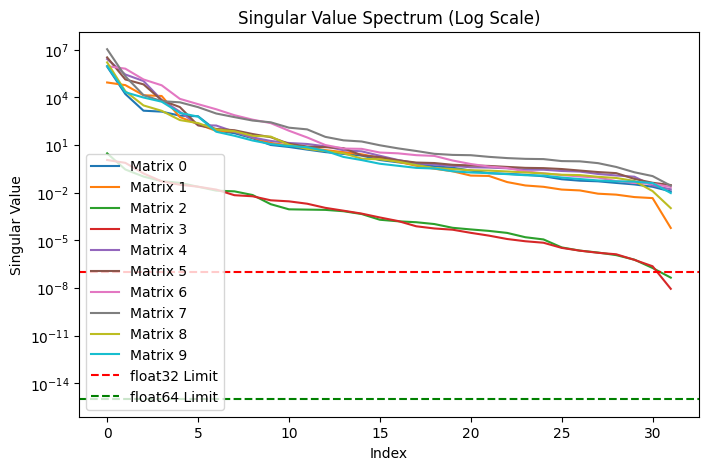

In [50]:
import matplotlib.pyplot as plt

def plot_singular_values(A):
    A_flat = A.reshape(-1, A.size(-2), A.size(-1))
    # 计算奇异值
    S = torch.linalg.svdvals(A_flat) 
    S_np = S.detach().cpu().numpy()

    plt.figure(figsize=(8, 5))
    for i in range(min(10, S_np.shape[0])): # 只画前5个矩阵示意
        plt.semilogy(S_np[i], label=f'Matrix {i}')
    
    plt.axhline(y=1e-7, color='r', linestyle='--', label='float32 Limit')
    plt.axhline(y=1e-15, color='g', linestyle='--', label='float64 Limit')
    plt.title("Singular Value Spectrum (Log Scale)")
    plt.ylabel("Singular Value")
    plt.xlabel("Index")
    plt.legend()
    plt.show()

plot_singular_values(As)